# Condition-Aware Machine Learning for Chemically Modified Short-Peptide Self-Assembly

### A single-notebook workflow for data curation, leakage-aware bulk-state prediction, and supramolecular morphology prediction

This notebook is the **final master analysis notebook for Paper 2**. The entire study is
kept in one executable notebook, but it is divided into clearly marked sections so that
the scientific story can be followed without splitting the analysis across separate files.

> **Core validation principle:** repeated experimental conditions for the same molecular
> identity are not statistically independent. Primary model evaluation therefore uses
> molecular-identity-grouped validation and permanently sealed holdouts containing
> previously unseen molecular systems.

## Notebook structure

1. **Data sources and initial dataset audit**
2. **Condition dependence and temperature-context audit**
3. **Solvent-system reconstruction**
4. **Bulk-state target curation and provenance verification**
5. **Morphology-target reconstruction**
6. **Molecular identity, feature engineering, leakage and validation design**
7. **Binary hydrogel prediction and mechanistic interpretation**
8. **Three-class bulk-state prediction**
9. **Broad supramolecular morphology prediction**
10. **Fine-grained morphology support and feasibility audit**
11. **Export of reproducibility artifacts**
12. **Final conclusions and limitations**

### Main outputs

The notebook generates seven main figures, one supplementary figure, and the principal
result tables. Figures are written automatically to `paper_outputs/figures/` as both
**300-dpi PNG** and **vector PDF** files when the notebook is run from top to bottom.

In [1]:
from pathlib import Path
import pandas as pd

# ============================================================
# REPOSITORY-AWARE DATA PATH RESOLUTION
# ============================================================
#
# The notebook may be launched with Jupyter's working directory
# set to either:
#   - the repository root,
#   - the notebooks/ folder,
#   - or a parent folder containing the repository.
#
# Locate the repository from the actual data files rather than
# assuming a fixed "../data/raw" path.

cwd = Path.cwd().resolve()

candidate_roots = []

# Current working directory and a few parents.
candidate_roots.extend([
    cwd,
    cwd.parent,
    cwd.parent.parent
])

# Immediate child folders are useful when Jupyter was launched
# from Downloads/Desktop and the repository is inside that folder.
for base in [cwd, cwd.parent]:
    try:
        candidate_roots.extend(
            p for p in base.iterdir()
            if p.is_dir()
        )
    except (PermissionError, FileNotFoundError):
        pass

# Remove duplicates while preserving order.
candidate_roots = list(dict.fromkeys(candidate_roots))

required_files = [
    Path("data/raw/peptideminer_phase_data_clean.csv"),
    Path("data/raw/sapdb_v1.csv")
]

PROJECT_ROOT = None

for root in candidate_roots:
    if all((root / relpath).exists() for relpath in required_files):
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    searched = "\n".join(
        f"  - {root}" for root in candidate_roots
    )

    raise FileNotFoundError(
        "Could not locate the repository data files.\n\n"
        "Required files:\n"
        "  data/raw/peptideminer_phase_data_clean.csv\n"
        "  data/raw/sapdb_v1.csv\n\n"
        "Recommended setup:\n"
        "  peptide-self-assembly-ml/\n"
        "    notebooks/\n"
        "      04_repository_ready_analysis.ipynb\n"
        "    data/\n"
        "      raw/\n"
        "        peptideminer_phase_data_clean.csv\n"
        "        sapdb_v1.csv\n\n"
        "Start Jupyter from the repository root, then open the "
        "notebook inside notebooks/.\n\n"
        "Locations searched:\n"
        f"{searched}"
    )

DATA_DIR = PROJECT_ROOT / "data" / "raw"

PEPTIDEMINER_FILE = (
    DATA_DIR / "peptideminer_phase_data_clean.csv"
)

SAPDB_FILE = (
    DATA_DIR / "sapdb_v1.csv"
)

print("Repository root:")
print(PROJECT_ROOT)

print("\nRaw data folder:")
print(DATA_DIR)

print(
    "\nPeptideMiner found:",
    PEPTIDEMINER_FILE.exists()
)

print(
    "SAPdb found:",
    SAPDB_FILE.exists()
)

Repository root:
C:\Users\user\OneDrive\Documents\CHEMRXIV PAPER 2\peptide-self-assembly-ml

Raw data folder:
C:\Users\user\OneDrive\Documents\CHEMRXIV PAPER 2\peptide-self-assembly-ml\data\raw

PeptideMiner found: True
SAPdb found: True


# Section 1 — Data sources and initial dataset audit

**Purpose.** Load PeptideMiner and SAPdb, verify their structures, map the encoded
self-assembly labels, inspect cross-database linkage, and establish how repeated
condition-specific rows arise from the same source systems.

In [ ]:
# ============================================================
# REPOSITORY OUTPUT DIRECTORIES
# Defined early so every figure is saved during the same Run All
# ============================================================

PROJECT_OUTPUT = PROJECT_ROOT / "paper_outputs"

DATA_DIR = PROJECT_OUTPUT / "data"
RESULTS_DIR = PROJECT_OUTPUT / "results"
MODELS_DIR = PROJECT_OUTPUT / "models"
FIGURES_DIR = PROJECT_OUTPUT / "figures"
TABLES_DIR = PROJECT_OUTPUT / "tables"

for folder in [
    DATA_DIR,
    RESULTS_DIR,
    MODELS_DIR,
    FIGURES_DIR,
    TABLES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

def save_publication_figure(fig, stem):
    """Save a figure as both 300-dpi PNG and vector PDF."""
    fig.savefig(
        FIGURES_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight"
    )
    fig.savefig(
        FIGURES_DIR / f"{stem}.pdf",
        bbox_inches="tight"
    )

print("Paper-output directory:")
print(PROJECT_OUTPUT)

In [2]:
peptideminer = pd.read_csv(PEPTIDEMINER_FILE)
sapdb = pd.read_csv(SAPDB_FILE)

print("PeptideMiner loaded successfully.")
print("SAPdb loaded successfully.")

print("\nPeptideMiner shape:", peptideminer.shape)
print("SAPdb shape:", sapdb.shape)

PeptideMiner loaded successfully.
SAPdb loaded successfully.

PeptideMiner shape: (1017, 19)
SAPdb shape: (1049, 28)


In [3]:
print("PeptideMiner columns:\n")

for i, column in enumerate(peptideminer.columns, start=1):
    print(f"{i:2}. {column}")

print("\nFirst 5 records:")
display(peptideminer.head())

PeptideMiner columns:

 1. sapdb_id
 2. sequence
 3. N-terminal
 4. C-terminal
 5. non-terminal
 6. peptide/conjugate/mixture
 7. conjugate partner
 8. solvent
 9. method
10. solution
11. volume ratio
12. concentration(mg/ml)
13. PH
14. temperature
15. heating/cooling
16. incubation period (min)
17. type of self-assembly[none, ribbon, nanosphere, organogel, tube, particle, vesicle, hydrogel, fiber]
18. size of structure
19. linear/cyclic

First 5 records:


,sapdb_id,sequence,N-terminal,C-terminal,non-terminal,peptide/conjugate/mixture,conjugate partner,solvent,method,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),"type of self-assembly[none, ribbon, nanosphere, organogel, tube, particle, vesicle, hydrogel, fiber]",size of structure,linear/cyclic
0,1002,FF,Fmoc,Free,NaN,Peptide,NaN,"Dispersion medium= PBS 1x, DMSO (gelling agent...",Lyophilized Fmoc-Phe-Phe dipeptide was weighed...,DMSO/PBS,5/95,5.025,7.0,37.0,No,NaN,0,NaN,Linear
1,1003,FF,Fmoc,Free,NaN,Peptide,NaN,"Dispersion medium= PBS 1x, DMSO (gelling agent...",Lyophilized Fmoc-Phe-Phe dipeptide was weighed...,DMSO/PBS,10/90,10.050,7.0,37.0,No,NaN,0,NaN,Linear
2,1004,FF,Fmoc,Free,NaN,Peptide,NaN,"Dispersion medium= PBS 1x, DMSO (gelling agent...",Lyophilized Fmoc-Phe-Phe dipeptide was weighed...,DMSO/PBS,20/80,5.025,7.0,37.0,No,NaN,0,NaN,Linear
3,1005,FF,Fmoc,Free,NaN,Peptide,NaN,"Dispersion medium= PBS 1x, DMSO (gelling agent...",Lyophilized Fmoc-Phe-Phe dipeptide was weighed...,DMSO/PBS,40/60,10.050,7.0,37.0,No,NaN,7,NaN,Linear
4,1007,FP,Chlorination,N-hexadecylamine,NaN,Peptide,NaN,Aqueous dispersion,The aqueous dispersions of the required amount...,H2O,100,132.000,7.0,25.0,Yes,25.0,7,NaN,Linear


In [4]:
assembly_col = (
    "type of self-assembly[none, ribbon, nanosphere, organogel, "
    "tube, particle, vesicle, hydrogel, fiber]"
)

print("Unique assembly codes:")
print(sorted(peptideminer[assembly_col].dropna().unique()))

print("\nNumber of records for each code:")
print(
    peptideminer[assembly_col]
    .value_counts(dropna=False)
    .sort_index()
)

Unique assembly codes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Number of records for each code:
type of self-assembly[none, ribbon, nanosphere, organogel, tube, particle, vesicle, hydrogel, fiber]
0    429
1     33
2     33
3      5
4    121
5     16
6     43
7    241
8     96
Name: count, dtype: int64


In [5]:
ASSEMBLY_LABELS = {
    0: "none",
    1: "ribbon",
    2: "nanosphere",
    3: "organogel",
    4: "tube",
    5: "particle",
    6: "vesicle",
    7: "hydrogel",
    8: "fiber"
}

peptideminer["assembly_label_audit"] = (
    peptideminer[assembly_col].map(ASSEMBLY_LABELS)
)

assembly_distribution = (
    peptideminer["assembly_label_audit"]
    .value_counts()
    .rename_axis("assembly_label")
    .reset_index(name="n_records")
)

assembly_distribution["percentage"] = (
    assembly_distribution["n_records"]
    / len(peptideminer)
    * 100
).round(2)

display(assembly_distribution)

,assembly_label,n_records,percentage
0,none,429,42.18
1,hydrogel,241,23.70
2,tube,121,11.90
3,fiber,96,9.44
4,vesicle,43,4.23
5,nanosphere,33,3.24
6,ribbon,33,3.24
7,particle,16,1.57
8,organogel,5,0.49


In [6]:
print("SAPdb shape:", sapdb.shape)

print("\nSAPdb columns:\n")

for i, column in enumerate(sapdb.columns, start=1):
    print(f"{i:2}. {column}")

print("\nSelected columns from the first 10 records:")

display(
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "conc",
            "pH",
            "temp",
            "Selfassembly",
            "nanostr",
            "stab",
            "nanostr_class",
            "tech",
            "smi"
        ]
    ].head(10)
)

SAPdb shape: (1049, 28)

SAPdb columns:

 1. id
 2. pmid
 3. year
 4. pepname
 5. pepseq
 6. nter
 7. cter
 8. nonter
 9. len
10. pep
11. partner
12. tech
13. solvent
14. method
15. conc
16. pH
17. temp
18. time
19. Selfassembly
20. nanostr
21. size
22. lincyc
23. comment
24. stab
25. nanostr_class
26. avg_size
27. dipep
28. smi

Selected columns from the first 10 records:


,id,pmid,pepname,pepseq,nter,cter,conc,pH,temp,Selfassembly,nanostr,stab,nanostr_class,tech,smi
0,1001,18070345,Fmoc-Phe-Phe,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,0.01%,7,37 Â°C,No,Unstable hydrogel assembly,Unstable,Hydrogel,Confocal Microscopy,N.A.
1,1002,18070345,Fmoc-Phe-Phe,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,0.01%,7,37 Â°C,No,Unstable hydrogel assembly,Unstable,Hydrogel,Confocal Microscopy,N.A.
2,1003,18070345,Fmoc-Phe-Phe,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,0.01%,7,37 Â°C,No,Partial hydrogel assembly,Partial,Hydrogel,Confocal Microscopy,N.A.
3,1004,18070345,Fmoc-Phe-Phe,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,0.01%,7,37 Â°C,No,Soft hydrogel assembly,Soft gel,Hydrogel,Confocal Microscopy,N.A.
4,1005,18070345,Fmoc-Phe-Phe,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,0.01%,7,37 Â°C,Yes,Firm hydrogel assembly,Firm gel,Hydrogel,Confocal Microscopy,N.A.
5,1006,18070345,Fmoc-Phe-Phe,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,0.01%,7,37 Â°C,No,Unstable hydrogel assembly,Unstable,Hydrogel,Confocal Microscopy,N.A.
6,1007,18052148,Compound 1,FP,Chlorination,N-hexadecylamine,Minimum gelation concentration=12% (w/v),7,Room temperature,Yes,opaque hydrogel,Stable-to-inversion of the container,Hydrogel,Field Emission Scanning Electron Microscopy (F...,N.A.
7,1008,18052148,Compound 2,PY,Chlorination,N-hexadecylamine,Minimum gelation concentration=10% (w/v),7,Room temperature,Yes,transparent hydrogel,Stable-to-inversion of the container,Hydrogel,Field Emission Scanning Electron Microscopy (F...,N.A.
8,1009,18052148,Compound 3,WP,Chlorination,N-hexadecylamine,Minimum gelation concentration=7% (w/v),7,Room temperature,Yes,opaque hydrogel,Stable-to-inversion of the container,Hydrogel,Field Emission Scanning Electron Microscopy (F...,N.A.
9,1010,18052148,Compound 4,PW,Chlorination,N-hexadecylamine,Minimum gelation concentration=3% (w/v),7,Room temperature,Yes,transparent hydrogel,Stable-to-inversion of the container,Hydrogel,Field Emission Scanning Electron Microscopy (F...,N.A.


In [7]:
outcome_columns = [
    "Selfassembly",
    "nanostr",
    "stab",
    "nanostr_class"
]

for column in outcome_columns:
    print("=" * 70)
    print(f"COLUMN: {column}")
    print("=" * 70)

    print("Missing values:", sapdb[column].isna().sum())
    print("Unique values:", sapdb[column].nunique(dropna=True))

    print("\nMost common values:")
    print(sapdb[column].value_counts(dropna=False).head(25))

    print()

COLUMN: Selfassembly
Missing values: 21
Unique values: 2

Most common values:
Selfassembly
Yes    896
No     132
NaN     21
Name: count, dtype: int64

COLUMN: nanostr
Missing values: 74
Unique values: 318

Most common values:
nanostr
NaN                                 74
Hydrogel                            62
Nanoparticles                       43
Hydrogels                           37
nanostructures                      34
Fibril structure & gel formation    33
nanoparticles                       26
Nanotube                            23
Nanofibres                          19
Transparent Gel                     18
nanofibers                          18
Transparent gel                     16
Nanotubes                           15
No gel formation                    14
Nanostructures                      14
nanofibril                          14
Fibrils                             14
Nanoparticle                        12
Organogel                           12
Spherical structure      

In [8]:
print("=" * 70)
print("STABILITY / GEL STATUS")
print("=" * 70)

print("Missing:", sapdb["stab"].isna().sum())
print("Unique:", sapdb["stab"].nunique(dropna=True))

display(
    sapdb["stab"]
    .value_counts(dropna=False)
    .rename_axis("stab")
    .reset_index(name="n_records")
)


print("\n" + "=" * 70)
print("NANOSTRUCTURE CLASS")
print("=" * 70)

print("Missing:", sapdb["nanostr_class"].isna().sum())
print("Unique:", sapdb["nanostr_class"].nunique(dropna=True))

display(
    sapdb["nanostr_class"]
    .value_counts(dropna=False)
    .rename_axis("nanostr_class")
    .reset_index(name="n_records")
)

STABILITY / GEL STATUS
Missing: 749
Unique: 75


,stab,n_records
0,NaN,749
1,Stable,132
2,Unstable,16
3,Stable for more than one month,11
4,Thermally stable,11
...,...,...
71,Mechanically less stable,1
72,Stable,1
73,More stable,1
74,Less stable,1



NANOSTRUCTURE CLASS
Missing: 124
Unique: 36


,nanostr_class,n_records
0,Hydrogel,297
1,Other,141
2,Nanofiber,127
3,NaN,124
4,Nanotube,68
5,Nanostructure,64
6,Nanosphere,50
7,Nanoparticle,47
8,Nanoribbon,24
9,Organogel,24


In [9]:
# Check whether PeptideMiner's sapdb_id maps to SAPdb's id

print("PeptideMiner rows:", len(peptideminer))
print("Unique PeptideMiner sapdb_id values:",
      peptideminer["sapdb_id"].nunique())

print("\nSAPdb rows:", len(sapdb))
print("Unique SAPdb id values:",
      sapdb["id"].nunique())


# Merge the relevant SAPdb information onto PeptideMiner
crosswalk = peptideminer.merge(
    sapdb[
        [
            "id",
            "pmid",
            "Selfassembly",
            "nanostr",
            "stab",
            "nanostr_class"
        ]
    ],
    left_on="sapdb_id",
    right_on="id",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("\nCross-dataset matching:")
print(crosswalk["_merge"].value_counts())

print("\nNumber of PeptideMiner rows whose SAPdb source was found:")
print((crosswalk["_merge"] == "both").sum())

PeptideMiner rows: 1017
Unique PeptideMiner sapdb_id values: 224

SAPdb rows: 1049
Unique SAPdb id values: 1049

Cross-dataset matching:
_merge
both          1017
left_only        0
right_only       0
Name: count, dtype: int64

Number of PeptideMiner rows whose SAPdb source was found:
1017


In [10]:
records_per_sapdb = (
    peptideminer
    .groupby("sapdb_id")
    .size()
    .sort_values(ascending=False)
    .rename("n_peptideminer_rows")
)

print("Number of unique SAPdb source records:",
      len(records_per_sapdb))

print("\nSummary of PeptideMiner rows per SAPdb record:")
display(records_per_sapdb.describe())

print("\nTop 20 SAPdb records producing the most PeptideMiner rows:")
display(records_per_sapdb.head(20).reset_index())

print(
    "\nSAPdb records represented by only one PeptideMiner row:",
    (records_per_sapdb == 1).sum()
)

print(
    "SAPdb records represented by more than one PeptideMiner row:",
    (records_per_sapdb > 1).sum()
)

print(
    "SAPdb records represented by 10 or more PeptideMiner rows:",
    (records_per_sapdb >= 10).sum()
)

Number of unique SAPdb source records: 224

Summary of PeptideMiner rows per SAPdb record:


count    224.000000
mean       4.540179
std        9.719298
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max       80.000000
Name: n_peptideminer_rows, dtype: float64


Top 20 SAPdb records producing the most PeptideMiner rows:


,sapdb_id,n_peptideminer_rows
0,1417,80
1,2018,68
2,1644,64
3,1124,44
4,1054,44
5,1055,28
6,1045,27
7,1035,24
8,1235,24
9,1052,22



SAPdb records represented by only one PeptideMiner row: 127
SAPdb records represented by more than one PeptideMiner row: 97
SAPdb records represented by 10 or more PeptideMiner rows: 19


In [11]:
example_id = 1417

example = crosswalk[
    crosswalk["sapdb_id"] == example_id
].copy()

print("Number of condition-specific records:", len(example))

print("\nSAPdb source information:")
display(
    sapdb.loc[
        sapdb["id"] == example_id,
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "nanostr",
            "nanostr_class"
        ]
    ]
)

print("\nAssembly outcomes in PeptideMiner:")
display(
    example["assembly_label_audit"]
    .value_counts()
    .rename_axis("assembly")
    .reset_index(name="n_records")
)

print("\nCondition-specific records:")
display(
    example[
        [
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "volume ratio",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "incubation period (min)",
            "assembly_label_audit"
        ]
    ].sort_values(
        by=["volume ratio", "concentration(mg/ml)"]
    )
)

Number of condition-specific records: 80

SAPdb source information:


,id,pmid,pepname,pepseq,nter,cter,nanostr,nanostr_class
416,1417,25391268,Boc-diPhenylalanine,FF,Boc (or t-butoxycarbonyl),Free,Nanotube,Nanotube



Assembly outcomes in PeptideMiner:


,assembly,n_records
0,none,40
1,tube,32
2,nanosphere,8



Condition-specific records:


,sequence,N-terminal,C-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,incubation period (min),assembly_label_audit
629,FF,Boc,Free,Ethanol/H2O,10/90,0.2,7.0,25.0,60.0,tube
630,FF,Boc,Free,Ethanol/H2O,10/90,0.5,7.0,25.0,60.0,tube
631,FF,Boc,Free,Ethanol/H2O,10/90,1.0,7.0,25.0,60.0,tube
632,FF,Boc,Free,Ethanol/H2O,10/90,2.0,7.0,25.0,60.0,tube
633,FF,Boc,Free,Ethanol/H2O,10/90,4.0,7.0,25.0,60.0,tube
...,...,...,...,...,...,...,...,...,...,...
696,FF,Boc,Free,Ethanol/H2O,90/10,2.0,7.0,25.0,60.0,none
697,FF,Boc,Free,Ethanol/H2O,90/10,4.0,7.0,25.0,60.0,none
698,FF,Boc,Free,Ethanol/H2O,90/10,6.0,7.0,25.0,60.0,none
699,FF,Boc,Free,Ethanol/H2O,90/10,8.0,7.0,25.0,60.0,none


In [12]:
# Create a numerical variable for the ethanol percentage
example["ethanol_percent"] = pd.to_numeric(
    example["volume ratio"]
    .astype(str)
    .str.split("/")
    .str[0],
    errors="coerce"
)

print("Variables that remain constant in this 80-record experiment:\n")

for column in [
    "sequence",
    "N-terminal",
    "C-terminal",
    "solution",
    "PH",
    "temperature",
    "incubation period (min)"
]:
    print(f"{column}: {example[column].dropna().unique()}")


print("\nAssembly outcome by ethanol/water ratio and concentration:\n")

condition_map = example.pivot_table(
    index="ethanol_percent",
    columns="concentration(mg/ml)",
    values="assembly_label_audit",
    aggfunc=lambda x: " / ".join(sorted(set(x)))
)

condition_map.index.name = "Ethanol (%)"
condition_map.columns.name = "Concentration (mg/mL)"

display(condition_map)

Variables that remain constant in this 80-record experiment:

sequence: <StringArray>
['FF']
Length: 1, dtype: str
N-terminal: <StringArray>
['Boc']
Length: 1, dtype: str
C-terminal: <StringArray>
['Free']
Length: 1, dtype: str
solution: <StringArray>
['Ethanol/H2O', 'Ethanol']
Length: 2, dtype: str
PH: [7.]
temperature: [25.]
incubation period (min): [60.]

Assembly outcome by ethanol/water ratio and concentration:



Concentration (mg/mL),0.2,0.5,1.0,2.0,4.0,6.0,8.0,10.0
Ethanol (%),,,,,,,,
10,tube,tube,tube,tube,tube,tube,tube,tube
20,tube,tube,tube,tube,tube,tube,tube,tube
30,nanosphere,tube,tube,tube,tube,tube,tube,tube
40,none,nanosphere,tube,tube,tube,tube,tube,tube
50,none,none,nanosphere,nanosphere,nanosphere,tube,tube,tube
60,none,none,none,none,none,nanosphere,nanosphere,nanosphere
70,none,none,none,none,none,none,none,none
80,none,none,none,none,none,none,none,none
90,none,none,none,none,none,none,none,none


In [13]:
system_variability = (
    peptideminer
    .groupby("sapdb_id")
    .agg(
        n_records=("assembly_label_audit", "size"),
        n_outcomes=("assembly_label_audit", "nunique"),
        n_concentrations=("concentration(mg/ml)", "nunique"),
        n_pH=("PH", "nunique"),
        n_temperatures=("temperature", "nunique"),
        n_volume_ratios=("volume ratio", "nunique"),
        n_solutions=("solution", "nunique")
    )
    .reset_index()
)

multi_condition = system_variability[
    system_variability["n_records"] > 1
]

variable_outcome = system_variability[
    system_variability["n_outcomes"] > 1
]

print("Total SAPdb source systems:", len(system_variability))

print(
    "Systems represented by multiple PeptideMiner records:",
    len(multi_condition)
)

print(
    "Systems showing more than one assembly outcome:",
    len(variable_outcome)
)

print(
    "\nPercentage of all source systems with multiple outcomes:"
)

print(
    round(
        len(variable_outcome)
        / len(system_variability)
        * 100,
        2
    ),
    "%"
)

print(
    "\nAmong systems with multiple condition records,"
    " percentage showing multiple outcomes:"
)

print(
    round(
        len(variable_outcome)
        / len(multi_condition)
        * 100,
        2
    ),
    "%"
)

print("\nSystems with the greatest outcome diversity:")

display(
    variable_outcome
    .sort_values(
        ["n_outcomes", "n_records"],
        ascending=False
    )
    .head(20)
)

Total SAPdb source systems: 224
Systems represented by multiple PeptideMiner records: 97
Systems showing more than one assembly outcome: 55

Percentage of all source systems with multiple outcomes:
24.55 %

Among systems with multiple condition records, percentage showing multiple outcomes:
56.7 %

Systems with the greatest outcome diversity:


,sapdb_id,n_records,n_outcomes,n_concentrations,n_pH,n_temperatures,n_volume_ratios,n_solutions
151,1417,80,3,8,1,1,10,2
184,1644,64,3,1,30,1,10,16
223,2018,68,2,59,1,17,1,1
40,1054,44,2,1,1,1,1,9
72,1124,44,2,42,1,11,1,1
41,1055,28,2,2,1,1,1,10
31,1045,27,2,1,1,1,1,9
21,1035,24,2,1,1,1,1,9
38,1052,22,2,1,1,1,1,8
96,1194,22,2,11,8,1,9,1


# Section 2 — Condition dependence and temperature-context audit

**Purpose.** Demonstrate that self-assembly is condition dependent and determine how
temperature, concentration, incubation, and thermal-processing descriptions should be
interpreted before they are used as predictive variables.

Detailed source-level checks are retained for reproducibility. Long audit outputs are
collapsed by default where possible; the interpretation is summarized in Markdown.

## Condition-dependent assembly outcomes

To determine whether experimental conditions are genuinely relevant to the
prediction problem, PeptideMiner records were grouped according to their
source `sapdb_id`.

The dataset contains **224 unique SAPdb source systems**, of which **97**
are represented by more than one condition-specific PeptideMiner record.

Among these 97 repeatedly measured systems, **55 systems exhibit more than
one reported assembly outcome**.

Therefore:

- **24.55%** of all 224 source systems show multiple assembly outcomes.
- **56.70%** of systems measured under multiple conditions show more than
  one assembly outcome.

This observation supports the use of a **condition-aware modelling strategy**.
For many repeatedly characterized peptide systems, a single peptide/source
identity cannot be assigned one universal assembly label.

Instead, the observed assembly state is better represented conceptually as:

$$
Y = f(\text{peptide chemistry},\text{experimental conditions})
$$

rather than:

$$
Y = f(\text{peptide identity only})
$$

### Example: Boc-FF

SAPdb ID 1417 corresponds to Boc-diphenylalanine (Boc-FF). PeptideMiner
contains 80 condition-specific records for this system.

With peptide sequence, N-terminal modification, pH, temperature, and
incubation time held constant, variation in concentration and ethanol/water
composition is associated with three different reported outcomes:

- nanotube
- nanosphere
- no assembly

The empirical assembly-condition map shows a transition from predominantly
nanotubular structures under water-rich conditions, through concentration-
dependent nanosphere formation at intermediate ethanol fractions, to no
reported assembly under highly ethanol-rich conditions.

This provides a clear example of why solvent composition and concentration
must be represented explicitly in the predictive model.

### Important limitation

These results demonstrate **condition-associated variation**, not causation.
Multiple experimental variables may change simultaneously within a source
system, and `sapdb_id` represents a source database record rather than
necessarily a unique molecular identity.

The percentages reported here are therefore exploratory and will be
recalculated after final data cleaning, chemical-identity standardization,
and exclusion criteria are established.

In [14]:
variable_systems = system_variability[
    system_variability["n_outcomes"] > 1
].copy()

condition_variation_summary = pd.DataFrame({
    "condition": [
        "concentration",
        "pH",
        "temperature",
        "volume ratio",
        "solution"
    ],

    "systems_where_variable": [
        (variable_systems["n_concentrations"] > 1).sum(),
        (variable_systems["n_pH"] > 1).sum(),
        (variable_systems["n_temperatures"] > 1).sum(),
        (variable_systems["n_volume_ratios"] > 1).sum(),
        (variable_systems["n_solutions"] > 1).sum()
    ]
})

condition_variation_summary["percentage_of_55"] = (
    condition_variation_summary["systems_where_variable"]
    / len(variable_systems)
    * 100
).round(2)

display(condition_variation_summary)

,condition,systems_where_variable,percentage_of_55
0,concentration,24,43.64
1,pH,12,21.82
2,temperature,5,9.09
3,volume ratio,6,10.91
4,solution,19,34.55


### Condition Dimensions Associated with Outcome Variation

Among the 55 SAPdb source systems that exhibit more than one assembly outcome,
variation was observed most frequently in peptide concentration and solution
identity.

- Concentration varied in 24 systems (43.64%).
- Solution identity varied in 19 systems (34.55%).
- pH varied in 12 systems (21.82%).
- Solvent volume ratio varied in 6 systems (10.91%).
- Temperature varied in 5 systems (9.09%).

These categories are not mutually exclusive. A single source system may vary
multiple experimental conditions simultaneously and can therefore contribute
to more than one category.

These results should not be interpreted causally. They indicate which
experimental dimensions co-vary with assembly outcomes in the current dataset,
but they do not establish that any individual variable caused the observed
transition.

Before modelling, the condition variables must therefore be audited for
missingness, inconsistent units, formatting differences, and chemically
equivalent values represented using different text labels.

In [15]:
condition_columns = [
    "solution",
    "volume ratio",
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "heating/cooling",
    "incubation period (min)"
]

condition_audit = []

for column in condition_columns:
    condition_audit.append({
        "variable": column,
        "dtype": str(peptideminer[column].dtype),
        "missing": peptideminer[column].isna().sum(),
        "missing_percent": round(
            peptideminer[column].isna().mean() * 100, 2
        ),
        "unique_values": peptideminer[column].nunique(dropna=True)
    })

condition_audit = pd.DataFrame(condition_audit)

display(condition_audit)

,variable,dtype,missing,missing_percent,unique_values
0,solution,str,0,0.00,33
1,volume ratio,str,0,0.00,18
2,concentration(mg/ml),float64,0,0.00,232
3,PH,float64,0,0.00,90
4,temperature,float64,0,0.00,42
5,heating/cooling,str,0,0.00,2
6,incubation period (min),float64,248,24.39,23


### Audit of Experimental-Condition Completeness

The main PeptideMiner condition variables are relatively complete in the
processed dataset.

Concentration, pH, temperature, solution identity, solvent volume ratio,
and heating/cooling status contain no missing values in the current table.

Incubation time is less complete, with 248 missing records (24.39%).

However, the absence of missing values in the processed PeptideMiner dataset
does not necessarily imply that every condition was explicitly reported in
the original publications. Because this is a cleaned dataset, some values may
have been standardized, calculated, inferred, or assigned during curation.

Therefore, condition completeness and condition provenance must be treated
as separate questions.

Before modelling, numerical conditions will be checked for physically
implausible values, unusual ranges, repeated defaults, and possible evidence
of imputation. Categorical solvent variables will also be standardized into
chemically meaningful representations.

In [16]:
numeric_conditions = [
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "incubation period (min)"
]

numeric_summary = peptideminer[numeric_conditions].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
concentration(mg/ml),1017.0,30.881591,40.763386,0.005,0.2000,0.5186,2.443,7.59,52.0,100.0,100.0,144.0
PH,1017.0,6.993707,1.386692,3.000,3.1128,4.4800,7.000,7.00,7.2,10.2,11.0,12.0
temperature,1017.0,26.575221,15.452811,-80.000,4.0000,16.0000,20.000,25.00,25.0,54.4,70.0,200.0
incubation period (min),769.0,1115.715995,2209.532227,0.100,0.5000,3.0000,60.000,1440.00,1440.0,1440.0,20160.0,20160.0


### Numerical Condition Range Audit

The numerical condition variables show generally plausible experimental
ranges, but several values require source-level investigation before modelling.

Peptide concentration ranges from 0.005 to 144 mg/mL, while pH ranges from
3.0 to 12.0. These ranges are chemically plausible and will be retained
pending detailed inspection of extreme observations.

Temperature requires particular attention. The processed dataset contains
values ranging from -80 °C to 200 °C. Such temperatures may represent
special experimental treatments, storage conditions, extraction artefacts,
or other non-standard conditions rather than ordinary self-assembly
temperatures.

Incubation time ranges from 0.1 min to 20,160 min (14 days). A strong
concentration of observations around 1,440 min (24 h) is also apparent.
This may reflect a commonly used experimental protocol, but possible
standardization or imputation must be investigated.

No extreme value will be removed solely because it is unusual. Suspicious
records will first be traced to their source system and experimental context.

In [17]:
print("=" * 70)
print("TEMPERATURE FREQUENCIES")
print("=" * 70)

display(
    peptideminer["temperature"]
    .value_counts()
    .sort_index()
    .rename_axis("temperature_C")
    .reset_index(name="n_records")
)


print("\n" + "=" * 70)
print("EXTREME TEMPERATURE RECORDS")
print("=" * 70)

extreme_temperature = peptideminer[
    (peptideminer["temperature"] < 0) |
    (peptideminer["temperature"] > 80)
]

display(
    extreme_temperature[
        [
            "sapdb_id",
            "sequence",
            "N-terminal",
            "solution",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit"
        ]
    ].sort_values("temperature")
)


print("\n" + "=" * 70)
print("MOST COMMON INCUBATION TIMES")
print("=" * 70)

display(
    peptideminer["incubation period (min)"]
    .value_counts(dropna=False)
    .head(15)
    .rename_axis("incubation_min")
    .reset_index(name="n_records")
)

TEMPERATURE FREQUENCIES


,temperature_C,n_records
0,-80.0,1
1,-20.0,1
2,4.0,38
3,8.0,4
4,10.0,1
5,12.0,4
6,16.0,4
7,20.0,248
8,24.0,4
9,25.0,577



EXTREME TEMPERATURE RECORDS


,sapdb_id,sequence,N-terminal,solution,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
463,1217,FF,Free,H2O,0.625,7.0,-80.0,No,NaN,fiber
462,1217,FF,Free,H2O,0.625,7.0,-20.0,No,NaN,fiber
35,1015,FF,Free,HFP/H2O,2.000,5.2,90.0,No,5.0,tube
46,1019,FF,Free,HFP/H2O,1.000,5.5,100.0,No,NaN,tube
47,1019,FF,Free,HFP/H2O,1.000,5.5,150.0,No,NaN,none
779,1635,FF,Free,HFP/H2O,2.000,5.2,180.0,No,180.0,fiber
781,1637,LL,Free,HFP/H2O,2.000,5.2,180.0,No,90.0,fiber
48,1019,FF,Free,HFP/H2O,1.000,5.5,200.0,No,NaN,none



MOST COMMON INCUBATION TIMES


,incubation_min,n_records
0,1440.0,392
1,NaN,248
2,60.0,80
3,720.0,64
4,10.0,52
5,30.0,33
6,0.5,27
7,25.0,24
8,3.0,16
9,5.0,15


### Investigation of Temperature and Incubation-Time Extremes

Most PeptideMiner records are concentrated around conventional experimental
temperatures, particularly 20 °C and 25 °C. However, a small number of records
contain extreme temperatures ranging from -80 °C to 200 °C.

These values will not be removed automatically. Some may describe thermal
treatments, freezing/storage conditions, stability experiments, or other
protocol steps rather than the temperature at which self-assembly originally
occurred.

This distinction is important because experimental treatment variables should
not be interpreted as ordinary equilibrium assembly conditions without
verification.

Incubation time also shows a strong peak at 1,440 min (24 h), accounting for
392 records and approximately half of all records with a reported incubation
time. This may reflect a commonly used experimental protocol, although its
provenance should be checked before assuming that every 24 h value was
explicitly reported.

The next step is therefore to trace unusual temperature records back to their
SAPdb metadata and source context.

In [18]:
extreme_ids = (
    extreme_temperature["sapdb_id"]
    .dropna()
    .unique()
)

extreme_source_audit = sapdb[
    sapdb["id"].isin(extreme_ids)
][
    [
        "id",
        "pmid",
        "pepname",
        "pepseq",
        "nter",
        "cter",
        "method",
        "temp",
        "Selfassembly",
        "nanostr",
        "stab",
        "nanostr_class",
        "tech",
        "comment"
    ]
].sort_values("id")

display(extreme_source_audit)

,id,pmid,pepname,pepseq,nter,cter,method,temp,Selfassembly,nanostr,stab,nanostr_class,tech,comment
14,1015,16430299,DiPhenylalanine peptide,FF,Free,Free,Lyophilized form of the peptides dissolved in ...,Stable upto 90 Â°C,Yes,Nanotube,"In addition to thermal stability, the peptide ...",Nanotube,"Scanning Electron Microscopy (SEM), Transmissi...",NaN
18,1019,16719470,DiPhenylalanine peptide,FF,Free,Free,Fresh stock solutions were prepared by dissolv...,Stable upto 100 Â°C,Yes,Nanotube,The nanotubes are stable at temperatures up to...,Nanotube,AFM (Atomic Force Microscopy),NaN
216,1217,25621167,DiPhenylalanine,FF,Free,Free,Fresh stock solutions of Phe were prepared by ...,(-)20 Â°C,Yes,Nanofiber,NaN,Nanofiber,FE - SEM (Field Emission Scanning Electron Mic...,NaN
634,1635,24895323,DiPhenylalanine,FF,Free,Free,FF-peptide nanotubes (PNT) were prepared by d...,180 Â°C,Yes,Needle like wire -Nanofibril structure,NaN,"Nanofiber, Nanowire",ESEM (Environmental Scanning Electron Microscope),Temperature induced
636,1637,24895323,Dileucine,LL,Free,Free,FF-peptide nanotubes (PNT) were prepared by d...,180 Â°C,Yes,Needle like wire -Nanofibril structure,NaN,"Nanofiber, Nanowire",ESEM (Environmental Scanning Electron Microscope),Temperature induced


### Source-Level Interpretation of Extreme Temperatures

Source-level inspection indicates that the extreme temperatures in PeptideMiner
are not necessarily erroneous values. However, the meaning of the temperature
variable is not uniform across all records.

Several SAPdb records describe temperature in the context of thermal stability,
temperature-induced structural changes, or low-temperature treatment rather
than simply the temperature at which peptide self-assembly was initiated.

For example, source records describing diphenylalanine nanotubes report thermal
stability up to approximately 90-100 °C, while PeptideMiner contains
condition-specific observations extending to higher temperatures where the
nanotube structure is no longer reported.

Other source records explicitly describe their structures as
"temperature induced", including experiments at 180 °C.

Therefore, the current `temperature` variable may combine several distinct
experimental concepts:

- assembly/incubation temperature,
- thermal-treatment temperature,
- thermal-stability/challenge temperature,
- freezing or low-temperature treatment.

These concepts should not automatically be treated as equivalent predictors.

Before final modelling, temperature provenance and experimental context should
therefore be reconstructed where possible. Extreme temperatures will be
retained during auditing rather than removed solely because of their magnitude.

In [19]:
pd.set_option("display.max_colwidth", None)

for source_id in sorted(extreme_ids):

    print("\n" + "=" * 90)
    print(f"SAPdb ID: {source_id}")
    print("=" * 90)

    source = sapdb.loc[sapdb["id"] == source_id].iloc[0]

    print("Peptide name:")
    print(source["pepname"])

    print("\nSequence:")
    print(source["pepseq"])

    print("\nMethod:")
    print(source["method"])

    print("\nSAPdb temperature description:")
    print(source["temp"])

    print("\nNanostructure:")
    print(source["nanostr"])

    print("\nStability:")
    print(source["stab"])

    print("\nComment:")
    print(source["comment"])

    print("\nPeptideMiner temperature/outcome records:")

    display(
        peptideminer.loc[
            peptideminer["sapdb_id"] == source_id,
            [
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "heating/cooling",
                "incubation period (min)",
                "assembly_label_audit"
            ]
        ].sort_values("temperature")
    )


SAPdb ID: 1015
Peptide name:
DiPhenylalanine peptide

Sequence:
FF

Method:
Lyophilized form of the peptides dissolved in 1,1,1,3,3,3-hexafluoro-2-propanol at a concentration of 100 mg/mL. Peptide stock solution was diluted in double distilled (dd) H2O to a final concentration of 2 mg/mL incubated in a water bath at 80 Â¬âˆžC for 1 h.

SAPdb temperature description:
Stable upto 90 Â°C

Nanostructure:
Nanotube

Stability:
In addition to thermal stability, the peptide nanotubes were chemically stable in organic solvents

Comment:
nan

PeptideMiner temperature/outcome records:


,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
30,HFP/H2O,2/98,2.0,5.2,25.0,No,5.0,tube
31,HFP/H2O,2/98,2.0,5.2,37.0,No,5.0,tube
32,HFP/H2O,2/98,2.0,5.2,60.0,No,5.0,tube
33,HFP/H2O,2/98,2.0,5.2,70.0,No,5.0,tube
34,HFP/H2O,2/98,2.0,5.2,80.0,No,5.0,tube
35,HFP/H2O,2/98,2.0,5.2,90.0,No,5.0,tube



SAPdb ID: 1019
Peptide name:
DiPhenylalanine peptide

Sequence:
FF

Method:
Fresh stock solutions were prepared by dissolving the lyophilized peptides in 1,1,1,3,3,3-hexafluoro-2-propanol (Sigma Aldrich) at a concentration of 100 mg/mL. Peptide stock solution was diluted in double distilled (dd) H2O to a final concentration of 2 mg/mL. Samples were diluted in Elgar water to a final concentration of 0.2 or 1 mg/mL prior to dropping a 10 âˆšâ‰ L aliquot onto freshly cleaved mica and were subsequently dried in a vacuum generator.

SAPdb temperature description:
Stable upto 100 Â°C

Nanostructure:
Nanotube

Stability:
The nanotubes are stable at temperatures up to 100Â¬âˆžC, but on heating to higher temperatures begin to lose their structural integrity with an apparent collapse in tubular structure.

Comment:
nan

PeptideMiner temperature/outcome records:


,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
44,HFP/H2O,1/99,1.0,5.5,25.0,No,NaN,tube
45,HFP/H2O,1/99,1.0,5.5,50.0,No,NaN,tube
46,HFP/H2O,1/99,1.0,5.5,100.0,No,NaN,tube
47,HFP/H2O,1/99,1.0,5.5,150.0,No,NaN,none
48,HFP/H2O,1/99,1.0,5.5,200.0,No,NaN,none



SAPdb ID: 1217
Peptide name:
DiPhenylalanine

Sequence:
FF

Method:
Fresh stock solutions of Phe were prepared by dissolving Phe in distilled water at concentrations of 10, 25, 50, 100, and 150 mM. Fibril structure formed by following two techniques:  (1)Conventional drop-casting: 3 mL of  Pheâ€šÃ„Ã¬Phe solution was dropped on a clean stainless steel substrate and allowed to dry at 25Â¬âˆžC in a vacuum for 12 h prior to subsequent characterization; (2) Directional freeze-drying: 1.5 mL of Pheâ€šÃ„Ã¬Phe solution was pipetted into a 2 mL centrifuge tube. The tube was placed into liquid nitrogen or a  20Â¬âˆžC or 80Â¬âˆžC freezer

SAPdb temperature description:
(-)20  Â°C

Nanostructure:
Nanofiber

Stability:
nan

Comment:
nan

PeptideMiner temperature/outcome records:


,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
463,H2O,100,0.625,7.0,-80.0,No,NaN,fiber
462,H2O,100,0.625,7.0,-20.0,No,NaN,fiber



SAPdb ID: 1635
Peptide name:
DiPhenylalanine

Sequence:
FF

Method:
FF-peptide nanotubes (PNT)  were prepared by dissolving the L-diphenylalanine peptide in 1,1,1,3,3,3-hexafluoro-2-propanol an initial concentration of 100mg/ml further diluted in deionized water. Drops of the above solutions at a final concentrationof 2mg/ml were placed onto clean silicon substrates and dried at room temperature. The thermally induced PNT samples were heated in an oven for 180 min at 180 Â¬âˆžC.

SAPdb temperature description:
180  Â°C 

Nanostructure:
Needle like wire -Nanofibril structure

Stability:
nan

Comment:
Temperature induced

PeptideMiner temperature/outcome records:


,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
779,HFP/H2O,2/98,2.0,5.2,180.0,No,180.0,fiber



SAPdb ID: 1637
Peptide name:
Dileucine

Sequence:
LL

Method:
FF-peptide nanotubes (PNT)  were prepared by dissolving the L-diphenylalanine peptide in 1,1,1,3,3,3-hexafluoro-2-propanol an initial concentration of 100mg/ml further diluted in deionized water. Drops of the above solutions at a final concentrationof 2mg/ml were placed onto clean silicon substrates and dried at room temperature.The thermally induced LL PNT samples were heated in an oven for 90min at 180 Â¬âˆžC.

SAPdb temperature description:
180  Â°C 

Nanostructure:
Needle like wire -Nanofibril structure

Stability:
nan

Comment:
Temperature induced

PeptideMiner temperature/outcome records:


,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
781,HFP/H2O,2/98,2.0,5.2,180.0,No,90.0,fiber


### Temperature Is a Semantically Heterogeneous Variable

Detailed source-level inspection confirms that the numerical `temperature`
column does not represent one uniform experimental concept.

Several distinct temperature contexts are present:

1. **Assembly or incubation temperature** — the temperature at which the
   peptide solution is allowed to assemble.

2. **Thermal-stability or challenge temperature** — an already assembled
   structure is exposed to increasing temperature to determine whether the
   morphology remains stable.

3. **Freezing or processing temperature** — temperature is used as part of
   sample preparation, such as directional freeze-drying at -20 or -80 °C.

4. **Thermally induced assembly or restructuring** — elevated temperature is
   intentionally applied to induce or modify the supramolecular structure.

For example, diphenylalanine nanotubes associated with SAPdb ID 1015 remain
reported as nanotubes across a thermal-stability series up to 90 °C, whereas
SAPdb ID 1217 contains negative-temperature conditions associated with
directional freeze-drying.

SAPdb IDs 1635 and 1637 explicitly describe their structures as
temperature-induced following treatment at 180 °C.

Therefore, raw numerical temperature should not automatically be interpreted
as a single interchangeable predictor. Temperature magnitude and temperature
context may need to be represented separately in the curated Paper 2 dataset.

This finding also demonstrates why source-level chemical and experimental
auditing is necessary before machine-learning feature construction.

In [20]:
# SAPdb records actually used by PeptideMiner
used_sapdb_ids = peptideminer["sapdb_id"].unique()

temperature_sources = sapdb[
    sapdb["id"].isin(used_sapdb_ids)
][
    [
        "id",
        "pmid",
        "pepname",
        "temp",
        "method",
        "comment"
    ]
].copy()

print("SAPdb source records used by PeptideMiner:",
      len(temperature_sources))

print("\nMissing SAPdb temperature descriptions:",
      temperature_sources["temp"].isna().sum())

print("\nUnique SAPdb temperature descriptions:",
      temperature_sources["temp"].nunique(dropna=True))

print("\nMost common temperature descriptions:")

display(
    temperature_sources["temp"]
    .value_counts(dropna=False)
    .head(30)
    .rename_axis("SAPdb_temperature_description")
    .reset_index(name="n_source_records")
)

SAPdb source records used by PeptideMiner: 224

Missing SAPdb temperature descriptions: 28

Unique SAPdb temperature descriptions: 22

Most common temperature descriptions:


,SAPdb_temperature_description,n_source_records
0,Room temperature,118
1,20 Â°C,30
2,NaN,28
3,60 Â°C,6
4,37 Â°C,5
5,70Â°C,5
6,"Heating at 80 â„ƒ, cooling at RT",4
7,Intial boiling to 75 -80 Â°C heating for 2 minutes and followed by cooling at 4 Â°C,4
8,20 Â°C-70 Â°C,3
9,4 Â°C,3


### Dataset-Wide Audit of Temperature Descriptions

Among the 224 SAPdb source records represented in PeptideMiner, 28 have no
temperature description in SAPdb and 22 distinct non-missing textual
descriptions are present.

Most source systems use conventional experimental temperatures. Room
temperature is the dominant description, followed by 20 °C. However, a
smaller subset contains explicitly different thermal contexts, including
heating/cooling protocols, boiling followed by cooling, thermal-stability
limits, sonication temperatures, freezing conditions, and temperature ranges.

The temperature descriptions also contain formatting and encoding
inconsistencies. Chemically equivalent temperatures such as 37 °C or 80 °C
appear in more than one textual form, indicating that raw string uniqueness
does not necessarily correspond to distinct experimental conditions.

These findings suggest that temperature curation should involve two separate
steps:

1. standardization of the numerical temperature representation; and
2. preservation of the experimental context in which temperature was used.

The original SAPdb and PeptideMiner temperature fields will remain unchanged
during the audit. Any normalized variables will be created as additional
derived columns.

In [21]:
temperature_sources["temp_description_normalized"] = (
    temperature_sources["temp"]
    .astype("string")
    .str.replace("Â", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(
    "Unique descriptions before normalization:",
    temperature_sources["temp"].nunique(dropna=True)
)

print(
    "Unique descriptions after basic normalization:",
    temperature_sources["temp_description_normalized"].nunique(dropna=True)
)

print("\nNormalized temperature descriptions:")

display(
    temperature_sources["temp_description_normalized"]
    .value_counts(dropna=False)
    .rename_axis("normalized_temperature_description")
    .reset_index(name="n_source_records")
)

Unique descriptions before normalization: 22
Unique descriptions after basic normalization: 19

Normalized temperature descriptions:


,normalized_temperature_description,n_source_records
0,Room temperature,118
1,20 °C,30
2,<NA>,28
3,37 °C,8
4,60 °C,6
5,70°C,5
6,80 °C,4
7,"Heating at 80 â„ƒ, cooling at RT",4
8,Intial boiling to 75 -80 °C heating for 2 minutes and followed by cooling at 4 °C,4
9,20 °C-70 °C,3


### Normalization of Temperature Descriptions

Basic text normalization reduced the number of distinct SAPdb temperature
descriptions from 22 to 19.

This demonstrates that part of the apparent temperature diversity resulted
from character-encoding and formatting differences rather than chemically
distinct experimental conditions.

However, the remaining descriptions are semantically heterogeneous.

Some records contain simple temperature values or descriptions such as
`Room temperature`, `20 °C`, or `37 °C`, whereas others explicitly describe
experimental procedures, including heating/cooling cycles, thermal-stability
tests, sonication temperatures, freezing conditions, and temperature ranges.

Importantly, even a simple numerical description cannot always be interpreted
from the temperature field alone. For example, source-level inspection showed
that some 180 °C records represent temperature-induced treatment rather than
ordinary peptide incubation.

Therefore, temperature curation requires both:

1. numerical/text standardization; and
2. source-context interpretation using the associated experimental method
   and comments.

No final temperature-context labels will be assigned solely from numerical
magnitude.

In [22]:
temperature_review = (
    temperature_sources[
        [
            "id",
            "pmid",
            "pepname",
            "temp_description_normalized",
            "method",
            "comment"
        ]
    ]
    .copy()
)

temperature_review["temperature_text_lower"] = (
    temperature_review["temp_description_normalized"]
    .str.lower()
)

context_keywords = (
    "stable|stability|heating|cooling|boiling|"
    "sonication|induced|freez|range|upto|up to"
)

temperature_review["explicit_context_in_temp_text"] = (
    temperature_review["temperature_text_lower"]
    .str.contains(
        context_keywords,
        regex=True,
        na=False
    )
)

temperature_description_review = (
    temperature_review
    .groupby(
        [
            "temp_description_normalized",
            "explicit_context_in_temp_text"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="n_source_records")
    .sort_values(
        ["explicit_context_in_temp_text", "n_source_records"],
        ascending=[False, False]
    )
)

display(temperature_description_review)

,temp_description_normalized,explicit_context_in_temp_text,n_source_records
14,"Heating at 80 â„ƒ, cooling at RT",True,4
15,Intial boiling to 75 -80 °C heating for 2 minutes and followed by cooling at 4 °C,True,4
8,50 °C for sonication,True,1
17,Stable upto 100 °C,True,1
18,Stable upto 90 °C,True,1
16,Room temperature,False,118
2,20 °C,False,30
19,<NA>,False,28
6,37 °C,False,8
9,60 °C,False,6


### Screening for Explicit Temperature Context

Temperature descriptions were screened for words indicating that temperature
was used as part of a specific experimental procedure rather than simply
reported as a numerical condition.

Descriptions involving heating/cooling cycles, boiling, sonication, or
thermal-stability testing were identified directly from the temperature text.

However, this screening is intentionally conservative and is not a final
classification. Some simple numerical temperature descriptions may still
represent special experimental treatments when the associated method or
comments are examined.

For example, the previously inspected 180 °C records appear numerically simple
in the SAPdb temperature field but are explicitly described as
temperature-induced in their experimental context.

A minor text-normalization inconsistency was also detected: the
`Stable upto 90 °C` entry was not captured by the first keyword screen despite
being semantically equivalent to the corresponding 100 °C stability
description. This will be corrected before using automated context flags.

Therefore, temperature-context classification will use the combined
temperature description, experimental method, and source comments rather than
the temperature field alone.

In [23]:
# Combine temperature description, experimental method, and comments
# into one searchable audit string.

temperature_review["combined_context"] = (
    temperature_review["temp_description_normalized"].fillna("")
    + " "
    + temperature_review["method"].astype("string").fillna("")
    + " "
    + temperature_review["comment"].astype("string").fillna("")
)

# Normalize the combined text
temperature_review["combined_context_normalized"] = (
    temperature_review["combined_context"]
    .str.replace("Â", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

context_keywords_full = (
    r"stable|stability|"
    r"heat|heating|heated|"
    r"cool|cooling|cooled|"
    r"boil|boiling|"
    r"sonicat|"
    r"freez|frozen|"
    r"liquid nitrogen|"
    r"temperature induced|"
    r"oven"
)

temperature_review["context_review_required"] = (
    temperature_review["combined_context_normalized"]
    .str.contains(
        context_keywords_full,
        regex=True,
        na=False
    )
)

print("Source systems requiring temperature-context review:")
print(temperature_review["context_review_required"].value_counts())

print("\nPercentage requiring review:")

print(
    round(
        temperature_review["context_review_required"].mean() * 100,
        2
    ),
    "%"
)

print("\nTemperature descriptions among flagged systems:")

display(
    temperature_review.loc[
        temperature_review["context_review_required"],
        [
            "id",
            "pepname",
            "temp_description_normalized",
            "comment"
        ]
    ].sort_values(
        "temp_description_normalized"
    )
)

Source systems requiring temperature-context review:
context_review_required
False    145
True      79
Name: count, dtype: Int64

Percentage requiring review:
35.27 %

Temperature descriptions among flagged systems:


,id,pepname,temp_description_normalized,comment
216,1217,DiPhenylalanine,(-)20 °C,NaN
636,1637,Dileucine,180 °C,Temperature induced
634,1635,DiPhenylalanine,180 °C,Temperature induced
79,1080,KFG,20 °C-70 °C,NaN
78,1079,KFG,20 °C-70 °C,NaN
...,...,...,...,...
14,1015,DiPhenylalanine peptide,Stable upto 90 °C,NaN
69,1070,FFK,<NA>,NaN
70,1071,FYK,<NA>,NaN
71,1072,YFK,<NA>,NaN


### Broad Screening for Temperature-Context Review

A combined search of the SAPdb temperature description, experimental method,
and comments flagged 79 of the 224 source systems (35.27%) for possible
temperature-context review.

This percentage does not indicate that 35.27% of the temperature data are
incorrect. The screen was intentionally designed to be sensitive rather than
specific. A source was flagged whenever its experimental description contained
terms associated with heating, cooling, freezing, sonication, thermal
stability, temperature-induced processing, or related procedures.

Some flagged records may therefore represent ordinary assembly experiments
whose preparation methods happen to include a heating or cooling step.

Conversely, several flagged systems have no explicit SAPdb temperature
description but contain temperature-related information in the experimental
method. This confirms that temperature meaning cannot be reconstructed from
the `temp` field alone.

The next step is to determine why each source was flagged and quantify how
much of the PeptideMiner dataset is associated with these review candidates.

In [24]:
# Create separate evidence flags.
# These are audit indicators, NOT final temperature-context labels.

text = temperature_review["combined_context_normalized"]

temperature_review["evidence_stability"] = text.str.contains(
    r"\bstable\b|\bstability\b|stable up|upto",
    regex=True,
    na=False
)

temperature_review["evidence_heating"] = text.str.contains(
    r"\bheat\b|\bheated\b|\bheating\b|\bboil|\boven\b",
    regex=True,
    na=False
)

temperature_review["evidence_cooling_freezing"] = text.str.contains(
    r"\bcool|\bfreez|\bfrozen\b|liquid nitrogen",
    regex=True,
    na=False
)

temperature_review["evidence_sonication"] = text.str.contains(
    r"sonicat",
    regex=True,
    na=False
)

temperature_review["evidence_temperature_induced"] = text.str.contains(
    r"temperature induced",
    regex=True,
    na=False
)

evidence_columns = [
    "evidence_stability",
    "evidence_heating",
    "evidence_cooling_freezing",
    "evidence_sonication",
    "evidence_temperature_induced"
]

evidence_summary = pd.DataFrame({
    "evidence_type": [
        "thermal stability",
        "heating / boiling / oven",
        "cooling / freezing",
        "sonication",
        "explicit temperature-induced process"
    ],
    "n_source_systems": [
        temperature_review[col].sum()
        for col in evidence_columns
    ]
})

evidence_summary["percentage_of_224"] = (
    evidence_summary["n_source_systems"]
    / len(temperature_review)
    * 100
).round(2)

display(evidence_summary)


# How many PeptideMiner rows are linked to flagged source systems?
flagged_ids = temperature_review.loc[
    temperature_review["context_review_required"],
    "id"
]

n_flagged_rows = peptideminer[
    peptideminer["sapdb_id"].isin(flagged_ids)
].shape[0]

print(
    "\nPeptideMiner rows linked to flagged source systems:",
    n_flagged_rows
)

print(
    "Percentage of all 1,017 PeptideMiner rows:",
    round(n_flagged_rows / len(peptideminer) * 100, 2),
    "%"
)

,evidence_type,n_source_systems,percentage_of_224
0,thermal stability,2,0.89
1,heating / boiling / oven,42,18.75
2,cooling / freezing,28,12.50
3,sonication,40,17.86
4,explicit temperature-induced process,2,0.89



PeptideMiner rows linked to flagged source systems: 242
Percentage of all 1,017 PeptideMiner rows: 23.8 %


### Extent of Temperature-Context Ambiguity

The broad source-context screen identified 79 of the 224 SAPdb source systems
as requiring possible temperature-context review.

These systems account for 242 of the 1,017 PeptideMiner condition-specific
records (23.80%).

Heating, boiling, or oven-related language was found in 42 source systems,
while sonication-related language occurred in 40 and cooling/freezing language
in 28. Explicit thermal-stability and temperature-induced descriptions were
less common.

These evidence categories overlap and should not be added together.

Importantly, the 23.80% figure does not represent erroneous temperature data.
It represents an upper-bound set of records whose source methods contain
temperature- or processing-related language that may affect interpretation of
the numerical temperature field.

Some flagged sources may still contain valid ordinary assembly temperatures,
while others describe thermal treatment, freezing, sonication, or stability
testing. Therefore, the next stage will prioritize only the sources where
temperature actually varies across PeptideMiner condition-specific records.

In [25]:
# Summarize temperature variation within each PeptideMiner source system

temperature_variation_by_source = (
    peptideminer
    .groupby("sapdb_id")
    .agg(
        n_rows=("temperature", "size"),
        n_temperatures=("temperature", "nunique"),
        min_temperature=("temperature", "min"),
        max_temperature=("temperature", "max")
    )
    .reset_index()
)

# Add the context-review information from SAPdb
temperature_priority = temperature_variation_by_source.merge(
    temperature_review[
        [
            "id",
            "context_review_required",
            "evidence_stability",
            "evidence_heating",
            "evidence_cooling_freezing",
            "evidence_sonication",
            "evidence_temperature_induced"
        ]
    ],
    left_on="sapdb_id",
    right_on="id",
    how="left",
    validate="one_to_one"
)

# Highest-priority sources:
# flagged by source context AND containing more than one PeptideMiner temperature
high_priority_temperature_review = temperature_priority[
    (temperature_priority["context_review_required"]) &
    (temperature_priority["n_temperatures"] > 1)
].copy()

print(
    "Flagged source systems with multiple PeptideMiner temperatures:",
    len(high_priority_temperature_review)
)

print(
    "\nPeptideMiner rows belonging to these high-priority systems:",
    high_priority_temperature_review["n_rows"].sum()
)

print(
    "\nPercentage of all PeptideMiner rows:",
    round(
        high_priority_temperature_review["n_rows"].sum()
        / len(peptideminer)
        * 100,
        2
    ),
    "%"
)

display(
    high_priority_temperature_review[
        [
            "sapdb_id",
            "n_rows",
            "n_temperatures",
            "min_temperature",
            "max_temperature",
            "evidence_stability",
            "evidence_heating",
            "evidence_cooling_freezing",
            "evidence_sonication",
            "evidence_temperature_induced"
        ]
    ]
    .sort_values(
        ["n_temperatures", "n_rows"],
        ascending=False
    )
)

Flagged source systems with multiple PeptideMiner temperatures: 7

PeptideMiner rows belonging to these high-priority systems: 69

Percentage of all PeptideMiner rows: 6.78 %


,sapdb_id,n_rows,n_temperatures,min_temperature,max_temperature,evidence_stability,evidence_heating,evidence_cooling_freezing,evidence_sonication,evidence_temperature_induced
72,1124,44,11,32.5,67.5,False,True,False,False,False
12,1015,6,6,25.0,90.0,True,False,False,False,False
57,1078,6,6,20.0,70.0,False,False,False,True,False
15,1019,5,5,25.0,200.0,True,False,False,False,False
58,1079,3,3,20.0,40.0,False,False,False,True,False
59,1080,3,3,60.0,80.0,False,False,False,True,False
97,1217,2,2,-80.0,-20.0,False,False,True,False,False


### Prioritization of Temperature-Context Review

Combining source-context screening with within-system temperature variation
reduced the highest-priority temperature review set to seven SAPdb source
systems.

These seven systems contain 69 of the 1,017 PeptideMiner records (6.78%).

The result indicates that temperature-context ambiguity is important but
localized rather than pervasive throughout the complete dataset.

Three of the seven systems have already been examined at source level:

- SAPdb 1015 represents a thermal-stability series involving
  diphenylalanine nanotubes.
- SAPdb 1019 also contains temperature-dependent nanotube stability data.
- SAPdb 1217 uses -20 and -80 °C as part of a freezing/directional
  freeze-drying process.

The remaining high-priority systems are primarily associated with heating
or sonication-related experimental descriptions.

The seven systems will therefore be reviewed manually before assigning any
final temperature-context categories.

Importantly, this high-priority subset does not include all special thermal
treatments. A source containing only one temperature may still represent
thermal processing, but it does not create the same ambiguity when temperature
is used as a varying predictive axis.

In [26]:
remaining_temperature_ids = [1124, 1078, 1079, 1080]

pd.set_option("display.max_colwidth", None)

for source_id in remaining_temperature_ids:

    print("\n" + "=" * 100)
    print(f"SAPdb ID: {source_id}")
    print("=" * 100)

    source = sapdb.loc[
        sapdb["id"] == source_id
    ].iloc[0]

    print("\nPeptide:")
    print(source["pepname"])

    print("\nSequence:")
    print(source["pepseq"])

    print("\nSAPdb temperature description:")
    print(source["temp"])

    print("\nExperimental method:")
    print(source["method"])

    print("\nNanostructure:")
    print(source["nanostr"])

    print("\nStability:")
    print(source["stab"])

    print("\nComment:")
    print(source["comment"])

    print("\nPeptideMiner temperature/outcome series:")

    display(
        peptideminer.loc[
            peptideminer["sapdb_id"] == source_id,
            [
                "sequence",
                "N-terminal",
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "heating/cooling",
                "incubation period (min)",
                "assembly_label_audit"
            ]
        ].sort_values("temperature")
    )


SAPdb ID: 1124

Peptide:
P1

Sequence:
XFF

SAPdb temperature description:
Room temperature

Experimental method:
Peptide was was placed in a glass vial and heated on a hot plate after addition of 1 mL of 50 mM phosphate buffer (pH 7.46) to give a clear solution. The solution on standing at room temperature for a few minutes (almost 10 minutes) produced a translucent gel.

Nanostructure:
Translucent Hydrogel and Nano-fibrillar structure

Stability:
Stable under physiological conditions for approximately 47 hours

Comment:
X:(11- aminoundecanoic acid)

PeptideMiner temperature/outcome series:


,sequence,N-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
340,XFF,Boc,PB,100,3.19,7.46,32.5,No,10.0,hydrogel
341,XFF,Boc,PB,100,3.48,7.46,32.5,No,10.0,hydrogel
342,XFF,Boc,PB,100,2.61,7.46,32.5,No,10.0,none
343,XFF,Boc,PB,100,2.32,7.46,32.5,No,10.0,none
344,XFF,Boc,PB,100,3.85,7.46,39.0,No,10.0,hydrogel
345,XFF,Boc,PB,100,4.20,7.46,39.0,No,10.0,hydrogel
346,XFF,Boc,PB,100,3.15,7.46,39.0,No,10.0,none
347,XFF,Boc,PB,100,2.80,7.46,39.0,No,10.0,none
348,XFF,Boc,PB,100,3.96,7.46,42.5,No,10.0,hydrogel
349,XFF,Boc,PB,100,4.32,7.46,42.5,No,10.0,hydrogel



SAPdb ID: 1078

Peptide:
KFG

Sequence:
KFG

SAPdb temperature description:
20 Â°C-70 Â°C

Experimental method:
Peptide  dispersed in PBS 1X buffer (pH 7.4) in an autoclaved with brief sonication. This suspension was kept at 4 Â¬âˆ«C. 

Nanostructure:
Vesicular Nanostructure

Stability:
Stable at pH 7.4, unstable at  90Â¬âˆžC 

Comment:
nan

PeptideMiner temperature/outcome series:


,sequence,N-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
300,KFG,Free,H2O,100,0.5,7.4,20.0,Yes,NaN,vesicle
301,KFG,Free,H2O,100,0.5,7.4,30.0,Yes,NaN,vesicle
302,KFG,Free,H2O,100,0.5,7.4,40.0,Yes,NaN,vesicle
303,KFG,Free,H2O,100,0.5,7.4,50.0,Yes,NaN,vesicle
304,KFG,Free,H2O,100,0.5,7.4,60.0,Yes,NaN,vesicle
305,KFG,Free,H2O,100,0.5,7.4,70.0,Yes,NaN,vesicle



SAPdb ID: 1079

Peptide:
KFG

Sequence:
KFG

SAPdb temperature description:
20 Â°C-70 Â°C

Experimental method:
Peptide  dispersed in PBS 1X buffer (pH 7.4) in an autoclaved with brief sonication. This suspension was kept at 4 Â¬âˆ«C. 

Nanostructure:
Nanotube structure

Stability:
Stable at 90Â¬âˆžC

Comment:
nan

PeptideMiner temperature/outcome series:


,sequence,N-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
306,KFG,Free,H2O,100,5.0,7.4,20.0,Yes,NaN,tube
307,KFG,Free,H2O,100,5.0,7.4,30.0,Yes,NaN,tube
308,KFG,Free,H2O,100,5.0,7.4,40.0,Yes,NaN,tube



SAPdb ID: 1080

Peptide:
KFG

Sequence:
KFG

SAPdb temperature description:
20 Â°C-70 Â°C

Experimental method:
Peptide  dispersed in PBS 1X buffer (pH 7.4) in an autoclaved with brief sonication. This suspension was kept at 4 Â¬âˆ«C. 

Nanostructure:
Spherical Nano structures

Stability:
Stable at 90Â¬âˆžC

Comment:
nan

PeptideMiner temperature/outcome series:


,sequence,N-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
309,KFG,Free,H2O,100,5.0,7.4,60.0,Yes,NaN,nanosphere
310,KFG,Free,H2O,100,5.0,7.4,70.0,Yes,NaN,nanosphere
311,KFG,Free,H2O,100,5.0,7.4,80.0,Yes,NaN,nanosphere


In [27]:
source_id = 1124

source = sapdb.loc[sapdb["id"] == source_id].iloc[0]

print("SAPdb ID:", source_id)
print("Peptide:", source["pepname"])
print("Sequence:", source["pepseq"])

print("\nTemperature description:")
print(source["temp"])

print("\nExperimental method:")
print(source["method"])

print("\nNanostructure:")
print(source["nanostr"])

print("\nStability:")
print(source["stab"])

print("\nComment:")
print(source["comment"])

print("\nPeptideMiner temperature series:")

display(
    peptideminer.loc[
        peptideminer["sapdb_id"] == source_id,
        [
            "temperature",
            "concentration(mg/ml)",
            "PH",
            "solution",
            "volume ratio",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit"
        ]
    ]
    .sort_values("temperature")
    .reset_index(drop=True)
)

SAPdb ID: 1124
Peptide: P1
Sequence: XFF

Temperature description:
Room temperature

Experimental method:
Peptide was was placed in a glass vial and heated on a hot plate after addition of 1 mL of 50 mM phosphate buffer (pH 7.46) to give a clear solution. The solution on standing at room temperature for a few minutes (almost 10 minutes) produced a translucent gel.

Nanostructure:
Translucent Hydrogel and Nano-fibrillar structure

Stability:
Stable under physiological conditions for approximately 47 hours

Comment:
X:(11- aminoundecanoic acid)

PeptideMiner temperature series:


,temperature,concentration(mg/ml),PH,solution,volume ratio,heating/cooling,incubation period (min),assembly_label_audit
0,32.5,3.19,7.46,PB,100,No,10.0,hydrogel
1,32.5,3.48,7.46,PB,100,No,10.0,hydrogel
2,32.5,2.61,7.46,PB,100,No,10.0,none
3,32.5,2.32,7.46,PB,100,No,10.0,none
4,39.0,3.85,7.46,PB,100,No,10.0,hydrogel
5,39.0,4.20,7.46,PB,100,No,10.0,hydrogel
6,39.0,3.15,7.46,PB,100,No,10.0,none
7,39.0,2.80,7.46,PB,100,No,10.0,none
8,42.5,3.96,7.46,PB,100,No,10.0,hydrogel
9,42.5,4.32,7.46,PB,100,No,10.0,hydrogel


In [28]:
source_1124 = peptideminer[
    peptideminer["sapdb_id"] == 1124
].copy()

gel_map_1124 = source_1124.pivot_table(
    index="temperature",
    columns="concentration(mg/ml)",
    values="assembly_label_audit",
    aggfunc=lambda x: " / ".join(sorted(set(x)))
)

gel_map_1124.index.name = "Temperature (°C)"
gel_map_1124.columns.name = "Concentration (mg/mL)"

display(gel_map_1124)

Concentration (mg/mL),2.32,2.61,2.80,2.88,3.15,3.19,3.24,3.28,3.48,3.52,...,6.75,6.82,6.96,7.20,7.44,7.83,8.25,9.00,9.57,10.44
Temperature (°C),,,,,,,,,,,,,,,,,,,,,
32.5,none,none,NaN,NaN,NaN,hydrogel,NaN,NaN,hydrogel,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39.0,NaN,NaN,none,NaN,none,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42.5,NaN,NaN,NaN,none,NaN,NaN,none,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,hydrogel,NaN,NaN,NaN,NaN,NaN,NaN
56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,hydrogel,NaN,NaN,hydrogel,NaN,NaN,NaN,NaN,NaN


#### Detailed Review: SAPdb ID 1124

SAPdb ID 1124 is represented by 44 condition-specific PeptideMiner records
covering 11 temperatures between 32.5 and 67.5 °C.

The records contain 42 distinct peptide concentrations, indicating that the
source is not a regular factorial experiment in which the same small set of
concentrations was tested at every temperature.

Instead, temperature and concentration appear to have been sampled jointly.
Both hydrogel and non-gel observations are present, and preliminary inspection
suggests that higher peptide concentrations may be required for hydrogelation
at some of the higher temperatures.

The experiment may therefore describe a temperature-dependent gelation
boundary or critical gelation concentration:

$$
C_{\mathrm{gel}} = f(T)
$$

However, this interpretation remains provisional until the individual
temperature–concentration observations and the original publication are
examined.

Because temperature and concentration are not varied independently across a
complete experimental grid, associations observed in this source should not
be interpreted as independent causal effects of temperature and concentration.

SAPdb summarizes the source temperature as `Room temperature` and describes
heating during sample preparation followed by gel formation on standing.
The precise meaning of the 32.5–67.5 °C PeptideMiner series therefore requires
source-level verification before a final temperature-context label is assigned.

In [29]:
source_1124_long = (
    source_1124[
        [
            "temperature",
            "concentration(mg/ml)",
            "assembly_label_audit"
        ]
    ]
    .sort_values(
        ["temperature", "concentration(mg/ml)"]
    )
    .reset_index(drop=True)
)

display(source_1124_long)

threshold_summary_1124 = (
    source_1124
    .groupby("temperature")
    .apply(
        lambda g: pd.Series({
            "n_conditions": len(g),

            "min_tested_concentration":
                g["concentration(mg/ml)"].min(),

            "max_tested_concentration":
                g["concentration(mg/ml)"].max(),

            "n_none":
                (g["assembly_label_audit"] == "none").sum(),

            "n_hydrogel":
                (g["assembly_label_audit"] == "hydrogel").sum(),

            "highest_non_gel_concentration":
                g.loc[
                    g["assembly_label_audit"] == "none",
                    "concentration(mg/ml)"
                ].max(),

            "lowest_hydrogel_concentration":
                g.loc[
                    g["assembly_label_audit"] == "hydrogel",
                    "concentration(mg/ml)"
                ].min()
        })
    )
    .reset_index()
)

display(threshold_summary_1124)

,temperature,concentration(mg/ml),assembly_label_audit
0,32.5,2.32,none
1,32.5,2.61,none
2,32.5,3.19,hydrogel
3,32.5,3.48,hydrogel
4,39.0,2.80,none
5,39.0,3.15,none
6,39.0,3.85,hydrogel
7,39.0,4.20,hydrogel
8,42.5,2.88,none
9,42.5,3.24,none


,temperature,n_conditions,min_tested_concentration,max_tested_concentration,n_none,n_hydrogel,highest_non_gel_concentration,lowest_hydrogel_concentration
0,32.5,4.0,2.32,3.48,2.0,2.0,2.61,3.19
1,39.0,4.0,2.80,4.20,2.0,2.0,3.15,3.85
2,42.5,4.0,2.88,4.32,2.0,2.0,3.24,3.96
3,44.0,4.0,3.28,4.92,2.0,2.0,3.69,4.51
4,46.0,4.0,3.52,5.28,2.0,2.0,3.96,4.84
5,47.5,4.0,3.92,5.88,2.0,2.0,4.41,5.39
6,50.0,4.0,4.32,6.48,2.0,2.0,4.86,5.94
7,51.0,4.0,4.80,7.20,2.0,2.0,5.40,6.60
8,56.0,4.0,4.96,7.44,2.0,2.0,5.58,6.82
9,65.0,4.0,6.00,9.00,2.0,2.0,6.75,8.25


### Evidence for a Temperature-Dependent Gelation Boundary

Detailed inspection of SAPdb ID 1124 shows a highly structured experimental
design.

At each of 11 temperatures, four peptide concentrations were tested. Two
concentrations were reported as non-gelling and two as hydrogel-forming.

The transition interval shifts systematically toward higher peptide
concentration as temperature increases.

For example:

- At 32.5 °C, the highest non-gelling concentration is 2.61 mg/mL and the
  lowest hydrogel-forming concentration is 3.19 mg/mL.
- At 50 °C, the corresponding values are 4.86 and 5.94 mg/mL.
- At 67.5 °C, they increase to 7.83 and 9.57 mg/mL.

The data therefore support the interpretation of a temperature-dependent
gelation boundary:

$$
C_{\mathrm{gel}} = f(T)
$$

within this experimental system.

This provides a clear example of interaction between experimental conditions.
Hydrogelation cannot be interpreted from temperature or concentration alone;
the observed state depends on their combination.

The molecular mechanism underlying this shift cannot be established from
these tabulated observations alone. Possible contributions include changes in
hydrogen bonding, peptide solubility, molecular packing, hydrophobic
interactions, and network stability with temperature.

The source publication should be checked before assigning a final
temperature-context label, but the condition-specific observations themselves
contain valuable information for condition-aware modelling.

In [30]:
threshold_summary_1124["estimated_transition_midpoint"] = (
    threshold_summary_1124["highest_non_gel_concentration"]
    + threshold_summary_1124["lowest_hydrogel_concentration"]
) / 2

threshold_summary_1124["transition_interval_width"] = (
    threshold_summary_1124["lowest_hydrogel_concentration"]
    - threshold_summary_1124["highest_non_gel_concentration"]
)

display(
    threshold_summary_1124[
        [
            "temperature",
            "highest_non_gel_concentration",
            "lowest_hydrogel_concentration",
            "estimated_transition_midpoint",
            "transition_interval_width"
        ]
    ]
)

correlation_1124 = threshold_summary_1124[
    ["temperature", "estimated_transition_midpoint"]
].corr().iloc[0, 1]

print(
    "Correlation between temperature and estimated gelation boundary:",
    round(correlation_1124, 3)
)

,temperature,highest_non_gel_concentration,lowest_hydrogel_concentration,estimated_transition_midpoint,transition_interval_width
0,32.5,2.61,3.19,2.9,0.58
1,39.0,3.15,3.85,3.5,0.70
2,42.5,3.24,3.96,3.6,0.72
3,44.0,3.69,4.51,4.1,0.82
4,46.0,3.96,4.84,4.4,0.88
5,47.5,4.41,5.39,4.9,0.98
6,50.0,4.86,5.94,5.4,1.08
7,51.0,5.40,6.60,6.0,1.20
8,56.0,5.58,6.82,6.2,1.24
9,65.0,6.75,8.25,7.5,1.50


Correlation between temperature and estimated gelation boundary: 0.981


### Quantification of the SAPdb 1124 Gelation Boundary

For each temperature, the midpoint between the highest tested non-gelling
concentration and the lowest tested hydrogel-forming concentration was used as
an exploratory estimate of the gelation boundary.

The estimated boundary increases from approximately 2.9 mg/mL at 32.5 °C to
8.7 mg/mL at 67.5 °C.

Across the 11 tested temperatures, the Pearson correlation between temperature
and the estimated transition midpoint is:

$$
r = 0.981
$$

indicating a very strong positive association within this experimental system.

The result suggests that progressively higher peptide concentrations are
associated with hydrogel formation as temperature increases.

However, the midpoint is not a directly measured critical gelation
concentration. At each temperature, the true transition is only constrained
between the highest tested non-gelling concentration and the lowest tested
hydrogel-forming concentration.

For example, at 32.5 °C:

$$
2.61 < C_{\mathrm{gel}} \leq 3.19\ \mathrm{mg/mL}
$$

whereas at 67.5 °C:

$$
7.83 < C_{\mathrm{gel}} \leq 9.57\ \mathrm{mg/mL}.
$$

The correlation therefore describes an exploratory within-system trend and
should not be interpreted as causal evidence or as a population-level result
for peptide hydrogels generally.

The transition intervals also become wider at higher temperatures. This may
reflect the experimental concentration spacing rather than a physical
broadening of the gelation transition and should therefore not be given a
mechanistic interpretation without verification of the original study design.

In [31]:
source_id = 1078

source = sapdb.loc[
    sapdb["id"] == source_id
].iloc[0]

print("SAPdb ID:", source_id)
print("Peptide:", source["pepname"])
print("Sequence:", source["pepseq"])

print("\nTemperature description:")
print(source["temp"])

print("\nExperimental method:")
print(source["method"])

print("\nNanostructure:")
print(source["nanostr"])

print("\nStability:")
print(source["stab"])

print("\nComment:")
print(source["comment"])

print("\nPeptideMiner temperature/outcome series:")

display(
    peptideminer.loc[
        peptideminer["sapdb_id"] == source_id,
        [
            "temperature",
            "concentration(mg/ml)",
            "PH",
            "solution",
            "volume ratio",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit"
        ]
    ]
    .sort_values("temperature")
    .reset_index(drop=True)
)

SAPdb ID: 1078
Peptide: KFG
Sequence: KFG

Temperature description:
20 Â°C-70 Â°C

Experimental method:
Peptide  dispersed in PBS 1X buffer (pH 7.4) in an autoclaved with brief sonication. This suspension was kept at 4 Â¬âˆ«C. 

Nanostructure:
Vesicular Nanostructure

Stability:
Stable at pH 7.4, unstable at  90Â¬âˆžC 

Comment:
nan

PeptideMiner temperature/outcome series:


,temperature,concentration(mg/ml),PH,solution,volume ratio,heating/cooling,incubation period (min),assembly_label_audit
0,20.0,0.5,7.4,H2O,100,Yes,NaN,vesicle
1,30.0,0.5,7.4,H2O,100,Yes,NaN,vesicle
2,40.0,0.5,7.4,H2O,100,Yes,NaN,vesicle
3,50.0,0.5,7.4,H2O,100,Yes,NaN,vesicle
4,60.0,0.5,7.4,H2O,100,Yes,NaN,vesicle
5,70.0,0.5,7.4,H2O,100,Yes,NaN,vesicle


#### Detailed Review: SAPdb ID 1078

SAPdb ID 1078 corresponds to the peptide KFG and is represented by six
PeptideMiner records spanning 20-70 °C.

Across this temperature range, peptide concentration (0.5 mg/mL), pH (7.4),
solution composition, and the reported morphology remain constant. All six
records are classified as vesicles.

The source method describes brief sonication during sample preparation, while
the SAPdb stability description indicates temperature-dependent stability.
The temperature series therefore appears more consistent with a thermal
stability or challenge experiment than with six independent assembly
temperatures.

Conceptually, these records probe:

$$
\text{pre-existing vesicular assembly}
\xrightarrow{\text{temperature challenge}}
\text{morphological persistence}
$$

rather than simply:

$$
T \rightarrow \text{initial self-assembly}
$$

Sonication should therefore be treated separately as a preparation/process
variable rather than interpreted as the meaning of the temperature series.

A provisional temperature-context classification for this source is
`thermal_stability_or_challenge`, pending verification against the original
publication.

In [32]:
for source_id in [1079, 1080]:

    source = sapdb.loc[
        sapdb["id"] == source_id
    ].iloc[0]

    print("\n" + "=" * 100)
    print(f"SAPdb ID: {source_id}")
    print("=" * 100)

    print("\nPeptide:")
    print(source["pepname"])

    print("\nSequence:")
    print(source["pepseq"])

    print("\nTemperature description:")
    print(source["temp"])

    print("\nExperimental method:")
    print(source["method"])

    print("\nNanostructure:")
    print(source["nanostr"])

    print("\nStability:")
    print(source["stab"])

    print("\nComment:")
    print(source["comment"])

    print("\nPeptideMiner temperature/outcome series:")

    display(
        peptideminer.loc[
            peptideminer["sapdb_id"] == source_id,
            [
                "temperature",
                "concentration(mg/ml)",
                "PH",
                "solution",
                "volume ratio",
                "heating/cooling",
                "incubation period (min)",
                "assembly_label_audit"
            ]
        ]
        .sort_values("temperature")
        .reset_index(drop=True)
    )


SAPdb ID: 1079

Peptide:
KFG

Sequence:
KFG

Temperature description:
20 Â°C-70 Â°C

Experimental method:
Peptide  dispersed in PBS 1X buffer (pH 7.4) in an autoclaved with brief sonication. This suspension was kept at 4 Â¬âˆ«C. 

Nanostructure:
Nanotube structure

Stability:
Stable at 90Â¬âˆžC

Comment:
nan

PeptideMiner temperature/outcome series:


,temperature,concentration(mg/ml),PH,solution,volume ratio,heating/cooling,incubation period (min),assembly_label_audit
0,20.0,5.0,7.4,H2O,100,Yes,NaN,tube
1,30.0,5.0,7.4,H2O,100,Yes,NaN,tube
2,40.0,5.0,7.4,H2O,100,Yes,NaN,tube



SAPdb ID: 1080

Peptide:
KFG

Sequence:
KFG

Temperature description:
20 Â°C-70 Â°C

Experimental method:
Peptide  dispersed in PBS 1X buffer (pH 7.4) in an autoclaved with brief sonication. This suspension was kept at 4 Â¬âˆ«C. 

Nanostructure:
Spherical Nano structures

Stability:
Stable at 90Â¬âˆžC

Comment:
nan

PeptideMiner temperature/outcome series:


,temperature,concentration(mg/ml),PH,solution,volume ratio,heating/cooling,incubation period (min),assembly_label_audit
0,60.0,5.0,7.4,H2O,100,Yes,NaN,nanosphere
1,70.0,5.0,7.4,H2O,100,Yes,NaN,nanosphere
2,80.0,5.0,7.4,H2O,100,Yes,NaN,nanosphere


#### Detailed Review: SAPdb IDs 1079 and 1080

SAPdb IDs 1079 and 1080 both correspond to the peptide KFG and share the
same reported concentration (5.0 mg/mL), pH (7.4), aqueous solution, and
general preparation method.

However, their PeptideMiner temperature series show different morphologies:

- SAPdb 1079: 20-40 °C → nanotube
- SAPdb 1080: 60-80 °C → nanosphere

When considered together with SAPdb ID 1078, which contains KFG at a lower
concentration of 0.5 mg/mL and reports vesicles across 20-70 °C, the data
suggest that KFG morphology depends jointly on temperature and concentration.

Conceptually:

$$
Y_{\mathrm{morphology}} = f(T,C)
$$

rather than being an intrinsic single label for KFG.

This observation also demonstrates that `sapdb_id` is a source-record
identifier rather than a unique molecular-identity identifier. The same
peptide chemistry may occur across multiple SAPdb records with different
conditions and outcomes.

A provenance inconsistency is also present: the SAPdb temperature description
for one source does not appear to cover the complete numerical range represented
in PeptideMiner. The original publication should therefore be checked before
final temperature-context labels are assigned.

These records support retaining temperature as scientifically meaningful while
also preserving information about its experimental role and source provenance.

In [33]:
kfg_ids = [1078, 1079, 1080]

kfg = peptideminer[
    peptideminer["sapdb_id"].isin(kfg_ids)
].copy()

print("KFG condition-specific records:", len(kfg))

display(
    kfg[
        [
            "sapdb_id",
            "sequence",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "heating/cooling",
            "assembly_label_audit"
        ]
    ]
    .sort_values(
        ["concentration(mg/ml)", "temperature"]
    )
    .reset_index(drop=True)
)

kfg_map = kfg.pivot_table(
    index="temperature",
    columns="concentration(mg/ml)",
    values="assembly_label_audit",
    aggfunc=lambda x: " / ".join(sorted(set(x)))
)

kfg_map.index.name = "Temperature (°C)"
kfg_map.columns.name = "Concentration (mg/mL)"

display(kfg_map)

KFG condition-specific records: 12


,sapdb_id,sequence,concentration(mg/ml),PH,temperature,solution,heating/cooling,assembly_label_audit
0,1078,KFG,0.5,7.4,20.0,H2O,Yes,vesicle
1,1078,KFG,0.5,7.4,30.0,H2O,Yes,vesicle
2,1078,KFG,0.5,7.4,40.0,H2O,Yes,vesicle
3,1078,KFG,0.5,7.4,50.0,H2O,Yes,vesicle
4,1078,KFG,0.5,7.4,60.0,H2O,Yes,vesicle
5,1078,KFG,0.5,7.4,70.0,H2O,Yes,vesicle
6,1079,KFG,5.0,7.4,20.0,H2O,Yes,tube
7,1079,KFG,5.0,7.4,30.0,H2O,Yes,tube
8,1079,KFG,5.0,7.4,40.0,H2O,Yes,tube
9,1080,KFG,5.0,7.4,60.0,H2O,Yes,nanosphere


Concentration (mg/mL),0.5,5.0
Temperature (°C),,
20.0,vesicle,tube
30.0,vesicle,tube
40.0,vesicle,tube
50.0,vesicle,NaN
60.0,vesicle,nanosphere
70.0,vesicle,nanosphere
80.0,NaN,nanosphere


### KFG as a Condition-Dependent Morphology System

Combining SAPdb IDs 1078, 1079, and 1080 reveals that the same peptide,
KFG, occupies different reported morphological states under different
temperature–concentration conditions.

At 0.5 mg/mL, vesicular morphology is reported throughout the tested
20-70 °C range.

At 5.0 mg/mL, nanotubes are reported at 20-40 °C, whereas nanospheres are
reported at 60-80 °C.

Thus:

$$
Y_{\mathrm{morphology}} = f(T,C)
$$

within this KFG system.

The data do not contain a 5.0 mg/mL observation at 50 °C, so the exact
temperature of the nanotube-to-nanosphere transition cannot be determined
from these records.

This example also demonstrates that `sapdb_id` is not equivalent to unique
chemical identity. The same peptide, KFG, occurs across three separate SAPdb
records. Consequently, holding out SAPdb IDs during model validation would
not necessarily constitute a true unseen-chemistry test.

A separate molecular or chemical-identity grouping will therefore be required
for rigorous evaluation of generalization to previously unseen peptides.

## Temperature-audit interim conclusions

The PeptideMiner temperature variable is numerically complete but does not
represent a single uniform experimental concept across all source systems.

Source-level auditing identified several contexts, including ordinary
assembly/incubation temperature, thermal-stability testing, heating/cooling
protocols, freezing or processing conditions, and thermally induced
structural changes.

A broad contextual screen flagged 79 of 224 SAPdb source systems for possible
temperature review, corresponding to 242 of 1,017 PeptideMiner records.
However, only seven flagged systems contained multiple PeptideMiner
temperatures and therefore represented the highest-priority cases for
temperature-axis interpretation.

Detailed review showed that temperature information can contain scientifically
valuable condition-response behaviour rather than simply erroneous outliers.

Two important examples were identified:

1. SAPdb ID 1124 exhibits a temperature-dependent hydrogelation boundary in
   which progressively higher peptide concentrations are associated with
   hydrogel formation as temperature increases.

2. KFG, distributed across SAPdb IDs 1078-1080, exhibits different reported
   morphologies depending on temperature and peptide concentration, including
   vesicles, nanotubes, and nanospheres.

These observations support retaining temperature as an important predictive
variable while separating numerical temperature from its experimental context
where source evidence permits.

No extreme temperature values will be removed solely on numerical grounds.

The final curated dataset should preserve, where possible:

- numerical temperature,
- temperature context,
- heating/cooling or thermal-processing information,
- source provenance,
- and uncertainty where experimental meaning cannot be confidently resolved.

> **Section takeaway:** temperature is informative but semantically heterogeneous.
> Some recorded values describe assembly conditions, while others represent heating,
> cooling, storage, stability challenges, or processing. The curated representation
> therefore uses temperature cautiously rather than assuming every recorded temperature
> has identical experimental meaning.

In [34]:
print("=" * 80)
print("SOLUTION SYSTEMS")
print("=" * 80)

solution_counts = (
    peptideminer["solution"]
    .value_counts(dropna=False)
    .rename_axis("solution")
    .reset_index(name="n_records")
)

display(solution_counts)


print("\n" + "=" * 80)
print("VOLUME RATIOS")
print("=" * 80)

ratio_counts = (
    peptideminer["volume ratio"]
    .value_counts(dropna=False)
    .rename_axis("volume_ratio")
    .reset_index(name="n_records")
)

display(ratio_counts)


print("\n" + "=" * 80)
print("SOLUTION × VOLUME-RATIO COMBINATIONS")
print("=" * 80)

solvent_combinations = (
    peptideminer
    .groupby(
        ["solution", "volume ratio"],
        dropna=False
    )
    .size()
    .reset_index(name="n_records")
    .sort_values(
        "n_records",
        ascending=False
    )
)

print(
    "Unique solution/ratio combinations:",
    len(solvent_combinations)
)

display(solvent_combinations)

SOLUTION SYSTEMS


,solution,n_records
0,H2O,261
1,Ethanol/H2O,89
2,HFP/H2O,79
3,PB,79
4,DMSO/H2O,78
5,Methanol,44
6,Ethanol,40
7,Dichloromethane,35
8,Chloroform,34
9,PBS,32



VOLUME RATIOS


,volume_ratio,n_records
0,100,669
1,50/50,52
2,5/95,45
3,10/90,43
4,20/80,39
5,2/98,34
6,70/30,29
7,90/10,22
8,30/70,21
9,80/20,18



SOLUTION × VOLUME-RATIO COMBINATIONS
Unique solution/ratio combinations: 100


,solution,volume ratio,n_records
51,H2O,100,261
85,PB,100,79
73,Methanol,100,44
40,Ethanol,100,40
39,Dichloromethane,100,35
...,...,...,...
71,HFP/Toluene,4/96,1
84,Methanol/H2O,90/10,1
96,THF/H2O,10/90,1
97,THF/H2O,30/70,1


# Section 3 — Solvent-system reconstruction

**Purpose.** Standardize solvent identities and composition fractions, distinguish
aqueous, mixed, and non-aqueous environments, and test whether solvent changes are
associated with changes in self-assembly outcome under otherwise comparable conditions.

## Solvent-system audit

PeptideMiner contains a chemically diverse solvent space comprising 33 named
solution systems and approximately 100 observed solution/composition
combinations.

Water is the most frequently represented solution, but the dataset also
contains aqueous mixtures with ethanol, DMSO, HFP/HFIP, methanol, acetone,
acetonitrile, THF, DMF, and other organic solvents, as well as several neat
organic-solvent systems.

This diversity is important because solvent identity and solvent composition
can alter peptide solvation, hydrophobic interactions, hydrogen bonding,
aromatic packing, and ultimately supramolecular morphology or gelation.

The Boc-FF case study already demonstrated that changing ethanol/water
composition while holding peptide chemistry and several other conditions
constant can change the reported state between nanotube, nanosphere, and
no assembly.

Therefore, solvent information should ultimately preserve both:

$$
\text{solvent identity}
$$

and

$$
\text{solvent composition}
$$

rather than representing solvent mixtures using only a categorical name or
only a numerical ratio.

A consistency issue was also identified during the audit. An earlier summary
reported 13 unique volume-ratio values, whereas the current frequency table
shows additional ratios. This discrepancy must be resolved before any solvent
ratio parsing or feature engineering is performed.

In [35]:
print("Current number of unique volume-ratio values:")
print(peptideminer["volume ratio"].nunique(dropna=True))

print("\nCurrent volume-ratio values using repr():")
for i, value in enumerate(
    sorted(
        peptideminer["volume ratio"]
        .dropna()
        .astype(str)
        .unique()
    ),
    start=1
):
    print(f"{i:2}. {repr(value)}")

print("\nTotal records represented:")
print(
    peptideminer["volume ratio"]
    .value_counts(dropna=False)
    .sum()
)

Current number of unique volume-ratio values:
18

Current volume-ratio values using repr():
 1. '0/100'
 2. '1/99'
 3. '10/90'
 4. '100'
 5. '15/85'
 6. '2/98'
 7. '20/80'
 8. '30/70'
 9. '4/96'
10. '40/60'
11. '5/95'
12. '50/50'
13. '60/40'
14. '70/30'
15. '8/92'
16. '80/20'
17. '90/10'
18. '98/2'

Total records represented:
1017


In [36]:
ratio_audit = (
    peptideminer[["solution", "volume ratio"]]
    .drop_duplicates()
    .copy()
)

ratio_audit["ratio_text"] = (
    ratio_audit["volume ratio"]
    .astype(str)
    .str.strip()
)

def parse_ratio(value):
    value = str(value).strip()

    if value == "100":
        return 100.0, 0.0

    if "/" in value:
        parts = value.split("/")

        if len(parts) == 2:
            try:
                first = float(parts[0])
                second = float(parts[1])
                return first, second
            except ValueError:
                return None, None

    return None, None


parsed = ratio_audit["ratio_text"].apply(parse_ratio)

ratio_audit["component_1_percent"] = [
    x[0] for x in parsed
]

ratio_audit["component_2_percent"] = [
    x[1] for x in parsed
]

ratio_audit["ratio_sum"] = (
    ratio_audit["component_1_percent"]
    + ratio_audit["component_2_percent"]
)

ratio_audit["ratio_valid_100"] = (
    ratio_audit["ratio_sum"]
    .round(6)
    .eq(100)
)

display(
    ratio_audit.sort_values(
        ["solution", "ratio_text"]
    )
)

print(
    "\nSolution/ratio combinations not summing to 100:",
    (~ratio_audit["ratio_valid_100"]).sum()
)

,solution,volume ratio,ratio_text,component_1_percent,component_2_percent,ratio_sum,ratio_valid_100
54,Acetone,100,100,100.0,0.0,100.0,True
810,Acetone/H2O,10/90,10/90,10.0,90.0,100.0,True
809,Acetone/H2O,20/80,20/80,20.0,80.0,100.0,True
808,Acetone/H2O,30/70,30/70,30.0,70.0,100.0,True
807,Acetone/H2O,40/60,40/60,40.0,60.0,100.0,True
...,...,...,...,...,...,...,...
535,THF,100,100,100.0,0.0,100.0,True
603,THF/H2O,10/90,10/90,10.0,90.0,100.0,True
604,THF/H2O,30/70,30/70,30.0,70.0,100.0,True
58,Toluene,100,100,100.0,0.0,100.0,True



Solution/ratio combinations not summing to 100: 0


### Solvent-Ratio Integrity Check

Direct re-audit of the current PeptideMiner dataset identified 18 unique
`volume ratio` values.

This differs from an earlier intermediate audit that reported 13 unique
values. The current result was verified directly from the active DataFrame,
all 1,017 records are represented, and no hidden whitespace variants were
detected. Therefore, 18 unique ratio values will be treated as the
authoritative count for subsequent analysis.

Across the 100 unique solution/ratio combinations, every parsed two-component
ratio sums to 100. No malformed numerical ratios were identified.

Examples include:

$$
10/90,\quad 30/70,\quad 50/50,\quad 98/2
$$

while single-component systems are represented as `100`.

This establishes numerical consistency of the ratio field, but not yet its
full chemical interpretation. In particular, the audit has not yet verified
that every reported ratio uses the same physical basis (for example v/v)
across all source publications.

The next step is to separate solvent-system names into their component
identities while preserving the original source strings.

In [37]:
solvent_components = (
    peptideminer[
        ["solution", "volume ratio"]
    ]
    .drop_duplicates()
    .copy()
)

# Preserve original source text
solvent_components["solution_original"] = solvent_components["solution"]

# Basic text normalization only
solvent_components["solution_normalized"] = (
    solvent_components["solution"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Split two-component solution systems
split_solution = (
    solvent_components["solution_normalized"]
    .str.split("/", n=1, expand=True)
)

solvent_components["component_1"] = split_solution[0]
solvent_components["component_2"] = split_solution[1]

solvent_components["is_mixture"] = (
    solvent_components["component_2"].notna()
)

print("Unique solution names:",
      peptideminer["solution"].nunique())

print(
    "Single-component solution systems:",
    solvent_components.loc[
        ~solvent_components["is_mixture"],
        "solution_normalized"
    ].nunique()
)

print(
    "Two-component solution systems:",
    solvent_components.loc[
        solvent_components["is_mixture"],
        "solution_normalized"
    ].nunique()
)

print("\nUnique component names found:")

all_components = pd.concat(
    [
        solvent_components["component_1"],
        solvent_components["component_2"]
    ],
    ignore_index=True
).dropna()

component_counts = (
    all_components
    .value_counts()
    .rename_axis("component")
    .reset_index(name="n_solution_ratio_combinations")
)

display(component_counts)

print("\nSolution systems and parsed components:")

display(
    solvent_components[
        [
            "solution_original",
            "volume ratio",
            "component_1",
            "component_2",
            "is_mixture"
        ]
    ]
    .sort_values(
        ["solution_original", "volume ratio"]
    )
)

Unique solution names: 33
Single-component solution systems: 18
Two-component solution systems: 15

Unique component names found:


,component,n_solution_ratio_combinations
0,H2O,71
1,HFP,20
2,DMSO,15
3,Methanol,12
4,Acetone,10
5,Ethanol,10
6,DMF,10
7,Ethyl acetate,6
8,PB,6
9,PBS,5



Solution systems and parsed components:


,solution_original,volume ratio,component_1,component_2,is_mixture
54,Acetone,100,Acetone,<NA>,False
810,Acetone/H2O,10/90,Acetone,H2O,True
809,Acetone/H2O,20/80,Acetone,H2O,True
808,Acetone/H2O,30/70,Acetone,H2O,True
807,Acetone/H2O,40/60,Acetone,H2O,True
...,...,...,...,...,...
535,THF,100,THF,<NA>,False
603,THF/H2O,10/90,THF,H2O,True
604,THF/H2O,30/70,THF,H2O,True
58,Toluene,100,Toluene,<NA>,False


### Solvent Component Decomposition

The 33 PeptideMiner solution labels consist of 18 single-component systems
and 15 two-component mixture systems.

Parsing the solution labels identified 18 distinct solvent or buffer
components, including water, organic solvents, aqueous buffers, and
fluorinated solvents.

The solvent space is chemically heterogeneous. It includes highly aqueous
environments, aqueous/organic mixtures, and neat organic solvents. Therefore,
solvent identity should not be represented solely by an arbitrary categorical
code.

For two-component systems, the final curated representation should preserve
both component identities and their corresponding composition fractions.

For example:

$$
\mathrm{Ethanol/H_2O},\ 30/70
$$

should retain information equivalent to:

$$
f_{\mathrm{ethanol}}=0.30,\qquad
f_{\mathrm{water}}=0.70
$$

while preserving the original source notation.

Several abbreviations, particularly `HFP`, `PB`, and `PBS`, require explicit
source-level verification before chemical names or properties are assigned.
No abbreviation will be expanded solely from assumption.

In [38]:
ambiguous_components = ["HFP", "PB", "PBS"]

for component in ambiguous_components:

    print("\n" + "=" * 100)
    print(f"COMPONENT: {component}")
    print("=" * 100)

    mask = (
        peptideminer["solution"]
        .astype(str)
        .str.contains(component, regex=False, na=False)
    )

    component_ids = (
        peptideminer.loc[mask, "sapdb_id"]
        .dropna()
        .unique()
    )

    print("PeptideMiner rows:", mask.sum())
    print("Unique SAPdb source records:", len(component_ids))

    print("\nSolution labels:")
    print(
        peptideminer.loc[mask, "solution"]
        .value_counts()
    )

    print("\nRepresentative SAPdb source descriptions:")

    display(
        sapdb.loc[
            sapdb["id"].isin(component_ids),
            [
                "id",
                "pepname",
                "method",
                "solvent",
                "comment"
            ]
        ]
        .head(15)
    )


COMPONENT: HFP
PeptideMiner rows: 83
Unique SAPdb source records: 40

Solution labels:
solution
HFP/H2O           79
HFP                2
HFP/Chloroform     1
HFP/Toluene        1
Name: count, dtype: int64

Representative SAPdb source descriptions:


,id,pepname,method,solvent,comment
12,1013,NH2-L-Phe-L-Phe-COOH,"NH2-L-Phe-L-Phe-COOH dipeptide solublized at very high concentrations ( >=100 mg/ml) by dissolving the lyophilized peptide in 1,1,1,3,3,3 hexafluoro-2-propanol. The peptide appeared to be highly soluble in the organic solvent, a rapid assembly into ordered semicrystalline structures was observed visually within seconds after dilution into the aqueous solution at a final Â¬ÂµM concentration range.",Aqueous dispersion,NaN
13,1014,NH2-D-Phe-D-Phe-COOH,"NH2-D-Phe-D-Phe-COOH dipeptide solublized at very high concentrations ( >=100 mg/ml) by dissolving the lyophilized peptide in 1,1,1,3,3,3 hexafluoro-2-propanol. The peptide appeared to be highly soluble in the organic solvent, a rapid assembly into ordered semicrystalline structures was observed visually within seconds after dilution into the aqueous solution at a final Â¬ÂµM concentration range.",Aqueous dispersion,NaN
14,1015,DiPhenylalanine peptide,"Lyophilized form of the peptides dissolved in 1,1,1,3,3,3-hexafluoro-2-propanol at a concentration of 100 mg/mL. Peptide stock solution was diluted in double distilled (dd) H2O to a final concentration of 2 mg/mL incubated in a water bath at 80 Â¬âˆžC for 1 h.",Aqueous dispersion,NaN
16,1017,NH2-Ile-Phe-COOH,"Dipeptide samples were diluted in 1,1,1,3,3,3 hexafluoro-2-propanol to obtain stocks of 100 mg/ml and 200 mg/ml, which were further diluted in water",Aqueous dispersion,NaN
17,1018,NH2-Val-Phe-COOH,"Dipeptide samples were diluted in 1,1,1,3,3,3 hexafluoro-2-propanol to obtain stocks of 100 mg/ml and 200 mg/ml, which were further diluted in water",Aqueous dispersion,NaN
18,1019,DiPhenylalanine peptide,"Fresh stock solutions were prepared by dissolving the lyophilized peptides in 1,1,1,3,3,3-hexafluoro-2-propanol (Sigma Aldrich) at a concentration of 100 mg/mL. Peptide stock solution was diluted in double distilled (dd) H2O to a final concentration of 2 mg/mL. Samples were diluted in Elgar water to a final concentration of 0.2 or 1 mg/mL prior to dropping a 10 âˆšâ‰ L aliquot onto freshly cleaved mica and were subsequently dried in a vacuum generator.",Aqueous dispersion,NaN
21,1022,Zwitterionic dipeptide diPhenylalanine (l-Phe-l-Phe),Dipeptide could self-assemble into nanotubes at a concentration of 10 mg/mL,Aqueous dispersion,NaN
22,1023,DiPhenylalanine (H-Phe-Phe-OH),"Lyophilized form of the peptides dissolved in 1,1,1,3,3,3-HFP at a concentration of 50 or 100 mg/ml.",Aqueous dispersion,NaN
25,1026,Boc-Phe-Phe-OH,"Lyophilized form of the peptides dissolved in 1,1,1,3,3,3-HFP at a concentration of 50 or 100 mg/ml.For the preparation of nanotubes the 100 mg/ml peptide stock solutions in HFP was diluted into a final concentration of 2 mg/ml in ddH2O.",Aqueous dispersion,NaN
69,1070,FFK,"For preparation of FFK solution, the mixture of water and HFIP (9.5:0.5, v/v) was used to dissolve the peptide at 1.0 mg/mL with sonication for 30 min. final solution pH was around 5â€šÃ„Ã¬6. The peptide solutions were incubated for at least one week","Water and HFIP (9.5:0.5, v/v)",NaN



COMPONENT: PB
PeptideMiner rows: 142
Unique SAPdb source records: 41

Solution labels:
solution
PB                  79
PBS                 32
PB/Ethyl acetate    27
DMSO/PBS             4
Name: count, dtype: int64

Representative SAPdb source descriptions:


,id,pepname,method,solvent,comment
1,1002,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 100mg/ml",NaN
2,1003,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 100mg/ml",NaN
3,1004,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 25mg/ml",NaN
4,1005,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 25mg/ml",NaN
65,1066,D-leu-Phe-Phe,"Peptide (4.0 mg) was added to a solution of sodium phosphate 0.1 M at pH 11.8 (buffer A, 0.3 ml), and dissolution was achieved with sonication (5 min). Gelation was triggered by subsequent addition of an equal volume of 0.1 M sodium phosphate at pH 5.7 (buffer B, 0.3 ml), resulting in a final pH of 7.4.","Sodium phosphate(0.1M, pH-11.8 and pH5.7)",NaN
73,1074,D-VFF,"Peptide was dissolved in a 0.1 M sodium phosphate solution at pH 12, while subsequent dilution to final physiological pH at 7.4 triigered the formation of hydrogel at room temperature within 24 hours.",0.1M Phosphate buffer,NaN
74,1075,D-FFV.,"Peptide wast dissolved in a 0.1 M sodium phosphate solution at pH 12, while subsequent dilution to final physiological pH at 7.4 triigered the formation of hydrogel at room temperature within 24 hours.",0.1M Phosphate buffer,NaN
75,1076,VFF,"Peptide wast dissolved in a 0.1 M sodium phosphate solution at pH 12, while subsequent dilution to final physiological pH at 7.4 triigered the formation of hydrogel at room temperature within 24 hours.",0.1M Phosphate buffer,NaN
76,1077,FFV,"Peptide wast dissolved in a 0.1 M sodium phosphate solution at pH 12, while subsequent dilution to final physiological pH at 7.4 triigered the formation of hydrogel at room temperature within 24 hours.",0.1M Phosphate buffer,NaN
103,1104,D- Phenylalanine-L-Phenylalanine-L-isoleucine,12.5 mg of peptide was dissolved in 1 ml phosphate buffer solution (pH 8) (30 mM). The solubility was enhanced by heating up to 80 Â¬âˆžC. After cooling down to room temperature precipitate formed.,"Phosphate buffer (30mM,)",NaN



COMPONENT: PBS
PeptideMiner rows: 36
Unique SAPdb source records: 19

Solution labels:
solution
PBS         32
DMSO/PBS     4
Name: count, dtype: int64

Representative SAPdb source descriptions:


,id,pepname,method,solvent,comment
1,1002,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 100mg/ml",NaN
2,1003,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 100mg/ml",NaN
3,1004,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 25mg/ml",NaN
4,1005,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 25mg/ml",NaN
65,1066,D-leu-Phe-Phe,"Peptide (4.0 mg) was added to a solution of sodium phosphate 0.1 M at pH 11.8 (buffer A, 0.3 ml), and dissolution was achieved with sonication (5 min). Gelation was triggered by subsequent addition of an equal volume of 0.1 M sodium phosphate at pH 5.7 (buffer B, 0.3 ml), resulting in a final pH of 7.4.","Sodium phosphate(0.1M, pH-11.8 and pH5.7)",NaN
110,1111,L-leu-L-Phe-L-Phe,"4.0 mg of peptide was dissolved in 300 ml of 0.1 M sodium phosphate buffer, pH 11.8 (buffer A), with the aid of sonication for 5 min, then diluted 1 : 1 with another 300 ml of 0.1 M sodium phosphate buffer, pH 5.6â€šÃ„Ã¬5.7 (buffer B) to yield a final pH of 7.4. Samples were sonicated for another 5 min . Samples left for 24 hours for the formation of gel.",sodium phosphate buffer,NaN
111,1112,D- Leu-L-Phe-L-Phe,"4.0 mg of peptide was dissolved in 300 ml of 0.1 M sodium phosphate buffer, pH 11.8 (buffer A), with the aid of sonication for 5 min, then diluted 1 : 1 with another 300 ml of 0.1 M sodium phosphate buffer, pH 5.6â€šÃ„Ã¬5.7 (buffer B) to yield a final pH of 7.4. Samples were sonicated for another 5 min . Samples left for 24 hours for the formation of gel.",sodium phosphate buffer,NaN
144,1145,"D-Phe-Phe-Val (II),","4.2 mg of peptide were added to 300 ml of 0.1 M sodium phosphate buffer pH 11.8 and dissolved with the aid of sonication for 5 min in a water bath at room temperature, then diluted 1 : 1 with another 300 ml of 0.1 M sodium phosphate buffer pH 5.6â€šÃ„Ã¬5.7 to yield final pH of 7.4.",Sodium phosphate buffer,NaN
145,1146,"D-Phe-Phe-Val (II),","4.2 mg of peptide were added to 300 ml of 0.1 M sodium phosphate buffer pH 11.8 and dissolved with the aid of sonication for 5 min in a water bath at room temperature, then diluted 1 : 1 with another 300 ml of 0.1 M sodium phosphate buffer pH 5.6â€šÃ„Ã¬5.7 to yield final pH of 7.4.",Sodium phosphate buffer,NaN
171,1172,Nap-FFG,1.0 mg of each peptide and equal molar of sodium carbonate to the peptide were first suspended in PBS buffer (pH = 7.4); the sodium carbonate was used to neutralize the terminal carboxylic acid of peptides. The suspensions were then heated to 80Â¬âˆžC to form clear solutions. The gels would form after cooling back to room temperature within 3 min.,PBS (Phosphate Buffer Saline),Inhibits platelet aggregation


### Resolution of Ambiguous Solvent Abbreviations

Source-level inspection clarified several important solvent abbreviations.

**HFP** in PeptideMiner corresponds to
1,1,1,3,3,3-hexafluoro-2-propanol, commonly abbreviated HFIP. Multiple
SAPdb source descriptions explicitly identify the full chemical name, and
some use the abbreviation HFIP directly.

The curated dataset can therefore standardize this component as `HFIP` while
preserving the original PeptideMiner notation (`HFP`) for provenance.

**PBS** is supported by source descriptions identifying it as
phosphate-buffered saline. PBS should remain chemically distinct from pure
water because its dissolved salts alter ionic strength and electrostatic
screening.

**PB** is used for phosphate-buffer systems. Source descriptions include
sodium phosphate buffers at different concentrations and pH values.
Therefore, PB can be standardized at the broad level as `phosphate buffer`,
but individual PB records should not be assumed to have identical buffer
composition.

A limitation was identified in the initial abbreviation search: substring
matching caused the query for `PB` to also retrieve `PBS` and `DMSO/PBS`
records. Exact component-level matching is therefore required before final
counts are calculated.

In [39]:
# Create a long component table from the unique solution/ratio combinations

component_long = pd.concat(
    [
        solvent_components[
            ["solution_original", "volume ratio", "component_1"]
        ].rename(columns={"component_1": "component"}),

        solvent_components[
            ["solution_original", "volume ratio", "component_2"]
        ].rename(columns={"component_2": "component"})
    ],
    ignore_index=True
)

component_long = component_long.dropna(subset=["component"])

print("Exact component counts among unique solution/ratio combinations:\n")

for component in ["HFP", "PB", "PBS"]:

    subset = component_long[
        component_long["component"] == component
    ]

    print("=" * 70)
    print(component)
    print("=" * 70)

    print(
        "Unique solution/ratio combinations:",
        len(subset)
    )

    display(
        subset[
            [
                "solution_original",
                "volume ratio"
            ]
        ].sort_values(
            ["solution_original", "volume ratio"]
        )
    )

Exact component counts among unique solution/ratio combinations:

HFP
Unique solution/ratio combinations: 20


,solution_original,volume ratio
54,HFP,100
40,HFP/Chloroform,2/98
5,HFP/H2O,0/100
7,HFP/H2O,1/99
90,HFP/H2O,10/90
9,HFP/H2O,15/85
6,HFP/H2O,2/98
89,HFP/H2O,20/80
88,HFP/H2O,30/70
10,HFP/H2O,4/96


PB
Unique solution/ratio combinations: 6


,solution_original,volume ratio
23,PB,100
99,PB/Ethyl acetate,10/90
98,PB/Ethyl acetate,30/70
97,PB/Ethyl acetate,50/50
96,PB/Ethyl acetate,70/30
95,PB/Ethyl acetate,90/10


PBS
Unique solution/ratio combinations: 5


,solution_original,volume ratio
101,DMSO/PBS,10/90
102,DMSO/PBS,20/80
103,DMSO/PBS,40/60
100,DMSO/PBS,5/95
21,PBS,100


In [40]:
SOLVENT_NAME_MAP = {
    "H2O": "water",
    "HFP": "HFIP",
    "DMSO": "DMSO",
    "Methanol": "methanol",
    "Acetone": "acetone",
    "Ethanol": "ethanol",
    "DMF": "DMF",
    "Ethyl acetate": "ethyl_acetate",
    "PB": "phosphate_buffer",
    "PBS": "phosphate_buffered_saline",
    "Chloroform": "chloroform",
    "Toluene": "toluene",
    "TFE": "TFE",
    "THF": "THF",
    "Acetonitrile": "acetonitrile",
    "Dichloromethane": "dichloromethane",
    "Chlorobenzene": "chlorobenzene",
    "Hexane": "hexane"
}

solvent_components["component_1_standardized"] = (
    solvent_components["component_1"]
    .map(SOLVENT_NAME_MAP)
)

solvent_components["component_2_standardized"] = (
    solvent_components["component_2"]
    .map(SOLVENT_NAME_MAP)
)

print("Unmapped component 1 values:")
print(
    solvent_components.loc[
        solvent_components["component_1_standardized"].isna(),
        "component_1"
    ].dropna().unique()
)

print("\nUnmapped component 2 values:")
print(
    solvent_components.loc[
        solvent_components["component_2"].notna()
        & solvent_components["component_2_standardized"].isna(),
        "component_2"
    ].unique()
)

display(
    solvent_components[
        [
            "solution_original",
            "component_1_standardized",
            "component_2_standardized"
        ]
    ].drop_duplicates()
)

Unmapped component 1 values:
<StringArray>
[]
Length: 0, dtype: string

Unmapped component 2 values:
<StringArray>
[]
Length: 0, dtype: string


,solution_original,component_1_standardized,component_2_standardized
0,DMSO/PBS,DMSO,phosphate_buffered_saline
4,H2O,water,NaN
28,HFP/H2O,HFIP,water
52,Chloroform,chloroform,NaN
53,Dichloromethane,dichloromethane,NaN
54,Acetone,acetone,NaN
55,Acetonitrile,acetonitrile,NaN
56,Ethanol,ethanol,NaN
57,Methanol,methanol,NaN
58,Toluene,toluene,NaN


### Standardization of Solvent Component Identity

Exact component-level matching resolved the earlier ambiguity between PB and
PBS.

The unique solution–ratio combinations contain:

- 20 combinations involving HFP/HFIP,
- 6 involving phosphate buffer (PB), and
- 5 involving phosphate-buffered saline (PBS).

Source-level evidence supports standardizing `HFP` to the chemical identity
HFIP (1,1,1,3,3,3-hexafluoro-2-propanol), while preserving the original
PeptideMiner notation for provenance.

PB and PBS remain separate chemical environments:

$$
\mathrm{PB} \neq \mathrm{PBS}
$$

because PBS contains additional salts and therefore differs in ionic strength
and electrostatic screening behaviour.

All 18 solvent/buffer component labels are represented in the provisional
standardization map; no unmapped component names remain.

Importantly, solvent identity alone is insufficient. For example,
`HFP/H2O` with a reported ratio of `0/100` contains zero contribution from
the first component despite retaining HFP in the solution name.

Therefore, the final solvent representation must combine component identity
with the corresponding composition fractions.

In [41]:
# Combine standardized solvent identities with the parsed ratio information

solvent_lookup = solvent_components.merge(
    ratio_audit[
        [
            "solution",
            "volume ratio",
            "component_1_percent",
            "component_2_percent",
            "ratio_sum",
            "ratio_valid_100"
        ]
    ],
    left_on=["solution_original", "volume ratio"],
    right_on=["solution", "volume ratio"],
    how="left",
    validate="one_to_one"
)

# Convert percentage-style ratio values to 0-1 fractions.
# These are called ratio fractions for now because the physical basis
# (e.g. v/v) has not yet been verified for every source publication.

solvent_lookup["component_1_ratio_fraction"] = (
    solvent_lookup["component_1_percent"] / 100
)

solvent_lookup["component_2_ratio_fraction"] = (
    solvent_lookup["component_2_percent"] / 100
)

# Explicitly mark whether each component is actually present at non-zero fraction
solvent_lookup["component_1_present"] = (
    solvent_lookup["component_1_ratio_fraction"] > 0
)

solvent_lookup["component_2_present"] = (
    solvent_lookup["component_2_ratio_fraction"] > 0
)

display(
    solvent_lookup[
        [
            "solution_original",
            "volume ratio",
            "component_1_standardized",
            "component_1_ratio_fraction",
            "component_1_present",
            "component_2_standardized",
            "component_2_ratio_fraction",
            "component_2_present"
        ]
    ]
    .sort_values(
        ["solution_original", "component_1_ratio_fraction"]
    )
)

print("\nNumber of lookup rows:", len(solvent_lookup))

print(
    "Rows with invalid ratio arithmetic:",
    (~solvent_lookup["ratio_valid_100"]).sum()
)

print(
    "Rows missing component-1 standardized identity:",
    solvent_lookup["component_1_standardized"].isna().sum()
)

,solution_original,volume ratio,component_1_standardized,component_1_ratio_fraction,component_1_present,component_2_standardized,component_2_ratio_fraction,component_2_present
13,Acetone,100,acetone,1.0,True,NaN,0.0,False
65,Acetone/H2O,10/90,acetone,0.1,True,water,0.9,True
64,Acetone/H2O,20/80,acetone,0.2,True,water,0.8,True
63,Acetone/H2O,30/70,acetone,0.3,True,water,0.7,True
62,Acetone/H2O,40/60,acetone,0.4,True,water,0.6,True
...,...,...,...,...,...,...,...,...
39,THF,100,THF,1.0,True,NaN,0.0,False
41,THF/H2O,10/90,THF,0.1,True,water,0.9,True
42,THF/H2O,30/70,THF,0.3,True,water,0.7,True
17,Toluene,100,toluene,1.0,True,NaN,0.0,False



Number of lookup rows: 100
Rows with invalid ratio arithmetic: 0
Rows missing component-1 standardized identity: 0


### Structured Solvent-Composition Representation

The solvent-composition lookup contains 100 unique solution–ratio
combinations.

All reported ratios were parsed successfully, all ratio pairs satisfy the
expected sum-to-100 convention, and every primary solvent component has a
standardized chemical identity.

The representation now distinguishes between solvent name and actual
component presence.

For example:

$$
\mathrm{Acetone/H_2O},\ 10/90
$$

is represented as:

$$
f_{\mathrm{acetone}}=0.10,\qquad
f_{\mathrm{water}}=0.90
$$

whereas a single-component solvent such as THF is represented as:

$$
f_{\mathrm{THF}}=1.00
$$

with no second solvent component.

This distinction is important because the presence of a component in the
original solution label does not necessarily imply a non-zero contribution.
For example, a mixture labelled `HFP/H2O` at `0/100` contains no HFIP under
the reported ratio.

The fraction fields are currently treated as reported ratio fractions rather
than universally as volume fractions because the physical basis of the ratio
has not yet been verified across every source publication.

In [42]:
# Attach the structured solvent lookup to every PeptideMiner record

peptideminer_solvent = peptideminer.merge(
    solvent_lookup[
        [
            "solution_original",
            "volume ratio",
            "component_1_standardized",
            "component_1_ratio_fraction",
            "component_1_present",
            "component_2_standardized",
            "component_2_ratio_fraction",
            "component_2_present"
        ]
    ],
    left_on=["solution", "volume ratio"],
    right_on=["solution_original", "volume ratio"],
    how="left",
    validate="many_to_one"
)

print("Rows after solvent lookup merge:", len(peptideminer_solvent))

print(
    "Rows missing solvent lookup:",
    peptideminer_solvent["component_1_standardized"].isna().sum()
)


AQUEOUS_COMPONENTS = {
    "water",
    "phosphate_buffer",
    "phosphate_buffered_saline"
}


def solvent_environment(row):

    c1 = row["component_1_standardized"]
    c2 = row["component_2_standardized"]

    p1 = row["component_1_present"]
    p2 = row["component_2_present"]

    # Keep only components that are actually present
    present = []

    if p1:
        present.append(c1)

    if p2 and pd.notna(c2):
        present.append(c2)

    # Single effective component
    if len(present) == 1:

        if present[0] == "water":
            return "pure_water"

        if present[0] in {
            "phosphate_buffer",
            "phosphate_buffered_saline"
        }:
            return "aqueous_buffer"

        return "neat_organic"

    # Two effective components
    if len(present) == 2:

        aqueous_count = sum(
            component in AQUEOUS_COMPONENTS
            for component in present
        )

        if aqueous_count == 1:
            return "organic_aqueous_mixture"

        if aqueous_count == 0:
            return "organic_organic_mixture"

        return "aqueous_aqueous_mixture"

    return "unclassified"


peptideminer_solvent["solvent_environment_audit"] = (
    peptideminer_solvent.apply(
        solvent_environment,
        axis=1
    )
)

solvent_environment_counts = (
    peptideminer_solvent["solvent_environment_audit"]
    .value_counts(dropna=False)
    .rename_axis("solvent_environment")
    .reset_index(name="n_records")
)

solvent_environment_counts["percentage"] = (
    solvent_environment_counts["n_records"]
    / len(peptideminer_solvent)
    * 100
).round(2)

display(solvent_environment_counts)

Rows after solvent lookup merge: 1017
Rows missing solvent lookup: 0


,solvent_environment,n_records,percentage
0,organic_aqueous_mixture,343,33.73
1,neat_organic,297,29.20
2,pure_water,263,25.86
3,aqueous_buffer,111,10.91
4,organic_organic_mixture,3,0.29


### Distribution of Broad Solvent Environments

All 1,017 PeptideMiner records were successfully linked to the structured
solvent lookup, with no missing solvent classifications.

The experimental dataset spans several broad solvent environments:

- organic–aqueous mixtures: 343 records (33.73%)
- neat organic solvents: 297 records (29.20%)
- effectively pure water: 263 records (25.86%)
- aqueous buffers: 111 records (10.91%)
- organic–organic mixtures: 3 records (0.29%)

This distribution confirms that peptide self-assembly in the dataset was
studied across chemically diverse solvent environments rather than under a
single dominant aqueous condition.

The `pure_water` category contains slightly more records than the original
`H2O` solution label because the classification uses actual component
fractions. For example, a record labelled `HFP/H2O` with a ratio of `0/100`
contains no HFIP under the reported composition and is therefore effectively
classified as pure water.

These broad environment classes are intended for exploratory analysis only.
They do not replace the detailed solvent-component identities and fractions
that will be retained for final modelling.

In [43]:
# Count assembly outcomes within each broad solvent environment

solvent_outcome_counts = pd.crosstab(
    peptideminer_solvent["solvent_environment_audit"],
    peptideminer_solvent["assembly_label_audit"]
)

display(solvent_outcome_counts)


# Convert counts to percentages within each solvent environment

solvent_outcome_percent = (
    solvent_outcome_counts
    .div(
        solvent_outcome_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

print("\nPercentage distribution within each solvent environment:")

display(solvent_outcome_percent)

assembly_label_audit,fiber,hydrogel,nanosphere,none,organogel,particle,ribbon,tube,vesicle
solvent_environment_audit,,,,,,,,,
aqueous_buffer,4,65,1,41,0,0,0,0,0
neat_organic,9,36,4,230,3,0,7,7,1
organic_aqueous_mixture,61,47,19,91,0,10,8,72,35
organic_organic_mixture,0,0,1,0,2,0,0,0,0
pure_water,22,93,8,67,0,6,18,42,7



Percentage distribution within each solvent environment:


assembly_label_audit,fiber,hydrogel,nanosphere,none,organogel,particle,ribbon,tube,vesicle
solvent_environment_audit,,,,,,,,,
aqueous_buffer,3.60,58.56,0.90,36.94,0.00,0.00,0.00,0.00,0.00
neat_organic,3.03,12.12,1.35,77.44,1.01,0.00,2.36,2.36,0.34
organic_aqueous_mixture,17.78,13.70,5.54,26.53,0.00,2.92,2.33,20.99,10.20
organic_organic_mixture,0.00,0.00,33.33,0.00,66.67,0.00,0.00,0.00,0.00
pure_water,8.37,35.36,3.04,25.48,0.00,2.28,6.84,15.97,2.66


### Assembly Outcomes Across Broad Solvent Environments

Reported assembly outcomes differ substantially across broad solvent
environments.

Aqueous-buffer systems contain the highest proportion of hydrogel records,
with 65 of 111 experiments (58.56%) classified as hydrogels. Pure-water
conditions also contain a substantial hydrogel fraction (35.36%).

In contrast, neat organic solvents are dominated by non-assembly records:
230 of 297 experiments (77.44%) are classified as `none`.

Organic–aqueous mixtures exhibit the greatest morphological diversity,
including nanotubes, fibers, vesicles, nanospheres, hydrogels, and
non-assembling conditions.

These distributions are chemically plausible because solvent composition can
alter peptide solvation, hydrophobic association, hydrogen bonding,
electrostatic interactions, and molecular packing.

However, the observed associations should not be interpreted causally.
Solvent choice is not randomized across the literature and may be correlated
with peptide family, chemical modification, experimental objective, and
source publication.

The organic–organic category contains only three records and therefore cannot
support meaningful population-level conclusions despite its apparent
enrichment in organogel observations.

The next analysis will move beyond broad solvent classes and quantify the
fraction of the reported solvent environment that is aqueous.

In [44]:
def calculate_aqueous_fraction(row):

    aqueous_fraction = 0.0

    if (
        row["component_1_standardized"] in AQUEOUS_COMPONENTS
        and row["component_1_present"]
    ):
        aqueous_fraction += row["component_1_ratio_fraction"]

    if (
        row["component_2_standardized"] in AQUEOUS_COMPONENTS
        and row["component_2_present"]
    ):
        aqueous_fraction += row["component_2_ratio_fraction"]

    return aqueous_fraction


peptideminer_solvent["aqueous_phase_fraction"] = (
    peptideminer_solvent.apply(
        calculate_aqueous_fraction,
        axis=1
    )
)

print("Aqueous-phase fraction summary:")

display(
    peptideminer_solvent["aqueous_phase_fraction"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
)

print("\nUnique aqueous-phase fractions:")

display(
    peptideminer_solvent["aqueous_phase_fraction"]
    .value_counts()
    .sort_index()
    .rename_axis("aqueous_phase_fraction")
    .reset_index(name="n_records")
)

Aqueous-phase fraction summary:


count    1017.000000
mean        0.590747
std         0.439938
min         0.000000
10%         0.000000
25%         0.000000
50%         0.800000
75%         1.000000
90%         1.000000
max         1.000000
Name: aqueous_phase_fraction, dtype: float64


Unique aqueous-phase fractions:


,aqueous_phase_fraction,n_records
0,0.00,300
1,0.02,1
2,0.10,22
3,0.20,18
4,0.30,22
5,0.40,16
6,0.50,51
7,0.60,17
8,0.70,28
9,0.80,39


### Distribution of Aqueous-Phase Fraction

The structured solvent representation permits calculation of an
`aqueous_phase_fraction` for every PeptideMiner record.

The fraction ranges from 0 to 1, where:

$$
f_{\mathrm{aqueous}}=0
$$

represents a completely non-aqueous reported solvent environment, while:

$$
f_{\mathrm{aqueous}}=1
$$

represents a fully aqueous phase such as water, phosphate buffer, or
phosphate-buffered saline.

The dataset has a mean aqueous-phase fraction of approximately 0.59 and a
median of 0.80, indicating substantial representation of water-rich
experimental environments.

Internal consistency checks were successful:

- 300 records have $f_{\mathrm{aqueous}}=0$, corresponding to the 297
  neat-organic and 3 organic–organic records identified previously.
- 374 records have $f_{\mathrm{aqueous}}=1$, corresponding to the 263
  pure-water and 111 aqueous-buffer records.

A wide range of intermediate solvent compositions is also represented,
providing useful information for studying condition-dependent assembly.

The variable represents the fraction of the reported solvent environment that
is aqueous rather than literal pure-water content, because phosphate buffer
and PBS are also classified as aqueous phases.


In [45]:
def aqueous_fraction_class(f):

    if f == 0:
        return "0: non-aqueous"

    if 0 < f < 0.5:
        return "1: organic-dominant"

    if f == 0.5:
        return "2: equal aqueous/organic"

    if 0.5 < f < 1:
        return "3: aqueous-dominant"

    if f == 1:
        return "4: fully aqueous"

    return "unclassified"


peptideminer_solvent["aqueous_fraction_class"] = (
    peptideminer_solvent["aqueous_phase_fraction"]
    .apply(aqueous_fraction_class)
)

print("Records in each aqueous-fraction class:")

display(
    peptideminer_solvent["aqueous_fraction_class"]
    .value_counts()
    .sort_index()
    .rename_axis("aqueous_fraction_class")
    .reset_index(name="n_records")
)


print("\nAssembly counts:")

aqueous_outcome_counts = pd.crosstab(
    peptideminer_solvent["aqueous_fraction_class"],
    peptideminer_solvent["assembly_label_audit"]
)

display(aqueous_outcome_counts)


print("\nAssembly percentages within each class:")

aqueous_outcome_percent = (
    aqueous_outcome_counts
    .div(
        aqueous_outcome_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

display(aqueous_outcome_percent)

Records in each aqueous-fraction class:


,aqueous_fraction_class,n_records
0,0: non-aqueous,300
1,1: organic-dominant,79
2,2: equal aqueous/organic,51
3,3: aqueous-dominant,213
4,4: fully aqueous,374



Assembly counts:


assembly_label_audit,fiber,hydrogel,nanosphere,none,organogel,particle,ribbon,tube,vesicle
aqueous_fraction_class,,,,,,,,,
0: non-aqueous,9,36,5,230,5,0,7,7,1
1: organic-dominant,18,4,3,45,0,0,0,1,8
2: equal aqueous/organic,17,3,4,3,0,0,6,12,6
3: aqueous-dominant,26,40,12,43,0,10,2,59,21
4: fully aqueous,26,158,9,108,0,6,18,42,7



Assembly percentages within each class:


assembly_label_audit,fiber,hydrogel,nanosphere,none,organogel,particle,ribbon,tube,vesicle
aqueous_fraction_class,,,,,,,,,
0: non-aqueous,3.00,12.00,1.67,76.67,1.67,0.00,2.33,2.33,0.33
1: organic-dominant,22.78,5.06,3.80,56.96,0.00,0.00,0.00,1.27,10.13
2: equal aqueous/organic,33.33,5.88,7.84,5.88,0.00,0.00,11.76,23.53,11.76
3: aqueous-dominant,12.21,18.78,5.63,20.19,0.00,4.69,0.94,27.70,9.86
4: fully aqueous,6.95,42.25,2.41,28.88,0.00,1.60,4.81,11.23,1.87


### Within-System Solvent Dependence

Global solvent–outcome distributions may be confounded by peptide chemistry,
because different peptide families may preferentially be studied in different
solvent systems.

A stronger test is therefore to examine repeated observations belonging to the
same SAPdb source system.

For each source system, the analysis will determine:

1. how many distinct solvent states were tested;
2. how many distinct assembly outcomes were observed; and
3. how frequently systems with multiple solvent states also exhibit multiple
   assembly outcomes.

A solvent state is defined using both standardized solvent identity and the
reported composition fractions.

This remains an observational analysis. If concentration, pH, temperature, or
other variables change simultaneously with solvent, the resulting association
cannot be attributed uniquely to solvent.

In [46]:
# Create a standardized solvent-state identifier for every experimental row

peptideminer_solvent["solvent_state"] = (
    peptideminer_solvent["component_1_standardized"].astype("string")
    + "|"
    + peptideminer_solvent["component_1_ratio_fraction"].round(4).astype("string")
    + "|"
    + peptideminer_solvent["component_2_standardized"].fillna("none").astype("string")
    + "|"
    + peptideminer_solvent["component_2_ratio_fraction"].round(4).astype("string")
)


solvent_variability_by_source = (
    peptideminer_solvent
    .groupby("sapdb_id")
    .agg(
        n_records=("assembly_label_audit", "size"),
        n_solvent_states=("solvent_state", "nunique"),
        n_solution_labels=("solution", "nunique"),
        n_volume_ratios=("volume ratio", "nunique"),
        n_outcomes=("assembly_label_audit", "nunique")
    )
    .reset_index()
)


multi_solvent_systems = solvent_variability_by_source[
    solvent_variability_by_source["n_solvent_states"] > 1
].copy()

multi_solvent_multi_outcome = multi_solvent_systems[
    multi_solvent_systems["n_outcomes"] > 1
].copy()


print("Total SAPdb source systems:",
      len(solvent_variability_by_source))

print(
    "Systems tested in more than one solvent state:",
    len(multi_solvent_systems)
)

print(
    "Multi-solvent systems showing more than one assembly outcome:",
    len(multi_solvent_multi_outcome)
)

print(
    "\nPercentage of multi-solvent systems with multiple outcomes:"
)

print(
    round(
        len(multi_solvent_multi_outcome)
        / len(multi_solvent_systems)
        * 100,
        2
    ),
    "%"
)


print("\nSystems with the greatest solvent and outcome diversity:")

display(
    multi_solvent_multi_outcome
    .sort_values(
        ["n_outcomes", "n_solvent_states", "n_records"],
        ascending=False
    )
    .head(20)
)

Total SAPdb source systems: 224
Systems tested in more than one solvent state: 34
Multi-solvent systems showing more than one assembly outcome: 23

Percentage of multi-solvent systems with multiple outcomes:
67.65 %

Systems with the greatest solvent and outcome diversity:


,sapdb_id,n_records,n_solvent_states,n_solution_labels,n_volume_ratios,n_outcomes
184,1644,64,64,16,10,3
151,1417,80,10,2,10,3
41,1055,28,10,10,1,2
40,1054,44,9,9,1,2
31,1045,27,9,9,1,2
21,1035,24,9,9,1,2
96,1194,22,9,1,9,2
20,1034,9,9,9,1,2
38,1052,22,8,8,1,2
42,1056,13,8,8,1,2


### Within-System Solvent Variation

Among the 224 SAPdb source systems represented in PeptideMiner, 34 were
characterized under more than one distinct solvent state, where solvent state
includes both solvent identity and reported composition.

Of these 34 multi-solvent systems, 23 exhibit more than one assembly outcome:

$$
\frac{23}{34}\times100 = 67.65\%
$$

This provides stronger evidence for condition-dependent assembly than global
comparisons between unrelated peptides, because the analysis is restricted to
repeated observations within the same SAPdb source system.

However, solvent cannot yet be identified as the specific driver of these
transitions. In some systems, concentration, pH, temperature, incubation time,
or other experimental conditions may vary simultaneously with solvent.

The next analysis therefore searches for condition-matched comparisons in
which peptide/source identity, concentration, pH, temperature, heating/cooling
status, and incubation time are held constant while the solvent state changes.

Such comparisons provide a substantially stronger test of solvent-associated
assembly changes within the limits of observational literature data.

In [47]:
# Conditions that should remain fixed while solvent changes

fixed_condition_columns = [
    "sapdb_id",
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "heating/cooling",
    "incubation period (min)"
]


matched_solvent_groups = (
    peptideminer_solvent
    .groupby(
        fixed_condition_columns,
        dropna=False
    )
    .agg(
        n_records=("assembly_label_audit", "size"),
        n_solvent_states=("solvent_state", "nunique"),
        n_outcomes=("assembly_label_audit", "nunique"),
        solvent_states=(
            "solvent_state",
            lambda x: tuple(sorted(set(x)))
        ),
        outcomes=(
            "assembly_label_audit",
            lambda x: tuple(sorted(set(x)))
        )
    )
    .reset_index()
)


# Groups where solvent changes while the other listed conditions stay fixed

solvent_changed_matched = matched_solvent_groups[
    matched_solvent_groups["n_solvent_states"] > 1
].copy()


# Strongest subset:
# solvent changes AND assembly outcome changes

solvent_changed_outcome_changed = solvent_changed_matched[
    solvent_changed_matched["n_outcomes"] > 1
].copy()


print(
    "Condition-matched groups with more than one solvent state:",
    len(solvent_changed_matched)
)

print(
    "Condition-matched groups where solvent and outcome both change:",
    len(solvent_changed_outcome_changed)
)

if len(solvent_changed_matched) > 0:

    print(
        "\nPercentage of matched solvent-varying groups "
        "showing outcome changes:"
    )

    print(
        round(
            len(solvent_changed_outcome_changed)
            / len(solvent_changed_matched)
            * 100,
            2
        ),
        "%"
    )


print("\nExamples of condition-matched solvent-associated outcome changes:")

display(
    solvent_changed_outcome_changed
    .sort_values(
        ["n_outcomes", "n_solvent_states", "n_records"],
        ascending=False
    )
    .head(20)
)

Condition-matched groups with more than one solvent state: 62
Condition-matched groups where solvent and outcome both change: 25

Percentage of matched solvent-varying groups showing outcome changes:
40.32 %

Examples of condition-matched solvent-associated outcome changes:


,sapdb_id,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),n_records,n_solvent_states,n_outcomes,solvent_states,outcomes
480,1644,15.0,7.0,25.0,Yes,720.0,28,28,3,"(DMF|1.0|none|0.0, DMSO|1.0|none|0.0, HFIP|1.0|none|0.0, THF|1.0|none|0.0, acetone|0.1|water|0.9, acetone|0.2|water|0.8, acetone|0.3|water|0.7, acetone|0.4|water|0.6, acetone|0.5|water|0.5, acetone|0.6|water|0.4, acetone|0.7|water|0.3, acetone|0.8|water|0.2, acetone|0.9|water|0.1, acetone|1.0|none|0.0, acetonitrile|1.0|none|0.0, chloroform|1.0|none|0.0, ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0, methanol|1.0|none|0.0, toluene|1.0|none|0.0)","(fiber, hydrogel, none)"
385,1417,0.2,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
386,1417,0.5,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
387,1417,1.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
388,1417,2.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
389,1417,4.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
390,1417,6.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
391,1417,8.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
392,1417,10.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
73,1054,100.0,7.0,20.0,Yes,1440.0,44,9,2,"(acetone|1.0|none|0.0, acetonitrile|1.0|none|0.0, chlorobenzene|1.0|none|0.0, chloroform|1.0|none|0.0, dichloromethane|1.0|none|0.0, ethanol|1.0|none|0.0, ethyl_acetate|1.0|none|0.0, methanol|1.0|none|0.0, toluene|1.0|none|0.0)","(hydrogel, none)"


### Condition-Matched Solvent Comparisons

A stronger within-system analysis was performed by matching observations on
SAPdb source identity, peptide concentration, pH, temperature,
heating/cooling status, and incubation time while allowing solvent identity
or solvent composition to vary.

Sixty-two matched groups contain more than one solvent state.

Among these groups, 25 also contain more than one reported assembly outcome:

$$
\frac{25}{62}\times100 = 40.32\%
$$

This provides stronger evidence for solvent-associated assembly variation than
global comparisons across unrelated peptide systems.

Several systems show particularly clear behaviour. For example, Boc-FF
(SAPdb ID 1417) exhibits nanotube, nanosphere, and non-assembly states across
different ethanol/water compositions while peptide identity, concentration,
pH, temperature, heating/cooling status, and reported incubation time are held
constant within each comparison group.

However, this analysis includes groups in which incubation time is missing.
Two missing incubation values do not establish that the underlying
experimental durations were identical.

Therefore, the 40.32% result is treated as a relaxed condition-matching
estimate. A stricter analysis requiring explicitly reported incubation times
will be performed before drawing stronger conclusions.

In [48]:
# Strict condition matching:
# require incubation time to be explicitly reported

strict_solvent_data = peptideminer_solvent.dropna(
    subset=["incubation period (min)"]
).copy()

strict_fixed_conditions = [
    "sapdb_id",
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "heating/cooling",
    "incubation period (min)"
]

strict_matched_groups = (
    strict_solvent_data
    .groupby(
        strict_fixed_conditions,
        dropna=False
    )
    .agg(
        n_records=("assembly_label_audit", "size"),
        n_solvent_states=("solvent_state", "nunique"),
        n_outcomes=("assembly_label_audit", "nunique"),
        solvent_states=(
            "solvent_state",
            lambda x: tuple(sorted(set(x)))
        ),
        outcomes=(
            "assembly_label_audit",
            lambda x: tuple(sorted(set(x)))
        )
    )
    .reset_index()
)

strict_solvent_changed = strict_matched_groups[
    strict_matched_groups["n_solvent_states"] > 1
].copy()

strict_solvent_outcome_changed = strict_solvent_changed[
    strict_solvent_changed["n_outcomes"] > 1
].copy()

print(
    "Strict matched groups with multiple solvent states:",
    len(strict_solvent_changed)
)

print(
    "Strict matched groups where outcome also changes:",
    len(strict_solvent_outcome_changed)
)

if len(strict_solvent_changed) > 0:
    strict_percentage = (
        len(strict_solvent_outcome_changed)
        / len(strict_solvent_changed)
        * 100
    )

    print(
        "\nPercentage showing outcome changes:",
        round(strict_percentage, 2),
        "%"
    )

print("\nHighest-diversity strict matched examples:")

display(
    strict_solvent_outcome_changed
    .sort_values(
        ["n_outcomes", "n_solvent_states", "n_records"],
        ascending=False
    )
    .head(20)
)

Strict matched groups with multiple solvent states: 38
Strict matched groups where outcome also changes: 25

Percentage showing outcome changes: 65.79 %

Highest-diversity strict matched examples:


,sapdb_id,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),n_records,n_solvent_states,n_outcomes,solvent_states,outcomes
349,1644,15.0,7.0,25.0,Yes,720.0,28,28,3,"(DMF|1.0|none|0.0, DMSO|1.0|none|0.0, HFIP|1.0|none|0.0, THF|1.0|none|0.0, acetone|0.1|water|0.9, acetone|0.2|water|0.8, acetone|0.3|water|0.7, acetone|0.4|water|0.6, acetone|0.5|water|0.5, acetone|0.6|water|0.4, acetone|0.7|water|0.3, acetone|0.8|water|0.2, acetone|0.9|water|0.1, acetone|1.0|none|0.0, acetonitrile|1.0|none|0.0, chloroform|1.0|none|0.0, ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0, methanol|1.0|none|0.0, toluene|1.0|none|0.0)","(fiber, hydrogel, none)"
259,1417,0.2,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
260,1417,0.5,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
261,1417,1.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
262,1417,2.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
263,1417,4.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
264,1417,6.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
265,1417,8.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
266,1417,10.0,7.0,25.0,No,60.0,10,10,3,"(ethanol|0.1|water|0.9, ethanol|0.2|water|0.8, ethanol|0.3|water|0.7, ethanol|0.4|water|0.6, ethanol|0.5|water|0.5, ethanol|0.6|water|0.4, ethanol|0.7|water|0.3, ethanol|0.8|water|0.2, ethanol|0.9|water|0.1, ethanol|1.0|none|0.0)","(nanosphere, none, tube)"
53,1054,100.0,7.0,20.0,Yes,1440.0,44,9,2,"(acetone|1.0|none|0.0, acetonitrile|1.0|none|0.0, chlorobenzene|1.0|none|0.0, chloroform|1.0|none|0.0, dichloromethane|1.0|none|0.0, ethanol|1.0|none|0.0, ethyl_acetate|1.0|none|0.0, methanol|1.0|none|0.0, toluene|1.0|none|0.0)","(hydrogel, none)"


### Strict Condition-Matched Solvent Analysis

Requiring explicitly reported incubation times reduced the number of
solvent-varying matched groups from 62 to 38.

Twenty-five of these 38 strict matched groups exhibit more than one assembly
outcome:

$$
\frac{25}{38}\times100 = 65.79\%
$$

Notably, all 25 outcome-changing groups identified in the relaxed analysis
remain in the strict subset. Therefore, the observed solvent-associated
outcome changes are not explained solely by missing incubation-time
information.

However, the 38 matched groups are not statistically independent source
systems. A single SAPdb source can contribute multiple matched groups at
different concentrations. Consequently, group-level percentages may
overweight heavily sampled experimental systems.

A second and more fundamental issue is visible in the strict examples:
several records classified as `hydrogel` are associated with apparently
fully organic solvent states. Because a hydrogel is intrinsically a
water-containing material, these records require source-level investigation.

The solvent field may represent preparation solvent rather than the final
continuous phase, or important solvent-switch and water-addition steps may
not be fully represented in the simplified PeptideMiner condition columns.

Both issues must be resolved before solvent-associated effects are interpreted
as final modelling features.

In [49]:
strict_source_solvent_summary = (
    strict_solvent_changed
    .assign(
        outcome_changed=lambda df: df["n_outcomes"] > 1
    )
    .groupby("sapdb_id")
    .agg(
        n_matched_groups=("sapdb_id", "size"),
        n_outcome_changed_groups=("outcome_changed", "sum"),
        any_outcome_change=("outcome_changed", "max")
    )
    .reset_index()
)

print(
    "Unique SAPdb source systems represented in the 38 strict groups:",
    len(strict_source_solvent_summary)
)

print(
    "Source systems with at least one solvent-associated outcome change:",
    strict_source_solvent_summary["any_outcome_change"].sum()
)

print("\nSource-level percentage with at least one outcome change:")

print(
    round(
        strict_source_solvent_summary["any_outcome_change"].mean() * 100,
        2
    ),
    "%"
)

print("\nContribution of individual source systems:")

display(
    strict_source_solvent_summary
    .sort_values(
        ["n_matched_groups", "n_outcome_changed_groups"],
        ascending=False
    )
)

Unique SAPdb source systems represented in the 38 strict groups: 25
Source systems with at least one solvent-associated outcome change: 17

Source-level percentage with at least one outcome change:
68.0 %

Contribution of individual source systems:


,sapdb_id,n_matched_groups,n_outcome_changed_groups,any_outcome_change
17,1417,8,8,True
18,1644,7,2,True
1,1034,1,1,True
2,1035,1,1,True
3,1036,1,1,True
4,1042,1,1,True
5,1045,1,1,True
6,1047,1,1,True
7,1050,1,1,True
8,1052,1,1,True


In [50]:
non_aqueous_hydrogels = peptideminer_solvent[
    (peptideminer_solvent["assembly_label_audit"] == "hydrogel")
    &
    (peptideminer_solvent["aqueous_phase_fraction"] == 0)
].copy()

print(
    "Hydrogel-labelled records with aqueous-phase fraction = 0:",
    len(non_aqueous_hydrogels)
)

print(
    "Unique SAPdb source systems involved:",
    non_aqueous_hydrogels["sapdb_id"].nunique()
)

print("\nSource-system counts:")

display(
    non_aqueous_hydrogels["sapdb_id"]
    .value_counts()
    .rename_axis("sapdb_id")
    .reset_index(name="n_records")
)

print("\nCondition-level records:")

display(
    non_aqueous_hydrogels[
        [
            "sapdb_id",
            "sequence",
            "N-terminal",
            "solution",
            "volume ratio",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "incubation period (min)",
            "assembly_label_audit"
        ]
    ]
    .sort_values(
        ["sapdb_id", "solution"]
    )
)

Hydrogel-labelled records with aqueous-phase fraction = 0: 36
Unique SAPdb source systems involved: 33

Source-system counts:


,sapdb_id,n_records
0,1034,2
1,1310,2
2,1644,2
3,1035,1
4,1036,1
5,1037,1
6,1038,1
7,1039,1
8,1040,1
9,1041,1



Condition-level records:


,sapdb_id,sequence,N-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,incubation period (min),assembly_label_audit
59,1034,AGG,Boc,Chlorobenzene,100,100.00,7.0,20.0,1440.0,hydrogel
58,1034,AGG,Boc,Toluene,100,100.00,7.0,20.0,1440.0,hydrogel
90,1035,VAG,Boc,Toluene,100,100.00,7.0,20.0,1440.0,hydrogel
91,1036,VAG,Boc,Chlorobenzene,100,100.00,7.0,20.0,1440.0,hydrogel
98,1037,GVG,Boc,Toluene,100,100.00,7.0,20.0,1440.0,hydrogel
99,1038,GVG,Boc,Chlorobenzene,100,100.00,7.0,20.0,1440.0,hydrogel
100,1039,AVG,Boc,Chlorobenzene,100,100.00,7.0,20.0,1440.0,hydrogel
101,1040,AVG,Boc,Ethanol,100,100.00,7.0,20.0,1440.0,hydrogel
102,1041,AVG,Boc,Acetone,100,100.00,7.0,20.0,1440.0,hydrogel
103,1042,AVG,Boc,Acetonitrile,100,100.00,7.0,20.0,1440.0,hydrogel


In [51]:
non_aqueous_hydrogel_ids = (
    non_aqueous_hydrogels["sapdb_id"]
    .unique()
)

display(
    sapdb.loc[
        sapdb["id"].isin(non_aqueous_hydrogel_ids),
        [
            "id",
            "pmid",
            "pepname",
            "method",
            "solvent",
            "Selfassembly",
            "nanostr",
            "stab",
            "nanostr_class",
            "comment"
        ]
    ]
)

,id,pmid,pepname,method,solvent,Selfassembly,nanostr,stab,nanostr_class,comment
33,1034,20460796,Tripeptide 2,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Chlorobenzene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
34,1035,20460796,Tripeptide 6,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Toulene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
35,1036,20460796,Tripeptide 6,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Chlorobenzene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
36,1037,20460796,Tripeptide 7,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Toulene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
37,1038,20460796,Tripeptide 7,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Chlorobenzene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
38,1039,20460796,Tripeptide 8,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Chlorobenzene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
39,1040,20460796,Tripeptide 8,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Ethanol,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
40,1041,20460796,Tripeptide 8,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Acetone,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
41,1042,20460796,Tripeptide 8,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Acetonitrile,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN
42,1043,20460796,Tripeptide 9,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,Chlorobenzene,Yes,Fibril structure & gel formation,NaN,Hydrogel,NaN


> **Section takeaway:** solvent identity and composition are central parts of the
> experimental state. Within-system and condition-matched comparisons show that solvent
> changes are frequently associated with changes in assembly outcome, motivating an
> explicit component/fraction representation rather than a single arbitrary solvent code.

# Section 4 — Bulk-state target curation and provenance verification

**Purpose.** Reconstruct scientifically defensible bulk-state targets from the source
records. This section resolves hydrogel/organogel semantic inconsistencies, audits
publication and sequence linkage, corrects provenance where necessary, and builds the
final **non-gel / hydrogel / organogel** target.

### Critical Finding: Bulk-Gel Target Semantics Are Inconsistent

The solvent-consistency audit identified 36 PeptideMiner records classified
as `hydrogel` despite having a reconstructed aqueous-phase fraction of zero.

These 36 records originate from 33 SAPdb source records, but the apparent
diversity is strongly clustered by publication.

A large majority of the suspicious source records originate from PMID
20460796, a study explicitly concerned with supramolecular organogels formed
by tripeptides in organic solvents. Therefore, these observations should not
be treated as conventional hydrogel positives.

Additional cases reveal several distinct semantic problems:

- some SAPdb records explicitly identify an organogel while PeptideMiner
  assigns a hydrogel condition label;
- some experiments involve biphasic organic/aqueous systems or emulsions;
- some molecular gels are formed in apolar solvents and therefore should not
  automatically be interpreted as hydrogels;
- source-level nanostructure classes and condition-specific PeptideMiner
  labels may disagree.

Consequently, the original PeptideMiner assembly code cannot be used directly
as the final hydrogelation target.

The bulk-state target will instead be reconstructed using both experimental
outcome and final solvent/phase context, distinguishing at minimum:

- confirmed hydrogel,
- confirmed organogel,
- hybrid or biphasic gel,
- ambiguous gel,
- and non-gel.

Morphology will remain a separate target.

All previous solvent–hydrogel frequency analyses are therefore considered
exploratory diagnostics and will be recalculated after target reconstruction.

In [52]:
gel_semantic_audit = non_aqueous_hydrogels.merge(
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "method",
            "solvent",
            "nanostr",
            "nanostr_class",
            "comment"
        ]
    ],
    left_on="sapdb_id",
    right_on="id",
    how="left",
    validate="many_to_one"
)

publication_gel_audit = (
    gel_semantic_audit
    .groupby("pmid", dropna=False)
    .agg(
        n_peptideminer_rows=("sapdb_id", "size"),
        n_sapdb_records=("sapdb_id", "nunique"),
        sapdb_ids=("sapdb_id", lambda x: tuple(sorted(set(x)))),
        source_classes=(
            "nanostr_class",
            lambda x: tuple(sorted(set(x.dropna().astype(str))))
        ),
        reported_solvents=(
            "solution",
            lambda x: tuple(sorted(set(x.astype(str))))
        )
    )
    .reset_index()
    .sort_values(
        ["n_peptideminer_rows", "n_sapdb_records"],
        ascending=False
    )
)

display(publication_gel_audit)

print(
    "\nNumber of publications represented:",
    publication_gel_audit["pmid"].nunique()
)

,pmid,n_peptideminer_rows,n_sapdb_records,sapdb_ids,source_classes,reported_solvents
0,20460796,30,29,"(1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060, 1064, 1065)","(Hydrogel,)","(Acetone, Acetonitrile, Chlorobenzene, Ethanol, Hexane, Toluene)"
2,24896538,2,2,"(1619, 1622)","(Hydrogel,)","(Chloroform,)"
1,23394806,2,1,"(1310,)","(Organogel,)","(Dichloromethane,)"
3,29303206,2,1,"(1644,)","(Nanofiber,)","(Chloroform, Toluene)"



Number of publications represented: 4


### Publication-Level Resolution of Non-Aqueous "Hydrogel" Records

The 36 PeptideMiner records labelled as hydrogels despite having zero
reconstructed aqueous-phase fraction collapse to only four source
publications.

This demonstrates that the apparent inconsistency is highly structured rather
than random.

**PMID 20460796** contributes 30 of the 36 records and 29 SAPdb source
entries. The publication explicitly investigates supramolecular organogels
formed by tripeptides in organic solvents. These conditions should therefore
not be treated as conventional hydrogel positives.

**PMID 24896538** describes stable emulsions generated by peptide
self-assembly at organic–aqueous interfaces. These systems represent
biphasic/interfacial assemblies rather than straightforward homogeneous
hydrogels.

**PMID 23394806** explicitly describes a gelator capable of hydrogel,
organogel, and hybrid-gel formation depending on solvent. SAPdb itself
classifies the relevant suspicious source as an organogel.

**PMID 29303206** investigates solvent-dependent Fmoc-FF polymorphism and
reports molecular gel formation in apolar as well as aqueous solvents. The
relevant SAPdb source is classified as nanofiber rather than hydrogel and
requires condition-level verification.

These findings establish that the original PeptideMiner hydrogel label
contains systematic bulk-state semantic noise.

Consequently, PeptideMiner assembly code 7 will not be used directly as the
final hydrogelation target.

Bulk gel state will be reconstructed from source evidence and experimental
medium before machine-learning modelling.

In [53]:
# Rebuild the gel-semantics audit table with explicit provenance labels

gel_semantic_audit_clean = non_aqueous_hydrogels.merge(
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "method",
            "solvent",
            "nanostr",
            "nanostr_class",
            "comment"
        ]
    ],
    left_on="sapdb_id",
    right_on="id",
    how="left",
    validate="many_to_one",
    suffixes=("_peptideminer", "_sapdb")
)

print("Merged rows:", len(gel_semantic_audit_clean))

print("\nRelevant provenance columns:")
for col in gel_semantic_audit_clean.columns:
    if any(
        keyword in col.lower()
        for keyword in ["method", "solvent"]
    ):
        print(col)

Merged rows: 36

Relevant provenance columns:
solvent_peptideminer
method_peptideminer
solvent_environment_audit
solvent_state
method_sapdb
solvent_sapdb


In [54]:
gel_semantics_review = gel_semantic_audit_clean[
    [
        "sapdb_id",
        "pmid",
        "sequence",
        "N-terminal",
        "solution",
        "volume ratio",
        "aqueous_phase_fraction",
        "concentration(mg/ml)",
        "PH",
        "temperature",
        "assembly_label_audit",

        # PeptideMiner provenance
        "method_peptideminer",
        "solvent_peptideminer",

        # SAPdb source provenance
        "pepname",
        "nanostr",
        "nanostr_class",
        "method_sapdb",
        "solvent_sapdb",
        "comment"
    ]
].copy()

def provisional_gel_context(row):

    pmid = row["pmid"]
    aq = row["aqueous_phase_fraction"]
    source_class = str(row["nanostr_class"]).lower()

    # Publication explicitly studying organogels in organic media
    if pmid == 20460796 and aq == 0:
        return "organogel_candidate"

    # SAPdb itself explicitly calls the source an organogel
    if "organogel" in source_class:
        return "organogel_candidate"

    # Organic/aqueous interfacial-emulsion study
    if pmid == 24896538:
        return "interfacial_biphasic_candidate"

    # Non-aqueous Fmoc-FF polymorphism / molecular-gel study
    if pmid == 29303206 and aq == 0:
        return "non_aqueous_gel_requires_review"

    return "requires_review"


gel_semantics_review["provisional_bulk_state"] = (
    gel_semantics_review.apply(
        provisional_gel_context,
        axis=1
    )
)

print("Provisional semantic categories:")

display(
    gel_semantics_review["provisional_bulk_state"]
    .value_counts()
    .rename_axis("provisional_bulk_state")
    .reset_index(name="n_records")
)


print("\nCondition-level review table:")

display(
    gel_semantics_review[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "nanostr",
            "nanostr_class",
            "provisional_bulk_state"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id", "solution"]
    )
)

Provisional semantic categories:


,provisional_bulk_state,n_records
0,organogel_candidate,32
1,interfacial_biphasic_candidate,2
2,non_aqueous_gel_requires_review,2



Condition-level review table:


,sapdb_id,pmid,sequence,solution,volume ratio,aqueous_phase_fraction,nanostr,nanostr_class,provisional_bulk_state
1,1034,20460796,AGG,Chlorobenzene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
0,1034,20460796,AGG,Toluene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
2,1035,20460796,VAG,Toluene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
3,1036,20460796,VAG,Chlorobenzene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
4,1037,20460796,GVG,Toluene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
5,1038,20460796,GVG,Chlorobenzene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
6,1039,20460796,AVG,Chlorobenzene,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
7,1040,20460796,AVG,Ethanol,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
8,1041,20460796,AVG,Acetone,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate
9,1042,20460796,AVG,Acetonitrile,100,0.0,Fibril structure & gel formation,Hydrogel,organogel_candidate


### Provisional Resolution of Non-Aqueous Hydrogel Labels

The 36 PeptideMiner records labelled as hydrogels despite having zero
reconstructed aqueous-phase fraction were subjected to source-aware semantic
review.

The provisional classification is:

- 32 organogel candidates,
- 2 interfacial/biphasic gel candidates,
- 2 non-aqueous gel records requiring further review.

The organogel category is strongly supported by source evidence. Thirty of the
records originate from a publication explicitly studying tripeptide organogels
in organic solvents, while two additional records correspond to a SAPdb source
explicitly classified as an organogel.

The remaining four records are intentionally not forced into a final class.
Two arise from an organic/aqueous interfacial assembly study, while two Fmoc-FF
records are associated with non-aqueous nanofiber/molecular-gel conditions.

These findings confirm that the original PeptideMiner hydrogel code contains
systematic semantic heterogeneity.

No original target labels are modified at this audit stage. Instead, candidate
bulk-state labels are stored separately while the complete set of gel-labelled
records is reviewed.

In [55]:
# Select every PeptideMiner record currently coded as hydrogel

all_hydrogel_rows = peptideminer_solvent[
    peptideminer_solvent["assembly_label_audit"] == "hydrogel"
].copy()

print("Total PeptideMiner hydrogel-coded records:")
print(len(all_hydrogel_rows))


# Attach SAPdb source metadata with explicit provenance suffixes

all_hydrogel_audit = all_hydrogel_rows.merge(
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "method",
            "solvent",
            "Selfassembly",
            "nanostr",
            "stab",
            "nanostr_class",
            "comment"
        ]
    ],
    left_on="sapdb_id",
    right_on="id",
    how="left",
    validate="many_to_one",
    suffixes=("_peptideminer", "_sapdb")
)


print("\nMerged hydrogel audit rows:")
print(len(all_hydrogel_audit))

print("\nUnique SAPdb source records:")
print(all_hydrogel_audit["sapdb_id"].nunique())

print("\nUnique publications:")
print(all_hydrogel_audit["pmid"].nunique())

print("\nHydrogel-coded records by aqueous-phase status:")

aqueous_status_hydrogel = pd.cut(
    all_hydrogel_audit["aqueous_phase_fraction"],
    bins=[-0.001, 0, 0.499999, 0.999999, 1.0],
    labels=[
        "non_aqueous",
        "organic_dominant_mixed",
        "aqueous_dominant_mixed",
        "fully_aqueous"
    ],
    include_lowest=True
)

display(
    aqueous_status_hydrogel
    .value_counts()
    .rename_axis("aqueous_context")
    .reset_index(name="n_records")
)


print("\nSAPdb nanostructure classes underlying PeptideMiner hydrogel labels:")

display(
    all_hydrogel_audit["nanostr_class"]
    .value_counts(dropna=False)
    .rename_axis("sapdb_nanostr_class")
    .reset_index(name="n_records")
)


print("\nMost represented publications:")

display(
    all_hydrogel_audit
    .groupby("pmid", dropna=False)
    .agg(
        n_peptideminer_rows=("sapdb_id", "size"),
        n_sapdb_records=("sapdb_id", "nunique"),
        n_peptides=("sequence", "nunique")
    )
    .reset_index()
    .sort_values(
        "n_peptideminer_rows",
        ascending=False
    )
    .head(30)
)

Total PeptideMiner hydrogel-coded records:
241

Merged hydrogel audit rows:
241

Unique SAPdb source records:
95

Unique publications:
31

Hydrogel-coded records by aqueous-phase status:


,aqueous_context,n_records
0,fully_aqueous,158
1,aqueous_dominant_mixed,43
2,non_aqueous,36
3,organic_dominant_mixed,4



SAPdb nanostructure classes underlying PeptideMiner hydrogel labels:


,sapdb_nanostr_class,n_records
0,Hydrogel,204
1,Nanofiber,32
2,Nanosphere,3
3,Organogel,2



Most represented publications:


,pmid,n_peptideminer_rows,n_sapdb_records,n_peptides
29,29303206,32,1,1
4,20460796,30,29,15
23,25068387,24,1,1
19,24397440,22,1,1
2,19705843,16,2,2
16,23394806,12,3,1
0,18052148,12,6,6
18,23884374,11,6,6
14,23240879,8,4,4
27,28518205,6,4,3


### Structure of the Original PeptideMiner Hydrogel Class

The 241 PeptideMiner records coded as `hydrogel` originate from only 95 SAPdb
source records and 31 publications. Therefore, the apparent class size
substantially exceeds the number of independent source systems.

The solvent context of the 241 records is:

- 158 fully aqueous records,
- 43 aqueous-dominant mixed-solvent records,
- 36 completely non-aqueous records,
- 4 organic-dominant mixed-solvent records.

The underlying SAPdb nanostructure classes also reveal substantial semantic
heterogeneity:

- 204 Hydrogel,
- 32 Nanofiber,
- 3 Nanosphere,
- 2 Organogel.

Thus, 37 PeptideMiner hydrogel-coded records do not carry `Hydrogel` as their
SAPdb nanostructure class.

This disagreement does not necessarily represent simple label error because a
bulk hydrogel can simultaneously possess a nanofiber or nanosphere morphology.
Instead, it demonstrates that bulk material state and nanoscale morphology
have been conflated across the available databases.

The publication structure is also highly uneven. One publication contributes
32 condition-specific hydrogel-coded records from a single peptide system,
while another contributes 30 records associated primarily with non-aqueous
organogel chemistry.

Consequently, the original 241-record hydrogel class cannot be treated as 241
independent confirmed hydrogel observations.

Bulk-state and morphology targets must be reconstructed separately, and model
validation must prevent heavily sampled peptide systems or publications from
appearing in both training and testing.

In [56]:
# Create an aqueous-context label directly inside the complete hydrogel audit

def hydrogel_aqueous_context(f):

    if f == 0:
        return "non_aqueous"

    if 0 < f < 0.5:
        return "organic_dominant_mixed"

    if 0.5 <= f < 1:
        return "aqueous_dominant_mixed"

    if f == 1:
        return "fully_aqueous"

    return "unknown"


all_hydrogel_audit["aqueous_context"] = (
    all_hydrogel_audit["aqueous_phase_fraction"]
    .apply(hydrogel_aqueous_context)
)


print("=" * 80)
print("SAPdb CLASS × AQUEOUS CONTEXT")
print("=" * 80)

class_context_counts = pd.crosstab(
    all_hydrogel_audit["nanostr_class"],
    all_hydrogel_audit["aqueous_context"],
    dropna=False
)

display(class_context_counts)


print("\nPercentage distribution within each SAPdb class:")

class_context_percent = (
    class_context_counts
    .div(
        class_context_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

display(class_context_percent)



# Preliminary evidence-status categories.
# These are audit categories, NOT final corrected targets.

def hydrogel_evidence_status(row):

    source_class = str(row["nanostr_class"]).strip().lower()
    aq = row["aqueous_phase_fraction"]

    # Explicit organogel conflict
    if "organogel" in source_class:
        return "explicit_organogel_conflict"

    # Non-aqueous records cannot automatically be accepted as hydrogels
    if aq == 0:
        return "non_aqueous_requires_review"

    # PeptideMiner hydrogel + SAPdb Hydrogel + aqueous-rich environment
    if (
        source_class == "hydrogel"
        and aq >= 0.5
    ):
        return "hydrogel_supported_candidate"

    # Morphology class may coexist with hydrogel bulk state
    if source_class in {
        "nanofiber",
        "nanosphere"
    }:
        return "morphology_bulk_state_requires_review"

    # Organic-dominant mixed environment requires medium verification
    if 0 < aq < 0.5:
        return "mixed_medium_requires_review"

    return "other_requires_review"


all_hydrogel_audit["hydrogel_evidence_status"] = (
    all_hydrogel_audit.apply(
        hydrogel_evidence_status,
        axis=1
    )
)


print("\n" + "=" * 80)
print("PRELIMINARY HYDROGEL-EVIDENCE STATUS")
print("=" * 80)

display(
    all_hydrogel_audit["hydrogel_evidence_status"]
    .value_counts()
    .rename_axis("evidence_status")
    .reset_index(name="n_records")
)

SAPdb CLASS × AQUEOUS CONTEXT


aqueous_context,aqueous_dominant_mixed,fully_aqueous,non_aqueous,organic_dominant_mixed
nanostr_class,,,,
Hydrogel,17,155,32,0
Nanofiber,26,0,2,4
Nanosphere,0,3,0,0
Organogel,0,0,2,0



Percentage distribution within each SAPdb class:


aqueous_context,aqueous_dominant_mixed,fully_aqueous,non_aqueous,organic_dominant_mixed
nanostr_class,,,,
Hydrogel,8.33,75.98,15.69,0.0
Nanofiber,81.25,0.00,6.25,12.5
Nanosphere,0.00,100.00,0.00,0.0
Organogel,0.00,0.00,100.00,0.0



PRELIMINARY HYDROGEL-EVIDENCE STATUS


,evidence_status,n_records
0,hydrogel_supported_candidate,172
1,non_aqueous_requires_review,34
2,morphology_bulk_state_requires_review,33
3,explicit_organogel_conflict,2


### Interpretation of the Preliminary Hydrogel Consistency Matrix

The consistency matrix separates the 241 PeptideMiner hydrogel-coded records
into substantially different evidence regimes.

Among the 204 records whose SAPdb nanostructure class is also `Hydrogel`,
155 occur in fully aqueous media and 17 in aqueous-dominant mixed media.
These 172 observations therefore have converging evidence supporting a
hydrogel interpretation, although mixed-solvent gels remain less
straightforward than fully aqueous systems.

Thirty-two SAPdb-Hydrogel records occur under completely non-aqueous
conditions and require semantic correction or source-level interpretation.

PeptideMiner hydrogel labels also occur alongside SAPdb morphology classes:
32 Nanofiber records and 3 Nanosphere records. These are not necessarily
contradictions because bulk gel state and nanoscale morphology can coexist.
They instead require reconstruction of bulk state and morphology as separate
variables.

The first single-label evidence-status function is intentionally preliminary.
It has two important limitations.

First, it does not retain publication-level evidence established earlier.
For example, many non-aqueous records from PMID 20460796 were already shown
to originate from an organogel study but are temporarily grouped only as
`non_aqueous_requires_review`.

Second, a record can possess several simultaneous evidence properties, such as
being non-aqueous while also carrying a SAPdb Nanofiber class. Assigning only
one review category hides this multidimensional evidence.

The next audit stage will therefore use independent evidence flags rather than
a single mutually exclusive review label.

In [57]:
# Preserve all evidence dimensions independently rather than forcing
# every record into a single review category.

all_hydrogel_audit["flag_fully_aqueous"] = (
    all_hydrogel_audit["aqueous_phase_fraction"] == 1
)

all_hydrogel_audit["flag_aqueous_dominant_mixed"] = (
    (all_hydrogel_audit["aqueous_phase_fraction"] >= 0.5)
    &
    (all_hydrogel_audit["aqueous_phase_fraction"] < 1)
)

all_hydrogel_audit["flag_organic_dominant_mixed"] = (
    (all_hydrogel_audit["aqueous_phase_fraction"] > 0)
    &
    (all_hydrogel_audit["aqueous_phase_fraction"] < 0.5)
)

all_hydrogel_audit["flag_non_aqueous"] = (
    all_hydrogel_audit["aqueous_phase_fraction"] == 0
)


source_class_lower = (
    all_hydrogel_audit["nanostr_class"]
    .astype("string")
    .str.lower()
)

all_hydrogel_audit["flag_sapdb_hydrogel"] = (
    source_class_lower == "hydrogel"
)

all_hydrogel_audit["flag_sapdb_organogel"] = (
    source_class_lower == "organogel"
)

all_hydrogel_audit["flag_sapdb_nanofiber"] = (
    source_class_lower == "nanofiber"
)

all_hydrogel_audit["flag_sapdb_nanosphere"] = (
    source_class_lower == "nanosphere"
)


# Publication-level evidence already established during manual/source review

all_hydrogel_audit["flag_known_organogel_publication"] = (
    all_hydrogel_audit["pmid"] == 20460796
)

all_hydrogel_audit["flag_known_interfacial_publication"] = (
    all_hydrogel_audit["pmid"] == 24896538
)

all_hydrogel_audit["flag_fmoc_ff_polymorphism_publication"] = (
    all_hydrogel_audit["pmid"] == 29303206
)


evidence_flag_columns = [
    "flag_fully_aqueous",
    "flag_aqueous_dominant_mixed",
    "flag_organic_dominant_mixed",
    "flag_non_aqueous",
    "flag_sapdb_hydrogel",
    "flag_sapdb_organogel",
    "flag_sapdb_nanofiber",
    "flag_sapdb_nanosphere",
    "flag_known_organogel_publication",
    "flag_known_interfacial_publication",
    "flag_fmoc_ff_polymorphism_publication"
]


evidence_flag_summary = pd.DataFrame({
    "evidence_flag": evidence_flag_columns,
    "n_records": [
        all_hydrogel_audit[col].sum()
        for col in evidence_flag_columns
    ]
})

evidence_flag_summary["percentage_of_241"] = (
    evidence_flag_summary["n_records"]
    / len(all_hydrogel_audit)
    * 100
).round(2)

display(evidence_flag_summary)


print("Selected evidence combinations:\n")

evidence_combinations = (
    all_hydrogel_audit[
        evidence_flag_columns
    ]
    .value_counts()
    .reset_index(name="n_records")
    .sort_values(
        "n_records",
        ascending=False
    )
)

display(evidence_combinations.head(20))

,evidence_flag,n_records,percentage_of_241
0,flag_fully_aqueous,158,65.56
1,flag_aqueous_dominant_mixed,43,17.84
2,flag_organic_dominant_mixed,4,1.66
3,flag_non_aqueous,36,14.94
4,flag_sapdb_hydrogel,204,84.65
5,flag_sapdb_organogel,2,0.83
6,flag_sapdb_nanofiber,32,13.28
7,flag_sapdb_nanosphere,3,1.24
8,flag_known_organogel_publication,30,12.45
9,flag_known_interfacial_publication,5,2.07


Selected evidence combinations:



,flag_fully_aqueous,flag_aqueous_dominant_mixed,flag_organic_dominant_mixed,flag_non_aqueous,flag_sapdb_hydrogel,flag_sapdb_organogel,flag_sapdb_nanofiber,flag_sapdb_nanosphere,flag_known_organogel_publication,flag_known_interfacial_publication,flag_fmoc_ff_polymorphism_publication,n_records
0,True,False,False,False,True,False,False,False,False,False,False,152
1,False,False,False,True,True,False,False,False,True,False,False,30
2,False,True,False,False,False,False,True,False,False,False,True,26
3,False,True,False,False,True,False,False,False,False,False,False,17
4,False,False,True,False,False,False,True,False,False,False,True,4
5,True,False,False,False,True,False,False,False,False,True,False,3
6,True,False,False,False,False,False,False,True,False,False,False,3
7,False,False,False,True,False,True,False,False,False,False,False,2
8,False,False,False,True,True,False,False,False,False,True,False,2
9,False,False,False,True,False,False,True,False,False,False,True,2


### Multi-Evidence Structure of the Original Hydrogel Class

Independent evidence flags reveal that the 241 PeptideMiner hydrogel-coded
records are not 241 unrelated semantic cases.

Instead, they collapse into a small number of recurring evidence patterns.

The largest and strongest candidate group contains 152 records that are:

- coded as hydrogel by PeptideMiner,
- classified as Hydrogel by SAPdb,
- fully aqueous according to the reconstructed solvent environment,
- and not associated with the previously identified special-case publications.

These records form the current high-confidence hydrogel candidate set.

The remaining records fall into several structured groups:

- 17 aqueous-dominant mixed-medium SAPdb-Hydrogel records;
- 3 fully aqueous records with SAPdb Nanosphere morphology;
- 32 Fmoc-FF polymorphism records carrying SAPdb Nanofiber classification;
- 32 records with strong organogel evidence;
- 5 records from an organic/aqueous interfacial-assembly publication.

Thus, the original target can be audited by evidence cluster rather than by
manually treating every row as an independent semantic problem.

Importantly, these remain audit categories rather than final corrected labels.
Final bulk-state assignments will be made only after publication- and
source-level evidence is checked for each cluster.

In [58]:
def assign_hydrogel_review_cluster(row):

    # Explicit organogel evidence first
    if (
        row["flag_sapdb_organogel"]
        or row["flag_known_organogel_publication"]
    ):
        return "E_organogel_strong_candidate"

    # Interfacial/biphasic study
    if row["flag_known_interfacial_publication"]:
        return "F_interfacial_biphasic_review"

    # Fmoc-FF solvent-polymorphism study
    if row["flag_fmoc_ff_polymorphism_publication"]:
        return "D_fmoc_ff_polymorphism_review"

    # Strongest conventional hydrogel evidence
    if (
        row["flag_fully_aqueous"]
        and row["flag_sapdb_hydrogel"]
    ):
        return "A_high_confidence_hydrogel_candidate"

    # Hydrogel classification in aqueous-dominant mixed media
    if (
        row["flag_aqueous_dominant_mixed"]
        and row["flag_sapdb_hydrogel"]
    ):
        return "B_mixed_medium_hydrogel_candidate"

    # Morphology/bulk-state disagreement in otherwise aqueous system
    if (
        row["flag_fully_aqueous"]
        and (
            row["flag_sapdb_nanofiber"]
            or row["flag_sapdb_nanosphere"]
        )
    ):
        return "C_aqueous_morphology_bulk_review"

    return "G_other_requires_review"


all_hydrogel_audit["hydrogel_review_cluster"] = (
    all_hydrogel_audit.apply(
        assign_hydrogel_review_cluster,
        axis=1
    )
)


cluster_summary = (
    all_hydrogel_audit["hydrogel_review_cluster"]
    .value_counts()
    .rename_axis("hydrogel_review_cluster")
    .reset_index(name="n_records")
)

cluster_summary["percentage_of_241"] = (
    cluster_summary["n_records"]
    / len(all_hydrogel_audit)
    * 100
).round(2)

display(cluster_summary)

print(
    "\nTotal records accounted for:",
    cluster_summary["n_records"].sum()
)

,hydrogel_review_cluster,n_records,percentage_of_241
0,A_high_confidence_hydrogel_candidate,152,63.07
1,E_organogel_strong_candidate,32,13.28
2,D_fmoc_ff_polymorphism_review,32,13.28
3,B_mixed_medium_hydrogel_candidate,17,7.05
4,F_interfacial_biphasic_review,5,2.07
5,C_aqueous_morphology_bulk_review,3,1.24



Total records accounted for: 241


In [59]:
cluster_publication_summary = (
    all_hydrogel_audit
    .groupby(
        ["hydrogel_review_cluster", "pmid"],
        dropna=False
    )
    .agg(
        n_records=("sapdb_id", "size"),
        n_sapdb_sources=("sapdb_id", "nunique"),
        n_sequences=("sequence", "nunique")
    )
    .reset_index()
    .sort_values(
        ["hydrogel_review_cluster", "n_records"],
        ascending=[True, False]
    )
)

display(cluster_publication_summary)


print("\nNumber of publications represented in each review cluster:")

display(
    cluster_publication_summary
    .groupby("hydrogel_review_cluster")
    .agg(
        n_publications=("pmid", "nunique"),
        n_records=("n_records", "sum")
    )
    .reset_index()
)

,hydrogel_review_cluster,pmid,n_records,n_sapdb_sources,n_sequences
19,A_high_confidence_hydrogel_candidate,25068387,24,1,1
16,A_high_confidence_hydrogel_candidate,24397440,22,1,1
0,A_high_confidence_hydrogel_candidate,18052148,12,6,6
15,A_high_confidence_hydrogel_candidate,23884374,11,6,6
13,A_high_confidence_hydrogel_candidate,23394806,10,2,1
11,A_high_confidence_hydrogel_candidate,23240879,8,4,4
6,A_high_confidence_hydrogel_candidate,22129632,6,1,1
10,A_high_confidence_hydrogel_candidate,23020140,6,1,1
17,A_high_confidence_hydrogel_candidate,24786493,6,1,1
20,A_high_confidence_hydrogel_candidate,25229206,6,6,4



Number of publications represented in each review cluster:


,hydrogel_review_cluster,n_publications,n_records
0,A_high_confidence_hydrogel_candidate,26,152
1,B_mixed_medium_hydrogel_candidate,2,17
2,C_aqueous_morphology_bulk_review,1,3
3,D_fmoc_ff_polymorphism_review,1,32
4,E_organogel_strong_candidate,2,32
5,F_interfacial_biphasic_review,1,5


### Publication Structure of the Hydrogel Review Clusters

The six semantic review clusters show markedly different levels of
publication, source-system, and chemical independence.

The 152 high-confidence hydrogel candidates span 26 publications, providing
substantially broader literature support than the other review clusters.
However, several publications contribute many condition-specific records from
only one source system and one peptide sequence, demonstrating that row counts
remain much larger than independent chemical-system counts.

The mixed-medium hydrogel cluster contains 17 records but is dominated by a
single publication contributing 16 observations.

The Fmoc-FF polymorphism cluster contains 32 condition-specific records but
originates entirely from one publication, one SAPdb source record, and one
peptide system. It therefore represents extensive condition-space sampling
rather than 32 independent chemical examples.

The strong organogel cluster also contains 32 records, but its dominant
publication contains multiple SAPdb source records and approximately 15
peptide sequences. Thus, this cluster has greater chemical diversity but
remains strongly publication-dependent.

The interfacial/biphasic and aqueous morphology/bulk-state clusters are small
and each originates from a single publication.

These findings demonstrate that three different levels of sample size must be
distinguished throughout the study:

$$
\text{condition-specific rows}
$$

$$
\text{chemical/source systems}
$$

$$
\text{independent publications}
$$

Final modelling and validation must account for these dependency structures
rather than treating all rows as statistically independent.

In [60]:
high_conf_hydrogel = all_hydrogel_audit[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "A_high_confidence_hydrogel_candidate"
].copy()

print("High-confidence candidate rows:", len(high_conf_hydrogel))
print("Unique SAPdb sources:", high_conf_hydrogel["sapdb_id"].nunique())
print("Unique publications:", high_conf_hydrogel["pmid"].nunique())
print("Unique sequences:", high_conf_hydrogel["sequence"].nunique())


# Combine source text for evidence screening
high_conf_hydrogel["source_text"] = (
    high_conf_hydrogel["method_sapdb"].astype("string").fillna("")
    + " "
    + high_conf_hydrogel["nanostr"].astype("string").fillna("")
    + " "
    + high_conf_hydrogel["comment"].astype("string").fillna("")
).str.lower()


gel_evidence_patterns = {
    "explicit_hydrogel_word": r"\bhydrogel",
    "explicit_gel_word": r"\bgel\b|\bgels\b",
    "gelation_word": r"gelation|gel-form|gel form",
    "vial_inversion": r"inversion|inverted vial|vial inversion",
    "self_supporting": r"self-support|self supporting",
    "rheology": r"rheolog|storage modulus|loss modulus|g'|g\"",
}


for flag_name, pattern in gel_evidence_patterns.items():
    high_conf_hydrogel[flag_name] = (
        high_conf_hydrogel["source_text"]
        .str.contains(
            pattern,
            regex=True,
            na=False
        )
    )


evidence_summary_highconf = pd.DataFrame({
    "evidence_type": list(gel_evidence_patterns.keys()),
    "n_records": [
        high_conf_hydrogel[col].sum()
        for col in gel_evidence_patterns.keys()
    ]
})

evidence_summary_highconf["percentage_of_152"] = (
    evidence_summary_highconf["n_records"]
    / len(high_conf_hydrogel)
    * 100
).round(2)

display(evidence_summary_highconf)


# Publication-level overview of whether any explicit gel evidence
# is present in the source text

gel_evidence_columns = list(gel_evidence_patterns.keys())

publication_evidence = (
    high_conf_hydrogel
    .groupby("pmid", dropna=False)
    .agg(
        n_records=("sapdb_id", "size"),
        n_sapdb_sources=("sapdb_id", "nunique"),
        n_sequences=("sequence", "nunique"),
        **{
            col: (col, "max")
            for col in gel_evidence_columns
        }
    )
    .reset_index()
)

publication_evidence["any_explicit_gel_evidence"] = (
    publication_evidence[gel_evidence_columns]
    .any(axis=1)
)

display(
    publication_evidence.sort_values(
        ["any_explicit_gel_evidence", "n_records"],
        ascending=[True, False]
    )
)

High-confidence candidate rows: 152
Unique SAPdb sources: 55
Unique publications: 26
Unique sequences: 40


,evidence_type,n_records,percentage_of_152
0,explicit_hydrogel_word,139,91.45
1,explicit_gel_word,96,63.16
2,gelation_word,46,30.26
3,vial_inversion,0,0.00
4,self_supporting,2,1.32
5,rheology,0,0.00


,pmid,n_records,n_sapdb_sources,n_sequences,explicit_hydrogel_word,explicit_gel_word,gelation_word,vial_inversion,self_supporting,rheology,any_explicit_gel_evidence
19,25068387,24,1,1,True,True,True,False,False,False,True
16,24397440,22,1,1,True,True,False,False,False,False,True
0,18052148,12,6,6,True,False,False,False,False,False,True
15,23884374,11,6,6,True,True,False,False,False,False,True
13,23394806,10,2,1,False,True,False,False,False,False,True
11,23240879,8,4,4,True,True,False,False,False,False,True
6,22129632,6,1,1,True,True,True,False,False,False,True
10,23020140,6,1,1,True,False,True,False,False,False,True
17,24786493,6,1,1,True,True,False,False,False,False,True
20,25229206,6,6,4,True,False,True,False,False,False,True


### Source-Text Support for the High-Confidence Hydrogel Candidate Set

The 152 high-confidence hydrogel candidate records originate from 55 SAPdb
source records, 40 peptide sequences, and 26 publications.

Source-text screening provides substantial additional support for this
candidate set.

The term `hydrogel` occurs explicitly in the available SAPdb-derived source
text for 139 of 152 records (91.45%). Additional records contain more general
gel or gelation terminology.

All 26 publications represented in this candidate set contain at least one
gel-related textual indicator in the available source metadata.

The absence of terms such as `vial inversion` or `rheology` from the SAPdb
metadata should not be interpreted as evidence that those characterization
methods were absent from the original publications. The current screening
uses database-level method, nanostructure, and comment fields rather than the
complete article text.

Publication-level evidence also does not prove that every individual
condition-specific record is independently supported by explicit gel
terminology. Therefore, the next step evaluates textual gel evidence at the
individual record/source level and identifies only those candidates that lack
all currently available explicit gel evidence.

In [61]:
# Combine all currently available row-level gel evidence flags

high_conf_hydrogel["any_row_level_gel_evidence"] = (
    high_conf_hydrogel[
        gel_evidence_columns
    ]
    .any(axis=1)
)

print("Rows with at least one gel-related text indicator:")
print(
    high_conf_hydrogel["any_row_level_gel_evidence"]
    .value_counts()
)

print("\nPercentage with row-level gel evidence:")

print(
    round(
        high_conf_hydrogel["any_row_level_gel_evidence"]
        .mean() * 100,
        2
    ),
    "%"
)


no_text_evidence = high_conf_hydrogel[
    ~high_conf_hydrogel["any_row_level_gel_evidence"]
].copy()

print("\nRows lacking all screened gel terminology:")
print(len(no_text_evidence))

print(
    "Unique SAPdb sources among them:",
    no_text_evidence["sapdb_id"].nunique()
)

print(
    "Unique publications among them:",
    no_text_evidence["pmid"].nunique()
)

display(
    no_text_evidence[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "N-terminal",
            "solution",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "nanostr",
            "nanostr_class",
            "method_sapdb",
            "comment"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id"]
    )
)

Rows with at least one gel-related text indicator:
any_row_level_gel_evidence
True    152
Name: count, dtype: Int64

Percentage with row-level gel evidence:
100.0 %

Rows lacking all screened gel terminology:
0
Unique SAPdb sources among them: 0
Unique publications among them: 0


,sapdb_id,pmid,sequence,N-terminal,solution,concentration(mg/ml),PH,temperature,nanostr,nanostr_class,method_sapdb,comment


### Establishment of the High-Confidence Hydrogel Positive Core

All 152 records in the high-confidence hydrogel candidate cluster contain at
least one explicit gel-related textual indicator in the available SAPdb-derived
source metadata.

Thus:

$$
152/152 = 100\%
$$

of these condition-specific records satisfy four converging evidence criteria:

1. PeptideMiner classifies the observation as hydrogel.
2. SAPdb classifies the corresponding source as Hydrogel.
3. The reconstructed solvent environment is fully aqueous.
4. The available source text contains explicit gel, hydrogel, or gelation
   evidence.

No records in this cluster lack all screened gel terminology.

These 152 observations will therefore constitute the current
**high-confidence hydrogel-positive core** for target reconstruction.

The term high-confidence is used rather than experimentally confirmed because
the dataset remains literature-derived and the complete original publications
have not been manually re-evaluated for every condition.

The 152 observations are also not statistically independent. They originate
from 55 SAPdb source records, 40 peptide sequences, and 26 publications.
Therefore, condition-specific row count will remain distinct from independent
chemical-system and publication counts during modelling and validation.

In [62]:
mixed_hydrogel = all_hydrogel_audit[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "B_mixed_medium_hydrogel_candidate"
].copy()

print("Mixed-medium candidate rows:", len(mixed_hydrogel))
print("Unique SAPdb sources:", mixed_hydrogel["sapdb_id"].nunique())
print("Unique publications:", mixed_hydrogel["pmid"].nunique())
print("Unique sequences:", mixed_hydrogel["sequence"].nunique())


print("\nPublication structure:")

display(
    mixed_hydrogel
    .groupby("pmid", dropna=False)
    .agg(
        n_records=("sapdb_id", "size"),
        n_sapdb_sources=("sapdb_id", "nunique"),
        n_sequences=("sequence", "nunique"),
        min_aqueous_fraction=("aqueous_phase_fraction", "min"),
        max_aqueous_fraction=("aqueous_phase_fraction", "max")
    )
    .reset_index()
)


print("\nCondition-specific records:")

display(
    mixed_hydrogel[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "N-terminal",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "incubation period (min)",
            "nanostr",
            "nanostr_class"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id", "aqueous_phase_fraction"]
    )
)



print("\nRepresentative SAPdb source descriptions:")

mixed_ids = mixed_hydrogel["sapdb_id"].unique()

display(
    sapdb.loc[
        sapdb["id"].isin(mixed_ids),
        [
            "id",
            "pmid",
            "pepname",
            "method",
            "solvent",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "comment"
        ]
    ]
    .sort_values(
        ["pmid", "id"]
    )
)


Mixed-medium candidate rows: 17
Unique SAPdb sources: 3
Unique publications: 2
Unique sequences: 2

Publication structure:


,pmid,n_records,n_sapdb_sources,n_sequences,min_aqueous_fraction,max_aqueous_fraction
0,18070345,1,1,1,0.6,0.60
1,19705843,16,2,2,0.8,0.95



Condition-specific records:


,sapdb_id,pmid,sequence,N-terminal,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),PH,temperature,incubation period (min),nanostr,nanostr_class
0,1005,18070345,FF,Fmoc,DMSO/PBS,40/60,0.60,10.05,7.0,37.0,NaN,Firm hydrogel assembly,Hydrogel
119,1268,19705843,FG,Fmoc,DMSO/H2O,20/80,0.80,5.00,3.0,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
120,1268,19705843,FG,Fmoc,DMSO/H2O,20/80,0.80,5.00,4.8,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
121,1268,19705843,FG,Fmoc,DMSO/H2O,5/95,0.95,5.00,3.0,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
122,1268,19705843,FG,Fmoc,DMSO/H2O,5/95,0.95,5.00,4.8,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
123,1269,19705843,FF,Fmoc,DMSO/H2O,20/80,0.80,5.00,3.0,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
124,1269,19705843,FF,Fmoc,DMSO/H2O,20/80,0.80,5.00,4.8,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
125,1269,19705843,FF,Fmoc,DMSO/H2O,20/80,0.80,5.00,6.6,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
126,1269,19705843,FF,Fmoc,DMSO/H2O,20/80,0.80,5.00,8.4,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel
127,1269,19705843,FF,Fmoc,DMSO/H2O,20/80,0.80,5.00,10.2,25.0,NaN,Hydrogel (Tangled Fibrous Nano structure),Hydrogel



Representative SAPdb source descriptions:


,id,pmid,pepname,method,solvent,Selfassembly,nanostr,nanostr_class,comment
4,1005,18070345,Fmoc-Phe-Phe,Lyophilized Fmoc-Phe-Phe dipeptide was weighed and dissolved in DMSO. This was applied to the desired dispersion medium.,"Dispersion medium= PBS 1x, DMSO (gelling agent)= 25mg/ml",Yes,Firm hydrogel assembly,Hydrogel,NaN
267,1268,19705843,Fmoc-FG,Peptide first dissolved in DMSO and then diluted in water to their final concentration 5mg/ml. Self assembled structure formed at room temperature,Water,Yes,Hydrogel (Tangled Fibrous Nano structure),Hydrogel,NaN
268,1269,19705843,Fmoc-FF,Peptide first dissolved in DMSO and then diluted in water to their final concentration 5mg/ml. Self assembled structure formed at room temperature,Water,Yes,Hydrogel (Tangled Fibrous Nano structure),Hydrogel,NaN


### Adjudication of Mixed-Medium Hydrogel Candidates

The 17 mixed-medium hydrogel candidates originate from three SAPdb source
records, two peptide sequences, and two publications.

Sixteen observations belong to Fmoc-FG and Fmoc-FF systems reported in
DMSO/H2O mixtures containing 80-95% aqueous phase. The source method states
that the peptides were initially dissolved in DMSO and subsequently diluted
with water to their final concentration. SAPdb explicitly describes the
resulting structures as hydrogels with tangled fibrous nanostructures.

These conditions therefore represent solvent-switch hydrogelation in a
water-dominant final environment rather than organogel formation.

The remaining observation is Fmoc-FF in a 40/60 DMSO/PBS system. SAPdb
describes the dispersion medium as PBS and the resulting material as a firm
hydrogel assembly. The corresponding publication explicitly investigates an
Fmoc-dipeptide hydrogel.

All 17 mixed-medium candidates are therefore adjudicated as hydrogel-positive
observations.

The curated hydrogel-positive core now contains:

$$
152 + 17 = 169
$$

condition-specific observations.

For provenance and later sensitivity analysis, fully aqueous and mixed-medium
hydrogel positives will remain distinguishable rather than being irreversibly
collapsed during data curation.

In [63]:
all_hydrogel_audit["bulk_state_adjudication"] = "unresolved"

# Cluster A: fully aqueous, strongly supported hydrogels
all_hydrogel_audit.loc[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "A_high_confidence_hydrogel_candidate",
    "bulk_state_adjudication"
] = "hydrogel_positive_fully_aqueous"

# Cluster B: source-verified mixed-medium hydrogels
all_hydrogel_audit.loc[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "B_mixed_medium_hydrogel_candidate",
    "bulk_state_adjudication"
] = "hydrogel_positive_mixed_medium"

print("Current bulk-state adjudication:")

display(
    all_hydrogel_audit["bulk_state_adjudication"]
    .value_counts()
    .rename_axis("bulk_state_adjudication")
    .reset_index(name="n_records")
)

print(
    "\nCurrent hydrogel-positive observations:",
    all_hydrogel_audit[
        all_hydrogel_audit["bulk_state_adjudication"]
        .str.startswith("hydrogel_positive")
    ].shape[0]
)

Current bulk-state adjudication:


,bulk_state_adjudication,n_records
0,hydrogel_positive_fully_aqueous,152
1,unresolved,72
2,hydrogel_positive_mixed_medium,17



Current hydrogel-positive observations: 169


In [64]:
cluster_c = all_hydrogel_audit[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "C_aqueous_morphology_bulk_review"
].copy()

print("Cluster C rows:", len(cluster_c))
print("Unique publications:", cluster_c["pmid"].nunique())
print("Unique SAPdb sources:", cluster_c["sapdb_id"].nunique())
print("Unique sequences:", cluster_c["sequence"].nunique())

print("\nCondition-level records:")

display(
    cluster_c[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "N-terminal",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class"
        ]
    ]
)

print("\nSAPdb source description:")

cluster_c_ids = cluster_c["sapdb_id"].unique()

display(
    sapdb.loc[
        sapdb["id"].isin(cluster_c_ids),
        [
            "id",
            "pmid",
            "pepname",
            "method",
            "solvent",
            "Selfassembly",
            "nanostr",
            "stab",
            "nanostr_class",
            "comment"
        ]
    ]
)

Cluster C rows: 3
Unique publications: 1
Unique SAPdb sources: 1
Unique sequences: 3

Condition-level records:


,sapdb_id,pmid,sequence,N-terminal,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),PH,temperature,assembly_label_audit,nanostr,nanostr_class
232,1928,28518205,FVD,Free,H2O,100,1.0,7.59,7.0,25.0,hydrogel,Sol (Spherical aggregates),Nanosphere
233,1928,28518205,FID,Free,H2O,100,1.0,7.87,7.0,25.0,hydrogel,Sol (Spherical aggregates),Nanosphere
234,1928,28518205,FLD,Free,H2O,100,1.0,7.87,7.0,25.0,hydrogel,Sol (Spherical aggregates),Nanosphere



SAPdb source description:


,id,pmid,pepname,method,solvent,Selfassembly,nanostr,stab,nanostr_class,comment
927,1928,28518205,FAD,"NMR, HPLC, and ESI-MS",NaN,Yes,Sol (Spherical aggregates),NaN,Nanosphere,NaN


### Cluster C: Probable Non-Gel Spherical Assemblies and Source-Linkage Inconsistency

The three Cluster C observations correspond to PeptideMiner sequences FVD,
FID, and FLD under fully aqueous conditions.

Although PeptideMiner labels all three observations as hydrogels, the linked
SAPdb source describes the reported state as:

`Sol (Spherical aggregates)`

and assigns the nanostructure class `Nanosphere`.

A sol represents a fluid dispersed state rather than a macroscopic gel.
Furthermore, the source publication reports sequence-dependent nanostructural
geometry and indicates that high-aspect-ratio structures can physically
entangle to form hydrogels. Spherical aggregates therefore should not be
automatically interpreted as hydrogel states.

These observations are consequently considered probable non-gel spherical
assemblies rather than hydrogel positives.

However, a separate provenance inconsistency prevents immediate final
adjudication. All three PeptideMiner sequences are linked to SAPdb ID 1928,
whereas the corresponding SAPdb record identifies the peptide as FAD rather
than FVD, FID, or FLD.

Therefore, Cluster C exposes both:

1. a probable hydrogel-target misclassification; and
2. a possible cross-database peptide/source-linkage inconsistency.

The records will remain unresolved until all SAPdb records associated with
PMID 28518205 are examined and the sequence mapping is verified.

In [65]:
cluster_c_pmid = 28518205

print("=" * 90)
print("ALL SAPdb RECORDS FOR PMID 28518205")
print("=" * 90)

sapdb_c_publication = sapdb.loc[
    sapdb["pmid"] == cluster_c_pmid
].copy()

print("Number of SAPdb records:", len(sapdb_c_publication))

display(
    sapdb_c_publication[
        [
            "id",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent",
            "method",
            "comment"
        ]
    ]
    .sort_values("id")
)


print("\n" + "=" * 90)
print("ALL PEPTIDEMINER ROWS LINKED TO THESE SAPdb RECORDS")
print("=" * 90)

publication_source_ids = (
    sapdb_c_publication["id"]
    .dropna()
    .unique()
)

pm_c_publication = peptideminer_solvent[
    peptideminer_solvent["sapdb_id"].isin(publication_source_ids)
].copy()

print("Number of PeptideMiner rows:", len(pm_c_publication))
print(
    "PeptideMiner sequences:",
    sorted(
        pm_c_publication["sequence"]
        .dropna()
        .astype(str)
        .unique()
    )
)

display(
    pm_c_publication[
        [
            "sapdb_id",
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "assembly_label_audit"
        ]
    ]
    .sort_values(
        ["sapdb_id", "sequence"]
    )
)


print("\n" + "=" * 90)
print("DIRECT SAPdb-ID / SEQUENCE COMPARISON")
print("=" * 90)

sequence_link_check = (
    pm_c_publication[
        ["sapdb_id", "sequence"]
    ]
    .drop_duplicates()
    .merge(
        sapdb_c_publication[
            ["id", "pepname", "pepseq"]
        ],
        left_on="sapdb_id",
        right_on="id",
        how="left"
    )
)

sequence_link_check["sequence_matches_sapdb_pepseq"] = (
    sequence_link_check["sequence"]
    .astype("string")
    .str.strip()
    ==
    sequence_link_check["pepseq"]
    .astype("string")
    .str.strip()
)

display(sequence_link_check)

ALL SAPdb RECORDS FOR PMID 28518205
Number of SAPdb records: 5


,id,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
926,1927,FGD,FGD,Free,Free,Yes,Sol (Spherical aggregates),Nanosphere,NaN,"NMR, HPLC, and ESI-MS",NaN
927,1928,FAD,FAD,Free,Free,Yes,Sol (Spherical aggregates),Nanosphere,NaN,"NMR, HPLC, and ESI-MS",NaN
928,1929,FVD,FVD,Free,Free,Yes,Hydrogels,Hydrogel,phosphate- buffered saline,"NMR, HPLC, and ESI-MS",NaN
929,1930,FLD,FLD,Free,Free,Yes,Hydrogels,Hydrogel,phosphate- buffered saline,"NMR, HPLC, and ESI-MS",NaN
930,1931,FID,FID,Free,Free,Yes,Hydrogels,Hydrogel,phosphate- buffered saline,"NMR, HPLC, and ESI-MS",NaN



ALL PEPTIDEMINER ROWS LINKED TO THESE SAPdb RECORDS
Number of PeptideMiner rows: 8
PeptideMiner sequences: ['FAD', 'FGD', 'FID', 'FLD', 'FVD']


,sapdb_id,sequence,N-terminal,C-terminal,solution,concentration(mg/ml),PH,temperature,assembly_label_audit
876,1927,FGD,Free,Free,H2O,6.75,7.0,25.0,none
877,1928,FAD,Free,Free,H2O,7.03,7.0,25.0,none
879,1928,FID,Free,Free,H2O,7.87,7.0,25.0,hydrogel
880,1928,FLD,Free,Free,H2O,7.87,7.0,25.0,hydrogel
878,1928,FVD,Free,Free,H2O,7.59,7.0,25.0,hydrogel
881,1929,FVD,Free,Free,PBS,7.59,7.4,25.0,hydrogel
882,1930,FLD,Free,Free,PBS,7.87,7.4,25.0,hydrogel
883,1931,FID,Free,Free,PBS,7.87,7.4,25.0,hydrogel



DIRECT SAPdb-ID / SEQUENCE COMPARISON


,sapdb_id,sequence,id,pepname,pepseq,sequence_matches_sapdb_pepseq
0,1927,FGD,1927,FGD,FGD,True
1,1928,FAD,1928,FAD,FAD,True
2,1928,FVD,1928,FAD,FAD,False
3,1928,FID,1928,FAD,FAD,False
4,1928,FLD,1928,FAD,FAD,False
5,1929,FVD,1929,FVD,FVD,True
6,1930,FLD,1930,FLD,FLD,True
7,1931,FID,1931,FID,FID,True


### Resolution of Cluster C: Hydrogel Labels Are Supported but SAPdb Linkage Is Incorrect

Publication-level sequence auditing resolves the apparent Cluster C
hydrogel/nanosphere contradiction.

PMID 28518205 contains five distinct amphiphilic tripeptides in SAPdb:

- FGD (SAPdb 1927): sol / spherical aggregates / Nanosphere
- FAD (SAPdb 1928): sol / spherical aggregates / Nanosphere
- FVD (SAPdb 1929): Hydrogel
- FLD (SAPdb 1930): Hydrogel
- FID (SAPdb 1931): Hydrogel

PeptideMiner correctly represents FGD and FAD as non-gelling observations and
also contains correctly linked hydrogel records for FVD, FLD, and FID.

However, three additional PeptideMiner hydrogel observations for FVD, FLD,
and FID are incorrectly linked to SAPdb ID 1928, whose sequence is FAD.

Thus, the apparent contradiction:

$$
\text{PeptideMiner hydrogel}
\quad\text{vs}\quad
\text{SAPdb Nanosphere}
$$

results from incorrect source linkage rather than evidence that FVD, FLD, and
FID are nanosphere-only non-gelling systems.

Source evidence supports hydrogel formation by FVD, FLD, and FID, including
aqueous and PBS conditions, whereas FGD and FAD form non-gelling spherical
assemblies.

The three Cluster C observations are therefore retained as hydrogel-positive
candidates, but their original `sapdb_id` values must not be used as reliable
molecular provenance.

This finding establishes a new mandatory audit requirement: sequence-to-SAPdb
linkage must be verified across the complete PeptideMiner dataset before
chemical identity, provenance grouping, or leakage-controlled model splitting
is performed.

In [66]:
# ============================================================
# GLOBAL SEQUENCE ↔ SAPdb LINKAGE AUDIT
# ============================================================

sequence_linkage_audit = peptideminer_solvent.merge(
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter"
        ]
    ],
    left_on="sapdb_id",
    right_on="id",
    how="left",
    validate="many_to_one",
    suffixes=("_peptideminer", "_sapdb")
)


# Basic normalization for sequence comparison
sequence_linkage_audit["sequence_norm"] = (
    sequence_linkage_audit["sequence"]
    .astype("string")
    .str.strip()
    .str.upper()
)

sequence_linkage_audit["sapdb_pepseq_norm"] = (
    sequence_linkage_audit["pepseq"]
    .astype("string")
    .str.strip()
    .str.upper()
)


sequence_linkage_audit["exact_sequence_match"] = (
    sequence_linkage_audit["sequence_norm"]
    ==
    sequence_linkage_audit["sapdb_pepseq_norm"]
)


print("Total PeptideMiner rows:", len(sequence_linkage_audit))

print(
    "Exact sequence ↔ linked SAPdb sequence matches:",
    sequence_linkage_audit["exact_sequence_match"].sum()
)

print(
    "Sequence mismatches:",
    (~sequence_linkage_audit["exact_sequence_match"]).sum()
)

print(
    "\nPercentage exact match:",
    round(
        sequence_linkage_audit["exact_sequence_match"].mean()
        * 100,
        2
    ),
    "%"
)


# ============================================================
# FOR EACH MISMATCH, ASK WHETHER THE CORRECT SEQUENCE EXISTS
# ELSEWHERE IN SAPdb WITHIN THE SAME PUBLICATION
# ============================================================

sapdb_sequence_lookup = (
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "pepseq"
        ]
    ]
    .copy()
)

sapdb_sequence_lookup["pepseq_norm"] = (
    sapdb_sequence_lookup["pepseq"]
    .astype("string")
    .str.strip()
    .str.upper()
)


def find_same_publication_candidates(row):

    if row["exact_sequence_match"]:
        return tuple()

    candidates = sapdb_sequence_lookup[
        (sapdb_sequence_lookup["pmid"] == row["pmid"])
        &
        (
            sapdb_sequence_lookup["pepseq_norm"]
            == row["sequence_norm"]
        )
    ]

    return tuple(
        candidates["id"]
        .dropna()
        .astype(int)
        .tolist()
    )


sequence_linkage_audit["same_publication_candidate_ids"] = (
    sequence_linkage_audit.apply(
        find_same_publication_candidates,
        axis=1
    )
)


def linkage_status(row):

    if row["exact_sequence_match"]:
        return "exact_match"

    if len(row["same_publication_candidate_ids"]) == 1:
        return "mismatch_unique_same_publication_candidate"

    if len(row["same_publication_candidate_ids"]) > 1:
        return "mismatch_multiple_same_publication_candidates"

    return "mismatch_no_same_publication_sequence"


sequence_linkage_audit["sequence_linkage_status"] = (
    sequence_linkage_audit.apply(
        linkage_status,
        axis=1
    )
)


print("\nGlobal sequence-linkage status:")

display(
    sequence_linkage_audit["sequence_linkage_status"]
    .value_counts()
    .rename_axis("sequence_linkage_status")
    .reset_index(name="n_records")
)


mismatched_sequence_links = sequence_linkage_audit[
    ~sequence_linkage_audit["exact_sequence_match"]
].copy()


print("\nUnique SAPdb IDs implicated in mismatches:")
print(
    mismatched_sequence_links["sapdb_id"].nunique()
)

print("\nUnique publications implicated:")
print(
    mismatched_sequence_links["pmid"].nunique()
)


print("\nSequence-mismatched records:")

display(
    mismatched_sequence_links[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "pepname",
            "pepseq",
            "same_publication_candidate_ids",
            "sequence_linkage_status",
            "assembly_label_audit",
            "solution",
            "concentration(mg/ml)",
            "PH",
            "temperature"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id", "sequence"]
    )
)

Total PeptideMiner rows: 1017
Exact sequence ↔ linked SAPdb sequence matches: 835
Sequence mismatches: 182

Percentage exact match: 82.1 %

Global sequence-linkage status:


,sequence_linkage_status,n_records
0,exact_match,835
1,mismatch_no_same_publication_sequence,169
2,mismatch_unique_same_publication_candidate,8
3,mismatch_multiple_same_publication_candidates,5



Unique SAPdb IDs implicated in mismatches:
36

Unique publications implicated:
13

Sequence-mismatched records:


,sapdb_id,pmid,sequence,pepname,pepseq,same_publication_candidate_ids,sequence_linkage_status,assembly_label_audit,solution,concentration(mg/ml),PH,temperature
732,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,(),mismatch_no_same_publication_sequence,nanosphere,HFP/H2O,1.000,7.0,25.0
733,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,(),mismatch_no_same_publication_sequence,nanosphere,HFP/H2O,2.800,7.0,25.0
734,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,(),mismatch_no_same_publication_sequence,nanosphere,HFP/H2O,4.600,7.0,25.0
735,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,(),mismatch_no_same_publication_sequence,nanosphere,HFP/H2O,6.400,7.0,25.0
736,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,(),mismatch_no_same_publication_sequence,nanosphere,HFP/H2O,8.200,7.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...
848,1694,30104564,WW,cyclo-ditryptopHan,cyclo-WW,(),mismatch_no_same_publication_sequence,nanosphere,Methanol,1.855,7.0,70.0
849,1695,30104564,YY,cyclo-dityrosine,cyclo-YY,(),mismatch_no_same_publication_sequence,tube,DMSO,1.632,7.0,70.0
850,1696,30104564,FF,cyclo-diPhenylalanine,cyclo-FF,(),mismatch_no_same_publication_sequence,nanosphere,DMSO,1.472,7.0,70.0
851,1697,30104564,HH,cyclo-dihistidine,cyclo-HH,(),mismatch_no_same_publication_sequence,fiber,Methanol,1.372,7.0,70.0


### Global Sequence-to-SAPdb Linkage Audit

Exact string comparison between the PeptideMiner sequence and the linked
SAPdb `pepseq` field produced 835 exact matches among 1,017 condition-specific
records (82.10%) and 182 non-exact matches.

The 182 non-exact matches should not be interpreted as 182 incorrect source
links.

Several chemically meaningful notation differences are present. Examples
include simplified PeptideMiner sequences such as `EF` linked to SAPdb
notation `E-Delta-F`, in which SAPdb preserves a noncanonical/dehydro residue,
and sequences such as `WW` linked to `cyclo-WW`, where cyclicity is embedded
in SAPdb notation but represented separately from the PeptideMiner sequence.

Therefore:

$$
\text{exact sequence string equality}
$$

is a sufficient indicator of compatible linkage but is not a necessary one
for chemically modified peptides.

The audit also identified more concerning cases. Eight records have a unique
exact-sequence SAPdb candidate elsewhere within the same publication,
consistent with the type of incorrect linkage observed for FVD, FLD, and FID.
Five additional records have multiple same-publication sequence candidates,
while some remaining mismatches may reflect genuine sequence-order or source
inconsistencies.

Consequently, molecular provenance will be audited using a composite chemical
identity rather than raw sequence alone.

The relevant identity must preserve, where available:

- residue sequence,
- N-terminal modification,
- C-terminal modification,
- non-terminal/noncanonical modification,
- stereochemistry,
- linear versus cyclic topology,
- conjugation,
- and source-level structural information.

No automatic SAPdb-ID corrections will be made from raw sequence comparison
alone.

In [67]:
import re

# ============================================================
# REPRESENTATION-AWARE SEQUENCE COMPARISON
# ============================================================

def sequence_skeleton(value):
    """
    Diagnostic normalization only.

    Removes selected notation used by SAPdb to encode topology or
    noncanonical-residue annotation before comparing the residue skeleton.

    IMPORTANT:
    This is NOT a final molecular-identity representation.
    """
    if pd.isna(value):
        return pd.NA

    s = str(value).strip().upper()

    # Common notation differences already observed in the audit
    s = s.replace("Δ", "DELTA")
    s = re.sub(r"CYCLO", "", s)
    s = re.sub(r"DELTA", "", s)

    # Remove punctuation, spaces, hyphens, brackets, etc.
    s = re.sub(r"[^A-Z]", "", s)

    return s


sequence_linkage_audit["pm_sequence_skeleton"] = (
    sequence_linkage_audit["sequence"]
    .apply(sequence_skeleton)
)

sequence_linkage_audit["sapdb_sequence_skeleton"] = (
    sequence_linkage_audit["pepseq"]
    .apply(sequence_skeleton)
)


sequence_linkage_audit["skeleton_match"] = (
    sequence_linkage_audit["pm_sequence_skeleton"]
    ==
    sequence_linkage_audit["sapdb_sequence_skeleton"]
)


# Evidence for specific representation differences

sequence_linkage_audit["flag_cyclo_notation"] = (
    sequence_linkage_audit["pepseq"]
    .astype("string")
    .str.contains(
        "cyclo",
        case=False,
        regex=False,
        na=False
    )
)

sequence_linkage_audit["flag_delta_notation"] = (
    sequence_linkage_audit["pepseq"]
    .astype("string")
    .str.contains(
        "delta|Δ",
        case=False,
        regex=True,
        na=False
    )
)


def representation_status(row):

    if row["exact_sequence_match"]:
        return "A_exact_match"

    if row["skeleton_match"] and row["flag_cyclo_notation"]:
        return "B_cyclization_notation_equivalent"

    if row["skeleton_match"] and row["flag_delta_notation"]:
        return "C_noncanonical_delta_notation_equivalent"

    if row["skeleton_match"]:
        return "D_other_notation_equivalent"

    if len(row["same_publication_candidate_ids"]) == 1:
        return "E_unique_same_publication_candidate"

    if len(row["same_publication_candidate_ids"]) > 1:
        return "F_multiple_same_publication_candidates"

    return "G_unresolved_sequence_difference"


sequence_linkage_audit["representation_aware_status"] = (
    sequence_linkage_audit.apply(
        representation_status,
        axis=1
    )
)


print("Representation-aware sequence-linkage status:")

representation_summary = (
    sequence_linkage_audit["representation_aware_status"]
    .value_counts()
    .rename_axis("representation_aware_status")
    .reset_index(name="n_records")
)

representation_summary["percentage"] = (
    representation_summary["n_records"]
    / len(sequence_linkage_audit)
    * 100
).round(2)

display(representation_summary)



print("\nExamples from each non-exact category:")

display(
    sequence_linkage_audit.loc[
        ~sequence_linkage_audit["exact_sequence_match"],
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "pepname",
            "pepseq",
            "pm_sequence_skeleton",
            "sapdb_sequence_skeleton",
            "flag_cyclo_notation",
            "flag_delta_notation",
            "same_publication_candidate_ids",
            "representation_aware_status"
        ]
    ]
    .sort_values(
        ["representation_aware_status", "pmid", "sapdb_id"]
    )
    .groupby(
        "representation_aware_status",
        group_keys=False
    )
    .head(10)
)





Representation-aware sequence-linkage status:


,representation_aware_status,n_records,percentage
0,A_exact_match,835,82.10
1,G_unresolved_sequence_difference,136,13.37
2,C_noncanonical_delta_notation_equivalent,28,2.75
3,E_unique_same_publication_candidate,8,0.79
4,F_multiple_same_publication_candidates,5,0.49
5,B_cyclization_notation_equivalent,5,0.49



Examples from each non-exact category:


,sapdb_id,pmid,sequence,pepname,pepseq,pm_sequence_skeleton,sapdb_sequence_skeleton,flag_cyclo_notation,flag_delta_notation,same_publication_candidate_ids,representation_aware_status
847,1693,30104564,FW,cyclo-Phenylalanine-tryptopHan,Cyclo-FW,FW,FW,True,False,(),B_cyclization_notation_equivalent
848,1694,30104564,WW,cyclo-ditryptopHan,cyclo-WW,WW,WW,True,False,(),B_cyclization_notation_equivalent
849,1695,30104564,YY,cyclo-dityrosine,cyclo-YY,YY,YY,True,False,(),B_cyclization_notation_equivalent
850,1696,30104564,FF,cyclo-diPhenylalanine,cyclo-FF,FF,FF,True,False,(),B_cyclization_notation_equivalent
851,1697,30104564,HH,cyclo-dihistidine,cyclo-HH,HH,HH,True,False,(),B_cyclization_notation_equivalent
732,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,EF,EF,False,True,(),C_noncanonical_delta_notation_equivalent
733,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,EF,EF,False,True,(),C_noncanonical_delta_notation_equivalent
734,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,EF,EF,False,True,(),C_noncanonical_delta_notation_equivalent
735,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,EF,EF,False,True,(),C_noncanonical_delta_notation_equivalent
736,1496,18358051,EF,Glu-Delta-Phe (Glutamate -dehydroPhenylalanine),E-Delta-F,EF,EF,False,True,(),C_noncanonical_delta_notation_equivalent


### Representation-Aware Sequence Linkage Audit

Representation-aware sequence comparison substantially refines the apparent
cross-database mismatch problem.

Among 1,017 PeptideMiner condition-specific records:

- 835 (82.10%) exactly match the linked SAPdb sequence;
- 28 contain compatible noncanonical/dehydro-residue notation;
- 5 contain compatible cyclic-peptide notation;
- 8 have a unique exact-sequence candidate elsewhere within the same
  publication;
- 5 have multiple same-publication sequence candidates;
- 136 retain unresolved sequence differences.

Thus, 868 records can currently be regarded as exact or
representation-compatible at the sequence-linkage level.

Importantly, representation compatibility does not imply chemical identity.
For example, `EF` and `E-Delta-F` share a simplified residue skeleton but the
dehydrophenylalanine modification remains chemically essential. Likewise,
linear and cyclic versions of the same residue sequence are chemically
distinct.

The 8 unique-candidate cases provide stronger evidence of probable incorrect
SAPdb linkage. The previously investigated FVD, FLD, and FID cases belong to
this category and were shown to point incorrectly to the FAD SAPdb record.

The 136 unresolved rows should not be interpreted as 136 independent linkage
errors. Repeated condition-specific observations from the same publication or
source can generate many rows from a single underlying provenance problem.

The next analysis therefore collapses unresolved records to the
publication/source level before manual investigation.

In [68]:
# ============================================================
# COLLAPSE POTENTIALLY PROBLEMATIC LINKAGES TO SOURCE LEVEL
# ============================================================

problematic_linkages = sequence_linkage_audit[
    sequence_linkage_audit["representation_aware_status"].isin(
        [
            "E_unique_same_publication_candidate",
            "F_multiple_same_publication_candidates",
            "G_unresolved_sequence_difference"
        ]
    )
].copy()


print("Condition-specific rows requiring further linkage audit:")
print(len(problematic_linkages))

print(
    "\nUnique currently linked SAPdb IDs:",
    problematic_linkages["sapdb_id"].nunique()
)

print(
    "Unique publications:",
    problematic_linkages["pmid"].nunique()
)


problematic_source_summary = (
    problematic_linkages
    .groupby(
        [
            "pmid",
            "sapdb_id",
            "pepname",
            "pepseq",
            "representation_aware_status"
        ],
        dropna=False
    )
    .agg(
        n_rows=("sequence", "size"),

        peptideminer_sequences=(
            "sequence",
            lambda x: tuple(sorted(set(x.astype(str))))
        ),

        candidate_ids=(
            "same_publication_candidate_ids",
            lambda x: tuple(
                sorted(
                    set(
                        item
                        for values in x
                        for item in values
                    )
                )
            )
        ),

        outcomes=(
            "assembly_label_audit",
            lambda x: tuple(sorted(set(x.astype(str))))
        )
    )
    .reset_index()
    .sort_values(
        ["n_rows", "pmid"],
        ascending=[False, True]
    )
)


display(problematic_source_summary)

print(
    "\nNumber of distinct source-level linkage problems:",
    len(problematic_source_summary)
)


print("\nProblems by representation-aware category:")

display(
    problematic_source_summary[
        "representation_aware_status"
    ]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="n_source_level_problems")
)


print("\nRows represented by each category:")

display(
    problematic_source_summary
    .groupby("representation_aware_status")
    .agg(
        n_rows=("n_rows", "sum"),
        n_source_level_problems=("sapdb_id", "size"),
        n_publications=("pmid", "nunique")
    )
    .reset_index()
)

Condition-specific rows requiring further linkage audit:
149

Unique currently linked SAPdb IDs: 16
Unique publications: 8


,pmid,sapdb_id,pepname,pepseq,representation_aware_status,n_rows,peptideminer_sequences,candidate_ids,outcomes
4,20460796,1054,Tripeptide 18,VVA,G_unresolved_sequence_difference,40,"(AAV, AGV, GAV, GGV, VGV)",(),"(none,)"
1,20460796,1035,Tripeptide 6,VAG,G_unresolved_sequence_difference,23,"(AAG, GAG, VGG)",(),"(none,)"
2,20460796,1045,Tripeptide 9,VVG,G_unresolved_sequence_difference,23,"(AGA, GGA, VGA)",(),"(none,)"
5,20460796,1055,Tripeptide 24,VAV,G_unresolved_sequence_difference,18,"(AVV, GVV)",(),"(none,)"
3,20460796,1052,Tripeptide 15,VAA,G_unresolved_sequence_difference,14,"(AVA, GVA)",(),"(none,)"
0,20460796,1033,Tripeptide 2,AGG,G_unresolved_sequence_difference,6,"(GGG,)",(),"(none,)"
6,20460796,1056,Tripeptide 27,VVV,G_unresolved_sequence_difference,5,"(SAA,)",(),"(none,)"
14,28630961,1948,HHH,HHH,E_unique_same_publication_candidate,5,"(HFF,)","(1949,)","(hydrogel, none)"
7,21995651,1576,FmocGG,GG,F_multiple_same_publication_candidates,3,"(GF,)","(1577, 1578)","(hydrogel, none)"
13,28518205,1928,FAD,FAD,E_unique_same_publication_candidate,3,"(FID, FLD, FVD)","(1929, 1930, 1931)","(hydrogel,)"



Number of distinct source-level linkage problems: 16

Problems by representation-aware category:


,status,n_source_level_problems
0,G_unresolved_sequence_difference,12
1,E_unique_same_publication_candidate,2
2,F_multiple_same_publication_candidates,2



Rows represented by each category:


,representation_aware_status,n_rows,n_source_level_problems,n_publications
0,E_unique_same_publication_candidate,8,2,2
1,F_multiple_same_publication_candidates,5,2,2
2,G_unresolved_sequence_difference,136,12,4


### Reduction of the Global Linkage Problem to Source-Level Cases

After representation-aware sequence screening, 149 condition-specific
PeptideMiner records remain in categories requiring additional provenance
review.

However, these records collapse to only 16 distinct source-level linkage
problems across eight publications.

The structure is:

- 8 condition-specific rows corresponding to 2 unique-candidate linkage
  problems;
- 5 rows corresponding to 2 multiple-candidate linkage problems;
- 136 rows corresponding to 12 unresolved source-level problems.

Importantly, 129 of the 136 unresolved rows arise from seven linked SAPdb
records belonging to a single publication (PMID 20460796). This indicates
that the apparent scale of the mismatch problem is driven largely by repeated
condition-specific observations from a small number of systematic
publication-level mapping issues.

The previously investigated FVD/FID/FLD case is recovered within the
unique-candidate category, supporting the utility of this audit framework.

Linkage correction will therefore proceed at the source/publication level
rather than by independently editing condition-specific rows.

In [69]:
# ============================================================
# REVIEW UNIQUE SAME-PUBLICATION LINKAGE CANDIDATES
# ============================================================

unique_candidate_issues = problematic_source_summary[
    problematic_source_summary["representation_aware_status"]
    == "E_unique_same_publication_candidate"
].copy()

print(
    "Unique-candidate source-level problems:",
    len(unique_candidate_issues)
)


for _, issue in unique_candidate_issues.iterrows():

    current_id = int(issue["sapdb_id"])
    pmid = issue["pmid"]
    candidate_ids = issue["candidate_ids"]

    print("\n" + "=" * 100)
    print("CURRENT LINKED SAPdb ID:", current_id)
    print("PMID:", pmid)
    print("PeptideMiner sequence(s):", issue["peptideminer_sequences"])
    print("Candidate SAPdb ID(s):", candidate_ids)
    print("Observed outcome(s):", issue["outcomes"])
    print("=" * 100)

    print("\nCURRENTLY LINKED SAPdb RECORD:")

    display(
        sapdb.loc[
            sapdb["id"] == current_id,
            [
                "id",
                "pmid",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
    )

    print("\nALTERNATIVE SAME-PUBLICATION CANDIDATE RECORD(S):")

    display(
        sapdb.loc[
            sapdb["id"].isin(candidate_ids),
            [
                "id",
                "pmid",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
        .sort_values("id")
    )

    print("\nPEPTIDEMINER ROWS INVOLVED:")

    display(
        sequence_linkage_audit.loc[
            (sequence_linkage_audit["sapdb_id"] == current_id)
            &
            (
                sequence_linkage_audit["representation_aware_status"]
                == "E_unique_same_publication_candidate"
            ),
            [
                "sapdb_id",
                "sequence",
                "N-terminal",
                "C-terminal",
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "assembly_label_audit"
            ]
        ]
    )

Unique-candidate source-level problems: 2

CURRENT LINKED SAPdb ID: 1948
PMID: 28630961
PeptideMiner sequence(s): ('HFF',)
Candidate SAPdb ID(s): (1949,)
Observed outcome(s): ('hydrogel', 'none')

CURRENTLY LINKED SAPdb RECORD:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
947,1948,28630961,HHH,HHH,Free,Free,Yes,Hydrogels,Hydrogel,phosphate buffer,differential scanning calorimetry (DSC),NaN



ALTERNATIVE SAME-PUBLICATION CANDIDATE RECORD(S):


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
948,1949,28630961,LHis-DPhe-DPhe,HFF,Free,Free,No,NaN,NaN,phosphate buffer,differential scanning calorimetry (DSC),NaN



PEPTIDEMINER ROWS INVOLVED:


...

,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
927,1928,28518205,FAD,FAD,Free,Free,Yes,Sol (Spherical aggregates),Nanosphere,NaN,"NMR, HPLC, and ESI-MS",NaN



ALTERNATIVE SAME-PUBLICATION CANDIDATE RECORD(S):


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
928,1929,28518205,FVD,FVD,Free,Free,Yes,Hydrogels,Hydrogel,phosphate- buffered saline,"NMR, HPLC, and ESI-MS",NaN
929,1930,28518205,FLD,FLD,Free,Free,Yes,Hydrogels,Hydrogel,phosphate- buffered saline,"NMR, HPLC, and ESI-MS",NaN
930,1931,28518205,FID,FID,Free,Free,Yes,Hydrogels,Hydrogel,phosphate- buffered saline,"NMR, HPLC, and ESI-MS",NaN



PEPTIDEMINER ROWS INVOLVED:


,sapdb_id,sequence,N-terminal,C-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,assembly_label_audit
878,1928,FVD,Free,Free,H2O,100,7.59,7.0,25.0,hydrogel
879,1928,FID,Free,Free,H2O,100,7.87,7.0,25.0,hydrogel
880,1928,FLD,Free,Free,H2O,100,7.87,7.0,25.0,hydrogel


### Resolution of Unique Same-Publication Linkage Candidates

The two unique-candidate source-level linkage problems were examined using
sequence identity, source metadata, experimental conditions, and publication
evidence.

For PMID 28518205, three PeptideMiner observations for FVD, FLD, and FID are
incorrectly linked to SAPdb ID 1928 (FAD). SAPdb contains unique
same-publication records for the correct sequences:

- FVD → SAPdb 1929
- FLD → SAPdb 1930
- FID → SAPdb 1931

The corrected records are classified as hydrogels and agree with the
condition-specific PeptideMiner outcomes and publication evidence.

For PMID 28630961, five PeptideMiner HFF observations are linked to SAPdb ID
1948, whose sequence is HHH. SAPdb ID 1949 instead corresponds to HFF and is
identified as LHis-DPhe-DPhe.

The original publication explicitly reports LHis-DPhe-DPhe as a
thermoreversible hydrogel-forming tripeptide in phosphate buffer at
approximately 2 wt%. The reported gel-to-sol transition begins near 45 °C,
which is consistent with the PeptideMiner condition series showing hydrogel
states at lower temperatures and non-gel states at higher temperatures.

Thus, the HFF records provide strong evidence for correction from SAPdb ID
1948 to 1949.

However, SAPdb ID 1949 itself is annotated as `Selfassembly = No`, despite
the original publication explicitly reporting hydrogel formation. This
demonstrates that correcting molecular provenance does not automatically make
all SAPdb outcome fields reliable.

Source publication evidence will therefore take precedence when database
annotations conflict.

Because one original SAPdb ID may be incorrectly assigned to several distinct
PeptideMiner sequences, provenance corrections must be defined using at least
the combination of original SAPdb ID and PeptideMiner sequence rather than
SAPdb ID alone.

In [70]:
import pandas as pd

verified_linkage_corrections = pd.DataFrame([
    {
        "original_sapdb_id": 1928,
        "sequence": "FVD",
        "corrected_sapdb_id": 1929,
        "correction_status": "verified_high_confidence",
        "correction_basis":
            "Unique same-publication sequence match; "
            "source and hydrogel outcome consistent"
    },
    {
        "original_sapdb_id": 1928,
        "sequence": "FLD",
        "corrected_sapdb_id": 1930,
        "correction_status": "verified_high_confidence",
        "correction_basis":
            "Unique same-publication sequence match; "
            "source and hydrogel outcome consistent"
    },
    {
        "original_sapdb_id": 1928,
        "sequence": "FID",
        "corrected_sapdb_id": 1931,
        "correction_status": "verified_high_confidence",
        "correction_basis":
            "Unique same-publication sequence match; "
            "source and hydrogel outcome consistent"
    },
    {
        "original_sapdb_id": 1948,
        "sequence": "HFF",
        "corrected_sapdb_id": 1949,
        "correction_status": "verified_high_confidence",
        "correction_basis":
            "Unique same-publication sequence match plus original "
            "publication identifies LHis-DPhe-DPhe as the "
            "thermoreversible hydrogel-forming peptide"
    }
])

display(verified_linkage_corrections)




peptideminer_curated = peptideminer_solvent.copy()

# Preserve original provenance permanently
peptideminer_curated["sapdb_id_original"] = (
    peptideminer_curated["sapdb_id"]
)

# Start corrected ID as the original value
peptideminer_curated["sapdb_id_curated"] = (
    peptideminer_curated["sapdb_id"]
)

peptideminer_curated["linkage_correction_status"] = (
    "original_not_corrected"
)

for _, correction in verified_linkage_corrections.iterrows():

    mask = (
        (
            peptideminer_curated["sapdb_id_original"]
            == correction["original_sapdb_id"]
        )
        &
        (
            peptideminer_curated["sequence"]
            == correction["sequence"]
        )
    )

    peptideminer_curated.loc[
        mask,
        "sapdb_id_curated"
    ] = correction["corrected_sapdb_id"]

    peptideminer_curated.loc[
        mask,
        "linkage_correction_status"
    ] = correction["correction_status"]


print("Rows receiving verified linkage corrections:")

display(
    peptideminer_curated[
        peptideminer_curated["linkage_correction_status"]
        == "verified_high_confidence"
    ][
        [
            "sapdb_id_original",
            "sapdb_id_curated",
            "sequence",
            "assembly_label_audit",
            "solution",
            "temperature"
        ]
    ]
)

print(
    "\nTotal corrected condition-specific rows:",
    (
        peptideminer_curated["sapdb_id_original"]
        != peptideminer_curated["sapdb_id_curated"]
    ).sum()
)

,original_sapdb_id,sequence,corrected_sapdb_id,correction_status,correction_basis
0,1928,FVD,1929,verified_high_confidence,Unique same-publication sequence match; source and hydrogel outcome consistent
1,1928,FLD,1930,verified_high_confidence,Unique same-publication sequence match; source and hydrogel outcome consistent
2,1928,FID,1931,verified_high_confidence,Unique same-publication sequence match; source and hydrogel outcome consistent
3,1948,HFF,1949,verified_high_confidence,Unique same-publication sequence match plus original publication identifies LHis-DPhe-DPhe as the thermoreversible hydrogel-forming peptide


Rows receiving verified linkage corrections:


,sapdb_id_original,sapdb_id_curated,sequence,assembly_label_audit,solution,temperature
878,1928,1929,FVD,hydrogel,H2O,25.0
879,1928,1931,FID,hydrogel,H2O,25.0
880,1928,1930,FLD,hydrogel,H2O,25.0
913,1948,1949,HFF,hydrogel,PB,25.0
914,1948,1949,HFF,hydrogel,PB,40.5
915,1948,1949,HFF,hydrogel,PB,36.0
916,1948,1949,HFF,none,PB,49.5
917,1948,1949,HFF,none,PB,54.0



Total corrected condition-specific rows: 8


### Verified Provenance Corrections

Four sequence-specific provenance corrections were established with
high-confidence evidence and applied non-destructively to eight
condition-specific PeptideMiner observations.

The verified corrections are:

- FVD: SAPdb 1928 → 1929
- FLD: SAPdb 1928 → 1930
- FID: SAPdb 1928 → 1931
- HFF: SAPdb 1948 → 1949

The original SAPdb identifiers are retained permanently in
`sapdb_id_original`, while corrected provenance is stored separately in
`sapdb_id_curated`.

This design preserves complete auditability and prevents manual corrections
from becoming invisible changes to the source dataset.

Eight condition-specific observations have therefore been resolved at the
linkage level. The remaining linkage review consists of five
multiple-candidate observations and 136 unresolved sequence-difference
observations, which are strongly clustered at the source/publication level.

In [71]:
# ============================================================
# DETAILED REVIEW OF MULTIPLE-CANDIDATE LINKAGE CASES
# ============================================================

multiple_candidate_issues = problematic_source_summary[
    problematic_source_summary["representation_aware_status"]
    == "F_multiple_same_publication_candidates"
].copy()

print(
    "Multiple-candidate source-level problems:",
    len(multiple_candidate_issues)
)


for _, issue in multiple_candidate_issues.iterrows():

    current_id = int(issue["sapdb_id"])
    pmid = issue["pmid"]
    candidate_ids = issue["candidate_ids"]

    print("\n" + "=" * 110)
    print("CURRENT LINKED SAPdb ID:", current_id)
    print("PMID:", pmid)
    print("PeptideMiner sequence(s):", issue["peptideminer_sequences"])
    print("Candidate SAPdb IDs:", candidate_ids)
    print("Observed outcome(s):", issue["outcomes"])
    print("=" * 110)

    print("\nCURRENTLY LINKED SAPdb RECORD:")

    display(
        sapdb.loc[
            sapdb["id"] == current_id,
            [
                "id",
                "pmid",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
    )

    print("\nALTERNATIVE SAME-PUBLICATION CANDIDATES:")

    display(
        sapdb.loc[
            sapdb["id"].isin(candidate_ids),
            [
                "id",
                "pmid",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
        .sort_values("id")
    )

    print("\nPEPTIDEMINER ROWS INVOLVED:")

    display(
        sequence_linkage_audit.loc[
            (
                sequence_linkage_audit["sapdb_id"] == current_id
            )
            &
            (
                sequence_linkage_audit[
                    "representation_aware_status"
                ]
                == "F_multiple_same_publication_candidates"
            ),
            [
                "sapdb_id",
                "sequence",
                "N-terminal",
                "C-terminal",
                "non-terminal",
                "peptide/conjugate/mixture",
                "conjugate partner",
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "heating/cooling",
                "incubation period (min)",
                "assembly_label_audit"
            ]
        ]
    )

Multiple-candidate source-level problems: 2

CURRENT LINKED SAPdb ID: 1576
PMID: 21995651
PeptideMiner sequence(s): ('GF',)
Candidate SAPdb IDs: (1577, 1578)
Observed outcome(s): ('hydrogel', 'none')

CURRENTLY LINKED SAPdb RECORD:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
575,1576,21995651,FmocGG,GG,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Hydrogel (consists of fibers),Hydrogel,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN



ALTERNATIVE SAME-PUBLICATION CANDIDATES:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
576,1577,21995651,FmocGF,GF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,No,No hydrogel formation,NaN,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN
577,1578,21995651,FmocGF,GF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Sheet like structure,Other,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN



PEPTIDEMINER ROWS INVOLVED:


...

,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
411,1412,25229206,NDI-Phe-Gly or 2,FG,Free,Free,Yes,Transparent Hydrogel,Hydrogel,Water,2mg compound was dissolved in 0.2ml solvent by heating. Gelation occur at room temperature.,NaN



ALTERNATIVE SAME-PUBLICATION CANDIDATES:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
408,1409,25229206,NDI-Gly-Phe or 3,GF,Free,Free,Yes,Hydrogel,Hydrogel,Water,2mg compound was dissolved in 0.2ml solvent by heating. Gelation occur at room temperature.,NaN
409,1410,25229206,NDI-Gly-Gly or 4,GG,Free,Free,Yes,Hydrogel,Hydrogel,Water,2mg compound was dissolved in 0.2ml solvent by heating. Gelation occur at room temperature.,NaN
412,1413,25229206,NDI-Gly-Phe or 3,GF,Free,Free,No,No gel formation,NaN,Water,2mg compound was dissolved in 0.2ml solvent by heating. Gelation occur at room temperature.,NaN
413,1414,25229206,NDI-Gly-Gly or 4,GG,Free,Free,No,No gel formation,NaN,Water,2mg compound was dissolved in 0.2ml solvent by heating. Gelation occur at room temperature.,NaN



PEPTIDEMINER ROWS INVOLVED:


,sapdb_id,sequence,N-terminal,C-terminal,non-terminal,peptide/conjugate/mixture,conjugate partner,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
619,1412,GF,Free,Free,NaN,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.0,7.4,25.0,Yes,NaN,none
620,1412,GG,Free,Free,NaN,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.0,7.4,25.0,Yes,NaN,none


### Interpretation of Multiple-Candidate Linkage Cases

The two multiple-candidate linkage problems cannot be resolved using peptide
sequence alone because each publication contains more than one SAPdb record
for the same sequence but with different reported assembly states.

For PMID 21995651, PeptideMiner records for Fmoc-GF are incorrectly linked to
Fmoc-GG (SAPdb 1576). Two Fmoc-GF SAPdb records exist: one reports no
hydrogel formation and another reports self-assembly into sheet-like
structures.

The original publication reports that Fmoc-GF can self-assemble in its
protonated state but forms sheet-like precipitates rather than a hydrogel.
Therefore, the PeptideMiner low-pH Fmoc-GF observation currently labelled
`hydrogel` is itself likely a target-semantic error rather than simply a
provenance-link error.

For PMID 25229206, PeptideMiner GF and GG observations are incorrectly linked
to an FG SAPdb record. Same-publication GF and GG records exist with both
gel-forming and non-gelling annotations. The publication specifically
identifies the NDI-Phe-Phe and NDI-Phe-Gly derivatives as hydrogel-forming,
while the PeptideMiner GF and GG observations are non-gelling. This strongly
supports the non-gelling GF and GG SAPdb candidates, although condition-level
cross-checking will be performed before formal correction.

These cases demonstrate that molecular identity and experimental-state
identity must remain separate during provenance reconstruction.

In [72]:
# ============================================================
# CROSS-CHECK MULTIPLE-CANDIDATE IDs AGAINST ALL PEPTIDEMINER ROWS
# ============================================================

candidate_ids_to_check = [
    1576, 1577, 1578,
    1409, 1410, 1412, 1413, 1414
]

candidate_crosscheck = peptideminer_solvent[
    peptideminer_solvent["sapdb_id"].isin(candidate_ids_to_check)
].copy()

print("Condition-specific rows linked to candidate IDs:")
print(len(candidate_crosscheck))

display(
    candidate_crosscheck[
        [
            "sapdb_id",
            "sequence",
            "N-terminal",
            "C-terminal",
            "peptide/conjugate/mixture",
            "conjugate partner",
            "solution",
            "volume ratio",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit"
        ]
    ]
    .sort_values(
        ["sapdb_id", "PH", "temperature"]
    )
)



candidate_id_summary = (
    candidate_crosscheck
    .groupby("sapdb_id")
    .agg(
        n_rows=("sequence", "size"),
        sequences=(
            "sequence",
            lambda x: tuple(sorted(set(x.astype(str))))
        ),
        outcomes=(
            "assembly_label_audit",
            lambda x: tuple(sorted(set(x.astype(str))))
        ),
        pH_values=(
            "PH",
            lambda x: tuple(sorted(set(x.dropna())))
        ),
        concentrations=(
            "concentration(mg/ml)",
            lambda x: tuple(sorted(set(x.dropna())))
        ),
        temperatures=(
            "temperature",
            lambda x: tuple(sorted(set(x.dropna())))
        )
    )
    .reset_index()
)

display(candidate_id_summary)

Condition-specific rows linked to candidate IDs:
11


,sapdb_id,sequence,N-terminal,C-terminal,peptide/conjugate/mixture,conjugate partner,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit
615,1409,GF,Free,Free,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.00,4.3,25.0,Yes,NaN,hydrogel
616,1410,GG,Free,Free,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.00,3.8,25.0,Yes,NaN,hydrogel
618,1412,FG,Free,Free,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.00,7.4,25.0,Yes,NaN,hydrogel
619,1412,GF,Free,Free,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.00,7.4,25.0,Yes,NaN,none
620,1412,GG,Free,Free,Mixture,"NDI : 1,4,5,8-naphthalenetetracarboxylic acid diimide",H2O,100,20.00,7.4,25.0,Yes,NaN,none
764,1576,GF,Fmoc,Free,Peptide,NaN,H2O,100,4.80,4.4,4.0,Yes,1440.0,hydrogel
761,1576,GG,Fmoc,Free,Peptide,NaN,H2O,100,3.91,4.6,4.0,Yes,1440.0,hydrogel
765,1576,GF,Fmoc,Free,Peptide,NaN,H2O,100,4.80,6.9,4.0,Yes,1440.0,none
762,1576,GG,Fmoc,Free,Peptide,NaN,H2O,100,3.91,7.3,4.0,Yes,1440.0,none
766,1576,GF,Fmoc,Free,Peptide,NaN,H2O,100,4.80,8.8,4.0,Yes,1440.0,none


,sapdb_id,n_rows,sequences,outcomes,pH_values,concentrations,temperatures
0,1409,1,"(GF,)","(hydrogel,)","(4.3,)","(20.0,)","(25.0,)"
1,1410,1,"(GG,)","(hydrogel,)","(3.8,)","(20.0,)","(25.0,)"
2,1412,3,"(FG, GF, GG)","(hydrogel, none)","(7.4,)","(20.0,)","(25.0,)"
3,1576,6,"(GF, GG)","(hydrogel, none)","(4.4, 4.6, 6.9, 7.3, 8.8, 9.0)","(3.91, 4.8)","(4.0,)"


### Condition-Level Interpretation of Multiple-Candidate Linkages

Cross-checking all condition-specific observations associated with the
multiple-candidate SAPdb records demonstrates that SAPdb IDs do not always
function as exact condition-level observation identifiers within PeptideMiner.

For the NDI-conjugated systems in PMID 25229206, PeptideMiner contains:

- GF hydrogel at pH 4.3;
- GF non-gel at pH 7.4;
- GG hydrogel at pH 3.8;
- GG non-gel at pH 7.4.

SAPdb contains corresponding gel-forming and non-gelling records for GF and
GG. The two non-gelling PeptideMiner observations currently linked to the FG
record (SAPdb 1412) can therefore be mapped with high confidence to:

- GF non-gel → SAPdb 1413
- GG non-gel → SAPdb 1414

This condition series also provides direct evidence that gelation is
condition-dependent rather than a fixed property of molecular identity.

The Fmoc-GF system in PMID 21995651 is more complex. PeptideMiner reports
hydrogel formation at low pH and non-gel states at higher pH, but all three
GF observations are linked to the Fmoc-GG SAPdb record 1576.

Two same-publication Fmoc-GF SAPdb records exist: one reports no hydrogel
formation and another reports self-assembly into sheet-like structures.
Neither directly supports a hydrogel state.

Consequently, the Fmoc-GF observations may contain both provenance-linkage
error and target-semantic error and will remain unresolved pending more
detailed source-level adjudication.

These results demonstrate that publication provenance, molecular identity,
and condition-specific assembly state must be represented separately in the
curated dataset.

In [73]:
new_verified_corrections = pd.DataFrame([
    {
        "original_sapdb_id": 1412,
        "sequence": "GF",
        "corrected_sapdb_id": 1413,
        "correction_status": "verified_high_confidence",
        "correction_basis":
            "Same-publication GF record with no gel formation; "
            "matches PeptideMiner GF non-gel condition"
    },
    {
        "original_sapdb_id": 1412,
        "sequence": "GG",
        "corrected_sapdb_id": 1414,
        "correction_status": "verified_high_confidence",
        "correction_basis":
            "Same-publication GG record with no gel formation; "
            "matches PeptideMiner GG non-gel condition"
    }
])

verified_linkage_corrections = pd.concat(
    [
        verified_linkage_corrections,
        new_verified_corrections
    ],
    ignore_index=True
)

display(verified_linkage_corrections)


# Rebuild from the original provenance each time so the operation
# remains deterministic and reproducible.

peptideminer_curated = peptideminer_solvent.copy()

peptideminer_curated["sapdb_id_original"] = (
    peptideminer_curated["sapdb_id"]
)

peptideminer_curated["sapdb_id_curated"] = (
    peptideminer_curated["sapdb_id"]
)

peptideminer_curated["linkage_correction_status"] = (
    "original_not_corrected"
)


for _, correction in verified_linkage_corrections.iterrows():

    mask = (
        (
            peptideminer_curated["sapdb_id_original"]
            == correction["original_sapdb_id"]
        )
        &
        (
            peptideminer_curated["sequence"]
            == correction["sequence"]
        )
    )

    peptideminer_curated.loc[
        mask,
        "sapdb_id_curated"
    ] = correction["corrected_sapdb_id"]

    peptideminer_curated.loc[
        mask,
        "linkage_correction_status"
    ] = correction["correction_status"]


print("Verified correction rules:")
print(len(verified_linkage_corrections))

print(
    "Corrected condition-specific rows:",
    (
        peptideminer_curated["sapdb_id_original"]
        != peptideminer_curated["sapdb_id_curated"]
    ).sum()
)

display(
    peptideminer_curated[
        peptideminer_curated["sapdb_id_original"]
        != peptideminer_curated["sapdb_id_curated"]
    ][
        [
            "sapdb_id_original",
            "sapdb_id_curated",
            "sequence",
            "PH",
            "assembly_label_audit"
        ]
    ]
)

,original_sapdb_id,sequence,corrected_sapdb_id,correction_status,correction_basis
0,1928,FVD,1929,verified_high_confidence,Unique same-publication sequence match; source and hydrogel outcome consistent
1,1928,FLD,1930,verified_high_confidence,Unique same-publication sequence match; source and hydrogel outcome consistent
2,1928,FID,1931,verified_high_confidence,Unique same-publication sequence match; source and hydrogel outcome consistent
3,1948,HFF,1949,verified_high_confidence,Unique same-publication sequence match plus original publication identifies LHis-DPhe-DPhe as the thermoreversible hydrogel-forming peptide
4,1412,GF,1413,verified_high_confidence,Same-publication GF record with no gel formation; matches PeptideMiner GF non-gel condition
5,1412,GG,1414,verified_high_confidence,Same-publication GG record with no gel formation; matches PeptideMiner GG non-gel condition


Verified correction rules:
6
Corrected condition-specific rows: 10


,sapdb_id_original,sapdb_id_curated,sequence,PH,assembly_label_audit
619,1412,1413,GF,7.4,none
620,1412,1414,GG,7.4,none
878,1928,1929,FVD,7.0,hydrogel
879,1928,1931,FID,7.0,hydrogel
880,1928,1930,FLD,7.0,hydrogel
913,1948,1949,HFF,7.0,hydrogel
914,1948,1949,HFF,7.0,hydrogel
915,1948,1949,HFF,7.0,hydrogel
916,1948,1949,HFF,7.0,none
917,1948,1949,HFF,7.0,none


### Current Status of Provenance Reconstruction

Six high-confidence sequence-specific provenance correction rules have now
been established, correcting ten condition-specific PeptideMiner observations.

Corrections are applied non-destructively through separate
`sapdb_id_original` and `sapdb_id_curated` fields.

The corrections include cases where the same corrected molecular source
produces different outcomes under different conditions. This is expected and
scientifically important: provenance identifies the chemical/source system,
whereas assembly outcome remains condition-specific.

After the verified corrections, the remaining linkage review is strongly
concentrated. Approximately 139 condition-specific observations remain under
review, but these represent only about 13 source-level cases.

The dominant unresolved cluster is PMID 20460796, which accounts for 129
condition-specific observations. This publication will therefore be audited
as a single systematic provenance problem rather than as 129 independent
errors.

In [74]:
# ============================================================
# PUBLICATION-LEVEL LINKAGE AUDIT: PMID 20460796
# ============================================================

target_pmid = 20460796

sapdb_20460796 = sapdb[
    sapdb["pmid"] == target_pmid
].copy()

pm_20460796 = sequence_linkage_audit[
    sequence_linkage_audit["pmid"] == target_pmid
].copy()


print("=" * 90)
print("PMID 20460796 — PUBLICATION OVERVIEW")
print("=" * 90)

print("SAPdb records:", len(sapdb_20460796))
print("PeptideMiner condition rows:", len(pm_20460796))

print(
    "Unique SAPdb peptide sequences:",
    sapdb_20460796["pepseq"].nunique(dropna=True)
)

print(
    "Unique PeptideMiner sequences:",
    pm_20460796["sequence"].nunique(dropna=True)
)


print("\n" + "=" * 90)
print("SAPdb SEQUENCES")
print("=" * 90)

display(
    sapdb_20460796[
        [
            "id",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent"
        ]
    ]
    .sort_values("id")
)


print("\n" + "=" * 90)
print("PEPTIDEMINER SEQUENCE / LINKED-ID STRUCTURE")
print("=" * 90)

pm_sequence_id_summary = (
    pm_20460796
    .groupby(
        ["sapdb_id", "pepseq"],
        dropna=False
    )
    .agg(
        n_rows=("sequence", "size"),
        peptideminer_sequences=(
            "sequence",
            lambda x: tuple(sorted(set(x.astype(str))))
        ),
        outcomes=(
            "assembly_label_audit",
            lambda x: tuple(sorted(set(x.astype(str))))
        ),
        n_solvents=("solution", "nunique"),
        n_concentrations=("concentration(mg/ml)", "nunique")
    )
    .reset_index()
    .sort_values(
        "n_rows",
        ascending=False
    )
)

display(pm_sequence_id_summary)



sapdb_sequences_20460796 = set(
    sapdb_20460796["pepseq"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
)

pm_sequences_20460796 = set(
    pm_20460796["sequence"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
)


print("\nSequences present in BOTH datasets:")
print(
    sorted(
        pm_sequences_20460796
        & sapdb_sequences_20460796
    )
)

print("\nSequences present only in PeptideMiner:")
print(
    sorted(
        pm_sequences_20460796
        - sapdb_sequences_20460796
    )
)

print("\nSequences present only in SAPdb:")
print(
    sorted(
        sapdb_sequences_20460796
        - pm_sequences_20460796
    )
)

PMID 20460796 — PUBLICATION OVERVIEW
SAPdb records: 33
PeptideMiner condition rows: 240
Unique SAPdb peptide sequences: 15
Unique PeptideMiner sequences: 32

SAPdb SEQUENCES


,id,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent
32,1033,Tripeptide 2,AGG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Toulene
33,1034,Tripeptide 2,AGG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene
34,1035,Tripeptide 6,VAG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Toulene
35,1036,Tripeptide 6,VAG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene
36,1037,Tripeptide 7,GVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Toulene
37,1038,Tripeptide 7,GVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene
38,1039,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene
39,1040,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Ethanol
40,1041,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Acetone
41,1042,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Acetonitrile



PEPTIDEMINER SEQUENCE / LINKED-ID STRUCTURE


,sapdb_id,pepseq,n_rows,peptideminer_sequences,outcomes,n_solvents,n_concentrations
21,1054,VVA,44,"(AAV, AGV, GAV, GGV, VGV, VVA)","(hydrogel, none)",9,1
22,1055,VAV,28,"(AVV, GVV, VAV)","(hydrogel, none)",10,2
12,1045,VVG,27,"(AGA, GGA, VGA, VVG)","(hydrogel, none)",9,1
2,1035,VAG,24,"(AAG, GAG, VAG, VGG)","(hydrogel, none)",9,1
19,1052,VAA,22,"(AVA, GVA, VAA)","(hydrogel, none)",8,1
23,1056,VVV,13,"(SAA, VVV)","(hydrogel, none)",8,1
1,1034,AGG,9,"(AGG,)","(hydrogel, none)",9,1
14,1047,GAA,8,"(GAA,)","(hydrogel, none)",8,1
28,1064,FVG,8,"(FVG,)","(hydrogel, none)",8,1
27,1060,SVG,8,"(SVG,)","(hydrogel, none)",8,1



Sequences present in BOTH datasets:
['AAA', 'AGG', 'AVG', 'FAA', 'FVG', 'GAA', 'GVG', 'QAA', 'SVG', 'VAA', 'VAG', 'VAV', 'VVA', 'VVG', 'VVV']

Sequences present only in PeptideMiner:
['AAG', 'AAV', 'AGA', 'AGV', 'AVA', 'AVV', 'GAG', 'GAV', 'GGA', 'GGG', 'GGV', 'GVA', 'GVV', 'SAA', 'VGA', 'VGG', 'VGV']

Sequences present only in SAPdb:
[]


### Resolution of the PMID 20460796 Linkage Cluster

Publication-level comparison resolves the large apparent sequence-linkage
problem associated with PMID 20460796.

The original study screened 27 Gly/Ala/Val tripeptides across organic
solvents and subsequently examined six additional tripeptides. PeptideMiner
contains 32 unique sequences from this experimental library, whereas SAPdb
contains only 15 unique sequences.

All 15 SAPdb sequences are present in PeptideMiner. In contrast, 17
PeptideMiner sequences have no corresponding SAPdb sequence record.

The PeptideMiner-only sequences correspond primarily to compounds from the
original screening that did not produce full gel states, whereas SAPdb
preferentially represents gel-forming/self-assembling systems.

Consequently, the apparent sequence mismatches in this publication do not
represent independent molecular annotation errors. For many non-gelling
PeptideMiner observations, an exact SAPdb molecular record simply does not
exist.

The PeptideMiner `sapdb_id` field therefore cannot universally be interpreted
as an exact condition-specific SAPdb observation identifier. In some cases it
functions as a source/publication anchor linking condition-specific
PeptideMiner observations to the broader SAPdb literature record.

For final curation:

- publication provenance will be represented by PMID;
- molecular identity will be reconstructed directly from PeptideMiner
  chemistry and modification fields;
- the original SAPdb ID will be retained for audit provenance;
- SAPdb molecular-reference IDs will only be assigned where a compatible
  record actually exists;
- no artificial SAPdb IDs will be assigned to molecules absent from SAPdb.

The publication also confirms that the reported gels are organogels formed in
organic solvents rather than conventional hydrogels, reinforcing the need for
bulk-state target reconstruction.

In [75]:
# ============================================================
# CLASSIFY SAPdb MOLECULAR COVERAGE FOR PMID 20460796
# ============================================================

sapdb_seq_to_ids_20460796 = (
    sapdb_20460796
    .assign(
        pepseq_norm=(
            sapdb_20460796["pepseq"]
            .astype("string")
            .str.strip()
            .str.upper()
        )
    )
    .groupby("pepseq_norm")["id"]
    .apply(lambda x: tuple(sorted(set(x.astype(int)))))
    .to_dict()
)


pm_20460796["sapdb_molecular_record_available"] = (
    pm_20460796["sequence"]
    .astype("string")
    .str.strip()
    .str.upper()
    .isin(sapdb_seq_to_ids_20460796.keys())
)


pm_20460796["compatible_sapdb_molecular_ids"] = (
    pm_20460796["sequence"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(sapdb_seq_to_ids_20460796)
)


pm_20460796["sapdb_link_interpretation"] = (
    pm_20460796["sapdb_molecular_record_available"]
    .map({
        True: "compatible_molecular_record_exists",
        False: "publication_anchor_only_no_exact_sapdb_sequence"
    })
)


print("SAPdb molecular coverage among PMID 20460796 rows:")

display(
    pm_20460796["sapdb_link_interpretation"]
    .value_counts()
    .rename_axis("sapdb_link_interpretation")
    .reset_index(name="n_rows")
)


print("\nUnique PeptideMiner sequences by coverage status:")

display(
    pm_20460796
    .groupby("sapdb_link_interpretation")
    .agg(
        n_rows=("sequence", "size"),
        n_sequences=("sequence", "nunique"),
        sequences=(
            "sequence",
            lambda x: tuple(sorted(set(x.astype(str))))
        )
    )
    .reset_index()
)

SAPdb molecular coverage among PMID 20460796 rows:


,sapdb_link_interpretation,n_rows
0,publication_anchor_only_no_exact_sapdb_sequence,129
1,compatible_molecular_record_exists,111



Unique PeptideMiner sequences by coverage status:


,sapdb_link_interpretation,n_rows,n_sequences,sequences
0,compatible_molecular_record_exists,111,15,"(AAA, AGG, AVG, FAA, FVG, GAA, GVG, QAA, SVG, VAA, VAG, VAV, VVA, VVG, VVV)"
1,publication_anchor_only_no_exact_sapdb_sequence,129,17,"(AAG, AAV, AGA, AGV, AVA, AVV, GAG, GAV, GGA, GGG, GGV, GVA, GVV, SAA, VGA, VGG, VGV)"


### Molecular Coverage Versus Publication-Anchor Linkage in PMID 20460796

Publication-level molecular coverage analysis resolves the dominant apparent
sequence-linkage discrepancy.

Among the 240 PeptideMiner observations associated with PMID 20460796:

- 111 observations correspond to one of 15 peptide sequences for which a
  compatible SAPdb molecular record exists;
- 129 observations correspond to 17 additional PeptideMiner peptide
  sequences for which no exact SAPdb molecular record exists.

All SAPdb peptide sequences from the publication are represented in
PeptideMiner, whereas PeptideMiner contains additional sequences absent from
SAPdb.

Therefore, the 129 observations should not be interpreted as erroneous
PeptideMiner sequences or as individually incorrect SAPdb mappings. They
represent condition-specific observations extracted from the broader
publication screening series for molecules that SAPdb did not catalogue as
separate molecular records.

This establishes a critical distinction between:

$$
\text{publication provenance}
$$

$$
\text{molecular-reference provenance}
$$

and

$$
\text{condition-specific experimental observation}.
$$

The raw PeptideMiner `sapdb_id` can function as a publication/source anchor
and should not universally be treated as an exact molecular or
condition-specific record identifier.

Rows for molecules absent from SAPdb will retain their PeptideMiner chemistry,
experimental conditions, outcome, PMID, and original SAPdb anchor for
provenance, but no artificial exact SAPdb molecular ID will be assigned.

In [76]:
# ============================================================
# GLOBAL LINKAGE STATUS AFTER ALL CURRENT AUDIT RESOLUTIONS
# ============================================================

linkage_resolution = sequence_linkage_audit.copy()

# Start from representation-aware status
linkage_resolution["curated_linkage_status"] = (
    linkage_resolution["representation_aware_status"]
)


# ------------------------------------------------------------
# 1. Mark the 129 PMID 20460796 rows for molecules absent
#    from SAPdb as valid publication-anchor-only observations
# ------------------------------------------------------------

pmid_20460796_sequences_without_sapdb = set(
    pm_20460796.loc[
        ~pm_20460796["sapdb_molecular_record_available"],
        "sequence"
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
)

mask_anchor_only = (
    (linkage_resolution["pmid"] == 20460796)
    &
    (
        linkage_resolution["sequence"]
        .astype("string")
        .str.strip()
        .str.upper()
        .isin(pmid_20460796_sequences_without_sapdb)
    )
)

linkage_resolution.loc[
    mask_anchor_only,
    "curated_linkage_status"
] = "H_valid_publication_anchor_no_sapdb_molecular_record"


# ------------------------------------------------------------
# 2. Mark all verified provenance corrections
# ------------------------------------------------------------

for _, correction in verified_linkage_corrections.iterrows():

    mask = (
        (
            linkage_resolution["sapdb_id"]
            == correction["original_sapdb_id"]
        )
        &
        (
            linkage_resolution["sequence"]
            == correction["sequence"]
        )
    )

    linkage_resolution.loc[
        mask,
        "curated_linkage_status"
    ] = "I_verified_molecular_reference_correction"


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Curated global linkage-status summary:")

curated_linkage_summary = (
    linkage_resolution["curated_linkage_status"]
    .value_counts()
    .rename_axis("curated_linkage_status")
    .reset_index(name="n_records")
)

curated_linkage_summary["percentage"] = (
    curated_linkage_summary["n_records"]
    / len(linkage_resolution)
    * 100
).round(2)

display(curated_linkage_summary)


# ============================================================
# WHAT ACTUALLY REMAINS UNRESOLVED?
# ============================================================

resolved_or_acceptable_statuses = {
    "A_exact_match",
    "B_cyclization_notation_equivalent",
    "C_noncanonical_delta_notation_equivalent",
    "D_other_notation_equivalent",
    "H_valid_publication_anchor_no_sapdb_molecular_record",
    "I_verified_molecular_reference_correction"
}

remaining_linkage_review = linkage_resolution[
    ~linkage_resolution["curated_linkage_status"]
    .isin(resolved_or_acceptable_statuses)
].copy()


print(
    "Condition-specific rows still requiring genuine linkage review:",
    len(remaining_linkage_review)
)

print(
    "Unique currently linked SAPdb IDs:",
    remaining_linkage_review["sapdb_id"].nunique()
)

print(
    "Unique publications:",
    remaining_linkage_review["pmid"].nunique()
)


display(
    remaining_linkage_review[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "pepname",
            "pepseq",
            "curated_linkage_status",
            "assembly_label_audit",
            "solution",
            "PH",
            "temperature"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id", "sequence"]
    )
)

Curated global linkage-status summary:


,curated_linkage_status,n_records,percentage
0,A_exact_match,835,82.10
1,H_valid_publication_anchor_no_sapdb_molecular_record,129,12.68
2,C_noncanonical_delta_notation_equivalent,28,2.75
3,I_verified_molecular_reference_correction,10,0.98
4,G_unresolved_sequence_difference,7,0.69
5,B_cyclization_notation_equivalent,5,0.49
6,F_multiple_same_publication_candidates,3,0.29


Condition-specific rows still requiring genuine linkage review: 10
Unique currently linked SAPdb IDs: 6
Unique publications: 4


,sapdb_id,pmid,sequence,pepname,pepseq,curated_linkage_status,assembly_label_audit,solution,PH,temperature
764,1576,21995651,GF,FmocGG,GG,F_multiple_same_publication_candidates,hydrogel,H2O,4.4,4.0
765,1576,21995651,GF,FmocGG,GG,F_multiple_same_publication_candidates,none,H2O,6.9,4.0
766,1576,21995651,GF,FmocGG,GG,F_multiple_same_publication_candidates,none,H2O,8.8,4.0
332,1108,22431418,II,Leu-Ile- Ile-OMe,LII,G_unresolved_sequence_difference,fiber,Methanol,7.0,25.0
333,1108,22431418,II,Leu-Ile- Ile-OMe,LII,G_unresolved_sequence_difference,fiber,Methanol,7.0,25.0
571,1320,23398497,EF,Arg-(alpha-beta-dehydroPhenylalanine),R-Delta-F,G_unresolved_sequence_difference,none,HFP/H2O,5.2,25.0
570,1320,23398497,KF,Arg-(alpha-beta-dehydroPhenylalanine),R-Delta-F,G_unresolved_sequence_difference,none,HFP/H2O,5.2,25.0
574,1322,23398497,EF,Arg-(alpha-beta-dehydroPhenylalanine),K(Delta-F),G_unresolved_sequence_difference,none,HFP/H2O,5.2,25.0
577,1324,23398497,EF,Arg-(alpha-beta-dehydroPhenylalanine),K(Delta-F),G_unresolved_sequence_difference,none,HFP/H2O,5.2,25.0
859,1728,30452865,FWE,Fmoc-FWE,FEW,G_unresolved_sequence_difference,fiber,H2O,6.0,25.0


### Near-Completion of the Global Molecular-Provenance Audit

After incorporating representation-aware sequence comparison, publication-level
SAPdb coverage, and verified molecular-reference corrections, only 10 of the
1,017 PeptideMiner condition-specific observations remain under genuine
linkage review.

These 10 observations involve six currently linked SAPdb records across four
publications.

The remaining cases consist of:

- three Fmoc-GF observations with multiple possible same-publication SAPdb
  records and possible target-semantic inconsistency;
- two observations involving an `II` versus `LII` sequence representation;
- four observations associated with noncanonical/dehydrophenylalanine systems;
- one FWE versus FEW sequence-order discrepancy.

The earlier large apparent mismatch rate therefore primarily reflected
differences in database granularity and chemical notation rather than widespread
incorrect molecular annotation.

PeptideMiner contains condition-specific observations for some molecules that
SAPdb did not catalogue individually, while SAPdb sometimes embeds topology or
noncanonical-residue information directly into its sequence notation.

Publication provenance, molecular-reference provenance, and condition-specific
experimental identity will consequently remain separate fields in the curated
dataset.


In [77]:
# ============================================================
# FINAL RESIDUAL LINKAGE REVIEW
# ============================================================

remaining_pmids = (
    remaining_linkage_review["pmid"]
    .dropna()
    .unique()
)

print("Remaining publications to review:")
print(sorted(remaining_pmids))


for pmid in sorted(remaining_pmids):

    print("\n" + "=" * 110)
    print("PMID:", pmid)
    print("=" * 110)

    # --------------------------------------------------------
    # Remaining PeptideMiner rows for this publication
    # --------------------------------------------------------

    current_rows = remaining_linkage_review[
        remaining_linkage_review["pmid"] == pmid
    ].copy()

    print("\nREMAINING FLAGGED PEPTIDEMINER ROWS:")

    display(
        current_rows[
            [
                "sapdb_id",
                "sequence",
                "N-terminal",
                "C-terminal",
                "non-terminal",
                "peptide/conjugate/mixture",
                "conjugate partner",
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "heating/cooling",
                "incubation period (min)",
                "assembly_label_audit",
                "pepname",
                "pepseq",
                "curated_linkage_status"
            ]
        ]
    )

    # --------------------------------------------------------
    # Every SAPdb record from the same publication
    # --------------------------------------------------------

    print("\nALL SAPdb RECORDS FROM THIS PUBLICATION:")

    display(
        sapdb.loc[
            sapdb["pmid"] == pmid,
            [
                "id",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
        .sort_values("id")
    )

    # --------------------------------------------------------
    # Every PeptideMiner row from the same publication
    # --------------------------------------------------------

    publication_ids = (
        sapdb.loc[
            sapdb["pmid"] == pmid,
            "id"
        ]
        .dropna()
        .unique()
    )

    all_pm_rows = peptideminer_solvent[
        peptideminer_solvent["sapdb_id"]
        .isin(publication_ids)
    ].copy()

    print("\nALL PEPTIDEMINER ROWS ASSOCIATED WITH THIS PUBLICATION:")

    display(
        all_pm_rows[
            [
                "sapdb_id",
                "sequence",
                "N-terminal",
                "C-terminal",
                "non-terminal",
                "peptide/conjugate/mixture",
                "conjugate partner",
                "solution",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "assembly_label_audit"
            ]
        ]
        .sort_values(
            ["sapdb_id", "sequence", "PH", "temperature"]
        )
    )

Remaining publications to review:
[np.int64(21995651), np.int64(22431418), np.int64(23398497), np.int64(30452865)]

PMID: 21995651

REMAINING FLAGGED PEPTIDEMINER ROWS:


,sapdb_id,sequence,N-terminal,C-terminal,non-terminal,peptide/conjugate/mixture,conjugate partner,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,pepname,pepseq,curated_linkage_status
764,1576,GF,Fmoc,Free,NaN,Peptide,NaN,H2O,100,4.8,4.4,4.0,Yes,1440.0,hydrogel,FmocGG,GG,F_multiple_same_publication_candidates
765,1576,GF,Fmoc,Free,NaN,Peptide,NaN,H2O,100,4.8,6.9,4.0,Yes,1440.0,none,FmocGG,GG,F_multiple_same_publication_candidates
766,1576,GF,Fmoc,Free,NaN,Peptide,NaN,H2O,100,4.8,8.8,4.0,Yes,1440.0,none,FmocGG,GG,F_multiple_same_publication_candidates



ALL SAPdb RECORDS FROM THIS PUBLICATION:


,id,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
572,1573,FmocFG,FG,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Twisted Ribbon,Nanoribbon,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN
573,1574,FmocFG,FG,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Transparent hydrogel,Hydrogel,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN
574,1575,FmocGG,GG,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Hydrogel,Hydrogel,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN
575,1576,FmocGG,GG,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Hydrogel (consists of fibers),Hydrogel,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN
576,1577,FmocGF,GF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,No,No hydrogel formation,NaN,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain gelation.",NaN
577,1578,FmocGF,GF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Sheet like structure,Other,Water + Sodium hydroxide + HCl,"Fmocdipeptide was suspended in water. Sodium hydroxide (0.5 M) was gradually added to the aqueous suspensions of Fmoc dipeptide until pH 10.5 was reached. The samples were vortexed and sonicated for 1 min to fully dissolve the short peptide amphiphiles. 0.085 M HCl added dropwise to attain desired pH, followed by vortexing and sonication. Sample heated to 75-80 Â¬âˆžC fto dissolve the peptide.. The sample was subsequently cooled and maintained at 4 Â¬âˆžC forâ€šÃ Âº12 h (overnight) to promote or maintain g


ALL PEPTIDEMINER ROWS ASSOCIATED WITH THIS PUBLICATION:


...

,sapdb_id,sequence,N-terminal,C-terminal,non-terminal,peptide/conjugate/mixture,conjugate partner,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,pepname,pepseq,curated_linkage_status
859,1728,FWE,Fmoc,Free,NaN,Peptide,NaN,H2O,100,0.74,6.0,25.0,No,1440.0,fiber,Fmoc-FWE,FEW,G_unresolved_sequence_difference



ALL SAPdb RECORDS FROM THIS PUBLICATION:


,id,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
724,1725,Fmoc-FWH,FWH,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
725,1726,Fmoc-FWR,FWR,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
726,1727,Fmoc-FWS,FWS,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
727,1728,Fmoc-FWE,FEW,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
728,1729,Fmoc-FWD,FWD,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
729,1730,Fmoc-FFH,FFH,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
730,1731,Fmoc-FFR,FFR,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
731,1732,Fmoc-FFS,FFS,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
732,1733,Fmoc-FFE,FFE,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN
733,1734,Fmoc-FFD,FFD,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibril,Nanofiber,NaN,NaN,NaN



ALL PEPTIDEMINER ROWS ASSOCIATED WITH THIS PUBLICATION:


,sapdb_id,sequence,N-terminal,C-terminal,non-terminal,peptide/conjugate/mixture,conjugate partner,solution,concentration(mg/ml),PH,temperature,assembly_label_audit
856,1725,FWH,Fmoc,Free,NaN,Peptide,NaN,H2O,0.745,6.0,25.0,fiber
857,1726,FWR,Fmoc,Free,NaN,Peptide,NaN,Methanol/H2O,0.765,6.0,25.0,fiber
858,1727,FWS,Fmoc,Free,NaN,Peptide,NaN,H2O,0.695,6.0,25.0,fiber
859,1728,FWE,Fmoc,Free,NaN,Peptide,NaN,H2O,0.740,6.0,25.0,fiber
860,1729,FWD,Fmoc,Free,NaN,Peptide,NaN,H2O,0.745,6.0,25.0,fiber
861,1730,FFH,Fmoc,Free,NaN,Peptide,NaN,H2O,0.710,6.0,25.0,fiber
862,1731,FFR,Fmoc,Free,NaN,Peptide,NaN,Methanol/H2O,0.745,6.0,25.0,fiber
863,1732,FFS,Fmoc,Free,NaN,Peptide,NaN,H2O,0.760,6.0,25.0,fiber
864,1733,FFE,Fmoc,Free,NaN,Peptide,NaN,H2O,0.700,6.0,25.0,fiber
865,1734,FFD,Fmoc,Free,NaN,Peptide,NaN,H2O,0.685,6.0,25.0,fiber


### Resolution of the Final Residual Molecular-Linkage Cases

Publication-level review of the final ten flagged observations resolves most
remaining molecular-provenance ambiguity.

For PMID 22431418, PeptideMiner represents two observations as `II`, whereas
the linked SAPdb record and complete compound name identify the molecule as
Leu-Ile-Ile-OMe (`LII`). The terminal chemistry and publication series support
LII as the intended molecular identity. The morphology label remains a
separate target-level question because PeptideMiner reports fiber whereas
SAPdb reports spherical nanostructure.

For PMID 23398497, the apparent sequence discrepancies arise from modified
dehydrophenylalanine systems represented in PeptideMiner using a simplified
sequence plus a separate `Delta-F` modification field. Condition-specific
PeptideMiner observations include both assembly and non-assembly states at
different concentrations. The raw SAPdb IDs therefore behave as publication
anchors for some observations rather than exact condition-level molecular
records.

For PMID 30452865, PeptideMiner reports Fmoc-FWE and SAPdb itself names the
compound `Fmoc-FWE`, although the SAPdb `pepseq` field contains `FEW`. The
surrounding systematic Fmoc-FWX/FFX series strongly supports FWE as the
correct sequence and indicates a likely SAPdb sequence-field annotation error.

The only residual case requiring deeper source/target adjudication is the
Fmoc-GF series from PMID 21995651. Its molecular identity is clear, but
PeptideMiner reports a low-pH hydrogel condition whereas the available SAPdb
GF records describe either no hydrogel formation or sheet-like self-assembly.

Thus, molecular provenance is now largely resolved, while several morphology
and bulk-state target disagreements remain for subsequent target curation.

In [78]:
# ============================================================
# FINAL MOLECULAR-PROVENANCE RESOLUTION FLAGS
# ============================================================

peptideminer_curated["molecular_provenance_status"] = (
    "accepted_from_existing_audit"
)

peptideminer_curated["molecular_identity_note"] = pd.NA


# ------------------------------------------------------------
# PMID 22431418:
# PeptideMiner II is interpreted as truncated LII representation
# ------------------------------------------------------------

mask_lII = (
    (peptideminer_curated["sapdb_id_original"] == 1108)
    &
    (peptideminer_curated["sequence"] == "II")
)

peptideminer_curated.loc[
    mask_lII,
    "molecular_provenance_status"
] = "representation_correction_high_confidence"

peptideminer_curated.loc[
    mask_lII,
    "molecular_identity_note"
] = (
    "PeptideMiner II interpreted as LII "
    "(Leu-Ile-Ile-OMe); source name and terminal chemistry agree"
)


# ------------------------------------------------------------
# PMID 23398497:
# modified Delta-F condition records; SAPdb ID may be source anchor
# ------------------------------------------------------------

mask_delta_anchor = (
    peptideminer_curated["sapdb_id_original"]
    .isin([1320, 1322, 1324])
    &
    peptideminer_curated["sequence"]
    .isin(["KF", "EF"])
    &
    (
        peptideminer_curated["non-terminal"]
        .astype("string")
        .str.contains(
            "Delta-F",
            case=False,
            regex=False,
            na=False
        )
    )
)

peptideminer_curated.loc[
    mask_delta_anchor,
    "molecular_provenance_status"
] = "valid_publication_anchor_modified_peptide"

peptideminer_curated.loc[
    mask_delta_anchor,
    "molecular_identity_note"
] = (
    "Molecular identity retained from PeptideMiner sequence + Delta-F "
    "modification; raw SAPdb ID treated as publication/source anchor"
)


# ------------------------------------------------------------
# PMID 30452865:
# FWE supported by peptide name and publication-series pattern
# ------------------------------------------------------------

mask_fwe = (
    (peptideminer_curated["sapdb_id_original"] == 1728)
    &
    (peptideminer_curated["sequence"] == "FWE")
)

peptideminer_curated.loc[
    mask_fwe,
    "molecular_provenance_status"
] = "sapdb_sequence_field_typo_high_confidence"

peptideminer_curated.loc[
    mask_fwe,
    "molecular_identity_note"
] = (
    "Retain FWE; SAPdb pepname is Fmoc-FWE and surrounding "
    "publication series supports FWE despite pepseq=FEW"
)


# ------------------------------------------------------------
# Fmoc-GF remains genuinely unresolved
# ------------------------------------------------------------

mask_fmoc_gf = (
    (peptideminer_curated["sapdb_id_original"] == 1576)
    &
    (peptideminer_curated["sequence"] == "GF")
)

peptideminer_curated.loc[
    mask_fmoc_gf,
    "molecular_provenance_status"
] = "molecule_known_target_state_unresolved"

peptideminer_curated.loc[
    mask_fmoc_gf,
    "molecular_identity_note"
] = (
    "Molecule is Fmoc-GF, but exact SAPdb state mapping and "
    "low-pH hydrogel target require source adjudication"
)


display(
    peptideminer_curated.loc[
        mask_lII
        | mask_delta_anchor
        | mask_fwe
        | mask_fmoc_gf,
        [
            "sapdb_id_original",
            "sapdb_id_curated",
            "sequence",
            "non-terminal",
            "PH",
            "assembly_label_audit",
            "molecular_provenance_status",
            "molecular_identity_note"
        ]
    ]
)

,sapdb_id_original,sapdb_id_curated,sequence,non-terminal,PH,assembly_label_audit,molecular_provenance_status,molecular_identity_note
332,1108,1108,II,NaN,7.0,fiber,representation_correction_high_confidence,PeptideMiner II interpreted as LII (Leu-Ile-Ile-OMe); source name and terminal chemistry agree
333,1108,1108,II,NaN,7.0,fiber,representation_correction_high_confidence,PeptideMiner II interpreted as LII (Leu-Ile-Ile-OMe); source name and terminal chemistry agree
570,1320,1320,KF,Delta-F,5.2,none,valid_publication_anchor_modified_peptide,Molecular identity retained from PeptideMiner sequence + Delta-F modification; raw SAPdb ID treated as publication/source anchor
571,1320,1320,EF,Delta-F,5.2,none,valid_publication_anchor_modified_peptide,Molecular identity retained from PeptideMiner sequence + Delta-F modification; raw SAPdb ID treated as publication/source anchor
573,1322,1322,KF,Delta-F,5.2,particle,valid_publication_anchor_modified_peptide,Molecular identity retained from PeptideMiner sequence + Delta-F modification; raw SAPdb ID treated as publication/source anchor
574,1322,1322,EF,Delta-F,5.2,none,valid_publication_anchor_modified_peptide,Molecular identity retained from PeptideMiner sequence + Delta-F modification; raw SAPdb ID treated as publication/source anchor
576,1324,1324,KF,Delta-F,5.2,particle,valid_publication_anchor_modified_peptide,Molecular identity retained from PeptideMiner sequence + Delta-F modification; raw SAPdb ID treated as publication/source anchor
577,1324,1324,EF,Delta-F,5.2,none,valid_publication_anchor_modified_peptide,Molecular identity retained from PeptideMiner sequence + Delta-F modification; raw SAPdb ID treated as publication/source anchor
764,1576,1576,GF,NaN,4.4,hydrogel,molecule_known_target_state_unresolved,"Molecule is Fmoc-GF, but exact SAPdb state mapping and low-pH hydrogel target require source adjudication"
765,1576,1576,GF,NaN,6.9,none,molecule_known_target_state_unresolved,"Molecule is Fmoc-GF, but exact SAPdb state mapping and low-pH hydrogel target require source adjudication"


### Completion of the Molecular-Provenance Audit

The global molecular-provenance audit is now effectively complete.

Initial exact-string comparison identified 182 PeptideMiner observations whose
sequence strings differed from their linked SAPdb sequence fields. Detailed
chemical and publication-aware investigation demonstrated that the majority of
these apparent discrepancies did not represent incorrect experimental records.

The discrepancies were explained by several distinct mechanisms:

- noncanonical/dehydrophenylalanine notation represented differently between
  databases;
- cyclic topology embedded directly in SAPdb sequence notation;
- PeptideMiner condition-specific observations for molecules not catalogued as
  separate SAPdb records, with the SAPdb ID functioning as a publication/source
  anchor;
- a small number of incorrect molecular-reference links for which compatible
  same-publication SAPdb records were identified;
- truncated or simplified sequence representation;
- and an apparent SAPdb sequence-field annotation error.

Verified molecular-reference corrections were applied non-destructively while
preserving all original identifiers.

The remaining Fmoc-GF observations have known molecular identity but unresolved
condition-specific state semantics. They therefore represent a target-level
rather than molecular-identity uncertainty.

Publication provenance, molecular identity, molecular-reference provenance,
experimental conditions, and assembly outcome will remain separate variables
throughout final curation and modelling.

In [79]:
# ============================================================
# FINAL MOLECULAR-PROVENANCE STATUS
# ============================================================

# Start with the fully audited global linkage classification
peptideminer_curated["final_provenance_status"] = (
    linkage_resolution["curated_linkage_status"].to_numpy()
)

peptideminer_curated["final_provenance_note"] = pd.NA


# ------------------------------------------------------------
# Verified molecular-reference corrections
# ------------------------------------------------------------

for _, correction in verified_linkage_corrections.iterrows():

    mask = (
        (
            peptideminer_curated["sapdb_id_original"]
            == correction["original_sapdb_id"]
        )
        &
        (
            peptideminer_curated["sequence"]
            == correction["sequence"]
        )
    )

    peptideminer_curated.loc[
        mask,
        "final_provenance_status"
    ] = "verified_molecular_reference_correction"

    peptideminer_curated.loc[
        mask,
        "final_provenance_note"
    ] = correction["correction_basis"]


# ------------------------------------------------------------
# II -> LII representation correction
# ------------------------------------------------------------

mask_lii = (
    (peptideminer_curated["sapdb_id_original"] == 1108)
    &
    (peptideminer_curated["sequence"] == "II")
)

peptideminer_curated.loc[
    mask_lii,
    "final_provenance_status"
] = "representation_correction_LII"

peptideminer_curated.loc[
    mask_lii,
    "final_provenance_note"
] = (
    "Interpret as Leu-Ile-Ile-OMe (LII); "
    "PeptideMiner sequence appears truncated"
)


# ------------------------------------------------------------
# Only the four previously unresolved Delta-F anchor rows
# ------------------------------------------------------------

delta_anchor_pairs = {
    (1320, "KF"),
    (1320, "EF"),
    (1322, "EF"),
    (1324, "EF"),
}

mask_delta_anchor_final = peptideminer_curated.apply(
    lambda row:
        (
            row["sapdb_id_original"],
            row["sequence"]
        )
        in delta_anchor_pairs,
    axis=1
)

peptideminer_curated.loc[
    mask_delta_anchor_final,
    "final_provenance_status"
] = "valid_publication_anchor_modified_peptide"

peptideminer_curated.loc[
    mask_delta_anchor_final,
    "final_provenance_note"
] = (
    "Use PeptideMiner sequence plus Delta-F modification for molecular "
    "identity; raw SAPdb ID retained as publication/source anchor"
)


# ------------------------------------------------------------
# FWE / FEW SAPdb field inconsistency
# ------------------------------------------------------------

mask_fwe = (
    (peptideminer_curated["sapdb_id_original"] == 1728)
    &
    (peptideminer_curated["sequence"] == "FWE")
)

peptideminer_curated.loc[
    mask_fwe,
    "final_provenance_status"
] = "sapdb_sequence_field_typo_FWE"

peptideminer_curated.loc[
    mask_fwe,
    "final_provenance_note"
] = (
    "Retain FWE; SAPdb peptide name is Fmoc-FWE and publication-series "
    "structure supports FWE despite SAPdb pepseq=FEW"
)


# ------------------------------------------------------------
# Fmoc-GF: molecule known, target/state unresolved
# ------------------------------------------------------------

mask_fmoc_gf = (
    (peptideminer_curated["sapdb_id_original"] == 1576)
    &
    (peptideminer_curated["sequence"] == "GF")
)

peptideminer_curated.loc[
    mask_fmoc_gf,
    "final_provenance_status"
] = "molecule_known_state_semantics_unresolved"

peptideminer_curated.loc[
    mask_fmoc_gf,
    "final_provenance_note"
] = (
    "Molecular identity is Fmoc-GF; exact SAPdb state mapping and "
    "low-pH hydrogel target require target-level adjudication"
)


print("=" * 90)
print("FINAL MOLECULAR-PROVENANCE STATUS")
print("=" * 90)

final_provenance_summary = (
    peptideminer_curated["final_provenance_status"]
    .value_counts()
    .rename_axis("final_provenance_status")
    .reset_index(name="n_records")
)

final_provenance_summary["percentage"] = (
    final_provenance_summary["n_records"]
    / len(peptideminer_curated)
    * 100
).round(2)

display(final_provenance_summary)


print(
    "\nRows with molecule known but state semantics still unresolved:",
    (
        peptideminer_curated["final_provenance_status"]
        == "molecule_known_state_semantics_unresolved"
    ).sum()
)

FINAL MOLECULAR-PROVENANCE STATUS


,final_provenance_status,n_records,percentage
0,A_exact_match,835,82.10
1,H_valid_publication_anchor_no_sapdb_molecular_record,129,12.68
2,C_noncanonical_delta_notation_equivalent,28,2.75
3,verified_molecular_reference_correction,10,0.98
4,B_cyclization_notation_equivalent,5,0.49
5,valid_publication_anchor_modified_peptide,4,0.39
6,molecule_known_state_semantics_unresolved,3,0.29
7,representation_correction_LII,2,0.20
8,sapdb_sequence_field_typo_FWE,1,0.10



Rows with molecule known but state semantics still unresolved: 3


## Return to Target Reconstruction: Cluster D

The molecular-provenance audit is now effectively complete, allowing target
reconstruction to resume.

Cluster D contains 32 condition-specific Fmoc-FF observations from a single
publication (PMID 29303206) and a single SAPdb molecular source.

PeptideMiner labels all 32 observations as `hydrogel`, whereas SAPdb describes
the source primarily as `Nanofiber`.

Because bulk gel state and nanoscale morphology are distinct properties, this
difference is not automatically a contradiction.

The purpose of the Cluster D audit is therefore to reconstruct, for each
solvent condition:

1. whether a macroscopic gel was formed;
2. whether the gel is aqueous or non-aqueous;
3. whether only nanofibrillar self-assembly was reported;
4. and what morphology should be represented independently of bulk state.

No Cluster D labels will be modified until the complete solvent/outcome
structure and source descriptions are examined.

In [80]:
# ============================================================
# CLUSTER D — Fmoc-FF POLYMORPHISM AUDIT
# ============================================================

cluster_d = all_hydrogel_audit[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "D_fmoc_ff_polymorphism_review"
].copy()


print("=" * 90)
print("CLUSTER D — FMOC-FF POLYMORPHISM")
print("=" * 90)

print("Condition-specific rows:", len(cluster_d))
print("Unique SAPdb sources:", cluster_d["sapdb_id"].nunique())
print("Unique publications:", cluster_d["pmid"].nunique())
print("Unique sequences:", cluster_d["sequence"].nunique())

print("\nPeptideMiner assembly labels:")
print(
    cluster_d["assembly_label_audit"]
    .value_counts(dropna=False)
)

print("\nSAPdb nanostructure classes:")
print(
    cluster_d["nanostr_class"]
    .value_counts(dropna=False)
)


print("\n" + "=" * 90)
print("SOLVENT / CONDITION STRUCTURE")
print("=" * 90)

display(
    cluster_d[
        [
            "sapdb_id",
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "solvent_environment_audit",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class"
        ]
    ]
    .sort_values(
        [
            "aqueous_phase_fraction",
            "solution",
            "concentration(mg/ml)"
        ]
    )
)

CLUSTER D — FMOC-FF POLYMORPHISM
Condition-specific rows: 32
Unique SAPdb sources: 1
Unique publications: 1
Unique sequences: 1

PeptideMiner assembly labels:
assembly_label_audit
hydrogel    32
Name: count, dtype: int64

SAPdb nanostructure classes:
nanostr_class
Nanofiber    32
Name: count, dtype: int64

SOLVENT / CONDITION STRUCTURE


,sapdb_id,sequence,N-terminal,C-terminal,solution,volume ratio,aqueous_phase_fraction,solvent_environment_audit,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,nanostr,nanostr_class
196,1644,FF,Fmoc,Free,Chloroform,100,0.0,neat_organic,15.0,7.0,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
195,1644,FF,Fmoc,Free,Toluene,100,0.0,neat_organic,15.0,7.0,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
197,1644,FF,Fmoc,Free,DMSO/H2O,70/30,0.3,organic_aqueous_mixture,15.0,10.8,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
204,1644,FF,Fmoc,Free,Acetone/H2O,60/40,0.4,organic_aqueous_mixture,15.0,7.0,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
198,1644,FF,Fmoc,Free,DMSO/H2O,60/40,0.4,organic_aqueous_mixture,15.0,10.8,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
221,1644,FF,Fmoc,Free,HFP/H2O,60/40,0.4,organic_aqueous_mixture,15.0,3.7,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
205,1644,FF,Fmoc,Free,Acetone/H2O,50/50,0.5,organic_aqueous_mixture,15.0,7.0,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
199,1644,FF,Fmoc,Free,DMSO/H2O,50/50,0.5,organic_aqueous_mixture,15.0,10.7,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
222,1644,FF,Fmoc,Free,HFP/H2O,50/50,0.5,organic_aqueous_mixture,15.0,3.8,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber
206,1644,FF,Fmoc,Free,Acetone/H2O,40/60,0.6,organic_aqueous_mixture,15.0,7.0,25.0,Yes,720.0,hydrogel,nanofibers,Nanofiber


In [81]:
print("\n" + "=" * 90)
print("CLUSTER D SOLVENT SUMMARY")
print("=" * 90)

cluster_d_solvent_summary = (
    cluster_d
    .groupby(
        [
            "solution",
            "volume ratio",
            "aqueous_phase_fraction"
        ],
        dropna=False
    )
    .agg(
        n_records=("sapdb_id", "size"),
        concentrations=(
            "concentration(mg/ml)",
            lambda x: tuple(sorted(set(x.dropna())))
        ),
        pH_values=(
            "PH",
            lambda x: tuple(sorted(set(x.dropna())))
        ),
        temperatures=(
            "temperature",
            lambda x: tuple(sorted(set(x.dropna())))
        ),
        outcomes=(
            "assembly_label_audit",
            lambda x: tuple(sorted(set(x.astype(str))))
        )
    )
    .reset_index()
    .sort_values(
        [
            "aqueous_phase_fraction",
            "solution"
        ]
    )
)

display(cluster_d_solvent_summary)


print("\n" + "=" * 90)
print("SAPdb SOURCE RECORD")
print("=" * 90)

cluster_d_ids = cluster_d["sapdb_id"].unique()

display(
    sapdb.loc[
        sapdb["id"].isin(cluster_d_ids),
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent",
            "method",
            "stab",
            "comment"
        ]
    ]
)


CLUSTER D SOLVENT SUMMARY


,solution,volume ratio,aqueous_phase_fraction,n_records,concentrations,pH_values,temperatures,outcomes
6,Chloroform,100,0.0,1,"(15.0,)","(7.0,)","(25.0,)","(hydrogel,)"
31,Toluene,100,0.0,1,"(15.0,)","(7.0,)","(25.0,)","(hydrogel,)"
16,DMSO/H2O,70/30,0.3,1,"(15.0,)","(10.8,)","(25.0,)","(hydrogel,)"
5,Acetone/H2O,60/40,0.4,1,"(15.0,)","(7.0,)","(25.0,)","(hydrogel,)"
15,DMSO/H2O,60/40,0.4,1,"(15.0,)","(10.8,)","(25.0,)","(hydrogel,)"
26,HFP/H2O,60/40,0.4,1,"(15.0,)","(3.7,)","(25.0,)","(hydrogel,)"
4,Acetone/H2O,50/50,0.5,1,"(15.0,)","(7.0,)","(25.0,)","(hydrogel,)"
14,DMSO/H2O,50/50,0.5,1,"(15.0,)","(10.7,)","(25.0,)","(hydrogel,)"
25,HFP/H2O,50/50,0.5,1,"(15.0,)","(3.8,)","(25.0,)","(hydrogel,)"
3,Acetone/H2O,40/60,0.6,1,"(15.0,)","(7.0,)","(25.0,)","(hydrogel,)"



SAPdb SOURCE RECORD


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
643,1644,29303206,Fluorenylmethoxycarbonyl-diPhenylalanine,FF,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,nanofibers,Nanofiber,"DMSO/H2O (xH2O = 0.95), methanol/H2O (xH2O = 0.95 and xH2O = 0.20), pure methanol (no H2O), and pure toluene.",NaN,Metastable,NaN


### Cluster D Reveals Solvent-Dependent Bulk-State Misclassification

Cluster D contains 32 condition-specific observations for a single molecular
system, Fmoc-FF, at 15 mg/mL and 25 °C.

Although PeptideMiner labels all 32 observations as `hydrogel`, the original
publication reports substantially more complex solvent-dependent phase
behaviour.

The study explicitly distinguishes four experimental outcomes:

- liquid,
- gel,
- crystal,
- insoluble.

Two PeptideMiner observations occur in neat toluene and neat chloroform.
The source publication explicitly reports Fmoc-FF gel formation in these
water-free solvents. These observations are therefore genuine molecular gels
but should be classified as organogels rather than hydrogels.

For the remaining aqueous/organic solvent mixtures, the presence of water is
not sufficient to establish hydrogel formation. The publication reports that
some solvent/water compositions, particularly at relatively low water
fractions, evolve toward macroscopic crystal formation rather than persistent
fibrous gels.

Thus, the original 32-record PeptideMiner hydrogel assignment conflates
multiple bulk physical states.

SAPdb's `Nanofiber` classification should be retained as morphology evidence,
whereas bulk state must be reconstructed independently from the
condition-specific phase behaviour reported in the source publication.

In [82]:
# ============================================================
# CLUSTER D — FIRST-STAGE BULK-STATE ADJUDICATION
# ============================================================

cluster_d["cluster_d_bulk_state"] = "source_phase_table_review"

# Neat organic solvent gels reported explicitly by the source paper
organogel_mask_d = (
    (cluster_d["aqueous_phase_fraction"] == 0)
    &
    (
        cluster_d["solution"]
        .isin(["Toluene", "Chloroform"])
    )
)

cluster_d.loc[
    organogel_mask_d,
    "cluster_d_bulk_state"
] = "organogel_confirmed"


# Morphology remains separate
cluster_d["cluster_d_morphology"] = "nanofiber"


print("Current Cluster D bulk-state status:")

display(
    cluster_d["cluster_d_bulk_state"]
    .value_counts()
    .rename_axis("cluster_d_bulk_state")
    .reset_index(name="n_records")
)


print("\nConfirmed organogel rows:")

display(
    cluster_d.loc[
        cluster_d["cluster_d_bulk_state"]
        == "organogel_confirmed",
        [
            "sapdb_id",
            "sequence",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "temperature",
            "assembly_label_audit",
            "nanostr_class",
            "cluster_d_bulk_state",
            "cluster_d_morphology"
        ]
    ]
)

Current Cluster D bulk-state status:


,cluster_d_bulk_state,n_records
0,source_phase_table_review,30
1,organogel_confirmed,2



Confirmed organogel rows:


,sapdb_id,sequence,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),temperature,assembly_label_audit,nanostr_class,cluster_d_bulk_state,cluster_d_morphology
195,1644,FF,Toluene,100,0.0,15.0,25.0,hydrogel,Nanofiber,organogel_confirmed,nanofiber
196,1644,FF,Chloroform,100,0.0,15.0,25.0,hydrogel,Nanofiber,organogel_confirmed,nanofiber


In [83]:
# ============================================================
# CLUSTER D — SOURCE PHASE-MAPPING WORKSHEET
# ============================================================

cluster_d_phase_map = (
    cluster_d.loc[
        cluster_d["cluster_d_bulk_state"]
        == "source_phase_table_review",
        [
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "PH",
            "temperature"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["solution", "aqueous_phase_fraction"]
    )
    .reset_index(drop=True)
)


cluster_d_phase_map["source_reported_phase"] = pd.NA
cluster_d_phase_map["final_bulk_state"] = pd.NA
cluster_d_phase_map["adjudication_note"] = pd.NA

display(cluster_d_phase_map)

,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),PH,temperature,source_reported_phase,final_bulk_state,adjudication_note
0,Acetone/H2O,60/40,0.4,15.0,7.0,25.0,<NA>,<NA>,<NA>
1,Acetone/H2O,50/50,0.5,15.0,7.0,25.0,<NA>,<NA>,<NA>
2,Acetone/H2O,40/60,0.6,15.0,7.0,25.0,<NA>,<NA>,<NA>
3,Acetone/H2O,30/70,0.7,15.0,7.0,25.0,<NA>,<NA>,<NA>
4,Acetone/H2O,20/80,0.8,15.0,7.0,25.0,<NA>,<NA>,<NA>
5,Acetone/H2O,10/90,0.9,15.0,7.0,25.0,<NA>,<NA>,<NA>
6,DMF/H2O,30/70,0.7,15.0,6.7,25.0,<NA>,<NA>,<NA>
7,DMF/H2O,20/80,0.8,15.0,6.7,25.0,<NA>,<NA>,<NA>
8,DMF/H2O,10/90,0.9,15.0,6.9,25.0,<NA>,<NA>,<NA>
9,DMSO/H2O,70/30,0.3,15.0,10.8,25.0,<NA>,<NA>,<NA>


In [84]:
# ============================================================
# CLUSTER D — FINAL CONSERVATIVE ADJUDICATION
# ============================================================

# We retain the two already verified neat-organic gels as organogels.
# The 30 mixed-solvent conditions are NOT forced into hydrogel/crystal/
# liquid labels because exact condition-level phase assignments from
# source Table 2 cannot currently be recovered reliably.

cluster_d["final_bulk_state_d"] = pd.NA
cluster_d["bulk_state_confidence_d"] = pd.NA
cluster_d["primary_bulk_state_ml_eligible"] = False
cluster_d["target_adjudication_note_d"] = pd.NA


# ------------------------------------------------------------
# 1. Confirmed organogels
# ------------------------------------------------------------

mask_d_organogel = (
    (cluster_d["aqueous_phase_fraction"] == 0)
    &
    cluster_d["solution"].isin(
        ["Toluene", "Chloroform"]
    )
)

cluster_d.loc[
    mask_d_organogel,
    "final_bulk_state_d"
] = "organogel"

cluster_d.loc[
    mask_d_organogel,
    "bulk_state_confidence_d"
] = "high"

cluster_d.loc[
    mask_d_organogel,
    "primary_bulk_state_ml_eligible"
] = True

cluster_d.loc[
    mask_d_organogel,
    "target_adjudication_note_d"
] = (
    "Source reports Fmoc-FF gel formation in neat organic solvent; "
    "classified as organogel rather than hydrogel."
)


# ------------------------------------------------------------
# 2. Mixed-solvent polymorphic series
# ------------------------------------------------------------

mask_d_mixed = (
    cluster_d["aqueous_phase_fraction"] > 0
)

cluster_d.loc[
    mask_d_mixed,
    "final_bulk_state_d"
] = "polymorphic_phase_unresolved"

cluster_d.loc[
    mask_d_mixed,
    "bulk_state_confidence_d"
] = "source_condition_ambiguous"

cluster_d.loc[
    mask_d_mixed,
    "primary_bulk_state_ml_eligible"
] = False

cluster_d.loc[
    mask_d_mixed,
    "target_adjudication_note_d"
] = (
    "Source publication reports solvent-composition-dependent liquid, "
    "gel and crystal states and metastable nanofiber-to-crystal "
    "transitions. Exact Table-2 phase assignment is not sufficiently "
    "recoverable for this condition, so no bulk-state label is guessed."
)


# ------------------------------------------------------------
# Morphology is retained independently
# ------------------------------------------------------------

cluster_d["final_morphology_d"] = "nanofiber"


print("=" * 90)
print("CLUSTER D — FINAL ADJUDICATION")
print("=" * 90)

display(
    cluster_d[
        [
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "assembly_label_audit",
            "final_bulk_state_d",
            "bulk_state_confidence_d",
            "primary_bulk_state_ml_eligible",
            "final_morphology_d"
        ]
    ]
    .sort_values(
        ["final_bulk_state_d", "solution", "aqueous_phase_fraction"]
    )
)


print("\nBulk-state counts:")

display(
    cluster_d["final_bulk_state_d"]
    .value_counts(dropna=False)
    .rename_axis("final_bulk_state_d")
    .reset_index(name="n_records")
)


print(
    "\nRows eligible for primary bulk-state ML:",
    cluster_d["primary_bulk_state_ml_eligible"].sum()
)

print(
    "Rows retained for morphology analysis:",
    cluster_d["final_morphology_d"].notna().sum()
)

CLUSTER D — FINAL ADJUDICATION


,solution,volume ratio,aqueous_phase_fraction,assembly_label_audit,final_bulk_state_d,bulk_state_confidence_d,primary_bulk_state_ml_eligible,final_morphology_d
196,Chloroform,100,0.0,hydrogel,organogel,high,True,nanofiber
195,Toluene,100,0.0,hydrogel,organogel,high,True,nanofiber
204,Acetone/H2O,60/40,0.4,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
205,Acetone/H2O,50/50,0.5,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
206,Acetone/H2O,40/60,0.6,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
207,Acetone/H2O,30/70,0.7,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
208,Acetone/H2O,20/80,0.8,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
209,Acetone/H2O,10/90,0.9,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
210,DMF/H2O,30/70,0.7,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber
211,DMF/H2O,20/80,0.8,hydrogel,polymorphic_phase_unresolved,source_condition_ambiguous,False,nanofiber



Bulk-state counts:


,final_bulk_state_d,n_records
0,polymorphic_phase_unresolved,30
1,organogel,2



Rows eligible for primary bulk-state ML: 2
Rows retained for morphology analysis: 32


### Final Adjudication of the Fmoc-FF Polymorphism Cluster

The 32 Fmoc-FF observations were originally labelled uniformly as hydrogels
by PeptideMiner.

Source-level review demonstrates that this uniform assignment is not
scientifically defensible. The original publication reports solvent-dependent
phase behaviour including liquid, gel, crystal, and insoluble states, as well
as metastable nanofibrillar assemblies that can subsequently transform into
macroscopic crystals.

Two observations correspond to gel formation in neat toluene and neat
chloroform. Because these systems contain no aqueous phase, they are
adjudicated as high-confidence organogels rather than hydrogels.

The remaining 30 observations belong to mixed organic/aqueous solvent systems.
Although the source publication reports condition-specific phase behaviour,
the exact phase assignments from the source phase table could not be recovered
with sufficient reliability for every PeptideMiner condition.

These observations are therefore retained as a
`polymorphic_phase_unresolved` subset and excluded from the primary
bulk-state training target rather than being assigned speculative labels.

They are not discarded from the dataset. Nanofiber morphology is retained
independently for all 32 observations, and the 30 ambiguous bulk-state
conditions remain available for secondary or sensitivity analyses.

This conservative treatment prevents uncertain solvent-dependent phase
transitions from introducing label noise into the primary bulk-state model.

## Cluster E: Strong Organogel Candidate Audit

Cluster E contains 32 PeptideMiner observations originally coded as
`hydrogel` but associated with strong source-level organogel evidence.

Thirty observations originate from PMID 20460796, a study explicitly focused
on supramolecular organogels formed by protected tripeptides in organic
solvents.

Two additional observations originate from PMID 23394806, which reports a
peptide-lipid capable of hydrogel, organogel, and hybrid-gel formation
depending on solvent environment.

Because these records were identified through both non-aqueous solvent
context and source-level gel terminology, Cluster E is expected to represent
organogel rather than hydrogel bulk states.

The exact condition and source structure will be inspected before final
adjudication.

In [85]:
# ============================================================
# CLUSTER E — STRONG ORGANOGEL CANDIDATE AUDIT
# ============================================================

cluster_e = all_hydrogel_audit[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "E_organogel_strong_candidate"
].copy()


print("=" * 90)
print("CLUSTER E — STRONG ORGANOGEL CANDIDATES")
print("=" * 90)

print("Condition-specific rows:", len(cluster_e))
print("Unique publications:", cluster_e["pmid"].nunique())
print("Unique SAPdb sources:", cluster_e["sapdb_id"].nunique())
print("Unique sequences:", cluster_e["sequence"].nunique())


print("\nPublication structure:")

display(
    cluster_e
    .groupby("pmid", dropna=False)
    .agg(
        n_records=("sapdb_id", "size"),
        n_sapdb_sources=("sapdb_id", "nunique"),
        n_sequences=("sequence", "nunique"),
        min_aqueous_fraction=("aqueous_phase_fraction", "min"),
        max_aqueous_fraction=("aqueous_phase_fraction", "max")
    )
    .reset_index()
)



print("\n" + "=" * 90)
print("CONDITION-SPECIFIC RECORDS")
print("=" * 90)

display(
    cluster_e[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id", "solution"]
    )
)


print("\n" + "=" * 90)
print("SAPdb SOURCE RECORDS")
print("=" * 90)

cluster_e_ids = cluster_e["sapdb_id"].dropna().unique()

display(
    sapdb.loc[
        sapdb["id"].isin(cluster_e_ids),
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent",
            "method",
            "stab",
            "comment"
        ]
    ]
    .sort_values(
        ["pmid", "id"]
    )
)

CLUSTER E — STRONG ORGANOGEL CANDIDATES
Condition-specific rows: 32
Unique publications: 2
Unique SAPdb sources: 30
Unique sequences: 16

Publication structure:


,pmid,n_records,n_sapdb_sources,n_sequences,min_aqueous_fraction,max_aqueous_fraction
0,20460796,30,29,15,0.0,0.0
1,23394806,2,1,1,0.0,0.0



CONDITION-SPECIFIC RECORDS


,sapdb_id,pmid,sequence,N-terminal,C-terminal,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,nanostr,nanostr_class
14,1034,20460796,AGG,Boc,Benzylation,Chlorobenzene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
13,1034,20460796,AGG,Boc,Benzylation,Toluene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
15,1035,20460796,VAG,Boc,Benzylation,Toluene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
16,1036,20460796,VAG,Boc,Benzylation,Chlorobenzene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
17,1037,20460796,GVG,Boc,Benzylation,Toluene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
18,1038,20460796,GVG,Boc,Benzylation,Chlorobenzene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
19,1039,20460796,AVG,Boc,Benzylation,Chlorobenzene,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
20,1040,20460796,AVG,Boc,Benzylation,Ethanol,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
21,1041,20460796,AVG,Boc,Benzylation,Acetone,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel
22,1042,20460796,AVG,Boc,Benzylation,Acetonitrile,100,0.0,100.0,7.0,20.0,Yes,1440.0,hydrogel,Fibril structure & gel formation,Hydrogel



SAPdb SOURCE RECORDS


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
33,1034,20460796,Tripeptide 2,AGG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
34,1035,20460796,Tripeptide 6,VAG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Toulene,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
35,1036,20460796,Tripeptide 6,VAG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
36,1037,20460796,Tripeptide 7,GVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Toulene,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
37,1038,20460796,Tripeptide 7,GVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
38,1039,20460796,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
39,1040,20460796,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Ethanol,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
40,1041,20460796,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Acetone,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
41,1042,20460796,Tripeptide 8,AVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Acetonitrile,Each tripeptide/ solvent combination was mixed in a microtube and (as ap- propriate) irradiated with ultrasound for 30min at temperature ranging from room temperature to 60 Â¬âˆžC to afford a homogenous solution. The solutions were stored in an incuba- tor at 20 Â¬âˆžC for 24 h.,NaN,NaN
42,1043,20460796,Tripeptide 9,VVG,Boc (or t-butoxycarbonyl),Benzylation,Yes,Fibril structure & gel formation,Hydrogel,Chlorobenzene,Each tripeptide/

In [86]:
# ============================================================
# CLUSTER E — FINAL CHECK OF PMID 23394806
# ============================================================

cluster_e_23394806 = cluster_e[
    cluster_e["pmid"] == 23394806
].copy()

print("=" * 90)
print("CLUSTER E — PMID 23394806")
print("=" * 90)

print("Rows:", len(cluster_e_23394806))

print("\nCondition-specific PeptideMiner records:")

display(
    cluster_e_23394806[
        [
            "sapdb_id",
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class"
        ]
    ]
)


print("\nSAPdb source record:")

cluster_e_23394806_ids = (
    cluster_e_23394806["sapdb_id"]
    .dropna()
    .unique()
)

display(
    sapdb.loc[
        sapdb["id"].isin(cluster_e_23394806_ids),
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent",
            "method",
            "stab",
            "comment"
        ]
    ]
)

CLUSTER E — PMID 23394806
Rows: 2

Condition-specific PeptideMiner records:


,sapdb_id,sequence,N-terminal,C-terminal,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,nanostr,nanostr_class
147,1310,DF,Free,Methoxy,Dichloromethane,100,0.0,16.5,7.0,25.0,No,1440.0,hydrogel,Organogel (Nonhelical rigid tape-like structures),Organogel
148,1310,DF,Free,Methoxy,Dichloromethane,100,0.0,18.0,7.0,25.0,No,1440.0,hydrogel,Organogel (Nonhelical rigid tape-like structures),Organogel



SAPdb source record:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
309,1310,23394806,Aspartame,DF,Free,Methoxy,Yes,Organogel (Nonhelical rigid tape-like structures),Organogel,Dichloromethane,"Appropriate amounts of the peptide lipid were dissolved in a dichloromethane by sonication. Sodium bicarbonate was used to enhance solubility in water, sample was kept at room temperature to form gel.",Stable for more than one month,NaN


### Final Adjudication of Cluster E

All 32 Cluster E observations are adjudicated as organogels.

Thirty observations originate from PMID 20460796 and correspond to gel
formation in exclusively organic solvent environments. The source publication
is explicitly an organogel study.

The remaining two observations originate from PMID 23394806. Both correspond
to the DF system in 100% dichloromethane, with an aqueous-phase fraction of
zero. SAPdb explicitly classifies the resulting structure as `Organogel` and
describes a nonhelical rigid tape-like morphology.

Therefore:

$$
32/32
$$

Cluster E observations represent organogel rather than hydrogel bulk states.

These records should be removed from the hydrogel-positive target while
remaining valid positive examples of gel formation.

Bulk state and nanostructural morphology remain represented independently.

In [87]:
# ============================================================
# CLUSTER E — FINAL ADJUDICATION
# ============================================================

cluster_e["final_bulk_state_e"] = "organogel"
cluster_e["bulk_state_confidence_e"] = "high"
cluster_e["primary_bulk_state_ml_eligible"] = True

cluster_e["target_adjudication_note_e"] = (
    "Non-aqueous gel system with source-level organogel evidence; "
    "original PeptideMiner hydrogel label corrected to organogel."
)


print("=" * 90)
print("CLUSTER E — FINAL ADJUDICATION")
print("=" * 90)

display(
    cluster_e[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "solution",
            "aqueous_phase_fraction",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class",
            "final_bulk_state_e",
            "bulk_state_confidence_e",
            "primary_bulk_state_ml_eligible"
        ]
    ]
    .sort_values(
        ["pmid", "sapdb_id"]
    )
)


print("\nFinal Cluster E bulk-state counts:")

display(
    cluster_e["final_bulk_state_e"]
    .value_counts()
    .rename_axis("final_bulk_state_e")
    .reset_index(name="n_records")
)

CLUSTER E — FINAL ADJUDICATION


,sapdb_id,pmid,sequence,solution,aqueous_phase_fraction,assembly_label_audit,nanostr,nanostr_class,final_bulk_state_e,bulk_state_confidence_e,primary_bulk_state_ml_eligible
13,1034,20460796,AGG,Toluene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
14,1034,20460796,AGG,Chlorobenzene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
15,1035,20460796,VAG,Toluene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
16,1036,20460796,VAG,Chlorobenzene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
17,1037,20460796,GVG,Toluene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
18,1038,20460796,GVG,Chlorobenzene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
19,1039,20460796,AVG,Chlorobenzene,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
20,1040,20460796,AVG,Ethanol,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
21,1041,20460796,AVG,Acetone,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True
22,1042,20460796,AVG,Acetonitrile,0.0,hydrogel,Fibril structure & gel formation,Hydrogel,organogel,high,True



Final Cluster E bulk-state counts:


,final_bulk_state_e,n_records
0,organogel,32


## Cluster F: Interfacial/Biphasic Assembly Audit

Cluster F contains five observations from a single publication previously
identified as involving interfacial or biphasic assembly.

These observations cannot automatically be classified as conventional
hydrogels or organogels because material formation may occur at the interface
between aqueous and organic phases.

The purpose of this audit is to determine whether the source reports:

- a conventional bulk hydrogel;
- an organogel;
- a biphasic or interfacial gel;
- or another self-assembled morphology.

The five observations will therefore be examined individually using their
experimental conditions and source descriptions.

In [88]:
# ============================================================
# CLUSTER F — INTERFACIAL / BIPHASIC AUDIT
# ============================================================

cluster_f = all_hydrogel_audit[
    all_hydrogel_audit["hydrogel_review_cluster"]
    == "F_interfacial_biphasic_review"
].copy()


print("=" * 90)
print("CLUSTER F — INTERFACIAL / BIPHASIC REVIEW")
print("=" * 90)

print("Condition-specific rows:", len(cluster_f))
print("Unique publications:", cluster_f["pmid"].nunique())
print("Unique SAPdb sources:", cluster_f["sapdb_id"].nunique())
print("Unique sequences:", cluster_f["sequence"].nunique())


print("\nCondition-specific records:")

display(
    cluster_f[
        [
            "sapdb_id",
            "pmid",
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "volume ratio",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class"
        ]
    ]
    .sort_values(
        ["sapdb_id", "sequence"]
    )
)


print("\n" + "=" * 90)
print("SAPdb SOURCE RECORDS")
print("=" * 90)

cluster_f_ids = (
    cluster_f["sapdb_id"]
    .dropna()
    .unique()
)

display(
    sapdb.loc[
        sapdb["id"].isin(cluster_f_ids),
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent",
            "method",
            "stab",
            "comment"
        ]
    ]
    .sort_values("id")
)

CLUSTER F — INTERFACIAL / BIPHASIC REVIEW
Condition-specific rows: 5
Unique publications: 1
Unique SAPdb sources: 5
Unique sequences: 3

Condition-specific records:


,sapdb_id,pmid,sequence,N-terminal,C-terminal,solution,volume ratio,aqueous_phase_fraction,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,nanostr,nanostr_class
190,1618,24896538,YL,Fmoc,Free,PB,100,1.0,5.53,8.0,25.0,No,1440.0,hydrogel,Gel (consist of Fibrous network),Hydrogel
191,1619,24896538,YL,Fmoc,Free,Chloroform,100,0.0,5.53,8.0,25.0,No,1440.0,hydrogel,Gel (consist of Fibrous network),Hydrogel
192,1621,24896538,YA,Fmoc,Free,PB,100,1.0,5.11,8.0,25.0,No,1440.0,hydrogel,Gel (consist of Fibrous network),Hydrogel
193,1622,24896538,YA,Fmoc,Free,Chloroform,100,0.0,5.11,8.0,25.0,No,1440.0,hydrogel,Gel (consist of Fibrous network),Hydrogel
194,1623,24896538,YS,Fmoc,Free,PB,100,1.0,5.27,8.0,25.0,No,1440.0,hydrogel,Gel (consist of Fibrous network),Hydrogel



SAPdb SOURCE RECORDS


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
617,1618,24896538,Fmoc-YL,YL,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Gel (consist of Fibrous network),Hydrogel,Phosphate buffer,0.5mM Fmoc-YL solution was prepared by dissolving Fmoc-YL in 1 mL of phosphate buffer solution. After hand-shaking for 5 s emulsions form in vials. Gel formed in 24 hours on incubation at room temperature.,NaN,NaN
618,1619,24896538,Fmoc-YL,YL,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Gel (consist of Fibrous network),Hydrogel,Chlorofom,25mM Fmoc-YL solution was prepared by dissolving Fmoc-YL in 1 mL of chloroform solution. After hand-shaking for 5 s emulsions form in vials. Gel formed in 24 hours on incubation at room temperature.,NaN,NaN
620,1621,24896538,Fmoc-YA,YA,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Gel (consist of Fibrous network),Hydrogel,Phosphate buffer,10 mM Fmoc-YA solution was prepared by dissolving 5.32 mg of Fmoc-YA in 1 mL of phosphate buffer solution.Emusion formed after hand-shaking for 5 s emulsions form in vials. Gel formed in 24 hours on incubation at room temperature.,NaN,NaN
621,1622,24896538,Fmoc-YA,YA,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Gel (consist of Fibrous network),Hydrogel,Phosphate buffer + 30mM chloroform,10 mM Fmoc-YA solution was prepared by dissolving 5.32 mg of Fmoc-YA in 1 mL of phosphate buffer solution. Different volumes of chloroform were added to Fmoc-YL buffer solution at 80 Â¬âˆžC after hand-shaking for 5 s emulsions form in vials. Gel formed in 24 hours on incubation at room temperature.,NaN,NaN
622,1623,24896538,Fmoc-YS,YS,Fmoc [or N-(fluorenyl-9-methoxycarbonyl)],Free,Yes,Gel (consist of Fibrous network),Hydrogel,Phosphate buffer,10 mM Fmoc-YS solution was prepared by dissolving 5.32 mg of Fmoc-YS in 1 mL of phosphate buffer solution. Emulsion formed after hand-shaking for 5 s emulsions form in vials. Gel formed in 24 hours on incubation at room temperature.,NaN,NaN


### Final Adjudication of Cluster F

Cluster F contains five Fmoc-dipeptide observations from PMID 24896538.

Source-level review demonstrates that the records represent three distinct
experimental environments rather than a uniform hydrogel class.

Three observations correspond to gel formation in phosphate buffer:

- Fmoc-YL
- Fmoc-YA
- Fmoc-YS

These are adjudicated as hydrogels.

A fourth observation corresponds to Fmoc-YL gelation in neat chloroform.
Because the continuous solvent phase is non-aqueous, this observation is
adjudicated as an organogel rather than a hydrogel.

The remaining Fmoc-YA observation is more complex. Although PeptideMiner
represents the condition as neat chloroform, the SAPdb experimental method
describes phosphate buffer with added chloroform and emulsion formation.
The original publication specifically investigates nanofibrous networks
formed at organic/aqueous interfaces in biphasic emulsions.

This observation is therefore adjudicated as an
`interfacial_biphasic_assembly` rather than either a conventional hydrogel
or organogel.

It will be retained for interfacial-assembly and morphology analyses but
excluded from the primary conventional bulk-state training target.

In [89]:
# ============================================================
# CLUSTER F — FINAL ADJUDICATION
# ============================================================

cluster_f["final_bulk_state_f"] = pd.NA
cluster_f["bulk_state_confidence_f"] = "high"
cluster_f["primary_bulk_state_ml_eligible"] = True
cluster_f["curated_solvent_environment_f"] = pd.NA
cluster_f["target_adjudication_note_f"] = pd.NA


# ------------------------------------------------------------
# 1. Phosphate-buffer hydrogels
# ------------------------------------------------------------

hydrogel_ids_f = [1618, 1621, 1623]

mask_f_hydrogel = cluster_f["sapdb_id"].isin(hydrogel_ids_f)

cluster_f.loc[
    mask_f_hydrogel,
    "final_bulk_state_f"
] = "hydrogel"

cluster_f.loc[
    mask_f_hydrogel,
    "curated_solvent_environment_f"
] = "aqueous_buffer"

cluster_f.loc[
    mask_f_hydrogel,
    "target_adjudication_note_f"
] = (
    "Gel formed in phosphate buffer; retained as hydrogel."
)


# ------------------------------------------------------------
# 2. Fmoc-YL gel in neat chloroform
# ------------------------------------------------------------

mask_f_organogel = cluster_f["sapdb_id"] == 1619

cluster_f.loc[
    mask_f_organogel,
    "final_bulk_state_f"
] = "organogel"

cluster_f.loc[
    mask_f_organogel,
    "curated_solvent_environment_f"
] = "neat_organic"

cluster_f.loc[
    mask_f_organogel,
    "target_adjudication_note_f"
] = (
    "Gel formed in neat chloroform; corrected from hydrogel "
    "to organogel."
)


# ------------------------------------------------------------
# 3. Biphasic/interfacial Fmoc-YA system
# ------------------------------------------------------------

mask_f_interfacial = cluster_f["sapdb_id"] == 1622

cluster_f.loc[
    mask_f_interfacial,
    "final_bulk_state_f"
] = "interfacial_biphasic_assembly"

cluster_f.loc[
    mask_f_interfacial,
    "curated_solvent_environment_f"
] = "biphasic_aqueous_organic"

cluster_f.loc[
    mask_f_interfacial,
    "primary_bulk_state_ml_eligible"
] = False

cluster_f.loc[
    mask_f_interfacial,
    "target_adjudication_note_f"
] = (
    "PeptideMiner records neat chloroform, but source method "
    "contains phosphate buffer plus chloroform and reports "
    "emulsion/interfacial assembly. Excluded from conventional "
    "hydrogel/organogel target."
)


print("=" * 90)
print("CLUSTER F — FINAL ADJUDICATION")
print("=" * 90)

display(
    cluster_f[
        [
            "sapdb_id",
            "sequence",
            "solution",
            "aqueous_phase_fraction",
            "assembly_label_audit",
            "final_bulk_state_f",
            "curated_solvent_environment_f",
            "primary_bulk_state_ml_eligible",
            "target_adjudication_note_f"
        ]
    ]
)


print("\nFinal Cluster F counts:")

display(
    cluster_f["final_bulk_state_f"]
    .value_counts()
    .rename_axis("final_bulk_state_f")
    .reset_index(name="n_records")
)

CLUSTER F — FINAL ADJUDICATION


,sapdb_id,sequence,solution,aqueous_phase_fraction,assembly_label_audit,final_bulk_state_f,curated_solvent_environment_f,primary_bulk_state_ml_eligible,target_adjudication_note_f
190,1618,YL,PB,1.0,hydrogel,hydrogel,aqueous_buffer,True,Gel formed in phosphate buffer; retained as hydrogel.
191,1619,YL,Chloroform,0.0,hydrogel,organogel,neat_organic,True,Gel formed in neat chloroform; corrected from hydrogel to organogel.
192,1621,YA,PB,1.0,hydrogel,hydrogel,aqueous_buffer,True,Gel formed in phosphate buffer; retained as hydrogel.
193,1622,YA,Chloroform,0.0,hydrogel,interfacial_biphasic_assembly,biphasic_aqueous_organic,False,"PeptideMiner records neat chloroform, but source method contains phosphate buffer plus chloroform and reports emulsion/interfacial assembly. Excluded from conventional hydrogel/organogel target."
194,1623,YS,PB,1.0,hydrogel,hydrogel,aqueous_buffer,True,Gel formed in phosphate buffer; retained as hydrogel.



Final Cluster F counts:


,final_bulk_state_f,n_records
0,hydrogel,3
1,organogel,1
2,interfacial_biphasic_assembly,1


### Resolution of the Fmoc-GF Target-State Discrepancy

The final unresolved target-state case consists of three Fmoc-GF observations
from PMID 21995651.

PeptideMiner reports:

- pH 4.4 → hydrogel
- pH 6.9 → none
- pH 8.8 → none

The source publication demonstrates that Fmoc-GF self-assembles only in its
protonated state below its apparent pKa. Unlike Fmoc-GG and Fmoc-FG, however,
Fmoc-GF does not form a hydrogel in this regime. Instead, it forms precipitates
associated with micrometre-scale sheet-like structures.

The pH 4.4 observation is therefore corrected from `hydrogel` to a
non-gel self-assembled precipitate/sheet-like state.

The higher-pH `none` observations are retained as non-gelling conditions.

This resolves the final outstanding hydrogel-coded target discrepancy.

In [90]:
# ============================================================
# FINAL FMOC-GF TARGET ADJUDICATION
# ============================================================

fmoc_gf_final = peptideminer_curated[
    (peptideminer_curated["sequence"] == "GF")
    &
    (peptideminer_curated["N-terminal"] == "Fmoc")
    &
    (peptideminer_curated["sapdb_id_original"] == 1576)
].copy()


fmoc_gf_final["final_bulk_state_gf"] = pd.NA
fmoc_gf_final["final_assembly_state_gf"] = pd.NA
fmoc_gf_final["final_morphology_gf"] = pd.NA
fmoc_gf_final["target_confidence_gf"] = "high"
fmoc_gf_final["target_note_gf"] = pd.NA


# ------------------------------------------------------------
# Low-pH self-assembled precipitate / sheet-like state
# ------------------------------------------------------------

mask_gf_low_ph = fmoc_gf_final["PH"] == 4.4

fmoc_gf_final.loc[
    mask_gf_low_ph,
    "final_bulk_state_gf"
] = "non_gel"

fmoc_gf_final.loc[
    mask_gf_low_ph,
    "final_assembly_state_gf"
] = "self_assembled_precipitate"

fmoc_gf_final.loc[
    mask_gf_low_ph,
    "final_morphology_gf"
] = "sheet_like"

fmoc_gf_final.loc[
    mask_gf_low_ph,
    "target_note_gf"
] = (
    "Source publication reports Fmoc-GF precipitates rather than "
    "hydrogel below apparent pKa, with micrometre-scale sheet-like "
    "structures."
)


# ------------------------------------------------------------
# Higher-pH non-gelling conditions
# ------------------------------------------------------------

mask_gf_high_ph = fmoc_gf_final["PH"].isin([6.9, 8.8])

fmoc_gf_final.loc[
    mask_gf_high_ph,
    "final_bulk_state_gf"
] = "non_gel"

fmoc_gf_final.loc[
    mask_gf_high_ph,
    "final_assembly_state_gf"
] = "none"

fmoc_gf_final.loc[
    mask_gf_high_ph,
    "final_morphology_gf"
] = "none"

fmoc_gf_final.loc[
    mask_gf_high_ph,
    "target_note_gf"
] = (
    "Original PeptideMiner non-gelling state retained; consistent "
    "with source evidence that Fmoc-GF self-assembles only in its "
    "protonated low-pH regime."
)


print("=" * 90)
print("FMOC-GF — FINAL TARGET ADJUDICATION")
print("=" * 90)

display(
    fmoc_gf_final[
        [
            "sapdb_id_original",
            "sequence",
            "N-terminal",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "assembly_label_audit",
            "final_bulk_state_gf",
            "final_assembly_state_gf",
            "final_morphology_gf",
            "target_confidence_gf",
            "target_note_gf"
        ]
    ]
    .sort_values("PH")
)

FMOC-GF — FINAL TARGET ADJUDICATION


,sapdb_id_original,sequence,N-terminal,concentration(mg/ml),PH,temperature,assembly_label_audit,final_bulk_state_gf,final_assembly_state_gf,final_morphology_gf,target_confidence_gf,target_note_gf
764,1576,GF,Fmoc,4.8,4.4,4.0,hydrogel,non_gel,self_assembled_precipitate,sheet_like,high,"Source publication reports Fmoc-GF precipitates rather than hydrogel below apparent pKa, with micrometre-scale sheet-like structures."
765,1576,GF,Fmoc,4.8,6.9,4.0,none,non_gel,none,none,high,Original PeptideMiner non-gelling state retained; consistent with source evidence that Fmoc-GF self-assembles only in its protonated low-pH regime.
766,1576,GF,Fmoc,4.8,8.8,4.0,none,non_gel,none,none,high,Original PeptideMiner non-gelling state retained; consistent with source evidence that Fmoc-GF self-assembles only in its protonated low-pH regime.


## Construction of the Consolidated Bulk-State Target

Following completion of the hydrogel-label audit, the condition-specific
dataset can now be reorganized into a physically meaningful bulk-state target.

The original PeptideMiner assembly label mixes several fundamentally different
concepts, including bulk material state (`hydrogel`, `organogel`, `none`) and
nanostructural morphology (`fiber`, `tube`, `ribbon`, `nanosphere`, etc.).

These categories should not be treated as mutually equivalent outcomes.

The consolidated bulk-state target therefore follows a conservative rule:

- source-supported aqueous gels → `hydrogel`;
- source-supported non-aqueous gels → `organogel`;
- explicit non-assembly/non-gelling observations → `non_gel`;
- biphasic/interfacial systems → `interfacial_biphasic`;
- solvent-polymorphic observations without sufficiently reliable final phase
  assignment → `polymorphic_unresolved`;
- morphology-only observations without independently established bulk state →
  `bulk_state_unknown`.

No morphology-only record is automatically converted to a non-gel observation.

This separation prevents morphology information from being incorrectly used as
a bulk-state target.

In [91]:
# ============================================================
# CONSOLIDATED BULK-STATE TARGET — SAFE REBUILD
# DO NOT USE SUBSET DATAFRAME INDICES
# ============================================================

bulk_state_dataset = peptideminer_curated.copy()

bulk_state_dataset["assembly_label_original"] = (
    bulk_state_dataset["assembly_label_audit"]
)

bulk_state_dataset["bulk_state_curated"] = "bulk_state_unknown"
bulk_state_dataset["bulk_state_confidence"] = "unresolved"
bulk_state_dataset["bulk_state_ml_eligible"] = False
bulk_state_dataset["bulk_state_adjudication_source"] = (
    "morphology_or_bulk_state_not_established"
)


# ============================================================
# 1. EXPLICIT ORIGINAL NONE
# ============================================================

mask_none = (
    bulk_state_dataset["assembly_label_original"] == "none"
)

bulk_state_dataset.loc[
    mask_none,
    "bulk_state_curated"
] = "non_gel"

bulk_state_dataset.loc[
    mask_none,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_none,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_none,
    "bulk_state_adjudication_source"
] = "original_explicit_none"


# ============================================================
# 2. ORIGINAL ORGANOGELS
# ============================================================

mask_original_organogel = (
    bulk_state_dataset["assembly_label_original"] == "organogel"
)

bulk_state_dataset.loc[
    mask_original_organogel,
    "bulk_state_curated"
] = "organogel"

bulk_state_dataset.loc[
    mask_original_organogel,
    "bulk_state_confidence"
] = "provisional_high"

bulk_state_dataset.loc[
    mask_original_organogel,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_original_organogel,
    "bulk_state_adjudication_source"
] = "original_organogel_label"


# ============================================================
# 3. SAFELY MAP THE 241 HYDROGEL-AUDIT ROWS BACK TO THE
#    FULL DATASET USING CONDITION CONTENT
# ============================================================

audit_for_merge = all_hydrogel_audit.copy()

audit_for_merge["sapdb_id_original"] = (
    audit_for_merge["sapdb_id"]
)


match_cols = [
    "sapdb_id_original",
    "sequence",
    "N-terminal",
    "C-terminal",
    "solution",
    "volume ratio",
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "heating/cooling",
    "incubation period (min)"
]


# Duplicate-order key makes matching deterministic even if
# identical experimental rows occur more than once.
bulk_state_dataset["_match_order"] = (
    bulk_state_dataset
    .groupby(match_cols, dropna=False)
    .cumcount()
)

audit_for_merge["_match_order"] = (
    audit_for_merge
    .groupby(match_cols, dropna=False)
    .cumcount()
)


audit_cluster_map = audit_for_merge[
    match_cols
    + [
        "_match_order",
        "hydrogel_review_cluster"
    ]
].copy()


bulk_state_dataset = bulk_state_dataset.merge(
    audit_cluster_map,
    on=match_cols + ["_match_order"],
    how="left",
    validate="one_to_one"
)


# ============================================================
# 4. CLUSTERS A, B, C — HYDROGELS
# ============================================================

hydrogel_clusters = [
    "A_high_confidence_hydrogel_candidate",
    "B_mixed_medium_hydrogel_candidate",
    "C_aqueous_morphology_bulk_review"
]

mask_abc = (
    bulk_state_dataset["hydrogel_review_cluster"]
    .isin(hydrogel_clusters)
)

bulk_state_dataset.loc[
    mask_abc,
    "bulk_state_curated"
] = "hydrogel"

bulk_state_dataset.loc[
    mask_abc,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_abc,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_abc,
    "bulk_state_adjudication_source"
] = (
    "audited_hydrogel_cluster_ABC"
)


# ============================================================
# 5. CLUSTER D — FMOC-FF POLYMORPHISM
# ============================================================

mask_d = (
    bulk_state_dataset["hydrogel_review_cluster"]
    == "D_fmoc_ff_polymorphism_review"
)

mask_d_organogel = (
    mask_d
    &
    bulk_state_dataset["solution"].isin(
        ["Toluene", "Chloroform"]
    )
    &
    (bulk_state_dataset["aqueous_phase_fraction"] == 0)
)

bulk_state_dataset.loc[
    mask_d_organogel,
    "bulk_state_curated"
] = "organogel"

bulk_state_dataset.loc[
    mask_d_organogel,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_d_organogel,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_d_organogel,
    "bulk_state_adjudication_source"
] = "cluster_D_confirmed_organogel"


mask_d_unresolved = (
    mask_d
    &
    ~mask_d_organogel
)

bulk_state_dataset.loc[
    mask_d_unresolved,
    "bulk_state_curated"
] = "polymorphic_unresolved"

bulk_state_dataset.loc[
    mask_d_unresolved,
    "bulk_state_confidence"
] = "source_condition_ambiguous"

bulk_state_dataset.loc[
    mask_d_unresolved,
    "bulk_state_ml_eligible"
] = False

bulk_state_dataset.loc[
    mask_d_unresolved,
    "bulk_state_adjudication_source"
] = "cluster_D_polymorphic_review"



# ============================================================
# 6. CLUSTER E — ORGANOGELS
# ============================================================

mask_e = (
    bulk_state_dataset["hydrogel_review_cluster"]
    == "E_organogel_strong_candidate"
)

bulk_state_dataset.loc[
    mask_e,
    "bulk_state_curated"
] = "organogel"

bulk_state_dataset.loc[
    mask_e,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_e,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_e,
    "bulk_state_adjudication_source"
] = "cluster_E_confirmed_organogel"


# ============================================================
# 7. CLUSTER F
# ============================================================

# Aqueous-buffer hydrogels
mask_f_hydrogel = (
    bulk_state_dataset["sapdb_id_original"]
    .isin([1618, 1621, 1623])
    &
    (
        bulk_state_dataset["hydrogel_review_cluster"]
        == "F_interfacial_biphasic_review"
    )
)

bulk_state_dataset.loc[
    mask_f_hydrogel,
    "bulk_state_curated"
] = "hydrogel"

bulk_state_dataset.loc[
    mask_f_hydrogel,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_f_hydrogel,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_f_hydrogel,
    "bulk_state_adjudication_source"
] = "cluster_F_aqueous_hydrogel"


# Neat chloroform organogel
mask_f_organogel = (
    (bulk_state_dataset["sapdb_id_original"] == 1619)
    &
    (
        bulk_state_dataset["hydrogel_review_cluster"]
        == "F_interfacial_biphasic_review"
    )
)

bulk_state_dataset.loc[
    mask_f_organogel,
    "bulk_state_curated"
] = "organogel"

bulk_state_dataset.loc[
    mask_f_organogel,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_f_organogel,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_f_organogel,
    "bulk_state_adjudication_source"
] = "cluster_F_chloroform_organogel"


# Biphasic system
mask_f_interface = (
    (bulk_state_dataset["sapdb_id_original"] == 1622)
    &
    (
        bulk_state_dataset["hydrogel_review_cluster"]
        == "F_interfacial_biphasic_review"
    )
)

bulk_state_dataset.loc[
    mask_f_interface,
    "bulk_state_curated"
] = "interfacial_biphasic_assembly"

bulk_state_dataset.loc[
    mask_f_interface,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_f_interface,
    "bulk_state_ml_eligible"
] = False

bulk_state_dataset.loc[
    mask_f_interface,
    "bulk_state_adjudication_source"
] = "cluster_F_interfacial"



# ============================================================
# 8. FMOC-GF pH 4.4 CORRECTION — APPLY LAST
# ============================================================

mask_gf_low_ph = (
    (bulk_state_dataset["sequence"] == "GF")
    &
    (bulk_state_dataset["N-terminal"] == "Fmoc")
    &
    (bulk_state_dataset["sapdb_id_original"] == 1576)
    &
    (bulk_state_dataset["PH"] == 4.4)
)

bulk_state_dataset.loc[
    mask_gf_low_ph,
    "bulk_state_curated"
] = "non_gel"

bulk_state_dataset.loc[
    mask_gf_low_ph,
    "bulk_state_confidence"
] = "high"

bulk_state_dataset.loc[
    mask_gf_low_ph,
    "bulk_state_ml_eligible"
] = True

bulk_state_dataset.loc[
    mask_gf_low_ph,
    "bulk_state_adjudication_source"
] = "Fmoc_GF_sheetlike_precipitate"


# Drop temporary matching helper
bulk_state_dataset.drop(
    columns="_match_order",
    inplace=True
)


# ============================================================
# 9. SANITY CHECKS
# ============================================================

print("ORIGINAL ASSEMBLY LABELS:")

display(
    bulk_state_dataset["assembly_label_original"]
    .value_counts()
    .rename_axis("assembly_label_original")
    .reset_index(name="n_records")
)


print("\nCURATED BULK STATES:")

final_bulk_summary = (
    bulk_state_dataset["bulk_state_curated"]
    .value_counts()
    .rename_axis("bulk_state_curated")
    .reset_index(name="n_records")
)

final_bulk_summary["percentage"] = (
    final_bulk_summary["n_records"]
    / len(bulk_state_dataset)
    * 100
).round(2)

display(final_bulk_summary)


print("\nHydrogel audit rows successfully mapped:")

print(
    bulk_state_dataset[
        "hydrogel_review_cluster"
    ].notna().sum()
)


print("\nTotal rows:")
print(len(bulk_state_dataset))

ORIGINAL ASSEMBLY LABELS:


,assembly_label_original,n_records
0,none,429
1,hydrogel,241
2,tube,121
3,fiber,96
4,vesicle,43
5,nanosphere,33
6,ribbon,33
7,particle,16
8,organogel,5



CURATED BULK STATES:


,bulk_state_curated,n_records,percentage
0,non_gel,430,42.28
1,bulk_state_unknown,342,33.63
2,hydrogel,174,17.11
3,organogel,40,3.93
4,polymorphic_unresolved,30,2.95
5,interfacial_biphasic_assembly,1,0.10



Hydrogel audit rows successfully mapped:
241

Total rows:
1017


### Final Consolidated Bulk-State Target

The audited bulk-state reconstruction accounts for all 1,017
condition-specific PeptideMiner observations.

The final distribution is:

- 430 non-gel observations;
- 174 hydrogel observations;
- 40 organogel observations;
- 30 solvent-polymorphic Fmoc-FF observations with unresolved final bulk phase;
- 1 interfacial/biphasic assembly;
- 342 observations for which PeptideMiner provides morphology but not
  independently established bulk state.

All 241 observations originally coded as `hydrogel` were successfully mapped
through the target-audit framework.

Morphology-only classes such as fiber, tube, ribbon, nanosphere, vesicle and
particle were deliberately not interpreted as non-gel states because
nanostructural morphology and macroscopic bulk state are distinct physical
properties.

The resulting bulk-state target will therefore be used independently from the
morphology target in subsequent modelling.

In [92]:
# ============================================================
# MODELLING TARGET VIEWS
# ============================================================

# ------------------------------------------------------------
# 1. PRIMARY HYDROGEL BINARY TARGET
# ------------------------------------------------------------

hydrogel_binary_dataset = bulk_state_dataset[
    bulk_state_dataset["bulk_state_curated"]
    .isin(["hydrogel", "non_gel"])
].copy()

hydrogel_binary_dataset["hydrogel_target"] = (
    hydrogel_binary_dataset["bulk_state_curated"]
    .map({
        "non_gel": 0,
        "hydrogel": 1
    })
)


print("=" * 90)
print("PRIMARY HYDROGEL BINARY DATASET")
print("=" * 90)

print("Rows:", len(hydrogel_binary_dataset))

display(
    hydrogel_binary_dataset["hydrogel_target"]
    .value_counts()
    .sort_index()
    .rename_axis("hydrogel_target")
    .reset_index(name="n_records")
)


# ------------------------------------------------------------
# 2. SECONDARY THREE-CLASS BULK-STATE TARGET
# ------------------------------------------------------------

bulk_state_multiclass_dataset = bulk_state_dataset[
    bulk_state_dataset["bulk_state_curated"]
    .isin(
        [
            "non_gel",
            "hydrogel",
            "organogel"
        ]
    )
].copy()


print("\n" + "=" * 90)
print("THREE-CLASS BULK-STATE DATASET")
print("=" * 90)

print("Rows:", len(bulk_state_multiclass_dataset))

display(
    bulk_state_multiclass_dataset[
        "bulk_state_curated"
    ]
    .value_counts()
    .rename_axis("bulk_state")
    .reset_index(name="n_records")
)

PRIMARY HYDROGEL BINARY DATASET
Rows: 604


,hydrogel_target,n_records
0,0,430
1,1,174



THREE-CLASS BULK-STATE DATASET
Rows: 644


,bulk_state,n_records
0,non_gel,430
1,hydrogel,174
2,organogel,40


> **Section takeaway:** the original gel labels were not sufficiently precise for
> machine learning. Publication/provenance auditing produced a final bulk-state target
> that distinguishes **non-gel, hydrogel, and organogel** instead of treating all reported
> gels as hydrogels.

# Section 5 — Morphology-target reconstruction

**Purpose.** Reconcile PeptideMiner morphology labels with SAPdb and publication-level
evidence, adjudicate dominant disagreements, and construct both fine-grained and broad
morphology targets with explicit confidence/provenance fields.

## Morphology-Target Reconstruction

Following completion of bulk-state target reconstruction, the second target
dimension considered is nanoscale morphology.

PeptideMiner contains 342 observations whose original assembly labels describe
morphology rather than macroscopic bulk state:

- tube
- fiber
- vesicle
- nanosphere
- ribbon
- particle

These records were deliberately excluded from automatic bulk-state
classification because morphology and macroscopic gel state are distinct
physical properties.

Before morphology modelling, the PeptideMiner labels will be compared with
SAPdb nanostructure descriptions and classes to determine whether terminology
is sufficiently consistent for a defensible morphology ontology.

No morphology classes will be merged or relabelled solely on the basis of
their names before this audit.

In [93]:
# ============================================================
# MORPHOLOGY TARGET — INITIAL AUDIT
# ============================================================

morphology_labels = [
    "tube",
    "fiber",
    "vesicle",
    "nanosphere",
    "ribbon",
    "particle"
]

morphology_audit = peptideminer_curated[
    peptideminer_curated["assembly_label_audit"]
    .isin(morphology_labels)
].copy()


print("=" * 90)
print("MORPHOLOGY TARGET — INITIAL AUDIT")
print("=" * 90)

print("Total morphology-coded rows:", len(morphology_audit))
print(
    "Unique SAPdb source IDs:",
    morphology_audit["sapdb_id_original"].nunique()
)
print(
    "Unique sequences:",
    morphology_audit["sequence"].nunique()
)

print("\nPeptideMiner morphology distribution:")

display(
    morphology_audit["assembly_label_audit"]
    .value_counts()
    .reindex(morphology_labels)
    .rename_axis("peptideminer_morphology")
    .reset_index(name="n_records")
)

MORPHOLOGY TARGET — INITIAL AUDIT
Total morphology-coded rows: 342
Unique SAPdb source IDs: 116
Unique sequences: 55

PeptideMiner morphology distribution:


,peptideminer_morphology,n_records
0,tube,121
1,fiber,96
2,vesicle,43
3,nanosphere,33
4,ribbon,33
5,particle,16


In [94]:
# ============================================================
# ATTACH SAPdb NANOSTRUCTURE INFORMATION
# ============================================================

morphology_audit = morphology_audit.merge(
    sapdb[
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nanostr",
            "nanostr_class",
            "Selfassembly",
            "method",
            "solvent",
            "comment"
        ]
    ],
    left_on="sapdb_id_curated",
    right_on="id",
    how="left",
    suffixes=("_peptideminer", "_sapdb"),
    validate="many_to_one"
)


print("\nSAPdb nanostructure-class distribution underlying morphology rows:")

display(
    morphology_audit["nanostr_class"]
    .value_counts(dropna=False)
    .rename_axis("sapdb_nanostr_class")
    .reset_index(name="n_records")
)


SAPdb nanostructure-class distribution underlying morphology rows:


,sapdb_nanostr_class,n_records
0,Nanofiber,124
1,Nanotube,94
2,Nanovesicle,43
3,Nanoribbon,29
4,Nanosphere,24
5,Nanoparticle,17
6,Hydrogel,6
7,"Nanofiber, Nanowire",2
8,"Nanofiber, Nanosphere",1
9,"Nanoparticle, Nanovesicle",1


In [95]:
# ============================================================
# PEPTIDEMINER MORPHOLOGY × SAPdb CLASS
# ============================================================

morphology_crosswalk = pd.crosstab(
    morphology_audit["assembly_label_audit"],
    morphology_audit["nanostr_class"],
    dropna=False
)

print("\nPEPTIDEMINER MORPHOLOGY × SAPdb NANOSTRUCTURE CLASS")

display(morphology_crosswalk)


PEPTIDEMINER MORPHOLOGY × SAPdb NANOSTRUCTURE CLASS


nanostr_class,Hydrogel,Nanofiber,"Nanofiber, Nanosphere","Nanofiber, Nanowire",Nanoparticle,"Nanoparticle, Nanovesicle",Nanoribbon,"Nanoribbon, Nanowire",Nanosphere,Nanotube,Nanovesicle
assembly_label_audit,,,,,,,,,,,
fiber,3,87,0,2,0,0,0,0,2,0,2
nanosphere,0,2,1,0,0,0,0,0,22,8,0
particle,0,0,0,0,16,0,0,0,0,0,0
ribbon,3,0,0,0,0,0,29,1,0,0,0
tube,0,35,0,0,0,0,0,0,0,86,0
vesicle,0,0,0,0,1,1,0,0,0,0,41


In [96]:
morphology_crosswalk_percent = (
    morphology_crosswalk
    .div(
        morphology_crosswalk.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

print("\nPercentage distribution within each PeptideMiner morphology:")

display(morphology_crosswalk_percent)


Percentage distribution within each PeptideMiner morphology:


nanostr_class,Hydrogel,Nanofiber,"Nanofiber, Nanosphere","Nanofiber, Nanowire",Nanoparticle,"Nanoparticle, Nanovesicle",Nanoribbon,"Nanoribbon, Nanowire",Nanosphere,Nanotube,Nanovesicle
assembly_label_audit,,,,,,,,,,,
fiber,3.12,90.62,0.00,2.08,0.00,0.00,0.00,0.00,2.08,0.00,2.08
nanosphere,0.00,6.06,3.03,0.00,0.00,0.00,0.00,0.00,66.67,24.24,0.00
particle,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00
ribbon,9.09,0.00,0.00,0.00,0.00,0.00,87.88,3.03,0.00,0.00,0.00
tube,0.00,28.93,0.00,0.00,0.00,0.00,0.00,0.00,0.00,71.07,0.00
vesicle,0.00,0.00,0.00,0.00,2.33,2.33,0.00,0.00,0.00,0.00,95.35


In [97]:
# ============================================================
# HOW MANY SOURCE SYSTEMS CONTRIBUTE TO EACH MORPHOLOGY?
# ============================================================

morphology_source_summary = (
    morphology_audit
    .groupby("assembly_label_audit")
    .agg(
        n_records=("sapdb_id_original", "size"),
        n_sapdb_sources=("sapdb_id_original", "nunique"),
        n_sequences=("sequence", "nunique"),
        n_publications=("pmid", "nunique")
    )
    .reset_index()
    .sort_values(
        "n_records",
        ascending=False
    )
)

display(morphology_source_summary)

,assembly_label_audit,n_records,n_sapdb_sources,n_sequences,n_publications
4,tube,121,25,10,19
0,fiber,96,36,26,21
5,vesicle,43,12,11,7
1,nanosphere,33,16,12,12
3,ribbon,33,18,9,5
2,particle,16,11,4,3


### Initial Morphology Cross-Database Consistency

The initial morphology audit demonstrates substantial agreement between
PeptideMiner morphology labels and SAPdb nanostructure classes.

Particle, vesicle, fiber, and ribbon observations show particularly strong
cross-database consistency.

The principal discrepancies are concentrated in two classes:

- a subset of PeptideMiner `tube` observations linked to SAPdb `Nanofiber`
  records;
- a subset of PeptideMiner `nanosphere` observations linked primarily to
  SAPdb `Nanotube` or `Nanofiber` records.

These discrepancies should not immediately be interpreted as PeptideMiner
label errors because the molecular-provenance audit demonstrated that raw
SAPdb identifiers can sometimes function as publication/source anchors rather
than exact condition-specific morphology records.

Morphology disagreements will therefore be collapsed to source and publication
level before manual adjudication.

In [98]:
# ============================================================
# MORPHOLOGY AGREEMENT STATUS
# ============================================================

def morphology_agreement_status(row):

    pm = row["assembly_label_audit"]
    sap = row["nanostr_class"]

    # SAPdb bulk-state label rather than morphology information
    if sap == "Hydrogel":
        return "sapdb_bulk_state_only"

    # Direct one-to-one support
    direct_map = {
        "fiber": "Nanofiber",
        "tube": "Nanotube",
        "vesicle": "Nanovesicle",
        "nanosphere": "Nanosphere",
        "ribbon": "Nanoribbon",
        "particle": "Nanoparticle"
    }

    if pm in direct_map and sap == direct_map[pm]:
        return "direct_support"

    # Mixed SAPdb descriptions that still contain the
    # PeptideMiner morphology
    mixed_support = {
        ("fiber", "Nanofiber, Nanowire"),
        ("nanosphere", "Nanofiber, Nanosphere"),
        ("ribbon", "Nanoribbon, Nanowire"),
        ("vesicle", "Nanoparticle, Nanovesicle")
    }

    if (pm, sap) in mixed_support:
        return "mixed_but_supportive"

    return "cross_morphology_disagreement"


morphology_audit["morphology_agreement_status"] = (
    morphology_audit.apply(
        morphology_agreement_status,
        axis=1
    )
)


print("=" * 90)
print("MORPHOLOGY AGREEMENT STATUS")
print("=" * 90)

agreement_summary = (
    morphology_audit["morphology_agreement_status"]
    .value_counts()
    .rename_axis("morphology_agreement_status")
    .reset_index(name="n_records")
)

agreement_summary["percentage"] = (
    agreement_summary["n_records"]
    / len(morphology_audit)
    * 100
).round(2)

display(agreement_summary)

print("\nAgreement status within each PeptideMiner morphology:")

display(
    pd.crosstab(
        morphology_audit["assembly_label_audit"],
        morphology_audit["morphology_agreement_status"]
    )
)

MORPHOLOGY AGREEMENT STATUS


,morphology_agreement_status,n_records,percentage
0,direct_support,281,82.16
1,cross_morphology_disagreement,50,14.62
2,sapdb_bulk_state_only,6,1.75
3,mixed_but_supportive,5,1.46



Agreement status within each PeptideMiner morphology:


morphology_agreement_status,cross_morphology_disagreement,direct_support,mixed_but_supportive,sapdb_bulk_state_only
assembly_label_audit,,,,
fiber,4,87,2,3
nanosphere,10,22,1,0
particle,0,16,0,0
ribbon,0,29,1,3
tube,35,86,0,0
vesicle,1,41,1,0


In [99]:
# ============================================================
# COLLAPSE MORPHOLOGY DISAGREEMENTS TO SOURCE LEVEL
# ============================================================

morphology_disagreements = morphology_audit[
    morphology_audit["morphology_agreement_status"]
    == "cross_morphology_disagreement"
].copy()


print("Condition-specific disagreement rows:")
print(len(morphology_disagreements))

print(
    "\nUnique SAPdb source IDs:",
    morphology_disagreements["sapdb_id_original"].nunique()
)

print(
    "Unique publications:",
    morphology_disagreements["pmid"].nunique()
)

print(
    "Unique sequences:",
    morphology_disagreements["sequence"].nunique()
)


morphology_disagreement_summary = (
    morphology_disagreements
    .groupby(
        [
            "pmid",
            "sapdb_id_original",
            "assembly_label_audit",
            "nanostr_class"
        ],
        dropna=False
    )
    .agg(
        n_rows=("sequence", "size"),

        sequences=(
            "sequence",
            lambda x: tuple(sorted(set(x.astype(str))))
        ),

        nanostr_descriptions=(
            "nanostr",
            lambda x: tuple(
                sorted(
                    set(
                        x.dropna()
                        .astype(str)
                    )
                )
            )
        )
    )
    .reset_index()
    .sort_values(
        "n_rows",
        ascending=False
    )
)


display(morphology_disagreement_summary)

print(
    "\nDistinct source-level morphology disagreements:",
    len(morphology_disagreement_summary)
)

Condition-specific disagreement rows:
50

Unique SAPdb source IDs: 8
Unique publications: 6
Unique sequences: 6


,pmid,sapdb_id_original,assembly_label_audit,nanostr_class,n_rows,sequences,nanostr_descriptions
4,28994295,2018,tube,Nanofiber,34,"(FF,)","(amyloid-like fibrils,)"
2,25391268,1417,nanosphere,Nanotube,8,"(FF,)","(Nanotube,)"
3,28767108,1972,fiber,Nanovesicle,2,"(FFH,)","(Nanovesicles,)"
0,22431418,1108,fiber,Nanosphere,2,"(II,)","(Spherical Nanostructure,)"
1,22915849,1292,vesicle,Nanoparticle,1,"(IF,)","(Monodispersed Nanoparticles or micelle-like structures,)"
5,30104564,1694,nanosphere,Nanofiber,1,"(WW,)","(nanofibers,)"
6,30104564,1695,tube,Nanofiber,1,"(YY,)","(nanofibers,)"
7,30104564,1696,nanosphere,Nanofiber,1,"(FF,)","(nanofibers,)"



Distinct source-level morphology disagreements: 8


### Source-Level Concentration of Morphology Disagreements

Of the 342 morphology-coded PeptideMiner observations, 281 show direct
agreement with the linked SAPdb nanostructure class and an additional five
have mixed SAPdb descriptions that still explicitly support the PeptideMiner
morphology.

Thus, 286 observations (83.63%) currently have direct or compatible
cross-database morphology support.

Six additional observations are linked to SAPdb records classified only as
`Hydrogel`. These are not treated as morphology disagreements because
hydrogel describes macroscopic bulk state rather than nanostructural
morphology.

The remaining 50 condition-specific cross-morphology discrepancies collapse to
only eight source-level cases across six publications.

Importantly, 42 of the 50 disagreement rows (84%) originate from only two
source-level cases:

- 34 PeptideMiner `tube` observations linked to a SAPdb `Nanofiber` record;
- 8 PeptideMiner `nanosphere` observations linked to a SAPdb `Nanotube`
  record.

Therefore, the apparent morphology disagreement rate is highly concentrated
and should not be interpreted as widespread label inconsistency.

The eight source-level cases will be adjudicated using complete
publication-level morphology and condition information before any morphology
class is merged, corrected, or excluded.

In [100]:
# ============================================================
# MORPHOLOGY AUDIT — TWO DOMINANT DISAGREEMENT SOURCES
# ============================================================

dominant_morphology_cases = [
    (28994295, 2018),
    (25391268, 1417)
]


for pmid, sapdb_id in dominant_morphology_cases:

    print("\n" + "=" * 110)
    print("PMID:", pmid)
    print("CURRENT SAPdb ID:", sapdb_id)
    print("=" * 110)

    # --------------------------------------------------------
    # PeptideMiner disagreement rows
    # --------------------------------------------------------

    rows = morphology_disagreements[
        (morphology_disagreements["pmid"] == pmid)
        &
        (
            morphology_disagreements["sapdb_id_original"]
            == sapdb_id
        )
    ].copy()

    print("\nFLAGGED PEPTIDEMINER CONDITIONS:")

    display(
        rows[
            [
                "sapdb_id_original",
                "sequence",
                "N-terminal",
                "C-terminal",
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "heating/cooling",
                "incubation period (min)",
                "assembly_label_audit",
                "nanostr",
                "nanostr_class"
            ]
        ]
        .sort_values(
            [
                "solution",
                "concentration(mg/ml)",
                "temperature"
            ]
        )
    )


    # --------------------------------------------------------
    # Current SAPdb source
    # --------------------------------------------------------

    print("\nCURRENT SAPdb SOURCE RECORD:")

    display(
        sapdb.loc[
            sapdb["id"] == sapdb_id,
            [
                "id",
                "pmid",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "stab",
                "comment"
            ]
        ]
    )


    # --------------------------------------------------------
    # All SAPdb records from the publication
    # --------------------------------------------------------

    print("\nALL SAPdb RECORDS FROM THE SAME PUBLICATION:")

    display(
        sapdb.loc[
            sapdb["pmid"] == pmid,
            [
                "id",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
        .sort_values("id")
    )



    # ============================================================
# ALL PEPTIDEMINER MORPHOLOGIES ASSOCIATED WITH THESE PAPERS
# ============================================================

for pmid, _ in dominant_morphology_cases:

    publication_source_ids = (
        sapdb.loc[
            sapdb["pmid"] == pmid,
            "id"
        ]
        .dropna()
        .unique()
    )

    publication_pm = peptideminer_curated[
        peptideminer_curated["sapdb_id_original"]
        .isin(publication_source_ids)
    ].copy()

    print("\n" + "=" * 110)
    print("ALL PEPTIDEMINER CONDITIONS FOR PMID:", pmid)
    print("=" * 110)

    print(
        "Rows:",
        len(publication_pm)
    )

    print("\nMorphology outcomes:")

    display(
        publication_pm["assembly_label_audit"]
        .value_counts(dropna=False)
        .rename_axis("assembly_label")
        .reset_index(name="n_records")
    )

    display(
        publication_pm[
            [
                "sapdb_id_original",
                "sequence",
                "N-terminal",
                "solution",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "assembly_label_audit"
            ]
        ]
        .sort_values(
            [
                "sapdb_id_original",
                "sequence",
                "temperature",
                "concentration(mg/ml)"
            ]
        )
    )


PMID: 28994295
CURRENT SAPdb ID: 2018

FLAGGED PEPTIDEMINER CONDITIONS:


,sapdb_id_original,sequence,N-terminal,C-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_audit,nanostr,nanostr_class
310,2018,FF,Free,Free,H2O,100,0.550,7.0,8.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
312,2018,FF,Free,Free,H2O,100,0.550,7.0,12.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
311,2018,FF,Free,Free,H2O,100,0.600,7.0,8.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
313,2018,FF,Free,Free,H2O,100,0.600,7.0,12.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
308,2018,FF,Free,Free,H2O,100,0.605,7.0,4.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
314,2018,FF,Free,Free,H2O,100,0.605,7.0,16.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
316,2018,FF,Free,Free,H2O,100,0.627,7.0,20.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
309,2018,FF,Free,Free,H2O,100,0.660,7.0,4.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
315,2018,FF,Free,Free,H2O,100,0.660,7.0,16.0,No,NaN,tube,amyloid-like fibrils,Nanofiber
318,2018,FF,Free,Free,H2O,100,0.660,7.0,24.0,No,NaN,tube,amyloid-like fibrils,Nanofiber



CURRENT SAPdb SOURCE RECORD:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
1017,2018,28994295,diPhenylalanine (FF),FF,Free,Free,Yes,amyloid-like fibrils,Nanofiber,methanol,dynamic light scattering (DLS),NaN,NaN



ALL SAPdb RECORDS FROM THE SAME PUBLICATION:


...

,assembly_label,n_records
0,tube,34
1,none,34


,sapdb_id_original,sequence,N-terminal,solution,concentration(mg/ml),PH,temperature,assembly_label_audit
952,2018,FF,Free,H2O,0.440,7.0,4.0,none
951,2018,FF,Free,H2O,0.495,7.0,4.0,none
949,2018,FF,Free,H2O,0.605,7.0,4.0,tube
950,2018,FF,Free,H2O,0.660,7.0,4.0,tube
956,2018,FF,Free,H2O,0.400,7.0,8.0,none
...,...,...,...,...,...,...,...,...
1010,2018,FF,Free,H2O,1.896,7.0,64.0,tube
1016,2018,FF,Free,H2O,1.440,7.0,68.0,none
1015,2018,FF,Free,H2O,1.620,7.0,68.0,none
1013,2018,FF,Free,H2O,1.980,7.0,68.0,tube



ALL PEPTIDEMINER CONDITIONS FOR PMID: 25391268
Rows: 88

Morphology outcomes:


,assembly_label,n_records
0,none,40
1,tube,32
2,fiber,8
3,nanosphere,8


,sapdb_id_original,sequence,N-terminal,solution,concentration(mg/ml),PH,temperature,assembly_label_audit
621,1416,FF,Boc,Ethanol/H2O,0.2,7.0,25.0,fiber
622,1416,FF,Boc,Ethanol/H2O,0.5,7.0,25.0,fiber
623,1416,FF,Boc,Ethanol/H2O,1.0,7.0,25.0,fiber
624,1416,FF,Boc,Ethanol/H2O,2.0,7.0,25.0,fiber
625,1416,FF,Boc,Ethanol/H2O,4.0,7.0,25.0,fiber
...,...,...,...,...,...,...,...,...
676,1417,FF,Boc,Ethanol/H2O,10.0,7.0,25.0,nanosphere
684,1417,FF,Boc,Ethanol/H2O,10.0,7.0,25.0,none
692,1417,FF,Boc,Ethanol/H2O,10.0,7.0,25.0,none
700,1417,FF,Boc,Ethanol/H2O,10.0,7.0,25.0,none


### Resolution of the Two Dominant Morphology Disagreement Sources

The two dominant source-level discrepancies account for 42 of the 50
condition-specific cross-database morphology disagreements and have distinct
explanations.

For PMID 28994295, PeptideMiner assigns `tube` to 34 assembled
diphenylalanine conditions, whereas SAPdb assigns `Nanofiber`. Examination of
the original publication demonstrates that unprotected diphenylalanine in
aqueous solution is treated as a crystalline self-assembly system. The study
explicitly describes FF as forming crystalline structures rather than the
fibrillar assemblies characteristic of derivatives such as Fmoc-FF.

Therefore, neither `tube` nor `Nanofiber` is retained as the final morphology
for these 34 observations. They are adjudicated as crystalline assemblies.

For PMID 25391268, eight PeptideMiner observations labelled `nanosphere` are
linked to a SAPdb `Nanotube` record. However, the publication systematically
maps Boc-FF phase behaviour across concentration and ethanol/water composition
and reports multiple structural phases, including nanospheres and their
subsequent conversion to more elongated assemblies.

SAPdb contains separate same-publication records for Nanosphere, Nanofiber,
and Nanotube, while PeptideMiner contains condition-specific nanosphere,
fiber, tube, and non-assembly observations.

The eight PeptideMiner nanosphere observations are therefore retained as
condition-specific nanosphere states rather than being overwritten by the
SAPdb nanotube source-anchor label.

Following these adjudications, only eight condition-specific
cross-morphology discrepancies remain.

In [101]:
# ============================================================
# MORPHOLOGY AUDIT — RESOLVE TWO DOMINANT CASES
# ============================================================

morphology_audit["morphology_curated"] = (
    morphology_audit["assembly_label_audit"]
)

morphology_audit["morphology_confidence"] = "provisional"
morphology_audit["morphology_ml_eligible"] = True
morphology_audit["morphology_adjudication_source"] = (
    "PeptideMiner_original"
)


# ============================================================
# CASE 1 — PMID 28994295 / SAPdb 2018
# FF crystalline assembly rather than tube
# ============================================================

mask_ff_crystal = (
    (morphology_audit["pmid"] == 28994295)
    &
    (morphology_audit["sapdb_id_original"] == 2018)
    &
    (morphology_audit["assembly_label_audit"] == "tube")
)

morphology_audit.loc[
    mask_ff_crystal,
    "morphology_curated"
] = "crystal"

morphology_audit.loc[
    mask_ff_crystal,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_ff_crystal,
    "morphology_adjudication_source"
] = "publication_crystalline_FF"


# ============================================================
# CASE 2 — PMID 25391268
# Condition-specific Boc-FF nanospheres retained
# ============================================================

mask_bocff_sphere = (
    (morphology_audit["pmid"] == 25391268)
    &
    (morphology_audit["sapdb_id_original"] == 1417)
    &
    (morphology_audit["assembly_label_audit"] == "nanosphere")
)

morphology_audit.loc[
    mask_bocff_sphere,
    "morphology_curated"
] = "nanosphere"

morphology_audit.loc[
    mask_bocff_sphere,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_bocff_sphere,
    "morphology_adjudication_source"
] = (
    "publication_condition_specific_BocFF_polymorphism"
)


print("=" * 90)
print("DOMINANT MORPHOLOGY CASES — FINAL DECISIONS")
print("=" * 90)

print(
    "FF tube -> crystal corrections:",
    mask_ff_crystal.sum()
)

print(
    "Boc-FF nanosphere conditions retained:",
    mask_bocff_sphere.sum()
)


display(
    morphology_audit.loc[
        mask_ff_crystal | mask_bocff_sphere,
        [
            "pmid",
            "sapdb_id_original",
            "sequence",
            "solution",
            "concentration(mg/ml)",
            "temperature",
            "assembly_label_audit",
            "nanostr_class",
            "morphology_curated",
            "morphology_confidence",
            "morphology_adjudication_source"
        ]
    ]
)

DOMINANT MORPHOLOGY CASES — FINAL DECISIONS
FF tube -> crystal corrections: 34
Boc-FF nanosphere conditions retained: 8


,pmid,sapdb_id_original,sequence,solution,concentration(mg/ml),temperature,assembly_label_audit,nanostr_class,morphology_curated,morphology_confidence,morphology_adjudication_source
140,25391268,1417,FF,Ethanol/H2O,0.200,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
148,25391268,1417,FF,Ethanol/H2O,0.500,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
155,25391268,1417,FF,Ethanol/H2O,1.000,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
156,25391268,1417,FF,Ethanol/H2O,2.000,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
157,25391268,1417,FF,Ethanol/H2O,4.000,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
161,25391268,1417,FF,Ethanol/H2O,6.000,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
162,25391268,1417,FF,Ethanol/H2O,8.000,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
163,25391268,1417,FF,Ethanol/H2O,10.000,25.0,nanosphere,Nanotube,nanosphere,high,publication_condition_specific_BocFF_polymorphism
308,28994295,2018,FF,H2O,0.605,4.0,tube,Nanofiber,crystal,high,publication_crystalline_FF
309,28994295,2018,FF,H2O,0.660,4.0,tube,Nanofiber,crystal,high,publication_crystalline_FF


### Resolution of the Dominant Morphology Disagreement Cases

The two dominant morphology-disagreement sources have now been adjudicated.

For PMID 28994295, 34 diphenylalanine observations originally labelled
`tube` by PeptideMiner are reassigned to `crystal` based on the
publication-level description of the aqueous FF system as a crystalline
self-assembly process.

For PMID 25391268, eight Boc-FF observations labelled `nanosphere` are
retained as nanosphere states. The publication contains condition-dependent
nanosphere, fiber, tube, and non-assembly states, while SAPdb provides
separate morphology records for Nanosphere, Nanofiber, and Nanotube.
The apparent conflict therefore reflects condition-specific polymorphism and
coarse SAPdb source linkage rather than an incorrect PeptideMiner morphology.

Together these two adjudications resolve 42 of the 50 condition-specific
cross-morphology discrepancies.

Only eight disagreement observations remain for source-level review.

In [102]:
# ============================================================
# FINAL REMAINING MORPHOLOGY DISAGREEMENTS
# ============================================================

resolved_dominant_mask = (
    (
        (morphology_disagreements["pmid"] == 28994295)
        &
        (morphology_disagreements["sapdb_id_original"] == 2018)
    )
    |
    (
        (morphology_disagreements["pmid"] == 25391268)
        &
        (morphology_disagreements["sapdb_id_original"] == 1417)
    )
)


remaining_morphology_disagreements = (
    morphology_disagreements.loc[
        ~resolved_dominant_mask
    ]
    .copy()
)


print("=" * 90)
print("FINAL REMAINING MORPHOLOGY DISAGREEMENTS")
print("=" * 90)

print(
    "Condition-specific rows:",
    len(remaining_morphology_disagreements)
)

print(
    "Unique SAPdb source IDs:",
    remaining_morphology_disagreements[
        "sapdb_id_original"
    ].nunique()
)

print(
    "Unique publications:",
    remaining_morphology_disagreements[
        "pmid"
    ].nunique()
)

print(
    "Unique sequences:",
    remaining_morphology_disagreements[
        "sequence"
    ].nunique()
)


display(
    remaining_morphology_disagreements[
        [
            "pmid",
            "sapdb_id_original",
            "sequence",
            "N-terminal",
            "C-terminal",
            "solution",
            "volume ratio",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "assembly_label_audit",
            "nanostr",
            "nanostr_class"
        ]
    ]
    .sort_values(
        [
            "pmid",
            "sapdb_id_original",
            "sequence"
        ]
    )
)

FINAL REMAINING MORPHOLOGY DISAGREEMENTS
Condition-specific rows: 8
Unique SAPdb source IDs: 6
Unique publications: 4
Unique sequences: 6


,pmid,sapdb_id_original,sequence,N-terminal,C-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,assembly_label_audit,nanostr,nanostr_class
50,22431418,1108,II,Free,Methoxy,Methanol,100,5.000,7.0,25.0,fiber,Spherical Nanostructure,Nanosphere
51,22431418,1108,II,Free,Methoxy,Methanol,100,10.000,7.0,25.0,fiber,Spherical Nanostructure,Nanosphere
93,22915849,1292,IF,Free,Free,Methanol/H2O,50/50,2.000,8.0,25.0,vesicle,Monodispersed Nanoparticles or micelle-like structures,Nanoparticle
285,28767108,1972,FFH,Ferrocene,Free,PB/Ethyl acetate,70/30,31.780,7.2,10.0,fiber,Nanovesicles,Nanovesicle
286,28767108,1972,FFH,Ferrocene,Free,PB/Ethyl acetate,70/30,31.780,7.2,20.0,fiber,Nanovesicles,Nanovesicle
232,30104564,1694,WW,Free,Free,Methanol,100,1.855,7.0,70.0,nanosphere,nanofibers,Nanofiber
233,30104564,1695,YY,Free,Free,DMSO,100,1.632,7.0,70.0,tube,nanofibers,Nanofiber
234,30104564,1696,FF,Free,Free,DMSO,100,1.472,7.0,70.0,nanosphere,nanofibers,Nanofiber


In [103]:
# ============================================================
# SOURCE CONTEXT FOR FINAL MORPHOLOGY CASES
# ============================================================

remaining_case_pairs = (
    remaining_morphology_disagreements[
        ["pmid", "sapdb_id_original"]
    ]
    .drop_duplicates()
)


for _, case in remaining_case_pairs.iterrows():

    pmid = case["pmid"]
    source_id = case["sapdb_id_original"]

    print("\n" + "=" * 105)
    print("PMID:", pmid, "| SAPdb ID:", source_id)
    print("=" * 105)

    print("\nFLAGGED PEPTIDEMINER ROW(S):")

    display(
        remaining_morphology_disagreements.loc[
            (
                remaining_morphology_disagreements["pmid"]
                == pmid
            )
            &
            (
                remaining_morphology_disagreements[
                    "sapdb_id_original"
                ]
                == source_id
            ),
            [
                "sequence",
                "N-terminal",
                "C-terminal",
                "solution",
                "volume ratio",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "assembly_label_audit",
                "nanostr",
                "nanostr_class"
            ]
        ]
    )


    print("\nCURRENT SAPdb SOURCE:")

    display(
        sapdb.loc[
            sapdb["id"] == source_id,
            [
                "id",
                "pmid",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "Selfassembly",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "stab",
                "comment"
            ]
        ]
    )


    print("\nALL SAPdb RECORDS FROM SAME PUBLICATION:")

    display(
        sapdb.loc[
            sapdb["pmid"] == pmid,
            [
                "id",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
        .sort_values("id")
    )


PMID: 22431418 | SAPdb ID: 1108

FLAGGED PEPTIDEMINER ROW(S):


,sequence,N-terminal,C-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,assembly_label_audit,nanostr,nanostr_class
50,II,Free,Methoxy,Methanol,100,5.0,7.0,25.0,fiber,Spherical Nanostructure,Nanosphere
51,II,Free,Methoxy,Methanol,100,10.0,7.0,25.0,fiber,Spherical Nanostructure,Nanosphere



CURRENT SAPdb SOURCE:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
107,1108,22431418,Leu-Ile- Ile-OMe,LII,Free,Methoxy,Yes,Spherical Nanostructure,Nanosphere,Methanol,"Methanol solutions of both Boc-protected and Boc-deprotected peptide esters (2-5mg/ml, w/v) were prepared and centrifuged in an Eppendorf centrifuge at 20879 g for 30 min at room temperature.",NaN,NaN



ALL SAPdb RECORDS FROM SAME PUBLICATION:


...

,sequence,N-terminal,C-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,assembly_label_audit,nanostr,nanostr_class
285,FFH,Ferrocene,Free,PB/Ethyl acetate,70/30,31.78,7.2,10.0,fiber,Nanovesicles,Nanovesicle
286,FFH,Ferrocene,Free,PB/Ethyl acetate,70/30,31.78,7.2,20.0,fiber,Nanovesicles,Nanovesicle



CURRENT SAPdb SOURCE:


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,stab,comment
971,1972,28767108,ferrocene-Phenylalanine-Phenylalanine-histidine (Fc-FFH),FFH,Ferrocene (FC),Free,Yes,Nanovesicles,Nanovesicle,phosphate buffer,NaN,NaN,NaN



ALL SAPdb RECORDS FROM SAME PUBLICATION:


,id,pepname,pepseq,nter,cter,nanostr,nanostr_class,solvent,method,comment
971,1972,ferrocene-Phenylalanine-Phenylalanine-histidine (Fc-FFH),FFH,Ferrocene (FC),Free,Nanovesicles,Nanovesicle,phosphate buffer,NaN,NaN
972,1973,ferrocene-Phenylalanine-Phenylalanine-aspartic acid (Fc- FFD),FFD,Ferrocene (FC),Free,Nanovesicles,Nanovesicle,phosphate buffer,NaN,NaN
973,1974,ferrocene-Phenylalanine-Phenylalanine-Phenylalanine (Fc-FFF),FFF,Ferrocene (FC),Free,Nanovesicles,Nanovesicle,phosphate buffer,NaN,NaN
974,1975,ferrocene-Phenylalanine-Phenylalanine-serine (Fc-FFS),FFS,Ferrocene (FC),Free,Nanovesicles,Nanovesicle,phosphate buffer,NaN,NaN


### Resolution of the Final Morphology Disagreements

The final eight cross-database morphology discrepancies were adjudicated using
publication-level evidence.

For PMID 22431418, two deprotected Leu-Ile-Ile-OMe observations labelled
`fiber` by PeptideMiner are reassigned to `nanosphere`. The source publication
reports spherical nanostructures for the deprotected LII peptide rather than
fibrous structures.

For PMID 22915849, the IΔF observation labelled `vesicle` is reassigned to
`micelle_like`. The publication explicitly distinguishes IΔF micelle-like
assemblies from LΔF fibrillar structures and MΔF vesicular structures.

For PMID 28767108, two low-temperature Fc-FFH observations labelled `fiber`
are retained. The source reports temperature-dependent conversion of peptide
nanoemulsions into hydrogels with three-dimensional nanofibrous networks below
approximately room temperature, supporting the condition-specific PeptideMiner
fiber assignments over the coarser SAPdb nanovesicle annotation.

For PMID 30104564, publication-specific morphology is retained rather than the
uniform SAPdb Nanofiber annotation. Cyclo-WW and cyclo-FF form spherical
nanoparticles under their respective conditions and are retained as
`nanosphere`, whereas cyclo-YY forms nanorods in DMSO and is reassigned from
`tube` to `nanorod`.

Rare source-supported morphologies such as `nanorod` and `micelle_like` are
preserved at the fine-grained curation level rather than being forced into an
incorrect existing class. A broader hierarchical morphology ontology will be
constructed separately for machine-learning tasks.

In [104]:
# ============================================================
# FINAL MORPHOLOGY ADJUDICATION — REMAINING 8 ROWS
# ============================================================

# ------------------------------------------------------------
# 1. LII-OMe: fiber -> nanosphere
# ------------------------------------------------------------

mask_lii_morph = (
    (morphology_audit["pmid"] == 22431418)
    &
    (morphology_audit["sapdb_id_original"] == 1108)
    &
    (morphology_audit["assembly_label_audit"] == "fiber")
)

morphology_audit.loc[
    mask_lii_morph,
    "morphology_curated"
] = "nanosphere"

morphology_audit.loc[
    mask_lii_morph,
    "morphology_adjudication_source"
] = "publication_LII_spherical_nanostructure"

# 5 mg/mL is directly within documented SAPdb source range
mask_lii_5 = mask_lii_morph & (
    morphology_audit["concentration(mg/ml)"] == 5.0
)

morphology_audit.loc[
    mask_lii_5,
    "morphology_confidence"
] = "high"

# 10 mg/mL lies above the source-method concentration range
mask_lii_10 = mask_lii_morph & (
    morphology_audit["concentration(mg/ml)"] == 10.0
)

morphology_audit.loc[
    mask_lii_10,
    "morphology_confidence"
] = "moderate"


# ------------------------------------------------------------
# 2. IΔF: vesicle -> micelle-like
# ------------------------------------------------------------

mask_ideltaf = (
    (morphology_audit["pmid"] == 22915849)
    &
    (morphology_audit["sapdb_id_original"] == 1292)
)

morphology_audit.loc[
    mask_ideltaf,
    "morphology_curated"
] = "micelle_like"

morphology_audit.loc[
    mask_ideltaf,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_ideltaf,
    "morphology_adjudication_source"
] = "publication_IdeltaF_micelle_like"


# ------------------------------------------------------------
# 3. Fc-FFH low-temperature rows: retain fiber
# ------------------------------------------------------------

mask_fc_ffh = (
    (morphology_audit["pmid"] == 28767108)
    &
    (morphology_audit["sapdb_id_original"] == 1972)
    &
    (morphology_audit["assembly_label_audit"] == "fiber")
)

morphology_audit.loc[
    mask_fc_ffh,
    "morphology_curated"
] = "fiber"

morphology_audit.loc[
    mask_fc_ffh,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_fc_ffh,
    "morphology_adjudication_source"
] = (
    "publication_low_temperature_nanofibrous_network"
)


# ------------------------------------------------------------
# 4. Cyclo-WW: retain nanosphere
# ------------------------------------------------------------

mask_cyclo_ww = (
    (morphology_audit["pmid"] == 30104564)
    &
    (morphology_audit["sapdb_id_original"] == 1694)
)

morphology_audit.loc[
    mask_cyclo_ww,
    "morphology_curated"
] = "nanosphere"

morphology_audit.loc[
    mask_cyclo_ww,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_cyclo_ww,
    "morphology_adjudication_source"
] = "publication_cyclo_WW_spherical_nanoparticles"


# ------------------------------------------------------------
# 5. Cyclo-YY: tube -> nanorod
# ------------------------------------------------------------

mask_cyclo_yy = (
    (morphology_audit["pmid"] == 30104564)
    &
    (morphology_audit["sapdb_id_original"] == 1695)
)

morphology_audit.loc[
    mask_cyclo_yy,
    "morphology_curated"
] = "nanorod"

morphology_audit.loc[
    mask_cyclo_yy,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_cyclo_yy,
    "morphology_adjudication_source"
] = "publication_cyclo_YY_nanorod"


# ------------------------------------------------------------
# 6. Cyclo-FF: retain nanosphere
# ------------------------------------------------------------

mask_cyclo_ff = (
    (morphology_audit["pmid"] == 30104564)
    &
    (morphology_audit["sapdb_id_original"] == 1696)
)

morphology_audit.loc[
    mask_cyclo_ff,
    "morphology_curated"
] = "nanosphere"

morphology_audit.loc[
    mask_cyclo_ff,
    "morphology_confidence"
] = "high"

morphology_audit.loc[
    mask_cyclo_ff,
    "morphology_adjudication_source"
] = "publication_cyclo_FF_spherical_nanoparticles"



print("=" * 90)
print("FINAL FINE-GRAINED MORPHOLOGY DISTRIBUTION")
print("=" * 90)

final_morphology_summary = (
    morphology_audit["morphology_curated"]
    .value_counts()
    .rename_axis("morphology_curated")
    .reset_index(name="n_records")
)

final_morphology_summary["percentage_of_342"] = (
    final_morphology_summary["n_records"]
    / len(morphology_audit)
    * 100
).round(2)

display(final_morphology_summary)

print("\nConfidence distribution:")

display(
    morphology_audit["morphology_confidence"]
    .value_counts()
    .rename_axis("morphology_confidence")
    .reset_index(name="n_records")
)

print(
    "\nTotal morphology records:",
    len(morphology_audit)
)

FINAL FINE-GRAINED MORPHOLOGY DISTRIBUTION


,morphology_curated,n_records,percentage_of_342
0,fiber,94,27.49
1,tube,86,25.15
2,vesicle,42,12.28
3,nanosphere,35,10.23
4,crystal,34,9.94
5,ribbon,33,9.65
6,particle,16,4.68
7,micelle_like,1,0.29
8,nanorod,1,0.29



Confidence distribution:


,morphology_confidence,n_records
0,provisional,292
1,high,49
2,moderate,1



Total morphology records: 342


In [105]:
# ============================================================
# FINAL MORPHOLOGY CONFIDENCE NORMALIZATION
# ============================================================

# Direct PeptideMiner ↔ SAPdb morphology agreement
mask_direct = (
    morphology_audit["morphology_agreement_status"]
    == "direct_support"
)

morphology_audit.loc[
    mask_direct,
    "morphology_confidence"
] = "high"


# Mixed SAPdb classes that explicitly include the
# PeptideMiner morphology
mask_mixed = (
    morphology_audit["morphology_agreement_status"]
    == "mixed_but_supportive"
)

morphology_audit.loc[
    mask_mixed,
    "morphology_confidence"
] = "moderate"


# SAPdb gives only bulk-state information such as Hydrogel,
# so morphology is not independently corroborated there.
mask_bulk_only = (
    morphology_audit["morphology_agreement_status"]
    == "sapdb_bulk_state_only"
)

morphology_audit.loc[
    mask_bulk_only,
    "morphology_confidence"
] = "provisional"


print("=" * 90)
print("FINAL MORPHOLOGY CONFIDENCE")
print("=" * 90)

morphology_confidence_summary = (
    morphology_audit["morphology_confidence"]
    .value_counts()
    .rename_axis("morphology_confidence")
    .reset_index(name="n_records")
)

morphology_confidence_summary["percentage"] = (
    morphology_confidence_summary["n_records"]
    / len(morphology_audit)
    * 100
).round(2)

display(morphology_confidence_summary)

FINAL MORPHOLOGY CONFIDENCE


,morphology_confidence,n_records,percentage
0,high,330,96.49
1,provisional,6,1.75
2,moderate,6,1.75


In [106]:
# ============================================================
# HIERARCHICAL MORPHOLOGY TARGET
# ============================================================

morphology_parent_map = {
    "fiber": "elongated_1D",
    "tube": "elongated_1D",
    "ribbon": "elongated_1D",
    "nanorod": "elongated_1D",

    "nanosphere": "spherical_particulate",
    "particle": "spherical_particulate",
    "micelle_like": "spherical_particulate",

    "vesicle": "vesicular",

    "crystal": "crystalline"
}


morphology_audit["morphology_parent"] = (
    morphology_audit["morphology_curated"]
    .map(morphology_parent_map)
)


print("=" * 90)
print("BROAD HIERARCHICAL MORPHOLOGY TARGET")
print("=" * 90)

parent_summary = (
    morphology_audit["morphology_parent"]
    .value_counts()
    .rename_axis("morphology_parent")
    .reset_index(name="n_records")
)

parent_summary["percentage"] = (
    parent_summary["n_records"]
    / len(morphology_audit)
    * 100
).round(2)

display(parent_summary)


print(
    "\nRows missing a parent morphology:",
    morphology_audit["morphology_parent"].isna().sum()
)

BROAD HIERARCHICAL MORPHOLOGY TARGET


,morphology_parent,n_records,percentage
0,elongated_1D,214,62.57
1,spherical_particulate,52,15.20
2,vesicular,42,12.28
3,crystalline,34,9.94



Rows missing a parent morphology: 0


In [107]:
# ============================================================
# FINE-GRAINED MORPHOLOGY ML VIEW
# ============================================================

fine_grained_ml_classes = [
    "fiber",
    "tube",
    "vesicle",
    "nanosphere",
    "crystal",
    "ribbon",
    "particle"
]

morphology_fine_ml = morphology_audit[
    morphology_audit["morphology_curated"]
    .isin(fine_grained_ml_classes)
].copy()


print("=" * 90)
print("FINE-GRAINED MORPHOLOGY ML DATASET")
print("=" * 90)

print("Rows:", len(morphology_fine_ml))

display(
    morphology_fine_ml["morphology_curated"]
    .value_counts()
    .rename_axis("morphology")
    .reset_index(name="n_records")
)


print("\nRare source-faithful morphologies excluded only from this ML view:")

display(
    morphology_audit[
        ~morphology_audit["morphology_curated"]
        .isin(fine_grained_ml_classes)
    ][
        [
            "pmid",
            "sequence",
            "morphology_curated",
            "morphology_confidence"
        ]
    ]
)

FINE-GRAINED MORPHOLOGY ML DATASET
Rows: 340


,morphology,n_records
0,fiber,94
1,tube,86
2,vesicle,42
3,nanosphere,35
4,crystal,34
5,ribbon,33
6,particle,16



Rare source-faithful morphologies excluded only from this ML view:


,pmid,sequence,morphology_curated,morphology_confidence
93,22915849,IF,micelle_like,high
233,30104564,YY,nanorod,high


> **Section takeaway:** morphology required source-level adjudication just like bulk
> state. The final hierarchy preserves fine morphology for scientific description while
> providing broader classes for transfer-oriented modelling where independent support is
> adequate.

# Section 6 — Molecular identity, feature engineering, leakage and validation design

**Purpose.** Define chemically meaningful molecular identities, construct the final
58-feature representation, quantify leakage under random row splitting, and freeze
molecule-aware and publication-aware validation regimes before final model selection.

## Transition from Target Curation to Machine-Learning Preparation

Bulk-state and morphology target reconstruction are now complete.

The next stage constructs the predictor representation while preventing
information leakage.

A central requirement is that repeated experimental observations of the same
molecular system must be identifiable as belonging to the same molecule.
Random row-wise train/test splitting would otherwise allow closely related or
identical peptide systems to appear simultaneously in the training and test
sets, producing artificially optimistic performance.

Molecular identity will therefore be reconstructed independently from:

- peptide sequence;
- molecular topology;
- N-terminal modification;
- C-terminal modification;
- non-terminal modification;
- peptide/conjugate status;
- conjugate identity.

Experimental conditions such as concentration, pH, temperature, solvent
composition, heating/cooling, and incubation time will remain separate
predictive features.

SAPdb IDs, PMIDs, source morphology, source outcome labels, comments, and
other post-outcome annotations will never be used as predictive model
features.

In [108]:
# ============================================================
# FREEZE FINAL AUDITED TARGET DATASETS
# ============================================================

bulk_state_master = bulk_state_dataset.copy(deep=True)
morphology_master = morphology_audit.copy(deep=True)

hydrogel_binary_master = hydrogel_binary_dataset.copy(deep=True)
bulk_multiclass_master = bulk_state_multiclass_dataset.copy(deep=True)
morphology_fine_master = morphology_fine_ml.copy(deep=True)


print("=" * 90)
print("AUDITED TARGET CHECKPOINT")
print("=" * 90)

print("Full condition dataset:", len(bulk_state_master))
print("Hydrogel binary dataset:", len(hydrogel_binary_master))
print("Bulk-state multiclass dataset:", len(bulk_multiclass_master))
print("Full morphology dataset:", len(morphology_master))
print("Fine-grained morphology ML dataset:", len(morphology_fine_master))


assert len(bulk_state_master) == 1017
assert len(hydrogel_binary_master) == 604
assert len(bulk_multiclass_master) == 644
assert len(morphology_master) == 342
assert len(morphology_fine_master) == 340

print("\nAll target-dataset sizes verified.")

AUDITED TARGET CHECKPOINT
Full condition dataset: 1017
Hydrogel binary dataset: 604
Bulk-state multiclass dataset: 644
Full morphology dataset: 342
Fine-grained morphology ML dataset: 340

All target-dataset sizes verified.


In [109]:
# ============================================================
# CANONICAL MOLECULAR IDENTITY FOR ML
# ============================================================

ml_master = bulk_state_master.copy()


# ------------------------------------------------------------
# 1. Curated sequence
# ------------------------------------------------------------

ml_master["sequence_curated"] = (
    ml_master["sequence"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# High-confidence representation correction:
# II -> LII for Leu-Ile-Ile-OMe
mask_lii = (
    (ml_master["sapdb_id_original"] == 1108)
    &
    (ml_master["sequence_curated"] == "II")
)

ml_master.loc[
    mask_lii,
    "sequence_curated"
] = "LII"


# ------------------------------------------------------------
# 2. Molecular topology
# ------------------------------------------------------------

ml_master["topology_curated"] = "linear_or_unspecified"

if "final_provenance_status" in ml_master.columns:

    mask_cyclic = (
        ml_master["final_provenance_status"]
        == "B_cyclization_notation_equivalent"
    )

    ml_master.loc[
        mask_cyclic,
        "topology_curated"
    ] = "cyclic"


# ------------------------------------------------------------
# 3. Normalize molecular-modification fields
# ------------------------------------------------------------

def normalize_identity_text(series):

    return (
        series
        .astype("string")
        .fillna("none")
        .str.strip()
        .str.lower()
        .replace(
            {
                "nan": "none",
                "<na>": "none",
                "": "none"
            }
        )
    )


ml_master["n_terminal_curated"] = normalize_identity_text(
    ml_master["N-terminal"]
)

ml_master["c_terminal_curated"] = normalize_identity_text(
    ml_master["C-terminal"]
)

ml_master["non_terminal_curated"] = normalize_identity_text(
    ml_master["non-terminal"]
)

ml_master["peptide_system_curated"] = normalize_identity_text(
    ml_master["peptide/conjugate/mixture"]
)

ml_master["conjugate_partner_curated"] = normalize_identity_text(
    ml_master["conjugate partner"]
)


# ------------------------------------------------------------
# 4. Construct molecular identity key
# ------------------------------------------------------------

identity_columns = [
    "sequence_curated",
    "topology_curated",
    "n_terminal_curated",
    "c_terminal_curated",
    "non_terminal_curated",
    "peptide_system_curated",
    "conjugate_partner_curated"
]


ml_master["molecular_identity_key"] = (
    ml_master[identity_columns]
    .astype(str)
    .agg("|".join, axis=1)
)


print("=" * 90)
print("MOLECULAR IDENTITY CONSTRUCTION")
print("=" * 90)

print("Total condition rows:", len(ml_master))

print(
    "Unique molecular identities:",
    ml_master["molecular_identity_key"].nunique()
)

print(
    "Rows with missing molecular identity:",
    ml_master["molecular_identity_key"].isna().sum()
)


print("\nExamples:")

display(
    ml_master[
        [
            "sequence",
            "sequence_curated",
            "N-terminal",
            "C-terminal",
            "non-terminal",
            "topology_curated",
            "peptide/conjugate/mixture",
            "conjugate partner",
            "molecular_identity_key"
        ]
    ]
    .drop_duplicates("molecular_identity_key")
    .head(25)
)

MOLECULAR IDENTITY CONSTRUCTION
Total condition rows: 1017
Unique molecular identities: 148
Rows with missing molecular identity: 0

Examples:


,sequence,sequence_curated,N-terminal,C-terminal,non-terminal,topology_curated,peptide/conjugate/mixture,conjugate partner,molecular_identity_key
0,FF,FF,Fmoc,Free,NaN,linear_or_unspecified,Peptide,NaN,FF|linear_or_unspecified|fmoc|free|none|peptide|none
4,FP,FP,Chlorination,N-hexadecylamine,NaN,linear_or_unspecified,Peptide,NaN,FP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none
8,PY,PY,Chlorination,N-hexadecylamine,NaN,linear_or_unspecified,Peptide,NaN,PY|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none
12,WP,WP,Chlorination,N-hexadecylamine,NaN,linear_or_unspecified,Peptide,NaN,WP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none
16,PW,PW,Chlorination,N-hexadecylamine,NaN,linear_or_unspecified,Peptide,NaN,PW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none
20,WF,WF,Chlorination,N-hexadecylamine,NaN,linear_or_unspecified,Peptide,NaN,WF|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none
24,FW,FW,Chlorination,N-hexadecylamine,NaN,linear_or_unspecified,Peptide,NaN,FW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none
28,FF,FF,Free,Free,NaN,linear_or_unspecified,Peptide,NaN,FF|linear_or_unspecified|free|free|none|peptide|none
36,IF,IF,Free,Free,NaN,linear_or_unspecified,Peptide,NaN,IF|linear_or_unspecified|free|free|none|peptide|none
40,VF,VF,Free,Free,NaN,linear_or_unspecified,Peptide,NaN,VF|linear_or_unspecified|free|free|none|peptide|none


In [110]:
# ============================================================
# MOLECULE-LEVEL CONDITION / OUTCOME DIVERSITY
# ============================================================

molecular_system_summary = (
    ml_master
    .groupby("molecular_identity_key")
    .agg(
        n_condition_rows=("molecular_identity_key", "size"),

        n_concentrations=(
            "concentration(mg/ml)",
            "nunique"
        ),

        n_pH_values=(
            "PH",
            "nunique"
        ),

        n_temperatures=(
            "temperature",
            "nunique"
        ),

        n_solvents=(
            "solution",
            "nunique"
        ),

        n_original_outcomes=(
            "assembly_label_original",
            "nunique"
        ),

        original_outcomes=(
            "assembly_label_original",
            lambda x: tuple(
                sorted(set(x.dropna().astype(str)))
            )
        )
    )
    .reset_index()
    .sort_values(
        "n_condition_rows",
        ascending=False
    )
)


print("=" * 90)
print("MOLECULE-LEVEL EXPERIMENTAL DIVERSITY")
print("=" * 90)

print(
    "Unique molecular systems:",
    len(molecular_system_summary)
)

print(
    "Molecules tested under more than one condition:",
    (
        molecular_system_summary["n_condition_rows"] > 1
    ).sum()
)

print(
    "Molecules showing more than one original assembly outcome:",
    (
        molecular_system_summary["n_original_outcomes"] > 1
    ).sum()
)


display(
    molecular_system_summary.head(25)
)

MOLECULE-LEVEL EXPERIMENTAL DIVERSITY
Unique molecular systems: 148
Molecules tested under more than one condition: 103
Molecules showing more than one original assembly outcome: 54


,molecular_identity_key,n_condition_rows,n_concentrations,n_pH_values,n_temperatures,n_solvents,n_original_outcomes,original_outcomes
42,FF|linear_or_unspecified|fmoc|free|none|peptide|none,108,16,38,2,18,3,"(fiber, hydrogel, none)"
45,FF|linear_or_unspecified|free|free|none|peptide|none,102,67,6,28,11,6,"(fiber, none, organogel, ribbon, tube, vesicle)"
41,FF|linear_or_unspecified|boc|free|none|peptide|none,89,8,2,1,3,4,"(fiber, nanosphere, none, tube)"
141,XFF|linear_or_unspecified|boc|free|none|peptide|none,44,42,1,11,1,2,"(hydrogel, none)"
46,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,24,4,6,1,1,1,"(hydrogel,)"
14,DF|linear_or_unspecified|free|methoxy|none|peptide|none,22,16,9,1,4,3,"(hydrogel, none, organogel)"
49,FG|linear_or_unspecified|fmoc|free|none|peptide|none,19,5,10,2,2,3,"(hydrogel, none, ribbon)"
92,KFG|linear_or_unspecified|free|free|none|peptide|none,14,3,1,8,1,3,"(nanosphere, tube, vesicle)"
31,FFH|linear_or_unspecified|ferrocene|free|none|peptide|none,12,1,1,8,1,2,"(fiber, vesicle)"
3,AA|linear_or_unspecified|fmoc|free|none|peptide|none,12,1,11,1,1,1,"(hydrogel,)"


### Molecular Repetition, Condition Dependence, and Leakage Risk

The 1,017 condition-specific observations correspond to 148 reconstructed
molecular identities.

Of these 148 molecular systems, 103 (69.6%) were examined under more than one
experimental condition, demonstrating substantial repeated-measures structure
within the dataset.

Furthermore, 54 molecular systems (36.5%) exhibit more than one reported
assembly outcome across their tested conditions.

This directly demonstrates that self-assembly behavior is condition-dependent
and cannot be represented as a fixed molecular label.

The repeated-measures structure also creates a substantial risk of information
leakage under conventional random row-wise train/test splitting. Conditions
belonging to the same molecular system could otherwise occur simultaneously in
the training and test partitions.

Primary model evaluation will therefore use molecular-identity-grouped data
splitting, such that no molecular identity is shared between training and test
sets.

This evaluation measures generalization to previously unseen molecular
systems rather than interpolation among experimental conditions for molecules
already encountered during training.

In [111]:
# ============================================================
# LEAKAGE-SAFE FEATURE POLICY
# ============================================================

# ------------------------------------------------------------
# Molecular identity / chemistry information
# ------------------------------------------------------------

molecular_feature_columns = [
    "sequence_curated",
    "topology_curated",
    "n_terminal_curated",
    "c_terminal_curated",
    "non_terminal_curated",
    "peptide_system_curated",
    "conjugate_partner_curated"
]


# ------------------------------------------------------------
# Experimental-condition information
# ------------------------------------------------------------

condition_feature_columns = [
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "heating/cooling",
    "incubation period (min)",

    # solvent representation
    "aqueous_phase_fraction",
    "solvent_environment_audit"
]


# ------------------------------------------------------------
# Explicitly forbidden predictive variables
# ------------------------------------------------------------

leakage_blacklist = [
    # IDs / provenance
    "sapdb_id",
    "sapdb_id_original",
    "sapdb_id_curated",
    "pmid",
    "id",

    # Original / curated outcomes
    "assembly_label_audit",
    "assembly_label_original",
    "bulk_state_curated",
    "hydrogel_target",
    "morphology_curated",
    "morphology_parent",

    # Source outcome descriptions
    "Selfassembly",
    "nanostr",
    "nanostr_class",
    "stab",
    "comment",

    # Audit conclusions / adjudication
    "hydrogel_review_cluster",
    "bulk_state_confidence",
    "bulk_state_ml_eligible",
    "bulk_state_adjudication_source",
    "final_provenance_status",
    "final_provenance_note",
    "molecular_provenance_status",
    "molecular_identity_note"
]


print("=" * 90)
print("LEAKAGE-SAFE FEATURE POLICY")
print("=" * 90)

print("\nMolecular feature candidates:")
for col in molecular_feature_columns:
    print(" -", col)

print("\nExperimental-condition feature candidates:")
for col in condition_feature_columns:
    print(" -", col)

print("\nExplicit leakage blacklist:")
for col in leakage_blacklist:
    print(" -", col)

LEAKAGE-SAFE FEATURE POLICY

Molecular feature candidates:
 - sequence_curated
 - topology_curated
 - n_terminal_curated
 - c_terminal_curated
 - non_terminal_curated
 - peptide_system_curated
 - conjugate_partner_curated

Experimental-condition feature candidates:
 - concentration(mg/ml)
 - PH
 - temperature
 - heating/cooling
 - incubation period (min)
 - aqueous_phase_fraction
 - solvent_environment_audit

Explicit leakage blacklist:
 - sapdb_id
 - sapdb_id_original
 - sapdb_id_curated
 - pmid
 - id
 - assembly_label_audit
 - assembly_label_original
 - bulk_state_curated
 - hydrogel_target
 - morphology_curated
 - morphology_parent
 - Selfassembly
 - nanostr
 - nanostr_class
 - stab
 - comment
 - hydrogel_review_cluster
 - bulk_state_confidence
 - bulk_state_ml_eligible
 - bulk_state_adjudication_source
 - final_provenance_status
 - final_provenance_note
 - molecular_provenance_status
 - molecular_identity_note


In [112]:
# ============================================================
# LEGITIMATE FEATURE AVAILABILITY / MISSINGNESS
# ============================================================

candidate_feature_columns = (
    molecular_feature_columns
    + condition_feature_columns
)

feature_audit_rows = []

for col in candidate_feature_columns:

    if col not in ml_master.columns:
        feature_audit_rows.append(
            {
                "feature": col,
                "available": False,
                "dtype": None,
                "n_missing": None,
                "missing_percent": None,
                "n_unique": None
            }
        )

    else:

        feature_audit_rows.append(
            {
                "feature": col,
                "available": True,
                "dtype": str(ml_master[col].dtype),
                "n_missing": ml_master[col].isna().sum(),
                "missing_percent": round(
                    ml_master[col].isna().mean() * 100,
                    2
                ),
                "n_unique": ml_master[col].nunique(
                    dropna=True
                )
            }
        )


feature_availability = pd.DataFrame(
    feature_audit_rows
)

display(feature_availability)

,feature,available,dtype,n_missing,missing_percent,n_unique
0,sequence_curated,True,string,0,0.00,118
1,topology_curated,True,str,0,0.00,2
2,n_terminal_curated,True,string,0,0.00,7
3,c_terminal_curated,True,string,0,0.00,5
4,non_terminal_curated,True,string,0,0.00,2
5,peptide_system_curated,True,string,0,0.00,3
6,conjugate_partner_curated,True,string,0,0.00,3
7,concentration(mg/ml),True,float64,0,0.00,232
8,PH,True,float64,0,0.00,90
9,temperature,True,float64,0,0.00,42


In [113]:
# ============================================================
# AVAILABLE SOLVENT FEATURES
# ============================================================

possible_solvent_columns = [
    "solution",
    "volume ratio",
    "component_1_standardized",
    "component_2_standardized",
    "component_1_ratio_fraction",
    "component_2_ratio_fraction",
    "component_1_percent",
    "component_2_percent",
    "component_1_present",
    "component_2_present",
    "aqueous_phase_fraction",
    "aqueous_fraction_class",
    "solvent_environment_audit"
]


available_solvent_columns = [
    col
    for col in possible_solvent_columns
    if col in ml_master.columns
]


print("Available solvent-related columns:")

for col in available_solvent_columns:
    print(" -", col)


solvent_feature_audit = []

for col in available_solvent_columns:

    solvent_feature_audit.append(
        {
            "feature": col,
            "dtype": str(ml_master[col].dtype),
            "n_missing": ml_master[col].isna().sum(),
            "missing_percent": round(
                ml_master[col].isna().mean() * 100,
                2
            ),
            "n_unique": ml_master[col].nunique(
                dropna=True
            )
        }
    )


display(
    pd.DataFrame(solvent_feature_audit)
)

Available solvent-related columns:
 - solution
 - volume ratio
 - component_1_standardized
 - component_2_standardized
 - component_1_ratio_fraction
 - component_2_ratio_fraction
 - component_1_present
 - component_2_present
 - aqueous_phase_fraction
 - aqueous_fraction_class
 - solvent_environment_audit


,feature,dtype,n_missing,missing_percent,n_unique
0,solution,str,0,0.00,33
1,volume ratio,str,0,0.00,18
2,component_1_standardized,str,0,0.00,18
3,component_2_standardized,str,669,65.78,5
4,component_1_ratio_fraction,float64,0,0.00,18
5,component_2_ratio_fraction,float64,0,0.00,18
6,component_1_present,bool,0,0.00,2
7,component_2_present,bool,0,0.00,2
8,aqueous_phase_fraction,float64,0,0.00,18
9,aqueous_fraction_class,str,0,0.00,5


In [114]:
# ============================================================
# RANDOM ROW SPLIT LEAKAGE DEMONSTRATION
# ============================================================

from sklearn.model_selection import train_test_split

# Use the primary hydrogel binary task for demonstration
hydrogel_ml = ml_master[
    ml_master["bulk_state_curated"]
    .isin(["hydrogel", "non_gel"])
].copy()

hydrogel_ml["hydrogel_target"] = (
    hydrogel_ml["bulk_state_curated"]
    .map({
        "non_gel": 0,
        "hydrogel": 1
    })
)


random_train, random_test = train_test_split(
    hydrogel_ml,
    test_size=0.20,
    random_state=42,
    stratify=hydrogel_ml["hydrogel_target"]
)


train_molecules = set(
    random_train["molecular_identity_key"]
)

test_molecules = set(
    random_test["molecular_identity_key"]
)

overlapping_molecules = (
    train_molecules
    & test_molecules
)


print("=" * 90)
print("RANDOM ROW-SPLIT LEAKAGE DEMONSTRATION")
print("=" * 90)

print("Training rows:", len(random_train))
print("Test rows:", len(random_test))

print(
    "Unique training molecules:",
    len(train_molecules)
)

print(
    "Unique test molecules:",
    len(test_molecules)
)

print(
    "Molecules appearing in BOTH train and test:",
    len(overlapping_molecules)
)

print(
    "Percentage of test molecules already seen in training:",
    round(
        len(overlapping_molecules)
        / len(test_molecules)
        * 100,
        2
    ),
    "%"
)


test_rows_seen_molecule = (
    random_test["molecular_identity_key"]
    .isin(train_molecules)
)

print(
    "Percentage of test ROWS whose molecule was already seen:",
    round(
        test_rows_seen_molecule.mean()
        * 100,
        2
    ),
    "%"
)

RANDOM ROW-SPLIT LEAKAGE DEMONSTRATION
Training rows: 483
Test rows: 121
Unique training molecules: 92
Unique test molecules: 55
Molecules appearing in BOTH train and test: 48
Percentage of test molecules already seen in training: 87.27 %
Percentage of test ROWS whose molecule was already seen: 94.21 %


### Figure 1 — Molecular leakage under conventional random row splitting

A conventional row-wise split places conditions from the same molecular system on both
sides of the train/test boundary. The figure below quantifies the resulting overlap.

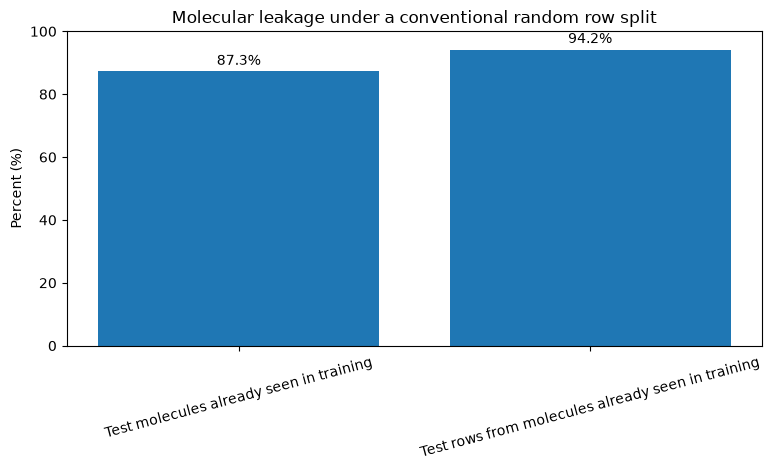

In [115]:
import matplotlib.pyplot as plt

random_split_leakage = pd.DataFrame({
    "measure": [
        "Test molecules already seen in training",
        "Test rows from molecules already seen in training"
    ],
    "percent": [
        len(overlapping_molecules) / len(test_molecules) * 100,
        test_rows_seen_molecule.mean() * 100
    ]
})

fig, ax = plt.subplots(figsize=(8.2, 4.4))

bars = ax.barh(
    random_split_leakage["measure"],
    random_split_leakage["percent"]
)

ax.set_xlabel("Overlap with training set (%)")
ax.set_xlim(0, 100)
ax.set_ylabel("")
ax.set_title("Molecular leakage under conventional random row splitting")

for bar, value in zip(bars, random_split_leakage["percent"]):
    ax.text(
        min(value + 1.0, 96),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()

save_publication_figure(
    fig,
    "figure_1_random_split_leakage"
)

plt.show()

**Figure 1. Molecular leakage under conventional random row splitting.**
Most nominal test examples are not chemically independent because the same molecular
identity is already represented in training. This motivates molecular-identity-grouped
validation throughout the remainder of the study.

### Evidence of Severe Leakage Under Random Row-Wise Splitting

A conventional stratified random 80/20 split of the primary hydrogel
classification dataset produced substantial molecular overlap between the
training and test partitions.

Among the 55 molecular identities represented in the nominal test set,
48 (87.27%) were also represented in the training set.

At the observation level, 94.21% of test rows corresponded to molecular
systems already encountered during training.

Thus, a conventional random row-wise evaluation would predominantly measure
interpolation among additional experimental conditions of known molecules
rather than generalization to previously unseen molecular systems.

All primary model evaluation will therefore enforce complete molecular-group
separation between training and test data.

Preprocessing operations that learn from the data, including numerical
imputation, scaling, categorical encoding, feature selection, and model
hyperparameter optimization, will be fitted using training data only.

In [116]:
# ============================================================
# PRIMARY HYDROGEL TASK — MOLECULAR GROUP STRUCTURE
# ============================================================

hydrogel_ml = ml_master[
    ml_master["bulk_state_curated"]
    .isin(["hydrogel", "non_gel"])
].copy()

hydrogel_ml["hydrogel_target"] = (
    hydrogel_ml["bulk_state_curated"]
    .map({
        "non_gel": 0,
        "hydrogel": 1
    })
)


hydrogel_group_summary = (
    hydrogel_ml
    .groupby("molecular_identity_key")
    .agg(
        n_rows=("hydrogel_target", "size"),
        n_hydrogel=("hydrogel_target", "sum"),
        n_non_gel=(
            "hydrogel_target",
            lambda x: (x == 0).sum()
        ),
        n_target_states=(
            "hydrogel_target",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "n_rows",
        ascending=False
    )
)


print("=" * 90)
print("PRIMARY HYDROGEL TASK — GROUP STRUCTURE")
print("=" * 90)

print("Total rows:", len(hydrogel_ml))

print(
    "Unique molecular identities:",
    hydrogel_ml["molecular_identity_key"].nunique()
)

print(
    "Molecules with both hydrogel and non-gel observations:",
    (
        hydrogel_group_summary["n_target_states"] > 1
    ).sum()
)

print(
    "Largest number of condition rows for one molecule:",
    hydrogel_group_summary["n_rows"].max()
)

display(
    hydrogel_group_summary.head(20)
)

PRIMARY HYDROGEL TASK — GROUP STRUCTURE
Total rows: 604
Unique molecular identities: 99
Molecules with both hydrogel and non-gel observations: 22
Largest number of condition rows for one molecule: 46


,molecular_identity_key,n_rows,n_hydrogel,n_non_gel,n_target_states
29,FF|linear_or_unspecified|fmoc|free|none|peptide|none,46,19,27,2
95,XFF|linear_or_unspecified|boc|free|none|peptide|none,44,22,22,2
28,FF|linear_or_unspecified|boc|free|none|peptide|none,40,0,40,1
31,FF|linear_or_unspecified|free|free|none|peptide|none,39,0,39,1
32,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,24,24,0,1
13,DF|linear_or_unspecified|free|methoxy|none|peptide|none,18,10,8,2
35,FG|linear_or_unspecified|fmoc|free|none|peptide|none,13,5,8,2
3,AA|linear_or_unspecified|fmoc|free|none|peptide|none,12,12,0,1
43,FP|linear_or_unspecified|fmoc|free|none|peptide|none,12,0,12,1
7,AGV|linear_or_unspecified|boc|benzylation|none|peptide|none,9,0,9,1


In [117]:
# ============================================================
# STRICT UNSEEN-MOLECULE HOLDOUT
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

X_split = hydrogel_ml.index.to_numpy()

y_split = (
    hydrogel_ml["hydrogel_target"]
    .to_numpy()
)

groups_split = (
    hydrogel_ml["molecular_identity_key"]
    .to_numpy()
)


overall_positive_rate = y_split.mean()

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


candidate_splits = []

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(
        X_split,
        y_split,
        groups_split
    ),
    start=1
):

    train_y = y_split[train_idx]
    test_y = y_split[test_idx]

    train_groups = set(
        groups_split[train_idx]
    )

    test_groups = set(
        groups_split[test_idx]
    )

    candidate_splits.append(
        {
            "fold": fold,
            "train_idx": train_idx,
            "test_idx": test_idx,

            "n_train_rows": len(train_idx),
            "n_test_rows": len(test_idx),

            "test_fraction": (
                len(test_idx)
                / len(hydrogel_ml)
            ),

            "train_positive_rate": train_y.mean(),
            "test_positive_rate": test_y.mean(),

            "n_train_molecules": len(train_groups),
            "n_test_molecules": len(test_groups),

            "group_overlap": len(
                train_groups & test_groups
            )
        }
    )


split_comparison = pd.DataFrame(
    [
        {
            k: v
            for k, v in split.items()
            if k not in ["train_idx", "test_idx"]
        }
        for split in candidate_splits
    ]
)


# Score each candidate by:
# 1. closeness to 20% test size
# 2. closeness to overall class prevalence
split_comparison["selection_score"] = (
    abs(
        split_comparison["test_fraction"]
        - 0.20
    )
    +
    abs(
        split_comparison["test_positive_rate"]
        - overall_positive_rate
    )
)


display(
    split_comparison.sort_values(
        "selection_score"
    )
)

,fold,n_train_rows,n_test_rows,test_fraction,train_positive_rate,test_positive_rate,n_train_molecules,n_test_molecules,group_overlap,selection_score
2,3,489,115,0.190397,0.288344,0.286957,79,20,0,0.010726
0,1,488,116,0.192053,0.290984,0.275862,78,21,0,0.020164
1,2,486,118,0.195364,0.292181,0.271186,83,16,0,0.021529
3,4,491,113,0.187086,0.291242,0.274336,74,25,0,0.026657
4,5,462,142,0.235099,0.277056,0.323944,82,17,0,0.070964


In [118]:
# ============================================================
# SELECT BEST GROUPED HOLDOUT
# ============================================================

best_fold = (
    split_comparison
    .sort_values("selection_score")
    .iloc[0]["fold"]
)

best_split = next(
    split
    for split in candidate_splits
    if split["fold"] == best_fold
)


train_idx = best_split["train_idx"]
test_idx = best_split["test_idx"]


hydrogel_train = (
    hydrogel_ml
    .iloc[train_idx]
    .copy()
)

hydrogel_test = (
    hydrogel_ml
    .iloc[test_idx]
    .copy()
)


print("=" * 90)
print("PERMANENT UNSEEN-MOLECULE HOLDOUT")
print("=" * 90)

print("Selected fold:", int(best_fold))

print("\nTraining rows:", len(hydrogel_train))
print("Test rows:", len(hydrogel_test))

print(
    "\nTraining molecules:",
    hydrogel_train[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Test molecules:",
    hydrogel_test[
        "molecular_identity_key"
    ].nunique()
)


print("\nTraining target distribution:")

display(
    hydrogel_train["hydrogel_target"]
    .value_counts()
    .sort_index()
    .rename_axis("hydrogel_target")
    .reset_index(name="n_records")
)


print("\nTest target distribution:")

display(
    hydrogel_test["hydrogel_target"]
    .value_counts()
    .sort_index()
    .rename_axis("hydrogel_target")
    .reset_index(name="n_records")
)

PERMANENT UNSEEN-MOLECULE HOLDOUT
Selected fold: 3

Training rows: 489
Test rows: 115

Training molecules: 79
Test molecules: 20

Training target distribution:


,hydrogel_target,n_records
0,0,348
1,1,141



Test target distribution:


,hydrogel_target,n_records
0,0,82
1,1,33


In [119]:
# ============================================================
# HOLDOUT LEAKAGE SANITY CHECK
# ============================================================

train_molecules = set(
    hydrogel_train["molecular_identity_key"]
)

test_molecules = set(
    hydrogel_test["molecular_identity_key"]
)

molecular_overlap = (
    train_molecules
    & test_molecules
)


print("=" * 90)
print("STRICT HOLDOUT LEAKAGE CHECK")
print("=" * 90)

print(
    "Molecules shared between train and test:",
    len(molecular_overlap)
)

print(
    "Train/test molecular sets completely disjoint:",
    len(molecular_overlap) == 0
)

assert len(molecular_overlap) == 0


print(
    "\nTrain hydrogel prevalence:",
    round(
        hydrogel_train["hydrogel_target"].mean()
        * 100,
        2
    ),
    "%"
)

print(
    "Test hydrogel prevalence:",
    round(
        hydrogel_test["hydrogel_target"].mean()
        * 100,
        2
    ),
    "%"
)


print(
    "\nLargest molecular group in train:",
    hydrogel_train
    .groupby("molecular_identity_key")
    .size()
    .max()
)

print(
    "Largest molecular group in test:",
    hydrogel_test
    .groupby("molecular_identity_key")
    .size()
    .max()
)

STRICT HOLDOUT LEAKAGE CHECK
Molecules shared between train and test: 0
Train/test molecular sets completely disjoint: True

Train hydrogel prevalence: 28.83 %
Test hydrogel prevalence: 28.7 %

Largest molecular group in train: 46
Largest molecular group in test: 24


### Table 1 — Primary binary-task split

In [120]:
primary_split_summary = pd.DataFrame({
    "partition": ["Development", "Permanent unseen-molecule holdout"],
    "n_rows": [len(hydrogel_train), len(hydrogel_test)],
    "n_molecules": [
        hydrogel_train["molecular_identity_key"].nunique(),
        hydrogel_test["molecular_identity_key"].nunique()
    ],
    "hydrogel_prevalence": [
        hydrogel_train["hydrogel_target"].mean(),
        hydrogel_test["hydrogel_target"].mean()
    ]
})

display(primary_split_summary.round(3))

,partition,n_rows,n_molecules,hydrogel_prevalence
0,Development,489,79,0.288
1,Permanent unseen-molecule holdout,115,20,0.287


In [121]:
# ============================================================
# SEQUENCE AUDIT BEFORE DESCRIPTOR GENERATION
# ============================================================

import pandas as pd
import numpy as np
from collections import Counter

# Work from the already-separated primary datasets
train_dev = hydrogel_train.copy()
test_holdout = hydrogel_test.copy()

# Standard amino-acid alphabet
standard_aa = set("ACDEFGHIKLMNPQRSTVWY")


def sequence_characters(series):
    chars = Counter()

    for seq in series.dropna().astype(str):
        chars.update(seq)

    return chars


train_chars = sequence_characters(
    train_dev["sequence_curated"]
)

all_chars = sequence_characters(
    hydrogel_ml["sequence_curated"]
)


print("=" * 90)
print("SEQUENCE ALPHABET AUDIT")
print("=" * 90)

print("Training-set characters:")
print(train_chars)

print("\nAll primary-task characters:")
print(all_chars)

unexpected_chars = sorted(
    set(all_chars.keys()) - standard_aa
)

print("\nUnexpected/non-standard characters:")
print(unexpected_chars)


print(
    "\nTraining sequence lengths:"
)

display(
    train_dev["sequence_curated"]
    .str.len()
    .value_counts()
    .sort_index()
    .rename_axis("sequence_length")
    .reset_index(name="n_records")
)


print(
    "\nUnique training molecules by peptide length:"
)

display(
    train_dev[
        [
            "molecular_identity_key",
            "sequence_curated"
        ]
    ]
    .drop_duplicates()
    .assign(
        sequence_length=lambda x:
        x["sequence_curated"].str.len()
    )
    ["sequence_length"]
    .value_counts()
    .sort_index()
    .rename_axis("sequence_length")
    .reset_index(name="n_molecular_identities")
)

SEQUENCE ALPHABET AUDIT
Training-set characters:
Counter({'F': 516, 'G': 177, 'A': 168, 'V': 161, 'X': 44, 'D': 37, 'L': 21, 'P': 20, 'S': 18, 'K': 14, 'Y': 13, 'W': 10, 'I': 9, 'E': 6, 'R': 4, 'Q': 3, 'M': 2, 'C': 1, 'H': 1})

All primary-task characters:
Counter({'F': 586, 'A': 261, 'G': 234, 'V': 219, 'X': 44, 'D': 38, 'P': 28, 'L': 21, 'W': 18, 'S': 18, 'K': 15, 'Y': 13, 'I': 11, 'E': 6, 'H': 6, 'R': 5, 'Q': 3, 'M': 2, 'C': 1})

Unexpected/non-standard characters:
['X']

Training sequence lengths:


,sequence_length,n_records
0,2,242
1,3,247



Unique training molecules by peptide length:


,sequence_length,n_molecular_identities
0,2,31
1,3,48


In [122]:
# ============================================================
# NON-STANDARD RESIDUE X — SOURCE-LEVEL AUDIT
# ============================================================

x_rows = ml_master[
    ml_master["sequence_curated"]
    .astype(str)
    .str.contains("X", regex=False, na=False)
].copy()


print("=" * 90)
print("NON-STANDARD RESIDUE X AUDIT")
print("=" * 90)

print("Condition-specific rows:", len(x_rows))

print(
    "Unique molecular identities:",
    x_rows["molecular_identity_key"].nunique()
)

print(
    "Unique raw sequences:",
    x_rows["sequence"].nunique()
)

print(
    "Unique curated sequences:",
    x_rows["sequence_curated"].nunique()
)

print(
    "Unique SAPdb IDs:",
    x_rows["sapdb_id_original"].nunique()
)


print("\nSequence counts:")

display(
    x_rows["sequence_curated"]
    .value_counts()
    .rename_axis("sequence_curated")
    .reset_index(name="n_records")
)


print("\nMolecular identities:")

display(
    x_rows[
        [
            "sequence",
            "sequence_curated",
            "N-terminal",
            "C-terminal",
            "non-terminal",
            "peptide/conjugate/mixture",
            "conjugate partner",
            "molecular_identity_key"
        ]
    ]
    .drop_duplicates()
)


print("\nCondition-specific X-containing records:")

display(
    x_rows[
        [
            "sapdb_id_original",
            "sequence",
            "sequence_curated",
            "N-terminal",
            "C-terminal",
            "non-terminal",
            "solution",
            "volume ratio",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "heating/cooling",
            "incubation period (min)",
            "assembly_label_original",
            "bulk_state_curated"
        ]
    ]
    .sort_values(
        [
            "sapdb_id_original",
            "concentration(mg/ml)",
            "PH",
            "temperature"
        ]
    )
)


# ============================================================
# SAPdb CONTEXT FOR X-CONTAINING SEQUENCES
# ============================================================

x_source_ids = (
    x_rows["sapdb_id_original"]
    .dropna()
    .unique()
)


display(
    sapdb.loc[
        sapdb["id"].isin(x_source_ids),
        [
            "id",
            "pmid",
            "pepname",
            "pepseq",
            "nter",
            "cter",
            "Selfassembly",
            "nanostr",
            "nanostr_class",
            "solvent",
            "method",
            "comment"
        ]
    ]
    .sort_values("id")
)


x_pmids = (
    sapdb.loc[
        sapdb["id"].isin(x_source_ids),
        "pmid"
    ]
    .dropna()
    .unique()
)

for pmid in x_pmids:

    print("\n" + "=" * 100)
    print("PUBLICATION PMID:", pmid)
    print("=" * 100)

    display(
        sapdb.loc[
            sapdb["pmid"] == pmid,
            [
                "id",
                "pepname",
                "pepseq",
                "nter",
                "cter",
                "nanostr",
                "nanostr_class",
                "solvent",
                "method",
                "comment"
            ]
        ]
        .sort_values("id")
    )

NON-STANDARD RESIDUE X AUDIT
Condition-specific rows: 44
Unique molecular identities: 1
Unique raw sequences: 1
Unique curated sequences: 1
Unique SAPdb IDs: 1

Sequence counts:


,sequence_curated,n_records
0,XFF,44



Molecular identities:


,sequence,sequence_curated,N-terminal,C-terminal,non-terminal,peptide/conjugate/mixture,conjugate partner,molecular_identity_key
340,XFF,XFF,Boc,Free,NaN,Peptide,NaN,XFF|linear_or_unspecified|boc|free|none|peptide|none



Condition-specific X-containing records:


,sapdb_id_original,sequence,sequence_curated,N-terminal,C-terminal,non-terminal,solution,volume ratio,concentration(mg/ml),PH,temperature,heating/cooling,incubation period (min),assembly_label_original,bulk_state_curated
343,1124,XFF,XFF,Boc,Free,NaN,PB,100,2.32,7.46,32.5,No,10.0,none,non_gel
342,1124,XFF,XFF,Boc,Free,NaN,PB,100,2.61,7.46,32.5,No,10.0,none,non_gel
347,1124,XFF,XFF,Boc,Free,NaN,PB,100,2.80,7.46,39.0,No,10.0,none,non_gel
351,1124,XFF,XFF,Boc,Free,NaN,PB,100,2.88,7.46,42.5,No,10.0,none,non_gel
346,1124,XFF,XFF,Boc,Free,NaN,PB,100,3.15,7.46,39.0,No,10.0,none,non_gel
340,1124,XFF,XFF,Boc,Free,NaN,PB,100,3.19,7.46,32.5,No,10.0,hydrogel,hydrogel
350,1124,XFF,XFF,Boc,Free,NaN,PB,100,3.24,7.46,42.5,No,10.0,none,non_gel
355,1124,XFF,XFF,Boc,Free,NaN,PB,100,3.28,7.46,44.0,No,10.0,none,non_gel
341,1124,XFF,XFF,Boc,Free,NaN,PB,100,3.48,7.46,32.5,No,10.0,hydrogel,hydrogel
359,1124,XFF,XFF,Boc,Free,NaN,PB,100,3.52,7.46,46.0,No,10.0,none,non_gel


,id,pmid,pepname,pepseq,nter,cter,Selfassembly,nanostr,nanostr_class,solvent,method,comment
123,1124,24397440,P1,XFF,Boc (or t-butoxycarbonyl),Free,Yes,Translucent Hydrogel and Nano-fibrillar structure,Hydrogel,Phosphate buffer,Peptide was was placed in a glass vial and heated on a hot plate after addition of 1 mL of 50 mM phosphate buffer (pH 7.46) to give a clear solution. The solution on standing at room temperature for a few minutes (almost 10 minutes) produced a translucent gel.,X:(11- aminoundecanoic acid)



PUBLICATION PMID: 24397440


,id,pepname,pepseq,nter,cter,nanostr,nanostr_class,solvent,method,comment
123,1124,P1,XFF,Boc (or t-butoxycarbonyl),Free,Translucent Hydrogel and Nano-fibrillar structure,Hydrogel,Phosphate buffer,Peptide was was placed in a glass vial and heated on a hot plate after addition of 1 mL of 50 mM phosphate buffer (pH 7.46) to give a clear solution. The solution on standing at room temperature for a few minutes (almost 10 minutes) produced a translucent gel.,X:(11- aminoundecanoic acid)


In [123]:
# ============================================================
# SEQUENCE-DERIVED PHYSICOCHEMICAL DESCRIPTORS
# STANDARD + X = 11-AMINOUNDECANOIC ACID
# ============================================================

from collections import Counter
import numpy as np
import pandas as pd


AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")


# ------------------------------------------------------------
# Standard amino-acid Kyte-Doolittle hydropathy
# ------------------------------------------------------------

AA_HYDROPATHY = {
    "A": 1.8,
    "C": 2.5,
    "D": -3.5,
    "E": -3.5,
    "F": 2.8,
    "G": -0.4,
    "H": -3.2,
    "I": 4.5,
    "K": -3.9,
    "L": 3.8,
    "M": 1.9,
    "N": -3.5,
    "P": -1.6,
    "Q": -3.5,
    "R": -4.5,
    "S": -0.8,
    "T": -0.7,
    "V": 4.2,
    "W": -0.9,
    "Y": -1.3
}


# ------------------------------------------------------------
# Approximate free-monomer molecular weights
# ------------------------------------------------------------

AA_MW = {
    "A": 89.09,
    "C": 121.16,
    "D": 133.10,
    "E": 147.13,
    "F": 165.19,
    "G": 75.07,
    "H": 155.16,
    "I": 131.17,
    "K": 146.19,
    "L": 131.17,
    "M": 149.21,
    "N": 132.12,
    "P": 115.13,
    "Q": 146.15,
    "R": 174.20,
    "S": 105.09,
    "T": 119.12,
    "V": 117.15,
    "W": 204.23,
    "Y": 181.19
}


# ------------------------------------------------------------
# Noncanonical monomer established from source audit
#
# X = 11-aminoundecanoic acid
# approximate free-monomer MW = 201.31 g/mol
# ------------------------------------------------------------

NONCANONICAL_MW = {
    "X": 201.31
}


AROMATIC = set("FWY")
HYDROPHOBIC = set("AVILMFWY")
POLAR = set("STNQCY")
POSITIVE = set("KRH")
NEGATIVE = set("DE")
SULFUR = set("CM")


def peptide_descriptors(seq):

    seq = str(seq).strip().upper()

    n = len(seq)

    if n == 0:
        return {}

    counts = Counter(seq)

    # --------------------------------------------------------
    # Check that every symbol is understood
    # --------------------------------------------------------

    allowed_symbols = set(AA_ORDER) | set(NONCANONICAL_MW)

    unknown = set(seq) - allowed_symbols

    if unknown:
        raise ValueError(
            f"Unsupported residue symbol(s): {sorted(unknown)} "
            f"in sequence {seq}"
        )


    # --------------------------------------------------------
    # Approximate molecular weight of peptide backbone/core
    #
    # Sum free monomers and subtract H2O for each linkage.
    # Terminal modifications (Fmoc, Boc, etc.) remain separate
    # molecular features and are NOT silently folded into this
    # approximate sequence-core MW.
    # --------------------------------------------------------

    monomer_mw = []

    for symbol in seq:

        if symbol in AA_MW:
            monomer_mw.append(
                AA_MW[symbol]
            )

        else:
            monomer_mw.append(
                NONCANONICAL_MW[symbol]
            )


    approx_mw = (
        sum(monomer_mw)
        -
        18.015 * max(n - 1, 0)
    )


    # --------------------------------------------------------
    # Hydropathy
    #
    # Kyte-Doolittle is defined for canonical residues only.
    # Therefore X is NOT assigned an invented KD value.
    # --------------------------------------------------------

    standard_residues = [
        aa
        for aa in seq
        if aa in AA_HYDROPATHY
    ]

    if len(standard_residues) > 0:

        mean_standard_hydropathy = np.mean(
            [
                AA_HYDROPATHY[aa]
                for aa in standard_residues
            ]
        )

    else:

        mean_standard_hydropathy = np.nan


    # --------------------------------------------------------
    # General descriptors
    # --------------------------------------------------------

    descriptor = {

        "pep_length": n,

        "pep_approx_core_mw": approx_mw,

        "pep_mean_standard_aa_hydropathy":
            mean_standard_hydropathy,

        "pep_standard_residue_fraction":
            len(standard_residues) / n,

        "pep_noncanonical_fraction":
            sum(
                aa not in AA_HYDROPATHY
                for aa in seq
            ) / n,

        "pep_aromatic_fraction":
            sum(
                aa in AROMATIC
                for aa in seq
            ) / n,

        "pep_hydrophobic_standard_fraction":
            sum(
                aa in HYDROPHOBIC
                for aa in seq
            ) / n,

        "pep_polar_fraction":
            sum(
                aa in POLAR
                for aa in seq
            ) / n,

        "pep_positive_fraction":
            sum(
                aa in POSITIVE
                for aa in seq
            ) / n,

        "pep_negative_fraction":
            sum(
                aa in NEGATIVE
                for aa in seq
            ) / n,

        "pep_net_charge_proxy":
            (
                sum(
                    aa in POSITIVE
                    for aa in seq
                )
                -
                sum(
                    aa in NEGATIVE
                    for aa in seq
                )
            ),

        "pep_gly_fraction":
            counts.get("G", 0) / n,

        "pep_pro_fraction":
            counts.get("P", 0) / n,

        "pep_sulfur_fraction":
            sum(
                aa in SULFUR
                for aa in seq
            ) / n,


        # ----------------------------------------------------
        # X-specific chemistry
        # X = 11-aminoundecanoic acid
        # ----------------------------------------------------

        "x_aminoundecanoic_count":
            counts.get("X", 0),

        "x_aminoundecanoic_fraction":
            counts.get("X", 0) / n,

        "has_aminoundecanoic_acid":
            int(counts.get("X", 0) > 0),

        # 11 carbon atoms per X monomer
        "x_total_carbon_count":
            counts.get("X", 0) * 11,

        # long aliphatic segment contains ~10 methylene units
        "x_total_methylene_count":
            counts.get("X", 0) * 10
    }


    # --------------------------------------------------------
    # Standard amino-acid composition
    # --------------------------------------------------------

    for aa in AA_ORDER:

        descriptor[
            f"aa_fraction_{aa}"
        ] = counts.get(aa, 0) / n


    return descriptor





    # ============================================================
# APPLY REVISED PEPTIDE DESCRIPTORS
# ============================================================

train_sequence_features = (
    train_dev["sequence_curated"]
    .apply(peptide_descriptors)
    .apply(pd.Series)
)

test_sequence_features = (
    test_holdout["sequence_curated"]
    .apply(peptide_descriptors)
    .apply(pd.Series)
)


print("=" * 90)
print("REVISED SEQUENCE DESCRIPTOR MATRICES")
print("=" * 90)

print(
    "Training descriptor shape:",
    train_sequence_features.shape
)

print(
    "Test descriptor shape:",
    test_sequence_features.shape
)

print(
    "\nTraining missing descriptor cells:",
    train_sequence_features
    .isna()
    .sum()
    .sum()
)

print(
    "Test missing descriptor cells:",
    test_sequence_features
    .isna()
    .sum()
    .sum()
)


print("\nXFF descriptor example:")

xff_index = (
    train_dev[
        train_dev["sequence_curated"] == "XFF"
    ]
    .index[0]
)

xff_position = (
    train_dev.index
    .get_loc(xff_index)
)

display(
    train_sequence_features
    .iloc[[xff_position]]
    .T
    .rename(
        columns={
            xff_position: "XFF"
        }
    )
)





REVISED SEQUENCE DESCRIPTOR MATRICES
Training descriptor shape: (489, 39)
Test descriptor shape: (115, 39)

Training missing descriptor cells: 0
Test missing descriptor cells: 0

XFF descriptor example:


,340
pep_length,3.000000
pep_approx_core_mw,495.660000
pep_mean_standard_aa_hydropathy,2.800000
pep_standard_residue_fraction,0.666667
pep_noncanonical_fraction,0.333333
pep_aromatic_fraction,0.666667
pep_hydrophobic_standard_fraction,0.666667
pep_polar_fraction,0.000000
pep_positive_fraction,0.000000
pep_negative_fraction,0.000000


In [124]:
# ============================================================
# MOLECULAR-DESCRIPTOR CONSISTENCY CHECK
# ============================================================

train_with_descriptors = pd.concat(
    [
        train_dev.reset_index(drop=True),
        train_sequence_features.reset_index(drop=True)
    ],
    axis=1
)

descriptor_columns = list(
    train_sequence_features.columns
)


descriptor_consistency = (
    train_with_descriptors
    .groupby("molecular_identity_key")[
        descriptor_columns
    ]
    .nunique(dropna=False)
)


inconsistent_descriptor_cells = (
    descriptor_consistency > 1
).sum().sum()


print("=" * 90)
print("MOLECULAR DESCRIPTOR CONSISTENCY")
print("=" * 90)

print(
    "Descriptor inconsistencies within identical molecular identities:",
    inconsistent_descriptor_cells
)

print(
    "Consistency check passed:",
    inconsistent_descriptor_cells == 0
)


assert inconsistent_descriptor_cells == 0

MOLECULAR DESCRIPTOR CONSISTENCY
Descriptor inconsistencies within identical molecular identities: 0
Consistency check passed: True


In [125]:
# ============================================================
# CLEAN SOLVENT REPRESENTATION FOR ML
# ============================================================

def prepare_solvent_features(df):

    out = df.copy()

    # Component identities
    out["solvent_component_1"] = (
        out["component_1_standardized"]
        .astype("string")
        .fillna("none")
    )

    out["solvent_component_2"] = (
        out["component_2_standardized"]
        .astype("string")
        .fillna("none")
    )

    # Numerical fractions
    out["solvent_fraction_1"] = (
        out["component_1_ratio_fraction"]
        .astype(float)
    )

    out["solvent_fraction_2"] = (
        out["component_2_ratio_fraction"]
        .astype(float)
    )

    out["aqueous_fraction"] = (
        out["aqueous_phase_fraction"]
        .astype(float)
    )

    # Explicit indicator
    out["has_second_solvent_component"] = (
        out["component_2_present"]
        .astype(int)
    )

    return out


train_dev_features = prepare_solvent_features(
    train_dev
)

test_holdout_features = prepare_solvent_features(
    test_holdout
)


solvent_model_columns = [
    "solvent_component_1",
    "solvent_component_2",
    "solvent_fraction_1",
    "solvent_fraction_2",
    "aqueous_fraction",
    "has_second_solvent_component",
    "solvent_environment_audit"
]


print("=" * 90)
print("SOLVENT FEATURE CHECK")
print("=" * 90)

for col in solvent_model_columns:

    print(
        col,
        "| missing =",
        train_dev_features[col].isna().sum(),
        "| unique =",
        train_dev_features[col].nunique(dropna=True)
    )

display(
    train_dev_features[
        solvent_model_columns
    ].head(20)
)

SOLVENT FEATURE CHECK
solvent_component_1 | missing = 0 | unique = 16
solvent_component_2 | missing = 0 | unique = 3
solvent_fraction_1 | missing = 0 | unique = 13
solvent_fraction_2 | missing = 0 | unique = 13
aqueous_fraction | missing = 0 | unique = 14
has_second_solvent_component | missing = 0 | unique = 2
solvent_environment_audit | missing = 0 | unique = 4


,solvent_component_1,solvent_component_2,solvent_fraction_1,solvent_fraction_2,aqueous_fraction,has_second_solvent_component,solvent_environment_audit
0,DMSO,phosphate_buffered_saline,0.05,0.95,0.95,1,organic_aqueous_mixture
1,DMSO,phosphate_buffered_saline,0.10,0.90,0.90,1,organic_aqueous_mixture
2,DMSO,phosphate_buffered_saline,0.20,0.80,0.80,1,organic_aqueous_mixture
3,DMSO,phosphate_buffered_saline,0.40,0.60,0.60,1,organic_aqueous_mixture
4,water,none,1.00,0.00,1.00,0,pure_water
5,water,none,1.00,0.00,1.00,0,pure_water
6,water,none,1.00,0.00,1.00,0,pure_water
7,water,none,1.00,0.00,1.00,0,pure_water
8,water,none,1.00,0.00,1.00,0,pure_water
9,water,none,1.00,0.00,1.00,0,pure_water


In [126]:
# ============================================================
# CONDITION FEATURE BLOCK
# ============================================================

for df in [
    train_dev_features,
    test_holdout_features
]:

    df["incubation_missing"] = (
        df["incubation period (min)"]
        .isna()
        .astype(int)
    )

    df["heating_cooling_binary"] = (
        df["heating/cooling"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "yes": 1,
            "no": 0
        })
    )


condition_numeric_columns = [
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "incubation period (min)",
    "incubation_missing",
    "heating_cooling_binary",
    "solvent_fraction_1",
    "solvent_fraction_2",
    "aqueous_fraction",
    "has_second_solvent_component"
]


print("=" * 90)
print("CONDITION NUMERIC FEATURES")
print("=" * 90)

condition_feature_check = pd.DataFrame(
    {
        "feature": condition_numeric_columns,

        "train_missing": [
            train_dev_features[col].isna().sum()
            for col in condition_numeric_columns
        ],

        "test_missing": [
            test_holdout_features[col].isna().sum()
            for col in condition_numeric_columns
        ]
    }
)

display(condition_feature_check)

CONDITION NUMERIC FEATURES


,feature,train_missing,test_missing
0,concentration(mg/ml),0,0
1,PH,0,0
2,temperature,0,0
3,incubation period (min),132,12
4,incubation_missing,0,0
5,heating_cooling_binary,0,0
6,solvent_fraction_1,0,0
7,solvent_fraction_2,0,0
8,aqueous_fraction,0,0
9,has_second_solvent_component,0,0


In [127]:
# ============================================================
# ASSEMBLE MOLECULAR + CONDITION FEATURE TABLES
# ============================================================

train_model_data = train_dev_features.reset_index(drop=True).copy()
test_model_data = test_holdout_features.reset_index(drop=True).copy()

# Add deterministic sequence descriptors
train_model_data = pd.concat(
    [
        train_model_data,
        train_sequence_features.reset_index(drop=True)
    ],
    axis=1
)

test_model_data = pd.concat(
    [
        test_model_data,
        test_sequence_features.reset_index(drop=True)
    ],
    axis=1
)


print("=" * 90)
print("ASSEMBLED MODEL TABLES")
print("=" * 90)

print("Training rows:", len(train_model_data))
print("Test rows:", len(test_model_data))

print(
    "Training sequence descriptors attached:",
    len(train_sequence_features.columns)
)

print(
    "Test sequence descriptors attached:",
    len(test_sequence_features.columns)
)

assert len(train_model_data) == 489
assert len(test_model_data) == 115

ASSEMBLED MODEL TABLES
Training rows: 489
Test rows: 115
Training sequence descriptors attached: 39
Test sequence descriptors attached: 39


In [128]:
# ============================================================
# FINAL PREDICTOR WHITELIST
# ============================================================

# ------------------------------------------------------------
# 1. Deterministic sequence-derived numerical descriptors
# ------------------------------------------------------------

sequence_descriptor_columns = list(
    train_sequence_features.columns
)


# ------------------------------------------------------------
# 2. Experimental numerical predictors
# ------------------------------------------------------------

numeric_condition_columns = [
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "incubation period (min)",
    "incubation_missing",
    "heating_cooling_binary",

    "solvent_fraction_1",
    "solvent_fraction_2",
    "aqueous_fraction",
    "has_second_solvent_component"
]


# ------------------------------------------------------------
# 3. Molecular categorical predictors
# ------------------------------------------------------------

molecular_categorical_columns = [
    "topology_curated",
    "n_terminal_curated",
    "c_terminal_curated",
    "non_terminal_curated",
    "peptide_system_curated",
    "conjugate_partner_curated"
]


# ------------------------------------------------------------
# 4. Solvent categorical predictors
# ------------------------------------------------------------

solvent_categorical_columns = [
    "solvent_component_1",
    "solvent_component_2",
    "solvent_environment_audit"
]


numeric_features = (
    sequence_descriptor_columns
    + numeric_condition_columns
)

categorical_features = (
    molecular_categorical_columns
    + solvent_categorical_columns
)


all_model_features = (
    numeric_features
    + categorical_features
)


print("=" * 90)
print("FINAL FEATURE WHITELIST")
print("=" * 90)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total pre-encoding predictors:", len(all_model_features))

print("\nNumerical:")
for col in numeric_features:
    print(" -", col)

print("\nCategorical:")
for col in categorical_features:
    print(" -", col)

FINAL FEATURE WHITELIST
Numerical features: 49
Categorical features: 9
Total pre-encoding predictors: 58

Numerical:
 - pep_length
 - pep_approx_core_mw
 - pep_mean_standard_aa_hydropathy
 - pep_standard_residue_fraction
 - pep_noncanonical_fraction
 - pep_aromatic_fraction
 - pep_hydrophobic_standard_fraction
 - pep_polar_fraction
 - pep_positive_fraction
 - pep_negative_fraction
 - pep_net_charge_proxy
 - pep_gly_fraction
 - pep_pro_fraction
 - pep_sulfur_fraction
 - x_aminoundecanoic_count
 - x_aminoundecanoic_fraction
 - has_aminoundecanoic_acid
 - x_total_carbon_count
 - x_total_methylene_count
 - aa_fraction_A
 - aa_fraction_C
 - aa_fraction_D
 - aa_fraction_E
 - aa_fraction_F
 - aa_fraction_G
 - aa_fraction_H
 - aa_fraction_I
 - aa_fraction_K
 - aa_fraction_L
 - aa_fraction_M
 - aa_fraction_N
 - aa_fraction_P
 - aa_fraction_Q
 - aa_fraction_R
 - aa_fraction_S
 - aa_fraction_T
 - aa_fraction_V
 - aa_fraction_W
 - aa_fraction_Y
 - concentration(mg/ml)
 - PH
 - temperature
 - incub

In [129]:
# ============================================================
# FEATURE-LEAKAGE ASSERTION
# ============================================================

forbidden_feature_names = {
    "sapdb_id",
    "sapdb_id_original",
    "sapdb_id_curated",
    "pmid",
    "id",
    "sequence",
    "sequence_curated",
    "molecular_identity_key",

    "assembly_label_audit",
    "assembly_label_original",
    "bulk_state_curated",
    "hydrogel_target",

    "nanostr",
    "nanostr_class",
    "Selfassembly",
    "comment",
    "stab",

    "morphology_curated",
    "morphology_parent",

    "hydrogel_review_cluster",
    "bulk_state_confidence",
    "bulk_state_adjudication_source"
}


leaking_features = sorted(
    set(all_model_features)
    & forbidden_feature_names
)


print("=" * 90)
print("FEATURE LEAKAGE CHECK")
print("=" * 90)

print("Forbidden predictors found:")
print(leaking_features)

assert len(leaking_features) == 0

print("\nLeakage whitelist check passed.")

FEATURE LEAKAGE CHECK
Forbidden predictors found:
[]

Leakage whitelist check passed.


In [130]:
# ============================================================
# FINAL DEVELOPMENT / HOLDOUT MATRICES
# ============================================================

X_train = train_model_data[
    all_model_features
].copy()

y_train = (
    train_model_data["hydrogel_target"]
    .astype(int)
    .copy()
)

groups_train = (
    train_model_data["molecular_identity_key"]
    .copy()
)


X_test = test_model_data[
    all_model_features
].copy()

y_test = (
    test_model_data["hydrogel_target"]
    .astype(int)
    .copy()
)


print("=" * 90)
print("PRIMARY MODEL MATRICES")
print("=" * 90)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print(
    "\nTraining molecular groups:",
    groups_train.nunique()
)

print(
    "Hydrogel prevalence in training:",
    round(y_train.mean() * 100, 2),
    "%"
)

PRIMARY MODEL MATRICES
X_train: (489, 58)
y_train: (489,)
X_test: (115, 58)
y_test: (115,)

Training molecular groups: 79
Hydrogel prevalence in training: 28.83 %


In [131]:
# ============================================================
# TRAINING-ONLY PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer


# ------------------------------------------------------------
# Numerical pipeline
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# Categorical pipeline
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# Combined preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


print("Preprocessor constructed.")
print("Nothing has been fitted to the holdout set.")

Preprocessor constructed.
Nothing has been fitted to the holdout set.


In [132]:
# ============================================================
# GROUPED CROSS-VALIDATION FOR MODEL DEVELOPMENT
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

cv_grouped = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


cv_summary = []

for fold, (tr_idx, val_idx) in enumerate(
    cv_grouped.split(
        X_train,
        y_train,
        groups_train
    ),
    start=1
):

    train_groups_fold = set(
        groups_train.iloc[tr_idx]
    )

    validation_groups_fold = set(
        groups_train.iloc[val_idx]
    )

    cv_summary.append(
        {
            "fold": fold,

            "n_train_rows": len(tr_idx),
            "n_validation_rows": len(val_idx),

            "n_train_molecules":
                len(train_groups_fold),

            "n_validation_molecules":
                len(validation_groups_fold),

            "group_overlap":
                len(
                    train_groups_fold
                    & validation_groups_fold
                ),

            "train_hydrogel_rate":
                round(
                    y_train.iloc[tr_idx].mean(),
                    3
                ),

            "validation_hydrogel_rate":
                round(
                    y_train.iloc[val_idx].mean(),
                    3
                )
        }
    )


cv_summary = pd.DataFrame(cv_summary)

display(cv_summary)

assert (
    cv_summary["group_overlap"] == 0
).all()

print(
    "\nAll grouped CV folds have zero molecular overlap."
)

,fold,n_train_rows,n_validation_rows,n_train_molecules,n_validation_molecules,group_overlap,train_hydrogel_rate,validation_hydrogel_rate
0,1,398,91,65,14,0,0.291,0.275
1,2,396,93,67,12,0,0.295,0.258
2,3,362,127,67,12,0,0.268,0.346
3,4,402,87,60,19,0,0.291,0.276
4,5,398,91,57,22,0,0.294,0.264



All grouped CV folds have zero molecular overlap.


In [133]:
# ============================================================
# GROUPED-CV MODEL EVALUATION FUNCTION
# ============================================================

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef
)

def evaluate_grouped_cv(
    pipeline,
    X,
    y,
    groups,
    cv
):

    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        model = clone(pipeline)

        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        model.fit(
            X_tr,
            y_tr
        )

        pred = model.predict(
            X_val
        )

        prob = model.predict_proba(
            X_val
        )[:, 1]

        fold_results.append(
            {
                "fold": fold,

                "roc_auc":
                    roc_auc_score(
                        y_val,
                        prob
                    ),

                "pr_auc":
                    average_precision_score(
                        y_val,
                        prob
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_val,
                        pred
                    ),

                "f1":
                    f1_score(
                        y_val,
                        pred,
                        zero_division=0
                    ),

                "mcc":
                    matthews_corrcoef(
                        y_val,
                        pred
                    )
            }
        )

    return pd.DataFrame(
        fold_results
    )

In [134]:
# ============================================================
# PREPROCESSING BUILDER
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer


def make_preprocessor(
    numerical_columns,
    categorical_columns
):

    numeric_pipe = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipe = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),

            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    return ColumnTransformer(
        [
            (
                "numeric",
                numeric_pipe,
                numerical_columns
            ),

            (
                "categorical",
                categorical_pipe,
                categorical_columns
            )
        ],
        remainder="drop"
    )

In [135]:
# ============================================================
# SCIENTIFIC FEATURE ABLATION SETS
# ============================================================

molecule_numeric_features = (
    sequence_descriptor_columns
)

molecule_categorical_features = (
    molecular_categorical_columns
)


condition_numeric_features_cv = (
    numeric_condition_columns
)

condition_categorical_features_cv = (
    solvent_categorical_columns
)


combined_numeric_features = (
    molecule_numeric_features
    + condition_numeric_features_cv
)

combined_categorical_features = (
    molecule_categorical_features
    + condition_categorical_features_cv
)


print("Molecule-only:")
print(
    len(molecule_numeric_features),
    "numeric +",
    len(molecule_categorical_features),
    "categorical"
)

print("\nCondition-only:")
print(
    len(condition_numeric_features_cv),
    "numeric +",
    len(condition_categorical_features_cv),
    "categorical"
)

print("\nCombined:")
print(
    len(combined_numeric_features),
    "numeric +",
    len(combined_categorical_features),
    "categorical"
)

Molecule-only:
39 numeric + 6 categorical

Condition-only:
10 numeric + 3 categorical

Combined:
49 numeric + 9 categorical


In [136]:
# ============================================================
# DUMMY BASELINE
# ============================================================

from sklearn.dummy import DummyClassifier


dummy_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                combined_numeric_features,
                combined_categorical_features
            )
        ),

        (
            "classifier",
            DummyClassifier(
                strategy="prior"
            )
        )
    ]
)


dummy_results = evaluate_grouped_cv(
    dummy_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


print("=" * 90)
print("DUMMY BASELINE")
print("=" * 90)

display(dummy_results)

display(
    dummy_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

DUMMY BASELINE


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.5,0.274725,0.5,0.0,0.0
1,2,0.5,0.258065,0.5,0.0,0.0
2,3,0.5,0.346457,0.5,0.0,0.0
3,4,0.5,0.275862,0.5,0.0,0.0
4,5,0.5,0.263736,0.5,0.0,0.0


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.5,0.284,0.5,0.0,0.0
std,0.0,0.036,0.0,0.0,0.0


In [137]:
# ============================================================
# LOGISTIC REGRESSION — MOLECULE ONLY
# ============================================================

from sklearn.linear_model import LogisticRegression


molecule_only_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                molecule_numeric_features,
                molecule_categorical_features
            )
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)


molecule_only_results = evaluate_grouped_cv(
    molecule_only_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


display(
    molecule_only_results
)

print("\nMean ± SD:")

display(
    molecule_only_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.768485,0.682428,0.704848,0.578947,0.522620
1,2,0.476147,0.458697,0.567029,0.440000,0.151772
2,3,0.635679,0.440032,0.593373,0.478261,0.183267
3,4,0.859127,0.576000,0.868056,0.754098,0.665478
4,5,0.857898,0.579372,0.717040,0.583333,0.434080



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.719,0.547,0.690,0.567,0.391
std,0.164,0.099,0.119,0.122,0.221


In [138]:
# ============================================================
# LOGISTIC REGRESSION — CONDITIONS ONLY
# ============================================================

condition_only_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                condition_numeric_features_cv,
                condition_categorical_features_cv
            )
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)


condition_only_results = evaluate_grouped_cv(
    condition_only_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


display(
    condition_only_results
)

print("\nMean ± SD:")

display(
    condition_only_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.950909,0.874313,0.911818,0.827586,0.764727
1,2,0.515399,0.246349,0.644928,0.494845,0.308699
2,3,0.798193,0.708752,0.710980,0.636364,0.401884
3,4,0.847884,0.596936,0.888889,0.774194,0.700877
4,5,0.932525,0.814986,0.775187,0.681818,0.585674



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.809,0.648,0.786,0.683,0.552
std,0.176,0.248,0.114,0.129,0.194


In [139]:
# ============================================================
# LOGISTIC REGRESSION — MOLECULE + CONDITIONS
# ============================================================

combined_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                combined_numeric_features,
                combined_categorical_features
            )
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)


combined_results = evaluate_grouped_cv(
    combined_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


display(
    combined_results
)

print("\nMean ± SD:")

display(
    combined_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.886667,0.769672,0.726970,0.608696,0.480929
1,2,0.642210,0.518325,0.659420,0.505263,0.328294
2,3,0.716867,0.481385,0.638828,0.541667,0.268683
3,4,0.834656,0.501155,0.868056,0.754098,0.665478
4,5,0.892724,0.691753,0.717040,0.583333,0.434080



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.795,0.592,0.722,0.599,0.435
std,0.111,0.130,0.090,0.095,0.154


In [140]:
# ============================================================
# BASELINE MODEL COMPARISON
# ============================================================

def summarize_model_results(
    name,
    result_df
):

    means = (
        result_df
        .drop(columns="fold")
        .mean()
    )

    stds = (
        result_df
        .drop(columns="fold")
        .std()
    )

    output = {
        "model": name
    }

    for metric in means.index:

        output[
            f"{metric}_mean"
        ] = means[metric]

        output[
            f"{metric}_std"
        ] = stds[metric]

    return output


baseline_comparison = pd.DataFrame(
    [
        summarize_model_results(
            "Dummy",
            dummy_results
        ),

        summarize_model_results(
            "Molecule_only_logistic",
            molecule_only_results
        ),

        summarize_model_results(
            "Condition_only_logistic",
            condition_only_results
        ),

        summarize_model_results(
            "Molecule_plus_condition_logistic",
            combined_results
        )
    ]
)


display(
    baseline_comparison
    .round(3)
)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,mcc_mean,mcc_std
0,Dummy,0.500,0.000,0.284,0.036,0.500,0.000,0.000,0.000,0.000,0.000
1,Molecule_only_logistic,0.719,0.164,0.547,0.099,0.690,0.119,0.567,0.122,0.391,0.221
2,Condition_only_logistic,0.809,0.176,0.648,0.248,0.786,0.114,0.683,0.129,0.552,0.194
3,Molecule_plus_condition_logistic,0.795,0.111,0.592,0.130,0.722,0.090,0.599,0.095,0.435,0.154


In [141]:
# ============================================================
# ATTACH PUBLICATION PROVENANCE FOR ROBUSTNESS ANALYSIS
# ============================================================

# Each SAPdb source ID belongs to a publication.
# We use the ORIGINAL SAPdb/source anchor because publication
# provenance is what matters here. Molecular-reference
# corrections previously made within a publication do not
# change the publication itself.

sapdb_publication_map = (
    sapdb[
        [
            "id",
            "pmid"
        ]
    ]
    .drop_duplicates("id")
    .set_index("id")["pmid"]
)


# ------------------------------------------------------------
# Attach publication PMID to the primary ML datasets
# ------------------------------------------------------------

hydrogel_ml["publication_pmid"] = (
    hydrogel_ml["sapdb_id_original"]
    .map(sapdb_publication_map)
)

hydrogel_train["publication_pmid"] = (
    hydrogel_train["sapdb_id_original"]
    .map(sapdb_publication_map)
)

hydrogel_test["publication_pmid"] = (
    hydrogel_test["sapdb_id_original"]
    .map(sapdb_publication_map)
)


# Also attach it to the assembled modelling tables
train_model_data["publication_pmid"] = (
    train_model_data["sapdb_id_original"]
    .map(sapdb_publication_map)
)

test_model_data["publication_pmid"] = (
    test_model_data["sapdb_id_original"]
    .map(sapdb_publication_map)
)


print("=" * 90)
print("PUBLICATION PROVENANCE ATTACHMENT")
print("=" * 90)

print(
    "Primary-task rows:",
    len(hydrogel_ml)
)

print(
    "Rows missing publication PMID:",
    hydrogel_ml["publication_pmid"].isna().sum()
)

print(
    "Unique publications in primary task:",
    hydrogel_ml["publication_pmid"].nunique()
)

print(
    "\nTraining rows missing publication PMID:",
    hydrogel_train["publication_pmid"].isna().sum()
)

print(
    "Test rows missing publication PMID:",
    hydrogel_test["publication_pmid"].isna().sum()
)


assert hydrogel_ml["publication_pmid"].isna().sum() == 0
assert hydrogel_train["publication_pmid"].isna().sum() == 0
assert hydrogel_test["publication_pmid"].isna().sum() == 0

print("\nPublication mapping complete.")

PUBLICATION PROVENANCE ATTACHMENT
Primary-task rows: 604
Rows missing publication PMID: 0
Unique publications in primary task: 43

Training rows missing publication PMID: 0
Test rows missing publication PMID: 0

Publication mapping complete.


In [142]:
# ============================================================
# PUBLICATION-LEVEL LEAKAGE AUDIT — PERMANENT HOLDOUT
# ============================================================

train_pmids = set(
    hydrogel_train["publication_pmid"]
    .dropna()
)

test_pmids = set(
    hydrogel_test["publication_pmid"]
    .dropna()
)

shared_pmids = (
    train_pmids
    & test_pmids
)


print("=" * 90)
print("PUBLICATION OVERLAP — PERMANENT MOLECULE HOLDOUT")
print("=" * 90)

print(
    "Unique training publications:",
    len(train_pmids)
)

print(
    "Unique test publications:",
    len(test_pmids)
)

print(
    "Publications represented in BOTH:",
    len(shared_pmids)
)


test_rows_from_seen_publications = (
    hydrogel_test["publication_pmid"]
    .isin(train_pmids)
)


print(
    "\nPercentage of test rows from publications "
    "also represented in training:",
    round(
        test_rows_from_seen_publications.mean()
        * 100,
        2
    ),
    "%"
)


print(
    "Percentage of test publications already represented "
    "in training:",
    round(
        len(shared_pmids)
        / len(test_pmids)
        * 100,
        2
    ),
    "%"
)

PUBLICATION OVERLAP — PERMANENT MOLECULE HOLDOUT
Unique training publications: 40
Unique test publications: 9
Publications represented in BOTH: 6

Percentage of test rows from publications also represented in training: 73.91 %
Percentage of test publications already represented in training: 66.67 %


In [143]:
# ============================================================
# PUBLICATION OVERLAP — MOLECULE-GROUPED CV
# ============================================================

publication_cv_overlap = []

for fold, (tr_idx, val_idx) in enumerate(
    cv_grouped.split(
        X_train,
        y_train,
        groups_train
    ),
    start=1
):

    train_fold = train_model_data.iloc[tr_idx]
    val_fold = train_model_data.iloc[val_idx]

    train_fold_pmids = set(
        train_fold["publication_pmid"].dropna()
    )

    val_fold_pmids = set(
        val_fold["publication_pmid"].dropna()
    )

    overlap = (
        train_fold_pmids
        & val_fold_pmids
    )

    val_rows_seen_pub = (
        val_fold["publication_pmid"]
        .isin(train_fold_pmids)
    )


    publication_cv_overlap.append(
        {
            "fold": fold,

            "n_train_publications":
                len(train_fold_pmids),

            "n_validation_publications":
                len(val_fold_pmids),

            "n_shared_publications":
                len(overlap),

            "validation_rows_from_seen_publications_percent":
                round(
                    val_rows_seen_pub.mean()
                    * 100,
                    2
                )
        }
    )


publication_cv_overlap = pd.DataFrame(
    publication_cv_overlap
)

display(publication_cv_overlap)

,fold,n_train_publications,n_validation_publications,n_shared_publications,validation_rows_from_seen_publications_percent
0,1,35,14,9,46.15
1,2,33,14,7,29.03
2,3,32,13,5,33.07
3,4,37,13,10,78.16
4,5,36,13,9,90.11


In [144]:
# ============================================================
# PUBLICATION ↔ MOLECULE STRUCTURE
# ============================================================

publication_structure = (
    hydrogel_ml
    .groupby(
        "publication_pmid",
        dropna=False
    )
    .agg(
        n_rows=(
            "hydrogel_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        n_non_gel=(
            "hydrogel_target",
            lambda x: (x == 0).sum()
        ),

        n_target_states=(
            "hydrogel_target",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "n_rows",
        ascending=False
    )
)


print("=" * 90)
print("PUBLICATION STRUCTURE — PRIMARY HYDROGEL TASK")
print("=" * 90)

print(
    "Unique publications:",
    hydrogel_ml[
        "publication_pmid"
    ].nunique()
)

print(
    "Publications containing multiple molecular identities:",
    (
        publication_structure[
            "n_molecules"
        ] > 1
    ).sum()
)

print(
    "Publications containing both hydrogel and non-gel outcomes:",
    (
        publication_structure[
            "n_target_states"
        ] > 1
    ).sum()
)

display(
    publication_structure.head(25)
)

PUBLICATION STRUCTURE — PRIMARY HYDROGEL TASK
Unique publications: 43
Publications containing multiple molecular identities: 17
Publications containing both hydrogel and non-gel outcomes: 13


,publication_pmid,n_rows,n_molecules,n_hydrogel,n_non_gel,n_target_states
7,20460796,210,31,0,210,1
24,24397440,44,1,22,22,2
4,19705843,40,4,16,24,2
31,25391268,40,1,0,40,1
39,28994295,34,1,0,34,1
29,25068387,24,1,24,0,1
2,18052148,24,6,12,12,2
19,23394806,18,1,10,8,2
17,23240879,16,4,8,8,2
40,29303206,13,1,0,13,1


### Publication-Level Robustness Analysis

Although molecular-identity-grouped validation completely prevents the same
molecular system from appearing in both training and validation partitions,
publication-level overlap remains possible because individual studies often
report multiple peptide systems under related experimental protocols.

Within the primary hydrogel dataset, 43 publications are represented. Seventeen
publications contain multiple molecular identities, and thirteen contain both
hydrogel and non-gel observations.

In the permanent unseen-molecule holdout, 73.91% of test observations originate
from publications also represented in the development set. Therefore, the
primary holdout measures generalization to unseen molecules but not necessarily
to unseen experimental studies.

A second validation regime will consequently group observations by publication.
This stricter analysis evaluates whether predictive relationships generalize
across entirely unseen studies and experimental protocols.

In [145]:
# ============================================================
# PUBLICATION-GROUPED ROBUSTNESS CV
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

publication_groups_train = (
    train_model_data["publication_pmid"]
    .copy()
)

print("=" * 90)
print("PUBLICATION-GROUPED CV SETUP")
print("=" * 90)

print(
    "Development rows:",
    len(train_model_data)
)

print(
    "Unique development publications:",
    publication_groups_train.nunique()
)


cv_publication = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


publication_fold_summary = []

for fold, (tr_idx, val_idx) in enumerate(
    cv_publication.split(
        X_train,
        y_train,
        publication_groups_train
    ),
    start=1
):

    train_pubs = set(
        publication_groups_train.iloc[tr_idx]
    )

    validation_pubs = set(
        publication_groups_train.iloc[val_idx]
    )

    publication_fold_summary.append(
        {
            "fold": fold,

            "n_train_rows":
                len(tr_idx),

            "n_validation_rows":
                len(val_idx),

            "n_train_publications":
                len(train_pubs),

            "n_validation_publications":
                len(validation_pubs),

            "publication_overlap":
                len(
                    train_pubs
                    & validation_pubs
                ),

            "train_hydrogel_rate":
                round(
                    y_train.iloc[tr_idx].mean(),
                    3
                ),

            "validation_hydrogel_rate":
                round(
                    y_train.iloc[val_idx].mean(),
                    3
                ),

            "validation_n_hydrogel":
                int(
                    y_train.iloc[val_idx].sum()
                ),

            "validation_n_non_gel":
                int(
                    (
                        y_train.iloc[val_idx]
                        == 0
                    ).sum()
                )
        }
    )


publication_fold_summary = pd.DataFrame(
    publication_fold_summary
)

display(publication_fold_summary)


assert (
    publication_fold_summary[
        "publication_overlap"
    ] == 0
).all()

print(
    "\nAll folds have zero publication overlap."
)

PUBLICATION-GROUPED CV SETUP
Development rows: 489
Unique development publications: 40


,fold,n_train_rows,n_validation_rows,n_train_publications,n_validation_publications,publication_overlap,train_hydrogel_rate,validation_hydrogel_rate,validation_n_hydrogel,validation_n_non_gel
0,1,330,159,34,6,0,0.373,0.113,18,141
1,2,383,106,32,8,0,0.258,0.396,42,64
2,3,421,68,35,5,0,0.276,0.368,25,43
3,4,407,82,33,7,0,0.273,0.366,30,52
4,5,415,74,26,14,0,0.277,0.351,26,48



All folds have zero publication overlap.


In [146]:
# ============================================================
# MOLECULAR OVERLAP UNDER PUBLICATION-GROUPED CV
# ============================================================

publication_cv_molecule_overlap = []

for fold, (tr_idx, val_idx) in enumerate(
    cv_publication.split(
        X_train,
        y_train,
        publication_groups_train
    ),
    start=1
):

    train_molecules_fold = set(
        train_model_data
        .iloc[tr_idx][
            "molecular_identity_key"
        ]
    )

    validation_molecules_fold = set(
        train_model_data
        .iloc[val_idx][
            "molecular_identity_key"
        ]
    )

    overlap = (
        train_molecules_fold
        & validation_molecules_fold
    )

    validation_rows_seen_molecule = (
        train_model_data
        .iloc[val_idx][
            "molecular_identity_key"
        ]
        .isin(train_molecules_fold)
    )

    publication_cv_molecule_overlap.append(
        {
            "fold": fold,

            "n_shared_molecules":
                len(overlap),

            "validation_rows_from_seen_molecules_percent":
                round(
                    validation_rows_seen_molecule
                    .mean()
                    * 100,
                    2
                )
        }
    )


publication_cv_molecule_overlap = pd.DataFrame(
    publication_cv_molecule_overlap
)

display(
    publication_cv_molecule_overlap
)

,fold,n_shared_molecules,validation_rows_from_seen_molecules_percent
0,1,2,4.40
1,2,3,11.32
2,3,2,58.82
3,4,4,53.66
4,5,4,25.68


In [147]:
# ============================================================
# BASELINES UNDER PUBLICATION-GROUPED CV
# ============================================================

dummy_publication_results = evaluate_grouped_cv(
    dummy_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)

molecule_publication_results = evaluate_grouped_cv(
    molecule_only_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)

condition_publication_results = evaluate_grouped_cv(
    condition_only_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)

combined_publication_results = evaluate_grouped_cv(
    combined_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)


publication_baseline_comparison = pd.DataFrame(
    [
        summarize_model_results(
            "Dummy",
            dummy_publication_results
        ),

        summarize_model_results(
            "Molecule_only_logistic",
            molecule_publication_results
        ),

        summarize_model_results(
            "Condition_only_logistic",
            condition_publication_results
        ),

        summarize_model_results(
            "Molecule_plus_condition_logistic",
            combined_publication_results
        )
    ]
)

print("=" * 90)
print("PUBLICATION-GROUPED BASELINE PERFORMANCE")
print("=" * 90)

display(
    publication_baseline_comparison
    .round(3)
)

PUBLICATION-GROUPED BASELINE PERFORMANCE


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,mcc_mean,mcc_std
0,Dummy,0.500,0.000,0.319,0.116,0.500,0.000,0.000,0.000,0.000,0.000
1,Molecule_only_logistic,0.502,0.237,0.443,0.249,0.455,0.143,0.355,0.160,-0.039,0.328
2,Condition_only_logistic,0.644,0.299,0.581,0.269,0.691,0.167,0.649,0.195,0.414,0.331
3,Molecule_plus_condition_logistic,0.603,0.224,0.463,0.219,0.572,0.159,0.459,0.200,0.137,0.321


In [148]:
# ============================================================
# GENERALIZATION-REGIME COMPARISON
# ============================================================

molecule_cv_summary = (
    baseline_comparison
    .copy()
)

molecule_cv_summary[
    "validation_regime"
] = "unseen_molecule"


publication_cv_summary = (
    publication_baseline_comparison
    .copy()
)

publication_cv_summary[
    "validation_regime"
] = "unseen_publication"


generalization_comparison = pd.concat(
    [
        molecule_cv_summary,
        publication_cv_summary
    ],
    ignore_index=True
)


display(
    generalization_comparison[
        [
            "validation_regime",
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .round(3)
)

,validation_regime,model,roc_auc_mean,roc_auc_std,pr_auc_mean,balanced_accuracy_mean,f1_mean,mcc_mean
0,unseen_molecule,Dummy,0.500,0.000,0.284,0.500,0.000,0.000
1,unseen_molecule,Molecule_only_logistic,0.719,0.164,0.547,0.690,0.567,0.391
2,unseen_molecule,Condition_only_logistic,0.809,0.176,0.648,0.786,0.683,0.552
3,unseen_molecule,Molecule_plus_condition_logistic,0.795,0.111,0.592,0.722,0.599,0.435
4,unseen_publication,Dummy,0.500,0.000,0.319,0.500,0.000,0.000
5,unseen_publication,Molecule_only_logistic,0.502,0.237,0.443,0.455,0.355,-0.039
6,unseen_publication,Condition_only_logistic,0.644,0.299,0.581,0.691,0.649,0.414
7,unseen_publication,Molecule_plus_condition_logistic,0.603,0.224,0.463,0.572,0.459,0.137


### Distinct Generalization Regimes

Molecular-grouped and publication-grouped validation evaluate different forms
of generalization.

Molecular-grouped validation prevents molecular identities from appearing in
both training and validation partitions but permits different molecules from
the same publication to occur across partitions.

Publication-grouped validation prevents publications from appearing in both
partitions but permits molecular identities reported across multiple
publications to occur on both sides.

Accordingly, neither regime simultaneously guarantees independence with
respect to both molecular identity and publication provenance.

A stricter molecule-publication connected-component analysis is therefore
performed to determine whether simultaneous separation of both entities is
feasible.

In [149]:
# ============================================================
# MOLECULE–PUBLICATION CONNECTED COMPONENTS
# ============================================================

component_data = train_model_data[
    [
        "molecular_identity_key",
        "publication_pmid",
        "hydrogel_target"
    ]
].copy()


# ------------------------------------------------------------
# Simple union-find implementation
# ------------------------------------------------------------

parent = {}


def find(x):

    if x not in parent:
        parent[x] = x

    if parent[x] != x:
        parent[x] = find(parent[x])

    return parent[x]


def union(a, b):

    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a


# ------------------------------------------------------------
# Connect every molecule to its publication
# Prefixes prevent accidental identifier collisions
# ------------------------------------------------------------

for _, row in component_data.iterrows():

    molecule_node = (
        "MOL::"
        + str(row["molecular_identity_key"])
    )

    publication_node = (
        "PUB::"
        + str(row["publication_pmid"])
    )

    union(
        molecule_node,
        publication_node
    )


# ------------------------------------------------------------
# Assign connected component to each observation
# ------------------------------------------------------------

component_data[
    "molecule_publication_component"
] = [
    find(
        "MOL::" + str(mol)
    )
    for mol in component_data[
        "molecular_identity_key"
    ]
]


component_data[
    "component_id"
] = pd.factorize(
    component_data[
        "molecule_publication_component"
    ]
)[0]


print("=" * 90)
print("MOLECULE–PUBLICATION COMPONENT STRUCTURE")
print("=" * 90)

print(
    "Development rows:",
    len(component_data)
)

print(
    "Unique molecules:",
    component_data[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Unique publications:",
    component_data[
        "publication_pmid"
    ].nunique()
)

print(
    "Independent molecule-publication components:",
    component_data[
        "component_id"
    ].nunique()
)

MOLECULE–PUBLICATION COMPONENT STRUCTURE
Development rows: 489
Unique molecules: 79
Unique publications: 40
Independent molecule-publication components: 28


In [150]:
# ============================================================
# COMPONENT SIZE / OUTCOME STRUCTURE
# ============================================================

component_summary = (
    component_data
    .groupby("component_id")
    .agg(
        n_rows=(
            "hydrogel_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        n_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        n_non_gel=(
            "hydrogel_target",
            lambda x: (x == 0).sum()
        ),

        n_target_states=(
            "hydrogel_target",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "n_rows",
        ascending=False
    )
)


component_summary[
    "percentage_of_development_rows"
] = (
    component_summary["n_rows"]
    / len(component_data)
    * 100
).round(2)


print("=" * 90)
print("CONNECTED COMPONENT SUMMARY")
print("=" * 90)

print(
    "Number of independent components:",
    len(component_summary)
)

print(
    "Largest component rows:",
    component_summary[
        "n_rows"
    ].max()
)

print(
    "Largest component percentage:",
    component_summary[
        "percentage_of_development_rows"
    ].max(),
    "%"
)

print(
    "Components containing both target classes:",
    (
        component_summary[
            "n_target_states"
        ] == 2
    ).sum()
)


display(
    component_summary.head(25)
)

CONNECTED COMPONENT SUMMARY
Number of independent components: 28
Largest component rows: 141
Largest component percentage: 28.83 %
Components containing both target classes: 9


,component_id,n_rows,n_molecules,n_publications,n_hydrogel,n_non_gel,n_target_states,percentage_of_development_rows
4,4,141,21,1,0,141,1,28.83
0,0,81,6,6,25,56,2,16.56
8,8,44,1,1,22,22,2,9.00
20,20,40,1,1,0,40,1,8.18
3,3,39,1,3,0,39,1,7.98
16,16,18,1,1,10,8,2,3.68
1,1,16,4,1,8,8,2,3.27
12,12,16,4,1,8,8,2,3.27
15,15,12,1,2,12,0,1,2.45
18,18,11,6,1,11,0,1,2.25


In [151]:
# ============================================================
# CROSS-PUBLICATION MOLECULE REUSE
# ============================================================

molecule_publication_counts = (
    train_model_data
    .groupby("molecular_identity_key")
    ["publication_pmid"]
    .nunique()
    .reset_index(
        name="n_publications"
    )
)


print(
    "Molecules appearing in more than one publication:",
    (
        molecule_publication_counts[
            "n_publications"
        ] > 1
    ).sum()
)


print(
    "Maximum publications for a single molecular identity:",
    molecule_publication_counts[
        "n_publications"
    ].max()
)


display(
    molecule_publication_counts
    .sort_values(
        "n_publications",
        ascending=False
    )
    .head(20)
)

Molecules appearing in more than one publication: 7
Maximum publications for a single molecular identity: 5


,molecular_identity_key,n_publications
23,FF|linear_or_unspecified|fmoc|free|none|peptide|none,5
25,FF|linear_or_unspecified|free|free|none|peptide|none,3
57,LFF|linear_or_unspecified|free|free|none|peptide|none,3
21,FFV|linear_or_unspecified|free|free|none|peptide|none,2
2,AA|linear_or_unspecified|fmoc|free|none|peptide|none,2
28,FG|linear_or_unspecified|fmoc|free|none|peptide|none,2
50,IVD|linear_or_unspecified|acetylation|free|none|peptide|none,2
7,AV|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,1
8,DFF|linear_or_unspecified|free|free|none|peptide|none,1
0,AAA|linear_or_unspecified|boc|benzylation|none|peptide|none,1


### Joint Molecule–Publication Independence

The development dataset contains 79 molecular identities and 40 publications,
which form 28 independent connected components in the bipartite
molecule–publication network.

Only seven molecular identities occur in more than one publication, although
one molecular system appears across as many as five publications. These
cross-publication molecular repetitions connect otherwise independent studies.

The connected components are highly unequal in size. The largest contains
141 observations, corresponding to 28.83% of the development dataset.
Furthermore, only nine components contain both hydrogel and non-gel outcomes.

Consequently, conventional five-fold partitioning is not ideal for the strict
joint-independence analysis. A four-fold grouped validation scheme is used
instead, with complete connected components retained within individual folds.

This benchmark simultaneously prohibits both molecular-identity overlap and
publication overlap between training and validation data.

In [152]:
# ============================================================
# ATTACH MOLECULE–PUBLICATION COMPONENT IDs
# ============================================================

# component_data was constructed row-for-row from train_model_data,
# so component IDs can be transferred directly.

assert len(component_data) == len(train_model_data)

train_model_data = train_model_data.copy()

train_model_data[
    "molecule_publication_component_id"
] = component_data[
    "component_id"
].to_numpy()


strict_groups_train = (
    train_model_data[
        "molecule_publication_component_id"
    ]
    .copy()
)


print("=" * 90)
print("STRICT JOINT-GROUP IDENTIFIERS")
print("=" * 90)

print(
    "Training rows:",
    len(train_model_data)
)

print(
    "Independent components:",
    strict_groups_train.nunique()
)

print(
    "Missing component IDs:",
    strict_groups_train.isna().sum()
)


assert strict_groups_train.nunique() == 28
assert strict_groups_train.isna().sum() == 0

STRICT JOINT-GROUP IDENTIFIERS
Training rows: 489
Independent components: 28
Missing component IDs: 0


In [153]:
# ============================================================
# SEARCH FOR A WELL-BALANCED STRICT 4-FOLD PARTITION
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
import numpy as np
import pandas as pd


overall_hydrogel_rate = y_train.mean()

strict_split_candidates = []


for seed in range(200):

    cv_candidate = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=seed
    )

    fold_rows = []

    valid_candidate = True

    for fold, (tr_idx, val_idx) in enumerate(
        cv_candidate.split(
            X_train,
            y_train,
            strict_groups_train
        ),
        start=1
    ):

        y_val = y_train.iloc[val_idx]

        n_positive = int(y_val.sum())
        n_negative = int((y_val == 0).sum())

        # Both classes required for ROC-AUC
        if n_positive == 0 or n_negative == 0:
            valid_candidate = False
            break

        fold_rows.append(
            {
                "fold": fold,
                "validation_fraction":
                    len(val_idx) / len(y_train),

                "validation_hydrogel_rate":
                    y_val.mean()
            }
        )


    if not valid_candidate:
        continue


    fold_df = pd.DataFrame(fold_rows)

    # Geometry only — NO model performance
    size_deviation = (
        fold_df["validation_fraction"]
        .sub(0.25)
        .abs()
        .mean()
    )

    prevalence_deviation = (
        fold_df["validation_hydrogel_rate"]
        .sub(overall_hydrogel_rate)
        .abs()
        .mean()
    )

    geometry_score = (
        size_deviation
        +
        prevalence_deviation
    )


    strict_split_candidates.append(
        {
            "seed": seed,
            "geometry_score": geometry_score,
            "mean_size_deviation": size_deviation,
            "mean_prevalence_deviation":
                prevalence_deviation
        }
    )


strict_split_candidates = (
    pd.DataFrame(strict_split_candidates)
    .sort_values("geometry_score")
    .reset_index(drop=True)
)


print(
    "Valid candidate seeds:",
    len(strict_split_candidates)
)

display(
    strict_split_candidates.head(15)
)

Valid candidate seeds: 200


,seed,geometry_score,mean_size_deviation,mean_prevalence_deviation
0,13,0.142059,0.058027,0.084032
1,27,0.142097,0.058793,0.083304
2,48,0.142172,0.058027,0.084145
3,95,0.142172,0.058027,0.084145
4,142,0.142172,0.058027,0.084145
5,29,0.142249,0.058027,0.084223
6,1,0.142342,0.058027,0.084315
7,45,0.142342,0.058027,0.084315
8,175,0.142342,0.058027,0.084315
9,159,0.142342,0.058027,0.084315


In [154]:
# ============================================================
# LOCK STRICT MOLECULE + PUBLICATION CV
# ============================================================

best_strict_seed = int(
    strict_split_candidates.iloc[0]["seed"]
)


cv_strict = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=best_strict_seed
)


strict_fold_summary = []


for fold, (tr_idx, val_idx) in enumerate(
    cv_strict.split(
        X_train,
        y_train,
        strict_groups_train
    ),
    start=1
):

    train_fold = train_model_data.iloc[tr_idx]
    val_fold = train_model_data.iloc[val_idx]

    train_molecules = set(
        train_fold["molecular_identity_key"]
    )

    val_molecules = set(
        val_fold["molecular_identity_key"]
    )

    train_publications = set(
        train_fold["publication_pmid"]
    )

    val_publications = set(
        val_fold["publication_pmid"]
    )


    strict_fold_summary.append(
        {
            "fold": fold,

            "n_train_rows": len(tr_idx),
            "n_validation_rows": len(val_idx),

            "n_train_components":
                train_fold[
                    "molecule_publication_component_id"
                ].nunique(),

            "n_validation_components":
                val_fold[
                    "molecule_publication_component_id"
                ].nunique(),

            "shared_molecules":
                len(
                    train_molecules
                    & val_molecules
                ),

            "shared_publications":
                len(
                    train_publications
                    & val_publications
                ),

            "n_validation_hydrogel":
                int(
                    y_train.iloc[val_idx].sum()
                ),

            "n_validation_non_gel":
                int(
                    (
                        y_train.iloc[val_idx]
                        == 0
                    ).sum()
                ),

            "validation_hydrogel_rate":
                round(
                    y_train.iloc[val_idx].mean(),
                    3
                )
        }
    )


strict_fold_summary = pd.DataFrame(
    strict_fold_summary
)


print("=" * 90)
print("STRICT JOINT-INDEPENDENCE CV")
print("=" * 90)

print(
    "Selected seed:",
    best_strict_seed
)

display(
    strict_fold_summary
)


assert (
    strict_fold_summary[
        "shared_molecules"
    ] == 0
).all()

assert (
    strict_fold_summary[
        "shared_publications"
    ] == 0
).all()

assert (
    strict_fold_summary[
        "n_validation_hydrogel"
    ] > 0
).all()

assert (
    strict_fold_summary[
        "n_validation_non_gel"
    ] > 0
).all()


print(
    "\nEvery fold has:"
)

print(
    " - zero molecular overlap"
)

print(
    " - zero publication overlap"
)

print(
    " - both target classes"
)

STRICT JOINT-INDEPENDENCE CV
Selected seed: 13


,fold,n_train_rows,n_validation_rows,n_train_components,n_validation_components,shared_molecules,shared_publications,n_validation_hydrogel,n_validation_non_gel,validation_hydrogel_rate
0,1,310,179,22,6,0,0,29,150,0.162
1,2,370,119,17,11,0,0,47,72,0.395
2,3,399,90,20,8,0,0,30,60,0.333
3,4,388,101,25,3,0,0,35,66,0.347



Every fold has:
 - zero molecular overlap
 - zero publication overlap
 - both target classes


In [155]:
# ============================================================
# BASELINES — STRICT MOLECULE + PUBLICATION CV
# ============================================================

dummy_strict_results = evaluate_grouped_cv(
    dummy_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


molecule_strict_results = evaluate_grouped_cv(
    molecule_only_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


condition_strict_results = evaluate_grouped_cv(
    condition_only_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


combined_strict_results = evaluate_grouped_cv(
    combined_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


strict_baseline_comparison = pd.DataFrame(
    [
        summarize_model_results(
            "Dummy",
            dummy_strict_results
        ),

        summarize_model_results(
            "Molecule_only_logistic",
            molecule_strict_results
        ),

        summarize_model_results(
            "Condition_only_logistic",
            condition_strict_results
        ),

        summarize_model_results(
            "Molecule_plus_condition_logistic",
            combined_strict_results
        )
    ]
)


print("=" * 90)
print("STRICT JOINT-INDEPENDENCE BASELINE PERFORMANCE")
print("=" * 90)

display(
    strict_baseline_comparison.round(3)
)

STRICT JOINT-INDEPENDENCE BASELINE PERFORMANCE


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,mcc_mean,mcc_std
0,Dummy,0.500,0.000,0.309,0.102,0.500,0.000,0.000,0.000,0.000,0.000
1,Molecule_only_logistic,0.517,0.239,0.400,0.169,0.444,0.142,0.342,0.212,-0.093,0.229
2,Condition_only_logistic,0.674,0.249,0.606,0.240,0.624,0.143,0.569,0.119,0.269,0.321
3,Molecule_plus_condition_logistic,0.492,0.182,0.377,0.152,0.518,0.118,0.398,0.189,0.057,0.210


In [156]:
# ============================================================
# THREE GENERALIZATION REGIMES
# ============================================================

strict_cv_summary = (
    strict_baseline_comparison
    .copy()
)

strict_cv_summary[
    "validation_regime"
] = "unseen_molecule_and_publication"


three_regime_comparison = pd.concat(
    [
        molecule_cv_summary,
        publication_cv_summary,
        strict_cv_summary
    ],
    ignore_index=True
)


display(
    three_regime_comparison[
        [
            "validation_regime",
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .round(3)
)

,validation_regime,model,roc_auc_mean,roc_auc_std,pr_auc_mean,balanced_accuracy_mean,f1_mean,mcc_mean
0,unseen_molecule,Dummy,0.500,0.000,0.284,0.500,0.000,0.000
1,unseen_molecule,Molecule_only_logistic,0.719,0.164,0.547,0.690,0.567,0.391
2,unseen_molecule,Condition_only_logistic,0.809,0.176,0.648,0.786,0.683,0.552
3,unseen_molecule,Molecule_plus_condition_logistic,0.795,0.111,0.592,0.722,0.599,0.435
4,unseen_publication,Dummy,0.500,0.000,0.319,0.500,0.000,0.000
5,unseen_publication,Molecule_only_logistic,0.502,0.237,0.443,0.455,0.355,-0.039
6,unseen_publication,Condition_only_logistic,0.644,0.299,0.581,0.691,0.649,0.414
7,unseen_publication,Molecule_plus_condition_logistic,0.603,0.224,0.463,0.572,0.459,0.137
8,unseen_molecule_and_publication,Dummy,0.500,0.000,0.309,0.500,0.000,0.000
9,unseen_molecule_and_publication,Molecule_only_logistic,0.517,0.239,0.400,0.444,0.342,-0.093


### Final Validation Framework

Three complementary generalization regimes were established before advanced
model development.

1. **Unseen-molecule validation** prohibits molecular identities from crossing
   training and validation partitions but permits publication overlap.

2. **Unseen-publication validation** prohibits publication overlap but permits
   molecular identities reported by multiple studies to cross partitions.

3. **Joint molecule–publication validation** groups connected components of the
   bipartite molecule–publication network and therefore simultaneously prevents
   both molecular and publication overlap.

The development dataset contains 28 independent molecule–publication connected
components. A four-fold joint-independence scheme was selected because the
largest indivisible component contains 141 observations (28.83% of the
development dataset), making conventional five-fold partitioning inappropriate.

All four strict validation folds contain both hydrogel and non-gel observations
and exhibit zero molecular and zero publication overlap.

Simple logistic-regression baselines show that predictive performance decreases
substantially as the generalization requirement becomes more stringent.
Experimental-condition features retain moderate predictive signal under the
strictest validation regime, whereas the current linear molecular representation
and additive molecule-plus-condition model show limited cross-domain
generalization.

These results motivate evaluation of nonlinear models capable of representing
molecule–environment interactions while retaining the predefined leakage-safe
validation framework.

In [157]:
# ============================================================
# FREEZE VALIDATION DESIGN
# ============================================================

validation_design = {
    "primary_task": "hydrogel_vs_non_gel",

    "development_rows": len(X_train),
    "development_molecules": groups_train.nunique(),

    "permanent_holdout_rows": len(X_test),
    "permanent_holdout_molecules":
        test_model_data["molecular_identity_key"].nunique(),

    "molecule_cv_folds": 5,

    "publication_cv_folds": 5,

    "strict_joint_cv_folds": 4,

    "strict_joint_components":
        strict_groups_train.nunique(),

    "strict_joint_seed":
        best_strict_seed
}


print("=" * 90)
print("FROZEN VALIDATION DESIGN")
print("=" * 90)

for key, value in validation_design.items():
    print(f"{key}: {value}")


# Final leakage assertions
assert set(
    hydrogel_train["molecular_identity_key"]
).isdisjoint(
    set(
        hydrogel_test["molecular_identity_key"]
    )
)

assert (
    strict_fold_summary["shared_molecules"]
    == 0
).all()

assert (
    strict_fold_summary["shared_publications"]
    == 0
).all()


print(
    "\nValidation architecture frozen successfully."
)

FROZEN VALIDATION DESIGN
primary_task: hydrogel_vs_non_gel
development_rows: 489
development_molecules: 79
permanent_holdout_rows: 115
permanent_holdout_molecules: 20
molecule_cv_folds: 5
publication_cv_folds: 5
strict_joint_cv_folds: 4
strict_joint_components: 28
strict_joint_seed: 13

Validation architecture frozen successfully.


In [158]:
# ============================================================
# TREE-MODEL PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


tree_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            tree_categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


print("Tree-model preprocessor constructed.")
print("Permanent holdout has not been fitted or evaluated.")

Tree-model preprocessor constructed.
Permanent holdout has not been fitted or evaluated.


In [159]:
# ============================================================
# RANDOM FOREST — INITIAL NONLINEAR BENCHMARK
# ============================================================

from sklearn.ensemble import RandomForestClassifier


random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


rf_molecule_results = evaluate_grouped_cv(
    random_forest_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


print("=" * 90)
print("RANDOM FOREST — UNSEEN-MOLECULE CV")
print("=" * 90)

display(rf_molecule_results)

print("\nMean ± SD:")

display(
    rf_molecule_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

RANDOM FOREST — UNSEEN-MOLECULE CV


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.956970,0.873967,0.724848,0.615385,0.556356
1,2,0.798309,0.698733,0.688406,0.527473,0.367393
2,3,0.691950,0.499580,0.659502,0.579439,0.303599
3,4,0.988757,0.973183,0.896825,0.786885,0.717496
4,5,0.973570,0.931864,0.879353,0.816327,0.748988



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.882,0.795,0.770,0.665,0.539
std,0.131,0.196,0.111,0.129,0.201


In [160]:
# ============================================================
# EXTRA TREES — INITIAL NONLINEAR BENCHMARK
# ============================================================

from sklearn.ensemble import ExtraTreesClassifier


extra_trees_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


et_molecule_results = evaluate_grouped_cv(
    extra_trees_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


print("=" * 90)
print("EXTRA TREES — UNSEEN-MOLECULE CV")
print("=" * 90)

display(et_molecule_results)

print("\nMean ± SD:")

display(
    et_molecule_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

EXTRA TREES — UNSEEN-MOLECULE CV


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.918788,0.830334,0.724848,0.615385,0.556356
1,2,0.706824,0.588395,0.688406,0.527473,0.367393
2,3,0.691813,0.499504,0.659502,0.579439,0.303599
3,4,0.970899,0.923881,0.888889,0.774194,0.700877
4,5,0.978856,0.940329,0.831779,0.772727,0.706118



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.853,0.756,0.759,0.654,0.527
std,0.143,0.201,0.098,0.114,0.186


In [161]:
# ============================================================
# DENSE PREPROCESSOR FOR GRADIENT BOOSTING
# ============================================================

dense_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


dense_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            dense_categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

In [162]:
# ============================================================
# HISTOGRAM GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier


hist_gradient_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            dense_preprocessor
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=15,
                min_samples_leaf=10,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


hgb_molecule_results = evaluate_grouped_cv(
    hist_gradient_pipeline,
    X_train,
    y_train,
    groups_train,
    cv_grouped
)


print("=" * 90)
print("HISTOGRAM GRADIENT BOOSTING — UNSEEN-MOLECULE CV")
print("=" * 90)

display(hgb_molecule_results)

print("\nMean ± SD:")

display(
    hgb_molecule_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

HISTOGRAM GRADIENT BOOSTING — UNSEEN-MOLECULE CV


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.948485,0.862023,0.724848,0.615385,0.556356
1,2,0.734601,0.614572,0.755435,0.651163,0.554431
2,3,0.722207,0.566321,0.671550,0.590476,0.326775
3,4,0.950397,0.823520,0.944444,0.872727,0.829561
4,5,0.973881,0.937069,0.921020,0.862745,0.812276



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.866,0.761,0.803,0.718,0.616
std,0.126,0.162,0.122,0.138,0.209


In [163]:
# ============================================================
# INITIAL MODEL-FAMILY COMPARISON
# PRIMARY DEVELOPMENT REGIME = UNSEEN MOLECULE
# ============================================================

initial_model_comparison = pd.DataFrame(
    [
        summarize_model_results(
            "Dummy",
            dummy_results
        ),

        summarize_model_results(
            "Molecule_only_logistic",
            molecule_only_results
        ),

        summarize_model_results(
            "Condition_only_logistic",
            condition_only_results
        ),

        summarize_model_results(
            "Combined_logistic",
            combined_results
        ),

        summarize_model_results(
            "Random_forest_combined",
            rf_molecule_results
        ),

        summarize_model_results(
            "Extra_trees_combined",
            et_molecule_results
        ),

        summarize_model_results(
            "Hist_gradient_boosting_combined",
            hgb_molecule_results
        )
    ]
)


print("=" * 90)
print("INITIAL MODEL-FAMILY COMPARISON")
print("=" * 90)

display(
    initial_model_comparison[
        [
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
    .round(3)
)

INITIAL MODEL-FAMILY COMPARISON


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
4,Random_forest_combined,0.882,0.131,0.795,0.196,0.770,0.665,0.539
6,Hist_gradient_boosting_combined,0.866,0.126,0.761,0.162,0.803,0.718,0.616
5,Extra_trees_combined,0.853,0.143,0.756,0.201,0.759,0.654,0.527
2,Condition_only_logistic,0.809,0.176,0.648,0.248,0.786,0.683,0.552
3,Combined_logistic,0.795,0.111,0.592,0.130,0.722,0.599,0.435
1,Molecule_only_logistic,0.719,0.164,0.547,0.099,0.690,0.567,0.391
0,Dummy,0.500,0.000,0.284,0.036,0.500,0.000,0.000


In [164]:
# ============================================================
# RANDOM FOREST — ROBUSTNESS REGIMES
# ============================================================

rf_publication_results = evaluate_grouped_cv(
    random_forest_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)

rf_strict_results = evaluate_grouped_cv(
    random_forest_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


print("=" * 90)
print("RANDOM FOREST — UNSEEN PUBLICATION")
print("=" * 90)

display(rf_publication_results)

display(
    rf_publication_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)


print("\n" + "=" * 90)
print("RANDOM FOREST — UNSEEN MOLECULE + PUBLICATION")
print("=" * 90)

display(rf_strict_results)

display(
    rf_strict_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

RANDOM FOREST — UNSEEN PUBLICATION


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.866036,0.703374,0.777778,0.714286,0.725070
1,2,0.901042,0.850511,0.780506,0.745098,0.553646
2,3,0.661860,0.679836,0.546512,0.561798,0.190623
3,4,0.533333,0.486920,0.601282,0.472727,0.211942
4,5,0.827724,0.679351,0.751603,0.684932,0.499024


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.758,0.680,0.692,0.636,0.436
std,0.155,0.129,0.110,0.115,0.230



RANDOM FOREST — UNSEEN MOLECULE + PUBLICATION


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.848506,0.789693,0.893793,0.813559,0.776943
1,2,0.808806,0.704502,0.766253,0.730435,0.526017
2,3,0.726111,0.580720,0.550000,0.526316,0.188982
3,4,0.599567,0.485974,0.643506,0.529412,0.291203


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.746,0.640,0.713,0.650,0.446
std,0.110,0.134,0.149,0.145,0.262


In [165]:
# ============================================================
# EXTRA TREES — ROBUSTNESS REGIMES
# ============================================================

et_publication_results = evaluate_grouped_cv(
    extra_trees_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)

et_strict_results = evaluate_grouped_cv(
    extra_trees_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


print("=" * 90)
print("EXTRA TREES — UNSEEN PUBLICATION")
print("=" * 90)

display(
    et_publication_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)


print("\n" + "=" * 90)
print("EXTRA TREES — STRICT JOINT INDEPENDENCE")
print("=" * 90)

display(
    et_strict_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

EXTRA TREES — UNSEEN PUBLICATION


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.675,0.643,0.652,0.599,0.353
std,0.225,0.216,0.108,0.103,0.260



EXTRA TREES — STRICT JOINT INDEPENDENCE


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.673,0.602,0.695,0.619,0.416
std,0.199,0.219,0.164,0.191,0.301


In [166]:
# ============================================================
# HISTOGRAM GRADIENT BOOSTING — ROBUSTNESS REGIMES
# ============================================================

hgb_publication_results = evaluate_grouped_cv(
    hist_gradient_pipeline,
    X_train,
    y_train,
    publication_groups_train,
    cv_publication
)

hgb_strict_results = evaluate_grouped_cv(
    hist_gradient_pipeline,
    X_train,
    y_train,
    strict_groups_train,
    cv_strict
)


print("=" * 90)
print("HGB — UNSEEN PUBLICATION")
print("=" * 90)

display(
    hgb_publication_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)


print("\n" + "=" * 90)
print("HGB — STRICT JOINT INDEPENDENCE")
print("=" * 90)

display(
    hgb_strict_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

HGB — UNSEEN PUBLICATION


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.839,0.763,0.771,0.698,0.554
std,0.180,0.222,0.147,0.208,0.287



HGB — STRICT JOINT INDEPENDENCE


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.823,0.691,0.723,0.623,0.472
std,0.144,0.173,0.109,0.142,0.200


In [167]:
# ============================================================
# NONLINEAR MODEL GENERALIZATION COMPARISON
# ============================================================

nonlinear_generalization = pd.DataFrame(
    [
        # Random Forest
        {
            **summarize_model_results(
                "Random_forest",
                rf_molecule_results
            ),
            "validation_regime": "unseen_molecule"
        },

        {
            **summarize_model_results(
                "Random_forest",
                rf_publication_results
            ),
            "validation_regime": "unseen_publication"
        },

        {
            **summarize_model_results(
                "Random_forest",
                rf_strict_results
            ),
            "validation_regime":
                "unseen_molecule_and_publication"
        },

        # Extra Trees
        {
            **summarize_model_results(
                "Extra_trees",
                et_molecule_results
            ),
            "validation_regime": "unseen_molecule"
        },

        {
            **summarize_model_results(
                "Extra_trees",
                et_publication_results
            ),
            "validation_regime": "unseen_publication"
        },

        {
            **summarize_model_results(
                "Extra_trees",
                et_strict_results
            ),
            "validation_regime":
                "unseen_molecule_and_publication"
        },

        # Histogram Gradient Boosting
        {
            **summarize_model_results(
                "Hist_gradient_boosting",
                hgb_molecule_results
            ),
            "validation_regime": "unseen_molecule"
        },

        {
            **summarize_model_results(
                "Hist_gradient_boosting",
                hgb_publication_results
            ),
            "validation_regime": "unseen_publication"
        },

        {
            **summarize_model_results(
                "Hist_gradient_boosting",
                hgb_strict_results
            ),
            "validation_regime":
                "unseen_molecule_and_publication"
        }
    ]
)


display(
    nonlinear_generalization[
        [
            "validation_regime",
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .sort_values(
        [
            "validation_regime",
            "roc_auc_mean"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(3)
)

,validation_regime,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
0,unseen_molecule,Random_forest,0.882,0.131,0.795,0.196,0.770,0.665,0.539
6,unseen_molecule,Hist_gradient_boosting,0.866,0.126,0.761,0.162,0.803,0.718,0.616
3,unseen_molecule,Extra_trees,0.853,0.143,0.756,0.201,0.759,0.654,0.527
8,unseen_molecule_and_publication,Hist_gradient_boosting,0.823,0.144,0.691,0.173,0.723,0.623,0.472
2,unseen_molecule_and_publication,Random_forest,0.746,0.110,0.640,0.134,0.713,0.650,0.446
5,unseen_molecule_and_publication,Extra_trees,0.673,0.199,0.602,0.219,0.695,0.619,0.416
7,unseen_publication,Hist_gradient_boosting,0.839,0.180,0.763,0.222,0.771,0.698,0.554
1,unseen_publication,Random_forest,0.758,0.155,0.680,0.129,0.692,0.636,0.436
4,unseen_publication,Extra_trees,0.675,0.225,0.643,0.216,0.652,0.599,0.353


In [168]:
# ============================================================
# NESTED MOLECULE-GROUPED CV
# ============================================================

from sklearn.model_selection import (
    StratifiedGroupKFold,
    RandomizedSearchCV
)

from sklearn.base import clone

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef
)


def nested_grouped_model_evaluation(
    base_pipeline,
    parameter_distributions,
    X,
    y,
    groups,
    outer_cv,
    n_iter=20,
    random_state=42
):

    outer_results = []
    best_parameters = []

    for fold, (outer_train_idx, outer_val_idx) in enumerate(
        outer_cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        print(
            f"Outer fold {fold}..."
        )

        X_outer_train = (
            X.iloc[outer_train_idx]
        )

        y_outer_train = (
            y.iloc[outer_train_idx]
        )

        groups_outer_train = (
            groups.iloc[outer_train_idx]
        )

        X_outer_val = (
            X.iloc[outer_val_idx]
        )

        y_outer_val = (
            y.iloc[outer_val_idx]
        )


        # ------------------------------------------
        # Inner molecule-grouped CV
        # ------------------------------------------

        inner_cv = StratifiedGroupKFold(
            n_splits=4,
            shuffle=True,
            random_state=
                random_state + fold
        )


        search = RandomizedSearchCV(
            estimator=clone(
                base_pipeline
            ),

            param_distributions=
                parameter_distributions,

            n_iter=n_iter,

            scoring="average_precision",

            cv=inner_cv,

            refit=True,

            random_state=
                random_state + fold,

            n_jobs=-1,

            verbose=0
        )


        search.fit(
            X_outer_train,
            y_outer_train,

            groups=
                groups_outer_train
        )


        best_model = (
            search.best_estimator_
        )


        probability = (
            best_model
            .predict_proba(
                X_outer_val
            )[:, 1]
        )

        prediction = (
            best_model.predict(
                X_outer_val
            )
        )


        outer_results.append(
            {
                "fold": fold,

                "roc_auc":
                    roc_auc_score(
                        y_outer_val,
                        probability
                    ),

                "pr_auc":
                    average_precision_score(
                        y_outer_val,
                        probability
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_outer_val,
                        prediction
                    ),

                "f1":
                    f1_score(
                        y_outer_val,
                        prediction,
                        zero_division=0
                    ),

                "mcc":
                    matthews_corrcoef(
                        y_outer_val,
                        prediction
                    ),

                "inner_best_pr_auc":
                    search.best_score_
            }
        )


        best_parameters.append(
            {
                "fold": fold,
                **search.best_params_
            }
        )


    return (
        pd.DataFrame(
            outer_results
        ),
        pd.DataFrame(
            best_parameters
        )
    )

In [169]:
# ============================================================
# HGB HYPERPARAMETER SPACE
# ============================================================

hgb_parameter_space = {

    "classifier__learning_rate":
        [
            0.02,
            0.03,
            0.05,
            0.08,
            0.10
        ],

    "classifier__max_iter":
        [
            150,
            250,
            350,
            500
        ],

    "classifier__max_leaf_nodes":
        [
            7,
            15,
            31
        ],

    "classifier__max_depth":
        [
            None,
            3,
            5,
            7
        ],

    "classifier__min_samples_leaf":
        [
            5,
            10,
            15,
            20,
            30
        ],

    "classifier__l2_regularization":
        [
            0.0,
            0.1,
            0.5,
            1.0,
            2.0,
            5.0
        ]
}


hgb_nested_results, hgb_nested_params = (
    nested_grouped_model_evaluation(
        base_pipeline=
            hist_gradient_pipeline,

        parameter_distributions=
            hgb_parameter_space,

        X=X_train,
        y=y_train,
        groups=groups_train,

        outer_cv=cv_grouped,

        n_iter=20,
        random_state=42
    )
)


print("=" * 90)
print("HGB — NESTED UNSEEN-MOLECULE CV")
print("=" * 90)

display(
    hgb_nested_results
)

print("\nOuter-fold performance:")

display(
    hgb_nested_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)


print("\nBest parameters selected within each outer fold:")

display(
    hgb_nested_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
Outer fold 4...
Outer fold 5...
HGB — NESTED UNSEEN-MOLECULE CV


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
0,1,0.935152,0.839942,0.669697,0.512821,0.419891,0.701725
1,2,0.686292,0.602790,0.634964,0.458333,0.269928,0.815042
2,3,0.740142,0.555189,0.706325,0.628571,0.393017,0.877401
3,4,0.968254,0.907901,0.944444,0.872727,0.829561,0.757242
4,5,0.976368,0.941628,0.921020,0.862745,0.812276,0.715574



Outer-fold performance:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
mean,0.861,0.769,0.775,0.667,0.545,0.773
std,0.137,0.179,0.146,0.193,0.258,0.073



Best parameters selected within each outer fold:


,fold,classifier__min_samples_leaf,classifier__max_leaf_nodes,classifier__max_iter,classifier__max_depth,classifier__learning_rate,classifier__l2_regularization
0,1,5,31,500,7.0,0.08,1.0
1,2,30,15,350,3.0,0.05,0.0
2,3,5,31,350,3.0,0.05,0.0
3,4,30,31,500,NaN,0.02,0.5
4,5,10,31,250,NaN,0.02,2.0


In [170]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER SPACE
# ============================================================

rf_parameter_space = {

    "classifier__n_estimators":
        [
            300,
            500,
            800,
            1200
        ],

    "classifier__max_depth":
        [
            None,
            4,
            6,
            8,
            12
        ],

    "classifier__min_samples_leaf":
        [
            1,
            2,
            3,
            5,
            8
        ],

    "classifier__min_samples_split":
        [
            2,
            4,
            8,
            12
        ],

    "classifier__max_features":
        [
            "sqrt",
            "log2",
            0.3,
            0.5,
            0.8
        ]
}


rf_nested_results, rf_nested_params = (
    nested_grouped_model_evaluation(
        base_pipeline=
            random_forest_pipeline,

        parameter_distributions=
            rf_parameter_space,

        X=X_train,
        y=y_train,
        groups=groups_train,

        outer_cv=cv_grouped,

        n_iter=20,
        random_state=84
    )
)


print("=" * 90)
print("RANDOM FOREST — NESTED UNSEEN-MOLECULE CV")
print("=" * 90)

display(
    rf_nested_results
)

print("\nOuter-fold performance:")

display(
    rf_nested_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)


print("\nBest parameters selected within each outer fold:")

display(
    rf_nested_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
Outer fold 4...
Outer fold 5...
RANDOM FOREST — NESTED UNSEEN-MOLECULE CV


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
0,1,0.935152,0.830261,0.709697,0.585366,0.491783,0.812496
1,2,0.924819,0.824814,0.831522,0.750000,0.663043,0.791594
2,3,0.721522,0.518866,0.659502,0.579439,0.303599,0.897832
3,4,0.980820,0.951406,0.944444,0.872727,0.829561,0.683590
4,5,0.972326,0.930613,0.892724,0.823529,0.757685,0.754637



Outer-fold performance:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
mean,0.907,0.811,0.808,0.722,0.609,0.788
std,0.106,0.173,0.120,0.135,0.213,0.079



Best parameters selected within each outer fold:


,fold,classifier__n_estimators,classifier__min_samples_split,classifier__min_samples_leaf,classifier__max_features,classifier__max_depth
0,1,800,8,1,0.5,12.0
1,2,300,2,5,0.5,12.0
2,3,1200,8,8,sqrt,8.0
3,4,800,8,3,0.8,NaN
4,5,800,8,2,0.5,8.0


In [171]:
# ============================================================
# UNTUNED vs NESTED-CV COMPARISON
# ============================================================

nested_model_comparison = pd.DataFrame(
    [
        summarize_model_results(
            "HGB_untuned",
            hgb_molecule_results
        ),

        summarize_model_results(
            "HGB_nested_tuned",
            hgb_nested_results
        ),

        summarize_model_results(
            "RF_untuned",
            rf_molecule_results
        ),

        summarize_model_results(
            "RF_nested_tuned",
            rf_nested_results
        )
    ]
)


display(
    nested_model_comparison[
        [
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .round(3)
)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
0,HGB_untuned,0.866,0.126,0.761,0.162,0.803,0.718,0.616
1,HGB_nested_tuned,0.861,0.137,0.769,0.179,0.775,0.667,0.545
2,RF_untuned,0.882,0.131,0.795,0.196,0.770,0.665,0.539
3,RF_nested_tuned,0.907,0.106,0.811,0.173,0.808,0.722,0.609


> **Section takeaway:** the validation framework is now frozen. Random row-wise splitting
> is rejected because it leaks molecular identity. Primary claims therefore concern
> generalization to unseen molecular systems, with publication-aware analyses used as
> additional robustness checks.

# Section 7 — Binary hydrogel prediction and mechanistic interpretation

**Primary prediction task:** hydrogel versus non-gel.

Model selection, nested molecule-grouped validation, the permanent unseen-molecule
holdout, molecule-cluster bootstrap uncertainty, calibration, feature importance,
solvent-ablation analysis, fully aqueous sensitivity analysis, and molecular-level error
interpretation are reported here.

### Primary Model-Family Selection

Nested molecule-grouped cross-validation was used to compare the two strongest
nonlinear candidate model families while preventing molecular identity overlap
between outer training and validation partitions.

Random Forest achieved the strongest nested performance, with mean ROC-AUC
of 0.907, mean average precision of 0.811, balanced accuracy of 0.808,
F1 score of 0.722, and Matthews correlation coefficient of 0.609.

Histogram Gradient Boosting remained competitive but did not improve relative
to its untuned benchmark and showed lower nested ROC-AUC, PR-AUC, F1, and MCC.

Random Forest is therefore selected as the primary predictive model family.
Histogram Gradient Boosting is retained as a secondary nonlinear benchmark.

The permanent 115-observation unseen-molecule holdout remains untouched.

In [172]:
# ============================================================
# FLEXIBLE NESTED GROUPED EVALUATION
# ============================================================

def nested_grouped_evaluation_flexible(
    base_pipeline,
    parameter_distributions,
    X,
    y,
    groups,
    outer_cv,
    inner_n_splits=4,
    n_iter=20,
    random_state=42
):

    outer_results = []
    best_parameters = []

    for fold, (outer_train_idx, outer_val_idx) in enumerate(
        outer_cv.split(X, y, groups),
        start=1
    ):

        print(f"Outer fold {fold}...")

        X_outer_train = X.iloc[outer_train_idx]
        X_outer_val = X.iloc[outer_val_idx]

        y_outer_train = y.iloc[outer_train_idx]
        y_outer_val = y.iloc[outer_val_idx]

        groups_outer_train = groups.iloc[outer_train_idx]

        inner_cv = StratifiedGroupKFold(
            n_splits=inner_n_splits,
            shuffle=True,
            random_state=random_state + fold
        )

        search = RandomizedSearchCV(
            estimator=clone(base_pipeline),

            param_distributions=
                parameter_distributions,

            n_iter=n_iter,

            scoring="average_precision",

            cv=inner_cv,

            refit=True,

            random_state=
                random_state + fold,

            n_jobs=-1,

            verbose=0
        )

        search.fit(
            X_outer_train,
            y_outer_train,
            groups=groups_outer_train
        )

        best_model = search.best_estimator_

        probability = (
            best_model
            .predict_proba(X_outer_val)[:, 1]
        )

        prediction = (
            best_model.predict(X_outer_val)
        )

        outer_results.append(
            {
                "fold": fold,

                "roc_auc":
                    roc_auc_score(
                        y_outer_val,
                        probability
                    ),

                "pr_auc":
                    average_precision_score(
                        y_outer_val,
                        probability
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_outer_val,
                        prediction
                    ),

                "f1":
                    f1_score(
                        y_outer_val,
                        prediction,
                        zero_division=0
                    ),

                "mcc":
                    matthews_corrcoef(
                        y_outer_val,
                        prediction
                    ),

                "inner_best_pr_auc":
                    search.best_score_
            }
        )

        best_parameters.append(
            {
                "fold": fold,
                **search.best_params_
            }
        )

    return (
        pd.DataFrame(outer_results),
        pd.DataFrame(best_parameters)
    )

In [173]:
# ============================================================
# RANDOM FOREST — NESTED UNSEEN-PUBLICATION CV
# ============================================================

rf_nested_publication_results, rf_nested_publication_params = (
    nested_grouped_evaluation_flexible(
        base_pipeline=random_forest_pipeline,

        parameter_distributions=
            rf_parameter_space,

        X=X_train,
        y=y_train,

        groups=
            publication_groups_train,

        outer_cv=
            cv_publication,

        inner_n_splits=4,

        n_iter=20,

        random_state=126
    )
)


print("=" * 90)
print("RF — NESTED UNSEEN-PUBLICATION CV")
print("=" * 90)

display(
    rf_nested_publication_results
)

print("\nMean ± SD:")

display(
    rf_nested_publication_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

print("\nSelected parameters:")

display(
    rf_nested_publication_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
Outer fold 4...
Outer fold 5...
RF — NESTED UNSEEN-PUBLICATION CV


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
0,1,1.000000,1.000000,1.000000,1.000000,1.000000,0.731717
1,2,0.931734,0.873748,0.828125,0.792453,0.656250,0.733402
2,3,0.924651,0.881619,0.845116,0.808511,0.711393,0.735644
3,4,0.579167,0.507905,0.603846,0.461538,0.225785,0.794204
4,5,0.766827,0.642713,0.749199,0.677966,0.478668,0.812484



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
mean,0.840,0.781,0.805,0.748,0.614,0.761
std,0.169,0.200,0.145,0.198,0.287,0.039



Selected parameters:


,fold,classifier__n_estimators,classifier__min_samples_split,classifier__min_samples_leaf,classifier__max_features,classifier__max_depth
0,1,300,4,1,0.8,6.0
1,2,300,4,3,0.3,4.0
2,3,300,8,1,0.5,NaN
3,4,300,2,2,0.8,12.0
4,5,500,8,1,0.8,6.0


In [174]:
# ============================================================
# RANDOM FOREST — NESTED JOINT-INDEPENDENCE CV
# ============================================================

rf_nested_strict_results, rf_nested_strict_params = (
    nested_grouped_evaluation_flexible(
        base_pipeline=random_forest_pipeline,

        parameter_distributions=
            rf_parameter_space,

        X=X_train,
        y=y_train,

        groups=
            strict_groups_train,

        outer_cv=
            cv_strict,

        # Fewer independent components in each
        # outer-training partition
        inner_n_splits=3,

        n_iter=20,

        random_state=168
    )
)


print("=" * 90)
print("RF — NESTED UNSEEN MOLECULE + PUBLICATION")
print("=" * 90)

display(
    rf_nested_strict_results
)

print("\nMean ± SD:")

display(
    rf_nested_strict_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

print("\nSelected parameters:")

display(
    rf_nested_strict_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
Outer fold 4...
RF — NESTED UNSEEN MOLECULE + PUBLICATION


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
0,1,0.987586,0.915681,0.886552,0.836364,0.808444,0.674281
1,2,0.846336,0.745677,0.794917,0.760331,0.594598,0.667165
2,3,0.824444,0.754806,0.566667,0.520000,0.151186,0.740140
3,4,0.630519,0.527952,0.632684,0.472727,0.316882,0.759641



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc,inner_best_pr_auc
mean,0.822,0.736,0.720,0.647,0.468,0.710
std,0.147,0.159,0.147,0.178,0.292,0.046



Selected parameters:


,fold,classifier__n_estimators,classifier__min_samples_split,classifier__min_samples_leaf,classifier__max_features,classifier__max_depth
0,1,800,4,3,0.8,4.0
1,2,800,8,1,0.8,4.0
2,3,800,4,1,0.5,6.0
3,4,800,12,1,0.8,NaN


In [175]:
# ============================================================
# RANDOM FOREST — NESTED GENERALIZATION SUMMARY
# ============================================================

rf_nested_generalization = pd.DataFrame(
    [
        {
            **summarize_model_results(
                "Random_forest",
                rf_nested_results
            ),
            "validation_regime":
                "unseen_molecule"
        },

        {
            **summarize_model_results(
                "Random_forest",
                rf_nested_publication_results
            ),
            "validation_regime":
                "unseen_publication"
        },

        {
            **summarize_model_results(
                "Random_forest",
                rf_nested_strict_results
            ),
            "validation_regime":
                "unseen_molecule_and_publication"
        }
    ]
)


display(
    rf_nested_generalization[
        [
            "validation_regime",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .round(3)
)

,validation_regime,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
0,unseen_molecule,0.907,0.106,0.811,0.173,0.808,0.722,0.609
1,unseen_publication,0.840,0.169,0.781,0.200,0.805,0.748,0.614
2,unseen_molecule_and_publication,0.822,0.147,0.736,0.159,0.720,0.647,0.468


In [176]:
# ============================================================
# FINAL RANDOM FOREST HYPERPARAMETER SELECTION
# DEVELOPMENT DATA ONLY
# ============================================================

from sklearn.model_selection import RandomizedSearchCV


final_rf_search = RandomizedSearchCV(
    estimator=clone(
        random_forest_pipeline
    ),

    param_distributions=
        rf_parameter_space,

    n_iter=40,

    scoring="average_precision",

    cv=cv_grouped,

    refit=True,

    random_state=2026,

    n_jobs=-1,

    verbose=1
)


final_rf_search.fit(
    X_train,
    y_train,
    groups=groups_train
)


print("=" * 90)
print("FINAL RANDOM FOREST SEARCH — DEVELOPMENT DATA ONLY")
print("=" * 90)

print(
    "Best grouped-CV PR-AUC:",
    round(
        final_rf_search.best_score_,
        4
    )
)

print("\nSelected parameters:")

for key, value in (
    final_rf_search.best_params_.items()
):
    print(
        f"{key}: {value}"
    )



    final_rf_pipeline = (
    final_rf_search.best_estimator_
)

final_rf_parameters = (
    final_rf_search.best_params_.copy()
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
FINAL RANDOM FOREST SEARCH — DEVELOPMENT DATA ONLY
Best grouped-CV PR-AUC: 0.841

Selected parameters:
classifier__n_estimators: 1200
classifier__min_samples_split: 12
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 8


In [177]:
# ============================================================
# GROUPED OUT-OF-FOLD PROBABILITIES
# FOR THRESHOLD SELECTION
# ============================================================

import numpy as np
from sklearn.base import clone


oof_probability = np.full(
    len(X_train),
    np.nan
)


for fold, (tr_idx, val_idx) in enumerate(
    cv_grouped.split(
        X_train,
        y_train,
        groups_train
    ),
    start=1
):

    model = clone(
        final_rf_pipeline
    )

    model.fit(
        X_train.iloc[tr_idx],
        y_train.iloc[tr_idx]
    )

    oof_probability[val_idx] = (
        model.predict_proba(
            X_train.iloc[val_idx]
        )[:, 1]
    )

    print(
        f"Completed OOF fold {fold}"
    )


assert (
    np.isnan(oof_probability).sum()
    == 0
)


print(
    "\nOOF predictions generated:",
    len(oof_probability)
)

print(
    "All development observations predicted:",
    np.isnan(oof_probability).sum() == 0
)

Completed OOF fold 1
Completed OOF fold 2
Completed OOF fold 3
Completed OOF fold 4
Completed OOF fold 5

OOF predictions generated: 489
All development observations predicted: True


In [178]:
# ============================================================
# OOF DEVELOPMENT PERFORMANCE
# ============================================================

oof_roc_auc = roc_auc_score(
    y_train,
    oof_probability
)

oof_pr_auc = average_precision_score(
    y_train,
    oof_probability
)


print("=" * 90)
print("FINAL RF — GROUPED OOF DEVELOPMENT PERFORMANCE")
print("=" * 90)

print(
    "ROC-AUC:",
    round(oof_roc_auc, 4)
)

print(
    "PR-AUC:",
    round(oof_pr_auc, 4)
)

FINAL RF — GROUPED OOF DEVELOPMENT PERFORMANCE
ROC-AUC: 0.9104
PR-AUC: 0.7908


In [179]:
# ============================================================
# THRESHOLD SELECTION FROM DEVELOPMENT OOF PREDICTIONS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score
)


threshold_rows = []


for threshold in np.arange(
    0.05,
    0.951,
    0.01
):

    pred = (
        oof_probability
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_train,
            pred,
            labels=[0, 1]
        )
        .ravel()
    )

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    threshold_rows.append(
        {
            "threshold":
                round(
                    threshold,
                    2
                ),

            "mcc":
                matthews_corrcoef(
                    y_train,
                    pred
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_train,
                    pred
                ),

            "f1":
                f1_score(
                    y_train,
                    pred,
                    zero_division=0
                ),

            "precision":
                precision_score(
                    y_train,
                    pred,
                    zero_division=0
                ),

            "sensitivity":
                sensitivity,

            "specificity":
                specificity,

            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn
        }
    )


threshold_results = pd.DataFrame(
    threshold_rows
)


display(
    threshold_results
    .sort_values(
        "mcc",
        ascending=False
    )
    .head(20)
    .round(3)
)

,threshold,mcc,balanced_accuracy,f1,precision,sensitivity,specificity,tp,tn,fp,fn
40,0.45,0.659,0.851,0.762,0.676,0.872,0.830,123,289,59,18
39,0.44,0.650,0.850,0.755,0.658,0.887,0.813,125,283,65,16
37,0.42,0.641,0.846,0.749,0.648,0.887,0.805,125,280,68,16
38,0.43,0.641,0.846,0.749,0.648,0.887,0.805,125,280,68,16
36,0.41,0.640,0.846,0.748,0.643,0.894,0.799,126,278,70,15
35,0.40,0.636,0.846,0.744,0.631,0.908,0.784,128,273,75,13
34,0.39,0.636,0.847,0.744,0.626,0.915,0.779,129,271,77,12
41,0.46,0.628,0.831,0.741,0.674,0.823,0.839,116,292,56,25
33,0.38,0.624,0.841,0.735,0.614,0.915,0.767,129,267,81,12
42,0.47,0.622,0.827,0.737,0.673,0.816,0.839,115,292,56,26


In [180]:
# ============================================================
# FREEZE FINAL CLASSIFICATION THRESHOLD
# ============================================================

best_threshold_row = (
    threshold_results
    .sort_values(
        [
            "mcc",
            "balanced_accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)


final_threshold = float(
    best_threshold_row[
        "threshold"
    ]
)


comparison_thresholds = (
    threshold_results[
        threshold_results[
            "threshold"
        ].isin(
            [
                final_threshold,
                0.50
            ]
        )
    ]
    .copy()
)


print("=" * 90)
print("FINAL THRESHOLD SELECTION")
print("=" * 90)

print(
    "Selected threshold:",
    final_threshold
)

print(
    "Selection criterion: maximum OOF MCC"
)

print("\nSelected threshold vs 0.50:")

display(
    comparison_thresholds[
        [
            "threshold",
            "mcc",
            "balanced_accuracy",
            "f1",
            "precision",
            "sensitivity",
            "specificity",
            "tp",
            "tn",
            "fp",
            "fn"
        ]
    ]
    .round(3)
)

FINAL THRESHOLD SELECTION
Selected threshold: 0.45
Selection criterion: maximum OOF MCC

Selected threshold vs 0.50:


,threshold,mcc,balanced_accuracy,f1,precision,sensitivity,specificity,tp,tn,fp,fn
40,0.45,0.659,0.851,0.762,0.676,0.872,0.830,123,289,59,18
45,0.50,0.609,0.817,0.728,0.677,0.787,0.848,111,295,53,30


In [181]:
# ============================================================
# FREEZE FINAL PRIMARY MODEL SPECIFICATION
# ============================================================

final_primary_model_specification = {

    "task":
        "hydrogel_vs_non_gel",

    "model_family":
        "RandomForestClassifier",

    "hyperparameter_selection_metric":
        "average_precision",

    "hyperparameter_selection_cv":
        "5-fold StratifiedGroupKFold by molecular identity",

    "threshold_selection_metric":
        "Matthews correlation coefficient",

    "classification_threshold":
        final_threshold,

    "development_rows":
        len(X_train),

    "development_molecules":
        groups_train.nunique(),

    "permanent_holdout_rows":
        len(X_test),

    "permanent_holdout_molecules":
        test_model_data[
            "molecular_identity_key"
        ].nunique(),

    "nested_unseen_molecule_roc_auc":
        0.907,

    "nested_unseen_publication_roc_auc":
        0.840,

    "nested_joint_independence_roc_auc":
        0.822,

    **final_rf_parameters
}


print("=" * 90)
print("FROZEN PRIMARY MODEL SPECIFICATION")
print("=" * 90)

for key, value in (
    final_primary_model_specification
    .items()
):
    print(
        f"{key}: {value}"
    )


print(
    "\nPermanent holdout has NOT been evaluated."
)

FROZEN PRIMARY MODEL SPECIFICATION
task: hydrogel_vs_non_gel
model_family: RandomForestClassifier
hyperparameter_selection_metric: average_precision
hyperparameter_selection_cv: 5-fold StratifiedGroupKFold by molecular identity
threshold_selection_metric: Matthews correlation coefficient
classification_threshold: 0.45
development_rows: 489
development_molecules: 79
permanent_holdout_rows: 115
permanent_holdout_molecules: 20
nested_unseen_molecule_roc_auc: 0.907
nested_unseen_publication_roc_auc: 0.84
nested_joint_independence_roc_auc: 0.822
classifier__n_estimators: 1200
classifier__min_samples_split: 12
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 8

Permanent holdout has NOT been evaluated.


In [182]:
# ============================================================
# FINAL PRE-HOLDOUT INTEGRITY CHECK
# ============================================================

train_molecules_final = set(
    train_model_data["molecular_identity_key"]
)

test_molecules_final = set(
    test_model_data["molecular_identity_key"]
)

overlap_final = (
    train_molecules_final
    & test_molecules_final
)


print("=" * 90)
print("FINAL PRE-HOLDOUT INTEGRITY CHECK")
print("=" * 90)

print("Development rows:", len(X_train))
print("Permanent holdout rows:", len(X_test))

print(
    "Development molecules:",
    len(train_molecules_final)
)

print(
    "Permanent holdout molecules:",
    len(test_molecules_final)
)

print(
    "Shared molecular identities:",
    len(overlap_final)
)

print(
    "Frozen classification threshold:",
    final_threshold
)

print("\nFrozen RF parameters:")

for key, value in final_rf_parameters.items():
    print(f"{key}: {value}")


assert len(overlap_final) == 0
assert final_threshold == 0.45

print(
    "\nIntegrity checks passed."
)

FINAL PRE-HOLDOUT INTEGRITY CHECK
Development rows: 489
Permanent holdout rows: 115
Development molecules: 79
Permanent holdout molecules: 20
Shared molecular identities: 0
Frozen classification threshold: 0.45

Frozen RF parameters:
classifier__n_estimators: 1200
classifier__min_samples_split: 12
classifier__min_samples_leaf: 2
classifier__max_features: 0.5
classifier__max_depth: 8

Integrity checks passed.


In [183]:
# ============================================================
# FINAL PRIMARY MODEL FIT
# ============================================================

from sklearn.base import clone


final_model = clone(
    final_rf_pipeline
)


final_model.fit(
    X_train,
    y_train
)


print("=" * 90)
print("FINAL RANDOM FOREST FIT")
print("=" * 90)

print(
    "Model fitted using all development rows:",
    len(X_train)
)

print(
    "Development molecular identities:",
    groups_train.nunique()
)

print(
    "\nPermanent holdout has not yet been predicted in this cell."
)

FINAL RANDOM FOREST FIT
Model fitted using all development rows: 489
Development molecular identities: 79

Permanent holdout has not yet been predicted in this cell.


In [184]:
# ============================================================
# FINAL PERMANENT UNSEEN-MOLECULE HOLDOUT EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    confusion_matrix,
    accuracy_score
)


# ------------------------------------------------------------
# ONE final probability prediction
# ------------------------------------------------------------

test_probability = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)


# Frozen development-selected threshold
test_prediction = (
    test_probability
    >= final_threshold
).astype(int)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

test_roc_auc = roc_auc_score(
    y_test,
    test_probability
)

test_pr_auc = average_precision_score(
    y_test,
    test_probability
)

test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        test_prediction
    )
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

test_f1 = f1_score(
    y_test,
    test_prediction
)

test_mcc = matthews_corrcoef(
    y_test,
    test_prediction
)

test_precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_sensitivity = recall_score(
    y_test,
    test_prediction
)


tn, fp, fn, tp = (
    confusion_matrix(
        y_test,
        test_prediction,
        labels=[0, 1]
    )
    .ravel()
)


test_specificity = (
    tn / (tn + fp)
)


final_test_results = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "PR-AUC",
            "Accuracy",
            "Balanced accuracy",
            "F1",
            "MCC",
            "Precision",
            "Sensitivity",
            "Specificity"
        ],

        "value": [
            test_roc_auc,
            test_pr_auc,
            test_accuracy,
            test_balanced_accuracy,
            test_f1,
            test_mcc,
            test_precision,
            test_sensitivity,
            test_specificity
        ]
    }
)


print("=" * 90)
print("FINAL PERMANENT HOLDOUT PERFORMANCE")
print("=" * 90)

print(
    "Rows:",
    len(y_test)
)

print(
    "Completely unseen molecules:",
    test_model_data[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Frozen threshold:",
    final_threshold
)


display(
    final_test_results
    .round(3)
)


print("\nConfusion matrix counts:")

print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)

FINAL PERMANENT HOLDOUT PERFORMANCE
Rows: 115
Completely unseen molecules: 20
Frozen threshold: 0.45


,metric,value
0,ROC-AUC,0.977
1,PR-AUC,0.882
2,Accuracy,0.922
3,Balanced accuracy,0.945
4,F1,0.880
5,MCC,0.836
6,Precision,0.786
7,Sensitivity,1.000
8,Specificity,0.890



Confusion matrix counts:
True negatives : 73
False positives: 9
False negatives: 0
True positives : 33


In [185]:
# ============================================================
# FINAL HOLDOUT PREDICTION TABLE
# ============================================================

holdout_predictions = (
    test_model_data[
        [
            "molecular_identity_key",
            "sequence_curated",
            "publication_pmid",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "bulk_state_curated",
            "hydrogel_target"
        ]
    ]
    .copy()
)


holdout_predictions[
    "predicted_hydrogel_probability"
] = test_probability

holdout_predictions[
    "predicted_class"
] = test_prediction


holdout_predictions[
    "prediction_correct"
] = (
    holdout_predictions[
        "hydrogel_target"
    ]
    ==
    holdout_predictions[
        "predicted_class"
    ]
)


print("=" * 90)
print("HOLDOUT PREDICTION TABLE")
print("=" * 90)

print(
    "Rows:",
    len(holdout_predictions)
)

print(
    "Correct:",
    holdout_predictions[
        "prediction_correct"
    ].sum()
)

print(
    "Incorrect:",
    (
        ~holdout_predictions[
            "prediction_correct"
        ]
    ).sum()
)


display(
    holdout_predictions
    .sort_values(
        "predicted_hydrogel_probability",
        ascending=False
    )
    .head(20)
)

HOLDOUT PREDICTION TABLE
Rows: 115
Correct: 106
Incorrect: 9


,molecular_identity_key,sequence_curated,publication_pmid,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,bulk_state_curated,hydrogel_target,predicted_hydrogel_probability,predicted_class,prediction_correct
108,FAD|linear_or_unspecified|free|free|none|peptide|none,FAD,28518205,7.03,7.0,25.0,H2O,1.0,non_gel,0,0.938584,1,False
79,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,20.00,6.0,25.0,H2O,1.0,hydrogel,1,0.923982,1,True
87,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,20.00,6.4,25.0,H2O,1.0,hydrogel,1,0.923393,1,True
81,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,10.00,6.0,25.0,H2O,1.0,hydrogel,1,0.923267,1,True
91,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,20.00,6.6,25.0,H2O,1.0,hydrogel,1,0.923187,1,True
95,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,20.00,6.8,25.0,H2O,1.0,hydrogel,1,0.923041,1,True
99,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,20.00,7.0,25.0,H2O,1.0,hydrogel,1,0.922648,1,True
80,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,15.00,6.0,25.0,H2O,1.0,hydrogel,1,0.922645,1,True
93,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,10.00,6.6,25.0,H2O,1.0,hydrogel,1,0.922514,1,True
89,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,10.00,6.4,25.0,H2O,1.0,hydrogel,1,0.922467,1,True


In [186]:
# ============================================================
# MOLECULE-CLUSTER BOOTSTRAP
# FINAL HOLDOUT UNCERTAINTY
# ============================================================

rng = np.random.default_rng(2026)

bootstrap_rows = []

unique_test_molecules = (
    holdout_predictions[
        "molecular_identity_key"
    ]
    .unique()
)


n_bootstrap = 2000


for bootstrap_iteration in range(
    n_bootstrap
):

    sampled_molecules = rng.choice(
        unique_test_molecules,
        size=len(unique_test_molecules),
        replace=True
    )

    sampled_parts = []

    for new_group_id, molecule in enumerate(
        sampled_molecules
    ):

        part = (
            holdout_predictions[
                holdout_predictions[
                    "molecular_identity_key"
                ]
                == molecule
            ]
            .copy()
        )

        # Allows repeated bootstrap copies
        part["_bootstrap_group"] = (
            new_group_id
        )

        sampled_parts.append(part)


    bootstrap_sample = pd.concat(
        sampled_parts,
        ignore_index=True
    )


    y_boot = (
        bootstrap_sample[
            "hydrogel_target"
        ]
        .to_numpy()
    )

    p_boot = (
        bootstrap_sample[
            "predicted_hydrogel_probability"
        ]
        .to_numpy()
    )

    pred_boot = (
        bootstrap_sample[
            "predicted_class"
        ]
        .to_numpy()
    )


    # Need both classes for ROC-AUC
    if len(np.unique(y_boot)) < 2:
        continue


    bootstrap_rows.append(
        {
            "roc_auc":
                roc_auc_score(
                    y_boot,
                    p_boot
                ),

            "pr_auc":
                average_precision_score(
                    y_boot,
                    p_boot
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_boot,
                    pred_boot
                ),

            "f1":
                f1_score(
                    y_boot,
                    pred_boot,
                    zero_division=0
                ),

            "mcc":
                matthews_corrcoef(
                    y_boot,
                    pred_boot
                )
        }
    )


bootstrap_results = pd.DataFrame(
    bootstrap_rows
)


bootstrap_ci = []

for metric in [
    "roc_auc",
    "pr_auc",
    "balanced_accuracy",
    "f1",
    "mcc"
]:

    bootstrap_ci.append(
        {
            "metric": metric,

            "estimate":
                {
                    "roc_auc":
                        test_roc_auc,

                    "pr_auc":
                        test_pr_auc,

                    "balanced_accuracy":
                        test_balanced_accuracy,

                    "f1":
                        test_f1,

                    "mcc":
                        test_mcc
                }[metric],

            "ci_lower_95":
                bootstrap_results[
                    metric
                ].quantile(0.025),

            "ci_upper_95":
                bootstrap_results[
                    metric
                ].quantile(0.975)
        }
    )


bootstrap_ci = pd.DataFrame(
    bootstrap_ci
)


print("=" * 90)
print("MOLECULE-CLUSTER BOOTSTRAP 95% CIs")
print("=" * 90)

print(
    "Successful bootstrap samples:",
    len(bootstrap_results)
)

display(
    bootstrap_ci.round(3)
)

MOLECULE-CLUSTER BOOTSTRAP 95% CIs
Successful bootstrap samples: 1997


,metric,estimate,ci_lower_95,ci_upper_95
0,roc_auc,0.977,0.895,0.999
1,pr_auc,0.882,0.400,0.999
2,balanced_accuracy,0.945,0.870,0.985
3,f1,0.880,0.588,0.968
4,mcc,0.836,0.599,0.944


### Table 2 — Final binary hydrogel performance with molecule-cluster uncertainty

In [187]:
binary_metric_name_map = {
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "balanced_accuracy": "Balanced accuracy",
    "f1": "F1",
    "mcc": "MCC"
}

binary_ci_table = (
    bootstrap_ci
    .assign(
        metric=lambda d:
            d["metric"].map(binary_metric_name_map)
    )
)

binary_final_table = (
    final_test_results[
        final_test_results["metric"].isin(
            [
                "ROC-AUC",
                "PR-AUC",
                "Balanced accuracy",
                "F1",
                "MCC"
            ]
        )
    ]
    .merge(
        binary_ci_table[
            [
                "metric",
                "ci_lower_95",
                "ci_upper_95"
            ]
        ],
        on="metric",
        how="left"
    )
)

display(binary_final_table.round(3))

,metric,value,ci_lower_95,ci_upper_95
0,ROC-AUC,0.977,0.895,0.999
1,PR-AUC,0.882,0.400,0.999
2,Balanced accuracy,0.945,0.870,0.985
3,F1,0.880,0.588,0.968
4,MCC,0.836,0.599,0.944


### Figure 2 — Binary hydrogel ROC curve on the sealed unseen-molecule holdout

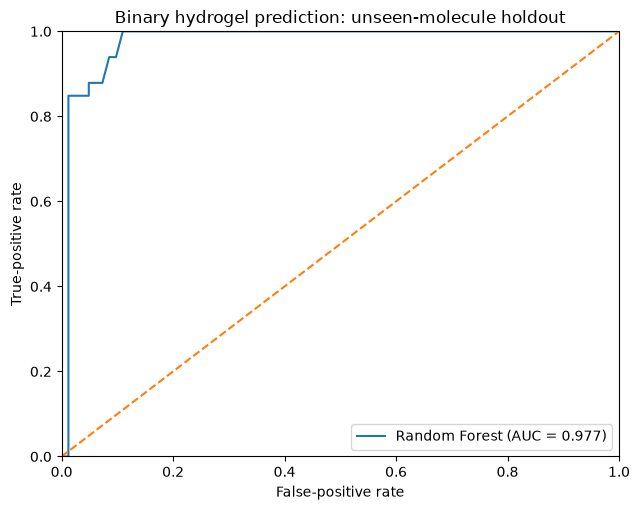

In [188]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_probability)

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {test_roc_auc:.3f})"
)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title("Binary hydrogel prediction: unseen-molecule holdout")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()


save_publication_figure(fig, "figure_2_binary_holdout_roc")

plt.show()

**Figure 2. Binary hydrogel prediction on the permanent unseen-molecule holdout.**
The ROC curve is computed only after model family, hyperparameters, and classification
threshold were frozen using development data.

### Final Unseen-Molecule Holdout Performance

After completion of target curation, molecular-identity reconstruction,
feature engineering, leakage-controlled validation, nested hyperparameter
optimization, and development-only threshold selection, the frozen Random
Forest model was evaluated once on the permanent unseen-molecule holdout.

The holdout comprised 115 condition-specific observations from 20 molecular
identities that were completely absent from model development.

At the preselected probability threshold of 0.45, the model achieved:

- ROC-AUC = 0.977
- PR-AUC = 0.882
- accuracy = 0.922
- balanced accuracy = 0.945
- F1 = 0.880
- Matthews correlation coefficient = 0.836
- precision = 0.786
- sensitivity = 1.000
- specificity = 0.890

The corresponding confusion matrix contained 73 true negatives, 9 false
positives, 0 false negatives, and 33 true positives.

Molecule-cluster bootstrap analysis was used to quantify uncertainty while
preserving the repeated-measures structure of the holdout. The resulting 95%
confidence intervals were 0.895–0.999 for ROC-AUC, 0.400–0.999 for PR-AUC,
0.870–0.985 for balanced accuracy, 0.588–0.968 for F1, and 0.599–0.944 for MCC.

The unusually strong single-holdout result is interpreted alongside the more
conservative nested cross-validation estimates rather than as the sole measure
of generalization. Nested ROC-AUC values were 0.907 for unseen molecules,
0.840 for unseen publications, and 0.822 under simultaneous molecule and
publication independence.

In [189]:
# ============================================================
# FINAL HOLDOUT ERROR AUDIT
# ============================================================

holdout_errors = (
    holdout_predictions[
        ~holdout_predictions[
            "prediction_correct"
        ]
    ]
    .copy()
)


print("=" * 90)
print("FINAL HOLDOUT ERRORS")
print("=" * 90)

print("Total errors:", len(holdout_errors))

print(
    "False positives:",
    (
        (
            holdout_errors["hydrogel_target"] == 0
        )
        &
        (
            holdout_errors["predicted_class"] == 1
        )
    ).sum()
)

print(
    "False negatives:",
    (
        (
            holdout_errors["hydrogel_target"] == 1
        )
        &
        (
            holdout_errors["predicted_class"] == 0
        )
    ).sum()
)


display(
    holdout_errors[
        [
            "molecular_identity_key",
            "sequence_curated",
            "publication_pmid",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "bulk_state_curated",
            "predicted_hydrogel_probability",
            "predicted_class"
        ]
    ]
    .sort_values(
        "predicted_hydrogel_probability",
        ascending=False
    )
)

FINAL HOLDOUT ERRORS
Total errors: 9
False positives: 9
False negatives: 0


,molecular_identity_key,sequence_curated,publication_pmid,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,bulk_state_curated,predicted_hydrogel_probability,predicted_class
108,FAD|linear_or_unspecified|free|free|none|peptide|none,FAD,28518205,7.03,7.0,25.0,H2O,1.0,non_gel,0.938584,1
106,"GF|linear_or_unspecified|free|free|none|mixture|ndi : 1,4,5,8-naphthalenetetracarboxylic acid diimide",GF,25229206,20.00,7.4,25.0,H2O,1.0,non_gel,0.814487,1
112,HFF|linear_or_unspecified|free|free|none|peptide|none,HFF,28630961,20.00,7.0,49.5,PB,1.0,non_gel,0.803525,1
113,HFF|linear_or_unspecified|free|free|none|peptide|none,HFF,28630961,20.00,7.0,54.0,PB,1.0,non_gel,0.788211,1
107,"GG|linear_or_unspecified|free|free|none|mixture|ndi : 1,4,5,8-naphthalenetetracarboxylic acid diimide",GG,25229206,20.00,7.4,25.0,H2O,1.0,non_gel,0.624722,1
7,PW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,PW,18052148,24.00,7.0,25.0,H2O,1.0,non_gel,0.606643,1
6,PW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,PW,18052148,27.00,7.0,25.0,H2O,1.0,non_gel,0.606624,1
3,WP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,WP,18052148,56.00,7.0,25.0,H2O,1.0,non_gel,0.587943,1
2,WP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,WP,18052148,63.00,7.0,25.0,H2O,1.0,non_gel,0.586656,1


In [190]:
# ============================================================
# HOLDOUT PERFORMANCE BY MOLECULAR IDENTITY
# ============================================================

molecule_holdout_summary = (
    holdout_predictions
    .groupby(
        "molecular_identity_key"
    )
    .agg(
        sequence=(
            "sequence_curated",
            "first"
        ),

        publication_pmid=(
            "publication_pmid",
            "first"
        ),

        n_conditions=(
            "hydrogel_target",
            "size"
        ),

        n_true_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        n_predicted_hydrogel=(
            "predicted_class",
            "sum"
        ),

        n_correct=(
            "prediction_correct",
            "sum"
        ),

        mean_predicted_probability=(
            "predicted_hydrogel_probability",
            "mean"
        ),

        min_predicted_probability=(
            "predicted_hydrogel_probability",
            "min"
        ),

        max_predicted_probability=(
            "predicted_hydrogel_probability",
            "max"
        )
    )
    .reset_index()
)


molecule_holdout_summary[
    "condition_accuracy"
] = (
    molecule_holdout_summary[
        "n_correct"
    ]
    /
    molecule_holdout_summary[
        "n_conditions"
    ]
)


display(
    molecule_holdout_summary
    .sort_values(
        [
            "condition_accuracy",
            "n_conditions"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(3)
)

,molecular_identity_key,sequence,publication_pmid,n_conditions,n_true_hydrogel,n_predicted_hydrogel,n_correct,mean_predicted_probability,min_predicted_probability,max_predicted_probability,condition_accuracy
5,FAD|linear_or_unspecified|free|free|none|peptide|none,FAD,28518205,1,0,1,0,0.939,0.939,0.939,0.0
13,PW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,PW,18052148,4,2,4,2,0.607,0.607,0.607,0.5
19,WP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,WP,18052148,4,2,4,2,0.587,0.587,0.588,0.5
8,"GF|linear_or_unspecified|free|free|none|mixture|ndi : 1,4,5,8-naphthalenetetracarboxylic acid diimide",GF,25229206,2,1,2,1,0.859,0.814,0.904,0.5
9,"GG|linear_or_unspecified|free|free|none|mixture|ndi : 1,4,5,8-naphthalenetetracarboxylic acid diimide",GG,25229206,2,1,2,1,0.668,0.625,0.711,0.5
10,HFF|linear_or_unspecified|free|free|none|peptide|none,HFF,28630961,5,3,5,3,0.816,0.788,0.845,0.6
6,FF|linear_or_unspecified|napthalene|free|none|conjugate|napthalene,FF,25068387,24,24,24,24,0.918,0.902,0.924,1.0
3,AGV|linear_or_unspecified|boc|benzylation|none|peptide|none,AGV,20460796,9,0,0,9,0.000,0.000,0.000,1.0
16,VAV|linear_or_unspecified|boc|benzylation|none|peptide|none,VAV,20460796,9,0,0,9,0.000,0.000,0.000,1.0
17,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,20460796,9,0,0,9,0.000,0.000,0.000,1.0


In [191]:
# ============================================================
# ERROR CONCENTRATION BY MOLECULE
# ============================================================

error_by_molecule = (
    holdout_errors
    .groupby(
        [
            "molecular_identity_key",
            "sequence_curated"
        ]
    )
    .size()
    .reset_index(
        name="n_errors"
    )
    .sort_values(
        "n_errors",
        ascending=False
    )
)


print("=" * 90)
print("ERROR CONCENTRATION")
print("=" * 90)

print(
    "Molecules represented among the 9 errors:",
    holdout_errors[
        "molecular_identity_key"
    ].nunique()
)

display(error_by_molecule)

ERROR CONCENTRATION
Molecules represented among the 9 errors: 6


,molecular_identity_key,sequence_curated,n_errors
4,PW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,PW,2
3,HFF|linear_or_unspecified|free|free|none|peptide|none,HFF,2
5,WP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,WP,2
0,FAD|linear_or_unspecified|free|free|none|peptide|none,FAD,1
1,"GF|linear_or_unspecified|free|free|none|mixture|ndi : 1,4,5,8-naphthalenetetracarboxylic acid diimide",GF,1
2,"GG|linear_or_unspecified|free|free|none|mixture|ndi : 1,4,5,8-naphthalenetetracarboxylic acid diimide",GG,1


In [192]:
# ============================================================
# HOLDOUT PERFORMANCE:
# SEEN-PUBLICATION vs UNSEEN-PUBLICATION MOLECULES
# ============================================================

development_publications = set(
    train_model_data[
        "publication_pmid"
    ]
)


holdout_predictions[
    "publication_familiarity"
] = np.where(
    holdout_predictions[
        "publication_pmid"
    ].isin(
        development_publications
    ),
    "publication_seen_in_development",
    "publication_unseen"
)


publication_familiarity_summary = (
    holdout_predictions
    .groupby(
        "publication_familiarity"
    )
    .agg(
        n_rows=(
            "hydrogel_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        n_correct=(
            "prediction_correct",
            "sum"
        )
    )
    .reset_index()
)


publication_familiarity_summary[
    "accuracy"
] = (
    publication_familiarity_summary[
        "n_correct"
    ]
    /
    publication_familiarity_summary[
        "n_rows"
    ]
)


display(
    publication_familiarity_summary
    .round(3)
)


for familiarity, group in (
    holdout_predictions
    .groupby(
        "publication_familiarity"
    )
):

    print("\n" + "=" * 90)
    print(familiarity)
    print("=" * 90)

    print("Rows:", len(group))

    print(
        "Molecules:",
        group[
            "molecular_identity_key"
        ].nunique()
    )

    if (
        group["hydrogel_target"]
        .nunique()
        == 2
    ):

        print(
            "ROC-AUC:",
            round(
                roc_auc_score(
                    group[
                        "hydrogel_target"
                    ],
                    group[
                        "predicted_hydrogel_probability"
                    ]
                ),
                3
            )
        )

        print(
            "PR-AUC:",
            round(
                average_precision_score(
                    group[
                        "hydrogel_target"
                    ],
                    group[
                        "predicted_hydrogel_probability"
                    ]
                ),
                3
            )
        )

    else:

        print(
            "ROC-AUC/PR-AUC not calculated: "
            "subgroup contains only one target class."
        )

,publication_familiarity,n_rows,n_molecules,n_hydrogel,n_correct,accuracy
0,publication_seen_in_development,85,17,6,78,0.918
1,publication_unseen,30,3,27,28,0.933



publication_seen_in_development
Rows: 85
Molecules: 17
ROC-AUC: 0.947
PR-AUC: 0.469

publication_unseen
Rows: 30
Molecules: 3
ROC-AUC: 1.0
PR-AUC: 1.0


In [193]:
# ============================================================
# FINAL MODEL — PROBABILITY CALIBRATION METRICS
# ============================================================

from sklearn.metrics import (
    brier_score_loss,
    log_loss
)


test_brier = brier_score_loss(
    y_test,
    test_probability
)

test_log_loss = log_loss(
    y_test,
    test_probability
)


print("=" * 90)
print("FINAL HOLDOUT — PROBABILITY QUALITY")
print("=" * 90)

print(
    "Brier score:",
    round(test_brier, 4)
)

print(
    "Log loss:",
    round(test_log_loss, 4)
)

print(
    "Mean predicted hydrogel probability:",
    round(
        test_probability.mean(),
        4
    )
)

print(
    "Observed hydrogel prevalence:",
    round(
        y_test.mean(),
        4
    )
)

FINAL HOLDOUT — PROBABILITY QUALITY
Brier score: 0.0493
Log loss: 0.1542
Mean predicted hydrogel probability: 0.3059
Observed hydrogel prevalence: 0.287


In [194]:
# ============================================================
# CALIBRATION BIN TABLE
# ============================================================

calibration_data = pd.DataFrame(
    {
        "true_label": y_test.to_numpy(),
        "predicted_probability":
            test_probability
    }
)


calibration_data[
    "probability_bin"
] = pd.cut(
    calibration_data[
        "predicted_probability"
    ],
    bins=np.linspace(
        0,
        1,
        11
    ),
    include_lowest=True
)


calibration_summary = (
    calibration_data
    .groupby(
        "probability_bin",
        observed=False
    )
    .agg(
        n_records=(
            "true_label",
            "size"
        ),

        mean_predicted_probability=(
            "predicted_probability",
            "mean"
        ),

        observed_hydrogel_fraction=(
            "true_label",
            "mean"
        )
    )
    .reset_index()
)


display(
    calibration_summary.round(3)
)

,probability_bin,n_records,mean_predicted_probability,observed_hydrogel_fraction
0,"(-0.001, 0.1]",72,0.002,0.000
1,"(0.1, 0.2]",1,0.190,0.000
2,"(0.2, 0.3]",0,NaN,NaN
3,"(0.3, 0.4]",0,NaN,NaN
4,"(0.4, 0.5]",0,NaN,NaN
5,"(0.5, 0.6]",4,0.587,0.500
6,"(0.6, 0.7]",5,0.610,0.400
7,"(0.7, 0.8]",2,0.749,0.500
8,"(0.8, 0.9]",5,0.821,0.600
9,"(0.9, 1.0]",26,0.918,0.962


In [195]:
# ============================================================
# FINAL MODEL — HOLDOUT PERMUTATION IMPORTANCE
# INTERPRETATION ONLY
# ============================================================

from sklearn.inspection import permutation_importance


permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test,

    scoring="average_precision",

    n_repeats=30,

    random_state=2026,

    n_jobs=-1
)


permutation_summary = pd.DataFrame(
    {
        "feature":
            X_test.columns,

        "importance_mean":
            permutation_result
            .importances_mean,

        "importance_std":
            permutation_result
            .importances_std
    }
)


permutation_summary = (
    permutation_summary
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("PERMUTATION IMPORTANCE — FINAL HOLDOUT")
print("=" * 90)

display(
    permutation_summary
    .head(30)
    .round(4)
)

PERMUTATION IMPORTANCE — FINAL HOLDOUT


,feature,importance_mean,importance_std
0,aqueous_fraction,0.2631,0.0600
1,aa_fraction_V,0.0004,0.0016
2,aa_fraction_R,0.0001,0.0005
3,non_terminal_curated,0.0000,0.0000
4,pep_negative_fraction,0.0000,0.0000
5,aa_fraction_D,0.0000,0.0000
6,pep_polar_fraction,0.0000,0.0000
7,pep_noncanonical_fraction,0.0000,0.0000
8,aa_fraction_C,0.0000,0.0000
9,x_total_carbon_count,0.0000,0.0000


In [196]:
# ============================================================
# AQUEOUS FRACTION × TARGET AUDIT
# ============================================================

aqueous_target_summary = (
    hydrogel_ml
    .groupby(
        "aqueous_phase_fraction"
    )
    .agg(
        n_records=(
            "hydrogel_target",
            "size"
        ),

        n_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        n_non_gel=(
            "hydrogel_target",
            lambda x: (x == 0).sum()
        ),

        hydrogel_fraction=(
            "hydrogel_target",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "aqueous_phase_fraction"
    )
)


print("=" * 90)
print("AQUEOUS FRACTION × HYDROGEL TARGET")
print("=" * 90)

display(
    aqueous_target_summary
    .round(3)
)

AQUEOUS FRACTION × HYDROGEL TARGET


,aqueous_phase_fraction,n_records,n_hydrogel,n_non_gel,hydrogel_fraction
0,0.00,230,0,230,0.000
1,0.10,15,0,15,0.000
2,0.20,13,0,13,0.000
3,0.30,11,0,11,0.000
4,0.40,6,0,6,0.000
5,0.50,3,0,3,0.000
6,0.60,3,1,2,0.333
7,0.70,1,0,1,0.000
8,0.80,21,8,13,0.381
9,0.90,1,0,1,0.000


In [197]:
# ============================================================
# FULLY AQUEOUS PRIMARY-TASK SUBSET
# ============================================================

fully_aqueous_primary = (
    hydrogel_ml[
        hydrogel_ml[
            "aqueous_phase_fraction"
        ] == 1.0
    ]
    .copy()
)


print("=" * 90)
print("FULLY AQUEOUS PRIMARY-TASK SUBSET")
print("=" * 90)

print(
    "Rows:",
    len(fully_aqueous_primary)
)

print(
    "Molecules:",
    fully_aqueous_primary[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Publications:",
    fully_aqueous_primary[
        "publication_pmid"
    ].nunique()
)

print("\nTarget distribution:")

display(
    fully_aqueous_primary[
        "hydrogel_target"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("hydrogel_target")
    .reset_index(
        name="n_records"
    )
)

print(
    "\nHydrogel prevalence:",
    round(
        fully_aqueous_primary[
            "hydrogel_target"
        ].mean() * 100,
        2
    ),
    "%"
)

FULLY AQUEOUS PRIMARY-TASK SUBSET
Rows: 266
Molecules: 60
Publications: 32

Target distribution:


,hydrogel_target,n_records
0,0,109
1,1,157



Hydrogel prevalence: 59.02 %


In [198]:
# ============================================================
# FEATURE-BLOCK PERMUTATION IMPORTANCE
# FINAL HOLDOUT — INTERPRETATION ONLY
# ============================================================

from sklearn.metrics import average_precision_score

rng = np.random.default_rng(2026)

baseline_pr_auc = average_precision_score(
    y_test,
    test_probability
)


feature_blocks = {

    "sequence_physicochemistry":
        sequence_descriptor_columns,

    "molecular_modifications":
        molecular_categorical_columns,

    "solvent_identity_and_composition": [
        "solvent_component_1",
        "solvent_component_2",
        "solvent_fraction_1",
        "solvent_fraction_2",
        "aqueous_fraction",
        "has_second_solvent_component",
        "solvent_environment_audit"
    ],

    "non_solvent_experimental_conditions": [
        "concentration(mg/ml)",
        "PH",
        "temperature",
        "incubation period (min)",
        "incubation_missing",
        "heating_cooling_binary"
    ]
}


block_results = []


for block_name, block_columns in (
    feature_blocks.items()
):

    score_drops = []

    for repeat in range(30):

        X_permuted = X_test.copy()

        permutation_index = (
            rng.permutation(
                len(X_permuted)
            )
        )

        # Shuffle entire block together so relationships
        # inside the block are retained while its association
        # with the outcome is destroyed.
        X_permuted.loc[
            :,
            block_columns
        ] = (
            X_permuted[
                block_columns
            ]
            .iloc[
                permutation_index
            ]
            .to_numpy()
        )

        permuted_probability = (
            final_model
            .predict_proba(
                X_permuted
            )[:, 1]
        )

        permuted_pr_auc = (
            average_precision_score(
                y_test,
                permuted_probability
            )
        )

        score_drops.append(
            baseline_pr_auc
            -
            permuted_pr_auc
        )


    block_results.append(
        {
            "feature_block":
                block_name,

            "importance_mean":
                np.mean(
                    score_drops
                ),

            "importance_std":
                np.std(
                    score_drops
                )
        }
    )


block_permutation_importance = (
    pd.DataFrame(
        block_results
    )
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("FEATURE-BLOCK PERMUTATION IMPORTANCE")
print("=" * 90)

display(
    block_permutation_importance
    .round(4)
)

FEATURE-BLOCK PERMUTATION IMPORTANCE


,feature_block,importance_mean,importance_std
0,solvent_identity_and_composition,0.2999,0.0681
1,non_solvent_experimental_conditions,0.0081,0.0412
2,sequence_physicochemistry,-0.0138,0.0376
3,molecular_modifications,-0.0391,0.0309


### Figure 3 — Feature-block permutation importance

Importance is measured as the decrease in holdout PR-AUC after jointly permuting each
feature block. This is an interpretation analysis, not a model-selection step.

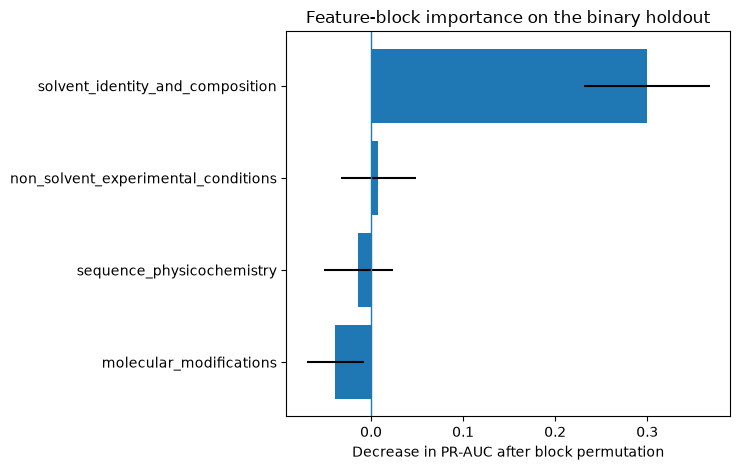

In [199]:
import matplotlib.pyplot as plt

plot_block_importance = (
    block_permutation_importance
    .sort_values("importance_mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(
    plot_block_importance["feature_block"],
    plot_block_importance["importance_mean"],
    xerr=plot_block_importance["importance_std"]
)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Decrease in PR-AUC after block permutation")
ax.set_ylabel("")
ax.set_title("Feature-block importance on the binary holdout")

plt.tight_layout()


save_publication_figure(fig, "figure_3_feature_block_importance")

plt.show()

**Figure 3. Feature-block permutation importance for the final binary model.**
The decrease in PR-AUC after jointly permuting each block shows that solvent
identity/composition is the dominant transferable information block, while smaller or
negative values indicate limited incremental contribution under this holdout.

In [200]:
# ============================================================
# AQUEOUS FRACTION ALONE — MOLECULE-GROUPED BASELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


aqueous_only_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            )
        )
    ]
)


X_aqueous_only = (
    X_train[
        ["aqueous_fraction"]
    ]
    .copy()
)


aqueous_only_results = evaluate_grouped_cv(
    aqueous_only_pipeline,
    X_aqueous_only,
    y_train,
    groups_train,
    cv_grouped
)


print("=" * 90)
print("AQUEOUS FRACTION ALONE")
print("=" * 90)

display(aqueous_only_results)

display(
    aqueous_only_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

AQUEOUS FRACTION ALONE


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.937576,0.760373,0.893939,0.781250,0.710669
1,2,0.688406,0.358209,0.644928,0.494845,0.308699
2,3,0.738089,0.512477,0.705504,0.641791,0.430421
3,4,0.888889,0.631579,0.888889,0.774194,0.700877
4,5,0.932836,0.727273,0.910448,0.800000,0.739773


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.837,0.598,0.809,0.698,0.578
std,0.116,0.165,0.124,0.130,0.196


In [201]:
# ============================================================
# FIXED RANDOM FOREST — NO SOLVENT FEATURES
# DEVELOPMENT-ONLY ABLATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier


non_solvent_numeric_features = (
    sequence_descriptor_columns
    +
    [
        "concentration(mg/ml)",
        "PH",
        "temperature",
        "incubation period (min)",
        "incubation_missing",
        "heating_cooling_binary"
    ]
)


non_solvent_categorical_features = (
    molecular_categorical_columns
)


non_solvent_preprocessor = make_preprocessor(
    non_solvent_numeric_features,
    non_solvent_categorical_features
)


rf_no_solvent_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            non_solvent_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=1200,
                min_samples_split=12,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=8,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


X_no_solvent = X_train[
    non_solvent_numeric_features
    +
    non_solvent_categorical_features
].copy()


rf_no_solvent_results = evaluate_grouped_cv(
    rf_no_solvent_pipeline,
    X_no_solvent,
    y_train,
    groups_train,
    cv_grouped
)


print("=" * 90)
print("RANDOM FOREST — SOLVENT BLOCK REMOVED")
print("=" * 90)

display(
    rf_no_solvent_results
)

display(
    rf_no_solvent_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

RANDOM FOREST — SOLVENT BLOCK REMOVED


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.814545,0.662169,0.780909,0.647059,0.502323
1,2,0.880737,0.723463,0.739130,0.603774,0.451758
2,3,0.526561,0.359738,0.452766,0.403226,-0.093102
3,4,0.990741,0.975711,0.955357,0.920000,0.889214
4,5,0.943097,0.813458,0.830224,0.750000,0.660448


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.831,0.707,0.752,0.665,0.482
std,0.183,0.227,0.186,0.190,0.364


In [202]:
# ============================================================
# FULLY AQUEOUS DEVELOPMENT DATASET
# ============================================================

fully_aqueous_train_mask = (
    train_model_data[
        "aqueous_fraction"
    ] == 1.0
)


X_train_aqueous = (
    X_train.loc[
        fully_aqueous_train_mask
    ]
    .copy()
)

y_train_aqueous = (
    y_train.loc[
        fully_aqueous_train_mask
    ]
    .copy()
)

groups_train_aqueous = (
    groups_train.loc[
        fully_aqueous_train_mask
    ]
    .copy()
)


print("=" * 90)
print("FULLY AQUEOUS DEVELOPMENT DATASET")
print("=" * 90)

print(
    "Rows:",
    len(X_train_aqueous)
)

print(
    "Molecules:",
    groups_train_aqueous.nunique()
)

print(
    "Non-gel:",
    (y_train_aqueous == 0).sum()
)

print(
    "Hydrogel:",
    (y_train_aqueous == 1).sum()
)

print(
    "Hydrogel prevalence:",
    round(
        y_train_aqueous.mean() * 100,
        2
    ),
    "%"
)

FULLY AQUEOUS DEVELOPMENT DATASET
Rows: 224
Molecules: 53
Non-gel: 100
Hydrogel: 124
Hydrogel prevalence: 55.36 %


In [203]:
# ============================================================
# FULLY AQUEOUS — UNSEEN-MOLECULE CV
# FIXED RANDOM FOREST ARCHITECTURE
# ============================================================

cv_fully_aqueous = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


aqueous_cv_structure = []


for fold, (tr_idx, val_idx) in enumerate(
    cv_fully_aqueous.split(
        X_train_aqueous,
        y_train_aqueous,
        groups_train_aqueous
    ),
    start=1
):

    train_mols = set(
        groups_train_aqueous.iloc[
            tr_idx
        ]
    )

    val_mols = set(
        groups_train_aqueous.iloc[
            val_idx
        ]
    )

    aqueous_cv_structure.append(
        {
            "fold": fold,

            "n_train_rows":
                len(tr_idx),

            "n_validation_rows":
                len(val_idx),

            "n_train_molecules":
                len(train_mols),

            "n_validation_molecules":
                len(val_mols),

            "molecular_overlap":
                len(
                    train_mols
                    & val_mols
                ),

            "validation_hydrogel_rate":
                y_train_aqueous.iloc[
                    val_idx
                ].mean()
        }
    )


aqueous_cv_structure = pd.DataFrame(
    aqueous_cv_structure
)


display(
    aqueous_cv_structure.round(3)
)

assert (
    aqueous_cv_structure[
        "molecular_overlap"
    ] == 0
).all()

,fold,n_train_rows,n_validation_rows,n_train_molecules,n_validation_molecules,molecular_overlap,validation_hydrogel_rate
0,1,174,50,45,8,0,0.320
1,2,158,66,43,10,0,0.591
2,3,188,36,41,12,0,0.639
3,4,187,37,39,14,0,0.649
4,5,189,35,44,9,0,0.629


In [204]:
fully_aqueous_rf_results = evaluate_grouped_cv(
    final_rf_pipeline,
    X_train_aqueous,
    y_train_aqueous,
    groups_train_aqueous,
    cv_fully_aqueous
)


print("=" * 90)
print("FULLY AQUEOUS HYDROGEL PREDICTION")
print("=" * 90)

display(
    fully_aqueous_rf_results
)

print("\nMean ± SD:")

display(
    fully_aqueous_rf_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

FULLY AQUEOUS HYDROGEL PREDICTION


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.704044,0.782419,0.812500,0.769231,0.728869
1,2,0.727920,0.806486,0.566952,0.755102,0.213811
2,3,0.797659,0.890496,0.792642,0.809524,0.563120
3,4,0.737179,0.794011,0.612179,0.800000,0.290579
4,5,0.526224,0.709030,0.426573,0.558140,-0.144841



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.699,0.796,0.642,0.738,0.330
std,0.102,0.065,0.162,0.103,0.337


In [205]:
# ============================================================
# SOLVENT-SHORTCUT SENSITIVITY SUMMARY
# ============================================================

solvent_sensitivity_summary = pd.DataFrame(
    [
        summarize_model_results(
            "Aqueous_fraction_only",
            aqueous_only_results
        ),

        summarize_model_results(
            "RF_without_solvent_block",
            rf_no_solvent_results
        ),

        summarize_model_results(
            "RF_fully_aqueous_only",
            fully_aqueous_rf_results
        ),

        summarize_model_results(
            "RF_full_primary_task",
            rf_nested_results
        )
    ]
)


display(
    solvent_sensitivity_summary[
        [
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .round(3)
)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
0,Aqueous_fraction_only,0.837,0.116,0.598,0.165,0.809,0.698,0.578
1,RF_without_solvent_block,0.831,0.183,0.707,0.227,0.752,0.665,0.482
2,RF_fully_aqueous_only,0.699,0.102,0.796,0.065,0.642,0.738,0.330
3,RF_full_primary_task,0.907,0.106,0.811,0.173,0.808,0.722,0.609


In [206]:
# ============================================================
# FULLY AQUEOUS + NO SOLVENT INFORMATION
# STRICT SOLVENT-SHORTCUT SENSITIVITY TEST
# ============================================================

X_train_aqueous_no_solvent = (
    X_train_aqueous[
        non_solvent_numeric_features
        + non_solvent_categorical_features
    ]
    .copy()
)


fully_aqueous_no_solvent_results = evaluate_grouped_cv(
    rf_no_solvent_pipeline,
    X_train_aqueous_no_solvent,
    y_train_aqueous,
    groups_train_aqueous,
    cv_fully_aqueous
)


print("=" * 90)
print("FULLY AQUEOUS + NO SOLVENT FEATURES")
print("=" * 90)

display(
    fully_aqueous_no_solvent_results
)


print("\nMean ± SD:")

display(
    fully_aqueous_no_solvent_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

FULLY AQUEOUS + NO SOLVENT FEATURES


,fold,roc_auc,pr_auc,balanced_accuracy,f1,mcc
0,1,0.704044,0.783361,0.843750,0.814815,0.774183
1,2,0.731719,0.801061,0.566952,0.755102,0.213811
2,3,0.797659,0.891917,0.770903,0.780488,0.520483
3,4,0.721154,0.807078,0.594551,0.807018,0.290729
4,5,0.517483,0.715853,0.426573,0.558140,-0.144841



Mean ± SD:


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.694,0.800,0.641,0.743,0.331
std,0.105,0.063,0.167,0.106,0.344


In [207]:
# ============================================================
# FULLY AQUEOUS — MOLECULAR INFORMATION ONLY
# ============================================================

aqueous_molecule_numeric = (
    sequence_descriptor_columns
)

aqueous_molecule_categorical = (
    molecular_categorical_columns
)


aqueous_molecule_preprocessor = make_preprocessor(
    aqueous_molecule_numeric,
    aqueous_molecule_categorical
)


aqueous_molecule_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            aqueous_molecule_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=1200,
                min_samples_split=12,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=8,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


X_aqueous_molecule = (
    X_train_aqueous[
        aqueous_molecule_numeric
        + aqueous_molecule_categorical
    ]
    .copy()
)


aqueous_molecule_results = evaluate_grouped_cv(
    aqueous_molecule_rf,
    X_aqueous_molecule,
    y_train_aqueous,
    groups_train_aqueous,
    cv_fully_aqueous
)


print("=" * 90)
print("FULLY AQUEOUS — MOLECULE ONLY")
print("=" * 90)

display(
    aqueous_molecule_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

FULLY AQUEOUS — MOLECULE ONLY


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.445,0.601,0.436,0.628,-0.144
std,0.277,0.221,0.134,0.214,0.339


In [208]:
# ============================================================
# FULLY AQUEOUS — NON-SOLVENT CONDITIONS ONLY
# ============================================================

aqueous_condition_only_features = [
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "incubation period (min)",
    "incubation_missing",
    "heating_cooling_binary"
]


aqueous_condition_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]
            ),
            aqueous_condition_only_features
        )
    ],
    remainder="drop"
)


aqueous_condition_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            aqueous_condition_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=1200,
                min_samples_split=12,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=8,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


X_aqueous_condition = (
    X_train_aqueous[
        aqueous_condition_only_features
    ]
    .copy()
)


aqueous_condition_results = evaluate_grouped_cv(
    aqueous_condition_rf,
    X_aqueous_condition,
    y_train_aqueous,
    groups_train_aqueous,
    cv_fully_aqueous
)


print("=" * 90)
print("FULLY AQUEOUS — CONDITIONS ONLY")
print("=" * 90)

display(
    aqueous_condition_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

FULLY AQUEOUS — CONDITIONS ONLY


,roc_auc,pr_auc,balanced_accuracy,f1,mcc
mean,0.764,0.852,0.673,0.785,0.398
std,0.188,0.116,0.201,0.143,0.403


In [209]:
# ============================================================
# FULLY AQUEOUS — INFORMATION-SOURCE COMPARISON
# ============================================================

fully_aqueous_ablation = pd.DataFrame(
    [
        summarize_model_results(
            "Molecule_only",
            aqueous_molecule_results
        ),

        summarize_model_results(
            "Non_solvent_conditions_only",
            aqueous_condition_results
        ),

        summarize_model_results(
            "Molecule_plus_non_solvent_conditions",
            fully_aqueous_no_solvent_results
        ),

        summarize_model_results(
            "Molecule_conditions_plus_aqueous_solvent_identity",
            fully_aqueous_rf_results
        )
    ]
)


display(
    fully_aqueous_ablation[
        [
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
    .round(3)
)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
1,Non_solvent_conditions_only,0.764,0.188,0.852,0.116,0.673,0.785,0.398
3,Molecule_conditions_plus_aqueous_solvent_identity,0.699,0.102,0.796,0.065,0.642,0.738,0.330
2,Molecule_plus_non_solvent_conditions,0.694,0.105,0.800,0.063,0.641,0.743,0.331
0,Molecule_only,0.445,0.277,0.601,0.221,0.436,0.628,-0.144


### Table 3 — Fully aqueous information-source ablation

In [210]:
display(
    fully_aqueous_ablation[
        [
            "model",
            "roc_auc_mean",
            "roc_auc_std",
            "pr_auc_mean",
            "pr_auc_std",
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ]
    ]
    .sort_values("roc_auc_mean", ascending=False)
    .round(3)
)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,f1_mean,mcc_mean
1,Non_solvent_conditions_only,0.764,0.188,0.852,0.116,0.673,0.785,0.398
3,Molecule_conditions_plus_aqueous_solvent_identity,0.699,0.102,0.796,0.065,0.642,0.738,0.330
2,Molecule_plus_non_solvent_conditions,0.694,0.105,0.800,0.063,0.641,0.743,0.331
0,Molecule_only,0.445,0.277,0.601,0.221,0.436,0.628,-0.144


### Solvent-Shortcut and Fully Aqueous Sensitivity Analysis

Permutation analysis identified solvent composition, particularly aqueous
fraction, as the dominant unique predictor in the broad hydrogel-versus-non-gel
task. Aqueous fraction alone achieved a molecule-grouped ROC-AUC of 0.837,
confirming that solvent environment provides substantial first-order
information regarding hydrogel feasibility.

However, removing the complete solvent feature block still yielded a
Random Forest ROC-AUC of 0.831, demonstrating that predictive information also
exists in molecular and non-solvent experimental variables.

A stricter analysis was subsequently restricted to 224 fully aqueous
development observations from 53 molecular identities, eliminating aqueous
fraction as a discriminatory variable. Within this subset, a fixed Random
Forest using molecular and non-solvent experimental features achieved a
molecule-grouped ROC-AUC of 0.694 and PR-AUC of 0.800.

Ablation of the fully aqueous task showed that non-solvent experimental
conditions alone provided the strongest transferable signal
(ROC-AUC = 0.764, PR-AUC = 0.852), whereas the present molecular descriptor
representation alone did not generalize reliably to unseen molecules
(ROC-AUC = 0.445).

These findings indicate that solvent composition acts as a major feasibility
constraint in the broad hydrogel task, while concentration, pH, temperature,
incubation and processing conditions retain substantial predictive information
within aqueous environments. The current sequence-derived molecular
representation contributes limited standalone cross-molecule predictive power
within the fully aqueous subset.

In [211]:
# ============================================================
# FULLY AQUEOUS CONDITIONS-ONLY:
# OUT-OF-FOLD PROBABILITIES FOR INTERPRETATION
# ============================================================

aqueous_condition_oof_probability = np.full(
    len(X_train_aqueous),
    np.nan
)


for fold, (tr_idx, val_idx) in enumerate(
    cv_fully_aqueous.split(
        X_aqueous_condition,
        y_train_aqueous,
        groups_train_aqueous
    ),
    start=1
):

    model = clone(
        aqueous_condition_rf
    )

    model.fit(
        X_aqueous_condition.iloc[tr_idx],
        y_train_aqueous.iloc[tr_idx]
    )

    aqueous_condition_oof_probability[val_idx] = (
        model.predict_proba(
            X_aqueous_condition.iloc[val_idx]
        )[:, 1]
    )

    print(
        f"Completed fully aqueous OOF fold {fold}"
    )


assert np.isnan(
    aqueous_condition_oof_probability
).sum() == 0


aqueous_interpretation = (
    train_model_data.loc[
        fully_aqueous_train_mask,
        [
            "molecular_identity_key",
            "sequence_curated",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "incubation period (min)",
            "heating/cooling",
            "hydrogel_target"
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


aqueous_interpretation[
    "oof_hydrogel_probability"
] = (
    aqueous_condition_oof_probability
)


print("=" * 90)
print("FULLY AQUEOUS OOF INTERPRETATION DATA")
print("=" * 90)

print(
    "Rows:",
    len(aqueous_interpretation)
)

print(
    "Molecules:",
    aqueous_interpretation[
        "molecular_identity_key"
    ].nunique()
)

print(
    "OOF probabilities missing:",
    aqueous_interpretation[
        "oof_hydrogel_probability"
    ].isna().sum()
)

Completed fully aqueous OOF fold 1
Completed fully aqueous OOF fold 2
Completed fully aqueous OOF fold 3
Completed fully aqueous OOF fold 4
Completed fully aqueous OOF fold 5
FULLY AQUEOUS OOF INTERPRETATION DATA
Rows: 224
Molecules: 53
OOF probabilities missing: 0


In [212]:
# ============================================================
# CONCENTRATION × HYDROGEL BEHAVIOR
# FULLY AQUEOUS SYSTEMS
# ============================================================

aqueous_interpretation[
    "concentration_bin"
] = pd.qcut(
    aqueous_interpretation[
        "concentration(mg/ml)"
    ],
    q=5,
    duplicates="drop"
)


concentration_response = (
    aqueous_interpretation
    .groupby(
        "concentration_bin",
        observed=True
    )
    .agg(
        n_records=(
            "hydrogel_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        concentration_min=(
            "concentration(mg/ml)",
            "min"
        ),

        concentration_median=(
            "concentration(mg/ml)",
            "median"
        ),

        concentration_max=(
            "concentration(mg/ml)",
            "max"
        ),

        observed_hydrogel_fraction=(
            "hydrogel_target",
            "mean"
        ),

        mean_oof_hydrogel_probability=(
            "oof_hydrogel_probability",
            "mean"
        )
    )
    .reset_index()
)


print("=" * 90)
print("CONCENTRATION RESPONSE — FULLY AQUEOUS")
print("=" * 90)

display(
    concentration_response.round(3)
)

CONCENTRATION RESPONSE — FULLY AQUEOUS


,concentration_bin,n_records,n_molecules,concentration_min,concentration_median,concentration_max,observed_hydrogel_fraction,mean_oof_hydrogel_probability
0,"(0.399, 2.292]",45,6,0.40,0.792,2.25,0.089,0.300
1,"(2.292, 4.028]",45,10,2.32,3.000,4.00,0.422,0.425
2,"(4.028, 5.088]",44,14,4.14,5.000,5.00,0.795,0.786
3,"(5.088, 8.31]",45,15,5.11,6.750,8.25,0.667,0.725
4,"(8.31, 144.0]",45,24,8.40,20.000,144.00,0.800,0.764


### Figure 4 — Concentration dependence within fully aqueous systems

Observed hydrogel frequency and out-of-fold predicted probability are summarized across
concentration quantiles in the fully aqueous development subset.

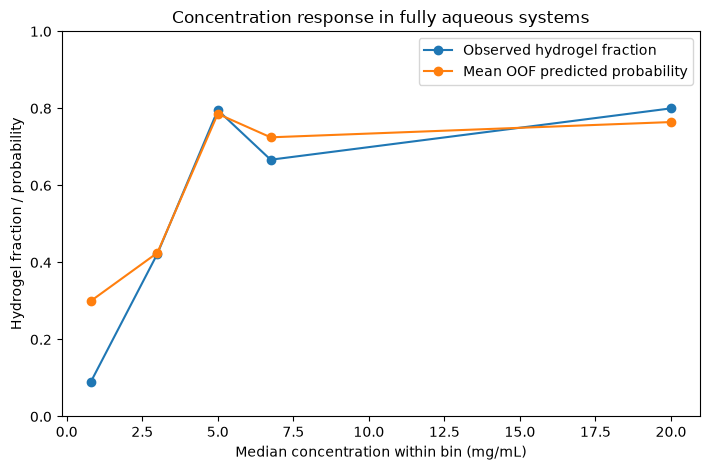

In [213]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.plot(
    concentration_response["concentration_median"],
    concentration_response["observed_hydrogel_fraction"],
    marker="o",
    label="Observed hydrogel fraction"
)

ax.plot(
    concentration_response["concentration_median"],
    concentration_response["mean_oof_hydrogel_probability"],
    marker="o",
    label="Mean OOF predicted probability"
)

ax.set_xlabel("Median concentration within bin (mg/mL)")
ax.set_ylabel("Hydrogel fraction / probability")
ax.set_ylim(0, 1)
ax.set_title("Concentration response in fully aqueous systems")
ax.legend()

plt.tight_layout()


save_publication_figure(fig, "figure_4_fully_aqueous_concentration_response")

plt.show()

**Figure 4. Concentration response within fully aqueous systems.**
Observed hydrogel frequency and out-of-fold predicted probability increase with
concentration across the development-only fully aqueous subset, showing that meaningful
condition dependence remains even after solvent-composition variation is removed.

In [214]:
# ============================================================
# pH × HYDROGEL BEHAVIOR
# FULLY AQUEOUS SYSTEMS
# ============================================================

aqueous_interpretation[
    "pH_bin"
] = pd.cut(
    aqueous_interpretation["PH"],
    bins=[
        -np.inf,
        4,
        6,
        7,
        8,
        10,
        np.inf
    ],
    labels=[
        "<=4",
        "4-6",
        "6-7",
        "7-8",
        "8-10",
        ">10"
    ],
    include_lowest=True
)


pH_response = (
    aqueous_interpretation
    .groupby(
        "pH_bin",
        observed=True
    )
    .agg(
        n_records=(
            "hydrogel_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        mean_pH=(
            "PH",
            "mean"
        ),

        observed_hydrogel_fraction=(
            "hydrogel_target",
            "mean"
        ),

        mean_oof_hydrogel_probability=(
            "oof_hydrogel_probability",
            "mean"
        )
    )
    .reset_index()
)


print("=" * 90)
print("pH RESPONSE — FULLY AQUEOUS")
print("=" * 90)

display(
    pH_response.round(3)
)

pH RESPONSE — FULLY AQUEOUS


,pH_bin,n_records,n_molecules,mean_pH,observed_hydrogel_fraction,mean_oof_hydrogel_probability
0,<=4,23,4,3.383,1.000,0.902
1,4-6,8,7,4.888,0.875,0.761
2,6-7,80,26,6.952,0.412,0.559
3,7-8,93,25,7.475,0.548,0.580
4,8-10,16,5,9.330,0.500,0.452
5,>10,4,3,10.600,0.500,0.363


In [215]:
# ============================================================
# TEMPERATURE × HYDROGEL BEHAVIOR
# FULLY AQUEOUS SYSTEMS
# ============================================================

aqueous_interpretation[
    "temperature_bin"
] = pd.cut(
    aqueous_interpretation[
        "temperature"
    ],
    bins=[
        -np.inf,
        10,
        20,
        25,
        37,
        50,
        np.inf
    ],
    labels=[
        "<=10",
        "10-20",
        "20-25",
        "25-37",
        "37-50",
        ">50"
    ],
    include_lowest=True
)


temperature_response = (
    aqueous_interpretation
    .groupby(
        "temperature_bin",
        observed=True
    )
    .agg(
        n_records=(
            "hydrogel_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        mean_temperature=(
            "temperature",
            "mean"
        ),

        observed_hydrogel_fraction=(
            "hydrogel_target",
            "mean"
        ),

        mean_oof_hydrogel_probability=(
            "oof_hydrogel_probability",
            "mean"
        )
    )
    .reset_index()
)


print("=" * 90)
print("TEMPERATURE RESPONSE — FULLY AQUEOUS")
print("=" * 90)

display(
    temperature_response.round(3)
)

TEMPERATURE RESPONSE — FULLY AQUEOUS


,temperature_bin,n_records,n_molecules,mean_temperature,observed_hydrogel_fraction,mean_oof_hydrogel_probability
0,<=10,18,6,4.444,0.111,0.266
1,10-20,6,1,16.000,0.000,0.356
2,20-25,133,47,24.985,0.744,0.682
3,25-37,11,3,32.818,0.273,0.427
4,37-50,30,2,44.833,0.400,0.613
5,>50,26,2,59.923,0.308,0.516


In [216]:
# ============================================================
# FULLY AQUEOUS CONDITION-SWITCHING MOLECULES
# ============================================================

switching_molecules = (
    aqueous_interpretation
    .groupby(
        "molecular_identity_key"
    )
    .agg(
        sequence=(
            "sequence_curated",
            "first"
        ),

        n_records=(
            "hydrogel_target",
            "size"
        ),

        n_target_states=(
            "hydrogel_target",
            "nunique"
        ),

        n_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        concentration_min=(
            "concentration(mg/ml)",
            "min"
        ),

        concentration_max=(
            "concentration(mg/ml)",
            "max"
        ),

        pH_min=(
            "PH",
            "min"
        ),

        pH_max=(
            "PH",
            "max"
        ),

        temperature_min=(
            "temperature",
            "min"
        ),

        temperature_max=(
            "temperature",
            "max"
        )
    )
    .reset_index()
)


switching_molecules = (
    switching_molecules[
        switching_molecules[
            "n_target_states"
        ] == 2
    ]
    .sort_values(
        "n_records",
        ascending=False
    )
)


print("=" * 90)
print("FULLY AQUEOUS MOLECULES WITH BOTH OUTCOMES")
print("=" * 90)

print(
    "Condition-switching molecules:",
    len(switching_molecules)
)

display(
    switching_molecules.round(3)
)

FULLY AQUEOUS MOLECULES WITH BOTH OUTCOMES
Condition-switching molecules: 15


,molecular_identity_key,sequence,n_records,n_target_states,n_hydrogel,concentration_min,concentration_max,pH_min,pH_max,temperature_min,temperature_max
49,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,44,2,22,2.32,10.44,7.46,7.46,32.5,67.5
4,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,14,2,10,2.40,12.00,6.80,10.00,25.0,25.0
7,FFA|linear_or_unspecified|acetylation|amidation|none|peptide|none,FFA,4,2,2,5.60,8.40,6.12,6.12,25.0,25.0
9,FFA|linear_or_unspecified|napthalene|free|none|peptide|none,FFA,4,2,2,4.00,6.00,7.40,7.40,25.0,25.0
12,FFG|linear_or_unspecified|napthalene|free|none|peptide|none,FFG,4,2,2,2.40,3.60,7.40,7.40,25.0,25.0
13,FFK|linear_or_unspecified|napthalene|free|none|peptide|none,FFK,4,2,2,1.60,2.40,7.40,7.40,25.0,25.0
8,FFA|linear_or_unspecified|boc|free|none|peptide|none,FFA,4,2,2,10.40,15.60,7.00,7.46,25.0,25.0
14,FFS|linear_or_unspecified|napthalene|free|none|peptide|none,FFS,4,2,2,0.64,0.96,7.40,7.40,25.0,25.0
15,FFV|linear_or_unspecified|free|free|none|peptide|none,FFV,4,2,1,6.70,7.00,7.40,7.40,25.0,25.0
31,FW|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,FW,4,2,2,2.00,3.00,7.00,7.00,25.0,25.0


In [217]:
# ============================================================
# CONDITION-SPECIFIC RECORDS FOR SWITCHING MOLECULES
# ============================================================

switching_ids = set(
    switching_molecules[
        "molecular_identity_key"
    ]
)


switching_condition_records = (
    aqueous_interpretation[
        aqueous_interpretation[
            "molecular_identity_key"
        ].isin(
            switching_ids
        )
    ]
    .copy()
    .sort_values(
        [
            "molecular_identity_key",
            "temperature",
            "PH",
            "concentration(mg/ml)"
        ]
    )
)


display(
    switching_condition_records[
        [
            "molecular_identity_key",
            "sequence_curated",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "incubation period (min)",
            "heating/cooling",
            "hydrogel_target",
            "oof_hydrogel_probability"
        ]
    ]
    .round(3)
)

,molecular_identity_key,sequence_curated,concentration(mg/ml),PH,temperature,incubation period (min),heating/cooling,hydrogel_target,oof_hydrogel_probability
118,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,3.00,6.80,25.0,1440.0,No,1,0.270
119,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,3.00,7.34,25.0,1440.0,No,1,0.260
127,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,2.40,7.50,25.0,1440.0,No,0,0.224
126,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,2.70,7.50,25.0,1440.0,No,0,0.219
124,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,3.30,7.50,25.0,1440.0,No,1,0.446
...,...,...,...,...,...,...,...,...,...
63,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,9.00,7.46,65.0,10.0,No,1,0.660
69,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,6.96,7.46,67.5,10.0,No,0,0.590
68,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,7.83,7.46,67.5,10.0,No,0,0.671
66,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,9.57,7.46,67.5,10.0,No,1,0.669


In [218]:
# ============================================================
# FAD HIGH-CONFIDENCE FALSE POSITIVE
# RANDOM-FOREST PROXIMITY ANALYSIS
# ============================================================

# Extract fitted components from frozen final model
final_preprocessor = (
    final_model
    .named_steps["preprocessor"]
)

final_rf_classifier = (
    final_model
    .named_steps["classifier"]
)


# ------------------------------------------------------------
# Transform development and holdout exactly as RF sees them
# ------------------------------------------------------------

X_train_rf = final_preprocessor.transform(
    X_train
)

X_test_rf = final_preprocessor.transform(
    X_test
)


# ------------------------------------------------------------
# Terminal leaf index for every observation in every tree
# ------------------------------------------------------------

train_leaf_matrix = (
    final_rf_classifier
    .apply(X_train_rf)
)

test_leaf_matrix = (
    final_rf_classifier
    .apply(X_test_rf)
)


print("=" * 90)
print("RANDOM FOREST PROXIMITY ANALYSIS")
print("=" * 90)

print(
    "Training leaf matrix:",
    train_leaf_matrix.shape
)

print(
    "Holdout leaf matrix:",
    test_leaf_matrix.shape
)


# ------------------------------------------------------------
# Locate FAD holdout observation
# ------------------------------------------------------------

fad_positions = np.where(
    test_model_data[
        "sequence_curated"
    ]
    .astype(str)
    .eq("FAD")
    .to_numpy()
)[0]


print(
    "\nFAD holdout observations:",
    len(fad_positions)
)


if len(fad_positions) > 0:

    fad_position = fad_positions[0]

    fad_leaf_vector = (
        test_leaf_matrix[
            fad_position
        ]
    )


    # --------------------------------------------------------
    # RF proximity:
    # fraction of trees in which two observations occupy
    # the same terminal leaf
    # --------------------------------------------------------

    rf_proximity = (
        train_leaf_matrix
        ==
        fad_leaf_vector
    ).mean(axis=1)


    top_neighbor_positions = (
        np.argsort(
            rf_proximity
        )[::-1][:20]
    )


    fad_rf_neighbors = (
        train_model_data
        .iloc[
            top_neighbor_positions
        ][
            [
                "molecular_identity_key",
                "sequence_curated",
                "publication_pmid",
                "concentration(mg/ml)",
                "PH",
                "temperature",
                "solution",
                "aqueous_phase_fraction",
                "bulk_state_curated",
                "hydrogel_target"
            ]
        ]
        .copy()
    )


    fad_rf_neighbors.insert(
        0,
        "rf_proximity",
        rf_proximity[
            top_neighbor_positions
        ]
    )


    print("\nFAD holdout observation:")

    display(
        holdout_predictions[
            holdout_predictions[
                "sequence_curated"
            ] == "FAD"
        ]
    )


    print(
        "\nMost similar development observations "
        "according to Random Forest leaf proximity:"
    )

    display(
        fad_rf_neighbors
        .round(3)
    )


    print(
        "\nHydrogel fraction among top 20 "
        "RF-proximity neighbors:"
    )

    print(
        round(
            fad_rf_neighbors[
                "hydrogel_target"
            ].mean(),
            3
        )
    )

RANDOM FOREST PROXIMITY ANALYSIS
Training leaf matrix: (489, 1200)
Holdout leaf matrix: (115, 1200)

FAD holdout observations: 1

FAD holdout observation:


,molecular_identity_key,sequence_curated,publication_pmid,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,bulk_state_curated,hydrogel_target,predicted_hydrogel_probability,predicted_class,prediction_correct,publication_familiarity
108,FAD|linear_or_unspecified|free|free|none|peptide|none,FAD,28518205,7.03,7.0,25.0,H2O,1.0,non_gel,0,0.938584,1,False,publication_seen_in_development



Most similar development observations according to Random Forest leaf proximity:


,rf_proximity,molecular_identity_key,sequence_curated,publication_pmid,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,bulk_state_curated,hydrogel_target
447,0.913,FVD|linear_or_unspecified|free|free|none|peptide|none,FVD,28518205,7.59,7.00,25.0,H2O,1.0,hydrogel,1
223,0.862,VIE|linear_or_unspecified|acetylation|free|none|peptide|none,VIE,25010703,5.00,7.00,25.0,H2O,1.0,hydrogel,1
231,0.835,IVD|linear_or_unspecified|acetylation|free|none|peptide|none,IVD,22016623,11.00,7.00,25.0,H2O,1.0,hydrogel,1
232,0.833,IVD|linear_or_unspecified|acetylation|free|none|peptide|none,IVD,22016623,12.00,7.00,25.0,H2O,1.0,hydrogel,1
235,0.822,IVD|linear_or_unspecified|acetylation|free|none|peptide|none,IVD,23267112,4.14,7.00,25.0,H2O,1.0,hydrogel,1
449,0.805,FLD|linear_or_unspecified|free|free|none|peptide|none,FLD,28518205,7.87,7.00,25.0,H2O,1.0,hydrogel,1
448,0.799,FID|linear_or_unspecified|free|free|none|peptide|none,FID,28518205,7.87,7.00,25.0,H2O,1.0,hydrogel,1
450,0.786,FVD|linear_or_unspecified|free|free|none|peptide|none,FVD,28518205,7.59,7.40,25.0,PBS,1.0,hydrogel,1
224,0.750,VIE|linear_or_unspecified|acetylation|free|none|peptide|none,VIE,25010703,10.00,7.00,25.0,H2O,1.0,hydrogel,1
221,0.719,MYD|linear_or_unspecified|acetylation|free|none|peptide|none,MYD,25010703,5.00,7.00,25.0,H2O,1.0,hydrogel,1



Hydrogel fraction among top 20 RF-proximity neighbors:
1.0


In [219]:
# ============================================================
# FAD ANALOGUE FAMILY — PMID 28518205
# ============================================================

fad_family_sequences = [
    "FAD",
    "FVD",
    "FID",
    "FLD"
]


# Combine development + holdout ONLY for interpretation.
# We are NOT retraining or changing the final model.
fad_family_all = pd.concat(
    [
        train_model_data.assign(
            dataset_partition="development"
        ),

        test_model_data.assign(
            dataset_partition="holdout"
        )
    ],
    ignore_index=True
)


# Restrict to the relevant publication and molecular family
fad_family = (
    fad_family_all[
        (
            fad_family_all[
                "publication_pmid"
            ] == 28518205
        )
        &
        (
            fad_family_all[
                "sequence_curated"
            ].isin(
                fad_family_sequences
            )
        )
    ]
    .copy()
)


print("=" * 90)
print("FAD / FVD / FID / FLD ANALOGUE FAMILY")
print("=" * 90)

print(
    "Condition-specific rows:",
    len(fad_family)
)

print(
    "Sequences represented:",
    sorted(
        fad_family[
            "sequence_curated"
        ].unique()
    )
)

print(
    "Development rows:",
    (
        fad_family[
            "dataset_partition"
        ] == "development"
    ).sum()
)

print(
    "Holdout rows:",
    (
        fad_family[
            "dataset_partition"
        ] == "holdout"
    ).sum()
)


family_summary = (
    fad_family
    .groupby(
        [
            "sequence_curated",
            "dataset_partition"
        ],
        dropna=False
    )
    .agg(
        n_records=(
            "hydrogel_target",
            "size"
        ),

        n_hydrogel=(
            "hydrogel_target",
            "sum"
        ),

        n_non_gel=(
            "hydrogel_target",
            lambda x: (x == 0).sum()
        ),

        hydrogel_fraction=(
            "hydrogel_target",
            "mean"
        ),

        concentration_min=(
            "concentration(mg/ml)",
            "min"
        ),

        concentration_max=(
            "concentration(mg/ml)",
            "max"
        ),

        pH_min=(
            "PH",
            "min"
        ),

        pH_max=(
            "PH",
            "max"
        ),

        temperature_min=(
            "temperature",
            "min"
        ),

        temperature_max=(
            "temperature",
            "max"
        ),

        aqueous_fraction_min=(
            "aqueous_phase_fraction",
            "min"
        ),

        aqueous_fraction_max=(
            "aqueous_phase_fraction",
            "max"
        )
    )
    .reset_index()
)


display(
    family_summary.round(3)
)

FAD / FVD / FID / FLD ANALOGUE FAMILY
Condition-specific rows: 7
Sequences represented: ['FAD', 'FID', 'FLD', 'FVD']
Development rows: 6
Holdout rows: 1


,sequence_curated,dataset_partition,n_records,n_hydrogel,n_non_gel,hydrogel_fraction,concentration_min,concentration_max,pH_min,pH_max,temperature_min,temperature_max,aqueous_fraction_min,aqueous_fraction_max
0,FAD,holdout,1,0,1,0.0,7.03,7.03,7.0,7.0,25.0,25.0,1.0,1.0
1,FID,development,2,2,0,1.0,7.87,7.87,7.0,7.4,25.0,25.0,1.0,1.0
2,FLD,development,2,2,0,1.0,7.87,7.87,7.0,7.4,25.0,25.0,1.0,1.0
3,FVD,development,2,2,0,1.0,7.59,7.59,7.0,7.4,25.0,25.0,1.0,1.0


In [220]:
# ============================================================
# MOLECULAR DESCRIPTOR CONTRAST:
# FAD vs FVD / FID / FLD
# ============================================================

descriptor_family_rows = []


for seq in fad_family_sequences:

    descriptor = peptide_descriptors(
        seq
    )

    descriptor[
        "sequence"
    ] = seq

    descriptor_family_rows.append(
        descriptor
    )


descriptor_family = pd.DataFrame(
    descriptor_family_rows
)


important_family_descriptors = [
    "sequence",

    "pep_length",

    "pep_approx_core_mw",

    "pep_mean_standard_aa_hydropathy",

    "pep_aromatic_fraction",

    "pep_hydrophobic_standard_fraction",

    "pep_polar_fraction",

    "pep_positive_fraction",

    "pep_negative_fraction",

    "pep_net_charge_proxy",

    "aa_fraction_A",
    "aa_fraction_D",
    "aa_fraction_F",
    "aa_fraction_I",
    "aa_fraction_L",
    "aa_fraction_V"
]


# Keep only descriptor names that actually exist
important_family_descriptors = [
    col
    for col in important_family_descriptors
    if col in descriptor_family.columns
]


print("=" * 90)
print("FAD FAMILY — MOLECULAR DESCRIPTOR CONTRAST")
print("=" * 90)

display(
    descriptor_family[
        important_family_descriptors
    ]
    .round(3)
)

FAD FAMILY — MOLECULAR DESCRIPTOR CONTRAST


,sequence,pep_length,pep_approx_core_mw,pep_mean_standard_aa_hydropathy,pep_aromatic_fraction,pep_hydrophobic_standard_fraction,pep_polar_fraction,pep_positive_fraction,pep_negative_fraction,pep_net_charge_proxy,aa_fraction_A,aa_fraction_D,aa_fraction_F,aa_fraction_I,aa_fraction_L,aa_fraction_V
0,FAD,3,351.35,0.367,0.333,0.667,0.0,0.0,0.333,-1,0.333,0.333,0.333,0.000,0.000,0.000
1,FVD,3,379.41,1.167,0.333,0.667,0.0,0.0,0.333,-1,0.000,0.333,0.333,0.000,0.000,0.333
2,FID,3,393.43,1.267,0.333,0.667,0.0,0.0,0.333,-1,0.000,0.333,0.333,0.333,0.000,0.000
3,FLD,3,393.43,1.033,0.333,0.667,0.0,0.0,0.333,-1,0.000,0.333,0.333,0.000,0.333,0.000


In [221]:
# ============================================================
# FROZEN RF VIEW OF THE FAD ANALOGUE FAMILY
# INTERPRETATION ONLY
# ============================================================

family_X = (
    fad_family[
        all_model_features
    ]
    .copy()
)


fad_family[
    "final_model_probability"
] = (
    final_model
    .predict_proba(
        family_X
    )[:, 1]
)


fad_family[
    "final_model_class"
] = (
    fad_family[
        "final_model_probability"
    ]
    >= final_threshold
).astype(int)


family_probability_summary = (
    fad_family
    .groupby(
        [
            "sequence_curated",
            "dataset_partition"
        ],
        dropna=False
    )
    .agg(
        n_records=(
            "hydrogel_target",
            "size"
        ),

        observed_hydrogel_fraction=(
            "hydrogel_target",
            "mean"
        ),

        mean_model_probability=(
            "final_model_probability",
            "mean"
        ),

        min_model_probability=(
            "final_model_probability",
            "min"
        ),

        max_model_probability=(
            "final_model_probability",
            "max"
        ),

        n_predicted_hydrogel=(
            "final_model_class",
            "sum"
        )
    )
    .reset_index()
)


print("=" * 90)
print("FROZEN RANDOM FOREST — FAD ANALOGUE FAMILY")
print("=" * 90)

display(
    family_probability_summary
    .round(3)
)


print(
    "\nCondition-specific family records:"
)

display(
    fad_family[
        [
            "dataset_partition",
            "sequence_curated",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "hydrogel_target",
            "final_model_probability",
            "final_model_class"
        ]
    ]
    .sort_values(
        [
            "sequence_curated",
            "concentration(mg/ml)",
            "PH",
            "temperature"
        ]
    )
    .round(3)
)

FROZEN RANDOM FOREST — FAD ANALOGUE FAMILY


,sequence_curated,dataset_partition,n_records,observed_hydrogel_fraction,mean_model_probability,min_model_probability,max_model_probability,n_predicted_hydrogel
0,FAD,holdout,1,0.0,0.939,0.939,0.939,1
1,FID,development,2,1.0,0.948,0.936,0.960,2
2,FLD,development,2,1.0,0.947,0.935,0.960,2
3,FVD,development,2,1.0,0.957,0.948,0.967,2



Condition-specific family records:


,dataset_partition,sequence_curated,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,hydrogel_target,final_model_probability,final_model_class
597,holdout,FAD,7.03,7.0,25.0,H2O,1.0,0,0.939,1
448,development,FID,7.87,7.0,25.0,H2O,1.0,1,0.960,1
452,development,FID,7.87,7.4,25.0,PBS,1.0,1,0.936,1
449,development,FLD,7.87,7.0,25.0,H2O,1.0,1,0.960,1
451,development,FLD,7.87,7.4,25.0,PBS,1.0,1,0.935,1
447,development,FVD,7.59,7.0,25.0,H2O,1.0,1,0.967,1
450,development,FVD,7.59,7.4,25.0,PBS,1.0,1,0.948,1


### Molecular-Analogue Failure Case: FAD

Error analysis identified FAD as a high-confidence false-positive prediction.
FAD was experimentally non-gelling in water at approximately 7.03 mg/mL,
pH 7.0 and 25 °C, yet the frozen Random Forest assigned a hydrogel probability
of 0.939.

Closely related FVD, FID and FLD systems from the same publication formed
hydrogels under highly comparable aqueous conditions and received similarly
high model probabilities. Random-Forest proximity analysis further showed
that all 20 of FAD's nearest development observations in model decision space
were hydrogels.

The four analogues are also highly similar under the present coarse molecular
descriptor representation, differing primarily at the central residue. This
case illustrates a limitation of composition- and physicochemical-level
descriptors: subtle residue substitutions may substantially alter
supramolecular packing and gelation without producing correspondingly large
changes in the encoded feature space.

The FAD case also demonstrates the distinction between unseen-molecule and
unseen-publication evaluation, since related analogues from the same study
were represented during development. Accordingly, final unseen-molecule
holdout performance is interpreted together with the stricter
publication-grouped and joint molecule-publication validation analyses.

In [222]:
# ============================================================
# THREE-CLASS BULK-STATE DATASET
# non-gel / hydrogel / organogel
# ============================================================

bulk3_labels = [
    "non_gel",
    "hydrogel",
    "organogel"
]


bulk3_ml = (
    ml_master[
        ml_master[
            "bulk_state_curated"
        ].isin(
            bulk3_labels
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Attach publication provenance if not already present
# ------------------------------------------------------------

if "publication_pmid" not in bulk3_ml.columns:

    bulk3_ml[
        "publication_pmid"
    ] = (
        bulk3_ml[
            "sapdb_id_original"
        ]
        .map(
            sapdb_publication_map
        )
    )


# Explicit multiclass target
bulk3_ml[
    "bulk_state_target"
] = bulk3_ml[
    "bulk_state_curated"
].astype(str)


print("=" * 90)
print("THREE-CLASS BULK-STATE DATASET")
print("=" * 90)

print(
    "Total rows:",
    len(bulk3_ml)
)

print(
    "Unique molecular identities:",
    bulk3_ml[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Unique publications:",
    bulk3_ml[
        "publication_pmid"
    ].nunique()
)

print(
    "\nClass distribution:"
)

display(
    bulk3_ml[
        "bulk_state_target"
    ]
    .value_counts()
    .reindex(
        bulk3_labels
    )
    .rename_axis(
        "bulk_state"
    )
    .reset_index(
        name="n_records"
    )
)

THREE-CLASS BULK-STATE DATASET
Total rows: 644
Unique molecular identities: 100
Unique publications: 46

Class distribution:


,bulk_state,n_records
0,non_gel,430
1,hydrogel,174
2,organogel,40


In [223]:
# ============================================================
# CLASS-LEVEL MOLECULAR / PUBLICATION SUPPORT
# ============================================================

bulk3_class_support = (
    bulk3_ml
    .groupby(
        "bulk_state_target"
    )
    .agg(
        n_records=(
            "bulk_state_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        n_sequences=(
            "sequence_curated",
            "nunique"
        )
    )
    .reset_index()
)


bulk3_class_support[
    "percentage"
] = (
    bulk3_class_support[
        "n_records"
    ]
    / len(bulk3_ml)
    * 100
)


display(
    bulk3_class_support
    .sort_values(
        "n_records",
        ascending=False
    )
    .round(2)
)

,bulk_state_target,n_records,n_molecules,n_publications,n_sequences,percentage
1,non_gel,430,70,27,62,66.77
0,hydrogel,174,51,29,42,27.02
2,organogel,40,20,7,19,6.21


In [224]:
# ============================================================
# CONDITION-DEPENDENT BULK-STATE SWITCHING
# ============================================================

bulk3_molecule_structure = (
    bulk3_ml
    .groupby(
        "molecular_identity_key"
    )
    .agg(
        sequence=(
            "sequence_curated",
            "first"
        ),

        n_records=(
            "bulk_state_target",
            "size"
        ),

        n_bulk_states=(
            "bulk_state_target",
            "nunique"
        ),

        bulk_states=(
            "bulk_state_target",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        )
    )
    .reset_index()
)


multistate_bulk_molecules = (
    bulk3_molecule_structure[
        bulk3_molecule_structure[
            "n_bulk_states"
        ] > 1
    ]
    .sort_values(
        [
            "n_bulk_states",
            "n_records"
        ],
        ascending=False
    )
)


print("=" * 90)
print("MULTI-STATE MOLECULAR SYSTEMS")
print("=" * 90)

print(
    "Total molecular identities:",
    len(
        bulk3_molecule_structure
    )
)

print(
    "Molecules represented in >1 bulk-state class:",
    len(
        multistate_bulk_molecules
    )
)

display(
    multistate_bulk_molecules
)

MULTI-STATE MOLECULAR SYSTEMS
Total molecular identities: 100
Molecules represented in >1 bulk-state class: 39


,molecular_identity_key,sequence,n_records,n_bulk_states,bulk_states,n_publications
29,FF|linear_or_unspecified|fmoc|free|none|peptide|none,FF,48,3,"(hydrogel, non_gel, organogel)",5
13,DF|linear_or_unspecified|free|methoxy|none|peptide|none,DF,22,3,"(hydrogel, non_gel, organogel)",1
96,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,44,2,"(hydrogel, non_gel)",1
31,FF|linear_or_unspecified|free|free|none|peptide|none,FF,41,2,"(non_gel, organogel)",5
35,FG|linear_or_unspecified|fmoc|free|none|peptide|none,FG,13,2,"(hydrogel, non_gel)",2
84,VAV|linear_or_unspecified|boc|benzylation|none|peptide|none,VAV,10,2,"(non_gel, organogel)",1
0,AAA|linear_or_unspecified|boc|benzylation|none|peptide|none,AAA,9,2,"(non_gel, organogel)",1
6,AGG|linear_or_unspecified|boc|benzylation|none|peptide|none,AGG,9,2,"(non_gel, organogel)",1
48,GAA|linear_or_unspecified|boc|benzylation|none|peptide|none,GAA,9,2,"(non_gel, organogel)",1
81,SVG|linear_or_unspecified|boc|benzylation|none|peptide|none,SVG,9,2,"(non_gel, organogel)",1


In [225]:
# ============================================================
# COMPLETE FEATURE ENGINEERING FOR THREE-CLASS DATA
# ============================================================

bulk3_labels = [
    "non_gel",
    "hydrogel",
    "organogel"
]


bulk3_ml = (
    ml_master[
        ml_master[
            "bulk_state_curated"
        ].isin(
            bulk3_labels
        )
    ]
    .copy()
    .reset_index(drop=True)
)


bulk3_ml[
    "bulk_state_target"
] = (
    bulk3_ml[
        "bulk_state_curated"
    ]
    .astype(str)
)


# ------------------------------------------------------------
# Publication provenance
# ------------------------------------------------------------

if "publication_pmid" not in bulk3_ml.columns:

    bulk3_ml[
        "publication_pmid"
    ] = (
        bulk3_ml[
            "sapdb_id_original"
        ]
        .map(
            sapdb_publication_map
        )
    )


# ------------------------------------------------------------
# Recreate sequence-derived molecular descriptors
# ------------------------------------------------------------

bulk3_descriptor_matrix = pd.DataFrame(
    [
        peptide_descriptors(seq)
        for seq in bulk3_ml[
            "sequence_curated"
        ]
    ],
    index=bulk3_ml.index
)


for col in bulk3_descriptor_matrix.columns:

    bulk3_ml[col] = (
        bulk3_descriptor_matrix[col]
    )


# ------------------------------------------------------------
# Recreate the solvent aliases used in the binary ML model
# ------------------------------------------------------------

solvent_aliases = {
    "solvent_component_1":
        "component_1_standardized",

    "solvent_component_2":
        "component_2_standardized",

    "solvent_fraction_1":
        "component_1_ratio_fraction",

    "solvent_fraction_2":
        "component_2_ratio_fraction",

    "aqueous_fraction":
        "aqueous_phase_fraction",

    "has_second_solvent_component":
        "component_2_present"
}


for new_col, source_col in (
    solvent_aliases.items()
):

    if (
        new_col not in bulk3_ml.columns
        and
        source_col in bulk3_ml.columns
    ):

        bulk3_ml[
            new_col
        ] = bulk3_ml[
            source_col
        ]


# ------------------------------------------------------------
# Incubation missingness indicator
# ------------------------------------------------------------

if "incubation_missing" not in bulk3_ml.columns:

    bulk3_ml[
        "incubation_missing"
    ] = (
        bulk3_ml[
            "incubation period (min)"
        ]
        .isna()
        .astype(int)
    )


# ------------------------------------------------------------
# Heating / cooling binary representation
# ------------------------------------------------------------

if "heating_cooling_binary" not in bulk3_ml.columns:

    bulk3_ml[
        "heating_cooling_binary"
    ] = (
        bulk3_ml[
            "heating/cooling"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "yes": 1,
                "no": 0,
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0
            }
        )
    )


# ------------------------------------------------------------
# Final feature availability audit
# ------------------------------------------------------------

missing_bulk3_features = [
    col
    for col in all_model_features
    if col not in bulk3_ml.columns
]


print("=" * 90)
print("THREE-CLASS FEATURE RECONSTRUCTION")
print("=" * 90)

print(
    "Rows:",
    len(bulk3_ml)
)

print(
    "Molecular descriptors created:",
    len(
        bulk3_descriptor_matrix.columns
    )
)

print(
    "Required model features:",
    len(all_model_features)
)

print(
    "Missing required features:",
    len(missing_bulk3_features)
)


if missing_bulk3_features:

    print(
        "\nStill missing:"
    )

    for col in missing_bulk3_features:
        print(
            " -",
            col
        )

else:

    print(
        "\nAll required features are available."
    )

THREE-CLASS FEATURE RECONSTRUCTION
Rows: 644
Molecular descriptors created: 39
Required model features: 58
Missing required features: 0

All required features are available.


In [226]:
# ============================================================
# THREE-CLASS MODELLING OBJECTS
# ============================================================

bulk3_X = (
    bulk3_ml[
        all_model_features
    ]
    .copy()
)


bulk3_y = (
    bulk3_ml[
        "bulk_state_target"
    ]
    .copy()
)


bulk3_groups = (
    bulk3_ml[
        "molecular_identity_key"
    ]
    .copy()
)


print("=" * 90)
print("THREE-CLASS MODELLING OBJECTS")
print("=" * 90)

print(
    "Feature matrix:",
    bulk3_X.shape
)

print(
    "Target rows:",
    len(bulk3_y)
)

print(
    "Molecular groups:",
    bulk3_groups.nunique()
)


print("\nTarget distribution:")

display(
    bulk3_y
    .value_counts()
    .reindex(
        bulk3_labels
    )
    .rename_axis(
        "bulk_state"
    )
    .reset_index(
        name="n_records"
    )
)

THREE-CLASS MODELLING OBJECTS
Feature matrix: (644, 58)
Target rows: 644
Molecular groups: 100

Target distribution:


,bulk_state,n_records
0,non_gel,430
1,hydrogel,174
2,organogel,40


> **Section takeaway:** the binary hydrogel model generalizes strongly to unseen
> molecules, but its success is driven by the interaction of peptide chemistry and
> experimental conditions. Solvent is important, yet fully aqueous analyses show that
> concentration, pH, temperature, and related non-solvent variables retain substantial
> predictive information.

# Section 8 — Three-class bulk-state prediction

**Prediction task:** non-gel versus hydrogel versus organogel.

This section tests whether the more difficult physical-state distinction remains
transferable to completely unseen molecular identities and examines why organic
non-gelling systems are difficult to separate from organogels.

In [227]:
# ============================================================
# SEARCH FOR A DEFENSIBLE THREE-CLASS MOLECULE HOLDOUT
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
import numpy as np
import pandas as pd


bulk3_classes = [
    "non_gel",
    "hydrogel",
    "organogel"
]


overall_class_fraction = (
    bulk3_y
    .value_counts(normalize=True)
    .reindex(
        bulk3_classes,
        fill_value=0
    )
)


bulk3_split_candidates = []


for seed in range(500):

    splitter = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )


    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(
            bulk3_X,
            bulk3_y,
            bulk3_groups
        ),
        start=1
    ):

        train_data_candidate = (
            bulk3_ml.iloc[train_idx]
        )

        test_data_candidate = (
            bulk3_ml.iloc[test_idx]
        )


        y_train_candidate = (
            bulk3_y.iloc[train_idx]
        )

        y_test_candidate = (
            bulk3_y.iloc[test_idx]
        )


        train_groups_candidate = (
            bulk3_groups.iloc[train_idx]
        )

        test_groups_candidate = (
            bulk3_groups.iloc[test_idx]
        )


        # ----------------------------------------------------
        # Both train and test must contain all 3 classes
        # ----------------------------------------------------

        if set(
            y_train_candidate.unique()
        ) != set(
            bulk3_classes
        ):
            continue


        if set(
            y_test_candidate.unique()
        ) != set(
            bulk3_classes
        ):
            continue


        # ----------------------------------------------------
        # Molecular independence
        # ----------------------------------------------------

        molecular_overlap = len(
            set(train_groups_candidate)
            &
            set(test_groups_candidate)
        )


        if molecular_overlap != 0:
            continue


        # ----------------------------------------------------
        # Class distributions
        # ----------------------------------------------------

        test_class_counts = (
            y_test_candidate
            .value_counts()
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        test_class_fraction = (
            y_test_candidate
            .value_counts(normalize=True)
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        # ----------------------------------------------------
        # Independent molecules by class
        # ----------------------------------------------------

        test_molecule_counts = (
            test_data_candidate
            .groupby(
                "bulk_state_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        # ----------------------------------------------------
        # Independent publications by class
        # ----------------------------------------------------

        test_publication_counts = (
            test_data_candidate
            .groupby(
                "bulk_state_target"
            )[
                "publication_pmid"
            ]
            .nunique()
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        train_publication_counts = (
            train_data_candidate
            .groupby(
                "bulk_state_target"
            )[
                "publication_pmid"
            ]
            .nunique()
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        # ----------------------------------------------------
        # Minimum organogel independence requirements
        # ----------------------------------------------------

        if (
            test_molecule_counts[
                "organogel"
            ] < 3
        ):
            continue


        if (
            test_publication_counts[
                "organogel"
            ] < 2
        ):
            continue


        if (
            train_publication_counts[
                "organogel"
            ] < 4
        ):
            continue


        # ----------------------------------------------------
        # Geometry score
        # No model performance is used here.
        # ----------------------------------------------------

        test_fraction = (
            len(test_idx)
            / len(bulk3_y)
        )


        test_molecule_fraction = (
            test_groups_candidate.nunique()
            / bulk3_groups.nunique()
        )


        size_deviation = abs(
            test_fraction - 0.20
        )


        molecule_fraction_deviation = abs(
            test_molecule_fraction - 0.20
        )


        prevalence_deviation = (
            test_class_fraction
            .sub(
                overall_class_fraction
            )
            .abs()
            .mean()
        )


        geometry_score = (
            size_deviation
            +
            molecule_fraction_deviation
            +
            prevalence_deviation
        )


        bulk3_split_candidates.append(
            {
                "seed":
                    seed,

                "fold":
                    fold,

                "geometry_score":
                    geometry_score,

                "n_train_rows":
                    len(train_idx),

                "n_test_rows":
                    len(test_idx),

                "n_train_molecules":
                    train_groups_candidate.nunique(),

                "n_test_molecules":
                    test_groups_candidate.nunique(),

                "test_non_gel":
                    int(
                        test_class_counts[
                            "non_gel"
                        ]
                    ),

                "test_hydrogel":
                    int(
                        test_class_counts[
                            "hydrogel"
                        ]
                    ),

                "test_organogel":
                    int(
                        test_class_counts[
                            "organogel"
                        ]
                    ),

                "test_non_gel_molecules":
                    int(
                        test_molecule_counts[
                            "non_gel"
                        ]
                    ),

                "test_hydrogel_molecules":
                    int(
                        test_molecule_counts[
                            "hydrogel"
                        ]
                    ),

                "test_organogel_molecules":
                    int(
                        test_molecule_counts[
                            "organogel"
                        ]
                    ),

                "test_non_gel_publications":
                    int(
                        test_publication_counts[
                            "non_gel"
                        ]
                    ),

                "test_hydrogel_publications":
                    int(
                        test_publication_counts[
                            "hydrogel"
                        ]
                    ),

                "test_organogel_publications":
                    int(
                        test_publication_counts[
                            "organogel"
                        ]
                    )
            }
        )


bulk3_split_candidates = (
    pd.DataFrame(
        bulk3_split_candidates
    )
    .sort_values(
        "geometry_score"
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("THREE-CLASS HOLDOUT CANDIDATES")
print("=" * 90)

print(
    "Valid candidate holdouts:",
    len(bulk3_split_candidates)
)


display(
    bulk3_split_candidates
    .head(20)
    .round(4)
)

THREE-CLASS HOLDOUT CANDIDATES
Valid candidate holdouts: 1630


,seed,fold,geometry_score,n_train_rows,n_test_rows,n_train_molecules,n_test_molecules,test_non_gel,test_hydrogel,test_organogel,test_non_gel_molecules,test_hydrogel_molecules,test_organogel_molecules,test_non_gel_publications,test_hydrogel_publications,test_organogel_publications
0,493,2,0.0011,515,129,80,20,86,35,8,13,13,3,9,12,3
1,0,4,0.0011,515,129,80,20,86,35,8,15,10,3,10,10,2
2,493,4,0.0011,515,129,80,20,86,35,8,13,11,4,10,12,3
3,497,4,0.0011,515,129,80,20,86,35,8,15,10,4,11,11,3
4,5,2,0.0011,515,129,80,20,86,35,8,12,13,3,12,10,4
5,485,5,0.0011,515,129,80,20,86,35,8,14,10,5,9,9,3
6,204,3,0.0011,515,129,80,20,86,35,8,16,8,5,8,7,2
7,5,5,0.0011,515,129,80,20,86,35,8,15,9,5,8,8,2
8,484,4,0.0011,515,129,80,20,86,35,8,13,11,4,9,11,3
9,327,2,0.0011,515,129,80,20,86,35,8,13,12,3,14,10,4


In [228]:
# ============================================================
# FREEZE PERMANENT THREE-CLASS MOLECULE HOLDOUT
# ============================================================

best_bulk3_seed = 485
best_bulk3_fold = 5


bulk3_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=best_bulk3_seed
)


selected_bulk3_split = None


for fold, (train_idx, test_idx) in enumerate(
    bulk3_splitter.split(
        bulk3_X,
        bulk3_y,
        bulk3_groups
    ),
    start=1
):

    if fold == best_bulk3_fold:

        selected_bulk3_split = (
            train_idx,
            test_idx
        )

        break


assert selected_bulk3_split is not None


bulk3_train_idx, bulk3_test_idx = (
    selected_bulk3_split
)


bulk3_X_train = (
    bulk3_X
    .iloc[bulk3_train_idx]
    .reset_index(drop=True)
)

bulk3_X_test = (
    bulk3_X
    .iloc[bulk3_test_idx]
    .reset_index(drop=True)
)


bulk3_y_train = (
    bulk3_y
    .iloc[bulk3_train_idx]
    .reset_index(drop=True)
)

bulk3_y_test = (
    bulk3_y
    .iloc[bulk3_test_idx]
    .reset_index(drop=True)
)


bulk3_groups_train = (
    bulk3_groups
    .iloc[bulk3_train_idx]
    .reset_index(drop=True)
)

bulk3_groups_test = (
    bulk3_groups
    .iloc[bulk3_test_idx]
    .reset_index(drop=True)
)


bulk3_train_data = (
    bulk3_ml
    .iloc[bulk3_train_idx]
    .reset_index(drop=True)
    .copy()
)

bulk3_test_data = (
    bulk3_ml
    .iloc[bulk3_test_idx]
    .reset_index(drop=True)
    .copy()
)


shared_bulk3_molecules = (
    set(bulk3_groups_train)
    &
    set(bulk3_groups_test)
)


print("=" * 90)
print("PERMANENT THREE-CLASS MOLECULE HOLDOUT")
print("=" * 90)

print("Selected seed:", best_bulk3_seed)
print("Selected fold:", best_bulk3_fold)

print(
    "\nDevelopment rows:",
    len(bulk3_X_train)
)

print(
    "Permanent holdout rows:",
    len(bulk3_X_test)
)

print(
    "\nDevelopment molecules:",
    bulk3_groups_train.nunique()
)

print(
    "Permanent holdout molecules:",
    bulk3_groups_test.nunique()
)

print(
    "Shared molecular identities:",
    len(shared_bulk3_molecules)
)


print("\nDevelopment class distribution:")

display(
    bulk3_y_train
    .value_counts()
    .reindex(bulk3_classes)
    .rename_axis("bulk_state")
    .reset_index(name="n_records")
)


print("\nPermanent holdout class distribution:")

display(
    bulk3_y_test
    .value_counts()
    .reindex(bulk3_classes)
    .rename_axis("bulk_state")
    .reset_index(name="n_records")
)


print("\nIndependent holdout molecules by class:")

display(
    bulk3_test_data
    .groupby(
        "bulk_state_target"
    )[
        "molecular_identity_key"
    ]
    .nunique()
    .reindex(bulk3_classes)
    .rename_axis("bulk_state")
    .reset_index(name="n_molecules")
)


print("\nHoldout publications by class:")

display(
    bulk3_test_data
    .groupby(
        "bulk_state_target"
    )[
        "publication_pmid"
    ]
    .nunique()
    .reindex(bulk3_classes)
    .rename_axis("bulk_state")
    .reset_index(name="n_publications")
)


assert len(shared_bulk3_molecules) == 0

assert len(bulk3_X_train) == 515
assert len(bulk3_X_test) == 129

assert bulk3_groups_train.nunique() == 80
assert bulk3_groups_test.nunique() == 20

assert (
    bulk3_y_test
    .value_counts()
    .get("organogel", 0)
    == 8
)

assert (
    bulk3_test_data[
        bulk3_test_data[
            "bulk_state_target"
        ] == "organogel"
    ][
        "molecular_identity_key"
    ]
    .nunique()
    == 5
)


print(
    "\nThree-class permanent holdout successfully sealed."
)

PERMANENT THREE-CLASS MOLECULE HOLDOUT
Selected seed: 485
Selected fold: 5

Development rows: 515
Permanent holdout rows: 129

Development molecules: 80
Permanent holdout molecules: 20
Shared molecular identities: 0

Development class distribution:


,bulk_state,n_records
0,non_gel,344
1,hydrogel,139
2,organogel,32



Permanent holdout class distribution:


,bulk_state,n_records
0,non_gel,86
1,hydrogel,35
2,organogel,8



Independent holdout molecules by class:


,bulk_state,n_molecules
0,non_gel,14
1,hydrogel,10
2,organogel,5



Holdout publications by class:


,bulk_state,n_publications
0,non_gel,9
1,hydrogel,9
2,organogel,3



Three-class permanent holdout successfully sealed.


In [229]:
# ============================================================
# SEARCH FOR STABLE THREE-CLASS DEVELOPMENT CV
# ============================================================

bulk3_cv_candidates = []


for seed in range(500):

    cv_candidate = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    fold_rows = []
    valid = True


    for fold, (tr_idx, val_idx) in enumerate(
        cv_candidate.split(
            bulk3_X_train,
            bulk3_y_train,
            bulk3_groups_train
        ),
        start=1
    ):

        y_tr = bulk3_y_train.iloc[tr_idx]
        y_val = bulk3_y_train.iloc[val_idx]

        groups_tr = (
            bulk3_groups_train.iloc[tr_idx]
        )

        groups_val = (
            bulk3_groups_train.iloc[val_idx]
        )


        # Every training and validation fold
        # must contain all three classes.
        if set(y_tr.unique()) != set(bulk3_classes):
            valid = False
            break

        if set(y_val.unique()) != set(bulk3_classes):
            valid = False
            break


        val_data = (
            bulk3_train_data
            .iloc[val_idx]
        )


        val_counts = (
            y_val
            .value_counts()
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        val_molecule_counts = (
            val_data
            .groupby(
                "bulk_state_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                bulk3_classes,
                fill_value=0
            )
        )


        molecular_overlap = len(
            set(groups_tr)
            &
            set(groups_val)
        )


        if molecular_overlap != 0:
            valid = False
            break


        # Require at least two independent
        # organogel molecules in every validation fold.
        if (
            val_molecule_counts["organogel"]
            < 2
        ):
            valid = False
            break


        fold_rows.append(
            {
                "fold": fold,

                "n_validation_rows":
                    len(val_idx),

                "n_validation_molecules":
                    groups_val.nunique(),

                "non_gel":
                    int(
                        val_counts["non_gel"]
                    ),

                "hydrogel":
                    int(
                        val_counts["hydrogel"]
                    ),

                "organogel":
                    int(
                        val_counts["organogel"]
                    ),

                "organogel_molecules":
                    int(
                        val_molecule_counts[
                            "organogel"
                        ]
                    )
            }
        )


    if not valid:
        continue


    fold_df = pd.DataFrame(
        fold_rows
    )


    row_size_variation = (
        fold_df[
            "n_validation_rows"
        ].std()
        /
        fold_df[
            "n_validation_rows"
        ].mean()
    )


    organogel_count_variation = (
        fold_df[
            "organogel"
        ].std()
        /
        fold_df[
            "organogel"
        ].mean()
    )


    organogel_molecule_variation = (
        fold_df[
            "organogel_molecules"
        ].std()
        /
        fold_df[
            "organogel_molecules"
        ].mean()
    )


    cv_geometry_score = (
        row_size_variation
        +
        organogel_count_variation
        +
        organogel_molecule_variation
    )


    bulk3_cv_candidates.append(
        {
            "seed": seed,

            "geometry_score":
                cv_geometry_score,

            "min_organogel_rows":
                fold_df[
                    "organogel"
                ].min(),

            "max_organogel_rows":
                fold_df[
                    "organogel"
                ].max(),

            "min_organogel_molecules":
                fold_df[
                    "organogel_molecules"
                ].min(),

            "max_organogel_molecules":
                fold_df[
                    "organogel_molecules"
                ].max(),

            "min_validation_rows":
                fold_df[
                    "n_validation_rows"
                ].min(),

            "max_validation_rows":
                fold_df[
                    "n_validation_rows"
                ].max()
        }
    )


bulk3_cv_candidates = (
    pd.DataFrame(
        bulk3_cv_candidates
    )
    .sort_values(
        "geometry_score"
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("THREE-CLASS DEVELOPMENT CV CANDIDATES")
print("=" * 90)

print(
    "Valid CV seeds:",
    len(bulk3_cv_candidates)
)

display(
    bulk3_cv_candidates
    .head(20)
    .round(4)
)

THREE-CLASS DEVELOPMENT CV CANDIDATES
Valid CV seeds: 500


,seed,geometry_score,min_organogel_rows,max_organogel_rows,min_organogel_molecules,max_organogel_molecules,min_validation_rows,max_validation_rows
0,17,0.3213,6,7,2,4,103,103
1,470,0.3213,6,7,2,4,103,103
2,473,0.3213,6,7,2,4,103,103
3,474,0.3213,6,7,2,4,103,103
4,453,0.3213,6,7,2,4,103,103
5,434,0.3213,6,7,2,4,103,103
6,442,0.3213,6,7,2,4,103,103
7,417,0.3213,6,7,2,4,103,103
8,421,0.3213,6,7,2,4,103,103
9,425,0.3213,6,7,2,4,103,103


In [230]:
# ============================================================
# FREEZE THREE-CLASS DEVELOPMENT CV
# ============================================================

bulk3_cv_seed = 17


bulk3_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=bulk3_cv_seed
)


bulk3_cv_structure = []


for fold, (tr_idx, val_idx) in enumerate(
    bulk3_cv.split(
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train
    ),
    start=1
):

    train_fold = (
        bulk3_train_data
        .iloc[tr_idx]
    )

    validation_fold = (
        bulk3_train_data
        .iloc[val_idx]
    )


    train_molecules = set(
        train_fold[
            "molecular_identity_key"
        ]
    )

    validation_molecules = set(
        validation_fold[
            "molecular_identity_key"
        ]
    )


    class_counts = (
        validation_fold[
            "bulk_state_target"
        ]
        .value_counts()
        .reindex(
            bulk3_classes,
            fill_value=0
        )
    )


    molecule_counts = (
        validation_fold
        .groupby(
            "bulk_state_target"
        )[
            "molecular_identity_key"
        ]
        .nunique()
        .reindex(
            bulk3_classes,
            fill_value=0
        )
    )


    publication_counts = (
        validation_fold
        .groupby(
            "bulk_state_target"
        )[
            "publication_pmid"
        ]
        .nunique()
        .reindex(
            bulk3_classes,
            fill_value=0
        )
    )


    bulk3_cv_structure.append(
        {
            "fold":
                fold,

            "n_train_rows":
                len(tr_idx),

            "n_validation_rows":
                len(val_idx),

            "n_train_molecules":
                len(train_molecules),

            "n_validation_molecules":
                len(validation_molecules),

            "molecular_overlap":
                len(
                    train_molecules
                    &
                    validation_molecules
                ),

            "non_gel_rows":
                int(
                    class_counts[
                        "non_gel"
                    ]
                ),

            "hydrogel_rows":
                int(
                    class_counts[
                        "hydrogel"
                    ]
                ),

            "organogel_rows":
                int(
                    class_counts[
                        "organogel"
                    ]
                ),

            "non_gel_molecules":
                int(
                    molecule_counts[
                        "non_gel"
                    ]
                ),

            "hydrogel_molecules":
                int(
                    molecule_counts[
                        "hydrogel"
                    ]
                ),

            "organogel_molecules":
                int(
                    molecule_counts[
                        "organogel"
                    ]
                ),

            "organogel_publications":
                int(
                    publication_counts[
                        "organogel"
                    ]
                )
        }
    )


bulk3_cv_structure = pd.DataFrame(
    bulk3_cv_structure
)


print("=" * 90)
print("FROZEN THREE-CLASS DEVELOPMENT CV")
print("=" * 90)

print(
    "CV seed:",
    bulk3_cv_seed
)

display(
    bulk3_cv_structure
)


assert (
    bulk3_cv_structure[
        "molecular_overlap"
    ] == 0
).all()

assert (
    bulk3_cv_structure[
        "organogel_rows"
    ] > 0
).all()

assert (
    bulk3_cv_structure[
        "organogel_molecules"
    ] >= 2
).all()


print(
    "\nEvery validation fold has:"
)

print(
    " - zero molecular overlap"
)

print(
    " - all three bulk-state classes"
)

print(
    " - at least two independent organogel molecules"
)

FROZEN THREE-CLASS DEVELOPMENT CV
CV seed: 17


,fold,n_train_rows,n_validation_rows,n_train_molecules,n_validation_molecules,molecular_overlap,non_gel_rows,hydrogel_rows,organogel_rows,non_gel_molecules,hydrogel_molecules,organogel_molecules,organogel_publications
0,1,412,103,62,18,0,69,28,6,15,5,3,1
1,2,412,103,63,17,0,68,28,7,12,7,4,2
2,3,412,103,67,13,0,68,28,7,7,10,3,2
3,4,412,103,64,16,0,69,28,6,13,9,2,1
4,5,412,103,64,16,0,70,27,6,9,10,3,3



Every validation fold has:
 - zero molecular overlap
 - all three bulk-state classes
 - at least two independent organogel molecules


In [231]:
# ============================================================
# MULTICLASS GROUPED-CV EVALUATOR
# ============================================================

from sklearn.base import clone

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef
)

from sklearn.preprocessing import label_binarize


def evaluate_multiclass_grouped_cv(
    pipeline,
    X,
    y,
    groups,
    cv,
    class_order
):

    results = []


    for fold, (tr_idx, val_idx) in enumerate(
        cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        model = clone(
            pipeline
        )


        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]


        model.fit(
            X_tr,
            y_tr
        )


        probability = (
            model.predict_proba(
                X_val
            )
        )

        prediction = (
            model.predict(
                X_val
            )
        )


        model_class_order = list(
            model.classes_
        )


        probability_df = pd.DataFrame(
            probability,
            columns=model_class_order
        )


        probability_ordered = (
            probability_df[
                class_order
            ]
            .to_numpy()
        )


        y_val_binary = label_binarize(
            y_val,
            classes=class_order
        )


        macro_roc_auc = (
            roc_auc_score(
                y_val_binary,
                probability_ordered,
                average="macro",
                multi_class="ovr"
            )
        )


        macro_pr_auc = (
            average_precision_score(
                y_val_binary,
                probability_ordered,
                average="macro"
            )
        )


        results.append(
            {
                "fold":
                    fold,

                "macro_roc_auc":
                    macro_roc_auc,

                "macro_pr_auc":
                    macro_pr_auc,

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_val,
                        prediction
                    ),

                "macro_f1":
                    f1_score(
                        y_val,
                        prediction,
                        average="macro",
                        zero_division=0
                    ),

                "weighted_f1":
                    f1_score(
                        y_val,
                        prediction,
                        average="weighted",
                        zero_division=0
                    ),

                "mcc":
                    matthews_corrcoef(
                        y_val,
                        prediction
                    )
            }
        )


    return pd.DataFrame(
        results
    )

In [232]:
# ============================================================
# MULTICLASS DUMMY BASELINE
# ============================================================

from sklearn.dummy import DummyClassifier


bulk3_dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=42
            )
        )
    ]
)


bulk3_dummy_results = (
    evaluate_multiclass_grouped_cv(
        bulk3_dummy_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv,
        bulk3_classes
    )
)


print("=" * 90)
print("THREE-CLASS DUMMY BASELINE")
print("=" * 90)

display(
    bulk3_dummy_results
)

print("\nMean ± SD:")

display(
    bulk3_dummy_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

THREE-CLASS DUMMY BASELINE


,fold,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,weighted_f1,mcc
0,1,0.5,0.333333,0.333333,0.267442,0.537480,0.0
1,2,0.5,0.333333,0.333333,0.265107,0.525067,0.0
2,3,0.5,0.333333,0.333333,0.265107,0.525067,0.0
3,4,0.5,0.333333,0.333333,0.267442,0.537480,0.0
4,5,0.5,0.333333,0.333333,0.269750,0.549975,0.0



Mean ± SD:


,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,weighted_f1,mcc
mean,0.5,0.333,0.333,0.267,0.535,0.0
std,0.0,0.000,0.000,0.002,0.010,0.0


In [233]:
# ============================================================
# DETAILED MULTICLASS GROUPED-CV EVALUATOR
# ============================================================

from sklearn.base import clone

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support
)

from sklearn.preprocessing import label_binarize


def evaluate_multiclass_grouped_cv_detailed(
    pipeline,
    X,
    y,
    groups,
    cv,
    class_order
):

    results = []


    for fold, (tr_idx, val_idx) in enumerate(
        cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        model = clone(
            pipeline
        )

        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]


        model.fit(
            X_tr,
            y_tr
        )


        probability = (
            model
            .predict_proba(
                X_val
            )
        )

        prediction = (
            model
            .predict(
                X_val
            )
        )


        model_classes = list(
            model.classes_
        )


        probability_ordered = (
            pd.DataFrame(
                probability,
                columns=model_classes
            )[
                class_order
            ]
            .to_numpy()
        )


        y_binary = label_binarize(
            y_val,
            classes=class_order
        )


        precision, recall, class_f1, _ = (
            precision_recall_fscore_support(
                y_val,
                prediction,
                labels=class_order,
                zero_division=0
            )
        )


        result_row = {

            "fold":
                fold,

            "macro_roc_auc":
                roc_auc_score(
                    y_binary,
                    probability_ordered,
                    average="macro"
                ),

            "macro_pr_auc":
                average_precision_score(
                    y_binary,
                    probability_ordered,
                    average="macro"
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_val,
                    prediction
                ),

            "macro_f1":
                f1_score(
                    y_val,
                    prediction,
                    average="macro",
                    zero_division=0
                ),

            "weighted_f1":
                f1_score(
                    y_val,
                    prediction,
                    average="weighted",
                    zero_division=0
                ),

            "mcc":
                matthews_corrcoef(
                    y_val,
                    prediction
                )
        }


        for i, class_name in enumerate(
            class_order
        ):

            y_class = (
                y_val == class_name
            ).astype(int)


            result_row[
                f"{class_name}_roc_auc"
            ] = roc_auc_score(
                y_class,
                probability_ordered[:, i]
            )


            result_row[
                f"{class_name}_pr_auc"
            ] = average_precision_score(
                y_class,
                probability_ordered[:, i]
            )


            result_row[
                f"{class_name}_precision"
            ] = precision[i]


            result_row[
                f"{class_name}_recall"
            ] = recall[i]


            result_row[
                f"{class_name}_f1"
            ] = class_f1[i]


        results.append(
            result_row
        )


    return pd.DataFrame(
        results
    )

In [234]:
# ============================================================
# THREE-CLASS MODEL FAMILY BENCHMARKS
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.pipeline import Pipeline


bulk3_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                combined_pipeline
                .named_steps[
                    "preprocessor"
                ]
            )
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)


bulk3_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                tree_preprocessor
            )
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


bulk3_extra_trees_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                tree_preprocessor
            )
        ),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


bulk3_hgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                dense_preprocessor
            )
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=15,
                min_samples_leaf=10,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


print(
    "Three-class model pipelines constructed."
)

print(
    "Permanent 129-row holdout remains sealed."
)

Three-class model pipelines constructed.
Permanent 129-row holdout remains sealed.


In [235]:
# ============================================================
# INITIAL THREE-CLASS MODEL BENCHMARK
# ============================================================

bulk3_logistic_results = (
    evaluate_multiclass_grouped_cv_detailed(
        bulk3_logistic_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv,
        bulk3_classes
    )
)


bulk3_rf_results = (
    evaluate_multiclass_grouped_cv_detailed(
        bulk3_rf_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv,
        bulk3_classes
    )
)


bulk3_extra_trees_results = (
    evaluate_multiclass_grouped_cv_detailed(
        bulk3_extra_trees_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv,
        bulk3_classes
    )
)


bulk3_hgb_results = (
    evaluate_multiclass_grouped_cv_detailed(
        bulk3_hgb_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv,
        bulk3_classes
    )
)


print(
    "All three-class model families evaluated."
)

All three-class model families evaluated.


In [236]:
# ============================================================
# THREE-CLASS MODEL FAMILY COMPARISON
# ============================================================

def summarize_bulk3_model(
    name,
    results
):

    return {

        "model":
            name,

        "macro_roc_auc_mean":
            results[
                "macro_roc_auc"
            ].mean(),

        "macro_roc_auc_std":
            results[
                "macro_roc_auc"
            ].std(),

        "macro_pr_auc_mean":
            results[
                "macro_pr_auc"
            ].mean(),

        "macro_pr_auc_std":
            results[
                "macro_pr_auc"
            ].std(),

        "balanced_accuracy_mean":
            results[
                "balanced_accuracy"
            ].mean(),

        "macro_f1_mean":
            results[
                "macro_f1"
            ].mean(),

        "mcc_mean":
            results[
                "mcc"
            ].mean(),

        "organogel_roc_auc_mean":
            results[
                "organogel_roc_auc"
            ].mean(),

        "organogel_pr_auc_mean":
            results[
                "organogel_pr_auc"
            ].mean(),

        "organogel_recall_mean":
            results[
                "organogel_recall"
            ].mean(),

        "organogel_f1_mean":
            results[
                "organogel_f1"
            ].mean()
    }


bulk3_model_comparison = pd.DataFrame(
    [
        summarize_bulk3_model(
            "Logistic_regression",
            bulk3_logistic_results
        ),

        summarize_bulk3_model(
            "Random_forest",
            bulk3_rf_results
        ),

        summarize_bulk3_model(
            "Extra_trees",
            bulk3_extra_trees_results
        ),

        summarize_bulk3_model(
            "Hist_gradient_boosting",
            bulk3_hgb_results
        )
    ]
)


print("=" * 90)
print("INITIAL THREE-CLASS MODEL COMPARISON")
print("=" * 90)


display(
    bulk3_model_comparison
    .sort_values(
        "macro_pr_auc_mean",
        ascending=False
    )
    .round(3)
)

INITIAL THREE-CLASS MODEL COMPARISON


,model,macro_roc_auc_mean,macro_roc_auc_std,macro_pr_auc_mean,macro_pr_auc_std,balanced_accuracy_mean,macro_f1_mean,mcc_mean,organogel_roc_auc_mean,organogel_pr_auc_mean,organogel_recall_mean,organogel_f1_mean
3,Hist_gradient_boosting,0.898,0.032,0.712,0.033,0.687,0.659,0.563,0.897,0.346,0.471,0.397
1,Random_forest,0.869,0.058,0.692,0.073,0.645,0.603,0.508,0.885,0.376,0.376,0.352
2,Extra_trees,0.838,0.069,0.663,0.077,0.703,0.619,0.503,0.904,0.419,0.600,0.439
0,Logistic_regression,0.772,0.076,0.597,0.036,0.604,0.551,0.294,0.854,0.425,0.600,0.427


In [237]:
# ============================================================
# OUT-OF-FOLD MULTICLASS PREDICTIONS
# ============================================================

from sklearn.base import clone
from sklearn.metrics import confusion_matrix, classification_report


def multiclass_oof_predictions(
    pipeline,
    X,
    y,
    groups,
    cv
):

    oof_prediction = pd.Series(
        index=np.arange(len(y)),
        dtype="object"
    )

    oof_probability = pd.DataFrame(
        np.nan,
        index=np.arange(len(y)),
        columns=bulk3_classes
    )


    for fold, (tr_idx, val_idx) in enumerate(
        cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        model = clone(
            pipeline
        )

        model.fit(
            X.iloc[tr_idx],
            y.iloc[tr_idx]
        )


        prediction = model.predict(
            X.iloc[val_idx]
        )

        probability = model.predict_proba(
            X.iloc[val_idx]
        )


        probability_df = pd.DataFrame(
            probability,
            columns=model.classes_,
            index=val_idx
        )


        oof_prediction.iloc[val_idx] = (
            prediction
        )

        oof_probability.loc[
            val_idx,
            bulk3_classes
        ] = (
            probability_df[
                bulk3_classes
            ]
        )


    assert oof_prediction.isna().sum() == 0

    assert (
        oof_probability
        .isna()
        .sum()
        .sum()
        == 0
    )


    return (
        oof_prediction,
        oof_probability
    )

In [238]:
# ============================================================
# HGB AND EXTRA TREES OOF PREDICTIONS
# ============================================================

bulk3_hgb_oof_pred, bulk3_hgb_oof_prob = (
    multiclass_oof_predictions(
        bulk3_hgb_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv
    )
)


bulk3_et_oof_pred, bulk3_et_oof_prob = (
    multiclass_oof_predictions(
        bulk3_extra_trees_pipeline,
        bulk3_X_train,
        bulk3_y_train,
        bulk3_groups_train,
        bulk3_cv
    )
)


print(
    "OOF predictions generated for HGB and Extra Trees."
)

OOF predictions generated for HGB and Extra Trees.


In [239]:
# ============================================================
# HGB OOF CONFUSION STRUCTURE
# ============================================================

hgb_confusion = confusion_matrix(
    bulk3_y_train,
    bulk3_hgb_oof_pred,
    labels=bulk3_classes
)


hgb_confusion_df = pd.DataFrame(
    hgb_confusion,
    index=[
        f"true_{x}"
        for x in bulk3_classes
    ],
    columns=[
        f"pred_{x}"
        for x in bulk3_classes
    ]
)


print("=" * 90)
print("HGB — OOF CONFUSION MATRIX")
print("=" * 90)

display(
    hgb_confusion_df
)


print("\nClassification report:")

print(
    classification_report(
        bulk3_y_train,
        bulk3_hgb_oof_pred,
        labels=bulk3_classes,
        zero_division=0,
        digits=3
    )
)

HGB — OOF CONFUSION MATRIX


,pred_non_gel,pred_hydrogel,pred_organogel
true_non_gel,274,40,30
true_hydrogel,29,110,0
true_organogel,17,0,15



Classification report:
              precision    recall  f1-score   support

     non_gel      0.856     0.797     0.825       344
    hydrogel      0.733     0.791     0.761       139
   organogel      0.333     0.469     0.390        32

    accuracy                          0.775       515
   macro avg      0.641     0.686     0.659       515
weighted avg      0.791     0.775     0.781       515



In [240]:
# ============================================================
# EXTRA TREES OOF CONFUSION STRUCTURE
# ============================================================

et_confusion = confusion_matrix(
    bulk3_y_train,
    bulk3_et_oof_pred,
    labels=bulk3_classes
)


et_confusion_df = pd.DataFrame(
    et_confusion,
    index=[
        f"true_{x}"
        for x in bulk3_classes
    ],
    columns=[
        f"pred_{x}"
        for x in bulk3_classes
    ]
)


print("=" * 90)
print("EXTRA TREES — OOF CONFUSION MATRIX")
print("=" * 90)

display(
    et_confusion_df
)


print("\nClassification report:")

print(
    classification_report(
        bulk3_y_train,
        bulk3_et_oof_pred,
        labels=bulk3_classes,
        zero_division=0,
        digits=3
    )
)

EXTRA TREES — OOF CONFUSION MATRIX


,pred_non_gel,pred_hydrogel,pred_organogel
true_non_gel,216,93,35
true_hydrogel,17,122,0
true_organogel,13,0,19



Classification report:
              precision    recall  f1-score   support

     non_gel      0.878     0.628     0.732       344
    hydrogel      0.567     0.878     0.689       139
   organogel      0.352     0.594     0.442        32

    accuracy                          0.693       515
   macro avg      0.599     0.700     0.621       515
weighted avg      0.762     0.693     0.703       515



In [241]:
# ============================================================
# PER-CLASS PERFORMANCE COMPARISON
# ============================================================

per_class_rows = []


for model_name, results in [
    (
        "HGB",
        bulk3_hgb_results
    ),
    (
        "Extra_trees",
        bulk3_extra_trees_results
    ),
    (
        "Random_forest",
        bulk3_rf_results
    ),
    (
        "Logistic_regression",
        bulk3_logistic_results
    )
]:

    for class_name in bulk3_classes:

        per_class_rows.append(
            {
                "model":
                    model_name,

                "class":
                    class_name,

                "roc_auc":
                    results[
                        f"{class_name}_roc_auc"
                    ].mean(),

                "pr_auc":
                    results[
                        f"{class_name}_pr_auc"
                    ].mean(),

                "precision":
                    results[
                        f"{class_name}_precision"
                    ].mean(),

                "recall":
                    results[
                        f"{class_name}_recall"
                    ].mean(),

                "f1":
                    results[
                        f"{class_name}_f1"
                    ].mean()
            }
        )


bulk3_per_class_comparison = pd.DataFrame(
    per_class_rows
)


display(
    bulk3_per_class_comparison
    .sort_values(
        [
            "class",
            "f1"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(3)
)

,model,class,roc_auc,pr_auc,precision,recall,f1
1,HGB,hydrogel,0.944,0.871,0.749,0.792,0.756
7,Random_forest,hydrogel,0.912,0.810,0.638,0.886,0.714
4,Extra_trees,hydrogel,0.864,0.717,0.610,0.879,0.698
10,Logistic_regression,hydrogel,0.810,0.586,0.563,0.574,0.542
0,HGB,non_gel,0.855,0.919,0.866,0.797,0.824
6,Random_forest,non_gel,0.811,0.889,0.874,0.673,0.743
3,Extra_trees,non_gel,0.747,0.853,0.896,0.630,0.719
9,Logistic_regression,non_gel,0.650,0.780,0.757,0.638,0.684
5,Extra_trees,organogel,0.904,0.419,0.419,0.600,0.439
11,Logistic_regression,organogel,0.854,0.425,0.353,0.600,0.427


In [242]:
# ============================================================
# MULTICLASS MACRO PR-AUC SCORER
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score


def bulk3_macro_pr_scorer(
    estimator,
    X_validation,
    y_validation
):

    probability = (
        estimator
        .predict_proba(
            X_validation
        )
    )


    probability_df = pd.DataFrame(
        probability,
        columns=estimator.classes_
    )


    probability_ordered = (
        probability_df[
            bulk3_classes
        ]
        .to_numpy()
    )


    y_binary = label_binarize(
        y_validation,
        classes=bulk3_classes
    )


    return average_precision_score(
        y_binary,
        probability_ordered,
        average="macro"
    )

In [243]:
# ============================================================
# VALID INNER MULTICLASS GROUPED-CV FINDER
# ============================================================

def find_valid_multiclass_inner_cv(
    X,
    y,
    groups,
    class_order,
    n_splits=3,
    starting_seed=1
):

    for seed in range(
        starting_seed,
        starting_seed + 1000
    ):

        candidate = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )


        splits = list(
            candidate.split(
                X,
                y,
                groups
            )
        )


        valid = True


        for tr_idx, val_idx in splits:

            y_tr = y.iloc[tr_idx]
            y_val = y.iloc[val_idx]


            if (
                set(y_tr.unique())
                != set(class_order)
            ):
                valid = False
                break


            if (
                set(y_val.unique())
                != set(class_order)
            ):
                valid = False
                break


            train_groups = set(
                groups.iloc[tr_idx]
            )

            validation_groups = set(
                groups.iloc[val_idx]
            )


            if (
                len(
                    train_groups
                    &
                    validation_groups
                )
                != 0
            ):
                valid = False
                break


        if valid:

            return (
                splits,
                seed
            )


    raise RuntimeError(
        "Could not construct a valid inner "
        "multiclass grouped CV."
    )

In [244]:
# ============================================================
# NESTED MULTICLASS MOLECULE-GROUPED EVALUATION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support
)


def nested_multiclass_grouped_evaluation(
    base_pipeline,
    parameter_distributions,
    X,
    y,
    groups,
    outer_cv,
    class_order,
    n_iter=20,
    random_state=42
):

    outer_results = []
    selected_parameters = []


    for fold, (outer_tr_idx, outer_val_idx) in enumerate(
        outer_cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        print(
            f"Outer fold {fold}..."
        )


        X_outer_train = (
            X.iloc[
                outer_tr_idx
            ]
        )

        X_outer_validation = (
            X.iloc[
                outer_val_idx
            ]
        )


        y_outer_train = (
            y.iloc[
                outer_tr_idx
            ]
        )

        y_outer_validation = (
            y.iloc[
                outer_val_idx
            ]
        )


        groups_outer_train = (
            groups.iloc[
                outer_tr_idx
            ]
        )


        # ------------------------------------------
        # Valid 3-fold molecule-grouped inner CV
        # ------------------------------------------

        inner_splits, inner_seed = (
            find_valid_multiclass_inner_cv(
                X_outer_train,
                y_outer_train,
                groups_outer_train,
                class_order,
                n_splits=3,
                starting_seed=
                    random_state + fold
            )
        )


        search = RandomizedSearchCV(
            estimator=clone(
                base_pipeline
            ),

            param_distributions=
                parameter_distributions,

            n_iter=n_iter,

            scoring=
                bulk3_macro_pr_scorer,

            cv=inner_splits,

            refit=True,

            random_state=
                random_state + fold,

            n_jobs=-1,

            verbose=0
        )


        search.fit(
            X_outer_train,
            y_outer_train
        )


        best_model = (
            search.best_estimator_
        )


        probability = (
            best_model
            .predict_proba(
                X_outer_validation
            )
        )


        probability_df = pd.DataFrame(
            probability,
            columns=
                best_model.classes_
        )


        probability_ordered = (
            probability_df[
                class_order
            ]
            .to_numpy()
        )


        prediction = (
            best_model.predict(
                X_outer_validation
            )
        )


        y_binary = label_binarize(
            y_outer_validation,
            classes=class_order
        )


        precision, recall, class_f1, _ = (
            precision_recall_fscore_support(
                y_outer_validation,
                prediction,
                labels=class_order,
                zero_division=0
            )
        )


        organogel_index = (
            class_order.index(
                "organogel"
            )
        )


        organogel_true = (
            y_outer_validation
            == "organogel"
        ).astype(int)


        outer_results.append(
            {
                "fold":
                    fold,

                "macro_roc_auc":
                    roc_auc_score(
                        y_binary,
                        probability_ordered,
                        average="macro"
                    ),

                "macro_pr_auc":
                    average_precision_score(
                        y_binary,
                        probability_ordered,
                        average="macro"
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_outer_validation,
                        prediction
                    ),

                "macro_f1":
                    f1_score(
                        y_outer_validation,
                        prediction,
                        average="macro",
                        zero_division=0
                    ),

                "mcc":
                    matthews_corrcoef(
                        y_outer_validation,
                        prediction
                    ),

                "organogel_roc_auc":
                    roc_auc_score(
                        organogel_true,
                        probability_ordered[
                            :,
                            organogel_index
                        ]
                    ),

                "organogel_pr_auc":
                    average_precision_score(
                        organogel_true,
                        probability_ordered[
                            :,
                            organogel_index
                        ]
                    ),

                "organogel_precision":
                    precision[
                        organogel_index
                    ],

                "organogel_recall":
                    recall[
                        organogel_index
                    ],

                "organogel_f1":
                    class_f1[
                        organogel_index
                    ],

                "inner_best_macro_pr_auc":
                    search.best_score_,

                "inner_cv_seed":
                    inner_seed
            }
        )


        selected_parameters.append(
            {
                "fold":
                    fold,

                **search.best_params_
            }
        )


    return (
        pd.DataFrame(
            outer_results
        ),

        pd.DataFrame(
            selected_parameters
        )
    )

In [245]:
# ============================================================
# HGB MULTICLASS HYPERPARAMETER SPACE
# ============================================================

bulk3_hgb_parameter_space = {

    "classifier__learning_rate":
        [
            0.02,
            0.03,
            0.05,
            0.08,
            0.10
        ],

    "classifier__max_iter":
        [
            200,
            300,
            500
        ],

    "classifier__max_leaf_nodes":
        [
            7,
            15,
            31
        ],

    "classifier__max_depth":
        [
            None,
            3,
            5,
            7
        ],

    "classifier__min_samples_leaf":
        [
            5,
            10,
            15,
            20,
            30
        ],

    "classifier__l2_regularization":
        [
            0.0,
            0.1,
            0.5,
            1.0,
            2.0,
            5.0
        ]
}


bulk3_hgb_nested_results, bulk3_hgb_nested_params = (
    nested_multiclass_grouped_evaluation(
        base_pipeline=
            bulk3_hgb_pipeline,

        parameter_distributions=
            bulk3_hgb_parameter_space,

        X=
            bulk3_X_train,

        y=
            bulk3_y_train,

        groups=
            bulk3_groups_train,

        outer_cv=
            bulk3_cv,

        class_order=
            bulk3_classes,

        n_iter=20,

        random_state=2026
    )
)


print("=" * 90)
print("HGB — NESTED THREE-CLASS UNSEEN-MOLECULE CV")
print("=" * 90)


display(
    bulk3_hgb_nested_results
)


print("\nMean ± SD:")

display(
    bulk3_hgb_nested_results
    .drop(
        columns=[
            "fold",
            "inner_cv_seed"
        ]
    )
    .agg(
        ["mean", "std"]
    )
    .round(3)
)


print(
    "\nSelected parameters:"
)

display(
    bulk3_hgb_nested_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
Outer fold 4...
Outer fold 5...
HGB — NESTED THREE-CLASS UNSEEN-MOLECULE CV


,fold,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,organogel_roc_auc,organogel_pr_auc,organogel_precision,organogel_recall,organogel_f1,inner_best_macro_pr_auc,inner_cv_seed
0,1,0.903227,0.728946,0.765873,0.652268,0.598938,0.843643,0.335378,0.210526,0.666667,0.320000,0.671395,2027
1,2,0.849062,0.649455,0.661765,0.611346,0.452428,0.863095,0.255598,0.250000,0.571429,0.347826,0.683832,2028
2,3,0.917858,0.737673,0.646359,0.642713,0.459770,0.936012,0.427782,0.444444,0.571429,0.500000,0.696877,2029
3,4,0.923929,0.747664,0.708075,0.660273,0.555851,0.917526,0.397222,0.428571,0.500000,0.461538,0.722034,2030
4,5,0.846276,0.717457,0.607231,0.627749,0.604215,0.816151,0.437923,0.333333,0.166667,0.222222,0.643609,2031



Mean ± SD:


,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,organogel_roc_auc,organogel_pr_auc,organogel_precision,organogel_recall,organogel_f1,inner_best_macro_pr_auc
mean,0.888,0.716,0.678,0.639,0.534,0.875,0.371,0.333,0.495,0.370,0.684
std,0.038,0.039,0.061,0.020,0.074,0.050,0.076,0.104,0.193,0.112,0.029



Selected parameters:


,fold,classifier__min_samples_leaf,classifier__max_leaf_nodes,classifier__max_iter,classifier__max_depth,classifier__learning_rate,classifier__l2_regularization
0,1,5,31,200,NaN,0.05,0.0
1,2,10,7,300,7.0,0.08,0.5
2,3,5,7,200,NaN,0.03,0.5
3,4,5,7,500,3.0,0.02,0.5
4,5,5,31,300,NaN,0.05,0.5


In [246]:
# ============================================================
# EXTRA TREES MULTICLASS HYPERPARAMETER SPACE
# ============================================================

bulk3_et_parameter_space = {

    "classifier__n_estimators": [
        300,
        500,
        800,
        1200
    ],

    "classifier__max_depth": [
        None,
        4,
        6,
        8,
        12
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        3,
        5,
        8
    ],

    "classifier__min_samples_split": [
        2,
        4,
        8,
        12
    ],

    "classifier__max_features": [
        "sqrt",
        "log2",
        0.3,
        0.5,
        0.8
    ],

    "classifier__criterion": [
        "gini",
        "entropy"
    ]
}

In [247]:
# ============================================================
# NESTED EXTRA TREES — THREE-CLASS UNSEEN-MOLECULE CV
# ============================================================

bulk3_et_nested_results, bulk3_et_nested_params = (
    nested_multiclass_grouped_evaluation(
        base_pipeline=
            bulk3_extra_trees_pipeline,

        parameter_distributions=
            bulk3_et_parameter_space,

        X=
            bulk3_X_train,

        y=
            bulk3_y_train,

        groups=
            bulk3_groups_train,

        outer_cv=
            bulk3_cv,

        class_order=
            bulk3_classes,

        n_iter=20,

        random_state=3026
    )
)


print("=" * 90)
print("EXTRA TREES — NESTED THREE-CLASS UNSEEN-MOLECULE CV")
print("=" * 90)

display(
    bulk3_et_nested_results
)


print("\nMean ± SD:")

display(
    bulk3_et_nested_results
    .drop(
        columns=[
            "fold",
            "inner_cv_seed"
        ]
    )
    .agg(
        ["mean", "std"]
    )
    .round(3)
)


print("\nSelected parameters:")

display(
    bulk3_et_nested_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
Outer fold 4...
Outer fold 5...
EXTRA TREES — NESTED THREE-CLASS UNSEEN-MOLECULE CV


,fold,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,organogel_roc_auc,organogel_pr_auc,organogel_precision,organogel_recall,organogel_f1,inner_best_macro_pr_auc,inner_cv_seed
0,1,0.860800,0.634041,0.888889,0.706481,0.674638,0.886598,0.246462,0.285714,1.000000,0.444444,0.658323,3027
1,2,0.774442,0.588829,0.647059,0.574632,0.340184,0.889881,0.444896,0.312500,0.714286,0.434783,0.623074,3028
2,3,0.908374,0.754486,0.701681,0.707556,0.540056,0.938988,0.476113,0.625000,0.714286,0.666667,0.590824,3029
3,4,0.841923,0.650980,0.669082,0.580534,0.466782,0.905498,0.376588,0.375000,0.500000,0.428571,0.722398,3030
4,5,0.791494,0.673649,0.669841,0.524823,0.384428,0.934708,0.689010,0.400000,0.666667,0.500000,0.686511,3031



Mean ± SD:


,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,organogel_roc_auc,organogel_pr_auc,organogel_precision,organogel_recall,organogel_f1,inner_best_macro_pr_auc
mean,0.835,0.660,0.715,0.619,0.481,0.911,0.447,0.400,0.719,0.495,0.656
std,0.054,0.061,0.099,0.083,0.133,0.025,0.162,0.134,0.180,0.100,0.052



Selected parameters:


,fold,classifier__n_estimators,classifier__min_samples_split,classifier__min_samples_leaf,classifier__max_features,classifier__max_depth,classifier__criterion
0,1,800,4,3,0.3,NaN,entropy
1,2,1200,2,2,log2,6.0,gini
2,3,800,4,2,0.8,NaN,gini
3,4,300,2,3,0.5,8.0,gini
4,5,300,12,1,0.5,8.0,gini


In [248]:
# ============================================================
# NESTED MULTICLASS MODEL COMPARISON
# ============================================================

nested_bulk3_comparison = pd.DataFrame(
    [
        {
            "model":
                "HGB_nested",

            "macro_roc_auc":
                bulk3_hgb_nested_results[
                    "macro_roc_auc"
                ].mean(),

            "macro_roc_auc_std":
                bulk3_hgb_nested_results[
                    "macro_roc_auc"
                ].std(),

            "macro_pr_auc":
                bulk3_hgb_nested_results[
                    "macro_pr_auc"
                ].mean(),

            "macro_pr_auc_std":
                bulk3_hgb_nested_results[
                    "macro_pr_auc"
                ].std(),

            "balanced_accuracy":
                bulk3_hgb_nested_results[
                    "balanced_accuracy"
                ].mean(),

            "macro_f1":
                bulk3_hgb_nested_results[
                    "macro_f1"
                ].mean(),

            "mcc":
                bulk3_hgb_nested_results[
                    "mcc"
                ].mean(),

            "organogel_roc_auc":
                bulk3_hgb_nested_results[
                    "organogel_roc_auc"
                ].mean(),

            "organogel_pr_auc":
                bulk3_hgb_nested_results[
                    "organogel_pr_auc"
                ].mean(),

            "organogel_precision":
                bulk3_hgb_nested_results[
                    "organogel_precision"
                ].mean(),

            "organogel_recall":
                bulk3_hgb_nested_results[
                    "organogel_recall"
                ].mean(),

            "organogel_f1":
                bulk3_hgb_nested_results[
                    "organogel_f1"
                ].mean()
        },

        {
            "model":
                "Extra_trees_nested",

            "macro_roc_auc":
                bulk3_et_nested_results[
                    "macro_roc_auc"
                ].mean(),

            "macro_roc_auc_std":
                bulk3_et_nested_results[
                    "macro_roc_auc"
                ].std(),

            "macro_pr_auc":
                bulk3_et_nested_results[
                    "macro_pr_auc"
                ].mean(),

            "macro_pr_auc_std":
                bulk3_et_nested_results[
                    "macro_pr_auc"
                ].std(),

            "balanced_accuracy":
                bulk3_et_nested_results[
                    "balanced_accuracy"
                ].mean(),

            "macro_f1":
                bulk3_et_nested_results[
                    "macro_f1"
                ].mean(),

            "mcc":
                bulk3_et_nested_results[
                    "mcc"
                ].mean(),

            "organogel_roc_auc":
                bulk3_et_nested_results[
                    "organogel_roc_auc"
                ].mean(),

            "organogel_pr_auc":
                bulk3_et_nested_results[
                    "organogel_pr_auc"
                ].mean(),

            "organogel_precision":
                bulk3_et_nested_results[
                    "organogel_precision"
                ].mean(),

            "organogel_recall":
                bulk3_et_nested_results[
                    "organogel_recall"
                ].mean(),

            "organogel_f1":
                bulk3_et_nested_results[
                    "organogel_f1"
                ].mean()
        }
    ]
)


display(
    nested_bulk3_comparison
    .round(3)
)

,model,macro_roc_auc,macro_roc_auc_std,macro_pr_auc,macro_pr_auc_std,balanced_accuracy,macro_f1,mcc,organogel_roc_auc,organogel_pr_auc,organogel_precision,organogel_recall,organogel_f1
0,HGB_nested,0.888,0.038,0.716,0.039,0.678,0.639,0.534,0.875,0.371,0.333,0.495,0.370
1,Extra_trees_nested,0.835,0.054,0.660,0.061,0.715,0.619,0.481,0.911,0.447,0.400,0.719,0.495


In [249]:
# ============================================================
# FINAL THREE-CLASS HGB HYPERPARAMETER SEARCH
# DEVELOPMENT DATA ONLY
# ============================================================

final_bulk3_hgb_search = RandomizedSearchCV(
    estimator=clone(
        bulk3_hgb_pipeline
    ),

    param_distributions=
        bulk3_hgb_parameter_space,

    n_iter=40,

    scoring=
        bulk3_macro_pr_scorer,

    cv=bulk3_cv,

    refit=True,

    random_state=4026,

    n_jobs=-1,

    verbose=1
)


final_bulk3_hgb_search.fit(
    bulk3_X_train,
    bulk3_y_train,
    groups=bulk3_groups_train
)


print("=" * 90)
print("FINAL THREE-CLASS HGB SEARCH")
print("=" * 90)

print(
    "Best development macro PR-AUC:",
    round(
        final_bulk3_hgb_search.best_score_,
        4
    )
)


print("\nSelected parameters:")

for key, value in (
    final_bulk3_hgb_search
    .best_params_
    .items()
):

    print(
        f"{key}: {value}"
    )

Fitting 5 folds for each of 40 candidates, totalling 200 fits
FINAL THREE-CLASS HGB SEARCH
Best development macro PR-AUC: 0.7575

Selected parameters:
classifier__min_samples_leaf: 10
classifier__max_leaf_nodes: 7
classifier__max_iter: 200
classifier__max_depth: 3
classifier__learning_rate: 0.03
classifier__l2_regularization: 0.5


In [250]:
# ============================================================
# FREEZE FINAL THREE-CLASS MODEL
# ============================================================

final_bulk3_model = (
    final_bulk3_hgb_search
    .best_estimator_
)


final_bulk3_parameters = (
    final_bulk3_hgb_search
    .best_params_
    .copy()
)


final_bulk3_specification = {

    "task":
        "non_gel_vs_hydrogel_vs_organogel",

    "model_family":
        "HistGradientBoostingClassifier",

    "development_rows":
        len(bulk3_X_train),

    "development_molecules":
        bulk3_groups_train.nunique(),

    "permanent_holdout_rows":
        len(bulk3_X_test),

    "permanent_holdout_molecules":
        bulk3_groups_test.nunique(),

    "selection_metric":
        "macro_average_precision",

    "nested_macro_roc_auc":
        round(
            bulk3_hgb_nested_results[
                "macro_roc_auc"
            ].mean(),
            3
        ),

    "nested_macro_pr_auc":
        round(
            bulk3_hgb_nested_results[
                "macro_pr_auc"
            ].mean(),
            3
        ),

    "nested_macro_f1":
        round(
            bulk3_hgb_nested_results[
                "macro_f1"
            ].mean(),
            3
        ),

    "nested_mcc":
        round(
            bulk3_hgb_nested_results[
                "mcc"
            ].mean(),
            3
        ),

    "nested_organogel_pr_auc":
        round(
            bulk3_hgb_nested_results[
                "organogel_pr_auc"
            ].mean(),
            3
        ),

    **final_bulk3_parameters
}


print("=" * 90)
print("FROZEN THREE-CLASS MODEL SPECIFICATION")
print("=" * 90)

for key, value in (
    final_bulk3_specification
    .items()
):

    print(
        f"{key}: {value}"
    )


print(
    "\nPermanent three-class holdout has NOT been evaluated."
)

FROZEN THREE-CLASS MODEL SPECIFICATION
task: non_gel_vs_hydrogel_vs_organogel
model_family: HistGradientBoostingClassifier
development_rows: 515
development_molecules: 80
permanent_holdout_rows: 129
permanent_holdout_molecules: 20
selection_metric: macro_average_precision
nested_macro_roc_auc: 0.888
nested_macro_pr_auc: 0.716
nested_macro_f1: 0.639
nested_mcc: 0.534
nested_organogel_pr_auc: 0.371
classifier__min_samples_leaf: 10
classifier__max_leaf_nodes: 7
classifier__max_iter: 200
classifier__max_depth: 3
classifier__learning_rate: 0.03
classifier__l2_regularization: 0.5

Permanent three-class holdout has NOT been evaluated.


In [251]:
# ============================================================
# FINAL THREE-CLASS PRE-HOLDOUT INTEGRITY CHECK
# ============================================================

bulk3_train_molecules_final = set(
    bulk3_train_data[
        "molecular_identity_key"
    ]
)

bulk3_test_molecules_final = set(
    bulk3_test_data[
        "molecular_identity_key"
    ]
)


bulk3_overlap_final = (
    bulk3_train_molecules_final
    &
    bulk3_test_molecules_final
)


print("=" * 90)
print("FINAL THREE-CLASS PRE-HOLDOUT CHECK")
print("=" * 90)

print(
    "Development rows:",
    len(bulk3_X_train)
)

print(
    "Permanent holdout rows:",
    len(bulk3_X_test)
)

print(
    "Development molecules:",
    len(bulk3_train_molecules_final)
)

print(
    "Permanent holdout molecules:",
    len(bulk3_test_molecules_final)
)

print(
    "Shared molecular identities:",
    len(bulk3_overlap_final)
)


print("\nHoldout class distribution:")

display(
    bulk3_y_test
    .value_counts()
    .reindex(
        bulk3_classes
    )
    .rename_axis("bulk_state")
    .reset_index(name="n_records")
)


assert len(
    bulk3_overlap_final
) == 0

assert len(
    bulk3_X_test
) == 129

assert set(
    bulk3_y_test.unique()
) == set(
    bulk3_classes
)


print(
    "\nIntegrity checks passed."
)

FINAL THREE-CLASS PRE-HOLDOUT CHECK
Development rows: 515
Permanent holdout rows: 129
Development molecules: 80
Permanent holdout molecules: 20
Shared molecular identities: 0

Holdout class distribution:


,bulk_state,n_records
0,non_gel,86
1,hydrogel,35
2,organogel,8



Integrity checks passed.


In [252]:
# ============================================================
# FINAL THREE-CLASS PERMANENT HOLDOUT EVALUATION
# ============================================================

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    confusion_matrix
)


# ------------------------------------------------------------
# Final predictions
# ------------------------------------------------------------

bulk3_test_probability_raw = (
    final_bulk3_model
    .predict_proba(
        bulk3_X_test
    )
)


bulk3_probability_df = pd.DataFrame(
    bulk3_test_probability_raw,
    columns=final_bulk3_model.classes_
)


bulk3_test_probability = (
    bulk3_probability_df[
        bulk3_classes
    ]
    .to_numpy()
)


bulk3_test_prediction = (
    final_bulk3_model
    .predict(
        bulk3_X_test
    )
)


# ------------------------------------------------------------
# Binarized target for multiclass ranking metrics
# ------------------------------------------------------------

bulk3_y_test_binary = label_binarize(
    bulk3_y_test,
    classes=bulk3_classes
)


# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

bulk3_test_macro_roc_auc = roc_auc_score(
    bulk3_y_test_binary,
    bulk3_test_probability,
    average="macro"
)


bulk3_test_macro_pr_auc = (
    average_precision_score(
        bulk3_y_test_binary,
        bulk3_test_probability,
        average="macro"
    )
)


bulk3_test_accuracy = accuracy_score(
    bulk3_y_test,
    bulk3_test_prediction
)


bulk3_test_balanced_accuracy = (
    balanced_accuracy_score(
        bulk3_y_test,
        bulk3_test_prediction
    )
)


bulk3_test_macro_f1 = f1_score(
    bulk3_y_test,
    bulk3_test_prediction,
    average="macro",
    zero_division=0
)


bulk3_test_weighted_f1 = f1_score(
    bulk3_y_test,
    bulk3_test_prediction,
    average="weighted",
    zero_division=0
)


bulk3_test_mcc = matthews_corrcoef(
    bulk3_y_test,
    bulk3_test_prediction
)


final_bulk3_test_results = pd.DataFrame(
    {
        "metric": [
            "Macro ROC-AUC",
            "Macro PR-AUC",
            "Accuracy",
            "Balanced accuracy",
            "Macro F1",
            "Weighted F1",
            "MCC"
        ],

        "value": [
            bulk3_test_macro_roc_auc,
            bulk3_test_macro_pr_auc,
            bulk3_test_accuracy,
            bulk3_test_balanced_accuracy,
            bulk3_test_macro_f1,
            bulk3_test_weighted_f1,
            bulk3_test_mcc
        ]
    }
)


print("=" * 90)
print("FINAL THREE-CLASS PERMANENT HOLDOUT")
print("=" * 90)

print(
    "Rows:",
    len(bulk3_y_test)
)

print(
    "Completely unseen molecules:",
    bulk3_groups_test.nunique()
)


display(
    final_bulk3_test_results
    .round(3)
)

FINAL THREE-CLASS PERMANENT HOLDOUT
Rows: 129
Completely unseen molecules: 20


,metric,value
0,Macro ROC-AUC,0.783
1,Macro PR-AUC,0.555
2,Accuracy,0.558
3,Balanced accuracy,0.613
4,Macro F1,0.497
5,Weighted F1,0.582
6,MCC,0.247


In [253]:
# ============================================================
# FINAL HOLDOUT — CLASS-SPECIFIC PERFORMANCE
# ============================================================

precision, recall, class_f1, support = (
    precision_recall_fscore_support(
        bulk3_y_test,
        bulk3_test_prediction,
        labels=bulk3_classes,
        zero_division=0
    )
)


class_specific_rows = []


for i, class_name in enumerate(
    bulk3_classes
):

    true_binary = (
        bulk3_y_test
        == class_name
    ).astype(int)


    class_specific_rows.append(
        {
            "class":
                class_name,

            "support":
                int(support[i]),

            "roc_auc":
                roc_auc_score(
                    true_binary,
                    bulk3_test_probability[:, i]
                ),

            "pr_auc":
                average_precision_score(
                    true_binary,
                    bulk3_test_probability[:, i]
                ),

            "precision":
                precision[i],

            "recall":
                recall[i],

            "f1":
                class_f1[i]
        }
    )


bulk3_class_specific_test = pd.DataFrame(
    class_specific_rows
)


print("=" * 90)
print("CLASS-SPECIFIC HOLDOUT PERFORMANCE")
print("=" * 90)


display(
    bulk3_class_specific_test
    .round(3)
)

CLASS-SPECIFIC HOLDOUT PERFORMANCE


,class,support,roc_auc,pr_auc,precision,recall,f1
0,non_gel,86,0.640,0.794,0.723,0.547,0.623
1,hydrogel,35,0.836,0.592,0.543,0.543,0.543
2,organogel,8,0.872,0.280,0.207,0.750,0.324


In [254]:
# ============================================================
# FINAL HOLDOUT CONFUSION MATRIX
# ============================================================

bulk3_test_confusion = confusion_matrix(
    bulk3_y_test,
    bulk3_test_prediction,
    labels=bulk3_classes
)


bulk3_test_confusion_df = pd.DataFrame(
    bulk3_test_confusion,
    index=[
        f"true_{x}"
        for x in bulk3_classes
    ],
    columns=[
        f"pred_{x}"
        for x in bulk3_classes
    ]
)


print("=" * 90)
print("FINAL THREE-CLASS HOLDOUT CONFUSION MATRIX")
print("=" * 90)


display(
    bulk3_test_confusion_df
)

FINAL THREE-CLASS HOLDOUT CONFUSION MATRIX


,pred_non_gel,pred_hydrogel,pred_organogel
true_non_gel,47,16,23
true_hydrogel,16,19,0
true_organogel,2,0,6


### Figure 5 — Three-class bulk-state confusion matrix

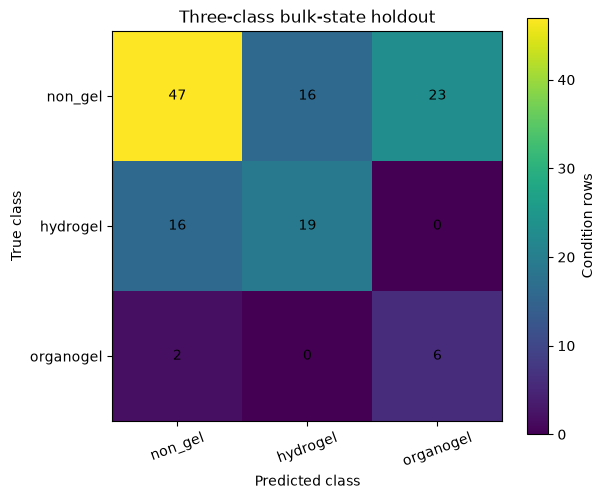

In [255]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(bulk3_test_confusion)

ax.set_xticks(range(len(bulk3_classes)))
ax.set_yticks(range(len(bulk3_classes)))
ax.set_xticklabels(bulk3_classes, rotation=20)
ax.set_yticklabels(bulk3_classes)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Three-class bulk-state holdout")

for i in range(len(bulk3_classes)):
    for j in range(len(bulk3_classes)):
        ax.text(
            j,
            i,
            str(bulk3_test_confusion[i, j]),
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Condition rows")
plt.tight_layout()


save_publication_figure(fig, "figure_5_bulk3_confusion_matrix")

plt.show()

**Figure 5. Three-class bulk-state confusion matrix on unseen molecules.**
The principal error mode is non-gel being classified as organogel; hydrogel and organogel
are not directly confused in the permanent holdout.

In [256]:
# ============================================================
# THREE-CLASS HOLDOUT PREDICTION TABLE
# ============================================================

bulk3_holdout_predictions = (
    bulk3_test_data[
        [
            "molecular_identity_key",
            "sequence_curated",
            "publication_pmid",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "bulk_state_target"
        ]
    ]
    .copy()
)


bulk3_holdout_predictions[
    "predicted_class"
] = bulk3_test_prediction


for i, class_name in enumerate(
    bulk3_classes
):

    bulk3_holdout_predictions[
        f"prob_{class_name}"
    ] = bulk3_test_probability[:, i]


bulk3_holdout_predictions[
    "prediction_correct"
] = (
    bulk3_holdout_predictions[
        "bulk_state_target"
    ]
    ==
    bulk3_holdout_predictions[
        "predicted_class"
    ]
)


print("=" * 90)
print("THREE-CLASS HOLDOUT PREDICTIONS")
print("=" * 90)

print(
    "Rows:",
    len(bulk3_holdout_predictions)
)

print(
    "Correct:",
    bulk3_holdout_predictions[
        "prediction_correct"
    ].sum()
)

print(
    "Incorrect:",
    (
        ~bulk3_holdout_predictions[
            "prediction_correct"
        ]
    ).sum()
)

THREE-CLASS HOLDOUT PREDICTIONS
Rows: 129
Correct: 72
Incorrect: 57


In [257]:
# ============================================================
# MOLECULE-CLUSTER BOOTSTRAP
# THREE-CLASS HOLDOUT
# ============================================================

rng = np.random.default_rng(2026)

unique_bulk3_test_molecules = (
    bulk3_holdout_predictions[
        "molecular_identity_key"
    ]
    .unique()
)


bootstrap_bulk3_rows = []


for iteration in range(2000):

    sampled_molecules = rng.choice(
        unique_bulk3_test_molecules,
        size=len(
            unique_bulk3_test_molecules
        ),
        replace=True
    )


    sampled_parts = []


    for bootstrap_group, molecule in enumerate(
        sampled_molecules
    ):

        part = (
            bulk3_holdout_predictions[
                bulk3_holdout_predictions[
                    "molecular_identity_key"
                ] == molecule
            ]
            .copy()
        )

        part[
            "_bootstrap_group"
        ] = bootstrap_group

        sampled_parts.append(
            part
        )


    sample = pd.concat(
        sampled_parts,
        ignore_index=True
    )


    y_boot = (
        sample[
            "bulk_state_target"
        ]
    )

    pred_boot = (
        sample[
            "predicted_class"
        ]
    )


    # Skip samples lacking any of the 3 classes
    if (
        set(
            y_boot.unique()
        )
        != set(
            bulk3_classes
        )
    ):
        continue


    probability_boot = (
        sample[
            [
                "prob_non_gel",
                "prob_hydrogel",
                "prob_organogel"
            ]
        ]
        .to_numpy()
    )


    y_boot_binary = label_binarize(
        y_boot,
        classes=bulk3_classes
    )


    bootstrap_bulk3_rows.append(
        {
            "macro_roc_auc":
                roc_auc_score(
                    y_boot_binary,
                    probability_boot,
                    average="macro"
                ),

            "macro_pr_auc":
                average_precision_score(
                    y_boot_binary,
                    probability_boot,
                    average="macro"
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_boot,
                    pred_boot
                ),

            "macro_f1":
                f1_score(
                    y_boot,
                    pred_boot,
                    average="macro",
                    zero_division=0
                ),

            "mcc":
                matthews_corrcoef(
                    y_boot,
                    pred_boot
                )
        }
    )


bulk3_bootstrap_results = pd.DataFrame(
    bootstrap_bulk3_rows
)


bulk3_point_estimates = {
    "macro_roc_auc":
        bulk3_test_macro_roc_auc,

    "macro_pr_auc":
        bulk3_test_macro_pr_auc,

    "balanced_accuracy":
        bulk3_test_balanced_accuracy,

    "macro_f1":
        bulk3_test_macro_f1,

    "mcc":
        bulk3_test_mcc
}


bulk3_bootstrap_ci = []


for metric, estimate in (
    bulk3_point_estimates.items()
):

    bulk3_bootstrap_ci.append(
        {
            "metric":
                metric,

            "estimate":
                estimate,

            "ci_lower_95":
                bulk3_bootstrap_results[
                    metric
                ].quantile(0.025),

            "ci_upper_95":
                bulk3_bootstrap_results[
                    metric
                ].quantile(0.975)
        }
    )


bulk3_bootstrap_ci = pd.DataFrame(
    bulk3_bootstrap_ci
)


print("=" * 90)
print("THREE-CLASS MOLECULE-CLUSTER BOOTSTRAP")
print("=" * 90)

print(
    "Successful bootstrap samples:",
    len(
        bulk3_bootstrap_results
    )
)


display(
    bulk3_bootstrap_ci
    .round(3)
)

THREE-CLASS MOLECULE-CLUSTER BOOTSTRAP
Successful bootstrap samples: 1996


,metric,estimate,ci_lower_95,ci_upper_95
0,macro_roc_auc,0.783,0.686,0.905
1,macro_pr_auc,0.555,0.454,0.773
2,balanced_accuracy,0.613,0.474,0.813
3,macro_f1,0.497,0.381,0.663
4,mcc,0.247,0.083,0.538


### Table 4 — Three-class bulk-state performance with molecule-cluster uncertainty

In [258]:
bulk3_metric_display = {
    "macro_roc_auc": "Macro ROC-AUC",
    "macro_pr_auc": "Macro PR-AUC",
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
    "mcc": "MCC"
}

bulk3_final_table = (
    bulk3_bootstrap_ci
    .assign(
        metric=lambda d:
            d["metric"].map(bulk3_metric_display)
    )
    [
        [
            "metric",
            "estimate",
            "ci_lower_95",
            "ci_upper_95"
        ]
    ]
)

display(bulk3_final_table.round(3))

,metric,estimate,ci_lower_95,ci_upper_95
0,Macro ROC-AUC,0.783,0.686,0.905
1,Macro PR-AUC,0.555,0.454,0.773
2,Balanced accuracy,0.613,0.474,0.813
3,Macro F1,0.497,0.381,0.663
4,MCC,0.247,0.083,0.538


In [259]:
# ============================================================
# THREE-CLASS HOLDOUT ERROR AUDIT
# ============================================================

bulk3_errors = (
    bulk3_holdout_predictions[
        ~bulk3_holdout_predictions[
            "prediction_correct"
        ]
    ]
    .copy()
)


bulk3_errors[
    "error_type"
] = (
    bulk3_errors[
        "bulk_state_target"
    ]
    .astype(str)
    +
    "_to_"
    +
    bulk3_errors[
        "predicted_class"
    ]
    .astype(str)
)


print("=" * 90)
print("THREE-CLASS HOLDOUT ERROR AUDIT")
print("=" * 90)

print(
    "Total errors:",
    len(bulk3_errors)
)


print("\nError types:")

error_type_summary = (
    bulk3_errors[
        "error_type"
    ]
    .value_counts()
    .rename_axis(
        "error_type"
    )
    .reset_index(
        name="n_records"
    )
)


display(
    error_type_summary
)

THREE-CLASS HOLDOUT ERROR AUDIT
Total errors: 57

Error types:


,error_type,n_records
0,non_gel_to_organogel,23
1,non_gel_to_hydrogel,16
2,hydrogel_to_non_gel,16
3,organogel_to_non_gel,2


In [260]:
# ============================================================
# ERROR CONCENTRATION BY MOLECULAR IDENTITY
# ============================================================

bulk3_error_by_molecule = (
    bulk3_errors
    .groupby(
        [
            "molecular_identity_key",
            "sequence_curated"
        ]
    )
    .agg(
        n_errors=(
            "error_type",
            "size"
        ),

        error_types=(
            "error_type",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_true_states=(
            "bulk_state_target",
            "nunique"
        ),

        true_states=(
            "bulk_state_target",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        predicted_states=(
            "predicted_class",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        )
    )
    .reset_index()
    .sort_values(
        "n_errors",
        ascending=False
    )
)


print("=" * 90)
print("THREE-CLASS ERROR CONCENTRATION BY MOLECULE")
print("=" * 90)

print(
    "Molecules represented among errors:",
    bulk3_errors[
        "molecular_identity_key"
    ].nunique()
)

display(
    bulk3_error_by_molecule
)

THREE-CLASS ERROR CONCENTRATION BY MOLECULE
Molecules represented among errors: 13


,molecular_identity_key,sequence_curated,n_errors,error_types,n_true_states,true_states,predicted_states
12,XFF|linear_or_unspecified|boc|free|none|peptide|none,XFF,21,"(hydrogel_to_non_gel, non_gel_to_hydrogel)",2,"(hydrogel, non_gel)","(hydrogel, non_gel)"
7,GVV|linear_or_unspecified|boc|benzylation|none|peptide|none,GVV,6,"(non_gel_to_organogel,)",1,"(non_gel,)","(organogel,)"
10,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,6,"(non_gel_to_organogel,)",1,"(non_gel,)","(organogel,)"
4,FVG|linear_or_unspecified|boc|benzylation|none|peptide|none,FVG,4,"(non_gel_to_organogel,)",1,"(non_gel,)","(organogel,)"
3,FFV|linear_or_unspecified|free|free|none|peptide|none,FFV,3,"(non_gel_to_hydrogel,)",1,"(non_gel,)","(hydrogel,)"
9,VGA|linear_or_unspecified|boc|benzylation|none|peptide|none,VGA,3,"(non_gel_to_organogel,)",1,"(non_gel,)","(organogel,)"
6,GVA|linear_or_unspecified|boc|benzylation|none|peptide|none,GVA,3,"(non_gel_to_organogel,)",1,"(non_gel,)","(organogel,)"
5,GF|linear_or_unspecified|fmoc|free|none|peptide|none,GF,3,"(non_gel_to_hydrogel,)",1,"(non_gel,)","(hydrogel,)"
2,FFD|linear_or_unspecified|free|free|none|peptide|none,FFD,2,"(non_gel_to_hydrogel, organogel_to_non_gel)",2,"(non_gel, organogel)","(hydrogel, non_gel)"
11,WP|linear_or_unspecified|chlorination|n-hexadecylamine|none|peptide|none,WP,2,"(non_gel_to_hydrogel,)",1,"(non_gel,)","(hydrogel,)"


In [261]:
# ============================================================
# FALSE ORGANOGEL AUDIT
# true non-gel predicted organogel
# ============================================================

false_organogels = (
    bulk3_holdout_predictions[
        (
            bulk3_holdout_predictions[
                "bulk_state_target"
            ] == "non_gel"
        )
        &
        (
            bulk3_holdout_predictions[
                "predicted_class"
            ] == "organogel"
        )
    ]
    .copy()
)


print("=" * 90)
print("FALSE ORGANOGEL PREDICTIONS")
print("=" * 90)

print(
    "Rows:",
    len(false_organogels)
)

print(
    "Independent molecules:",
    false_organogels[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Publications:",
    false_organogels[
        "publication_pmid"
    ].nunique()
)


display(
    false_organogels[
        [
            "molecular_identity_key",
            "sequence_curated",
            "publication_pmid",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "prob_non_gel",
            "prob_hydrogel",
            "prob_organogel"
        ]
    ]
    .sort_values(
        "prob_organogel",
        ascending=False
    )
    .round(3)
)

FALSE ORGANOGEL PREDICTIONS
Rows: 23
Independent molecules: 6
Publications: 1


,molecular_identity_key,sequence_curated,publication_pmid,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,prob_non_gel,prob_hydrogel,prob_organogel
28,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,20460796,100.0,7.0,20.0,Chlorobenzene,0.0,0.033,0.001,0.966
37,GVV|linear_or_unspecified|boc|benzylation|none|peptide|none,GVV,20460796,100.0,7.0,20.0,Chlorobenzene,0.0,0.033,0.001,0.966
4,VGA|linear_or_unspecified|boc|benzylation|none|peptide|none,VGA,20460796,100.0,7.0,20.0,Chlorobenzene,0.0,0.039,0.001,0.961
27,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,20460796,100.0,7.0,20.0,Toluene,0.0,0.048,0.001,0.951
36,GVV|linear_or_unspecified|boc|benzylation|none|peptide|none,GVV,20460796,100.0,7.0,20.0,Toluene,0.0,0.048,0.001,0.951
33,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,20460796,100.0,7.0,20.0,Acetonitrile,0.0,0.136,0.001,0.863
42,GVV|linear_or_unspecified|boc|benzylation|none|peptide|none,GVV,20460796,100.0,7.0,20.0,Acetonitrile,0.0,0.136,0.001,0.863
59,FVG|linear_or_unspecified|boc|benzylation|none|peptide|none,FVG,20460796,100.0,7.0,20.0,Acetonitrile,0.0,0.139,0.002,0.859
32,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,20460796,100.0,7.0,20.0,Acetone,0.0,0.187,0.001,0.811
41,GVV|linear_or_unspecified|boc|benzylation|none|peptide|none,GVV,20460796,100.0,7.0,20.0,Acetone,0.0,0.187,0.001,0.811


In [262]:
# ============================================================
# FALSE ORGANOGELS — SOLVENT STRUCTURE
# ============================================================

false_organogel_solvent_summary = (
    false_organogels
    .groupby(
        [
            "solution",
            "aqueous_phase_fraction"
        ],
        dropna=False
    )
    .agg(
        n_records=(
            "predicted_class",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        mean_organogel_probability=(
            "prob_organogel",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "n_records",
        ascending=False
    )
)


display(
    false_organogel_solvent_summary
    .round(3)
)

,solution,aqueous_phase_fraction,n_records,n_molecules,mean_organogel_probability
0,Acetone,0.0,5,5,0.751
1,Acetonitrile,0.0,5,5,0.768
4,Ethanol,0.0,5,5,0.570
2,Chlorobenzene,0.0,3,3,0.964
3,Dichloromethane,0.0,3,3,0.508
5,Toluene,0.0,2,2,0.951


In [263]:
# ============================================================
# PMID 20460796 — DEVELOPMENT vs HOLDOUT STRUCTURE
# ============================================================

publication_20460796 = pd.concat(
    [
        bulk3_train_data.assign(
            dataset_partition="development"
        ),

        bulk3_test_data.assign(
            dataset_partition="holdout"
        )
    ],
    ignore_index=True
)


publication_20460796 = (
    publication_20460796[
        publication_20460796[
            "publication_pmid"
        ] == 20460796
    ]
    .copy()
)


print("=" * 90)
print("PMID 20460796 — BULK-STATE STRUCTURE")
print("=" * 90)

print(
    "Rows:",
    len(publication_20460796)
)

print(
    "Molecules:",
    publication_20460796[
        "molecular_identity_key"
    ].nunique()
)

print("\nRows by partition:")

display(
    publication_20460796[
        "dataset_partition"
    ]
    .value_counts()
    .rename_axis("partition")
    .reset_index(name="n_records")
)


print("\nBulk-state distribution by partition:")

display(
    pd.crosstab(
        publication_20460796[
            "dataset_partition"
        ],
        publication_20460796[
            "bulk_state_target"
        ]
    )
)

PMID 20460796 — BULK-STATE STRUCTURE
Rows: 240
Molecules: 32

Rows by partition:


,partition,n_records
0,development,182
1,holdout,58



Bulk-state distribution by partition:


bulk_state_target,non_gel,organogel
dataset_partition,,
development,158,24
holdout,52,6


In [264]:
# ============================================================
# PMID 20460796 — SEQUENCE × SOLVENT × BULK STATE
# ============================================================

publication_20460796_structure = (
    publication_20460796[
        [
            "dataset_partition",
            "molecular_identity_key",
            "sequence_curated",
            "solution",
            "aqueous_phase_fraction",
            "concentration(mg/ml)",
            "temperature",
            "bulk_state_target"
        ]
    ]
    .sort_values(
        [
            "dataset_partition",
            "sequence_curated",
            "solution"
        ]
    )
)


display(
    publication_20460796_structure
)


# ============================================================
# PMID 20460796 — MOLECULAR OUTCOME SUMMARY
# ============================================================

publication_20460796_molecule_summary = (
    publication_20460796
    .groupby(
        [
            "dataset_partition",
            "molecular_identity_key",
            "sequence_curated"
        ]
    )
    .agg(
        n_records=(
            "bulk_state_target",
            "size"
        ),

        n_solvents=(
            "solution",
            "nunique"
        ),

        bulk_states=(
            "bulk_state_target",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_non_gel=(
            "bulk_state_target",
            lambda x:
                (x == "non_gel").sum()
        ),

        n_hydrogel=(
            "bulk_state_target",
            lambda x:
                (x == "hydrogel").sum()
        ),

        n_organogel=(
            "bulk_state_target",
            lambda x:
                (x == "organogel").sum()
        )
    )
    .reset_index()
)


display(
    publication_20460796_molecule_summary
    .sort_values(
        [
            "dataset_partition",
            "sequence_curated"
        ]
    )
)

,dataset_partition,molecular_identity_key,sequence_curated,solution,aqueous_phase_fraction,concentration(mg/ml),temperature,bulk_state_target
67,development,AAG|linear_or_unspecified|boc|benzylation|none|peptide|none,AAG,Acetone,0.0,100.0,20.0,non_gel
68,development,AAG|linear_or_unspecified|boc|benzylation|none|peptide|none,AAG,Acetonitrile,0.0,100.0,20.0,non_gel
65,development,AAG|linear_or_unspecified|boc|benzylation|none|peptide|none,AAG,Chloroform,0.0,100.0,20.0,non_gel
66,development,AAG|linear_or_unspecified|boc|benzylation|none|peptide|none,AAG,Dichloromethane,0.0,100.0,20.0,non_gel
69,development,AAG|linear_or_unspecified|boc|benzylation|none|peptide|none,AAG,Ethanol,0.0,100.0,20.0,non_gel
...,...,...,...,...,...,...,...,...
546,holdout,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,Dichloromethane,0.0,100.0,20.0,non_gel
549,holdout,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,Ethanol,0.0,100.0,20.0,non_gel
544,holdout,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,Ethyl acetate,0.0,100.0,20.0,non_gel
550,holdout,VGV|linear_or_unspecified|boc|benzylation|none|peptide|none,VGV,Methanol,0.0,100.0,20.0,non_gel


,dataset_partition,molecular_identity_key,sequence_curated,n_records,n_solvents,bulk_states,n_non_gel,n_hydrogel,n_organogel
0,development,AAG|linear_or_unspecified|boc|benzylation|none|peptide|none,AAG,5,5,"(non_gel,)",5,0,0
1,development,AAV|linear_or_unspecified|boc|benzylation|none|peptide|none,AAV,8,8,"(non_gel,)",8,0,0
2,development,AGA|linear_or_unspecified|boc|benzylation|none|peptide|none,AGA,7,7,"(non_gel,)",7,0,0
3,development,AGG|linear_or_unspecified|boc|benzylation|none|peptide|none,AGG,9,9,"(non_gel, organogel)",7,0,2
4,development,AGV|linear_or_unspecified|boc|benzylation|none|peptide|none,AGV,9,9,"(non_gel,)",9,0,0
5,development,AVA|linear_or_unspecified|boc|benzylation|none|peptide|none,AVA,7,7,"(non_gel,)",7,0,0
6,development,AVG|linear_or_unspecified|boc|benzylation|none|peptide|none,AVG,7,7,"(non_gel, organogel)",3,0,4
7,development,AVV|linear_or_unspecified|boc|benzylation|none|peptide|none,AVV,9,9,"(non_gel,)",9,0,0
8,development,FAA|linear_or_unspecified|boc|benzylation|none|peptide|none,FAA,8,8,"(non_gel, organogel)",6,0,2
9,development,GAA|linear_or_unspecified|boc|benzylation|none|peptide|none,GAA,9,9,"(non_gel, organogel)",7,0,2


### Three-Class Bulk-State Generalization and Error Structure

The direct non-gel/hydrogel/organogel task was substantially more difficult
than binary hydrogel prediction. Nested molecule-grouped validation of the
selected HistGradientBoosting model yielded macro ROC-AUC = 0.888 and macro
PR-AUC = 0.716, whereas evaluation on the sealed 129-condition holdout from
20 unseen molecular identities yielded macro ROC-AUC = 0.783 and macro
PR-AUC = 0.555.

Hydrogel and organogel states were not directly confused in the permanent
holdout. Instead, the dominant failure was discrimination between organogel
formation and non-gel behaviour in neat organic media. Of 57 holdout errors,
23 were non-gel conditions incorrectly classified as organogel, all originating
from PMID 20460796.

This publication contains a combinatorial series of Boc/benzylated tripeptides
tested across multiple organic solvents, with closely related sequences showing
different gelation behaviour under comparable experimental conditions.
Composition-isomeric sequences such as VVG, GVV and VGV illustrate an important
representation limitation: the present physicochemical descriptor set captures
residue composition but provides limited information about residue order and
the sequence-specific packing interactions governing supramolecular assembly.

Accordingly, the multiclass results indicate that solvent environment strongly
constrains the plausible gel type, while distinguishing gel-forming from
non-gelling analogues requires molecular representations capable of resolving
finer sequence-order and supramolecular packing effects.

In [265]:
# ============================================================
# RECONSTRUCT HIERARCHICAL MORPHOLOGY TARGET
# ============================================================

print("=" * 90)
print("MORPHOLOGY SOURCE CHECK")
print("=" * 90)

print(
    "morphology_curated available:",
    "morphology_curated" in ml_master.columns
)

print(
    "morphology_parent available:",
    "morphology_parent" in ml_master.columns
)

MORPHOLOGY SOURCE CHECK
morphology_curated available: False
morphology_parent available: False


In [266]:
# ============================================================
# BUILD A SAFE CONDITION-SPECIFIC MORPHOLOGY MERGE KEY
# ============================================================

morphology_key_columns = [
    "sapdb_id_original",
    "sequence",
    "N-terminal",
    "C-terminal",
    "non-terminal",
    "assembly_label_audit",
    "component_1_standardized",
    "component_2_standardized",
    "component_1_ratio_fraction",
    "component_2_ratio_fraction",
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "heating/cooling",
    "incubation period (min)"
]


missing_from_morph = [
    col for col in morphology_key_columns
    if col not in morphology_master.columns
]

missing_from_ml = [
    col for col in morphology_key_columns
    if col not in ml_master.columns
]


print("=" * 90)
print("MORPHOLOGY MERGE-KEY AVAILABILITY")
print("=" * 90)

print(
    "Missing from morphology_master:",
    missing_from_morph
)

print(
    "Missing from ml_master:",
    missing_from_ml
)


assert len(missing_from_morph) == 0
assert len(missing_from_ml) == 0


numeric_key_columns = [
    "sapdb_id_original",
    "component_1_ratio_fraction",
    "component_2_ratio_fraction",
    "concentration(mg/ml)",
    "PH",
    "temperature",
    "incubation period (min)"
]


string_key_columns = [
    col
    for col in morphology_key_columns
    if col not in numeric_key_columns
]


def make_morphology_merge_key(df):

    normalized = pd.DataFrame(
        index=df.index
    )

    for col in numeric_key_columns:

        normalized[col] = (
            pd.to_numeric(
                df[col],
                errors="coerce"
            )
            .round(8)
            .fillna(-999999.0)
        )


    for col in string_key_columns:

        normalized[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .fillna("<missing>")
        )


    return (
        normalized
        .astype(str)
        .agg("||".join, axis=1)
    )


morphology_keys = make_morphology_merge_key(
    morphology_master
)

ml_master_keys = make_morphology_merge_key(
    ml_master
)


# ------------------------------------------------------------
# How many ML-master rows correspond to each morphology key?
# ------------------------------------------------------------

ml_key_counts = (
    ml_master_keys
    .value_counts()
)


matches_per_morphology_row = (
    morphology_keys
    .map(
        ml_key_counts
    )
    .fillna(0)
    .astype(int)
)


merge_key_audit = pd.DataFrame(
    {
        "n_ml_matches":
            matches_per_morphology_row
    }
)


print("=" * 90)
print("CONDITION-SPECIFIC MORPHOLOGY MERGE AUDIT")
print("=" * 90)

print(
    "Morphology rows:",
    len(morphology_master)
)

print(
    "Unique morphology keys:",
    morphology_keys.nunique()
)

print(
    "Rows matching exactly one ml_master row:",
    (
        matches_per_morphology_row == 1
    ).sum()
)

print(
    "Rows with zero ml_master matches:",
    (
        matches_per_morphology_row == 0
    ).sum()
)

print(
    "Rows with multiple ml_master matches:",
    (
        matches_per_morphology_row > 1
    ).sum()
)


print("\nMatch-count distribution:")

display(
    merge_key_audit[
        "n_ml_matches"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "n_ml_matches"
    )
    .reset_index(
        name="n_morphology_rows"
    )
)

MORPHOLOGY MERGE-KEY AVAILABILITY
Missing from morphology_master: []
Missing from ml_master: []
CONDITION-SPECIFIC MORPHOLOGY MERGE AUDIT
Morphology rows: 342
Unique morphology keys: 342
Rows matching exactly one ml_master row: 342
Rows with zero ml_master matches: 0
Rows with multiple ml_master matches: 0

Match-count distribution:


,n_ml_matches,n_morphology_rows
0,1,342


In [267]:
# ============================================================
# ATTACH VERIFIED FINAL MORPHOLOGY CURATION TO ML_MASTER
# ============================================================

assert len(morphology_master) == 342

assert morphology_keys.nunique() == 342

assert (
    matches_per_morphology_row == 1
).all()


morphology_lookup = (
    morphology_master[
        [
            "morphology_curated",
            "morphology_parent",
            "morphology_confidence",
            "morphology_adjudication_source",
            "morphology_agreement_status"
        ]
    ]
    .copy()
)


morphology_lookup[
    "_morphology_merge_key"
] = (
    morphology_keys.values
)


morphology_lookup = (
    morphology_lookup
    .set_index(
        "_morphology_merge_key"
    )
)


ml_master[
    "_morphology_merge_key"
] = (
    ml_master_keys.values
)


for col in [
    "morphology_curated",
    "morphology_parent",
    "morphology_confidence",
    "morphology_adjudication_source",
    "morphology_agreement_status"
]:

    ml_master[col] = (
        ml_master[
            "_morphology_merge_key"
        ]
        .map(
            morphology_lookup[col]
        )
    )


ml_master.drop(
    columns=[
        "_morphology_merge_key"
    ],
    inplace=True
)


print("=" * 90)
print("FINAL MORPHOLOGY CURATION ATTACHED")
print("=" * 90)

print(
    "Rows with morphology_curated:",
    ml_master[
        "morphology_curated"
    ].notna().sum()
)

print(
    "Rows with morphology_parent:",
    ml_master[
        "morphology_parent"
    ].notna().sum()
)


print("\nFine-grained morphology:")

display(
    ml_master[
        "morphology_curated"
    ]
    .value_counts()
    .rename_axis("morphology")
    .reset_index(name="n_records")
)


print("\nHierarchical morphology:")

display(
    ml_master[
        "morphology_parent"
    ]
    .value_counts()
    .rename_axis("morphology_parent")
    .reset_index(name="n_records")
)

FINAL MORPHOLOGY CURATION ATTACHED
Rows with morphology_curated: 342
Rows with morphology_parent: 342

Fine-grained morphology:


,morphology,n_records
0,fiber,94
1,tube,86
2,vesicle,42
3,nanosphere,35
4,crystal,34
5,ribbon,33
6,particle,16
7,micelle_like,1
8,nanorod,1



Hierarchical morphology:


,morphology_parent,n_records
0,elongated_1D,214
1,spherical_particulate,52
2,vesicular,42
3,crystalline,34


In [268]:
# ============================================================
# HIERARCHICAL MORPHOLOGY MODELLING DATASET
# ============================================================

morph4_classes = [
    "elongated_1D",
    "spherical_particulate",
    "vesicular",
    "crystalline"
]


morph4_ml = (
    ml_master[
        ml_master[
            "morphology_parent"
        ].isin(
            morph4_classes
        )
    ]
    .copy()
    .reset_index(drop=True)
)


morph4_ml[
    "morphology_target"
] = (
    morph4_ml[
        "morphology_parent"
    ]
    .astype(str)
)


if "publication_pmid" not in morph4_ml.columns:

    morph4_ml[
        "publication_pmid"
    ] = (
        morph4_ml[
            "sapdb_id_original"
        ]
        .map(
            sapdb_publication_map
        )
    )


print("=" * 90)
print("HIERARCHICAL MORPHOLOGY DATASET")
print("=" * 90)

print(
    "Rows:",
    len(morph4_ml)
)

print(
    "Molecular identities:",
    morph4_ml[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Publications:",
    morph4_ml[
        "publication_pmid"
    ].nunique()
)


print("\nClass distribution:")

display(
    morph4_ml[
        "morphology_target"
    ]
    .value_counts()
    .reindex(
        morph4_classes
    )
    .rename_axis(
        "morphology"
    )
    .reset_index(
        name="n_records"
    )
)

HIERARCHICAL MORPHOLOGY DATASET
Rows: 342
Molecular identities: 64
Publications: 47

Class distribution:


,morphology,n_records
0,elongated_1D,214
1,spherical_particulate,52
2,vesicular,42
3,crystalline,34


In [269]:
# ============================================================
# MORPHOLOGY CLASS-LEVEL SUPPORT
# ============================================================

morph4_class_support = (
    morph4_ml
    .groupby(
        "morphology_target"
    )
    .agg(
        n_records=(
            "morphology_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        n_sequences=(
            "sequence_curated",
            "nunique"
        )
    )
    .reset_index()
)


morph4_class_support[
    "percentage"
] = (
    morph4_class_support[
        "n_records"
    ]
    / len(morph4_ml)
    * 100
)


print("=" * 90)
print("HIERARCHICAL MORPHOLOGY — CLASS SUPPORT")
print("=" * 90)

display(
    morph4_class_support
    .sort_values(
        "n_records",
        ascending=False
    )
    .round(2)
)

HIERARCHICAL MORPHOLOGY — CLASS SUPPORT


,morphology_target,n_records,n_molecules,n_publications,n_sequences,percentage
1,elongated_1D,214,42,35,35,62.57
2,spherical_particulate,52,20,16,16,15.20
3,vesicular,42,10,7,10,12.28
0,crystalline,34,1,1,1,9.94


> **Section takeaway:** direct non-gel/hydrogel/organogel prediction is materially harder
> than binary hydrogel prediction. The main unresolved representation problem is the
> separation of organic non-gelling systems from true organogels, especially when
> sequence order and supramolecular packing are not explicitly encoded.

# Section 9 — Broad supramolecular morphology prediction

**Prediction task:** elongated/1D versus spherical/particulate versus vesicular.

Crystalline morphology is retained scientifically but excluded from transferable
classification because its 34 condition rows originate from only one independent
molecular identity and one publication.

### Figure 6 — Independent support for broad morphology classes

The crystalline class contains many condition rows but only one independent molecular
identity, motivating its exclusion from transferable unseen-molecule modelling.

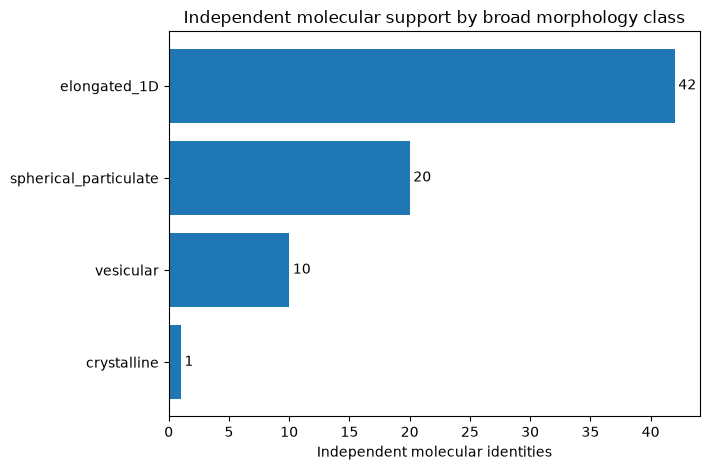

In [270]:
import matplotlib.pyplot as plt

morph_support_plot = (
    morph4_class_support
    .sort_values("n_molecules", ascending=True)
)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.barh(
    morph_support_plot["morphology_target"],
    morph_support_plot["n_molecules"]
)

ax.set_xlabel("Independent molecular identities")
ax.set_ylabel("")
ax.set_title("Independent molecular support by broad morphology class")

for bar, value in zip(bars, morph_support_plot["n_molecules"]):
    ax.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(int(value)),
        va="center"
    )

plt.tight_layout()


save_publication_figure(fig, "figure_6_broad_morphology_support")

plt.show()

**Figure 6. Independent molecular support for broad morphology classes.**
Condition-row counts can strongly overstate independent evidence. In particular,
crystalline morphology contains 34 observations but only one independent molecular
identity, so it is excluded from transferable broad-morphology modelling.

In [271]:
# ============================================================
# CONDITION-DEPENDENT MORPHOLOGY SWITCHING
# ============================================================

morph4_molecule_structure = (
    morph4_ml
    .groupby(
        "molecular_identity_key"
    )
    .agg(
        sequence=(
            "sequence_curated",
            "first"
        ),

        n_records=(
            "morphology_target",
            "size"
        ),

        n_morphologies=(
            "morphology_target",
            "nunique"
        ),

        morphologies=(
            "morphology_target",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        )
    )
    .reset_index()
)


multimorph_molecules = (
    morph4_molecule_structure[
        morph4_molecule_structure[
            "n_morphologies"
        ] > 1
    ]
    .sort_values(
        [
            "n_morphologies",
            "n_records"
        ],
        ascending=False
    )
)


print("=" * 90)
print("MULTI-MORPHOLOGY MOLECULAR SYSTEMS")
print("=" * 90)

print(
    "Total molecular identities:",
    len(
        morph4_molecule_structure
    )
)

print(
    "Molecules represented in >1 morphology class:",
    len(
        multimorph_molecules
    )
)

display(
    multimorph_molecules
)

MULTI-MORPHOLOGY MOLECULAR SYSTEMS
Total molecular identities: 64
Molecules represented in >1 morphology class: 7


,molecular_identity_key,sequence,n_records,n_morphologies,morphologies,n_publications
20,FF|linear_or_unspecified|free|free|none|peptide|none,FF,61,3,"(crystalline, elongated_1D, vesicular)",13
36,KFG|linear_or_unspecified|free|free|none|peptide|none,KFG,14,3,"(elongated_1D, spherical_particulate, vesicular)",2
17,FF|linear_or_unspecified|boc|free|none|peptide|none,FF,49,2,"(elongated_1D, spherical_particulate)",2
9,FFH|linear_or_unspecified|ferrocene|free|none|peptide|none,FFH,12,2,"(elongated_1D, vesicular)",1
37,KF|linear_or_unspecified|free|free|delta-f|peptide|none,KF,10,2,"(spherical_particulate, vesicular)",3
1,EF|linear_or_unspecified|free|free|delta-f|peptide|none,EF,8,2,"(spherical_particulate, vesicular)",3
51,RF|linear_or_unspecified|free|free|delta-f|peptide|none,RF,6,2,"(spherical_particulate, vesicular)",3


In [272]:
# ============================================================
# THREE-CLASS HIERARCHICAL MORPHOLOGY DATASET
# CRYSTALLINE RETAINED IN CURATED DATA, EXCLUDED FROM
# TRANSFERABLE UNSEEN-MOLECULE ML TARGET
# ============================================================

morph3_classes = [
    "elongated_1D",
    "spherical_particulate",
    "vesicular"
]


morph3_ml = (
    morph4_ml[
        morph4_ml[
            "morphology_target"
        ].isin(
            morph3_classes
        )
    ]
    .copy()
    .reset_index(drop=True)
)


print("=" * 90)
print("THREE-CLASS TRANSFERABLE MORPHOLOGY DATASET")
print("=" * 90)

print(
    "Rows:",
    len(morph3_ml)
)

print(
    "Molecular identities:",
    morph3_ml[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Publications:",
    morph3_ml[
        "publication_pmid"
    ].nunique()
)


print("\nClass distribution:")

display(
    morph3_ml[
        "morphology_target"
    ]
    .value_counts()
    .reindex(
        morph3_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_records")
)


print(
    "\nCrystalline observations retained outside "
    "transferable ML target:",
    (
        morph4_ml[
            "morphology_target"
        ] == "crystalline"
    ).sum()
)

print(
    "Independent crystalline molecules:",
    morph4_ml.loc[
        morph4_ml[
            "morphology_target"
        ] == "crystalline",
        "molecular_identity_key"
    ].nunique()
)

THREE-CLASS TRANSFERABLE MORPHOLOGY DATASET
Rows: 308
Molecular identities: 64
Publications: 46

Class distribution:


,morphology,n_records
0,elongated_1D,214
1,spherical_particulate,52
2,vesicular,42



Crystalline observations retained outside transferable ML target: 34
Independent crystalline molecules: 1


In [273]:
# ============================================================
# THREE-CLASS MORPHOLOGY INDEPENDENT SUPPORT
# ============================================================

morph3_support = (
    morph3_ml
    .groupby(
        "morphology_target"
    )
    .agg(
        n_records=(
            "morphology_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        n_sequences=(
            "sequence_curated",
            "nunique"
        )
    )
    .reset_index()
)


morph3_support[
    "percentage"
] = (
    morph3_support[
        "n_records"
    ]
    / len(morph3_ml)
    * 100
)


display(
    morph3_support
    .sort_values(
        "n_records",
        ascending=False
    )
    .round(2)
)

,morphology_target,n_records,n_molecules,n_publications,n_sequences,percentage
0,elongated_1D,214,42,35,35,69.48
1,spherical_particulate,52,20,16,16,16.88
2,vesicular,42,10,7,10,13.64


In [274]:
# ============================================================
# MULTI-MORPHOLOGY SYSTEMS AFTER CRYSTALLINE EXCLUSION
# ============================================================

morph3_molecule_structure = (
    morph3_ml
    .groupby(
        "molecular_identity_key"
    )
    .agg(
        sequence=(
            "sequence_curated",
            "first"
        ),

        n_records=(
            "morphology_target",
            "size"
        ),

        n_morphologies=(
            "morphology_target",
            "nunique"
        ),

        morphologies=(
            "morphology_target",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        )
    )
    .reset_index()
)


morph3_switchers = (
    morph3_molecule_structure[
        morph3_molecule_structure[
            "n_morphologies"
        ] > 1
    ]
    .sort_values(
        [
            "n_morphologies",
            "n_records"
        ],
        ascending=False
    )
)


print("=" * 90)
print("THREE-CLASS MULTI-MORPHOLOGY SYSTEMS")
print("=" * 90)

print(
    "Total molecules:",
    len(
        morph3_molecule_structure
    )
)

print(
    "Molecules with >1 broad morphology:",
    len(
        morph3_switchers
    )
)


display(
    morph3_switchers
)

THREE-CLASS MULTI-MORPHOLOGY SYSTEMS
Total molecules: 64
Molecules with >1 broad morphology: 7


,molecular_identity_key,sequence,n_records,n_morphologies,morphologies,n_publications
36,KFG|linear_or_unspecified|free|free|none|peptide|none,KFG,14,3,"(elongated_1D, spherical_particulate, vesicular)",2
17,FF|linear_or_unspecified|boc|free|none|peptide|none,FF,49,2,"(elongated_1D, spherical_particulate)",2
20,FF|linear_or_unspecified|free|free|none|peptide|none,FF,27,2,"(elongated_1D, vesicular)",12
9,FFH|linear_or_unspecified|ferrocene|free|none|peptide|none,FFH,12,2,"(elongated_1D, vesicular)",1
37,KF|linear_or_unspecified|free|free|delta-f|peptide|none,KF,10,2,"(spherical_particulate, vesicular)",3
1,EF|linear_or_unspecified|free|free|delta-f|peptide|none,EF,8,2,"(spherical_particulate, vesicular)",3
51,RF|linear_or_unspecified|free|free|delta-f|peptide|none,RF,6,2,"(spherical_particulate, vesicular)",3


In [275]:
# ============================================================
# RECONSTRUCT THE 58-FEATURE LAYER FOR MORPHOLOGY
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Sequence-derived descriptors
# ------------------------------------------------------------

morph3_descriptor_matrix = pd.DataFrame(
    [
        peptide_descriptors(seq)
        for seq in morph3_ml["sequence_curated"]
    ],
    index=morph3_ml.index
)


for col in morph3_descriptor_matrix.columns:
    morph3_ml[col] = morph3_descriptor_matrix[col]


# ------------------------------------------------------------
# Solvent-feature aliases used by all_model_features
# ------------------------------------------------------------

morph3_solvent_aliases = {
    "solvent_component_1":
        "component_1_standardized",

    "solvent_component_2":
        "component_2_standardized",

    "solvent_fraction_1":
        "component_1_ratio_fraction",

    "solvent_fraction_2":
        "component_2_ratio_fraction",

    "aqueous_fraction":
        "aqueous_phase_fraction",

    "has_second_solvent_component":
        "component_2_present"
}


for new_col, source_col in morph3_solvent_aliases.items():

    if (
        new_col not in morph3_ml.columns
        and source_col in morph3_ml.columns
    ):
        morph3_ml[new_col] = morph3_ml[source_col]


# ------------------------------------------------------------
# Incubation missingness indicator
# ------------------------------------------------------------

if "incubation_missing" not in morph3_ml.columns:

    morph3_ml["incubation_missing"] = (
        morph3_ml["incubation period (min)"]
        .isna()
        .astype(int)
    )


# ------------------------------------------------------------
# Heating/cooling binary feature
# ------------------------------------------------------------

if "heating_cooling_binary" not in morph3_ml.columns:

    morph3_ml["heating_cooling_binary"] = (
        morph3_ml["heating/cooling"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "yes": 1,
                "no": 0,
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0
            }
        )
    )


# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

missing_morph_features = [
    col
    for col in all_model_features
    if col not in morph3_ml.columns
]


print("=" * 90)
print("MORPHOLOGY FEATURE RECONSTRUCTION")
print("=" * 90)

print("Morphology rows:", len(morph3_ml))
print("Required model features:", len(all_model_features))
print("Missing required features:", len(missing_morph_features))


if missing_morph_features:

    print("\nStill missing:")

    for col in missing_morph_features:
        print(" -", col)

else:

    print(
        "\nAll required morphology-model features are available."
    )

MORPHOLOGY FEATURE RECONSTRUCTION
Morphology rows: 308
Required model features: 58
Missing required features: 0

All required morphology-model features are available.


In [276]:
morph3_X = morph3_ml[
    all_model_features
].copy()

morph3_y = morph3_ml[
    "morphology_target"
].copy()

morph3_groups = morph3_ml[
    "molecular_identity_key"
].copy()


print("Feature matrix:", morph3_X.shape)
print("Target rows:", len(morph3_y))
print("Molecular groups:", morph3_groups.nunique())

Feature matrix: (308, 58)
Target rows: 308
Molecular groups: 64


In [277]:
# ============================================================
# SEARCH FOR MORPHOLOGY PERMANENT HOLDOUT
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import numpy as np


overall_morph3_fraction = (
    morph3_y
    .value_counts(normalize=True)
    .reindex(
        morph3_classes,
        fill_value=0
    )
)


morph3_split_candidates = []


for seed in range(1000):

    splitter = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )


    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(
            morph3_X,
            morph3_y,
            morph3_groups
        ),
        start=1
    ):

        train_data_candidate = (
            morph3_ml.iloc[train_idx]
        )

        test_data_candidate = (
            morph3_ml.iloc[test_idx]
        )


        y_train_candidate = (
            morph3_y.iloc[train_idx]
        )

        y_test_candidate = (
            morph3_y.iloc[test_idx]
        )


        groups_train_candidate = (
            morph3_groups.iloc[train_idx]
        )

        groups_test_candidate = (
            morph3_groups.iloc[test_idx]
        )


        # Both train and test must contain all classes
        if (
            set(y_train_candidate.unique())
            != set(morph3_classes)
        ):
            continue


        if (
            set(y_test_candidate.unique())
            != set(morph3_classes)
        ):
            continue


        # Zero molecular overlap
        if len(
            set(groups_train_candidate)
            &
            set(groups_test_candidate)
        ) != 0:
            continue


        test_class_counts = (
            y_test_candidate
            .value_counts()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        test_class_fraction = (
            y_test_candidate
            .value_counts(normalize=True)
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        test_molecule_counts = (
            test_data_candidate
            .groupby(
                "morphology_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        train_molecule_counts = (
            train_data_candidate
            .groupby(
                "morphology_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        test_publication_counts = (
            test_data_candidate
            .groupby(
                "morphology_target"
            )[
                "publication_pmid"
            ]
            .nunique()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        # Rare vesicular class safeguards
        if (
            test_molecule_counts[
                "vesicular"
            ] < 2
        ):
            continue


        if (
            train_molecule_counts[
                "vesicular"
            ] < 6
        ):
            continue


        if (
            test_publication_counts[
                "vesicular"
            ] < 2
        ):
            continue


        # Split geometry
        test_row_fraction = (
            len(test_idx)
            / len(morph3_y)
        )


        test_molecule_fraction = (
            groups_test_candidate.nunique()
            / morph3_groups.nunique()
        )


        row_size_deviation = abs(
            test_row_fraction - 0.20
        )


        molecule_size_deviation = abs(
            test_molecule_fraction - 0.20
        )


        prevalence_deviation = (
            test_class_fraction
            .sub(
                overall_morph3_fraction
            )
            .abs()
            .mean()
        )


        geometry_score = (
            row_size_deviation
            +
            molecule_size_deviation
            +
            prevalence_deviation
        )


        morph3_split_candidates.append(
            {
                "seed":
                    seed,

                "fold":
                    fold,

                "geometry_score":
                    geometry_score,

                "n_train_rows":
                    len(train_idx),

                "n_test_rows":
                    len(test_idx),

                "n_train_molecules":
                    groups_train_candidate.nunique(),

                "n_test_molecules":
                    groups_test_candidate.nunique(),

                "test_elongated_rows":
                    int(
                        test_class_counts[
                            "elongated_1D"
                        ]
                    ),

                "test_spherical_rows":
                    int(
                        test_class_counts[
                            "spherical_particulate"
                        ]
                    ),

                "test_vesicular_rows":
                    int(
                        test_class_counts[
                            "vesicular"
                        ]
                    ),

                "test_elongated_molecules":
                    int(
                        test_molecule_counts[
                            "elongated_1D"
                        ]
                    ),

                "test_spherical_molecules":
                    int(
                        test_molecule_counts[
                            "spherical_particulate"
                        ]
                    ),

                "test_vesicular_molecules":
                    int(
                        test_molecule_counts[
                            "vesicular"
                        ]
                    ),

                "test_elongated_publications":
                    int(
                        test_publication_counts[
                            "elongated_1D"
                        ]
                    ),

                "test_spherical_publications":
                    int(
                        test_publication_counts[
                            "spherical_particulate"
                        ]
                    ),

                "test_vesicular_publications":
                    int(
                        test_publication_counts[
                            "vesicular"
                        ]
                    )
            }
        )


morph3_split_candidates = (
    pd.DataFrame(
        morph3_split_candidates
    )
    .sort_values(
        "geometry_score"
    )
    .reset_index(drop=True)
)


print("=" * 90)
print("MORPHOLOGY PERMANENT HOLDOUT CANDIDATES")
print("=" * 90)

print(
    "Valid candidate holdouts:",
    len(
        morph3_split_candidates
    )
)


display(
    morph3_split_candidates
    .head(20)
    .round(4)
)

MORPHOLOGY PERMANENT HOLDOUT CANDIDATES
Valid candidate holdouts: 4830


,seed,fold,geometry_score,n_train_rows,n_test_rows,n_train_molecules,n_test_molecules,test_elongated_rows,test_spherical_rows,test_vesicular_rows,test_elongated_molecules,test_spherical_molecules,test_vesicular_molecules,test_elongated_publications,test_spherical_publications,test_vesicular_publications
0,996,4,0.0503,249,59,50,14,43,10,6,10,3,2,7,4,2
1,8,4,0.0503,249,59,50,14,43,10,6,10,3,2,8,4,2
2,992,4,0.0503,249,59,50,14,43,10,6,10,3,2,10,4,2
3,618,4,0.0503,249,59,50,14,43,10,6,10,3,2,7,4,2
4,621,2,0.0503,249,59,50,14,43,10,6,8,4,2,6,4,2
5,642,4,0.0503,249,59,50,14,43,10,6,10,3,2,8,4,2
6,645,4,0.0503,249,59,50,14,43,10,6,10,3,2,10,4,2
7,646,4,0.0503,249,59,50,14,43,10,6,10,3,2,8,4,2
8,600,4,0.0503,249,59,50,14,43,10,6,10,3,2,9,4,2
9,603,4,0.0503,249,59,50,14,43,10,6,10,3,2,8,4,2


In [278]:
# ============================================================
# FREEZE PERMANENT MORPHOLOGY UNSEEN-MOLECULE HOLDOUT
# ============================================================

morph3_holdout_seed = 621
morph3_holdout_fold = 2


morph3_holdout_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=morph3_holdout_seed
)


selected_morph3_split = None


for fold, (train_idx, test_idx) in enumerate(
    morph3_holdout_splitter.split(
        morph3_X,
        morph3_y,
        morph3_groups
    ),
    start=1
):

    if fold == morph3_holdout_fold:

        selected_morph3_split = (
            train_idx,
            test_idx
        )

        break


assert selected_morph3_split is not None


morph3_train_idx, morph3_test_idx = (
    selected_morph3_split
)


morph3_X_train = (
    morph3_X
    .iloc[morph3_train_idx]
    .reset_index(drop=True)
)

morph3_X_test = (
    morph3_X
    .iloc[morph3_test_idx]
    .reset_index(drop=True)
)


morph3_y_train = (
    morph3_y
    .iloc[morph3_train_idx]
    .reset_index(drop=True)
)

morph3_y_test = (
    morph3_y
    .iloc[morph3_test_idx]
    .reset_index(drop=True)
)


morph3_groups_train = (
    morph3_groups
    .iloc[morph3_train_idx]
    .reset_index(drop=True)
)

morph3_groups_test = (
    morph3_groups
    .iloc[morph3_test_idx]
    .reset_index(drop=True)
)


morph3_train_data = (
    morph3_ml
    .iloc[morph3_train_idx]
    .reset_index(drop=True)
    .copy()
)

morph3_test_data = (
    morph3_ml
    .iloc[morph3_test_idx]
    .reset_index(drop=True)
    .copy()
)


shared_morph3_molecules = (
    set(morph3_groups_train)
    &
    set(morph3_groups_test)
)


print("=" * 90)
print("PERMANENT MORPHOLOGY UNSEEN-MOLECULE HOLDOUT")
print("=" * 90)

print(
    "Selected seed:",
    morph3_holdout_seed
)

print(
    "Selected fold:",
    morph3_holdout_fold
)

print(
    "\nDevelopment rows:",
    len(morph3_X_train)
)

print(
    "Permanent holdout rows:",
    len(morph3_X_test)
)

print(
    "\nDevelopment molecules:",
    morph3_groups_train.nunique()
)

print(
    "Permanent holdout molecules:",
    morph3_groups_test.nunique()
)

print(
    "Shared molecular identities:",
    len(shared_morph3_molecules)
)


print("\nDevelopment class distribution:")

display(
    morph3_y_train
    .value_counts()
    .reindex(
        morph3_classes
    )
    .rename_axis(
        "morphology"
    )
    .reset_index(
        name="n_records"
    )
)


print("\nPermanent holdout class distribution:")

display(
    morph3_y_test
    .value_counts()
    .reindex(
        morph3_classes
    )
    .rename_axis(
        "morphology"
    )
    .reset_index(
        name="n_records"
    )
)


print("\nIndependent holdout molecules by class:")

display(
    morph3_test_data
    .groupby(
        "morphology_target"
    )[
        "molecular_identity_key"
    ]
    .nunique()
    .reindex(
        morph3_classes
    )
    .rename_axis(
        "morphology"
    )
    .reset_index(
        name="n_molecules"
    )
)


print("\nHoldout publications by class:")

display(
    morph3_test_data
    .groupby(
        "morphology_target"
    )[
        "publication_pmid"
    ]
    .nunique()
    .reindex(
        morph3_classes
    )
    .rename_axis(
        "morphology"
    )
    .reset_index(
        name="n_publications"
    )
)


assert len(
    shared_morph3_molecules
) == 0

assert len(
    morph3_X_train
) == 249

assert len(
    morph3_X_test
) == 59

assert (
    morph3_groups_train.nunique()
    == 50
)

assert (
    morph3_groups_test.nunique()
    == 14
)

assert (
    morph3_y_test
    .value_counts()
    .get(
        "elongated_1D",
        0
    )
    == 43
)

assert (
    morph3_y_test
    .value_counts()
    .get(
        "spherical_particulate",
        0
    )
    == 10
)

assert (
    morph3_y_test
    .value_counts()
    .get(
        "vesicular",
        0
    )
    == 6
)


print(
    "\nMorphology permanent holdout successfully sealed."
)

PERMANENT MORPHOLOGY UNSEEN-MOLECULE HOLDOUT
Selected seed: 621
Selected fold: 2

Development rows: 249
Permanent holdout rows: 59

Development molecules: 50
Permanent holdout molecules: 14
Shared molecular identities: 0

Development class distribution:


,morphology,n_records
0,elongated_1D,171
1,spherical_particulate,42
2,vesicular,36



Permanent holdout class distribution:


,morphology,n_records
0,elongated_1D,43
1,spherical_particulate,10
2,vesicular,6



Independent holdout molecules by class:


,morphology,n_molecules
0,elongated_1D,8
1,spherical_particulate,4
2,vesicular,2



Holdout publications by class:


,morphology,n_publications
0,elongated_1D,6
1,spherical_particulate,4
2,vesicular,2



Morphology permanent holdout successfully sealed.


In [279]:
# ============================================================
# SEARCH FOR STABLE 3-FOLD MORPHOLOGY DEVELOPMENT CV
# ============================================================

morph3_cv3_candidates = []


for seed in range(2000):

    cv_candidate = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=seed
    )

    fold_rows = []
    valid = True


    for fold, (tr_idx, val_idx) in enumerate(
        cv_candidate.split(
            morph3_X_train,
            morph3_y_train,
            morph3_groups_train
        ),
        start=1
    ):

        validation_fold = (
            morph3_train_data
            .iloc[val_idx]
        )

        y_tr = (
            morph3_y_train
            .iloc[tr_idx]
        )

        y_val = (
            morph3_y_train
            .iloc[val_idx]
        )

        groups_tr = (
            morph3_groups_train
            .iloc[tr_idx]
        )

        groups_val = (
            morph3_groups_train
            .iloc[val_idx]
        )


        # ----------------------------------------------------
        # All three classes required in train and validation
        # ----------------------------------------------------

        if (
            set(y_tr.unique())
            != set(morph3_classes)
        ):
            valid = False
            break


        if (
            set(y_val.unique())
            != set(morph3_classes)
        ):
            valid = False
            break


        # ----------------------------------------------------
        # Zero molecular leakage
        # ----------------------------------------------------

        molecular_overlap = len(
            set(groups_tr)
            &
            set(groups_val)
        )


        if molecular_overlap != 0:
            valid = False
            break


        # ----------------------------------------------------
        # Validation support
        # ----------------------------------------------------

        val_class_counts = (
            y_val
            .value_counts()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        val_molecule_counts = (
            validation_fold
            .groupby(
                "morphology_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        val_publication_counts = (
            validation_fold
            .groupby(
                "morphology_target"
            )[
                "publication_pmid"
            ]
            .nunique()
            .reindex(
                morph3_classes,
                fill_value=0
            )
        )


        # ----------------------------------------------------
        # Rare-class safeguards
        # ----------------------------------------------------

        if (
            val_molecule_counts[
                "vesicular"
            ] < 2
        ):
            valid = False
            break


        if (
            val_molecule_counts[
                "spherical_particulate"
            ] < 3
        ):
            valid = False
            break


        if (
            val_publication_counts[
                "vesicular"
            ] < 2
        ):
            valid = False
            break


        fold_rows.append(
            {
                "fold":
                    fold,

                "n_train_rows":
                    len(tr_idx),

                "n_validation_rows":
                    len(val_idx),

                "n_train_molecules":
                    groups_tr.nunique(),

                "n_validation_molecules":
                    groups_val.nunique(),

                "molecular_overlap":
                    molecular_overlap,

                "elongated_rows":
                    int(
                        val_class_counts[
                            "elongated_1D"
                        ]
                    ),

                "spherical_rows":
                    int(
                        val_class_counts[
                            "spherical_particulate"
                        ]
                    ),

                "vesicular_rows":
                    int(
                        val_class_counts[
                            "vesicular"
                        ]
                    ),

                "elongated_molecules":
                    int(
                        val_molecule_counts[
                            "elongated_1D"
                        ]
                    ),

                "spherical_molecules":
                    int(
                        val_molecule_counts[
                            "spherical_particulate"
                        ]
                    ),

                "vesicular_molecules":
                    int(
                        val_molecule_counts[
                            "vesicular"
                        ]
                    ),

                "vesicular_publications":
                    int(
                        val_publication_counts[
                            "vesicular"
                        ]
                    )
            }
        )


    if not valid:
        continue


    fold_df = pd.DataFrame(
        fold_rows
    )


    row_variation = (
        fold_df[
            "n_validation_rows"
        ].std()
        /
        fold_df[
            "n_validation_rows"
        ].mean()
    )


    vesicular_row_variation = (
        fold_df[
            "vesicular_rows"
        ].std()
        /
        fold_df[
            "vesicular_rows"
        ].mean()
    )


    vesicular_molecule_variation = (
        fold_df[
            "vesicular_molecules"
        ].std()
        /
        fold_df[
            "vesicular_molecules"
        ].mean()
    )


    spherical_row_variation = (
        fold_df[
            "spherical_rows"
        ].std()
        /
        fold_df[
            "spherical_rows"
        ].mean()
    )


    geometry_score = (
        row_variation
        +
        vesicular_row_variation
        +
        vesicular_molecule_variation
        +
        spherical_row_variation
    )


    morph3_cv3_candidates.append(
        {
            "seed":
                seed,

            "geometry_score":
                geometry_score,

            "min_validation_rows":
                fold_df[
                    "n_validation_rows"
                ].min(),

            "max_validation_rows":
                fold_df[
                    "n_validation_rows"
                ].max(),

            "min_vesicular_rows":
                fold_df[
                    "vesicular_rows"
                ].min(),

            "max_vesicular_rows":
                fold_df[
                    "vesicular_rows"
                ].max(),

            "min_vesicular_molecules":
                fold_df[
                    "vesicular_molecules"
                ].min(),

            "max_vesicular_molecules":
                fold_df[
                    "vesicular_molecules"
                ].max(),

            "min_vesicular_publications":
                fold_df[
                    "vesicular_publications"
                ].min(),

            "max_vesicular_publications":
                fold_df[
                    "vesicular_publications"
                ].max(),

            "min_spherical_rows":
                fold_df[
                    "spherical_rows"
                ].min(),

            "max_spherical_rows":
                fold_df[
                    "spherical_rows"
                ].max(),

            "min_spherical_molecules":
                fold_df[
                    "spherical_molecules"
                ].min(),

            "max_spherical_molecules":
                fold_df[
                    "spherical_molecules"
                ].max()
        }
    )


morph3_cv3_candidates = pd.DataFrame(
    morph3_cv3_candidates
)


print("=" * 90)
print("3-FOLD MORPHOLOGY DEVELOPMENT CV SEARCH")
print("=" * 90)

print(
    "Valid CV seeds:",
    len(morph3_cv3_candidates)
)


if len(morph3_cv3_candidates) > 0:

    morph3_cv3_candidates = (
        morph3_cv3_candidates
        .sort_values(
            "geometry_score"
        )
        .reset_index(drop=True)
    )

    display(
        morph3_cv3_candidates
        .head(20)
        .round(4)
    )

else:

    print(
        "\nNo 3-fold CV candidate satisfied "
        "the requested independent-support criteria."
    )

3-FOLD MORPHOLOGY DEVELOPMENT CV SEARCH
Valid CV seeds: 2000


,seed,geometry_score,min_validation_rows,max_validation_rows,min_vesicular_rows,max_vesicular_rows,min_vesicular_molecules,max_vesicular_molecules,min_vesicular_publications,max_vesicular_publications,min_spherical_rows,max_spherical_rows,min_spherical_molecules,max_spherical_molecules
0,0,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
1,1,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
2,2,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
3,3,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
4,4,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
5,5,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
6,6,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
7,7,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
8,8,0.5982,82,85,11,14,2,4,2,5,14,14,4,7
9,9,0.5982,82,85,11,14,2,4,2,5,14,14,4,7


In [280]:
# ============================================================
# FREEZE MORPHOLOGY DEVELOPMENT CV
# ============================================================

morph3_cv_seed = 0


morph3_cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=morph3_cv_seed
)


morph3_cv_structure = []


for fold, (tr_idx, val_idx) in enumerate(
    morph3_cv.split(
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train
    ),
    start=1
):

    train_fold = (
        morph3_train_data
        .iloc[tr_idx]
    )

    validation_fold = (
        morph3_train_data
        .iloc[val_idx]
    )


    train_molecules = set(
        train_fold[
            "molecular_identity_key"
        ]
    )

    validation_molecules = set(
        validation_fold[
            "molecular_identity_key"
        ]
    )


    class_counts = (
        validation_fold[
            "morphology_target"
        ]
        .value_counts()
        .reindex(
            morph3_classes,
            fill_value=0
        )
    )


    molecule_counts = (
        validation_fold
        .groupby(
            "morphology_target"
        )[
            "molecular_identity_key"
        ]
        .nunique()
        .reindex(
            morph3_classes,
            fill_value=0
        )
    )


    publication_counts = (
        validation_fold
        .groupby(
            "morphology_target"
        )[
            "publication_pmid"
        ]
        .nunique()
        .reindex(
            morph3_classes,
            fill_value=0
        )
    )


    morph3_cv_structure.append(
        {
            "fold":
                fold,

            "n_train_rows":
                len(tr_idx),

            "n_validation_rows":
                len(val_idx),

            "n_train_molecules":
                len(train_molecules),

            "n_validation_molecules":
                len(validation_molecules),

            "molecular_overlap":
                len(
                    train_molecules
                    &
                    validation_molecules
                ),

            "elongated_rows":
                int(
                    class_counts[
                        "elongated_1D"
                    ]
                ),

            "spherical_rows":
                int(
                    class_counts[
                        "spherical_particulate"
                    ]
                ),

            "vesicular_rows":
                int(
                    class_counts[
                        "vesicular"
                    ]
                ),

            "elongated_molecules":
                int(
                    molecule_counts[
                        "elongated_1D"
                    ]
                ),

            "spherical_molecules":
                int(
                    molecule_counts[
                        "spherical_particulate"
                    ]
                ),

            "vesicular_molecules":
                int(
                    molecule_counts[
                        "vesicular"
                    ]
                ),

            "vesicular_publications":
                int(
                    publication_counts[
                        "vesicular"
                    ]
                )
        }
    )


morph3_cv_structure = pd.DataFrame(
    morph3_cv_structure
)


print("=" * 90)
print("FROZEN THREE-CLASS MORPHOLOGY DEVELOPMENT CV")
print("=" * 90)

print(
    "CV seed:",
    morph3_cv_seed
)

display(
    morph3_cv_structure
)


assert (
    morph3_cv_structure[
        "molecular_overlap"
    ] == 0
).all()

assert (
    morph3_cv_structure[
        "vesicular_molecules"
    ] >= 2
).all()

assert (
    morph3_cv_structure[
        "spherical_molecules"
    ] >= 3
).all()

assert (
    morph3_cv_structure[
        "vesicular_publications"
    ] >= 2
).all()


print(
    "\nEvery validation fold has:"
)

print(
    " - zero molecular overlap"
)

print(
    " - all three morphology classes"
)

print(
    " - at least 2 independent vesicular molecules"
)

print(
    " - at least 2 vesicular publications"
)

print(
    " - at least 3 independent spherical/particulate molecules"
)

print(
    "\n59-row permanent morphology holdout remains sealed."
)

FROZEN THREE-CLASS MORPHOLOGY DEVELOPMENT CV
CV seed: 0


,fold,n_train_rows,n_validation_rows,n_train_molecules,n_validation_molecules,molecular_overlap,elongated_rows,spherical_rows,vesicular_rows,elongated_molecules,spherical_molecules,vesicular_molecules,vesicular_publications
0,1,167,82,35,15,0,57,14,11,11,4,2,2
1,2,164,85,37,13,0,57,14,14,8,5,4,5
2,3,167,82,28,22,0,57,14,11,15,7,2,2



Every validation fold has:
 - zero molecular overlap
 - all three morphology classes
 - at least 2 independent vesicular molecules
 - at least 2 vesicular publications
 - at least 3 independent spherical/particulate molecules

59-row permanent morphology holdout remains sealed.


In [281]:
# ============================================================
# MORPHOLOGY DUMMY BASELINE
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone


morph3_dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor)
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=42
            )
        )
    ]
)


morph3_dummy_results = (
    evaluate_multiclass_grouped_cv_detailed(
        morph3_dummy_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


print("=" * 90)
print("MORPHOLOGY DUMMY BASELINE")
print("=" * 90)

display(
    morph3_dummy_results
)


print("\nMean ± SD:")

display(
    morph3_dummy_results
    .drop(columns="fold")
    .agg(["mean", "std"])
    .round(3)
)

MORPHOLOGY DUMMY BASELINE


,fold,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,weighted_f1,mcc,elongated_1D_roc_auc,elongated_1D_pr_auc,elongated_1D_precision,...,spherical_particulate_roc_auc,spherical_particulate_pr_auc,spherical_particulate_precision,spherical_particulate_recall,spherical_particulate_f1,vesicular_roc_auc,vesicular_pr_auc,vesicular_precision,vesicular_recall,vesicular_f1
0,1,0.5,0.333333,0.333333,0.273381,0.57010,0.0,0.5,0.695122,0.695122,...,0.5,0.170732,0.0,0.0,0.0,0.5,0.134146,0.0,0.0,0.0
1,2,0.5,0.333333,0.333333,0.267606,0.53836,0.0,0.5,0.670588,0.670588,...,0.5,0.164706,0.0,0.0,0.0,0.5,0.164706,0.0,0.0,0.0
2,3,0.5,0.333333,0.333333,0.273381,0.57010,0.0,0.5,0.695122,0.695122,...,0.5,0.170732,0.0,0.0,0.0,0.5,0.134146,0.0,0.0,0.0



Mean ± SD:


,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,weighted_f1,mcc,elongated_1D_roc_auc,elongated_1D_pr_auc,elongated_1D_precision,elongated_1D_recall,...,spherical_particulate_roc_auc,spherical_particulate_pr_auc,spherical_particulate_precision,spherical_particulate_recall,spherical_particulate_f1,vesicular_roc_auc,vesicular_pr_auc,vesicular_precision,vesicular_recall,vesicular_f1
mean,0.5,0.333,0.333,0.271,0.560,0.0,0.5,0.687,0.687,1.0,...,0.5,0.169,0.0,0.0,0.0,0.5,0.144,0.0,0.0,0.0
std,0.0,0.000,0.000,0.003,0.018,0.0,0.0,0.014,0.014,0.0,...,0.0,0.003,0.0,0.0,0.0,0.0,0.018,0.0,0.0,0.0


In [282]:
# ============================================================
# MORPHOLOGY MODEL FAMILIES
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)


morph3_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                combined_pipeline.named_steps[
                    "preprocessor"
                ]
            )
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)


morph3_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


morph3_extra_trees_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor)
        ),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


morph3_hgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(dense_preprocessor)
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=15,
                min_samples_leaf=10,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


print(
    "Morphology model families constructed."
)

print(
    "Permanent 59-row morphology holdout remains sealed."
)

Morphology model families constructed.
Permanent 59-row morphology holdout remains sealed.


In [283]:
# ============================================================
# INITIAL MORPHOLOGY MODEL BENCHMARK
# ============================================================

morph3_logistic_results = (
    evaluate_multiclass_grouped_cv_detailed(
        morph3_logistic_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


morph3_rf_results = (
    evaluate_multiclass_grouped_cv_detailed(
        morph3_rf_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


morph3_extra_trees_results = (
    evaluate_multiclass_grouped_cv_detailed(
        morph3_extra_trees_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


morph3_hgb_results = (
    evaluate_multiclass_grouped_cv_detailed(
        morph3_hgb_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


print(
    "All morphology model families evaluated."
)

All morphology model families evaluated.


In [284]:
# ============================================================
# INITIAL MORPHOLOGY MODEL COMPARISON
# ============================================================

def summarize_morphology_model(
    name,
    results
):

    return {

        "model":
            name,

        "macro_roc_auc_mean":
            results[
                "macro_roc_auc"
            ].mean(),

        "macro_roc_auc_std":
            results[
                "macro_roc_auc"
            ].std(),

        "macro_pr_auc_mean":
            results[
                "macro_pr_auc"
            ].mean(),

        "macro_pr_auc_std":
            results[
                "macro_pr_auc"
            ].std(),

        "balanced_accuracy_mean":
            results[
                "balanced_accuracy"
            ].mean(),

        "macro_f1_mean":
            results[
                "macro_f1"
            ].mean(),

        "mcc_mean":
            results[
                "mcc"
            ].mean(),

        "vesicular_roc_auc_mean":
            results[
                "vesicular_roc_auc"
            ].mean(),

        "vesicular_pr_auc_mean":
            results[
                "vesicular_pr_auc"
            ].mean(),

        "vesicular_recall_mean":
            results[
                "vesicular_recall"
            ].mean(),

        "vesicular_f1_mean":
            results[
                "vesicular_f1"
            ].mean(),

        "spherical_pr_auc_mean":
            results[
                "spherical_particulate_pr_auc"
            ].mean(),

        "spherical_f1_mean":
            results[
                "spherical_particulate_f1"
            ].mean()
    }


morph3_model_comparison = pd.DataFrame(
    [
        summarize_morphology_model(
            "Logistic_regression",
            morph3_logistic_results
        ),

        summarize_morphology_model(
            "Random_forest",
            morph3_rf_results
        ),

        summarize_morphology_model(
            "Extra_trees",
            morph3_extra_trees_results
        ),

        summarize_morphology_model(
            "Hist_gradient_boosting",
            morph3_hgb_results
        )
    ]
)


print("=" * 90)
print("INITIAL MORPHOLOGY MODEL COMPARISON")
print("=" * 90)

display(
    morph3_model_comparison
    .sort_values(
        "macro_pr_auc_mean",
        ascending=False
    )
    .round(3)
)

INITIAL MORPHOLOGY MODEL COMPARISON


,model,macro_roc_auc_mean,macro_roc_auc_std,macro_pr_auc_mean,macro_pr_auc_std,balanced_accuracy_mean,macro_f1_mean,mcc_mean,vesicular_roc_auc_mean,vesicular_pr_auc_mean,vesicular_recall_mean,vesicular_f1_mean,spherical_pr_auc_mean,spherical_f1_mean
2,Extra_trees,0.804,0.088,0.710,0.106,0.599,0.601,0.442,0.951,0.793,0.628,0.656,0.428,0.292
3,Hist_gradient_boosting,0.822,0.045,0.707,0.067,0.584,0.554,0.385,0.924,0.761,0.628,0.578,0.463,0.322
1,Random_forest,0.796,0.087,0.692,0.107,0.593,0.596,0.438,0.931,0.744,0.628,0.656,0.422,0.276
0,Logistic_regression,0.647,0.202,0.479,0.187,0.469,0.447,0.175,0.814,0.464,0.604,0.532,0.232,0.151


In [285]:
# ============================================================
# MORPHOLOGY OUT-OF-FOLD PREDICTIONS
# ============================================================

from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)


def morphology_oof_predictions(
    pipeline,
    X,
    y,
    groups,
    cv,
    class_order
):

    oof_prediction = pd.Series(
        index=np.arange(len(y)),
        dtype="object"
    )

    oof_probability = pd.DataFrame(
        np.nan,
        index=np.arange(len(y)),
        columns=class_order
    )


    for fold, (tr_idx, val_idx) in enumerate(
        cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        model = clone(
            pipeline
        )

        model.fit(
            X.iloc[tr_idx],
            y.iloc[tr_idx]
        )


        prediction = model.predict(
            X.iloc[val_idx]
        )


        probability = model.predict_proba(
            X.iloc[val_idx]
        )


        probability_df = pd.DataFrame(
            probability,
            columns=model.classes_,
            index=val_idx
        )


        oof_prediction.iloc[val_idx] = (
            prediction
        )


        oof_probability.loc[
            val_idx,
            class_order
        ] = (
            probability_df[
                class_order
            ]
        )


    assert oof_prediction.isna().sum() == 0

    assert (
        oof_probability
        .isna()
        .sum()
        .sum()
        == 0
    )


    return (
        oof_prediction,
        oof_probability
    )

In [286]:
# ============================================================
# EXTRA TREES AND HGB MORPHOLOGY OOF PREDICTIONS
# ============================================================

morph3_et_oof_pred, morph3_et_oof_prob = (
    morphology_oof_predictions(
        morph3_extra_trees_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


morph3_hgb_oof_pred, morph3_hgb_oof_prob = (
    morphology_oof_predictions(
        morph3_hgb_pipeline,
        morph3_X_train,
        morph3_y_train,
        morph3_groups_train,
        morph3_cv,
        morph3_classes
    )
)


print(
    "Morphology OOF predictions generated."
)

Morphology OOF predictions generated.


In [287]:
# ============================================================
# EXTRA TREES MORPHOLOGY CONFUSION STRUCTURE
# ============================================================

morph3_et_confusion = confusion_matrix(
    morph3_y_train,
    morph3_et_oof_pred,
    labels=morph3_classes
)


morph3_et_confusion_df = pd.DataFrame(
    morph3_et_confusion,
    index=[
        f"true_{x}"
        for x in morph3_classes
    ],
    columns=[
        f"pred_{x}"
        for x in morph3_classes
    ]
)


print("=" * 90)
print("EXTRA TREES — MORPHOLOGY OOF CONFUSION MATRIX")
print("=" * 90)

display(
    morph3_et_confusion_df
)


print("\nClassification report:")

print(
    classification_report(
        morph3_y_train,
        morph3_et_oof_pred,
        labels=morph3_classes,
        digits=3,
        zero_division=0
    )
)

EXTRA TREES — MORPHOLOGY OOF CONFUSION MATRIX


,pred_elongated_1D,pred_spherical_particulate,pred_vesicular
true_elongated_1D,151,17,3
true_spherical_particulate,24,12,6
true_vesicular,7,7,22



Classification report:
                       precision    recall  f1-score   support

         elongated_1D      0.830     0.883     0.856       171
spherical_particulate      0.333     0.286     0.308        42
            vesicular      0.710     0.611     0.657        36

             accuracy                          0.743       249
            macro avg      0.624     0.593     0.607       249
         weighted avg      0.729     0.743     0.734       249



In [288]:
# ============================================================
# HGB MORPHOLOGY CONFUSION STRUCTURE
# ============================================================

morph3_hgb_confusion = confusion_matrix(
    morph3_y_train,
    morph3_hgb_oof_pred,
    labels=morph3_classes
)


morph3_hgb_confusion_df = pd.DataFrame(
    morph3_hgb_confusion,
    index=[
        f"true_{x}"
        for x in morph3_classes
    ],
    columns=[
        f"pred_{x}"
        for x in morph3_classes
    ]
)


print("=" * 90)
print("HGB — MORPHOLOGY OOF CONFUSION MATRIX")
print("=" * 90)

display(
    morph3_hgb_confusion_df
)


print("\nClassification report:")

print(
    classification_report(
        morph3_y_train,
        morph3_hgb_oof_pred,
        labels=morph3_classes,
        digits=3,
        zero_division=0
    )
)

HGB — MORPHOLOGY OOF CONFUSION MATRIX


,pred_elongated_1D,pred_spherical_particulate,pred_vesicular
true_elongated_1D,123,36,12
true_spherical_particulate,19,17,6
true_vesicular,2,12,22



Classification report:
                       precision    recall  f1-score   support

         elongated_1D      0.854     0.719     0.781       171
spherical_particulate      0.262     0.405     0.318        42
            vesicular      0.550     0.611     0.579        36

             accuracy                          0.651       249
            macro avg      0.555     0.578     0.559       249
         weighted avg      0.710     0.651     0.674       249



In [289]:
# ============================================================
# MORPHOLOGY MACRO PR-AUC SCORER
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score


def morph3_macro_pr_scorer(
    estimator,
    X_validation,
    y_validation
):

    probability = estimator.predict_proba(
        X_validation
    )


    probability_df = pd.DataFrame(
        probability,
        columns=estimator.classes_
    )


    probability_ordered = (
        probability_df[
            morph3_classes
        ]
        .to_numpy()
    )


    y_binary = label_binarize(
        y_validation,
        classes=morph3_classes
    )


    return average_precision_score(
        y_binary,
        probability_ordered,
        average="macro"
    )

In [290]:
# ============================================================
# VALID INNER MORPHOLOGY GROUPED CV
# ============================================================

def find_valid_morphology_inner_cv(
    X,
    y,
    groups,
    class_order,
    n_splits=2,
    starting_seed=1
):

    for seed in range(
        starting_seed,
        starting_seed + 2000
    ):

        candidate = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )


        splits = list(
            candidate.split(
                X,
                y,
                groups
            )
        )


        valid = True


        for tr_idx, val_idx in splits:

            y_tr = y.iloc[tr_idx]
            y_val = y.iloc[val_idx]

            groups_tr = groups.iloc[tr_idx]
            groups_val = groups.iloc[val_idx]


            if (
                set(y_tr.unique())
                != set(class_order)
            ):
                valid = False
                break


            if (
                set(y_val.unique())
                != set(class_order)
            ):
                valid = False
                break


            if len(
                set(groups_tr)
                &
                set(groups_val)
            ) != 0:
                valid = False
                break


        if valid:

            return (
                splits,
                seed
            )


    raise RuntimeError(
        "Could not construct valid inner "
        "morphology grouped CV."
    )

In [291]:
# ============================================================
# NESTED MORPHOLOGY UNSEEN-MOLECULE EVALUATION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support
)


def nested_morphology_evaluation(
    base_pipeline,
    parameter_distributions,
    X,
    y,
    groups,
    outer_cv,
    class_order,
    n_iter=20,
    random_state=42
):

    outer_results = []
    selected_parameters = []


    for fold, (outer_tr_idx, outer_val_idx) in enumerate(
        outer_cv.split(
            X,
            y,
            groups
        ),
        start=1
    ):

        print(
            f"Outer fold {fold}..."
        )


        X_outer_train = X.iloc[
            outer_tr_idx
        ]

        X_outer_validation = X.iloc[
            outer_val_idx
        ]

        y_outer_train = y.iloc[
            outer_tr_idx
        ]

        y_outer_validation = y.iloc[
            outer_val_idx
        ]

        groups_outer_train = groups.iloc[
            outer_tr_idx
        ]


        inner_splits, inner_seed = (
            find_valid_morphology_inner_cv(
                X_outer_train,
                y_outer_train,
                groups_outer_train,
                class_order,
                n_splits=2,
                starting_seed=
                    random_state + fold
            )
        )


        search = RandomizedSearchCV(
            estimator=clone(
                base_pipeline
            ),

            param_distributions=
                parameter_distributions,

            n_iter=n_iter,

            scoring=
                morph3_macro_pr_scorer,

            cv=inner_splits,

            refit=True,

            random_state=
                random_state + fold,

            n_jobs=-1,

            verbose=0
        )


        search.fit(
            X_outer_train,
            y_outer_train
        )


        best_model = (
            search.best_estimator_
        )


        probability = best_model.predict_proba(
            X_outer_validation
        )


        probability_df = pd.DataFrame(
            probability,
            columns=best_model.classes_
        )


        probability_ordered = (
            probability_df[
                class_order
            ]
            .to_numpy()
        )


        prediction = best_model.predict(
            X_outer_validation
        )


        y_binary = label_binarize(
            y_outer_validation,
            classes=class_order
        )


        precision, recall, class_f1, _ = (
            precision_recall_fscore_support(
                y_outer_validation,
                prediction,
                labels=class_order,
                zero_division=0
            )
        )


        spherical_index = (
            class_order.index(
                "spherical_particulate"
            )
        )


        vesicular_index = (
            class_order.index(
                "vesicular"
            )
        )


        spherical_true = (
            y_outer_validation
            == "spherical_particulate"
        ).astype(int)


        vesicular_true = (
            y_outer_validation
            == "vesicular"
        ).astype(int)


        outer_results.append(
            {
                "fold":
                    fold,

                "macro_roc_auc":
                    roc_auc_score(
                        y_binary,
                        probability_ordered,
                        average="macro"
                    ),

                "macro_pr_auc":
                    average_precision_score(
                        y_binary,
                        probability_ordered,
                        average="macro"
                    ),

                "balanced_accuracy":
                    balanced_accuracy_score(
                        y_outer_validation,
                        prediction
                    ),

                "macro_f1":
                    f1_score(
                        y_outer_validation,
                        prediction,
                        average="macro",
                        zero_division=0
                    ),

                "mcc":
                    matthews_corrcoef(
                        y_outer_validation,
                        prediction
                    ),

                "spherical_pr_auc":
                    average_precision_score(
                        spherical_true,
                        probability_ordered[
                            :,
                            spherical_index
                        ]
                    ),

                "spherical_recall":
                    recall[
                        spherical_index
                    ],

                "spherical_f1":
                    class_f1[
                        spherical_index
                    ],

                "vesicular_pr_auc":
                    average_precision_score(
                        vesicular_true,
                        probability_ordered[
                            :,
                            vesicular_index
                        ]
                    ),

                "vesicular_recall":
                    recall[
                        vesicular_index
                    ],

                "vesicular_f1":
                    class_f1[
                        vesicular_index
                    ],

                "inner_best_macro_pr_auc":
                    search.best_score_,

                "inner_cv_seed":
                    inner_seed
            }
        )


        selected_parameters.append(
            {
                "fold":
                    fold,

                **search.best_params_
            }
        )


    return (
        pd.DataFrame(
            outer_results
        ),

        pd.DataFrame(
            selected_parameters
        )
    )

In [292]:
# ============================================================
# EXTRA TREES MORPHOLOGY PARAMETER SPACE
# ============================================================

morph3_et_parameter_space = {

    "classifier__n_estimators": [
        300,
        500,
        800,
        1200
    ],

    "classifier__max_depth": [
        None,
        4,
        6,
        8,
        12
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        3,
        5,
        8
    ],

    "classifier__min_samples_split": [
        2,
        4,
        8,
        12
    ],

    "classifier__max_features": [
        "sqrt",
        "log2",
        0.3,
        0.5,
        0.8
    ],

    "classifier__criterion": [
        "gini",
        "entropy"
    ]
}

In [293]:
# ============================================================
# NESTED EXTRA TREES MORPHOLOGY CV
# ============================================================

morph3_et_nested_results, morph3_et_nested_params = (
    nested_morphology_evaluation(
        base_pipeline=
            morph3_extra_trees_pipeline,

        parameter_distributions=
            morph3_et_parameter_space,

        X=
            morph3_X_train,

        y=
            morph3_y_train,

        groups=
            morph3_groups_train,

        outer_cv=
            morph3_cv,

        class_order=
            morph3_classes,

        n_iter=20,

        random_state=5026
    )
)


print("=" * 90)
print("EXTRA TREES — NESTED MORPHOLOGY CV")
print("=" * 90)


display(
    morph3_et_nested_results
)


print("\nMean ± SD:")

display(
    morph3_et_nested_results
    .drop(
        columns=[
            "fold",
            "inner_cv_seed"
        ]
    )
    .agg(
        ["mean", "std"]
    )
    .round(3)
)


print("\nSelected parameters:")

display(
    morph3_et_nested_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
EXTRA TREES — NESTED MORPHOLOGY CV


,fold,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,spherical_pr_auc,spherical_recall,spherical_f1,vesicular_pr_auc,vesicular_recall,vesicular_f1,inner_best_macro_pr_auc,inner_cv_seed
0,1,0.891584,0.733808,0.550847,0.591604,0.417428,0.400538,0.285714,0.275862,0.824883,0.454545,0.625000,0.755743,5027
1,2,0.722297,0.604547,0.494152,0.487179,0.411654,0.217809,0.071429,0.125000,0.662120,0.428571,0.461538,0.814359,5028
2,3,0.774675,0.723557,0.791980,0.798553,0.706005,0.527941,0.428571,0.571429,0.836945,1.000000,0.916667,0.651433,5029



Mean ± SD:


,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,spherical_pr_auc,spherical_recall,spherical_f1,vesicular_pr_auc,vesicular_recall,vesicular_f1,inner_best_macro_pr_auc
mean,0.796,0.687,0.612,0.626,0.512,0.382,0.262,0.324,0.775,0.628,0.668,0.741
std,0.087,0.072,0.158,0.158,0.168,0.156,0.180,0.227,0.098,0.323,0.231,0.083



Selected parameters:


,fold,classifier__n_estimators,classifier__min_samples_split,classifier__min_samples_leaf,classifier__max_features,classifier__max_depth,classifier__criterion
0,1,500,4,5,0.3,4.0,gini
1,2,300,4,1,log2,NaN,gini
2,3,800,12,2,sqrt,6.0,entropy


In [294]:
# ============================================================
# HGB MORPHOLOGY PARAMETER SPACE
# ============================================================

morph3_hgb_parameter_space = {

    "classifier__learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08,
        0.10
    ],

    "classifier__max_iter": [
        150,
        200,
        300,
        500
    ],

    "classifier__max_leaf_nodes": [
        7,
        15,
        31
    ],

    "classifier__max_depth": [
        None,
        3,
        5,
        7
    ],

    "classifier__min_samples_leaf": [
        5,
        10,
        15,
        20,
        30
    ],

    "classifier__l2_regularization": [
        0.0,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0
    ]
}

In [295]:
# ============================================================
# NESTED HGB MORPHOLOGY CV
# ============================================================

morph3_hgb_nested_results, morph3_hgb_nested_params = (
    nested_morphology_evaluation(
        base_pipeline=
            morph3_hgb_pipeline,

        parameter_distributions=
            morph3_hgb_parameter_space,

        X=
            morph3_X_train,

        y=
            morph3_y_train,

        groups=
            morph3_groups_train,

        outer_cv=
            morph3_cv,

        class_order=
            morph3_classes,

        n_iter=20,

        random_state=6026
    )
)


print("=" * 90)
print("HGB — NESTED MORPHOLOGY CV")
print("=" * 90)

display(
    morph3_hgb_nested_results
)


print("\nMean ± SD:")

display(
    morph3_hgb_nested_results
    .drop(
        columns=[
            "fold",
            "inner_cv_seed"
        ]
    )
    .agg(
        ["mean", "std"]
    )
    .round(3)
)


print("\nSelected parameters:")

display(
    morph3_hgb_nested_params
)

Outer fold 1...
Outer fold 2...
Outer fold 3...
HGB — NESTED MORPHOLOGY CV


,fold,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,spherical_pr_auc,spherical_recall,spherical_f1,vesicular_pr_auc,vesicular_recall,vesicular_f1,inner_best_macro_pr_auc,inner_cv_seed
0,1,0.877511,0.701961,0.592200,0.634820,0.521197,0.469386,0.357143,0.370370,0.678081,0.454545,0.625000,0.662979,6027
1,2,0.620996,0.542327,0.390142,0.422315,0.061326,0.218629,0.285714,0.148148,0.668604,0.428571,0.571429,0.650955,6028
2,3,0.751048,0.652909,0.604845,0.466781,0.222991,0.288845,0.428571,0.300000,0.899788,1.000000,0.594595,0.577478,6029



Mean ± SD:


,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,spherical_pr_auc,spherical_recall,spherical_f1,vesicular_pr_auc,vesicular_recall,vesicular_f1,inner_best_macro_pr_auc
mean,0.750,0.632,0.529,0.508,0.269,0.326,0.357,0.273,0.749,0.628,0.597,0.630
std,0.128,0.082,0.120,0.112,0.233,0.129,0.071,0.114,0.131,0.323,0.027,0.046



Selected parameters:


,fold,classifier__min_samples_leaf,classifier__max_leaf_nodes,classifier__max_iter,classifier__max_depth,classifier__learning_rate,classifier__l2_regularization
0,1,15,7,200,NaN,0.02,0.1
1,2,5,15,150,NaN,0.02,5.0
2,3,15,31,500,5.0,0.02,0.1


In [296]:
# ============================================================
# NESTED MORPHOLOGY MODEL COMPARISON
# ============================================================

nested_morphology_comparison = pd.DataFrame(
    [
        {
            "model":
                "Extra_trees_nested",

            "macro_roc_auc":
                morph3_et_nested_results[
                    "macro_roc_auc"
                ].mean(),

            "macro_pr_auc":
                morph3_et_nested_results[
                    "macro_pr_auc"
                ].mean(),

            "balanced_accuracy":
                morph3_et_nested_results[
                    "balanced_accuracy"
                ].mean(),

            "macro_f1":
                morph3_et_nested_results[
                    "macro_f1"
                ].mean(),

            "mcc":
                morph3_et_nested_results[
                    "mcc"
                ].mean(),

            "spherical_pr_auc":
                morph3_et_nested_results[
                    "spherical_pr_auc"
                ].mean(),

            "spherical_recall":
                morph3_et_nested_results[
                    "spherical_recall"
                ].mean(),

            "spherical_f1":
                morph3_et_nested_results[
                    "spherical_f1"
                ].mean(),

            "vesicular_pr_auc":
                morph3_et_nested_results[
                    "vesicular_pr_auc"
                ].mean(),

            "vesicular_recall":
                morph3_et_nested_results[
                    "vesicular_recall"
                ].mean(),

            "vesicular_f1":
                morph3_et_nested_results[
                    "vesicular_f1"
                ].mean()
        },

        {
            "model":
                "HGB_nested",

            "macro_roc_auc":
                morph3_hgb_nested_results[
                    "macro_roc_auc"
                ].mean(),

            "macro_pr_auc":
                morph3_hgb_nested_results[
                    "macro_pr_auc"
                ].mean(),

            "balanced_accuracy":
                morph3_hgb_nested_results[
                    "balanced_accuracy"
                ].mean(),

            "macro_f1":
                morph3_hgb_nested_results[
                    "macro_f1"
                ].mean(),

            "mcc":
                morph3_hgb_nested_results[
                    "mcc"
                ].mean(),

            "spherical_pr_auc":
                morph3_hgb_nested_results[
                    "spherical_pr_auc"
                ].mean(),

            "spherical_recall":
                morph3_hgb_nested_results[
                    "spherical_recall"
                ].mean(),

            "spherical_f1":
                morph3_hgb_nested_results[
                    "spherical_f1"
                ].mean(),

            "vesicular_pr_auc":
                morph3_hgb_nested_results[
                    "vesicular_pr_auc"
                ].mean(),

            "vesicular_recall":
                morph3_hgb_nested_results[
                    "vesicular_recall"
                ].mean(),

            "vesicular_f1":
                morph3_hgb_nested_results[
                    "vesicular_f1"
                ].mean()
        }
    ]
)


display(
    nested_morphology_comparison
    .sort_values(
        "macro_pr_auc",
        ascending=False
    )
    .round(3)
)

,model,macro_roc_auc,macro_pr_auc,balanced_accuracy,macro_f1,mcc,spherical_pr_auc,spherical_recall,spherical_f1,vesicular_pr_auc,vesicular_recall,vesicular_f1
0,Extra_trees_nested,0.796,0.687,0.612,0.626,0.512,0.382,0.262,0.324,0.775,0.628,0.668
1,HGB_nested,0.750,0.632,0.529,0.508,0.269,0.326,0.357,0.273,0.749,0.628,0.597


In [297]:
# ============================================================
# FINAL MORPHOLOGY EXTRA TREES SEARCH
# DEVELOPMENT DATA ONLY
# ============================================================

final_morph3_et_parameter_space = {

    "classifier__n_estimators": [
        300,
        500,
        800,
        1200
    ],

    "classifier__max_depth": [
        None,
        4,
        6,
        8
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        3,
        5
    ],

    "classifier__min_samples_split": [
        2,
        4,
        8,
        12
    ],

    "classifier__max_features": [
        "sqrt",
        "log2",
        0.3,
        0.5,
        0.8
    ],

    "classifier__criterion": [
        "gini",
        "entropy"
    ]
}


final_morph3_et_search = RandomizedSearchCV(
    estimator=clone(
        morph3_extra_trees_pipeline
    ),

    param_distributions=
        final_morph3_et_parameter_space,

    n_iter=40,

    scoring=
        morph3_macro_pr_scorer,

    cv=morph3_cv,

    refit=True,

    random_state=7026,

    n_jobs=-1,

    verbose=1
)


final_morph3_et_search.fit(
    morph3_X_train,
    morph3_y_train,
    groups=morph3_groups_train
)


print("=" * 90)
print("FINAL MORPHOLOGY EXTRA TREES SEARCH")
print("=" * 90)

print(
    "Best development macro PR-AUC:",
    round(
        final_morph3_et_search.best_score_,
        4
    )
)


print("\nSelected parameters:")

for key, value in (
    final_morph3_et_search
    .best_params_
    .items()
):

    print(
        f"{key}: {value}"
    )

Fitting 3 folds for each of 40 candidates, totalling 120 fits
FINAL MORPHOLOGY EXTRA TREES SEARCH
Best development macro PR-AUC: 0.7188

Selected parameters:
classifier__n_estimators: 300
classifier__min_samples_split: 4
classifier__min_samples_leaf: 1
classifier__max_features: sqrt
classifier__max_depth: 6
classifier__criterion: entropy


In [298]:
# ============================================================
# FREEZE FINAL MORPHOLOGY MODEL
# ============================================================

final_morph3_model = (
    final_morph3_et_search
    .best_estimator_
)


final_morph3_parameters = (
    final_morph3_et_search
    .best_params_
    .copy()
)


final_morph3_specification = {

    "task":
        "elongated_vs_spherical_vs_vesicular",

    "model_family":
        "ExtraTreesClassifier",

    "development_rows":
        len(morph3_X_train),

    "development_molecules":
        morph3_groups_train.nunique(),

    "permanent_holdout_rows":
        len(morph3_X_test),

    "permanent_holdout_molecules":
        morph3_groups_test.nunique(),

    "selection_metric":
        "macro_average_precision",

    "nested_macro_roc_auc":
        round(
            morph3_et_nested_results[
                "macro_roc_auc"
            ].mean(),
            3
        ),

    "nested_macro_pr_auc":
        round(
            morph3_et_nested_results[
                "macro_pr_auc"
            ].mean(),
            3
        ),

    "nested_macro_f1":
        round(
            morph3_et_nested_results[
                "macro_f1"
            ].mean(),
            3
        ),

    "nested_mcc":
        round(
            morph3_et_nested_results[
                "mcc"
            ].mean(),
            3
        ),

    "nested_spherical_pr_auc":
        round(
            morph3_et_nested_results[
                "spherical_pr_auc"
            ].mean(),
            3
        ),

    "nested_vesicular_pr_auc":
        round(
            morph3_et_nested_results[
                "vesicular_pr_auc"
            ].mean(),
            3
        ),

    **final_morph3_parameters
}


print("=" * 90)
print("FROZEN MORPHOLOGY MODEL SPECIFICATION")
print("=" * 90)

for key, value in (
    final_morph3_specification
    .items()
):

    print(
        f"{key}: {value}"
    )


print(
    "\nPermanent 59-row morphology holdout has NOT been evaluated."
)


FROZEN MORPHOLOGY MODEL SPECIFICATION
task: elongated_vs_spherical_vs_vesicular
model_family: ExtraTreesClassifier
development_rows: 249
development_molecules: 50
permanent_holdout_rows: 59
permanent_holdout_molecules: 14
selection_metric: macro_average_precision
nested_macro_roc_auc: 0.796
nested_macro_pr_auc: 0.687
nested_macro_f1: 0.626
nested_mcc: 0.512
nested_spherical_pr_auc: 0.382
nested_vesicular_pr_auc: 0.775
classifier__n_estimators: 300
classifier__min_samples_split: 4
classifier__min_samples_leaf: 1
classifier__max_features: sqrt
classifier__max_depth: 6
classifier__criterion: entropy

Permanent 59-row morphology holdout has NOT been evaluated.


In [299]:
# ============================================================
# FINAL MORPHOLOGY PRE-HOLDOUT INTEGRITY CHECK
# ============================================================

morph3_train_molecules_final = set(
    morph3_groups_train
)

morph3_test_molecules_final = set(
    morph3_groups_test
)


morph3_overlap_final = (
    morph3_train_molecules_final
    &
    morph3_test_molecules_final
)


print("=" * 90)
print("FINAL MORPHOLOGY PRE-HOLDOUT CHECK")
print("=" * 90)

print(
    "Development rows:",
    len(morph3_X_train)
)

print(
    "Permanent holdout rows:",
    len(morph3_X_test)
)

print(
    "Development molecules:",
    len(morph3_train_molecules_final)
)

print(
    "Permanent holdout molecules:",
    len(morph3_test_molecules_final)
)

print(
    "Shared molecular identities:",
    len(morph3_overlap_final)
)


print("\nHoldout class distribution:")

display(
    morph3_y_test
    .value_counts()
    .reindex(
        morph3_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_records")
)


assert len(morph3_overlap_final) == 0

assert len(morph3_X_train) == 249
assert len(morph3_X_test) == 59

assert morph3_groups_train.nunique() == 50
assert morph3_groups_test.nunique() == 14

assert set(
    morph3_y_test.unique()
) == set(
    morph3_classes
)


print(
    "\nAll integrity checks passed."
)

FINAL MORPHOLOGY PRE-HOLDOUT CHECK
Development rows: 249
Permanent holdout rows: 59
Development molecules: 50
Permanent holdout molecules: 14
Shared molecular identities: 0

Holdout class distribution:


,morphology,n_records
0,elongated_1D,43
1,spherical_particulate,10
2,vesicular,6



All integrity checks passed.


In [300]:
# ============================================================
# FINAL MORPHOLOGY PERMANENT HOLDOUT EVALUATION
# ============================================================

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef
)


# ------------------------------------------------------------
# final_morph3_model is already fitted on all development data
# because RandomizedSearchCV used refit=True
# ------------------------------------------------------------

morph3_test_probability_raw = (
    final_morph3_model
    .predict_proba(
        morph3_X_test
    )
)


morph3_probability_df = pd.DataFrame(
    morph3_test_probability_raw,
    columns=final_morph3_model.classes_
)


morph3_test_probability = (
    morph3_probability_df[
        morph3_classes
    ]
    .to_numpy()
)


morph3_test_prediction = (
    final_morph3_model
    .predict(
        morph3_X_test
    )
)


morph3_y_test_binary = label_binarize(
    morph3_y_test,
    classes=morph3_classes
)


morph3_test_macro_roc_auc = (
    roc_auc_score(
        morph3_y_test_binary,
        morph3_test_probability,
        average="macro"
    )
)


morph3_test_macro_pr_auc = (
    average_precision_score(
        morph3_y_test_binary,
        morph3_test_probability,
        average="macro"
    )
)


morph3_test_accuracy = accuracy_score(
    morph3_y_test,
    morph3_test_prediction
)


morph3_test_balanced_accuracy = (
    balanced_accuracy_score(
        morph3_y_test,
        morph3_test_prediction
    )
)


morph3_test_macro_f1 = f1_score(
    morph3_y_test,
    morph3_test_prediction,
    average="macro",
    zero_division=0
)


morph3_test_weighted_f1 = f1_score(
    morph3_y_test,
    morph3_test_prediction,
    average="weighted",
    zero_division=0
)


morph3_test_mcc = matthews_corrcoef(
    morph3_y_test,
    morph3_test_prediction
)


final_morph3_test_results = pd.DataFrame(
    {
        "metric": [
            "Macro ROC-AUC",
            "Macro PR-AUC",
            "Accuracy",
            "Balanced accuracy",
            "Macro F1",
            "Weighted F1",
            "MCC"
        ],

        "value": [
            morph3_test_macro_roc_auc,
            morph3_test_macro_pr_auc,
            morph3_test_accuracy,
            morph3_test_balanced_accuracy,
            morph3_test_macro_f1,
            morph3_test_weighted_f1,
            morph3_test_mcc
        ]
    }
)


print("=" * 90)
print("FINAL MORPHOLOGY PERMANENT HOLDOUT")
print("=" * 90)

print(
    "Rows:",
    len(morph3_y_test)
)

print(
    "Completely unseen molecules:",
    morph3_groups_test.nunique()
)


display(
    final_morph3_test_results
    .round(3)
)

FINAL MORPHOLOGY PERMANENT HOLDOUT
Rows: 59
Completely unseen molecules: 14


,metric,value
0,Macro ROC-AUC,0.980
1,Macro PR-AUC,0.925
2,Accuracy,0.864
3,Balanced accuracy,0.711
4,Macro F1,0.754
5,Weighted F1,0.839
6,MCC,0.665


In [301]:
# ============================================================
# MORPHOLOGY HOLDOUT — CLASS-SPECIFIC PERFORMANCE
# ============================================================

from sklearn.metrics import (
    precision_recall_fscore_support
)


precision, recall, class_f1, support = (
    precision_recall_fscore_support(
        morph3_y_test,
        morph3_test_prediction,
        labels=morph3_classes,
        zero_division=0
    )
)


morph3_class_rows = []


for i, class_name in enumerate(
    morph3_classes
):

    true_binary = (
        morph3_y_test
        == class_name
    ).astype(int)


    morph3_class_rows.append(
        {
            "class":
                class_name,

            "support":
                int(support[i]),

            "roc_auc":
                roc_auc_score(
                    true_binary,
                    morph3_test_probability[:, i]
                ),

            "pr_auc":
                average_precision_score(
                    true_binary,
                    morph3_test_probability[:, i]
                ),

            "precision":
                precision[i],

            "recall":
                recall[i],

            "f1":
                class_f1[i]
        }
    )


morph3_class_specific_test = pd.DataFrame(
    morph3_class_rows
)


print("=" * 90)
print("MORPHOLOGY CLASS-SPECIFIC HOLDOUT PERFORMANCE")
print("=" * 90)

display(
    morph3_class_specific_test
    .round(3)
)

MORPHOLOGY CLASS-SPECIFIC HOLDOUT PERFORMANCE


,class,support,roc_auc,pr_auc,precision,recall,f1
0,elongated_1D,43,0.988,0.996,0.86,1.000,0.925
1,spherical_particulate,10,0.984,0.882,0.75,0.300,0.429
2,vesicular,6,0.969,0.896,1.00,0.833,0.909


In [302]:
# ============================================================
# FINAL MORPHOLOGY HOLDOUT CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix


morph3_test_confusion = confusion_matrix(
    morph3_y_test,
    morph3_test_prediction,
    labels=morph3_classes
)


morph3_test_confusion_df = pd.DataFrame(
    morph3_test_confusion,
    index=[
        f"true_{x}"
        for x in morph3_classes
    ],
    columns=[
        f"pred_{x}"
        for x in morph3_classes
    ]
)


print("=" * 90)
print("FINAL MORPHOLOGY HOLDOUT CONFUSION MATRIX")
print("=" * 90)

display(
    morph3_test_confusion_df
)

FINAL MORPHOLOGY HOLDOUT CONFUSION MATRIX


,pred_elongated_1D,pred_spherical_particulate,pred_vesicular
true_elongated_1D,43,0,0
true_spherical_particulate,7,3,0
true_vesicular,0,1,5


### Figure 7 — Broad-morphology confusion matrix

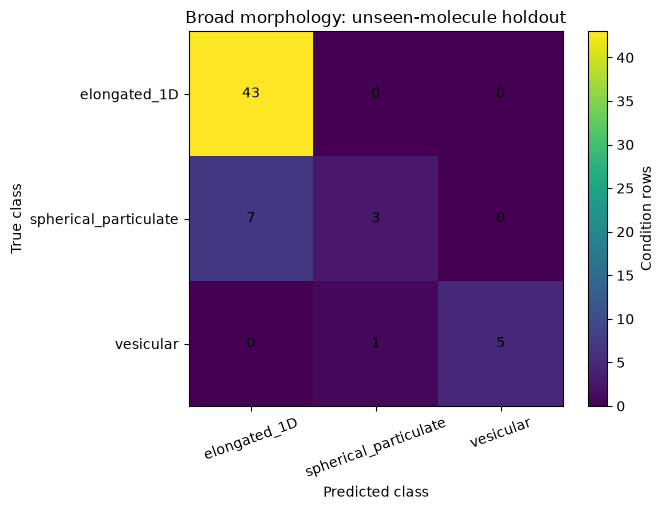

In [303]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.8, 5.2))
im = ax.imshow(morph3_test_confusion)

ax.set_xticks(range(len(morph3_classes)))
ax.set_yticks(range(len(morph3_classes)))
ax.set_xticklabels(morph3_classes, rotation=20)
ax.set_yticklabels(morph3_classes)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Broad morphology: unseen-molecule holdout")

for i in range(len(morph3_classes)):
    for j in range(len(morph3_classes)):
        ax.text(
            j,
            i,
            str(morph3_test_confusion[i, j]),
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Condition rows")
plt.tight_layout()


save_publication_figure(fig, "figure_7_morphology_confusion_matrix")

plt.show()

**Figure 7. Broad-morphology confusion matrix on the permanent unseen-molecule holdout.**
Elongated/1D morphology transfers strongly, whereas spherical/particulate conditions are
the main source of error and are frequently predicted as elongated/1D.

In [304]:
# ============================================================
# MORPHOLOGY HOLDOUT PREDICTION TABLE
# ============================================================

morph3_holdout_predictions = (
    morph3_test_data[
        [
            "molecular_identity_key",
            "sequence_curated",
            "publication_pmid",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "morphology_target"
        ]
    ]
    .copy()
)


morph3_holdout_predictions[
    "predicted_class"
] = morph3_test_prediction


for i, class_name in enumerate(
    morph3_classes
):

    morph3_holdout_predictions[
        f"prob_{class_name}"
    ] = morph3_test_probability[:, i]


morph3_holdout_predictions[
    "prediction_correct"
] = (
    morph3_holdout_predictions[
        "morphology_target"
    ]
    ==
    morph3_holdout_predictions[
        "predicted_class"
    ]
)


print("=" * 90)
print("MORPHOLOGY HOLDOUT PREDICTIONS")
print("=" * 90)

print(
    "Rows:",
    len(morph3_holdout_predictions)
)

print(
    "Correct:",
    morph3_holdout_predictions[
        "prediction_correct"
    ].sum()
)

print(
    "Incorrect:",
    (
        ~morph3_holdout_predictions[
            "prediction_correct"
        ]
    ).sum()
)

MORPHOLOGY HOLDOUT PREDICTIONS
Rows: 59
Correct: 51
Incorrect: 8


In [305]:
# ============================================================
# MORPHOLOGY MOLECULE-CLUSTER BOOTSTRAP
# ============================================================

rng = np.random.default_rng(8026)


unique_morph3_test_molecules = (
    morph3_holdout_predictions[
        "molecular_identity_key"
    ]
    .unique()
)


morph3_bootstrap_rows = []


for iteration in range(5000):

    sampled_molecules = rng.choice(
        unique_morph3_test_molecules,
        size=len(
            unique_morph3_test_molecules
        ),
        replace=True
    )


    sampled_parts = []


    for bootstrap_group, molecule in enumerate(
        sampled_molecules
    ):

        part = (
            morph3_holdout_predictions[
                morph3_holdout_predictions[
                    "molecular_identity_key"
                ] == molecule
            ]
            .copy()
        )


        part[
            "_bootstrap_group"
        ] = bootstrap_group


        sampled_parts.append(
            part
        )


    sample = pd.concat(
        sampled_parts,
        ignore_index=True
    )


    y_boot = (
        sample[
            "morphology_target"
        ]
    )


    pred_boot = (
        sample[
            "predicted_class"
        ]
    )


    # All three classes required for multiclass metrics
    if (
        set(y_boot.unique())
        != set(morph3_classes)
    ):
        continue


    probability_boot = (
        sample[
            [
                "prob_elongated_1D",
                "prob_spherical_particulate",
                "prob_vesicular"
            ]
        ]
        .to_numpy()
    )


    y_boot_binary = label_binarize(
        y_boot,
        classes=morph3_classes
    )


    morph3_bootstrap_rows.append(
        {
            "macro_roc_auc":
                roc_auc_score(
                    y_boot_binary,
                    probability_boot,
                    average="macro"
                ),

            "macro_pr_auc":
                average_precision_score(
                    y_boot_binary,
                    probability_boot,
                    average="macro"
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_boot,
                    pred_boot
                ),

            "macro_f1":
                f1_score(
                    y_boot,
                    pred_boot,
                    average="macro",
                    zero_division=0
                ),

            "mcc":
                matthews_corrcoef(
                    y_boot,
                    pred_boot
                )
        }
    )


morph3_bootstrap_results = pd.DataFrame(
    morph3_bootstrap_rows
)


morph3_point_estimates = {

    "macro_roc_auc":
        morph3_test_macro_roc_auc,

    "macro_pr_auc":
        morph3_test_macro_pr_auc,

    "balanced_accuracy":
        morph3_test_balanced_accuracy,

    "macro_f1":
        morph3_test_macro_f1,

    "mcc":
        morph3_test_mcc
}


morph3_bootstrap_ci = []


for metric, estimate in (
    morph3_point_estimates.items()
):

    morph3_bootstrap_ci.append(
        {
            "metric":
                metric,

            "estimate":
                estimate,

            "ci_lower_95":
                morph3_bootstrap_results[
                    metric
                ].quantile(0.025),

            "ci_upper_95":
                morph3_bootstrap_results[
                    metric
                ].quantile(0.975)
        }
    )


morph3_bootstrap_ci = pd.DataFrame(
    morph3_bootstrap_ci
)


print("=" * 90)
print("MORPHOLOGY MOLECULE-CLUSTER BOOTSTRAP")
print("=" * 90)

print(
    "Successful bootstrap samples:",
    len(
        morph3_bootstrap_results
    )
)


display(
    morph3_bootstrap_ci
    .round(3)
)

MORPHOLOGY MOLECULE-CLUSTER BOOTSTRAP
Successful bootstrap samples: 4360


,metric,estimate,ci_lower_95,ci_upper_95
0,macro_roc_auc,0.980,0.823,1.0
1,macro_pr_auc,0.925,0.588,1.0
2,balanced_accuracy,0.711,0.333,1.0
3,macro_f1,0.754,0.295,1.0
4,mcc,0.665,0.147,1.0


### Table 5 — Broad-morphology performance with molecule-cluster uncertainty

In [306]:
morph3_metric_display = {
    "macro_roc_auc": "Macro ROC-AUC",
    "macro_pr_auc": "Macro PR-AUC",
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
    "mcc": "MCC"
}

morph3_final_table = (
    morph3_bootstrap_ci
    .assign(
        metric=lambda d:
            d["metric"].map(morph3_metric_display)
    )
    [
        [
            "metric",
            "estimate",
            "ci_lower_95",
            "ci_upper_95"
        ]
    ]
)

display(morph3_final_table.round(3))

,metric,estimate,ci_lower_95,ci_upper_95
0,Macro ROC-AUC,0.980,0.823,1.0
1,Macro PR-AUC,0.925,0.588,1.0
2,Balanced accuracy,0.711,0.333,1.0
3,Macro F1,0.754,0.295,1.0
4,MCC,0.665,0.147,1.0


In [307]:
# ============================================================
# FINAL MORPHOLOGY HOLDOUT ERROR AUDIT
# ============================================================

morph3_errors = (
    morph3_holdout_predictions[
        ~morph3_holdout_predictions[
            "prediction_correct"
        ]
    ]
    .copy()
)


morph3_errors[
    "error_type"
] = (
    morph3_errors[
        "morphology_target"
    ]
    .astype(str)
    +
    "_to_"
    +
    morph3_errors[
        "predicted_class"
    ]
    .astype(str)
)


print("=" * 90)
print("FINAL MORPHOLOGY HOLDOUT ERRORS")
print("=" * 90)

print(
    "Total errors:",
    len(morph3_errors)
)

print(
    "Independent molecules among errors:",
    morph3_errors[
        "molecular_identity_key"
    ].nunique()
)


print("\nError types:")

display(
    morph3_errors[
        "error_type"
    ]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="n_records")
)

FINAL MORPHOLOGY HOLDOUT ERRORS
Total errors: 8
Independent molecules among errors: 3

Error types:


,error_type,n_records
0,spherical_particulate_to_elongated_1D,7
1,vesicular_to_spherical_particulate,1


In [308]:
# ============================================================
# MORPHOLOGY ERRORS BY MOLECULAR IDENTITY
# ============================================================

morph3_error_by_molecule = (
    morph3_errors
    .groupby(
        [
            "molecular_identity_key",
            "sequence_curated"
        ]
    )
    .agg(
        n_errors=(
            "error_type",
            "size"
        ),

        error_types=(
            "error_type",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        mean_true_class_probability=(
            "prediction_correct",
            lambda x: np.nan
        )
    )
    .reset_index()
    .drop(
        columns=[
            "mean_true_class_probability"
        ]
    )
    .sort_values(
        "n_errors",
        ascending=False
    )
)


print("=" * 90)
print("MORPHOLOGY ERROR CONCENTRATION BY MOLECULE")
print("=" * 90)

display(
    morph3_error_by_molecule
)

MORPHOLOGY ERROR CONCENTRATION BY MOLECULE


,molecular_identity_key,sequence_curated,n_errors,error_types,n_publications
0,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,6,"(spherical_particulate_to_elongated_1D,)",1
1,MF|linear_or_unspecified|free|free|delta-f|peptide|none,MF,1,"(vesicular_to_spherical_particulate,)",1
2,WW|cyclic|free|free|none|peptide|none,WW,1,"(spherical_particulate_to_elongated_1D,)",1


In [309]:
# ============================================================
# CONDITION-LEVEL MORPHOLOGY ERRORS
# ============================================================

display(
    morph3_errors[
        [
            "molecular_identity_key",
            "sequence_curated",
            "publication_pmid",
            "concentration(mg/ml)",
            "PH",
            "temperature",
            "solution",
            "aqueous_phase_fraction",
            "morphology_target",
            "predicted_class",
            "prob_elongated_1D",
            "prob_spherical_particulate",
            "prob_vesicular"
        ]
    ]
    .sort_values(
        [
            "morphology_target",
            "prob_spherical_particulate"
        ]
    )
    .round(3)
)

,molecular_identity_key,sequence_curated,publication_pmid,concentration(mg/ml),PH,temperature,solution,aqueous_phase_fraction,morphology_target,predicted_class,prob_elongated_1D,prob_spherical_particulate,prob_vesicular
10,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,25010703,33.000,7.0,25.0,H2O,1.0,spherical_particulate,elongated_1D,0.621,0.353,0.026
11,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,25010703,40.000,7.0,25.0,H2O,1.0,spherical_particulate,elongated_1D,0.621,0.353,0.026
9,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,25010703,26.000,7.0,25.0,H2O,1.0,spherical_particulate,elongated_1D,0.610,0.364,0.026
8,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,25010703,19.000,7.0,25.0,H2O,1.0,spherical_particulate,elongated_1D,0.605,0.368,0.026
6,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,25010703,5.000,7.0,25.0,H2O,1.0,spherical_particulate,elongated_1D,0.593,0.382,0.025
7,LLE|linear_or_unspecified|acetylation|free|none|peptide|none,LLE,25010703,12.000,7.0,25.0,H2O,1.0,spherical_particulate,elongated_1D,0.588,0.384,0.028
51,WW|cyclic|free|free|none|peptide|none,WW,30104564,1.855,7.0,70.0,Methanol,0.0,spherical_particulate,elongated_1D,0.498,0.464,0.038
24,MF|linear_or_unspecified|free|free|delta-f|peptide|none,MF,22915849,2.000,8.0,25.0,Methanol/H2O,0.5,vesicular,spherical_particulate,0.326,0.560,0.113


In [310]:
# ============================================================
# MORPHOLOGY HOLDOUT — PUBLICATION FAMILIARITY
# ============================================================

development_morphology_publications = set(
    morph3_train_data[
        "publication_pmid"
    ]
    .dropna()
)


morph3_holdout_predictions[
    "publication_familiarity"
] = np.where(
    morph3_holdout_predictions[
        "publication_pmid"
    ].isin(
        development_morphology_publications
    ),
    "publication_seen_in_development",
    "publication_unseen"
)


publication_familiarity_summary = (
    morph3_holdout_predictions
    .groupby(
        "publication_familiarity"
    )
    .agg(
        n_rows=(
            "morphology_target",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        accuracy=(
            "prediction_correct",
            "mean"
        )
    )
    .reset_index()
)


print("=" * 90)
print("MORPHOLOGY HOLDOUT — PUBLICATION FAMILIARITY")
print("=" * 90)

display(
    publication_familiarity_summary
    .round(3)
)

MORPHOLOGY HOLDOUT — PUBLICATION FAMILIARITY


,publication_familiarity,n_rows,n_molecules,n_publications,accuracy
0,publication_seen_in_development,20,10,8,0.6
1,publication_unseen,39,4,4,1.0


In [311]:
# ============================================================
# PUBLICATION FAMILIARITY × MORPHOLOGY CLASS
# ============================================================

display(
    pd.crosstab(
        morph3_holdout_predictions[
            "publication_familiarity"
        ],
        morph3_holdout_predictions[
            "morphology_target"
        ]
    )
)

morphology_target,elongated_1D,spherical_particulate,vesicular
publication_familiarity,,,
publication_seen_in_development,4,10,6
publication_unseen,39,0,0


In [312]:
# ============================================================
# FINE-GRAINED MORPHOLOGY — INDEPENDENT SUPPORT AUDIT
# ============================================================

fine_morphology_ml = (
    ml_master[
        ml_master[
            "morphology_curated"
        ].notna()
    ]
    .copy()
)


# ------------------------------------------------------------
# Attach publication provenance if needed
# ------------------------------------------------------------

if "publication_pmid" not in fine_morphology_ml.columns:

    if "pmid" in fine_morphology_ml.columns:

        fine_morphology_ml[
            "publication_pmid"
        ] = (
            fine_morphology_ml[
                "pmid"
            ]
        )

    else:

        fine_morphology_ml[
            "publication_pmid"
        ] = (
            fine_morphology_ml[
                "sapdb_id_original"
            ]
            .map(
                sapdb_publication_map
            )
        )


print("=" * 90)
print("FINE-GRAINED MORPHOLOGY DATASET CHECK")
print("=" * 90)

print(
    "Morphology rows:",
    len(fine_morphology_ml)
)

print(
    "Molecular identities:",
    fine_morphology_ml[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Publications:",
    fine_morphology_ml[
        "publication_pmid"
    ].nunique()
)

print(
    "Rows missing publication PMID:",
    fine_morphology_ml[
        "publication_pmid"
    ].isna().sum()
)


assert len(fine_morphology_ml) == 342

assert (
    fine_morphology_ml[
        "publication_pmid"
    ]
    .isna()
    .sum()
    == 0
)


fine_morphology_support = (
    fine_morphology_ml
    .groupby(
        "morphology_curated"
    )
    .agg(
        n_records=(
            "morphology_curated",
            "size"
        ),

        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        ),

        n_sequences=(
            "sequence_curated",
            "nunique"
        )
    )
    .reset_index()
)


fine_morphology_support[
    "percentage"
] = (
    fine_morphology_support[
        "n_records"
    ]
    / len(fine_morphology_ml)
    * 100
)


print("\n" + "=" * 90)
print("FINE-GRAINED MORPHOLOGY — INDEPENDENT SUPPORT")
print("=" * 90)

display(
    fine_morphology_support
    .sort_values(
        "n_records",
        ascending=False
    )
    .round(2)
)

FINE-GRAINED MORPHOLOGY DATASET CHECK
Morphology rows: 342
Molecular identities: 64
Publications: 47
Rows missing publication PMID: 0

FINE-GRAINED MORPHOLOGY — INDEPENDENT SUPPORT


,morphology_curated,n_records,n_molecules,n_publications,n_sequences,percentage
1,fiber,94,30,20,24,27.49
7,tube,86,10,17,8,25.15
8,vesicle,42,10,7,10,12.28
4,nanosphere,35,16,12,12,10.23
0,crystal,34,1,1,1,9.94
6,ribbon,33,6,5,6,9.65
5,particle,16,4,3,4,4.68
3,nanorod,1,1,1,1,0.29
2,micelle_like,1,1,1,1,0.29


> **Section takeaway:** transferable broad-morphology prediction is feasible, but
> independent support is uneven across classes. Spherical/particulate morphology is the
> principal weakness, and uncertainty remains wide because the permanent holdout contains
> only 14 independent molecular identities.

# Section 10 — Fine-grained morphology support and feasibility audit

**Purpose.** Audit the independent molecular and publication support behind fine
morphology labels and determine whether a leakage-safe fine-grained classifier is
scientifically defensible.

The modelling criterion is deliberately conservative: if stable grouped validation
cannot be constructed, the analysis stops rather than relaxing molecular independence.

### Figure S1 — Fine-grained morphology independent molecular support

This support audit explains why a fine-grained classifier was not forced when stable
molecularly independent cross-validation could not be constructed.

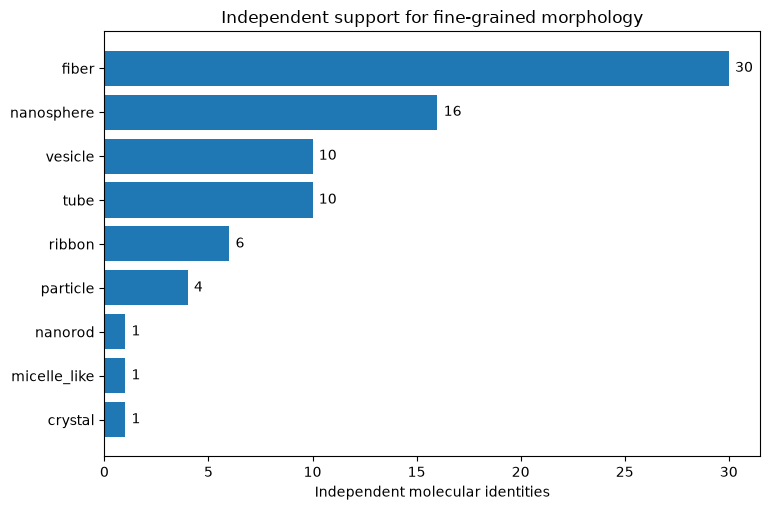

In [313]:
import matplotlib.pyplot as plt

fine_support_plot = (
    fine_morphology_support
    .sort_values("n_molecules", ascending=True)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
bars = ax.barh(
    fine_support_plot["morphology_curated"],
    fine_support_plot["n_molecules"]
)

ax.set_xlabel("Independent molecular identities")
ax.set_ylabel("")
ax.set_title("Independent support for fine-grained morphology")

for bar, value in zip(bars, fine_support_plot["n_molecules"]):
    ax.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(int(value)),
        va="center"
    )

plt.tight_layout()


save_publication_figure(fig, "figure_S1_fine_morphology_support")

plt.show()

**Figure S1. Independent support for fine-grained morphology classes.**
The figure shows why fine-grained prediction is treated as a support/feasibility problem:
apparently substantial row counts do not always correspond to enough independent
molecular systems for stable leakage-safe cross-validation.

In [314]:
# ============================================================
# FOUR-CLASS FINE-GRAINED MORPHOLOGY DATASET
# ============================================================

fine4_classes = [
    "fiber",
    "tube",
    "nanosphere",
    "vesicle"
]


fine4_ml = (
    fine_morphology_ml[
        fine_morphology_ml[
            "morphology_curated"
        ].isin(
            fine4_classes
        )
    ]
    .copy()
    .reset_index(drop=True)
)


fine4_ml[
    "fine_morphology_target"
] = (
    fine4_ml[
        "morphology_curated"
    ]
    .astype(str)
)


print("=" * 90)
print("FOUR-CLASS FINE-GRAINED MORPHOLOGY DATASET")
print("=" * 90)

print(
    "Rows:",
    len(fine4_ml)
)

print(
    "Molecular identities:",
    fine4_ml[
        "molecular_identity_key"
    ].nunique()
)

print(
    "Publications:",
    fine4_ml[
        "publication_pmid"
    ].nunique()
)


print("\nClass distribution:")

display(
    fine4_ml[
        "fine_morphology_target"
    ]
    .value_counts()
    .reindex(
        fine4_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_records")
)

FOUR-CLASS FINE-GRAINED MORPHOLOGY DATASET
Rows: 257
Molecular identities: 57
Publications: 42

Class distribution:


,morphology,n_records
0,fiber,94
1,tube,86
2,nanosphere,35
3,vesicle,42


In [315]:
# ============================================================
# FINE-GRAINED MORPHOLOGY SWITCHING
# ============================================================

fine4_molecule_structure = (
    fine4_ml
    .groupby(
        "molecular_identity_key"
    )
    .agg(
        sequence=(
            "sequence_curated",
            "first"
        ),

        n_records=(
            "fine_morphology_target",
            "size"
        ),

        n_morphologies=(
            "fine_morphology_target",
            "nunique"
        ),

        morphologies=(
            "fine_morphology_target",
            lambda x:
                tuple(
                    sorted(
                        set(x)
                    )
                )
        ),

        n_publications=(
            "publication_pmid",
            "nunique"
        )
    )
    .reset_index()
)


fine4_switchers = (
    fine4_molecule_structure[
        fine4_molecule_structure[
            "n_morphologies"
        ] > 1
    ]
    .sort_values(
        [
            "n_morphologies",
            "n_records"
        ],
        ascending=False
    )
)


print("=" * 90)
print("FINE-GRAINED MULTI-MORPHOLOGY MOLECULES")
print("=" * 90)

print(
    "Total molecular identities:",
    len(
        fine4_molecule_structure
    )
)

print(
    "Molecules represented in >1 fine morphology:",
    len(
        fine4_switchers
    )
)


display(
    fine4_switchers
)

FINE-GRAINED MULTI-MORPHOLOGY MOLECULES
Total molecular identities: 57
Molecules represented in >1 fine morphology: 6


,molecular_identity_key,sequence,n_records,n_morphologies,morphologies,n_publications
16,FF|linear_or_unspecified|boc|free|none|peptide|none,FF,49,3,"(fiber, nanosphere, tube)",2
19,FF|linear_or_unspecified|free|free|none|peptide|none,FF,24,3,"(fiber, tube, vesicle)",12
32,KFG|linear_or_unspecified|free|free|none|peptide|none,KFG,14,3,"(nanosphere, tube, vesicle)",2
8,FFH|linear_or_unspecified|ferrocene|free|none|peptide|none,FFH,12,2,"(fiber, vesicle)",1
0,EF|linear_or_unspecified|free|free|delta-f|peptide|none,EF,7,2,"(nanosphere, vesicle)",2
40,LL|linear_or_unspecified|free|free|none|peptide|none,LL,2,2,"(fiber, tube)",1


In [316]:
# ============================================================
# RECONSTRUCT 58-FEATURE LAYER FOR FINE MORPHOLOGY
# ============================================================

fine4_descriptor_matrix = pd.DataFrame(
    [
        peptide_descriptors(seq)
        for seq in fine4_ml[
            "sequence_curated"
        ]
    ],
    index=fine4_ml.index
)


for col in fine4_descriptor_matrix.columns:
    fine4_ml[col] = fine4_descriptor_matrix[col]


fine4_solvent_aliases = {

    "solvent_component_1":
        "component_1_standardized",

    "solvent_component_2":
        "component_2_standardized",

    "solvent_fraction_1":
        "component_1_ratio_fraction",

    "solvent_fraction_2":
        "component_2_ratio_fraction",

    "aqueous_fraction":
        "aqueous_phase_fraction",

    "has_second_solvent_component":
        "component_2_present"
}


for new_col, source_col in fine4_solvent_aliases.items():

    if (
        new_col not in fine4_ml.columns
        and source_col in fine4_ml.columns
    ):
        fine4_ml[new_col] = fine4_ml[source_col]


if "incubation_missing" not in fine4_ml.columns:

    fine4_ml[
        "incubation_missing"
    ] = (
        fine4_ml[
            "incubation period (min)"
        ]
        .isna()
        .astype(int)
    )


if "heating_cooling_binary" not in fine4_ml.columns:

    fine4_ml[
        "heating_cooling_binary"
    ] = (
        fine4_ml[
            "heating/cooling"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "yes": 1,
                "no": 0,
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0
            }
        )
    )


missing_fine4_features = [
    col
    for col in all_model_features
    if col not in fine4_ml.columns
]


print("=" * 90)
print("FINE MORPHOLOGY FEATURE RECONSTRUCTION")
print("=" * 90)

print(
    "Rows:",
    len(fine4_ml)
)

print(
    "Required features:",
    len(all_model_features)
)

print(
    "Missing features:",
    len(missing_fine4_features)
)


if missing_fine4_features:

    for col in missing_fine4_features:
        print(" -", col)

else:

    print(
        "\nAll required fine-morphology features are available."
    )

FINE MORPHOLOGY FEATURE RECONSTRUCTION
Rows: 257
Required features: 58
Missing features: 0

All required fine-morphology features are available.


In [317]:
# ============================================================
# FINE MORPHOLOGY MODELLING OBJECTS
# ============================================================

assert len(
    missing_fine4_features
) == 0


fine4_X = (
    fine4_ml[
        all_model_features
    ]
    .copy()
)


fine4_y = (
    fine4_ml[
        "fine_morphology_target"
    ]
    .copy()
)


fine4_groups = (
    fine4_ml[
        "molecular_identity_key"
    ]
    .copy()
)


print("=" * 90)
print("FOUR-CLASS FINE MORPHOLOGY MODELLING OBJECTS")
print("=" * 90)

print(
    "Feature matrix:",
    fine4_X.shape
)

print(
    "Target rows:",
    len(fine4_y)
)

print(
    "Molecular groups:",
    fine4_groups.nunique()
)


print("\nTarget distribution:")

display(
    fine4_y
    .value_counts()
    .reindex(
        fine4_classes
    )
    .rename_axis(
        "morphology"
    )
    .reset_index(
        name="n_records"
    )
)

FOUR-CLASS FINE MORPHOLOGY MODELLING OBJECTS
Feature matrix: (257, 58)
Target rows: 257
Molecular groups: 57

Target distribution:


,morphology,n_records
0,fiber,94
1,tube,86
2,nanosphere,35
3,vesicle,42


In [318]:
# ============================================================
# FINE MORPHOLOGY PERMANENT HOLDOUT SEARCH
# SPLIT GEOMETRY ONLY
# ============================================================

fine4_overall_fraction = (
    fine4_y
    .value_counts(normalize=True)
    .reindex(
        fine4_classes,
        fill_value=0
    )
)


fine4_split_candidates = []


for seed in range(2000):

    splitter = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )


    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(
            fine4_X,
            fine4_y,
            fine4_groups
        ),
        start=1
    ):

        train_candidate = (
            fine4_ml.iloc[
                train_idx
            ]
        )

        test_candidate = (
            fine4_ml.iloc[
                test_idx
            ]
        )


        y_train_candidate = (
            fine4_y.iloc[
                train_idx
            ]
        )

        y_test_candidate = (
            fine4_y.iloc[
                test_idx
            ]
        )


        groups_train_candidate = (
            fine4_groups.iloc[
                train_idx
            ]
        )

        groups_test_candidate = (
            fine4_groups.iloc[
                test_idx
            ]
        )


        # All four classes on both sides
        if (
            set(
                y_train_candidate.unique()
            )
            != set(fine4_classes)
        ):
            continue


        if (
            set(
                y_test_candidate.unique()
            )
            != set(fine4_classes)
        ):
            continue


        # Zero molecule leakage
        if len(
            set(groups_train_candidate)
            &
            set(groups_test_candidate)
        ) != 0:
            continue


        test_class_counts = (
            y_test_candidate
            .value_counts()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        test_class_fraction = (
            y_test_candidate
            .value_counts(normalize=True)
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        test_molecule_counts = (
            test_candidate
            .groupby(
                "fine_morphology_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        train_molecule_counts = (
            train_candidate
            .groupby(
                "fine_morphology_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        test_publication_counts = (
            test_candidate
            .groupby(
                "fine_morphology_target"
            )[
                "publication_pmid"
            ]
            .nunique()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        # ----------------------------------------------------
        # Rare-class safeguards
        # ----------------------------------------------------

        if (
            test_molecule_counts[
                "tube"
            ] < 2
        ):
            continue


        if (
            test_molecule_counts[
                "vesicle"
            ] < 2
        ):
            continue


        if (
            test_molecule_counts[
                "nanosphere"
            ] < 3
        ):
            continue


        if (
            train_molecule_counts[
                "tube"
            ] < 6
        ):
            continue


        if (
            train_molecule_counts[
                "vesicle"
            ] < 6
        ):
            continue


        # At least two publications for tube/vesicle test
        if (
            test_publication_counts[
                "tube"
            ] < 2
        ):
            continue


        if (
            test_publication_counts[
                "vesicle"
            ] < 2
        ):
            continue


        # ----------------------------------------------------
        # Geometry score
        # ----------------------------------------------------

        row_fraction = (
            len(test_idx)
            / len(fine4_y)
        )


        molecule_fraction = (
            groups_test_candidate.nunique()
            / fine4_groups.nunique()
        )


        row_deviation = abs(
            row_fraction - 0.20
        )


        molecule_deviation = abs(
            molecule_fraction - 0.20
        )


        prevalence_deviation = (
            test_class_fraction
            .sub(
                fine4_overall_fraction
            )
            .abs()
            .mean()
        )


        geometry_score = (
            row_deviation
            +
            molecule_deviation
            +
            prevalence_deviation
        )


        fine4_split_candidates.append(
            {
                "seed":
                    seed,

                "fold":
                    fold,

                "geometry_score":
                    geometry_score,

                "n_train_rows":
                    len(train_idx),

                "n_test_rows":
                    len(test_idx),

                "n_train_molecules":
                    groups_train_candidate.nunique(),

                "n_test_molecules":
                    groups_test_candidate.nunique(),

                "test_fiber_rows":
                    int(
                        test_class_counts[
                            "fiber"
                        ]
                    ),

                "test_tube_rows":
                    int(
                        test_class_counts[
                            "tube"
                        ]
                    ),

                "test_nanosphere_rows":
                    int(
                        test_class_counts[
                            "nanosphere"
                        ]
                    ),

                "test_vesicle_rows":
                    int(
                        test_class_counts[
                            "vesicle"
                        ]
                    ),

                "test_fiber_molecules":
                    int(
                        test_molecule_counts[
                            "fiber"
                        ]
                    ),

                "test_tube_molecules":
                    int(
                        test_molecule_counts[
                            "tube"
                        ]
                    ),

                "test_nanosphere_molecules":
                    int(
                        test_molecule_counts[
                            "nanosphere"
                        ]
                    ),

                "test_vesicle_molecules":
                    int(
                        test_molecule_counts[
                            "vesicle"
                        ]
                    ),

                "test_tube_publications":
                    int(
                        test_publication_counts[
                            "tube"
                        ]
                    ),

                "test_nanosphere_publications":
                    int(
                        test_publication_counts[
                            "nanosphere"
                        ]
                    ),

                "test_vesicle_publications":
                    int(
                        test_publication_counts[
                            "vesicle"
                        ]
                    )
            }
        )


fine4_split_candidates = pd.DataFrame(
    fine4_split_candidates
)


print("=" * 90)
print("FINE MORPHOLOGY PERMANENT HOLDOUT SEARCH")
print("=" * 90)

print(
    "Valid candidate holdouts:",
    len(
        fine4_split_candidates
    )
)


if len(
    fine4_split_candidates
) > 0:

    fine4_split_candidates = (
        fine4_split_candidates
        .sort_values(
            "geometry_score"
        )
        .reset_index(drop=True)
    )

    display(
        fine4_split_candidates
        .head(20)
        .round(4)
    )

else:

    print(
        "No candidate satisfied all support constraints."
    )

FINE MORPHOLOGY PERMANENT HOLDOUT SEARCH
Valid candidate holdouts: 2000


,seed,fold,geometry_score,n_train_rows,n_test_rows,n_train_molecules,n_test_molecules,test_fiber_rows,test_tube_rows,test_nanosphere_rows,test_vesicle_rows,test_fiber_molecules,test_tube_molecules,test_nanosphere_molecules,test_vesicle_molecules,test_tube_publications,test_nanosphere_publications,test_vesicle_publications
0,0,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3
1,1,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,4,3
2,2,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,3,3
3,3,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3
4,4,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3
5,5,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,4,3
6,6,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3
7,7,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3
8,8,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3
9,9,5,0.1799,217,40,41,16,16,9,7,8,6,2,5,3,2,5,3


In [319]:
# ============================================================
# FREEZE FINE-GRAINED MORPHOLOGY PERMANENT HOLDOUT
# ============================================================

fine4_holdout_seed = 3
fine4_holdout_fold = 5


fine4_holdout_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=fine4_holdout_seed
)


selected_fine4_split = None


for fold, (train_idx, test_idx) in enumerate(
    fine4_holdout_splitter.split(
        fine4_X,
        fine4_y,
        fine4_groups
    ),
    start=1
):

    if fold == fine4_holdout_fold:

        selected_fine4_split = (
            train_idx,
            test_idx
        )

        break


assert selected_fine4_split is not None


fine4_train_idx, fine4_test_idx = (
    selected_fine4_split
)


fine4_X_train = (
    fine4_X
    .iloc[fine4_train_idx]
    .reset_index(drop=True)
)

fine4_X_test = (
    fine4_X
    .iloc[fine4_test_idx]
    .reset_index(drop=True)
)


fine4_y_train = (
    fine4_y
    .iloc[fine4_train_idx]
    .reset_index(drop=True)
)

fine4_y_test = (
    fine4_y
    .iloc[fine4_test_idx]
    .reset_index(drop=True)
)


fine4_groups_train = (
    fine4_groups
    .iloc[fine4_train_idx]
    .reset_index(drop=True)
)

fine4_groups_test = (
    fine4_groups
    .iloc[fine4_test_idx]
    .reset_index(drop=True)
)


fine4_train_data = (
    fine4_ml
    .iloc[fine4_train_idx]
    .reset_index(drop=True)
    .copy()
)

fine4_test_data = (
    fine4_ml
    .iloc[fine4_test_idx]
    .reset_index(drop=True)
    .copy()
)


shared_fine4_molecules = (
    set(fine4_groups_train)
    &
    set(fine4_groups_test)
)


print("=" * 90)
print("PERMANENT FINE-MORPHOLOGY UNSEEN-MOLECULE HOLDOUT")
print("=" * 90)

print("Selected seed:", fine4_holdout_seed)
print("Selected fold:", fine4_holdout_fold)

print("\nDevelopment rows:", len(fine4_X_train))
print("Permanent holdout rows:", len(fine4_X_test))

print(
    "\nDevelopment molecules:",
    fine4_groups_train.nunique()
)

print(
    "Permanent holdout molecules:",
    fine4_groups_test.nunique()
)

print(
    "Shared molecular identities:",
    len(shared_fine4_molecules)
)


print("\nDevelopment class distribution:")

display(
    fine4_y_train
    .value_counts()
    .reindex(
        fine4_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_records")
)


print("\nPermanent holdout class distribution:")

display(
    fine4_y_test
    .value_counts()
    .reindex(
        fine4_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_records")
)


print("\nIndependent holdout molecules by class:")

display(
    fine4_test_data
    .groupby(
        "fine_morphology_target"
    )[
        "molecular_identity_key"
    ]
    .nunique()
    .reindex(
        fine4_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_molecules")
)


print("\nHoldout publications by class:")

display(
    fine4_test_data
    .groupby(
        "fine_morphology_target"
    )[
        "publication_pmid"
    ]
    .nunique()
    .reindex(
        fine4_classes
    )
    .rename_axis("morphology")
    .reset_index(name="n_publications")
)


assert len(shared_fine4_molecules) == 0

assert len(fine4_X_train) == 217
assert len(fine4_X_test) == 40

assert fine4_groups_train.nunique() == 41
assert fine4_groups_test.nunique() == 16


print(
    "\nFine-grained morphology permanent holdout successfully sealed."
)

PERMANENT FINE-MORPHOLOGY UNSEEN-MOLECULE HOLDOUT
Selected seed: 3
Selected fold: 5

Development rows: 217
Permanent holdout rows: 40

Development molecules: 41
Permanent holdout molecules: 16
Shared molecular identities: 0

Development class distribution:


,morphology,n_records
0,fiber,78
1,tube,77
2,nanosphere,28
3,vesicle,34



Permanent holdout class distribution:


,morphology,n_records
0,fiber,16
1,tube,9
2,nanosphere,7
3,vesicle,8



Independent holdout molecules by class:


,morphology,n_molecules
0,fiber,6
1,tube,2
2,nanosphere,5
3,vesicle,3



Holdout publications by class:


,morphology,n_publications
0,fiber,5
1,tube,2
2,nanosphere,5
3,vesicle,3



Fine-grained morphology permanent holdout successfully sealed.


In [320]:
# ============================================================
# FINE-MORPHOLOGY DEVELOPMENT SUPPORT AUDIT
# ============================================================

fine4_development_support = (
    fine4_train_data
    .groupby(
        "fine_morphology_target"
    )
    .agg(
        n_records=(
            "fine_morphology_target",
            "size"
        ),
        n_molecules=(
            "molecular_identity_key",
            "nunique"
        ),
        n_publications=(
            "publication_pmid",
            "nunique"
        )
    )
    .reindex(
        fine4_classes
    )
    .reset_index()
)


print("=" * 90)
print("FINE-MORPHOLOGY DEVELOPMENT SUPPORT")
print("=" * 90)

display(
    fine4_development_support
)

FINE-MORPHOLOGY DEVELOPMENT SUPPORT


,fine_morphology_target,n_records,n_molecules,n_publications
0,fiber,78,24,17
1,tube,77,8,16
2,nanosphere,28,11,9
3,vesicle,34,7,5


In [321]:
# ============================================================
# 3-FOLD FINE-MORPHOLOGY CV
# MOLECULAR-INDEPENDENCE SAFEGUARDS
# ============================================================

fine4_cv3_candidates = []


for seed in range(3000):

    candidate_cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=seed
    )

    fold_rows = []
    valid = True


    for fold, (tr_idx, val_idx) in enumerate(
        candidate_cv.split(
            fine4_X_train,
            fine4_y_train,
            fine4_groups_train
        ),
        start=1
    ):

        validation_fold = (
            fine4_train_data
            .iloc[val_idx]
        )

        y_tr = (
            fine4_y_train
            .iloc[tr_idx]
        )

        y_val = (
            fine4_y_train
            .iloc[val_idx]
        )

        groups_tr = (
            fine4_groups_train
            .iloc[tr_idx]
        )

        groups_val = (
            fine4_groups_train
            .iloc[val_idx]
        )


        # All four classes on both sides
        if set(y_tr.unique()) != set(fine4_classes):
            valid = False
            break

        if set(y_val.unique()) != set(fine4_classes):
            valid = False
            break


        # Absolutely zero molecule overlap
        if len(
            set(groups_tr)
            &
            set(groups_val)
        ) != 0:
            valid = False
            break


        val_class_counts = (
            y_val
            .value_counts()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        val_molecule_counts = (
            validation_fold
            .groupby(
                "fine_morphology_target"
            )[
                "molecular_identity_key"
            ]
            .nunique()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        val_publication_counts = (
            validation_fold
            .groupby(
                "fine_morphology_target"
            )[
                "publication_pmid"
            ]
            .nunique()
            .reindex(
                fine4_classes,
                fill_value=0
            )
        )


        # Hard molecular-support safeguards
        if val_molecule_counts["tube"] < 2:
            valid = False
            break

        if val_molecule_counts["nanosphere"] < 2:
            valid = False
            break

        if val_molecule_counts["vesicle"] < 2:
            valid = False
            break


        fold_rows.append(
            {
                "fold": fold,

                "n_train_rows":
                    len(tr_idx),

                "n_validation_rows":
                    len(val_idx),

                "n_train_molecules":
                    groups_tr.nunique(),

                "n_validation_molecules":
                    groups_val.nunique(),

                "fiber_rows":
                    int(
                        val_class_counts["fiber"]
                    ),

                "tube_rows":
                    int(
                        val_class_counts["tube"]
                    ),

                "nanosphere_rows":
                    int(
                        val_class_counts["nanosphere"]
                    ),

                "vesicle_rows":
                    int(
                        val_class_counts["vesicle"]
                    ),

                "fiber_molecules":
                    int(
                        val_molecule_counts["fiber"]
                    ),

                "tube_molecules":
                    int(
                        val_molecule_counts["tube"]
                    ),

                "nanosphere_molecules":
                    int(
                        val_molecule_counts["nanosphere"]
                    ),

                "vesicle_molecules":
                    int(
                        val_molecule_counts["vesicle"]
                    ),

                "tube_publications":
                    int(
                        val_publication_counts["tube"]
                    ),

                "nanosphere_publications":
                    int(
                        val_publication_counts["nanosphere"]
                    ),

                "vesicle_publications":
                    int(
                        val_publication_counts["vesicle"]
                    )
            }
        )


    if not valid:
        continue


    fold_df = pd.DataFrame(
        fold_rows
    )


    # Balance based mainly on independent support
    geometry_score = (
        fold_df[
            "n_validation_rows"
        ].std()
        / fold_df[
            "n_validation_rows"
        ].mean()

        +

        fold_df[
            "tube_rows"
        ].std()
        / fold_df[
            "tube_rows"
        ].mean()

        +

        fold_df[
            "nanosphere_rows"
        ].std()
        / fold_df[
            "nanosphere_rows"
        ].mean()

        +

        fold_df[
            "vesicle_rows"
        ].std()
        / fold_df[
            "vesicle_rows"
        ].mean()

        +

        fold_df[
            "tube_molecules"
        ].std()
        / fold_df[
            "tube_molecules"
        ].mean()

        +

        fold_df[
            "nanosphere_molecules"
        ].std()
        / fold_df[
            "nanosphere_molecules"
        ].mean()

        +

        fold_df[
            "vesicle_molecules"
        ].std()
        / fold_df[
            "vesicle_molecules"
        ].mean()
    )


    fine4_cv3_candidates.append(
        {
            "seed":
                seed,

            "geometry_score":
                geometry_score,

            "min_validation_rows":
                fold_df[
                    "n_validation_rows"
                ].min(),

            "max_validation_rows":
                fold_df[
                    "n_validation_rows"
                ].max(),

            "min_tube_rows":
                fold_df[
                    "tube_rows"
                ].min(),

            "max_tube_rows":
                fold_df[
                    "tube_rows"
                ].max(),

            "min_tube_molecules":
                fold_df[
                    "tube_molecules"
                ].min(),

            "max_tube_molecules":
                fold_df[
                    "tube_molecules"
                ].max(),

            "min_nanosphere_rows":
                fold_df[
                    "nanosphere_rows"
                ].min(),

            "max_nanosphere_rows":
                fold_df[
                    "nanosphere_rows"
                ].max(),

            "min_nanosphere_molecules":
                fold_df[
                    "nanosphere_molecules"
                ].min(),

            "max_nanosphere_molecules":
                fold_df[
                    "nanosphere_molecules"
                ].max(),

            "min_vesicle_rows":
                fold_df[
                    "vesicle_rows"
                ].min(),

            "max_vesicle_rows":
                fold_df[
                    "vesicle_rows"
                ].max(),

            "min_vesicle_molecules":
                fold_df[
                    "vesicle_molecules"
                ].min(),

            "max_vesicle_molecules":
                fold_df[
                    "vesicle_molecules"
                ].max(),

            "min_tube_publications":
                fold_df[
                    "tube_publications"
                ].min(),

            "min_nanosphere_publications":
                fold_df[
                    "nanosphere_publications"
                ].min(),

            "min_vesicle_publications":
                fold_df[
                    "vesicle_publications"
                ].min()
        }
    )


fine4_cv3_candidates = pd.DataFrame(
    fine4_cv3_candidates
)


print("=" * 90)
print("3-FOLD FINE-MORPHOLOGY DEVELOPMENT CV SEARCH")
print("=" * 90)

print(
    "Valid CV seeds:",
    len(fine4_cv3_candidates)
)


if len(fine4_cv3_candidates) > 0:

    fine4_cv3_candidates = (
        fine4_cv3_candidates
        .sort_values(
            [
                "geometry_score",
                "min_vesicle_publications",
                "min_tube_publications"
            ],
            ascending=[
                True,
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

    display(
        fine4_cv3_candidates
        .head(20)
        .round(4)
    )

else:

    print(
        "No valid 3-fold molecular-independent "
        "CV was found."
    )

3-FOLD FINE-MORPHOLOGY DEVELOPMENT CV SEARCH
Valid CV seeds: 0
No valid 3-fold molecular-independent CV was found.


### Fine-grained morphology modelling decision

The four-class fine-grained task was **not advanced to model fitting** because the
development data did not permit a stable 3-fold molecularly independent validation
geometry while retaining the prespecified minimum independent support for tube,
nanosphere, and vesicle classes. This is reported as a data-support limitation rather
than as a failed predictive model.

# Section 11 — Export of reproducibility artifacts

This section writes the curated datasets, result tables, model objects, specifications,
and figure files into a single `paper_outputs/` directory inside the repository.

## Artifact export

This final section writes reproducibility artifacts to `paper_outputs/`. It does not
participate in model selection or holdout evaluation.

In [322]:
from pathlib import Path
import pandas as pd
import json
import joblib

# Directories were created near the start of the notebook so that all
# publication figures could be saved during the same Run All.
for folder in [
    DATA_DIR,
    RESULTS_DIR,
    MODELS_DIR,
    FIGURES_DIR,
    TABLES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Reproducibility-artifact directories confirmed.")
print(PROJECT_OUTPUT)

Paper output directories created.


In [323]:
# ============================================================
# SAVE CORE CURATED DATASETS
# ============================================================

datasets_to_save = {
    "ml_master":
        "ml_master.csv",

    "morphology_master":
        "morphology_master.csv",

    "morph3_ml":
        "broad_morphology_dataset.csv",

    "fine_morphology_ml":
        "fine_morphology_dataset.csv",

    "fine4_ml":
        "fine4_candidate_dataset.csv"
}


for object_name, filename in datasets_to_save.items():

    if object_name in globals():

        globals()[object_name].to_csv(
            DATA_DIR / filename,
            index=False
        )

        print(
            f"Saved {object_name} -> {filename}"
        )

    else:

        print(
            f"Skipped {object_name}: not available"
        )

Saved ml_master -> ml_master.csv
Saved morphology_master -> morphology_master.csv
Saved morph3_ml -> broad_morphology_dataset.csv
Saved fine_morphology_ml -> fine_morphology_dataset.csv
Saved fine4_ml -> fine4_candidate_dataset.csv


In [324]:
# ============================================================
# SAVE MAJOR RESULT TABLES
# ============================================================

result_tables = {
    # Binary hydrogel task
    "primary_split_summary":
        "table_1_binary_split.csv",
    "final_test_results":
        "binary_holdout_metrics.csv",
    "bootstrap_ci":
        "table_2_binary_holdout_metrics_with_ci.csv",
    "binary_final_table":
        "table_2_binary_holdout_display_table.csv",
    "fully_aqueous_ablation":
        "table_3_fully_aqueous_ablation.csv",
    "concentration_response":
        "fully_aqueous_concentration_response.csv",

    # Three-class bulk-state task
    "bulk3_test_confusion_df":
        "bulk3_confusion_matrix.csv",
    "bulk3_bootstrap_ci":
        "table_4_bulk3_metrics_with_ci.csv",
    "bulk3_final_table":
        "table_4_bulk3_display_table.csv",

    # Broad morphology task
    "morph4_class_support":
        "broad_morphology_independent_support.csv",
    "morph3_test_confusion_df":
        "morph3_confusion_matrix.csv",
    "morph3_bootstrap_ci":
        "table_5_morph3_metrics_with_ci.csv",
    "morph3_final_table":
        "table_5_morph3_display_table.csv",

    # Fine morphology support / feasibility
    "fine_morphology_support":
        "fine_morphology_independent_support.csv",
    "fine4_development_support":
        "fine4_development_support.csv",

    # Model-comparison tables where available
    "morph3_model_comparison":
        "broad_morphology_initial_models.csv",
    "nested_morphology_comparison":
        "broad_morphology_nested_models.csv"
}

for object_name, filename in result_tables.items():
    if object_name in globals():
        globals()[object_name].to_csv(
            TABLES_DIR / filename,
            index=False
        )
        print(f"Saved {object_name} -> {filename}")
    else:
        print(f"Skipped {object_name}: not available")

Saved final_morph3_test_results -> broad_morphology_holdout_metrics.csv
Saved morph3_class_specific_test -> broad_morphology_class_metrics.csv
Saved morph3_test_confusion_df -> broad_morphology_confusion_matrix.csv
Saved morph3_bootstrap_ci -> broad_morphology_bootstrap_ci.csv
Saved morph3_model_comparison -> broad_morphology_initial_models.csv
Saved nested_morphology_comparison -> broad_morphology_nested_models.csv
Saved fine_morphology_support -> fine_morphology_independent_support.csv
Saved fine4_development_support -> fine4_development_support.csv


In [325]:
# ============================================================
# SAVE FINAL BROAD-MORPHOLOGY MODEL
# ============================================================

if "final_morph3_model" in globals():

    joblib.dump(
        final_morph3_model,
        MODELS_DIR /
        "final_broad_morphology_extra_trees.joblib"
    )

    print(
        "Final broad-morphology model saved."
    )

Final broad-morphology model saved.


In [326]:
if "final_morph3_specification" in globals():

    with open(
        RESULTS_DIR /
        "final_broad_morphology_specification.json",
        "w"
    ) as f:

        json.dump(
            final_morph3_specification,
            f,
            indent=4,
            default=str
        )

    print(
        "Final morphology specification saved."
    )

Final morphology specification saved.


In [327]:
print("=" * 80)
print("CHECKPOINT CONTENTS")
print("=" * 80)

for folder in [
    DATA_DIR,
    RESULTS_DIR,
    MODELS_DIR
]:

    print(f"\n{folder}:")

    for file in sorted(
        folder.iterdir()
    ):
        print(
            " -",
            file.name
        )

CHECKPOINT CONTENTS

paper_outputs\data:
 - broad_morphology_dataset.csv
 - fine4_candidate_dataset.csv
 - fine_morphology_dataset.csv
 - ml_master.csv
 - morphology_master.csv

paper_outputs\results:
 - broad_morphology_bootstrap_ci.csv
 - broad_morphology_class_metrics.csv
 - broad_morphology_confusion_matrix.csv
 - broad_morphology_holdout_metrics.csv
 - broad_morphology_initial_models.csv
 - broad_morphology_nested_models.csv
 - final_broad_morphology_specification.json
 - fine4_development_support.csv
 - fine_morphology_independent_support.csv

paper_outputs\models:
 - final_broad_morphology_extra_trees.joblib


# Section 12 — Final analysis summary and conclusions

The scientific analysis is frozen at this point. The remaining cells summarize the
three validated prediction tasks and state the conclusions, limitations, and recommended
future directions.

## Final analysis summary

The notebook now ends with all modelling decisions frozen. No further predictive model
development is required for this study unless a reproducibility error is discovered.

In [328]:
final_analysis_summary = pd.DataFrame([
    {
        "task": "Binary hydrogel vs non-gel",
        "development_rows": len(X_train),
        "development_molecules": groups_train.nunique(),
        "holdout_rows": len(X_test),
        "holdout_molecules": test_model_data["molecular_identity_key"].nunique(),
        "primary_metric": "ROC-AUC",
        "holdout_score": test_roc_auc
    },
    {
        "task": "Three-class bulk state",
        "development_rows": len(bulk3_X_train),
        "development_molecules": bulk3_groups_train.nunique(),
        "holdout_rows": len(bulk3_X_test),
        "holdout_molecules": bulk3_groups_test.nunique(),
        "primary_metric": "Macro ROC-AUC",
        "holdout_score": bulk3_test_macro_roc_auc
    },
    {
        "task": "Broad morphology",
        "development_rows": len(morph3_X_train),
        "development_molecules": morph3_groups_train.nunique(),
        "holdout_rows": len(morph3_X_test),
        "holdout_molecules": morph3_groups_test.nunique(),
        "primary_metric": "Macro ROC-AUC",
        "holdout_score": morph3_test_macro_roc_auc
    }
])

display(final_analysis_summary.round(3))

,task,development_rows,development_molecules,holdout_rows,holdout_molecules,primary_metric,holdout_score
0,Binary hydrogel vs non-gel,489,79,115,20,ROC-AUC,0.977
1,Three-class bulk state,515,80,129,20,Macro ROC-AUC,0.783
2,Broad morphology,249,50,59,14,Macro ROC-AUC,0.980


## Final conclusions

This study establishes a **condition-aware and leakage-aware framework for short-peptide
self-assembly prediction**. The central finding is that self-assembly should not be
treated as a fixed property of peptide sequence alone. Instead, the observed state is
better represented conceptually as:

$$
Y = f(\text{peptide chemistry},\ \text{experimental environment})
$$

### Main findings

1. **Scientific curation was essential.**  
   Bulk-state and morphology labels required solvent-aware, publication-aware, and
   provenance-aware reconstruction before they were suitable for machine learning.

2. **Random row splitting substantially exaggerates independence.**  
   Approximately **87.3% of test molecular identities** in the conventional random split
   had already appeared in training, and approximately **94.2% of test rows** came from
   molecular identities already represented in training.

3. **Binary hydrogel prediction transferred strongly to unseen molecules.**  
   The frozen Random Forest achieved **ROC-AUC 0.977**, **PR-AUC 0.882**,
   **balanced accuracy 0.945**, **F1 0.880**, and **MCC 0.836** on 115 conditions from
   20 completely unseen molecular identities.

4. **Experimental conditions contain transferable scientific information.**  
   Solvent composition was the dominant feature block, but fully aqueous analyses showed
   that concentration, pH, temperature, and other non-solvent conditions remain
   predictive even when solvent composition is fixed.

5. **Direct three-state bulk-state prediction is harder.**  
   For non-gel/hydrogel/organogel classification, the unseen-molecule holdout produced
   **macro ROC-AUC 0.783**, **macro PR-AUC 0.555**, **balanced accuracy 0.613**,
   **macro F1 0.497**, and **MCC 0.247**. The dominant error was non-gel being
   classified as organogel.

6. **Broad morphology prediction is feasible but class support is uneven.**  
   The final Extra Trees model achieved **macro ROC-AUC 0.980**, **macro PR-AUC 0.925**,
   **balanced accuracy 0.711**, **macro F1 0.754**, and **MCC 0.665** on 59 conditions
   from 14 unseen molecules. Spherical/particulate morphology remained the principal
   weakness.

7. **Row count is not equivalent to independent chemical sample size.**  
   Thirty-four crystalline observations originated from only one molecular identity and
   one publication. Likewise, the attempted four-class fine-morphology task was stopped
   because no stable three-fold molecularly independent CV could be constructed under the
   prespecified rare-class support requirements.

### Principal representation limitation

The current 58-feature representation captures composition, broad physicochemical
properties, molecular modifications, solvents, and experimental conditions, but it does
not fully encode **residue order, three-dimensional packing, or supramolecular interaction
geometry**. Analogue and composition-isomer failure cases therefore provide a clear
direction for future work using sequence-order-aware or structure-aware representations.

### What this paper does not claim

- The high holdout ROC-AUC values do not imply universal peptide generalization; the
  independent holdouts contain a limited number of molecular systems and the
  molecule-cluster confidence intervals must be reported.
- Perfect performance on unseen-publication morphology rows was observed only for
  elongated/1D examples, so universal unseen-publication morphology transfer is not
  claimed.
- Fine-grained morphology prediction is not presented as a failed classifier; it is
  presented as an **independent-support limitation**.

### Final status

**Model development is complete.** No additional predictive task should be added to
Paper 2 unless a reproducibility error is discovered. The next stages are repository
freeze, manuscript writing, and preparation of the preprint/supplementary materials.